In [ ]:
print("UFC Event Strenth Index")

UFC Event Strenth Index


In [1]:
import pickle

backup_path = "/content/UFC_EVENT_STRENGTH_PROJECT_BACKUP.pkl"

with open(backup_path, "rb") as f:
    project_backup = pickle.load(f)

ufc_fights = project_backup["ufc_fights"]
event_master = project_backup["event_master"]
normalized = project_backup["normalized"]
final_event_strength = project_backup["final_event_strength"]
fighter_topics = project_backup["fighter_topics"]
event_trends_results = project_backup["event_trends_results"]
FINAL_WEIGHTS = project_backup["final_weights"]

print("PROJECT RESTORED ✅🔥")
print("=" * 55)
print("UFC fights:", ufc_fights.shape)
print("Event master:", event_master.shape)
print("Normalized:", normalized.shape)
print("Final event strength:", final_event_strength.shape)
print("Fighter topics:", fighter_topics.shape)
print("Trends results:", event_trends_results.shape)
print()
print("Latest fight date:", ufc_fights["date"].max())

PROJECT RESTORED ✅🔥
UFC fights: (8736, 59)
Event master: (777, 39)
Normalized: (777, 34)
Final event strength: (777, 45)
Fighter topics: (2465, 3)
Trends results: (505, 17)

Latest fight date: 2026-06-27 00:00:00


In [ ]:
import pandas as pd

ufc_events = pd.DataFrame({
    "Event": ["UFC 300", "UFC 299", "UFC 298"],
    "Number_of_Fights": [13, 14, 12]
})

ufc_events

,Event,Number_of_Fights
0,UFC 300,13
1,UFC 299,14
2,UFC 298,12


In [ ]:
fight_data = pd.DataFrame(columns=[
    "Event",
    "Date",
    "Fight",
    "Fighter_1",
    "Fighter_2",
    "Card_Position",

    # Fight importance
    "Title_Fight",

    # Fighter quality
    "F1_Ranking",
    "F2_Ranking",
    "F1_UFC_Wins",
    "F1_UFC_Losses",
    "F2_UFC_Wins",
    "F2_UFC_Losses",
    "F1_Win_Streak",
    "F2_Win_Streak",
    "F1_UFC_Fights",
    "F2_UFC_Fights",
    "F1_Champion_Status",
    "F2_Champion_Status",

    # Accomplishments
    "F1_Previous_Title_Fights",
    "F2_Previous_Title_Fights",
    "F1_Previous_Main_Events",
    "F2_Previous_Main_Events",

    # Excitement history
    "F1_FOTN_Bonuses",
    "F2_FOTN_Bonuses",
    "F1_Other_Bonuses",
    "F2_Other_Bonuses",

    # Popularity
    "Social_Media_Engagement",

    # Matchup competitiveness
    "F1_Betting_Odds",
    "F2_Betting_Odds"
])

fight_data

,Event,Date,Fight,Fighter_1,Fighter_2,Card_Position,Title_Fight,F1_Ranking,F2_Ranking,F1_UFC_Wins,...,F2_Previous_Title_Fights,F1_Previous_Main_Events,F2_Previous_Main_Events,F1_FOTN_Bonuses,F2_FOTN_Bonuses,F1_Other_Bonuses,F2_Other_Bonuses,Social_Media_Engagement,F1_Betting_Odds,F2_Betting_Odds


In [ ]:
print("Number of columns:", len(fight_data.columns))

print("\nOur UFC Event Strength variables:")
for column in fight_data.columns:
    print(column)

Number of columns: 30

Our UFC Event Strength variables:
Event
Date
Fight
Fighter_1
Fighter_2
Card_Position
Title_Fight
F1_Ranking
F2_Ranking
F1_UFC_Wins
F1_UFC_Losses
F2_UFC_Wins
F2_UFC_Losses
F1_Win_Streak
F2_Win_Streak
F1_UFC_Fights
F2_UFC_Fights
F1_Champion_Status
F2_Champion_Status
F1_Previous_Title_Fights
F2_Previous_Title_Fights
F1_Previous_Main_Events
F2_Previous_Main_Events
F1_FOTN_Bonuses
F2_FOTN_Bonuses
F1_Other_Bonuses
F2_Other_Bonuses
Social_Media_Engagement
F1_Betting_Odds
F2_Betting_Odds


In [ ]:
ufc_fights = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-07-07/ufc_fights.csv"
)

print("Number of fights:", len(ufc_fights))
print("Number of columns:", len(ufc_fights.columns))

ufc_fights.head()

Number of fights: 8736
Number of columns: 15


,fight_url,event_name,date,location,f1_name,f1_result,f2_name,f2_result,weight_class,method,round,time,time_format,referee,judging_details
0,http://www.ufcstats.com/fight-details/c13dc0cc...,UFC Fight Night: Fiziev vs. Torres,2026-06-27,"Baku, Azerbaijan",Rafael Fiziev,W,Manuel Torres,L,Lightweight Bout,KO/TKO,2,15S,5 Rnd (5-5-5-5-5),Marc Goddard,Punches to Head On Ground
1,http://www.ufcstats.com/fight-details/012c307c...,UFC Fight Night: Fiziev vs. Torres,2026-06-27,"Baku, Azerbaijan",Shara Magomedov,W,Michel Pereira,L,Middleweight Bout,Decision - Unanimous,3,5M 0S,3 Rnd (5-5-5),Herb Dean,Ben Cartlidge 28 - 29. Anders Ohlsson 28 - 29....
2,http://www.ufcstats.com/fight-details/809814f0...,UFC Fight Night: Fiziev vs. Torres,2026-06-27,"Baku, Azerbaijan",Nazim Sadykhov,L,Matheus Camilo,W,Lightweight Bout,KO/TKO,1,1M 31S,3 Rnd (5-5-5),Rich Mitchell,Punch to Head At Distance
3,http://www.ufcstats.com/fight-details/81cde317...,UFC Fight Night: Fiziev vs. Torres,2026-06-27,"Baku, Azerbaijan",Asu Almabayev,W,Charles Johnson,L,Flyweight Bout,Submission,3,3M 33S,3 Rnd (5-5-5),Herb Dean,Suloev Stretch From Back Control
4,http://www.ufcstats.com/fight-details/d83294b0...,UFC Fight Night: Fiziev vs. Torres,2026-06-27,"Baku, Azerbaijan",Ikram Aliskerov,W,Brunno Ferreira,L,Middleweight Bout,Decision - Unanimous,3,5M 0S,3 Rnd (5-5-5),Marc Goddard,David Lethaby 27 - 30. Vito Paolillo 27 - 30. ...


In [ ]:
print("DATASET SIZE")
print("Fights:", len(ufc_fights))
print("Columns:", len(ufc_fights.columns))

print("\nALL COLUMNS:")
for i, column in enumerate(ufc_fights.columns, start=1):
    print(i, column)

DATASET SIZE
Fights: 8736
Columns: 15

ALL COLUMNS:
1 fight_url
2 event_name
3 date
4 location
5 f1_name
6 f1_result
7 f2_name
8 f2_result
9 weight_class
10 method
11 round
12 time
13 time_format
14 referee
15 judging_details


In [ ]:
print("LAST 5 COLUMNS:")
print(ufc_fights.columns[-5:].tolist())

print("\nDATE CHECK:")
print(ufc_fights["date"].head())

print("\nOLDEST AND NEWEST:")
print("Oldest:", ufc_fights["date"].min())
print("Newest:", ufc_fights["date"].max())

LAST 5 COLUMNS:
['round', 'time', 'time_format', 'referee', 'judging_details']

DATE CHECK:
0    2026-06-27
1    2026-06-27
2    2026-06-27
3    2026-06-27
4    2026-06-27
Name: date, dtype: object

OLDEST AND NEWEST:
Oldest: 1994-03-11
Newest: 2026-06-27


In [ ]:
# Convert the date column from text into real Python dates
ufc_fights["date"] = pd.to_datetime(ufc_fights["date"])

# Sort every UFC fight from oldest to newest
ufc_fights = ufc_fights.sort_values(
    by="date",
    ascending=True
).reset_index(drop=True)

print("Date type:", ufc_fights["date"].dtype)
print("Oldest fight date:", ufc_fights["date"].min())
print("Newest fight date:", ufc_fights["date"].max())

ufc_fights[["date", "event_name", "f1_name", "f2_name"]].head(10)

Date type: datetime64[ns]
Oldest fight date: 1994-03-11 00:00:00
Newest fight date: 2026-06-27 00:00:00


,date,event_name,f1_name,f2_name
0,1994-03-11,UFC 2: No Way Out,Scott Morris,Sean Daugherty
1,1994-03-11,UFC 2: No Way Out,Royce Gracie,Patrick Smith
2,1994-03-11,UFC 2: No Way Out,Royce Gracie,Remco Pardoel
3,1994-03-11,UFC 2: No Way Out,Patrick Smith,Johnny Rhodes
4,1994-03-11,UFC 2: No Way Out,Royce Gracie,Jason DeLucia
5,1994-03-11,UFC 2: No Way Out,Remco Pardoel,Orlando Wiet
6,1994-03-11,UFC 2: No Way Out,Johnny Rhodes,Fred Ettish
7,1994-03-11,UFC 2: No Way Out,Patrick Smith,Ray Wizard
8,1994-03-11,UFC 2: No Way Out,Royce Gracie,Minoki Ichihara
9,1994-03-11,UFC 2: No Way Out,Johnny Rhodes,David Levicki


In [ ]:
# Create dictionaries to keep track of every fighter's UFC record
fighter_wins = {}
fighter_losses = {}

# Lists that will store each fighter's record BEFORE each fight
f1_wins_before = []
f1_losses_before = []
f2_wins_before = []
f2_losses_before = []

# Go through UFC history one fight at a time
for _, fight in ufc_fights.iterrows():

    f1 = fight["f1_name"]
    f2 = fight["f2_name"]

    # Get each fighter's record BEFORE this fight
    f1_wins_before.append(fighter_wins.get(f1, 0))
    f1_losses_before.append(fighter_losses.get(f1, 0))

    f2_wins_before.append(fighter_wins.get(f2, 0))
    f2_losses_before.append(fighter_losses.get(f2, 0))

    # Update records AFTER the fight
    if fight["f1_result"] == "W":
        fighter_wins[f1] = fighter_wins.get(f1, 0) + 1
        fighter_losses[f2] = fighter_losses.get(f2, 0) + 1

    elif fight["f2_result"] == "W":
        fighter_wins[f2] = fighter_wins.get(f2, 0) + 1
        fighter_losses[f1] = fighter_losses.get(f1, 0) + 1


# Add our new statistics to the dataset
ufc_fights["f1_ufc_wins_before"] = f1_wins_before
ufc_fights["f1_ufc_losses_before"] = f1_losses_before
ufc_fights["f2_ufc_wins_before"] = f2_wins_before
ufc_fights["f2_ufc_losses_before"] = f2_losses_before

print("Historical UFC records created!")

Historical UFC records created!


In [ ]:
test_fighter = "Conor McGregor"

ufc_fights[
    (ufc_fights["f1_name"] == test_fighter) |
    (ufc_fights["f2_name"] == test_fighter)
][[
    "date",
    "event_name",
    "f1_name",
    "f1_ufc_wins_before",
    "f1_ufc_losses_before",
    "f2_name",
    "f2_ufc_wins_before",
    "f2_ufc_losses_before"
]]

,date,event_name,f1_name,f1_ufc_wins_before,f1_ufc_losses_before,f2_name,f2_ufc_wins_before,f2_ufc_losses_before
2227,2013-04-06,UFC on FUEL TV: Mousasi vs Latifi,Marcus Brimage,3,0,Conor McGregor,0,0
2356,2013-08-17,UFC Fight Night: Shogun vs Sonnen,Conor McGregor,1,0,Max Holloway,3,2
2799,2014-07-19,UFC Fight Night: McGregor vs Brandao,Conor McGregor,2,0,Diego Brandao,4,2
2894,2014-09-27,UFC 178: Johnson vs Cariaso,Dustin Poirier,8,2,Conor McGregor,3,0
3039,2015-01-18,UFC Fight Night: McGregor vs Siver,Conor McGregor,4,0,Dennis Siver,11,6
3265,2015-07-11,UFC 189: Mendes vs McGregor,Chad Mendes,8,2,Conor McGregor,5,0
3475,2015-12-12,UFC 194: Aldo vs McGregor,Jose Aldo,7,0,Conor McGregor,6,0
3576,2016-03-05,UFC 196: McGregor vs Diaz,Conor McGregor,7,0,Nate Diaz,13,8
3781,2016-08-20,UFC 202: Diaz vs. McGregor 2,Nate Diaz,14,8,Conor McGregor,7,1
3885,2016-11-12,UFC 205: Alvarez vs McGregor,Eddie Alvarez,3,1,Conor McGregor,8,1


In [ ]:
# Keep a safe copy of our historical dataset
historical_ufc = ufc_fights.copy()

print("Historical fights:", len(historical_ufc))
print("Historical data ends:", historical_ufc["date"].max())

Historical fights: 8736
Historical data ends: 2026-06-27 00:00:00


In [ ]:
import requests
from bs4 import BeautifulSoup

url = "http://ufcstats.com/statistics/events/completed?page=all"

response = requests.get(url)

print("Status code:", response.status_code)
print("Characters downloaded:", len(response.text))

if response.status_code == 200:
    print("SUCCESS — Colab can access UFCStats!")
else:
    print("UFCStats connection failed.")

Status code: 200
Characters downloaded: 2994
SUCCESS — Colab can access UFCStats!


In [ ]:
from datetime import datetime

soup = BeautifulSoup(response.text, "html.parser")

event_rows = soup.select("tr.b-statistics__table-row")

new_events = []

for row in event_rows:
    link = row.select_one("a.b-link")
    date_tag = row.select_one("span.b-statistics__date")

    if link and date_tag:
        event_name = link.get_text(strip=True)
        event_url = link.get("href")
        event_date = datetime.strptime(
            date_tag.get_text(strip=True),
            "%B %d, %Y"
        )

        if event_date > datetime(2026, 6, 27):
            new_events.append({
                "date": event_date,
                "event_name": event_name,
                "event_url": event_url
            })

new_events = pd.DataFrame(new_events)

if len(new_events) > 0:
    new_events = new_events.sort_values("date").reset_index(drop=True)

print("New completed events found:", len(new_events))

new_events

New completed events found: 0


""


In [ ]:
print("Page title:")
print(soup.title)

print("\nNumber of links found:")
print(len(soup.find_all("a")))

print("\nFirst 20 links:")
for link in soup.find_all("a")[:20]:
    print(link.get_text(strip=True), "->", link.get("href"))

Page title:
<title>Loading…</title>

Number of links found:
0

First 20 links:


In [ ]:
current_ufc = pd.read_csv(
    "https://raw.githubusercontent.com/Kairo-Angle/ufc/main/ufc_fight_results.csv"
)

print("Rows:", len(current_ufc))
print("Columns:", len(current_ufc.columns))

print("\nCOLUMN NAMES:")
print(current_ufc.columns.tolist())

print("\nLAST 5 ROWS:")
display(current_ufc.tail())

Rows: 8287
Columns: 11

COLUMN NAMES:
['EVENT', 'BOUT', 'OUTCOME', 'WEIGHTCLASS', 'METHOD', 'ROUND', 'TIME', 'TIME FORMAT', 'REFEREE', 'DETAILS', 'URL']

LAST 5 ROWS:


,EVENT,BOUT,OUTCOME,WEIGHTCLASS,METHOD,ROUND,TIME,TIME FORMAT,REFEREE,DETAILS,URL
8282,UFC 2: No Way Out,Orlando Wiet vs. Robert Lucarelli,W/L,Open Weight Bout,KO/TKO,1,2:50,No Time Limit,John McCarthy,toCorner Stoppage,http://ufcstats.com/fight-details/3b020d4914b4...
8283,UFC 2: No Way Out,Frank Hamaker vs. Thaddeus Luster,W/L,Open Weight Bout,Submission,1,4:52,No Time Limit,John McCarthy,Keylock From Half Guard,http://ufcstats.com/fight-details/d917c8c7461b...
8284,UFC 2: No Way Out,Johnny Rhodes vs. David Levicki,W/L,Open Weight Bout,KO/TKO,1,12:13,No Time Limit,John McCarthy,Punches to Head From GuardSubmission to Strikes,http://ufcstats.com/fight-details/ccee020be2e8...
8285,UFC 2: No Way Out,Patrick Smith vs. Ray Wizard,W/L,Open Weight Bout,Submission,1,0:58,No Time Limit,John McCarthy,Guillotine Choke Standing,http://ufcstats.com/fight-details/4b9ae533ccb3...
8286,UFC 2: No Way Out,Scott Morris vs. Sean Daugherty,W/L,Open Weight Bout,Submission,1,0:20,No Time Limit,John McCarthy,Guillotine Choke From Mount,http://ufcstats.com/fight-details/4acab67848e7...


In [ ]:
print("FIRST 10 ROWS:")
display(current_ufc.head(10))

print("\nCOLUMN NAMES:")
for i, column in enumerate(current_ufc.columns, start=1):
    print(i, column)

FIRST 10 ROWS:


,EVENT,BOUT,OUTCOME,WEIGHTCLASS,METHOD,ROUND,TIME,TIME FORMAT,REFEREE,DETAILS,URL
0,UFC Fight Night: Imavov vs. Borralho,Nassourdine Imavov vs. Caio Borralho,W/L,Middleweight Bout,Decision - Unanimous,5,5:00,5 Rnd (5-5-5-5-5),Marc Goddard,Derek Cleary 45 - 50.Ben Cartlidge 46 - 49.Dav...,http://ufcstats.com/fight-details/5bcd8abf6da0...
1,UFC Fight Night: Imavov vs. Borralho,Benoit Saint Denis vs. Mauricio Ruffy,W/L,Lightweight Bout,Submission,2,2:56,3 Rnd (5-5-5),Herb Dean,Rear Naked Choke,http://ufcstats.com/fight-details/d14fea437127...
2,UFC Fight Night: Imavov vs. Borralho,Modestas Bukauskas vs. Paul Craig,W/L,Light Heavyweight Bout,KO/TKO,1,5:00,3 Rnd (5-5-5),Marc Goddard,Elbow to Head From Guard,http://ufcstats.com/fight-details/0149e875b31e...
3,UFC Fight Night: Imavov vs. Borralho,Bolaji Oki vs. Mason Jones,L/W,Lightweight Bout,KO/TKO,2,3:18,3 Rnd (5-5-5),Rich Mitchell,Elbows to Head From Mount,http://ufcstats.com/fight-details/69b31593175f...
4,UFC Fight Night: Imavov vs. Borralho,Axel Sola vs. Rhys McKee,W/L,Welterweight Bout,KO/TKO,3,2:02,3 Rnd (5-5-5),Herb Dean,Punch to Body At Distance,http://ufcstats.com/fight-details/a47123ae6e04...
5,UFC Fight Night: Imavov vs. Borralho,William Gomis vs. Robert Ruchala,W/L,Featherweight Bout,Decision - Unanimous,3,5:00,3 Rnd (5-5-5),Lukasz Bosacki,Ben Cartlidge 27 - 30.Derek Cleary 28 - 29.Cle...,http://ufcstats.com/fight-details/b53031bf4bd0...
6,UFC Fight Night: Imavov vs. Borralho,Oumar Sy vs. Brendson Ribeiro,W/L,Light Heavyweight Bout,KO/TKO,1,4:42,3 Rnd (5-5-5),Patricio Carlos,Punches to Head From Back Control,http://ufcstats.com/fight-details/4080b4310d82...
7,UFC Fight Night: Imavov vs. Borralho,Marcin Tybura vs. Ante Delija,L/W,Heavyweight Bout,KO/TKO,1,2:03,3 Rnd (5-5-5),Marc Goddard,Punches to Head On Ground,http://ufcstats.com/fight-details/23dbe713c429...
8,UFC Fight Night: Imavov vs. Borralho,Harry Hardwick vs. Kaue Fernandes,L/W,Lightweight Bout,KO/TKO,1,3:21,3 Rnd (5-5-5),Herb Dean,Kick to Leg At Distance,http://ufcstats.com/fight-details/5cd2dd6075fa...
9,UFC Fight Night: Imavov vs. Borralho,Sam Patterson vs. Trey Waters,W/L,Welterweight Bout,KO/TKO,1,3:01,3 Rnd (5-5-5),Rich Mitchell,Punches to Head At Distance,http://ufcstats.com/fight-details/420211200a35...



COLUMN NAMES:
1 EVENT
2 BOUT
3 OUTCOME
4 WEIGHTCLASS
5 METHOD
6 ROUND
7 TIME
8 TIME FORMAT
9 REFEREE
10 DETAILS
11 URL


In [ ]:
ufc_fights = historical_ufc.copy()

ufc_fights = ufc_fights.sort_values(
    by="date",
    ascending=True
).reset_index(drop=True)

print("Ready to build the Event Strength Index!")
print("Historical fights:", len(ufc_fights))
print("From:", ufc_fights["date"].min())
print("Through:", ufc_fights["date"].max())

Ready to build the Event Strength Index!
Historical fights: 8736
From: 1994-03-11 00:00:00
Through: 2026-06-27 00:00:00


In [ ]:
# Track every fighter's UFC career
fighter_wins = {}
fighter_losses = {}
fighter_fights = {}

# Store stats BEFORE each fight
f1_wins_before = []
f1_losses_before = []
f1_fights_before = []

f2_wins_before = []
f2_losses_before = []
f2_fights_before = []

for _, fight in ufc_fights.iterrows():

    f1 = fight["f1_name"]
    f2 = fight["f2_name"]

    # Record stats BEFORE this fight
    f1_wins_before.append(fighter_wins.get(f1, 0))
    f1_losses_before.append(fighter_losses.get(f1, 0))
    f1_fights_before.append(fighter_fights.get(f1, 0))

    f2_wins_before.append(fighter_wins.get(f2, 0))
    f2_losses_before.append(fighter_losses.get(f2, 0))
    f2_fights_before.append(fighter_fights.get(f2, 0))

    # Count the fight as UFC experience
    fighter_fights[f1] = fighter_fights.get(f1, 0) + 1
    fighter_fights[f2] = fighter_fights.get(f2, 0) + 1

    # Update wins/losses AFTER the fight
    if fight["f1_result"] == "W":
        fighter_wins[f1] = fighter_wins.get(f1, 0) + 1
        fighter_losses[f2] = fighter_losses.get(f2, 0) + 1

    elif fight["f2_result"] == "W":
        fighter_wins[f2] = fighter_wins.get(f2, 0) + 1
        fighter_losses[f1] = fighter_losses.get(f1, 0) + 1


# Add everything to our dataset
ufc_fights["f1_ufc_wins_before"] = f1_wins_before
ufc_fights["f1_ufc_losses_before"] = f1_losses_before
ufc_fights["f1_ufc_fights_before"] = f1_fights_before

ufc_fights["f2_ufc_wins_before"] = f2_wins_before
ufc_fights["f2_ufc_losses_before"] = f2_losses_before
ufc_fights["f2_ufc_fights_before"] = f2_fights_before

print("UFC record and experience calculated!")

UFC record and experience calculated!


In [ ]:
test_fighter = "Jon Jones"

jones_test = ufc_fights[
    (ufc_fights["f1_name"] == test_fighter) |
    (ufc_fights["f2_name"] == test_fighter)
][[
    "date",
    "event_name",
    "f1_name",
    "f1_ufc_wins_before",
    "f1_ufc_losses_before",
    "f1_ufc_fights_before",
    "f2_name",
    "f2_ufc_wins_before",
    "f2_ufc_losses_before",
    "f2_ufc_fights_before"
]]

display(jones_test)

,date,event_name,f1_name,f1_ufc_wins_before,f1_ufc_losses_before,f1_ufc_fights_before,f2_name,f2_ufc_wins_before,f2_ufc_losses_before,f2_ufc_fights_before
943,2008-08-09,UFC 87: Seek And Destroy,Jon Jones,0,0,0,Andre Gusmao,0,0,0
1041,2009-01-31,UFC 94: St-Pierre vs Penn 2,Jon Jones,1,0,1,Stephan Bonnar,5,3,8
1138,2009-07-11,UFC 100,Jon Jones,2,0,2,Jake O'Brien,4,2,6
1231,2009-12-05,The Ultimate Fighter: Heavyweights Finale,Matt Hamill,6,2,8,Jon Jones,3,0,3
1293,2010-03-21,UFC Live: Vera vs Jones,Brandon Vera,7,4,11,Jon Jones,3,1,4
1389,2010-08-01,UFC Live: Jones vs Matyushenko,Jon Jones,4,1,5,Vladimir Matyushenko,5,2,7
1525,2011-02-05,UFC 126: Silva vs Belfort,Jon Jones,5,1,6,Ryan Bader,5,0,5
1559,2011-03-19,UFC 128: Shogun vs Jones,Mauricio Rua,3,2,5,Jon Jones,6,1,7
1700,2011-09-24,UFC 135: Jones vs Rampage,Jon Jones,7,1,8,Quinton Jackson,7,2,9
1781,2011-12-10,UFC 140: Jones vs Machida,Jon Jones,8,1,9,Lyoto Machida,9,2,11


In [ ]:
# Track each fighter's current UFC win streak
win_streaks = {}

# Store win streak BEFORE each fight
f1_streak_before = []
f2_streak_before = []

for _, fight in ufc_fights.iterrows():

    f1 = fight["f1_name"]
    f2 = fight["f2_name"]

    # Record streak BEFORE the fight
    f1_streak_before.append(win_streaks.get(f1, 0))
    f2_streak_before.append(win_streaks.get(f2, 0))

    # Update streaks AFTER the fight
    if fight["f1_result"] == "W":
        win_streaks[f1] = win_streaks.get(f1, 0) + 1
        win_streaks[f2] = 0

    elif fight["f2_result"] == "W":
        win_streaks[f2] = win_streaks.get(f2, 0) + 1
        win_streaks[f1] = 0

    # Draws / NCs do not add a win
    else:
        win_streaks[f1] = 0
        win_streaks[f2] = 0


# Add streaks to our dataset
ufc_fights["f1_win_streak_before"] = f1_streak_before
ufc_fights["f2_win_streak_before"] = f2_streak_before

print("Historical UFC win streaks calculated!")

Historical UFC win streaks calculated!


In [ ]:
test_fighter = "Charles Oliveira"

charles_test = ufc_fights[
    (ufc_fights["f1_name"] == test_fighter) |
    (ufc_fights["f2_name"] == test_fighter)
].copy()

charles_test["Charles_Win_Streak_Entering"] = charles_test.apply(
    lambda row:
        row["f1_win_streak_before"]
        if row["f1_name"] == test_fighter
        else row["f2_win_streak_before"],
    axis=1
)

display(
    charles_test[
        ["date", "event_name", "Charles_Win_Streak_Entering"]
    ]
)

,date,event_name,Charles_Win_Streak_Entering
1382,2010-08-01,UFC Live: Jones vs Matyushenko,0
1419,2010-09-15,UFC Fight Night: Marquardt vs Palhares,1
1493,2010-12-11,UFC 124: St-Pierre vs Koscheck 2,2
1624,2011-06-26,UFC Live: Kongo vs Barry,0
1661,2011-08-14,UFC Live: Hardy vs Lytle,0
1820,2012-01-28,UFC on FOX: Evans vs Davis,0
1933,2012-06-01,The Ultimate Fighter: Live Finale,1
2036,2012-09-22,UFC 152: Jones vs Belfort,2
2323,2013-07-06,UFC 162: Silva vs Weidman,0
2575,2014-02-15,UFC Fight Night: Machida vs Mousasi,0


In [ ]:
print("WEIGHT CLASS VALUES CONTAINING 'TITLE':")

title_values = ufc_fights[
    ufc_fights["weight_class"]
    .astype(str)
    .str.contains("Title", case=False, na=False)
]["weight_class"].value_counts()

print(title_values)

WEIGHT CLASS VALUES CONTAINING 'TITLE':
weight_class
UFC Light Heavyweight Title Bout                          56
UFC Welterweight Title Bout                               48
UFC Heavyweight Title Bout                                44
UFC Middleweight Title Bout                               39
UFC Lightweight Title Bout                                37
                                                          ..
Ultimate Fighter 33 Flyweight Tournament Title Bout        1
Ultimate Fighter 33 Welterweight Tournament Title Bout     1
Road to UFC 4 Featherweight Tournament Title Bout          1
Road to UFC 4 Lightweight Tournament Title Bout            1
Road to UFC 4 Bantamweight Tournament Title Bout           1
Name: count, Length: 107, dtype: int64


In [ ]:
# Identify REAL UFC championship fights
ufc_fights["is_title_fight"] = (
    ufc_fights["weight_class"]
    .astype(str)
    .str.startswith("UFC ")
    &
    ufc_fights["weight_class"]
    .astype(str)
    .str.contains("Title Bout", case=False, na=False)
)

print("Total UFC title fights found:")
print(ufc_fights["is_title_fight"].sum())

print("\nTypes of UFC title fights:")
print(
    ufc_fights.loc[
        ufc_fights["is_title_fight"],
        "weight_class"
    ].value_counts()
)

Total UFC title fights found:
403

Types of UFC title fights:
weight_class
UFC Light Heavyweight Title Bout             56
UFC Welterweight Title Bout                  48
UFC Heavyweight Title Bout                   44
UFC Middleweight Title Bout                  39
UFC Lightweight Title Bout                   37
UFC Flyweight Title Bout                     27
UFC Bantamweight Title Bout                  25
UFC Featherweight Title Bout                 22
UFC Women's Bantamweight Title Bout          20
UFC Women's Strawweight Title Bout           20
UFC Women's Flyweight Title Bout             14
UFC Interim Heavyweight Title Bout           10
UFC Women's Featherweight Title Bout          7
UFC Interim Lightweight Title Bout            4
UFC Interim Featherweight Title Bout          4
UFC Interim Bantamweight Title Bout           4
UFC Interim Welterweight Title Bout           3
UFC Interim Light Heavyweight Title Bout      2
UFC Interim Middleweight Title Bout           2
UFC 2 Tournam

In [ ]:
# Identify actual UFC divisional championship fights
# Exclude early UFC tournament championships

ufc_fights["is_title_fight"] = (
    ufc_fights["weight_class"]
    .astype(str)
    .str.startswith("UFC ")
    &
    ufc_fights["weight_class"]
    .astype(str)
    .str.contains("Title Bout", case=False, na=False)
    &
    ~ufc_fights["weight_class"]
    .astype(str)
    .str.contains("Tournament", case=False, na=False)
)

print("Total divisional UFC title fights:", ufc_fights["is_title_fight"].sum())

print("\nTitle fight types remaining:")
print(
    ufc_fights.loc[
        ufc_fights["is_title_fight"],
        "weight_class"
    ].value_counts()
)

Total divisional UFC title fights: 389

Title fight types remaining:
weight_class
UFC Light Heavyweight Title Bout            56
UFC Welterweight Title Bout                 48
UFC Heavyweight Title Bout                  44
UFC Middleweight Title Bout                 39
UFC Lightweight Title Bout                  37
UFC Flyweight Title Bout                    27
UFC Bantamweight Title Bout                 25
UFC Featherweight Title Bout                22
UFC Women's Strawweight Title Bout          20
UFC Women's Bantamweight Title Bout         20
UFC Women's Flyweight Title Bout            14
UFC Interim Heavyweight Title Bout          10
UFC Women's Featherweight Title Bout         7
UFC Interim Featherweight Title Bout         4
UFC Interim Bantamweight Title Bout          4
UFC Interim Lightweight Title Bout           4
UFC Interim Welterweight Title Bout          3
UFC Interim Light Heavyweight Title Bout     2
UFC Interim Middleweight Title Bout          2
UFC Interim Flyweight Tit

In [ ]:
# Track how many UFC title fights each fighter has had
previous_title_fights = {}

f1_title_fights_before = []
f2_title_fights_before = []

for _, fight in ufc_fights.iterrows():

    f1 = fight["f1_name"]
    f2 = fight["f2_name"]

    # Record totals BEFORE this fight
    f1_title_fights_before.append(
        previous_title_fights.get(f1, 0)
    )

    f2_title_fights_before.append(
        previous_title_fights.get(f2, 0)
    )

    # If THIS fight is a UFC title fight,
    # add it to both fighters' histories AFTER recording
    if fight["is_title_fight"]:

        previous_title_fights[f1] = (
            previous_title_fights.get(f1, 0) + 1
        )

        previous_title_fights[f2] = (
            previous_title_fights.get(f2, 0) + 1
        )


ufc_fights["f1_previous_title_fights"] = f1_title_fights_before
ufc_fights["f2_previous_title_fights"] = f2_title_fights_before

print("Previous UFC title fights calculated!")

Previous UFC title fights calculated!


In [ ]:
test_fighter = "Jon Jones"

jones_titles = ufc_fights[
    (ufc_fights["f1_name"] == test_fighter) |
    (ufc_fights["f2_name"] == test_fighter)
].copy()

jones_titles["Jones_Title_Fights_Entering"] = jones_titles.apply(
    lambda row:
        row["f1_previous_title_fights"]
        if row["f1_name"] == test_fighter
        else row["f2_previous_title_fights"],
    axis=1
)

display(
    jones_titles[
        [
            "date",
            "event_name",
            "is_title_fight",
            "Jones_Title_Fights_Entering"
        ]
    ]
)

,date,event_name,is_title_fight,Jones_Title_Fights_Entering
943,2008-08-09,UFC 87: Seek And Destroy,False,0
1041,2009-01-31,UFC 94: St-Pierre vs Penn 2,False,0
1138,2009-07-11,UFC 100,False,0
1231,2009-12-05,The Ultimate Fighter: Heavyweights Finale,False,0
1293,2010-03-21,UFC Live: Vera vs Jones,False,0
1389,2010-08-01,UFC Live: Jones vs Matyushenko,False,0
1525,2011-02-05,UFC 126: Silva vs Belfort,False,0
1559,2011-03-19,UFC 128: Shogun vs Jones,True,0
1700,2011-09-24,UFC 135: Jones vs Rampage,True,1
1781,2011-12-10,UFC 140: Jones vs Machida,True,2


In [ ]:
ufc300 = ufc_fights[
    ufc_fights["event_name"] == "UFC 300: Pereira vs. Hill"
][[
    "f1_name",
    "f2_name",
    "weight_class"
]]

display(ufc300)

,f1_name,f2_name,weight_class
7585,Sodiq Yusuff,Diego Lopes,Featherweight Bout
7586,King Green,Jim Miller,Lightweight Bout
7587,Jessica Andrade,Marina Rodriguez,Women's Strawweight Bout
7588,Deiveson Figueiredo,Cody Garbrandt,Bantamweight Bout
7589,Jalin Turner,Renato Moicano,Lightweight Bout
7590,Holly Holm,Kayla Harrison,Women's Bantamweight Bout
7591,Justin Gaethje,Max Holloway,Lightweight Bout
7592,Jiri Prochazka,Aleksandar Rakic,Light Heavyweight Bout
7593,Bo Nickal,Cody Brundage,Middleweight Bout
7594,Charles Oliveira,Arman Tsarukyan,Lightweight Bout


In [ ]:
# Mark the last fight listed at each event as the main event
ufc_fights["is_main_event"] = False

main_event_indices = (
    ufc_fights
    .groupby(["event_name", "date"], sort=False)
    .tail(1)
    .index
)

ufc_fights.loc[main_event_indices, "is_main_event"] = True

print("Main events identified:", ufc_fights["is_main_event"].sum())
print("Total events:", ufc_fights[["event_name", "date"]].drop_duplicates().shape[0])

Main events identified: 777
Total events: 777


In [ ]:
test_events = [
    "UFC 100",
    "UFC 205: Alvarez vs McGregor",
    "UFC 229: Khabib vs. McGregor",
    "UFC 300: Pereira vs. Hill"
]

main_event_test = ufc_fights[
    (ufc_fights["is_main_event"]) &
    (ufc_fights["event_name"].isin(test_events))
][[
    "date",
    "event_name",
    "f1_name",
    "f2_name"
]]

display(main_event_test)

,date,event_name,f1_name,f2_name
1145,2009-07-11,UFC 100,Georges St-Pierre,Thiago Alves
3895,2016-11-12,UFC 205: Alvarez vs McGregor,Vicente Luque,Belal Muhammad
4799,2018-10-06,UFC 229: Khabib vs. McGregor,Khabib Nurmagomedov,Conor McGregor
7597,2024-04-13,UFC 300: Pereira vs. Hill,Alex Pereira,Jamahal Hill


In [ ]:
check_events = ufc_fights[
    ufc_fights["event_name"].isin([
        "UFC 100",
        "UFC 205: Alvarez vs McGregor"
    ])
][[
    "date",
    "event_name",
    "f1_name",
    "f2_name",
    "weight_class"
]]

display(check_events)

,date,event_name,f1_name,f2_name,weight_class
1135,2009-07-11,UFC 100,Mark Coleman,Stephan Bonnar,Light Heavyweight Bout
1136,2009-07-11,UFC 100,Shannon Gugerty,Matt Grice,Lightweight Bout
1137,2009-07-11,UFC 100,Dong Hyun Kim,TJ Grant,Welterweight Bout
1138,2009-07-11,UFC 100,Jon Jones,Jake O'Brien,Light Heavyweight Bout
1139,2009-07-11,UFC 100,Jim Miller,Mac Danzig,Lightweight Bout
1140,2009-07-11,UFC 100,Tom Lawlor,CB Dollaway,Middleweight Bout
1141,2009-07-11,UFC 100,Yoshihiro Akiyama,Alan Belcher,Middleweight Bout
1142,2009-07-11,UFC 100,Brock Lesnar,Frank Mir,UFC Heavyweight Title Bout
1143,2009-07-11,UFC 100,Jon Fitch,Paulo Thiago,Welterweight Bout
1144,2009-07-11,UFC 100,Dan Henderson,Michael Bisping,Middleweight Bout


In [ ]:
# Get one row for every UFC event
events = (
    ufc_fights[["date", "event_name"]]
    .drop_duplicates()
    .sort_values("date")
    .reset_index(drop=True)
)

# Events whose names contain " vs "
events["has_vs_name"] = (
    events["event_name"]
    .str.contains(r"\s+vs\.?\s+", case=False, regex=True, na=False)
)

print("Total events:", len(events))
print("Events with 'vs' in the name:", events["has_vs_name"].sum())
print("Events WITHOUT 'vs' in the name:", (~events["has_vs_name"]).sum())

print("\nSome events WITHOUT 'vs' in the name:")
display(
    events.loc[
        ~events["has_vs_name"],
        ["date", "event_name"]
    ].tail(30)
)

Total events: 777
Events with 'vs' in the name: 670
Events WITHOUT 'vs' in the name: 107

Some events WITHOUT 'vs' in the name:


,date,event_name
98,2007-12-29,UFC 79: Nemesis
99,2008-01-19,UFC 80: Rapid Fire
101,2008-02-02,UFC 81: Breaking Point
102,2008-03-01,UFC 82: Pride of a Champion
105,2008-05-24,UFC 84: Ill Will
106,2008-06-07,UFC 85: Bedlam
110,2008-08-09,UFC 87: Seek And Destroy
111,2008-09-06,UFC 88: Breakthrough
116,2008-12-10,UFC Fight Night - Fight for the Troops
118,2008-12-27,UFC 92: The Ultimate 2008


In [ ]:
# Calculate UFC win percentage ENTERING each fight

ufc_fights["f1_ufc_win_pct_before"] = (
    ufc_fights["f1_ufc_wins_before"] /
    (
        ufc_fights["f1_ufc_wins_before"] +
        ufc_fights["f1_ufc_losses_before"]
    )
).fillna(0)

ufc_fights["f2_ufc_win_pct_before"] = (
    ufc_fights["f2_ufc_wins_before"] /
    (
        ufc_fights["f2_ufc_wins_before"] +
        ufc_fights["f2_ufc_losses_before"]
    )
).fillna(0)

print("UFC win percentages calculated!")

display(
    ufc_fights[
        [
            "f1_name",
            "f1_ufc_wins_before",
            "f1_ufc_losses_before",
            "f1_ufc_win_pct_before",
            "f2_name",
            "f2_ufc_wins_before",
            "f2_ufc_losses_before",
            "f2_ufc_win_pct_before"
        ]
    ].tail(10)
)

UFC win percentages calculated!


,f1_name,f1_ufc_wins_before,f1_ufc_losses_before,f1_ufc_win_pct_before,f2_name,f2_ufc_wins_before,f2_ufc_losses_before,f2_ufc_win_pct_before
8726,Kaan Ofli,2,2,0.500000,Javier Reyes,1,0,1.000000
8727,Abdul Rakhman Yakhyaev,2,0,1.000000,Julius Walker,1,2,0.333333
8728,Ikram Aliskerov,4,1,0.800000,Brunno Ferreira,6,3,0.666667
8729,Abus Magomedov,4,3,0.571429,Michal Oleksiejczuk,10,7,0.588235
8730,Asu Almabayev,6,1,0.857143,Charles Johnson,8,6,0.571429
8731,Nazim Sadykhov,4,1,0.800000,Matheus Camilo,1,1,0.500000
8732,Shara Magomedov,5,1,0.833333,Michel Pereira,10,5,0.666667
8733,Farman Hasanov,0,0,0.000000,Eric Nolan,0,1,0.000000
8734,Nursulton Ruziboev,4,1,0.800000,Andrey Pulyaev,1,2,0.333333
8735,Rafael Fiziev,7,5,0.583333,Manuel Torres,5,1,0.833333


In [ ]:
# Track each fighter's recent UFC results
recent_results = {}

f1_last5_win_pct = []
f2_last5_win_pct = []

for _, fight in ufc_fights.iterrows():

    f1 = fight["f1_name"]
    f2 = fight["f2_name"]

    # Get previous results
    f1_history = recent_results.get(f1, [])
    f2_history = recent_results.get(f2, [])

    # Last 5 UFC fights BEFORE this fight
    f1_last5 = f1_history[-5:]
    f2_last5 = f2_history[-5:]

    # Calculate win percentage
    f1_pct = (
        sum(f1_last5) / len(f1_last5)
        if len(f1_last5) > 0 else 0
    )

    f2_pct = (
        sum(f2_last5) / len(f2_last5)
        if len(f2_last5) > 0 else 0
    )

    f1_last5_win_pct.append(f1_pct)
    f2_last5_win_pct.append(f2_pct)

    # Update histories AFTER the fight
    if fight["f1_result"] == "W":
        recent_results.setdefault(f1, []).append(1)
        recent_results.setdefault(f2, []).append(0)

    elif fight["f2_result"] == "W":
        recent_results.setdefault(f1, []).append(0)
        recent_results.setdefault(f2, []).append(1)

    else:
        # Draw / NC = neither fighter gets a win
        recent_results.setdefault(f1, []).append(0)
        recent_results.setdefault(f2, []).append(0)


ufc_fights["f1_last5_win_pct"] = f1_last5_win_pct
ufc_fights["f2_last5_win_pct"] = f2_last5_win_pct

print("Recent 5-fight form calculated!")

Recent 5-fight form calculated!


In [ ]:
test_fighter = "Charles Oliveira"

recent_form_test = ufc_fights[
    (ufc_fights["f1_name"] == test_fighter) |
    (ufc_fights["f2_name"] == test_fighter)
].copy()

recent_form_test["Charles_Last5_Win_Pct"] = recent_form_test.apply(
    lambda row:
        row["f1_last5_win_pct"]
        if row["f1_name"] == test_fighter
        else row["f2_last5_win_pct"],
    axis=1
)

display(
    recent_form_test[
        ["date", "event_name", "Charles_Last5_Win_Pct"]
    ].tail(15)
)

,date,event_name,Charles_Last5_Win_Pct
4945,2019-02-02,UFC Fight Night: Assuncao vs. Moraes 2,0.8
5117,2019-05-18,UFC Fight Night: Dos Anjos vs. Lee,0.8
5401,2019-11-16,UFC Fight Night: Blachowicz vs. Jacare,1.0
5528,2020-03-14,UFC Fight Night: Lee vs. Oliveira,1.0
5882,2020-12-12,UFC 256: Figueiredo vs. Moreno,1.0
6085,2021-05-15,UFC 262: Oliveira vs. Chandler,1.0
6388,2021-12-11,UFC 269: Oliveira vs. Poirier,1.0
6581,2022-05-07,UFC 274: Oliveira vs. Gaethje,1.0
6827,2022-10-22,UFC 280: Oliveira vs. Makhachev,1.0
7142,2023-06-10,UFC 289: Nunes vs. Aldana,0.8


In [ ]:
# Track wins and finishes BEFORE each fight
career_wins = {}
career_finishes = {}

f1_finish_rate_before = []
f2_finish_rate_before = []

for _, fight in ufc_fights.iterrows():

    f1 = fight["f1_name"]
    f2 = fight["f2_name"]

    # Current stats BEFORE this fight
    f1_wins = career_wins.get(f1, 0)
    f2_wins = career_wins.get(f2, 0)

    f1_finishes = career_finishes.get(f1, 0)
    f2_finishes = career_finishes.get(f2, 0)

    # Finish rate among UFC wins
    f1_rate = f1_finishes / f1_wins if f1_wins > 0 else 0
    f2_rate = f2_finishes / f2_wins if f2_wins > 0 else 0

    f1_finish_rate_before.append(f1_rate)
    f2_finish_rate_before.append(f2_rate)

    # Determine whether THIS fight ended by finish
    method = str(fight["method"]).upper()

    is_finish = (
        "KO" in method
        or "TKO" in method
        or "SUBMISSION" in method
    )

    # Update records AFTER the fight
    if fight["f1_result"] == "W":

        career_wins[f1] = career_wins.get(f1, 0) + 1

        if is_finish:
            career_finishes[f1] = career_finishes.get(f1, 0) + 1

    elif fight["f2_result"] == "W":

        career_wins[f2] = career_wins.get(f2, 0) + 1

        if is_finish:
            career_finishes[f2] = career_finishes.get(f2, 0) + 1


ufc_fights["f1_finish_rate_before"] = f1_finish_rate_before
ufc_fights["f2_finish_rate_before"] = f2_finish_rate_before

print("Historical UFC finish rates calculated!")

Historical UFC finish rates calculated!


In [ ]:
test_fighter = "Charles Oliveira"

finish_test = ufc_fights[
    (ufc_fights["f1_name"] == test_fighter) |
    (ufc_fights["f2_name"] == test_fighter)
].copy()

finish_test["Charles_Finish_Rate_Entering"] = finish_test.apply(
    lambda row:
        row["f1_finish_rate_before"]
        if row["f1_name"] == test_fighter
        else row["f2_finish_rate_before"],
    axis=1
)

display(
    finish_test[
        [
            "date",
            "event_name",
            "Charles_Finish_Rate_Entering"
        ]
    ].tail(15)
)

,date,event_name,Charles_Finish_Rate_Entering
4945,2019-02-02,UFC Fight Night: Assuncao vs. Moraes 2,0.923077
5117,2019-05-18,UFC Fight Night: Dos Anjos vs. Lee,0.928571
5401,2019-11-16,UFC Fight Night: Blachowicz vs. Jacare,0.933333
5528,2020-03-14,UFC Fight Night: Lee vs. Oliveira,0.937500
5882,2020-12-12,UFC 256: Figueiredo vs. Moreno,0.941176
6085,2021-05-15,UFC 262: Oliveira vs. Chandler,0.888889
6388,2021-12-11,UFC 269: Oliveira vs. Poirier,0.894737
6581,2022-05-07,UFC 274: Oliveira vs. Gaethje,0.900000
6827,2022-10-22,UFC 280: Oliveira vs. Makhachev,0.904762
7142,2023-06-10,UFC 289: Nunes vs. Aldana,0.904762


In [ ]:
print("Searching dataset for bonus-related columns...\n")

bonus_words = [
    "bonus",
    "performance",
    "fight_of_the_night",
    "fotn",
    "potn"
]

found = []

for column in ufc_fights.columns:
    if any(word in column.lower() for word in bonus_words):
        found.append(column)

if found:
    print("Possible bonus columns found:")
    for column in found:
        print("-", column)
else:
    print("No bonus columns found in current dataset.")

print("\nTotal columns in dataset:", len(ufc_fights.columns))

Searching dataset for bonus-related columns...

No bonus columns found in current dataset.

Total columns in dataset: 33


In [ ]:
# Track total UFC finishes BEFORE each fight

fighter_finishes = {}

f1_finishes_before = []
f2_finishes_before = []

for _, fight in ufc_fights.iterrows():

    f1 = fight["f1_name"]
    f2 = fight["f2_name"]

    # Record finish totals BEFORE this fight
    f1_finishes_before.append(
        fighter_finishes.get(f1, 0)
    )

    f2_finishes_before.append(
        fighter_finishes.get(f2, 0)
    )

    # Determine whether THIS fight was a finish
    method = str(fight["method"]).upper()

    is_finish = (
        "KO" in method
        or "TKO" in method
        or "SUBMISSION" in method
    )

    # Update AFTER the fight
    if fight["f1_result"] == "W" and is_finish:
        fighter_finishes[f1] = fighter_finishes.get(f1, 0) + 1

    elif fight["f2_result"] == "W" and is_finish:
        fighter_finishes[f2] = fighter_finishes.get(f2, 0) + 1


ufc_fights["f1_ufc_finishes_before"] = f1_finishes_before
ufc_fights["f2_ufc_finishes_before"] = f2_finishes_before

print("Previous UFC finishes calculated!")

Previous UFC finishes calculated!


In [ ]:
strength_variables = [
    # Fight information
    "event_name",
    "date",
    "f1_name",
    "f2_name",
    "weight_class",

    # Fight importance
    "is_title_fight",

    # Fighter 1
    "f1_ufc_wins_before",
    "f1_ufc_losses_before",
    "f1_ufc_fights_before",
    "f1_ufc_win_pct_before",
    "f1_win_streak_before",
    "f1_last5_win_pct",
    "f1_previous_title_fights",
    "f1_ufc_finishes_before",
    "f1_finish_rate_before",

    # Fighter 2
    "f2_ufc_wins_before",
    "f2_ufc_losses_before",
    "f2_ufc_fights_before",
    "f2_ufc_win_pct_before",
    "f2_win_streak_before",
    "f2_last5_win_pct",
    "f2_previous_title_fights",
    "f2_ufc_finishes_before",
    "f2_finish_rate_before"
]

print("EVENT STRENGTH VARIABLES BUILT:", len(strength_variables))

for i, variable in enumerate(strength_variables, start=1):
    print(i, variable)

print("\nMissing columns:")
print([x for x in strength_variables if x not in ufc_fights.columns])

EVENT STRENGTH VARIABLES BUILT: 24
1 event_name
2 date
3 f1_name
4 f2_name
5 weight_class
6 is_title_fight
7 f1_ufc_wins_before
8 f1_ufc_losses_before
9 f1_ufc_fights_before
10 f1_ufc_win_pct_before
11 f1_win_streak_before
12 f1_last5_win_pct
13 f1_previous_title_fights
14 f1_ufc_finishes_before
15 f1_finish_rate_before
16 f2_ufc_wins_before
17 f2_ufc_losses_before
18 f2_ufc_fights_before
19 f2_ufc_win_pct_before
20 f2_win_streak_before
21 f2_last5_win_pct
22 f2_previous_title_fights
23 f2_ufc_finishes_before
24 f2_finish_rate_before

Missing columns:
[]


In [ ]:
rankings = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-07-07/ufc_rankings_dataset.csv"
)

rankings["date"] = pd.to_datetime(rankings["date"])

print("Historical rankings loaded!")
print("Ranking rows:", len(rankings))
print("First ranking date:", rankings["date"].min())
print("Last ranking date:", rankings["date"].max())

print("\nColumns:")
print(rankings.columns.tolist())

display(rankings.head(10))

Historical rankings loaded!
Ranking rows: 100477
First ranking date: 2013-02-04 00:00:00
Last ranking date: 2026-06-16 00:00:00

Columns:
['date', 'weightclass', 'fighter', 'rank']


,date,weightclass,fighter,rank
0,2013-02-04,Pound-for-Pound,Anderson Silva,1
1,2013-02-04,Pound-for-Pound,Jon Jones,2
2,2013-02-04,Pound-for-Pound,Georges St-Pierre,3
3,2013-02-04,Pound-for-Pound,Jose Aldo,4
4,2013-02-04,Pound-for-Pound,Benson Henderson,5
5,2013-02-04,Pound-for-Pound,Cain Velasquez,6
6,2013-02-04,Pound-for-Pound,Dominick Cruz,7
7,2013-02-04,Pound-for-Pound,Demetrious Johnson,8
8,2013-02-04,Pound-for-Pound,Frankie Edgar,9
9,2013-02-04,Pound-for-Pound,Dan Henderson,10


In [ ]:
print("Columns in rankings dataset:")
print(rankings.columns.tolist())

print("\nFirst 10 rows:")
display(rankings.head(10))

Columns in rankings dataset:
['date', 'weightclass', 'fighter', 'rank']

First 10 rows:


,date,weightclass,fighter,rank
0,2013-02-04,Pound-for-Pound,Anderson Silva,1
1,2013-02-04,Pound-for-Pound,Jon Jones,2
2,2013-02-04,Pound-for-Pound,Georges St-Pierre,3
3,2013-02-04,Pound-for-Pound,Jose Aldo,4
4,2013-02-04,Pound-for-Pound,Benson Henderson,5
5,2013-02-04,Pound-for-Pound,Cain Velasquez,6
6,2013-02-04,Pound-for-Pound,Dominick Cruz,7
7,2013-02-04,Pound-for-Pound,Demetrious Johnson,8
8,2013-02-04,Pound-for-Pound,Frankie Edgar,9
9,2013-02-04,Pound-for-Pound,Dan Henderson,10


In [ ]:
print("Date range:")
print(rankings["date"].min(), "to", rankings["date"].max())

print("\nUnique divisions:")
print(rankings["weightclass"].unique())

print("\nRank values:")
print(sorted(rankings["rank"].dropna().unique()))

print("\nFirst 30 rows from the earliest ranking date:")
display(
    rankings[
        rankings["date"] == rankings["date"].min()
    ].head(30)
)

Date range:
2013-02-04 00:00:00 to 2026-06-16 00:00:00

Unique divisions:
['Pound-for-Pound' 'Flyweight' 'Bantamweight' 'Featherweight'
 'Lightweight' 'Welterweight' 'Middleweight' 'Light Heavyweight'
 'Heavyweight' "Women's Bantamweight" "Women's Strawweight"
 "Women's Featherweight" "Women's Flyweight" "Men's Pound-for-Pound"
 "Women's Pound-for-Pound"]

Rank values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]

First 30 rows from the earliest ranking date:


,date,weightclass,fighter,rank
0,2013-02-04,Pound-for-Pound,Anderson Silva,1
1,2013-02-04,Pound-for-Pound,Jon Jones,2
2,2013-02-04,Pound-for-Pound,Georges St-Pierre,3
3,2013-02-04,Pound-for-Pound,Jose Aldo,4
4,2013-02-04,Pound-for-Pound,Benson Henderson,5
5,2013-02-04,Pound-for-Pound,Cain Velasquez,6
6,2013-02-04,Pound-for-Pound,Dominick Cruz,7
7,2013-02-04,Pound-for-Pound,Demetrious Johnson,8
8,2013-02-04,Pound-for-Pound,Frankie Edgar,9
9,2013-02-04,Pound-for-Pound,Dan Henderson,10


In [ ]:
first_date = rankings["date"].min()

bantamweight_test = rankings[
    (rankings["date"] == first_date) &
    (rankings["weightclass"] == "Bantamweight")
][["fighter", "rank"]]

display(bantamweight_test)

,fighter,rank
21,Dominick Cruz,0
22,Renan Barao,1
23,Michael McDonald,2
24,Urijah Faber,3
25,Eddie Wineland,4
26,Brad Pickett,5
27,Brian Bowles,6
28,Raphael Assuncao,7
29,Scott Jorgensen,8
30,Mike Easton,9


In [ ]:
print("FIGHT DATASET WEIGHT CLASSES:")
for x in sorted(ufc_fights["weight_class"].dropna().unique()):
    print("-", x)

print("\nRANKINGS DATASET DIVISIONS:")
for x in sorted(rankings["weightclass"].dropna().unique()):
    print("-", x)

FIGHT DATASET WEIGHT CLASSES:
- Bantamweight Bout
- Catch Weight Bout
- Featherweight Bout
- Flyweight Bout
- Heavyweight Bout
- Light Heavyweight Bout
- Lightweight Bout
- Middleweight Bout
- Open Weight Bout
- Road To UFC 1 Bantamweight Tournament Title Bout
- Road To UFC 1 Featherweight Tournament Title Bout
- Road To UFC 1 Lightweight Tournament Title Bout
- Road to UFC 1 Flyweight Tournament Title Bout
- Road to UFC 3 Bantamweight Tournament Title Bout
- Road to UFC 3 Flyweight Tournament Title Bout
- Road to UFC 3 Women's Strawweight Tournament Title Bout
- Road to UFC 4 Bantamweight Tournament Title Bout
- Road to UFC 4 Featherweight Tournament Title Bout
- Road to UFC 4 Lightweight Tournament Title Bout
- Super Heavyweight Bout
- TUF Nations Canada vs. Australia Middleweight Tournament Title Bout
- TUF Nations Canada vs. Australia Welterweight Tournament Title Bout
- UFC 10 Tournament Title Bout
- UFC 13 Heavyweight Tournament Title Bout
- UFC 13 Lightweight Tournament Title Bo

In [ ]:
def get_ranking_division(weight_class):

    wc = str(weight_class)

    # Women's divisions first
    if "Women's Strawweight" in wc:
        return "Women's Strawweight"

    if "Women's Flyweight" in wc:
        return "Women's Flyweight"

    if "Women's Bantamweight" in wc:
        return "Women's Bantamweight"

    if "Women's Featherweight" in wc:
        return "Women's Featherweight"

    # Men's divisions
    if "Light Heavyweight" in wc:
        return "Light Heavyweight"

    if "Heavyweight" in wc:
        return "Heavyweight"

    if "Middleweight" in wc:
        return "Middleweight"

    if "Welterweight" in wc:
        return "Welterweight"

    if "Lightweight" in wc:
        return "Lightweight"

    if "Featherweight" in wc:
        return "Featherweight"

    if "Bantamweight" in wc:
        return "Bantamweight"

    if "Flyweight" in wc:
        return "Flyweight"

    # Catchweight, Open Weight, tournaments, etc.
    return None


ufc_fights["ranking_division"] = (
    ufc_fights["weight_class"].apply(get_ranking_division)
)

print("Ranking divisions created!")

display(
    ufc_fights[
        ["weight_class", "ranking_division"]
    ]
    .drop_duplicates()
    .sort_values("ranking_division")
)

Ranking divisions created!


,weight_class,ranking_division
8491,Road to UFC 4 Bantamweight Tournament Title Bout,Bantamweight
1477,Bantamweight Bout,Bantamweight
1640,UFC Bantamweight Title Bout,Bantamweight
1768,Ultimate Fighter 14 Bantamweight Tournament Ti...,Bantamweight
2003,UFC Interim Bantamweight Title Bout,Bantamweight
...,...,...
70,Ultimate Ultimate '95 Tournament Title Bout,None
71,UFC 8 Tournament Title Bout,None
87,UFC 10 Tournament Title Bout,None
105,Ultimate Ultimate '96 Tournament Title Bout,None


In [ ]:
test_date = pd.Timestamp("2022-10-22")
test_division = "Lightweight"

# Find the latest rankings published ON OR BEFORE UFC 280
available_dates = rankings[
    (rankings["date"] <= test_date) &
    (rankings["weightclass"] == test_division)
]["date"]

latest_ranking_date = available_dates.max()

print("Fight date:", test_date.date())
print("Ranking snapshot used:", latest_ranking_date.date())

print("\nLightweight rankings entering UFC 280:")

ufc280_rankings = rankings[
    (rankings["date"] == latest_ranking_date) &
    (rankings["weightclass"] == test_division)
][["fighter", "rank"]].sort_values("rank")

display(ufc280_rankings)

Fight date: 2022-10-22
Ranking snapshot used: 2022-10-17

Lightweight rankings entering UFC 280:


,fighter,rank
68744,NaN,0
68745,Charles Oliveira,1
68746,Dustin Poirier,2
68747,Justin Gaethje,3
68748,Islam Makhachev,4
68749,Michael Chandler,5
68750,Beneil Dariush,6
68751,Rafael Fiziev,7
68752,Rafael Dos Anjos,8
68753,Mateusz Gamrot,9


In [ ]:
display(
    ufc280_rankings[
        ufc280_rankings["fighter"].isin(
            ["Charles Oliveira", "Islam Makhachev"]
        )
    ]
)

,fighter,rank
68745,Charles Oliveira,1
68748,Islam Makhachev,4


In [ ]:
# Make sure dates are datetime
ufc_fights["date"] = pd.to_datetime(ufc_fights["date"])
rankings["date"] = pd.to_datetime(rankings["date"])

# Create lookup dictionary:
# (date, division, fighter) -> rank
ranking_lookup = {}

for _, row in rankings.iterrows():
    key = (
        row["date"],
        row["weightclass"],
        row["fighter"]
    )
    ranking_lookup[key] = row["rank"]


def find_historical_rank(fighter, division, fight_date):

    # No normal ranking division
    if pd.isna(division):
        return None

    # Rankings did not exist before Feb. 2013
    possible_dates = rankings[
        (rankings["date"] <= fight_date) &
        (rankings["weightclass"] == division)
    ]["date"]

    if len(possible_dates) == 0:
        return None

    latest_date = possible_dates.max()

    return ranking_lookup.get(
        (latest_date, division, fighter),
        None
    )


print("Adding Fighter 1 historical rankings...")

ufc_fights["f1_rank_before"] = ufc_fights.apply(
    lambda row: find_historical_rank(
        row["f1_name"],
        row["ranking_division"],
        row["date"]
    ),
    axis=1
)

print("Adding Fighter 2 historical rankings...")

ufc_fights["f2_rank_before"] = ufc_fights.apply(
    lambda row: find_historical_rank(
        row["f2_name"],
        row["ranking_division"],
        row["date"]
    ),
    axis=1
)

print("Historical rankings added!")

Adding Fighter 1 historical rankings...
Adding Fighter 2 historical rankings...
Historical rankings added!


In [ ]:
validation_fights = ufc_fights[
    (
        (ufc_fights["f1_name"].isin([
            "Charles Oliveira",
            "Islam Makhachev",
            "Conor McGregor",
            "Khabib Nurmagomedov",
            "Jon Jones"
        ]))
        |
        (ufc_fights["f2_name"].isin([
            "Charles Oliveira",
            "Islam Makhachev",
            "Conor McGregor",
            "Khabib Nurmagomedov",
            "Jon Jones"
        ]))
    )
][
    [
        "date",
        "event_name",
        "f1_name",
        "f1_rank_before",
        "f2_name",
        "f2_rank_before",
        "ranking_division"
    ]
]

display(validation_fights.tail(30))

,date,event_name,f1_name,f1_rank_before,f2_name,f2_rank_before,ranking_division
5277,2019-09-07,UFC 242: Khabib vs. Poirier,Khabib Nurmagomedov,0.0,Dustin Poirier,1.0,Lightweight
5401,2019-11-16,UFC Fight Night: Blachowicz vs. Jacare,Charles Oliveira,13.0,Jared Gordon,NaN,Lightweight
5450,2020-01-18,UFC 246: McGregor vs. Cowboy,Conor McGregor,NaN,Donald Cerrone,NaN,Welterweight
5473,2020-02-08,UFC 247: Jones vs. Reyes,Jon Jones,0.0,Dominick Reyes,4.0,Light Heavyweight
5528,2020-03-14,UFC Fight Night: Lee vs. Oliveira,Kevin Lee,8.0,Charles Oliveira,13.0,Lightweight
5811,2020-10-24,UFC 254: Khabib vs. Gaethje,Khabib Nurmagomedov,0.0,Justin Gaethje,1.0,Lightweight
5882,2020-12-12,UFC 256: Figueiredo vs. Moreno,Tony Ferguson,3.0,Charles Oliveira,7.0,Lightweight
5929,2021-01-23,UFC 257: Poirier vs. McGregor,Dustin Poirier,2.0,Conor McGregor,4.0,Lightweight
5982,2021-03-06,UFC 259: Blachowicz vs. Adesanya,Islam Makhachev,14.0,Drew Dober,NaN,Lightweight
6085,2021-05-15,UFC 262: Oliveira vs. Chandler,Charles Oliveira,3.0,Michael Chandler,4.0,Lightweight


In [ ]:
rank_check = ufc_fights[
    ufc_fights["event_name"].isin([
        "UFC 229: Khabib vs. McGregor",
        "UFC 280: Oliveira vs. Makhachev",
        "UFC 300: Pereira vs. Hill",
        "UFC 309: Jones vs. Miocic"
    ])
][
    [
        "date",
        "event_name",
        "f1_name",
        "f1_rank_before",
        "f2_name",
        "f2_rank_before"
    ]
]

display(rank_check)

,date,event_name,f1_name,f1_rank_before,f2_name,f2_rank_before
4788,2018-10-06,UFC 229: Khabib vs. McGregor,Ryan LaFlare,NaN,Anthony Rocco Martin,NaN
4789,2018-10-06,UFC 229: Khabib vs. McGregor,Gray Maynard,NaN,Nik Lentz,NaN
4790,2018-10-06,UFC 229: Khabib vs. McGregor,Lina Lansberg,12.0,Yana Santos,NaN
4791,2018-10-06,UFC 229: Khabib vs. McGregor,Scott Holtzman,NaN,Alan Patrick,NaN
4792,2018-10-06,UFC 229: Khabib vs. McGregor,Aspen Ladd,9.0,Tonya Evinger,NaN
4793,2018-10-06,UFC 229: Khabib vs. McGregor,Vicente Luque,NaN,Jalin Turner,NaN
4794,2018-10-06,UFC 229: Khabib vs. McGregor,Sergio Pettis,2.0,Jussier Formiga,5.0
4795,2018-10-06,UFC 229: Khabib vs. McGregor,Michelle Waterson-Gomez,8.0,Felice Herrig,9.0
4796,2018-10-06,UFC 229: Khabib vs. McGregor,Derrick Lewis,2.0,Alexander Volkov,5.0
4797,2018-10-06,UFC 229: Khabib vs. McGregor,Ovince Saint Preux,7.0,Dominick Reyes,12.0


In [ ]:
import requests

bonus_url = "https://fightiq.win/record-books/most-bonuses"

response = requests.get(
    bonus_url,
    headers={"User-Agent": "Mozilla/5.0"}
)

print("Status code:", response.status_code)
print("Page size:", len(response.text))

if response.status_code == 200:
    print("SUCCESS — bonus source is accessible!")
else:
    print("Could not access bonus source.")

Status code: 200
Page size: 208710
SUCCESS — bonus source is accessible!


In [ ]:
tables = pd.read_html(response.text)

print("Number of tables found:", len(tables))

for i, table in enumerate(tables):
    print(f"\nTABLE {i}")
    print("Columns:", table.columns.tolist())
    display(table.head(5))

Number of tables found: 1

TABLE 0
Columns: ['#', 'Bonuses', 'Fighter', 'Breakdown', 'First', 'Last', 'Every award']


/tmp/ipykernel_816/2640214429.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


,#,Bonuses,Fighter,Breakdown,First,Last,Every award
0,1,18,Charles Oliveira,4 FOTN · 11 POTN · 3 SOTN,2010-08-01,2025-10-11,$SOTN$SOTN$FOTN$SOTN$FOTN$POTN$FOTN$POTN$POTN$...
1,2,15,Donald Cerrone,6 FOTN · 4 POTN · 3 KOTN · 2 SOTN,2011-02-05,2019-06-08,$FOTN$KOTN$SOTN$FOTN$FOTN$KOTN$SOTN$KOTN$POTN$...
2,3,15,Joe Lauzon,7 FOTN · 1 POTN · 1 KOTN · 6 SOTN,2006-09-23,2016-08-27,$KOTN$SOTN$FOTN$SOTN$FOTN$SOTN$FOTN$SOTN$SOTN$...
3,4,14,Anderson Silva,5 FOTN · 7 KOTN · 2 SOTN,2006-06-28,2019-02-09,$KOTN$KOTN$KOTN$KOTN$FOTN$SOTN$FOTN$KOTN$FOTN$...
4,5,14,Dustin Poirier,10 FOTN · 3 POTN · 1 SOTN,2012-02-04,2024-06-01,$SOTN$FOTN$FOTN$POTN$POTN$FOTN$FOTN$FOTN$POTN$...


In [ ]:
for i, table in enumerate(tables):

    print(f"\n--- TABLE {i} ---")
    print("Rows:", len(table))
    print("Columns:", table.columns.tolist())

    # Show first 10 rows
    display(table.head(10))


--- TABLE 0 ---
Rows: 100
Columns: ['#', 'Bonuses', 'Fighter', 'Breakdown', 'First', 'Last', 'Every award']


,#,Bonuses,Fighter,Breakdown,First,Last,Every award
0,1,18,Charles Oliveira,4 FOTN · 11 POTN · 3 SOTN,2010-08-01,2025-10-11,$SOTN$SOTN$FOTN$SOTN$FOTN$POTN$FOTN$POTN$POTN$...
1,2,15,Donald Cerrone,6 FOTN · 4 POTN · 3 KOTN · 2 SOTN,2011-02-05,2019-06-08,$FOTN$KOTN$SOTN$FOTN$FOTN$KOTN$SOTN$KOTN$POTN$...
2,3,15,Joe Lauzon,7 FOTN · 1 POTN · 1 KOTN · 6 SOTN,2006-09-23,2016-08-27,$KOTN$SOTN$FOTN$SOTN$FOTN$SOTN$FOTN$SOTN$SOTN$...
3,4,14,Anderson Silva,5 FOTN · 7 KOTN · 2 SOTN,2006-06-28,2019-02-09,$KOTN$KOTN$KOTN$KOTN$FOTN$SOTN$FOTN$KOTN$FOTN$...
4,5,14,Dustin Poirier,10 FOTN · 3 POTN · 1 SOTN,2012-02-04,2024-06-01,$SOTN$FOTN$FOTN$POTN$POTN$FOTN$FOTN$FOTN$POTN$...
5,6,14,Jim Miller,7 FOTN · 4 POTN · 3 SOTN,2008-10-18,2024-01-13,$SOTN$FOTN$SOTN$SOTN$FOTN$FOTN$FOTN$FOTN$FOTN$...
6,7,14,Nate Diaz,8 FOTN · 1 KOTN · 5 SOTN,2008-01-23,2016-08-20,$SOTN$SOTN$FOTN$FOTN$FOTN$SOTN$FOTN$SOTN$FOTN$...
7,8,13,Edson Barboza,10 FOTN · 2 POTN · 1 KOTN,2011-03-19,2024-05-18,$FOTN$FOTN$FOTN$KOTN$FOTN$FOTN$FOTN$POTN$FOTN$...
8,9,13,Justin Gaethje,10 FOTN · 3 POTN,2017-07-07,2026-06-14,$FOTN$FOTN$FOTN$POTN$FOTN$POTN$FOTN$FOTN$POTN$...
9,10,11,Cub Swanson,8 FOTN · 1 POTN · 2 KOTN,2012-06-22,2024-12-14,$KOTN$KOTN$FOTN$FOTN$FOTN$FOTN$FOTN$FOTN$POTN$...


In [ ]:
bonus_table = tables[0]

print("Exact columns:")
for i, col in enumerate(bonus_table.columns):
    print(i, ":", col)

print("\nFirst 5 complete rows:")
print(bonus_table.head(5).to_string(index=False))

Exact columns:
0 : #
1 : Bonuses
2 : Fighter
3 : Breakdown
4 : First
5 : Last
6 : Every award

First 5 complete rows:
 #  Bonuses          Fighter                         Breakdown      First       Last                                                                                Every award
 1       18 Charles Oliveira         4 FOTN · 11 POTN · 3 SOTN 2010-08-01 2025-10-11 $SOTN$SOTN$FOTN$SOTN$FOTN$POTN$FOTN$POTN$POTN$POTN$POTN$POTN$POTN$POTN$POTN$POTN$FOTN$POTN
 2       15   Donald Cerrone 6 FOTN · 4 POTN · 3 KOTN · 2 SOTN 2011-02-05 2019-06-08                $FOTN$KOTN$SOTN$FOTN$FOTN$KOTN$SOTN$KOTN$POTN$POTN$POTN$POTN$FOTN$FOTN$FOTN
 3       15       Joe Lauzon 7 FOTN · 1 POTN · 1 KOTN · 6 SOTN 2006-09-23 2016-08-27                $KOTN$SOTN$FOTN$SOTN$FOTN$SOTN$FOTN$SOTN$SOTN$FOTN$SOTN$FOTN$FOTN$POTN$FOTN
 4       14   Anderson Silva          5 FOTN · 7 KOTN · 2 SOTN 2006-06-28 2019-02-09                     $KOTN$KOTN$KOTN$KOTN$FOTN$SOTN$FOTN$KOTN$FOTN$SOTN$KOTN$KOTN$FOTN$FOTN
 5

In [ ]:
print("EVERY AWARD EXAMPLES:\n")

for fighter in ["Charles Oliveira", "Dustin Poirier", "Nate Diaz"]:

    row = bonus_table[
        bonus_table["Fighter"] == fighter
    ]

    print("FIGHTER:", fighter)

    if len(row) > 0:
        print(row["Every award"].iloc[0])
    else:
        print("Not found")

    print("\n" + "-" * 60 + "\n")

EVERY AWARD EXAMPLES:

FIGHTER: Charles Oliveira
$SOTN$SOTN$FOTN$SOTN$FOTN$POTN$FOTN$POTN$POTN$POTN$POTN$POTN$POTN$POTN$POTN$POTN$FOTN$POTN

------------------------------------------------------------

FIGHTER: Dustin Poirier
$SOTN$FOTN$FOTN$POTN$POTN$FOTN$FOTN$FOTN$POTN$FOTN$FOTN$FOTN$FOTN$FOTN

------------------------------------------------------------

FIGHTER: Nate Diaz
$SOTN$SOTN$FOTN$FOTN$FOTN$SOTN$FOTN$SOTN$FOTN$SOTN$KOTN$FOTN$FOTN$FOTN

------------------------------------------------------------



In [ ]:
# Grab UFC 300's event page from one of our existing fight URLs

ufc300 = ufc_fights[
    ufc_fights["event_name"] == "UFC 300: Pereira vs. Hill"
]

test_fight_url = ufc300["fight_url"].iloc[0]

print("Fight URL:")
print(test_fight_url)

print("\nNumber of UFC 300 fights found:")
print(len(ufc300))

display(
    ufc300[
        ["f1_name", "f2_name", "fight_url"]
    ].head()
)

Fight URL:
http://www.ufcstats.com/fight-details/538ca98010ed00ec

Number of UFC 300 fights found:
13


,f1_name,f2_name,fight_url
7585,Sodiq Yusuff,Diego Lopes,http://www.ufcstats.com/fight-details/538ca980...
7586,King Green,Jim Miller,http://www.ufcstats.com/fight-details/efdad54c...
7587,Jessica Andrade,Marina Rodriguez,http://www.ufcstats.com/fight-details/603afedc...
7588,Deiveson Figueiredo,Cody Garbrandt,http://www.ufcstats.com/fight-details/3ab0d8b3...
7589,Jalin Turner,Renato Moicano,http://www.ufcstats.com/fight-details/18824fa5...


In [ ]:
from bs4 import BeautifulSoup
import requests

fight_page = requests.get(
    test_fight_url,
    headers={"User-Agent": "Mozilla/5.0"}
)

soup = BeautifulSoup(fight_page.text, "html.parser")

event_links = []

for link in soup.find_all("a", href=True):
    href = link["href"]

    if "event-details" in href:
        event_links.append(href)

print("Event links found:")
print(event_links)

Event links found:
[]


In [ ]:
events_url = "http://ufcstats.com/statistics/events/completed?page=all"

response = requests.get(
    events_url,
    headers={"User-Agent": "Mozilla/5.0"}
)

events_soup = BeautifulSoup(response.text, "html.parser")

ufc300_links = []

for link in events_soup.find_all("a", href=True):
    name = link.get_text(" ", strip=True)

    if "UFC 300" in name:
        ufc300_links.append((name, link["href"]))

print("UFC 300 matches:")
print(ufc300_links)

UFC 300 matches:
[]


In [ ]:
unique_events = (
    ufc_fights[["event_name", "date"]]
    .drop_duplicates()
    .sort_values("date")
)

unique_events["has_vs"] = (
    unique_events["event_name"]
    .astype(str)
    .str.contains(" vs. ", regex=False)
)

print("Total UFC events:", len(unique_events))
print("Events with 'vs.' in the name:", unique_events["has_vs"].sum())
print("Events without 'vs.':", (~unique_events["has_vs"]).sum())

print(
    "\nPercent we can potentially identify from event name:",
    round(unique_events["has_vs"].mean() * 100, 1),
    "%"
)

print("\nSome events WITHOUT 'vs.':")
display(
    unique_events[
        ~unique_events["has_vs"]
    ].tail(25)
)

Total UFC events: 777
Events with 'vs.' in the name: 431
Events without 'vs.': 346

Percent we can potentially identify from event name: 55.5 %

Some events WITHOUT 'vs.':


,event_name,date,has_vs
3500,UFC 195: Lawler vs Condit,2016-01-02,False
3512,UFC Fight Night: Dillashaw vs Cruz,2016-01-17,False
3538,UFC Fight Night: Hendricks vs Thompson,2016-02-06,False
3550,UFC Fight Night: Cowboy vs Cowboy,2016-02-21,False
3563,UFC Fight Night: Silva vs Bisping,2016-02-27,False
3576,UFC 196: McGregor vs Diaz,2016-03-05,False
3588,UFC Fight Night: Hunt vs Mir,2016-03-19,False
3600,UFC Fight Night: Rothwell vs Dos Santos,2016-04-10,False
3613,UFC on FOX: Teixeira vs Evans,2016-04-16,False
3624,UFC 197: Jones vs Saint Preux,2016-04-23,False


In [ ]:
unique_events["has_vs"] = (
    unique_events["event_name"]
    .astype(str)
    .str.contains(r"\s+vs\.?\s+", case=False, regex=True)
)

print("Total UFC events:", len(unique_events))
print("Events with 'vs' in the name:", unique_events["has_vs"].sum())
print("Events without 'vs':", (~unique_events["has_vs"]).sum())

print(
    "\nPercent potentially identifiable:",
    round(unique_events["has_vs"].mean() * 100, 1),
    "%"
)

print("\nSome events WITHOUT 'vs':")

display(
    unique_events[
        ~unique_events["has_vs"]
    ].tail(25)
)

Total UFC events: 777
Events with 'vs' in the name: 670
Events without 'vs': 107

Percent potentially identifiable: 86.2 %

Some events WITHOUT 'vs':


,event_name,date,has_vs
899,UFC 85: Bedlam,2008-06-07,False
940,UFC 87: Seek And Destroy,2008-08-09,False
950,UFC 88: Breakthrough,2008-09-06,False
999,UFC Fight Night - Fight for the Troops,2008-12-10,False
1019,UFC 92: The Ultimate 2008,2008-12-27,False
1090,UFC 97: Redemption,2009-04-18,False
1113,UFC 99: The Comeback,2009-06-13,False
1135,UFC 100,2009-07-11,False
1146,UFC 101: Declaration,2009-08-08,False
1223,The Ultimate Fighter: Heavyweights Finale,2009-12-05,False


In [ ]:
total_events = len(unique_events)
named_headliner_events = unique_events["has_vs"].sum()
missing_headliner_events = total_events - named_headliner_events

print("Total events:", total_events)
print("Events with headliners in name:", named_headliner_events)
print("Events still missing headliners:", missing_headliner_events)
print("Coverage:", round(named_headliner_events / total_events * 100, 1), "%")

Total events: 777
Events with headliners in name: 670
Events still missing headliners: 107
Coverage: 86.2 %


In [ ]:
import re

def extract_headliners(event_name):

    match = re.search(
        r":\s*(.+?)\s+vs\.?\s+(.+)$",
        str(event_name),
        flags=re.IGNORECASE
    )

    if match:
        return match.group(1).strip(), match.group(2).strip()

    return None, None


# Test famous events
test_events = [
    "UFC 196: McGregor vs Diaz",
    "UFC 205: Alvarez vs McGregor",
    "UFC 229: Khabib vs McGregor",
    "UFC 300: Pereira vs Hill",
    "UFC 100"
]

for event in test_events:
    print(event)
    print("Headliners:", extract_headliners(event))
    print()

UFC 196: McGregor vs Diaz
Headliners: ('McGregor', 'Diaz')

UFC 205: Alvarez vs McGregor
Headliners: ('Alvarez', 'McGregor')

UFC 229: Khabib vs McGregor
Headliners: ('Khabib', 'McGregor')

UFC 300: Pereira vs Hill
Headliners: ('Pereira', 'Hill')

UFC 100
Headliners: (None, None)



In [ ]:
def match_headliner_to_fighter(short_name, event_fighters):

    if short_name is None:
        return None

    short_name = short_name.lower().strip()

    matches = [
        fighter for fighter in event_fighters
        if short_name in str(fighter).lower()
    ]

    if len(matches) == 1:
        return matches[0]

    return None


headliner_results = []

for _, event in unique_events[unique_events["has_vs"]].iterrows():

    event_name = event["event_name"]
    event_date = event["date"]

    h1_short, h2_short = extract_headliners(event_name)

    event_rows = ufc_fights[
        (ufc_fights["event_name"] == event_name) &
        (ufc_fights["date"] == event_date)
    ]

    event_fighters = list(
        set(event_rows["f1_name"]) |
        set(event_rows["f2_name"])
    )

    h1_full = match_headliner_to_fighter(
        h1_short, event_fighters
    )

    h2_full = match_headliner_to_fighter(
        h2_short, event_fighters
    )

    headliner_results.append({
        "event_name": event_name,
        "date": event_date,
        "headliner_1": h1_full,
        "headliner_2": h2_full
    })


headliners = pd.DataFrame(headliner_results)

print("Events tested:", len(headliners))

print(
    "Both headliners successfully matched:",
    (
        headliners["headliner_1"].notna() &
        headliners["headliner_2"].notna()
    ).sum()
)

print(
    "Events with a matching problem:",
    (
        headliners["headliner_1"].isna() |
        headliners["headliner_2"].isna()
    ).sum()
)

print("\nSample results:")

display(
    headliners.tail(10)
)

Events tested: 670
Both headliners successfully matched: 512
Events with a matching problem: 158

Sample results:


,event_name,date,headliner_1,headliner_2
660,UFC 327: Prochazka vs. Ulberg,2026-04-11,Jiri Prochazka,Carlos Ulberg
661,UFC Fight Night: Burns vs. Malott,2026-04-18,Gilbert Burns,Mike Malott
662,UFC Fight Night: Sterling vs. Zalal,2026-04-25,Aljamain Sterling,Youssef Zalal
663,UFC Fight Night: Della Maddalena vs. Prates,2026-05-02,Jack Della Maddalena,Carlos Prates
664,UFC 328: Chimaev vs. Strickland,2026-05-09,Khamzat Chimaev,Sean Strickland
665,UFC Fight Night: Allen vs. Costa,2026-05-16,Arnold Allen,Melquizael Costa
666,UFC Fight Night: Song vs. Figueiredo,2026-05-30,Song Yadong,Deiveson Figueiredo
667,UFC Fight Night: Muhammad vs. Bonfim,2026-06-06,Belal Muhammad,Gabriel Bonfim
668,UFC Fight Night: Kape vs. Horiguchi,2026-06-20,Manel Kape,Kyoji Horiguchi
669,UFC Fight Night: Fiziev vs. Torres,2026-06-27,Rafael Fiziev,Manuel Torres


In [ ]:
both_matched = (
    headliners["headliner_1"].notna() &
    headliners["headliner_2"].notna()
)

print("Events tested:", len(headliners))
print("Both headliners matched:", both_matched.sum())
print("Matching problems:", (~both_matched).sum())
print("Success rate:", round(both_matched.mean() * 100, 1), "%")

Events tested: 670
Both headliners matched: 512
Matching problems: 158
Success rate: 76.4 %


In [ ]:
problems = headliners[
    headliners["headliner_1"].isna() |
    headliners["headliner_2"].isna()
].copy()

print("Total matching problems:", len(problems))

display(
    problems[
        [
            "event_name",
            "date",
            "headliner_1",
            "headliner_2"
        ]
    ].head(30)
)

Total matching problems: 158


,event_name,date,headliner_1,headliner_2
0,UFC 8: David vs Goliath,1996-02-16,None,None
1,The Ultimate Fighter: Team Couture vs. Team Li...,2005-04-09,None,None
2,UFC 52: Couture vs Liddell 2,2005-04-16,Randy Couture,None
3,The Ultimate Fighter: Team Hughes vs. Team Fra...,2005-11-05,None,None
4,UFC 57: Liddell vs Couture 3,2006-02-04,Chuck Liddell,None
5,UFC 58: USA vs Canada,2006-03-04,None,None
7,The Ultimate Fighter: Team Ortiz vs. Team Sham...,2006-06-24,None,None
10,Ortiz vs Shamrock 3: The Final Chapter,2006-10-10,None,None
12,UFC 66: Liddell vs Ortiz 2,2006-12-30,Chuck Liddell,None
17,The Ultimate Fighter: Team Pulver vs. Team Pen...,2007-06-23,None,None


In [ ]:
problems["is_tuf_or_team"] = (
    problems["event_name"]
    .astype(str)
    .str.contains(
        r"The Ultimate Fighter|Team ",
        case=False,
        regex=True
    )
)

print("Total matching problems:", len(problems))
print("TUF / Team-name problems:", problems["is_tuf_or_team"].sum())
print("Other matching problems:", (~problems["is_tuf_or_team"]).sum())

print("\nOTHER problems only:")

display(
    problems[
        ~problems["is_tuf_or_team"]
    ][
        ["event_name", "date", "headliner_1", "headliner_2"]
    ].head(30)
)

Total matching problems: 158
TUF / Team-name problems: 19
Other matching problems: 139

OTHER problems only:


,event_name,date,headliner_1,headliner_2
0,UFC 8: David vs Goliath,1996-02-16,None,None
2,UFC 52: Couture vs Liddell 2,2005-04-16,Randy Couture,None
4,UFC 57: Liddell vs Couture 3,2006-02-04,Chuck Liddell,None
5,UFC 58: USA vs Canada,2006-03-04,None,None
10,Ortiz vs Shamrock 3: The Final Chapter,2006-10-10,None,None
12,UFC 66: Liddell vs Ortiz 2,2006-12-30,Chuck Liddell,None
18,UFC 75: Champion vs Champion,2007-09-08,None,None
23,UFC 83: Serra vs St-Pierre 2,2008-04-19,Matt Serra,None
25,UFC 86: Jackson vs Griffin,2008-07-05,Quinton Jackson,None
33,UFC 94: St-Pierre vs Penn 2,2009-01-31,Georges St-Pierre,None


In [ ]:
from difflib import SequenceMatcher
import unicodedata

def clean_name(name):
    name = str(name).lower().strip()

    # Remove accents
    name = unicodedata.normalize("NFKD", name)
    name = "".join(c for c in name if not unicodedata.combining(c))

    return name


def smart_match(short_name, event_fighters):

    if short_name is None:
        return None

    short = clean_name(short_name)

    # First try normal matching
    direct = [
        fighter for fighter in event_fighters
        if short in clean_name(fighter)
    ]

    if len(direct) == 1:
        return direct[0]

    # Otherwise find closest fighter name
    scores = []

    for fighter in event_fighters:

        full = clean_name(fighter)

        score = SequenceMatcher(
            None,
            short,
            full
        ).ratio()

        # Also compare against each individual part of name
        for part in full.split():
            score = max(
                score,
                SequenceMatcher(None, short, part).ratio()
            )

        scores.append((score, fighter))

    scores.sort(reverse=True)

    # Only accept reasonably strong matches
    if scores and scores[0][0] >= 0.70:
        return scores[0][1]

    return None


# Test some of the problem names
test_names = [
    "Rampage",
    "Shogun",
    "Aldo",
    "Korean Zombie",
    "Cro Cop"
]

for name in test_names:

    print("\n", name)

    # Show closest match from ALL UFC fighters just as a test
    all_fighters = list(
        set(ufc_fights["f1_name"]) |
        set(ufc_fights["f2_name"])
    )

    print("Match:", smart_match(name, all_fighters))


 Rampage
Match: Michael Page

 Shogun
Match: None

 Aldo
Match: Jose Aldo

 Korean Zombie
Match: None

 Cro Cop
Match: George Roop


In [ ]:
nickname_tests = {
    "UFC 123: Rampage vs Machida": "Rampage",
    "UFC 139: Shogun vs Henderson": "Shogun",
    "UFC 142: Aldo vs Mendes": "Aldo",
    "UFC on FUEL TV: Korean Zombie vs Poirier": "Korean Zombie",
    "UFC 119: Mir vs Cro Cop": "Cro Cop"
}

for event_name, short_name in nickname_tests.items():

    event_rows = ufc_fights[
        ufc_fights["event_name"] == event_name
    ]

    event_fighters = list(
        set(event_rows["f1_name"]) |
        set(event_rows["f2_name"])
    )

    result = smart_match(
        short_name,
        event_fighters
    )

    print(event_name)
    print("Searching for:", short_name)
    print("Match:", result)
    print("-" * 50)

UFC 123: Rampage vs Machida
Searching for: Rampage
Match: None
--------------------------------------------------
UFC 139: Shogun vs Henderson
Searching for: Shogun
Match: None
--------------------------------------------------
UFC 142: Aldo vs Mendes
Searching for: Aldo
Match: Jose Aldo
--------------------------------------------------
UFC on FUEL TV: Korean Zombie vs Poirier
Searching for: Korean Zombie
Match: None
--------------------------------------------------
UFC 119: Mir vs Cro Cop
Searching for: Cro Cop
Match: None
--------------------------------------------------


In [ ]:
unmatched_labels = []

for _, row in problems.iterrows():

    h1_short, h2_short = extract_headliners(
        row["event_name"]
    )

    if pd.isna(row["headliner_1"]):
        unmatched_labels.append(h1_short)

    if pd.isna(row["headliner_2"]):
        unmatched_labels.append(h2_short)

unmatched_labels = pd.Series(
    unmatched_labels
).value_counts()

print("Unique unmatched labels:", len(unmatched_labels))
print("\nAll unmatched labels:")

print(unmatched_labels.to_string())

Unique unmatched labels: 141

All unmatched labels:
Shogun                    8
Cowboy                    7
The Korean Zombie         6
Bigfoot                   4
Rampage                   4
Silva                     3
Aldo                      3
Johnson                   3
Cyborg                    3
Ortiz 2                   2
Korean Zombie             2
Benavidez 2               2
Team Hughes               2
Poirier 2                 2
Shevchenko 2              2
Champion                  2
Yan                       2
Penn 2                    2
Le                        2
Silva 2                   2
Team Penn Finale          2
Henderson 2               2
David                     1
Team Couture              1
Goliath                   1
Team Franklin Finale      1
Couture 3                 1
Team Liddell Finale       1
Liddell 2                 1
Team Shamrock Finale      1
Team Ortiz                1
Canada                    1
USA                       1
Shogun 2                

In [ ]:
def clean_headliner_label(name):

    if name is None:
        return None

    name = str(name).strip()

    # Remove rematch/trilogy numbers at the end
    name = re.sub(r"\s+\d+$", "", name)

    return name


# Quick test
test_labels = [
    "Thompson 2",
    "Aldo 2",
    "McGregor 3",
    "Cormier 3",
    "Nunes 2",
    "Rampage"
]

for label in test_labels:
    print(label, "→", clean_headliner_label(label))

Thompson 2 → Thompson
Aldo 2 → Aldo
McGregor 3 → McGregor
Cormier 3 → Cormier
Nunes 2 → Nunes
Rampage → Rampage


In [ ]:
headliner_results_v2 = []

for _, event in unique_events[unique_events["has_vs"]].iterrows():

    event_name = event["event_name"]
    event_date = event["date"]

    h1_short, h2_short = extract_headliners(event_name)

    # Clean rematch/trilogy numbers
    h1_short = clean_headliner_label(h1_short)
    h2_short = clean_headliner_label(h2_short)

    event_rows = ufc_fights[
        (ufc_fights["event_name"] == event_name) &
        (ufc_fights["date"] == event_date)
    ]

    event_fighters = list(
        set(event_rows["f1_name"]) |
        set(event_rows["f2_name"])
    )

    h1_full = match_headliner_to_fighter(
        h1_short, event_fighters
    )

    h2_full = match_headliner_to_fighter(
        h2_short, event_fighters
    )

    headliner_results_v2.append({
        "event_name": event_name,
        "date": event_date,
        "headliner_1": h1_full,
        "headliner_2": h2_full
    })


headliners_v2 = pd.DataFrame(headliner_results_v2)

both_matched_v2 = (
    headliners_v2["headliner_1"].notna() &
    headliners_v2["headliner_2"].notna()
)

print("Events tested:", len(headliners_v2))
print("Both headliners matched:", both_matched_v2.sum())
print("Matching problems:", (~both_matched_v2).sum())
print("Success rate:", round(both_matched_v2.mean() * 100, 1), "%")

Events tested: 670
Both headliners matched: 579
Matching problems: 91
Success rate: 86.4 %


In [ ]:
problems_v2 = headliners_v2[
    headliners_v2["headliner_1"].isna() |
    headliners_v2["headliner_2"].isna()
].copy()

unmatched_labels_v2 = []

for _, row in problems_v2.iterrows():

    h1_short, h2_short = extract_headliners(
        row["event_name"]
    )

    h1_short = clean_headliner_label(h1_short)
    h2_short = clean_headliner_label(h2_short)

    if pd.isna(row["headliner_1"]):
        unmatched_labels_v2.append(h1_short)

    if pd.isna(row["headliner_2"]):
        unmatched_labels_v2.append(h2_short)


unmatched_counts_v2 = pd.Series(
    unmatched_labels_v2
).value_counts()

print("Events with problems:", len(problems_v2))
print("Unique unmatched labels:", len(unmatched_counts_v2))

print("\nRemaining unmatched labels:")
print(unmatched_counts_v2.to_string())

Events with problems: 91
Unique unmatched labels: 75

Remaining unmatched labels:
Shogun                    9
Cowboy                    8
The Korean Zombie         6
Rampage                   4
Bigfoot                   4
Aldo                      3
Silva                     3
Johnson                   3
Cyborg                    3
Cro Cop                   2
Team Hughes               2
Yan                       2
Le                        2
Korean Zombie             2
Champion                  2
Team Penn Finale          2
Team Shamrock Finale      1
Team Pulver               1
Team Couture              1
David                     1
Goliath                   1
Team Ortiz                1
Canada                    1
USA                       1
Team Franklin Finale      1
Team Liddell Finale       1
Team Nogueira             1
Mir                       1
Team Ortiz Finale         1
Team Liddell              1
United States             1
United Kingdom Finale     1
Griffin               

In [ ]:
problems_v2["is_tuf_event"] = (
    problems_v2["event_name"]
    .astype(str)
    .str.contains(
        r"The Ultimate Fighter|Team |United States vs|American Top Team|Blackzilians",
        case=False,
        regex=True
    )
)

print("Total problem events:", len(problems_v2))
print("TUF/team problem events:", problems_v2["is_tuf_event"].sum())
print("Normal UFC problem events:", (~problems_v2["is_tuf_event"]).sum())

print("\nNORMAL UFC EVENTS STILL NEEDING A FIX:")

display(
    problems_v2[
        ~problems_v2["is_tuf_event"]
    ][
        ["event_name", "date", "headliner_1", "headliner_2"]
    ]
)

Total problem events: 91
TUF/team problem events: 19
Normal UFC problem events: 72

NORMAL UFC EVENTS STILL NEEDING A FIX:


,event_name,date,headliner_1,headliner_2
0,UFC 8: David vs Goliath,1996-02-16,None,None
5,UFC 58: USA vs Canada,2006-03-04,None,None
10,Ortiz vs Shamrock 3: The Final Chapter,2006-10-10,None,None
18,UFC 75: Champion vs Champion,2007-09-08,None,None
25,UFC 86: Jackson vs Griffin,2008-07-05,Quinton Jackson,None
...,...,...,...,...
605,UFC Fight Night: Yan vs. Figueiredo,2024-11-23,None,Deiveson Figueiredo
625,UFC Fight Night: Blanchfield vs. Barber,2025-05-31,None,None
638,UFC Fight Night: Lopes vs. Silva,2025-09-13,Diego Lopes,None
641,UFC Fight Night: Oliveira vs. Gamrot,2025-10-11,None,Mateusz Gamrot


In [ ]:
check_events = [
    "UFC Fight Night: Yan vs. Figueiredo",
    "UFC Fight Night: Blanchfield vs. Barber",
    "UFC Fight Night: Oliveira vs. Gamrot",
    "UFC Fight Night: Bonfim vs. Brown"
]

for event_name in check_events:

    event_rows = ufc_fights[
        ufc_fights["event_name"] == event_name
    ]

    fighters = sorted(
        set(event_rows["f1_name"]) |
        set(event_rows["f2_name"])
    )

    print("\nEVENT:", event_name)
    print("Number of fights:", len(event_rows))
    print("Fighters on card:")

    for fighter in fighters:
        print(" -", fighter)

    print("-" * 60)


EVENT: UFC Fight Night: Yan vs. Figueiredo
Number of fights: 13
Fighters on card:
 - Baergeng Jieleyisi
 - Carlos Hernandez
 - Carlos Ulberg
 - Deiveson Figueiredo
 - DongHun Choi
 - Feng Xiaocan
 - Gabriella Fernandes
 - Jose Ochoa
 - Kiru Sahota
 - Lone'er Kavanagh
 - Maheshate
 - Muslim Salikhov
 - Nikolas Motta
 - Nyamjargal Tumendemberel
 - Ozzy Diaz
 - Petr Yan
 - Quang Le
 - Shi Ming
 - Song Kenan
 - SuYoung You
 - Tabatha Ricci
 - Volkan Oezdemir
 - Wang Cong
 - Xiao Long
 - Yan Xiaonan
 - Zhang Mingyang
------------------------------------------------------------

EVENT: UFC Fight Night: Blanchfield vs. Barber
Number of fights: 9
Fighters on card:
 - Alice Ardelean
 - Allan Nascimento
 - Billy Ray Goff
 - Bolaji Oki
 - Bruno Lopes
 - Dusko Todorovic
 - Dustin Jacoby
 - Jafel Filho
 - Jordan Leavitt
 - Ketlen Vieira
 - Kurt Holobaugh
 - Ludovit Klein
 - Macy Chiasson
 - Mateusz Gamrot
 - Michael Aswell Jr.
 - Ramiz Brahimaj
 - Rayanne dos Santos
 - Zach Reese
-----------------

In [ ]:
def match_headliner_pair(event_name, event_date):

    h1, h2 = extract_headliners(event_name)

    h1 = clean_headliner_label(h1)
    h2 = clean_headliner_label(h2)

    if h1 is None or h2 is None:
        return None, None

    event_rows = ufc_fights[
        (ufc_fights["event_name"] == event_name) &
        (ufc_fights["date"] == event_date)
    ]

    h1 = clean_name(h1)
    h2 = clean_name(h2)

    for _, fight in event_rows.iterrows():

        f1 = clean_name(fight["f1_name"])
        f2 = clean_name(fight["f2_name"])

        # Event name order matches fight order
        if h1 in f1 and h2 in f2:
            return fight["f1_name"], fight["f2_name"]

        # Or fighters may be stored in reverse order
        if h1 in f2 and h2 in f1:
            return fight["f2_name"], fight["f1_name"]

    return None, None


# Test the recent problem events
for event_name in [
    "UFC Fight Night: Yan vs. Figueiredo",
    "UFC Fight Night: Blanchfield vs. Barber",
    "UFC Fight Night: Oliveira vs. Gamrot",
    "UFC Fight Night: Bonfim vs. Brown"
]:

    row = unique_events[
        unique_events["event_name"] == event_name
    ].iloc[0]

    result = match_headliner_pair(
        event_name,
        row["date"]
    )

    print(event_name)
    print("Headliners:", result)
    print("-" * 60)

UFC Fight Night: Yan vs. Figueiredo
Headliners: ('Petr Yan', 'Deiveson Figueiredo')
------------------------------------------------------------
UFC Fight Night: Blanchfield vs. Barber
Headliners: (None, None)
------------------------------------------------------------
UFC Fight Night: Oliveira vs. Gamrot
Headliners: ('Charles Oliveira', 'Mateusz Gamrot')
------------------------------------------------------------
UFC Fight Night: Bonfim vs. Brown
Headliners: ('Gabriel Bonfim', 'Randy Brown')
------------------------------------------------------------


In [ ]:
event_name = "UFC Fight Night: Blanchfield vs. Barber"

event_rows = ufc_fights[
    ufc_fights["event_name"] == event_name
]

print("Fights found:", len(event_rows))

display(
    event_rows[
        ["f1_name", "f2_name", "date"]
    ]
)

Fights found: 9


,f1_name,f2_name,date
8158,Zach Reese,Dusko Todorovic,2025-05-31
8159,Rayanne dos Santos,Alice Ardelean,2025-05-31
8160,Bolaji Oki,Michael Aswell Jr.,2025-05-31
8161,Kurt Holobaugh,Jordan Leavitt,2025-05-31
8162,Jafel Filho,Allan Nascimento,2025-05-31
8163,Ketlen Vieira,Macy Chiasson,2025-05-31
8164,Dustin Jacoby,Bruno Lopes,2025-05-31
8165,Billy Ray Goff,Ramiz Brahimaj,2025-05-31
8166,Mateusz Gamrot,Ludovit Klein,2025-05-31


In [ ]:
pair_results = []

for _, event in unique_events[unique_events["has_vs"]].iterrows():

    event_name = event["event_name"]
    event_date = event["date"]

    h1, h2 = match_headliner_pair(
        event_name,
        event_date
    )

    pair_results.append({
        "event_name": event_name,
        "date": event_date,
        "headliner_1": h1,
        "headliner_2": h2
    })


headliners_pair = pd.DataFrame(pair_results)

pair_success = (
    headliners_pair["headliner_1"].notna() &
    headliners_pair["headliner_2"].notna()
)

print("Events tested:", len(headliners_pair))
print("Main-event pairs matched:", pair_success.sum())
print("Still unresolved:", (~pair_success).sum())
print("Success rate:", round(pair_success.mean() * 100, 1), "%")

Events tested: 670
Main-event pairs matched: 603
Still unresolved: 67
Success rate: 90.0 %


In [ ]:
unresolved_pairs = headliners_pair[
    headliners_pair["headliner_1"].isna() |
    headliners_pair["headliner_2"].isna()
].copy()

print("Unresolved events:", len(unresolved_pairs))

display(
    unresolved_pairs[
        ["event_name", "date"]
    ]
)

Unresolved events: 67


,event_name,date
0,UFC 8: David vs Goliath,1996-02-16
1,The Ultimate Fighter: Team Couture vs. Team Li...,2005-04-09
3,The Ultimate Fighter: Team Hughes vs. Team Fra...,2005-11-05
5,UFC 58: USA vs Canada,2006-03-04
7,The Ultimate Fighter: Team Ortiz vs. Team Sham...,2006-06-24
...,...,...
398,UFC 246: McGregor vs. Cowboy,2020-01-18
429,UFC Fight Night: Ortega vs. The Korean Zombie,2020-10-17
492,UFC 273: Volkanovski vs. The Korean Zombie,2022-04-09
553,UFC Fight Night: Holloway vs. The Korean Zombie,2023-08-26


In [ ]:
def categorize_unresolved(event_name):

    name = str(event_name).lower()

    if "the ultimate fighter" in name or "team " in name:
        return "TUF / team title"

    if "korean zombie" in name or "cowboy" in name:
        return "Nickname"

    if (
        "david vs goliath" in name
        or "usa vs canada" in name
        or "champion vs champion" in name
    ):
        return "Generic event title"

    if "blanchfield vs. barber" in name:
        return "Canceled headliner"

    return "Other"


unresolved_pairs["category"] = (
    unresolved_pairs["event_name"]
    .apply(categorize_unresolved)
)

print("BREAKDOWN OF 67 UNRESOLVED EVENTS:\n")

print(
    unresolved_pairs["category"]
    .value_counts()
)

print("\nOTHER EVENTS STILL NEEDING INVESTIGATION:\n")

print(
    unresolved_pairs[
        unresolved_pairs["category"] == "Other"
    ][["event_name", "date"]]
    .to_string(index=False)
)

BREAKDOWN OF 67 UNRESOLVED EVENTS:

category
Other                  29
TUF / team title       19
Nickname               15
Generic event title     3
Canceled headliner      1
Name: count, dtype: int64

OTHER EVENTS STILL NEEDING INVESTIGATION:

                               event_name       date
   Ortiz vs Shamrock 3: The Final Chapter 2006-10-10
               UFC 104: Machida vs Shogun 2009-10-24
             UFC 113: Machida vs Shogun 2 2010-05-08
                UFC 114: Rampage vs Evans 2010-05-29
                  UFC 119: Mir vs Cro Cop 2010-09-25
              UFC 123: Rampage vs Machida 2010-11-20
                 UFC 128: Shogun vs Jones 2011-03-19
               UFC 130: Rampage vs Hamill 2011-05-28
                UFC 135: Jones vs Rampage 2011-09-24
             UFC 139: Shogun vs Henderson 2011-11-19
               UFC on FOX: Shogun vs Vera 2012-08-04
           UFC 150: Henderson vs Edgar II 2012-08-11
             UFC on FX: Browne vs Bigfoot 2012-10-05
      UFC 155

In [ ]:
def clean_headliner_label(name):

    if name is None:
        return None

    name = str(name).strip()

    # Remove regular rematch/trilogy numbers
    name = re.sub(r"\s+\d+$", "", name)

    # Remove Roman numeral rematch labels
    name = re.sub(
        r"\s+(II|III|IV|V)$",
        "",
        name,
        flags=re.IGNORECASE
    )

    return name


# Test it
test_labels = [
    "Edgar II",
    "Lawler II",
    "Barao II",
    "Velasquez II",
    "McGregor 3",
    "Shogun",
    "Rampage"
]

for label in test_labels:
    print(label, "→", clean_headliner_label(label))

Edgar II → Edgar
Lawler II → Lawler
Barao II → Barao
Velasquez II → Velasquez
McGregor 3 → McGregor
Shogun → Shogun
Rampage → Rampage


In [ ]:
pair_results_v2 = []

for _, event in unique_events[unique_events["has_vs"]].iterrows():

    event_name = event["event_name"]
    event_date = event["date"]

    h1, h2 = match_headliner_pair(
        event_name,
        event_date
    )

    pair_results_v2.append({
        "event_name": event_name,
        "date": event_date,
        "headliner_1": h1,
        "headliner_2": h2
    })


headliners_pair_v2 = pd.DataFrame(pair_results_v2)

pair_success_v2 = (
    headliners_pair_v2["headliner_1"].notna() &
    headliners_pair_v2["headliner_2"].notna()
)

print("Events tested:", len(headliners_pair_v2))
print("Main-event pairs matched:", pair_success_v2.sum())
print("Still unresolved:", (~pair_success_v2).sum())
print("Success rate:", round(pair_success_v2.mean() * 100, 1), "%")

Events tested: 670
Main-event pairs matched: 607
Still unresolved: 63
Success rate: 90.6 %


In [ ]:
nickname_map = {
    "rampage": "Quinton Jackson",
    "shogun": "Mauricio Rua",
    "cro cop": "Mirko Cro Cop",
    "the korean zombie": "Chan Sung Jung",
    "korean zombie": "Chan Sung Jung",
    "cowboy": "Donald Cerrone",
    "bigfoot": "Antonio Silva",
    "minotauro": "Antonio Rodrigo Nogueira",
    "cyborg": "Cris Cyborg",
    "marreta": "Thiago Santos"
}

print("Nickname mappings loaded:", len(nickname_map))

for nickname, fighter in nickname_map.items():
    print(nickname, "→", fighter)

Nickname mappings loaded: 10
rampage → Quinton Jackson
shogun → Mauricio Rua
cro cop → Mirko Cro Cop
the korean zombie → Chan Sung Jung
korean zombie → Chan Sung Jung
cowboy → Donald Cerrone
bigfoot → Antonio Silva
minotauro → Antonio Rodrigo Nogueira
cyborg → Cris Cyborg
marreta → Thiago Santos


In [ ]:
def translate_nickname(name):
    if name is None:
        return None

    cleaned = clean_headliner_label(name)

    # Replace nickname with actual fighter name
    if cleaned.lower() in nickname_map:
        return nickname_map[cleaned.lower()]

    return cleaned


# Quick test
test_names = [
    "Rampage",
    "Shogun",
    "Cro Cop",
    "The Korean Zombie",
    "Cowboy",
    "Bigfoot",
    "Minotauro",
    "Cyborg",
    "Marreta",
    "McGregor"
]

for name in test_names:
    print(name, "→", translate_nickname(name))

Rampage → Quinton Jackson
Shogun → Mauricio Rua
Cro Cop → Mirko Cro Cop
The Korean Zombie → Chan Sung Jung
Cowboy → Donald Cerrone
Bigfoot → Antonio Silva
Minotauro → Antonio Rodrigo Nogueira
Cyborg → Cris Cyborg
Marreta → Thiago Santos
McGregor → McGregor


In [ ]:
import re

def clean_headliner_label(label):
    if label is None:
        return None

    label = str(label).strip()

    # Remove rematch numbers / Roman numerals at the end
    label = re.sub(r'\s+(II|III|IV|V|\d+)$', '', label, flags=re.IGNORECASE)

    return label.strip()


def translate_nickname(name):
    if name is None:
        return None

    cleaned = clean_headliner_label(name)

    if cleaned.lower() in nickname_map:
        return nickname_map[cleaned.lower()]

    return cleaned


test_names = [
    "Rampage",
    "Shogun",
    "Cro Cop",
    "The Korean Zombie",
    "Cowboy",
    "Bigfoot",
    "Minotauro",
    "Cyborg",
    "Marreta",
    "McGregor"
]

for name in test_names:
    print(name, "→", translate_nickname(name))

Rampage → Quinton Jackson
Shogun → Mauricio Rua
Cro Cop → Mirko Cro Cop
The Korean Zombie → Chan Sung Jung
Cowboy → Donald Cerrone
Bigfoot → Antonio Silva
Minotauro → Antonio Rodrigo Nogueira
Cyborg → Cris Cyborg
Marreta → Thiago Santos
McGregor → McGregor


In [ ]:
import re

nickname_map = {
    "rampage": "Quinton Jackson",
    "shogun": "Mauricio Rua",
    "cro cop": "Mirko Cro Cop",
    "the korean zombie": "Chan Sung Jung",
    "korean zombie": "Chan Sung Jung",
    "cowboy": "Donald Cerrone",
    "bigfoot": "Antonio Silva",
    "minotauro": "Antonio Rodrigo Nogueira",
    "cyborg": "Cris Cyborg",
    "marreta": "Thiago Santos"
}

def clean_headliner_label(label):
    if label is None:
        return None

    label = str(label).strip()

    # Remove rematch numbers / Roman numerals
    label = re.sub(
        r'\s+(II|III|IV|V|\d+)$',
        '',
        label,
        flags=re.IGNORECASE
    )

    return label.strip()


def translate_nickname(name):
    if name is None:
        return None

    cleaned = clean_headliner_label(name)

    if cleaned.lower() in nickname_map:
        return nickname_map[cleaned.lower()]

    return cleaned


test_names = [
    "Rampage",
    "Shogun",
    "Cro Cop",
    "The Korean Zombie",
    "Cowboy",
    "Bigfoot",
    "Minotauro",
    "Cyborg",
    "Marreta",
    "McGregor"
]

for name in test_names:
    print(name, "→", translate_nickname(name))

Rampage → Quinton Jackson
Shogun → Mauricio Rua
Cro Cop → Mirko Cro Cop
The Korean Zombie → Chan Sung Jung
Cowboy → Donald Cerrone
Bigfoot → Antonio Silva
Minotauro → Antonio Rodrigo Nogueira
Cyborg → Cris Cyborg
Marreta → Thiago Santos
McGregor → McGregor


In [ ]:
important_variables = [
    "ufc_fights",
    "rankings",
    "ranking_lookup",
    "event_headliners",
    "nickname_map"
]

for var in important_variables:
    if var in globals():
        print(var, "→ LOADED ✅")
    else:
        print(var, "→ MISSING ❌")

ufc_fights → LOADED ✅
rankings → LOADED ✅
ranking_lookup → LOADED ✅
event_headliners → MISSING ❌
nickname_map → LOADED ✅


In [ ]:
event_headliners = (
    ufc_fights[
        ["event_name", "date"]
    ]
    .drop_duplicates()
    .sort_values("date")
    .reset_index(drop=True)
)

print("event_headliners restored! ✅")
print("Total events:", len(event_headliners))

display(event_headliners.tail(10))

event_headliners restored! ✅
Total events: 777


,event_name,date
767,UFC Fight Night: Burns vs. Malott,2026-04-18
768,UFC Fight Night: Sterling vs. Zalal,2026-04-25
769,UFC Fight Night: Della Maddalena vs. Prates,2026-05-02
770,UFC 328: Chimaev vs. Strickland,2026-05-09
771,UFC Fight Night: Allen vs. Costa,2026-05-16
772,UFC Fight Night: Song vs. Figueiredo,2026-05-30
773,UFC Fight Night: Muhammad vs. Bonfim,2026-06-06
774,UFC Freedom 250,2026-06-14
775,UFC Fight Night: Kape vs. Horiguchi,2026-06-20
776,UFC Fight Night: Fiziev vs. Torres,2026-06-27


In [ ]:
import re
import pandas as pd

def extract_headliners(event_name):
    name = str(event_name)

    # Look for "vs" or "vs."
    match = re.search(
        r'[:\-]\s*(.+?)\s+vs\.?\s+(.+)$',
        name,
        flags=re.IGNORECASE
    )

    if not match:
        return pd.Series([None, None])

    fighter1 = match.group(1).strip()
    fighter2 = match.group(2).strip()

    fighter1 = translate_nickname(fighter1)
    fighter2 = translate_nickname(fighter2)

    return pd.Series([fighter1, fighter2])


event_headliners[
    ["headline_name_1", "headline_name_2"]
] = event_headliners["event_name"].apply(extract_headliners)

print("Headliners extracted! ✅")
print(
    "Events with two extracted names:",
    (
        event_headliners["headline_name_1"].notna()
        & event_headliners["headline_name_2"].notna()
    ).sum()
)

display(
    event_headliners[
        ["event_name", "headline_name_1", "headline_name_2"]
    ].tail(15)
)

Headliners extracted! ✅
Events with two extracted names: 669


,event_name,headline_name_1,headline_name_2
762,UFC Fight Night: Emmett vs. Vallejos,Emmett,Vallejos
763,UFC Fight Night: Evloev vs. Murphy,Evloev,Murphy
764,UFC Fight Night: Adesanya vs. Pyfer,Adesanya,Pyfer
765,UFC Fight Night: Moicano vs. Duncan,Moicano,Duncan
766,UFC 327: Prochazka vs. Ulberg,Prochazka,Ulberg
767,UFC Fight Night: Burns vs. Malott,Burns,Malott
768,UFC Fight Night: Sterling vs. Zalal,Sterling,Zalal
769,UFC Fight Night: Della Maddalena vs. Prates,Della Maddalena,Prates
770,UFC 328: Chimaev vs. Strickland,Chimaev,Strickland
771,UFC Fight Night: Allen vs. Costa,Allen,Costa


In [ ]:
def name_matches(label, full_name):
    if label is None or full_name is None:
        return False

    label = str(label).lower().strip()
    full_name = str(full_name).lower().strip()

    return label == full_name or label in full_name


def find_main_event(row):
    event_name = row["event_name"]
    event_date = row["date"]

    h1 = row["headline_name_1"]
    h2 = row["headline_name_2"]

    if h1 is None or h2 is None:
        return pd.Series([None, None])

    fights = ufc_fights[
        (ufc_fights["event_name"] == event_name) &
        (ufc_fights["date"] == event_date)
    ]

    for _, fight in fights.iterrows():

        f1 = fight["f1_name"]
        f2 = fight["f2_name"]

        normal_order = (
            name_matches(h1, f1) and
            name_matches(h2, f2)
        )

        reverse_order = (
            name_matches(h1, f2) and
            name_matches(h2, f1)
        )

        if normal_order or reverse_order:
            return pd.Series([f1, f2])

    return pd.Series([None, None])


event_headliners[
    ["main_event_f1", "main_event_f2"]
] = event_headliners.apply(find_main_event, axis=1)

matched = (
    event_headliners["main_event_f1"].notna() &
    event_headliners["main_event_f2"].notna()
)

print("Total events:", len(event_headliners))
print("Main events matched:", matched.sum())
print("Still unresolved:", (~matched).sum())
print("Success rate:", round(matched.mean() * 100, 1), "%")

Total events: 777
Main events matched: 640
Still unresolved: 137
Success rate: 82.4 %


In [ ]:
has_two_names = (
    event_headliners["headline_name_1"].notna() &
    event_headliners["headline_name_2"].notna()
)

matched_main_event = (
    event_headliners["main_event_f1"].notna() &
    event_headliners["main_event_f2"].notna()
)

print("TOTAL EVENTS:", len(event_headliners))
print()
print("Two names extracted:", has_two_names.sum())
print("Could not extract two names:", (~has_two_names).sum())
print()
print("Of events with two names:")
print("Matched actual fight:", (has_two_names & matched_main_event).sum())
print("Names extracted but match failed:", (has_two_names & ~matched_main_event).sum())
print()
print(
    "Match rate when two names exist:",
    round(
        (has_two_names & matched_main_event).sum()
        / has_two_names.sum() * 100,
        1
    ),
    "%"
)

TOTAL EVENTS: 777

Two names extracted: 669
Could not extract two names: 108

Of events with two names:
Matched actual fight: 640
Names extracted but match failed: 29

Match rate when two names exist: 95.7 %


In [ ]:
failed_named_events = event_headliners[
    has_two_names & ~matched_main_event
][
    [
        "event_name",
        "date",
        "headline_name_1",
        "headline_name_2"
    ]
]

print("Named events still failing:", len(failed_named_events))
print()

print(failed_named_events.to_string(index=False))

Named events still failing: 29

                                                     event_name       date   headline_name_1        headline_name_2
                                        UFC 8: David vs Goliath 1996-02-16             David                Goliath
     The Ultimate Fighter: Team Couture vs. Team Liddell Finale 2005-04-09      Team Couture    Team Liddell Finale
     The Ultimate Fighter: Team Hughes vs. Team Franklin Finale 2005-11-05       Team Hughes   Team Franklin Finale
                                          UFC 58: USA vs Canada 2006-03-04               USA                 Canada
      The Ultimate Fighter: Team Ortiz vs. Team Shamrock Finale 2006-06-24        Team Ortiz   Team Shamrock Finale
         The Ultimate Fighter: Team Pulver vs. Team Penn Finale 2007-06-23       Team Pulver       Team Penn Finale
                                   UFC 75: Champion vs Champion 2007-09-08          Champion               Champion
        The Ultimate Fighter: Team Hughe

In [ ]:
# Separate misleading TUF/team-style titles from actual fighter-name titles

tuf_team_mask = (
    failed_named_events["event_name"]
    .str.contains(
        r"The Ultimate Fighter|Team |USA vs Canada|Champion vs Champion|American Top Team",
        case=False,
        na=False
    )
)

real_name_failures = failed_named_events[~tuf_team_mask].copy()

print("TUF/team-style events:", tuf_team_mask.sum())
print("Real fighter-name failures remaining:", len(real_name_failures))

print("\nREAL NAME FAILURES:")
print(
    real_name_failures[
        ["event_name", "date", "headline_name_1", "headline_name_2"]
    ].to_string(index=False)
)

TUF/team-style events: 21
Real fighter-name failures remaining: 8

REAL NAME FAILURES:
                             event_name       date headline_name_1 headline_name_2
                UFC 8: David vs Goliath 1996-02-16           David         Goliath
                UFC 119: Mir vs Cro Cop 2010-09-25             Mir   Mirko Cro Cop
  UFC Fight Night: Gonzaga vs Cro Cop 2 2015-04-11         Gonzaga   Mirko Cro Cop
      UFC Fight Night: Cowboy vs Cowboy 2016-02-21  Donald Cerrone  Donald Cerrone
   UFC Fight Night: Cyborg vs. Lansberg 2016-09-24     Cris Cyborg        Lansberg
               UFC 219: Cyborg vs. Holm 2017-12-30     Cris Cyborg            Holm
         UFC 222: Cyborg vs. Kunitskaya 2018-03-03     Cris Cyborg      Kunitskaya
UFC Fight Night: Blanchfield vs. Barber 2025-05-31     Blanchfield          Barber


In [ ]:
for _, row in real_name_failures.iterrows():

    event = row["event_name"]
    date = row["date"]

    card = ufc_fights[
        (ufc_fights["event_name"] == event) &
        (ufc_fights["date"] == date)
    ]

    fighters = sorted(
        set(card["f1_name"].dropna()) |
        set(card["f2_name"].dropna())
    )

    print("\nEVENT:", event)
    print("Extracted:", row["headline_name_1"], "vs", row["headline_name_2"])
    print("Fighters on card:")

    for fighter in fighters:
        print(" -", fighter)

    print("-" * 60)


EVENT: UFC 8: David vs Goliath
Extracted: David vs Goliath
Fighters on card:
 - Don Frye
 - Gary Goodridge
 - Jerry Bohlander
 - Joe Moreira
 - Keith Mielke
 - Ken Shamrock
 - Kimo Leopoldo
 - Paul Herrera
 - Paul Varelans
 - Sam Adkins
 - Scott Ferrozzo
 - Thomas Ramirez
------------------------------------------------------------

EVENT: UFC 119: Mir vs Cro Cop
Extracted: Mir vs Mirko Cro Cop
Fighters on card:
 - CB Dollaway
 - Chris Lytle
 - Evan Dunham
 - Frank Mir
 - Jeremy Stephens
 - Joe Doerksen
 - Joey Beltran
 - Julio Paulino
 - Mark Hunt
 - Matt Mitrione
 - Matt Serra
 - Melvin Guillard
 - Mirko Filipovic
 - Pat Audinwood
 - Rogerio Nogueira
 - Ryan Bader
 - Sean McCorkle
 - Sean Sherk
 - Steve Lopez
 - TJ Grant
 - Thiago Tavares
 - Waylon Lowe
------------------------------------------------------------

EVENT: UFC Fight Night: Gonzaga vs Cro Cop 2
Extracted: Gonzaga vs Mirko Cro Cop
Fighters on card:
 - Aleksandra Albu
 - Anthony Hamilton
 - Bartosz Fabinski
 - Damian Sta

In [ ]:
from difflib import SequenceMatcher

def similarity(a, b):
    return SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio()

for _, row in real_name_failures.iterrows():

    event = row["event_name"]
    date = row["date"]

    card = ufc_fights[
        (ufc_fights["event_name"] == event) &
        (ufc_fights["date"] == date)
    ]

    fighters = list(
        set(card["f1_name"].dropna()) |
        set(card["f2_name"].dropna())
    )

    print("\n", event)

    for extracted in [row["headline_name_1"], row["headline_name_2"]]:

        best_matches = sorted(
            fighters,
            key=lambda fighter: max(
                similarity(extracted, fighter),
                1.0 if str(extracted).lower() in str(fighter).lower() else 0
            ),
            reverse=True
        )[:3]

        print(extracted, "→", best_matches)

    print("-" * 60)


 UFC 8: David vs Goliath
David → ['Gary Goodridge', 'Sam Adkins', 'Paul Varelans']
Goliath → ['Joe Moreira', 'Keith Mielke', 'Gary Goodridge']
------------------------------------------------------------

 UFC 119: Mir vs Cro Cop
Mir → ['Frank Mir', 'Mirko Filipovic', 'Matt Mitrione']
Mirko Cro Cop → ['Mirko Filipovic', 'Mark Hunt', 'Julio Paulino']
------------------------------------------------------------

 UFC Fight Night: Gonzaga vs Cro Cop 2
Gonzaga → ['Gabriel Gonzaga', 'Yaotzin Meza', 'Leon Edwards']
Mirko Cro Cop → ['Mirko Filipovic', 'Maryna Moroz', 'Joanne Wood']
------------------------------------------------------------

 UFC Fight Night: Cowboy vs Cowboy
Donald Cerrone → ['Donald Cerrone', 'Roan Carneiro', 'Marion Reneau']
Donald Cerrone → ['Donald Cerrone', 'Roan Carneiro', 'Marion Reneau']
------------------------------------------------------------

 UFC Fight Night: Cyborg vs. Lansberg
Cris Cyborg → ['Eric Spicely', 'Cristiane Justino', 'Lina Lansberg']
Lansberg → 

In [ ]:
# Add corrected UFC event-name aliases

nickname_map.update({
    "mir": "Frank Mir",
    "cro cop": "Mirko Filipovic",
    "mirko cro cop": "Mirko Filipovic",
    "gonzaga": "Gabriel Gonzaga",
    "cowboy": "Donald Cerrone",
    "cyborg": "Cristiane Justino",
    "cris cyborg": "Cristiane Justino",
    "lansberg": "Lina Lansberg",
    "holm": "Holly Holm",
    "kunitskaya": "Yana Kunitskaya",
    "blanchfield": "Erin Blanchfield",
    "barber": "Maycee Barber"
})

print("Updated nickname mappings:", len(nickname_map))

for nickname in [
    "Mir",
    "Cro Cop",
    "Gonzaga",
    "Cowboy",
    "Cyborg",
    "Lansberg",
    "Holm",
    "Kunitskaya",
    "Blanchfield",
    "Barber"
]:
    print(nickname, "→", nickname_map[nickname.lower()])

Updated nickname mappings: 19
Mir → Frank Mir
Cro Cop → Mirko Filipovic
Gonzaga → Gabriel Gonzaga
Cowboy → Donald Cerrone
Cyborg → Cristiane Justino
Lansberg → Lina Lansberg
Holm → Holly Holm
Kunitskaya → Yana Kunitskaya
Blanchfield → Erin Blanchfield
Barber → Maycee Barber


In [ ]:
# Re-run main-event matching with our improved nickname map

event_headliners[
    ["main_event_f1", "main_event_f2"]
] = event_headliners.apply(
    find_main_event,
    axis=1,
    result_type="expand"
)

matched = (
    event_headliners["main_event_f1"].notna() &
    event_headliners["main_event_f2"].notna()
)

print("Total events:", len(event_headliners))
print("Main events matched:", matched.sum())
print("Still unresolved:", (~matched).sum())
print("Success rate:", round(matched.mean() * 100, 1), "%")

Total events: 777
Main events matched: 640
Still unresolved: 137
Success rate: 82.4 %


In [ ]:
import inspect

print(inspect.getsource(find_main_event))

def find_main_event(row):
    event_name = row["event_name"]
    event_date = row["date"]

    h1 = row["headline_name_1"]
    h2 = row["headline_name_2"]

    if h1 is None or h2 is None:
        return pd.Series([None, None])

    fights = ufc_fights[
        (ufc_fights["event_name"] == event_name) &
        (ufc_fights["date"] == event_date)
    ]

    for _, fight in fights.iterrows():

        f1 = fight["f1_name"]
        f2 = fight["f2_name"]

        normal_order = (
            name_matches(h1, f1) and
            name_matches(h2, f2)
        )

        reverse_order = (
            name_matches(h1, f2) and
            name_matches(h2, f1)
        )

        if normal_order or reverse_order:
            return pd.Series([f1, f2])

    return pd.Series([None, None])



In [ ]:
def find_main_event(row):

    event_name = row["event_name"]
    event_date = row["date"]

    h1 = row["headline_name_1"]
    h2 = row["headline_name_2"]

    if pd.isna(h1) or pd.isna(h2):
        return pd.Series([None, None])

    # NEW: translate nicknames / shortened event-title names
    h1 = translate_nickname(h1)
    h2 = translate_nickname(h2)

    if h1 is None or h2 is None:
        return pd.Series([None, None])

    fights = ufc_fights[
        (ufc_fights["event_name"] == event_name) &
        (ufc_fights["date"] == event_date)
    ]

    for _, fight in fights.iterrows():

        f1 = fight["f1_name"]
        f2 = fight["f2_name"]

        normal_order = (
            name_matches(h1, f1) and
            name_matches(h2, f2)
        )

        reverse_order = (
            name_matches(h1, f2) and
            name_matches(h2, f1)
        )

        if normal_order or reverse_order:
            return pd.Series([f1, f2])

    return pd.Series([None, None])


print("find_main_event updated successfully ✅")

find_main_event updated successfully ✅


In [ ]:
event_headliners[
    ["main_event_f1", "main_event_f2"]
] = event_headliners.apply(
    find_main_event,
    axis=1,
    result_type="expand"
)

matched = (
    event_headliners["main_event_f1"].notna() &
    event_headliners["main_event_f2"].notna()
)

print("Total events:", len(event_headliners))
print("Main events matched:", matched.sum())
print("Still unresolved:", (~matched).sum())
print("Success rate:", round(matched.mean() * 100, 1), "%")

Total events: 777
Main events matched: 644
Still unresolved: 133
Success rate: 82.9 %


In [ ]:
unresolved = event_headliners[
    event_headliners["main_event_f1"].isna() |
    event_headliners["main_event_f2"].isna()
].copy()

print("TOTAL UNRESOLVED:", len(unresolved))

print("\nFIRST 40 UNRESOLVED EVENTS:")
display(
    unresolved[
        ["event_name", "date", "headline_name_1", "headline_name_2"]
    ].head(40)
)

TOTAL UNRESOLVED: 133

FIRST 40 UNRESOLVED EVENTS:


,event_name,date,headline_name_1,headline_name_2
0,UFC 2: No Way Out,1994-03-11,None,None
1,UFC 3: The American Dream,1994-09-09,None,None
2,UFC 4: Revenge of the Warriors,1994-12-16,None,None
3,UFC 5: The Return of the Beast,1995-04-07,None,None
4,UFC 6: Clash of the Titans,1995-07-14,None,None
5,UFC 7: The Brawl in Buffalo,1995-09-08,None,None
6,UFC - Ultimate Ultimate '95,1995-12-16,None,None
7,UFC 8: David vs Goliath,1996-02-16,David,Goliath
8,UFC 9: Motor City Madness,1996-05-17,None,None
9,UFC 10: The Tournament,1996-07-12,None,None


In [ ]:
unresolved["year"] = pd.to_datetime(unresolved["date"]).dt.year

unresolved_by_year = (
    unresolved
    .groupby("year")
    .size()
    .reset_index(name="unresolved_events")
)

print("UNRESOLVED EVENTS BY YEAR:")
display(unresolved_by_year)

print("\nUnresolved from 2010 onward:")
display(
    unresolved[
        unresolved["year"] >= 2010
    ][
        ["event_name", "date", "headline_name_1", "headline_name_2"]
    ]
)


UNRESOLVED EVENTS BY YEAR:


,year,unresolved_events
0,1994,3
1,1995,4
2,1996,5
3,1997,5
4,1998,3
5,1999,6
6,2000,6
7,2001,5
8,2002,7
9,2003,5



Unresolved from 2010 onward:


,event_name,date,headline_name_1,headline_name_2
141,UFC 109: Relentless,2010-02-06,None,None
146,UFC 112: Invincible,2010-04-10,None,None
150,The Ultimate Fighter: Team Liddell vs Team Ort...,2010-06-19,Team Liddell,Team Ortiz Finale
161,The Ultimate Fighter: Team GSP vs Team Koschec...,2010-12-04,Team GSP,Team Koscheck Finale
163,UFC 125: Resolution,2011-01-01,None,None
164,UFC Fight Night: Fight for the Troops 2,2011-01-22,None,None
172,The Ultimate Fighter: Team Lesnar vs Team dos ...,2011-06-04,Team Lesnar,Team dos Santos Finale
187,The Ultimate Fighter: Team Bisping vs Team Mil...,2011-12-03,Team Bisping,Team Miller Finale
202,The Ultimate Fighter: Live Finale,2012-06-01,None,None
219,The Ultimate Fighter: Team Carwin vs. Team Nel...,2012-12-15,Team Carwin,Team Nelson Finale


In [ ]:
def classify_unresolved_event(name):
    name_lower = str(name).lower()

    if "ultimate fighter" in name_lower:
        return "TUF Finale"

    if "road to ufc" in name_lower:
        return "Road to UFC"

    if "ultimate ultimate" in name_lower:
        return "Early Tournament"

    if "ufc" in name_lower:
        return "Regular/Special UFC"

    return "Other"


unresolved["event_type"] = unresolved["event_name"].apply(
    classify_unresolved_event
)

print("BREAKDOWN OF THE 133 UNRESOLVED EVENTS:\n")
print(unresolved["event_type"].value_counts())

print("\nREGULAR/SPECIAL UFC EVENTS FROM 2010 ONWARD:\n")

display(
    unresolved[
        (unresolved["event_type"] == "Regular/Special UFC") &
        (unresolved["year"] >= 2010)
    ][
        ["event_name", "date", "headline_name_1", "headline_name_2"]
    ]
)

BREAKDOWN OF THE 133 UNRESOLVED EVENTS:

event_type
Regular/Special UFC    101
TUF Finale              28
Early Tournament         2
Other                    1
Road to UFC              1
Name: count, dtype: int64

REGULAR/SPECIAL UFC EVENTS FROM 2010 ONWARD:



,event_name,date,headline_name_1,headline_name_2
141,UFC 109: Relentless,2010-02-06,None,None
146,UFC 112: Invincible,2010-04-10,None,None
163,UFC 125: Resolution,2011-01-01,None,None
164,UFC Fight Night: Fight for the Troops 2,2011-01-22,None,None
247,UFC Fight Night: Fight for the Troops 3,2013-11-06,None,None
345,UFC Fight Night: Cowboy vs Cowboy,2016-02-21,Donald Cerrone,Donald Cerrone
428,UFC 222: Cyborg vs. Kunitskaya,2018-03-03,Cris Cyborg,Kunitskaya
701,UFC 306: Riyadh Season Noche UFC,2024-09-14,None,None
730,UFC Fight Night: Blanchfield vs. Barber,2025-05-31,Blanchfield,Barber
774,UFC Freedom 250,2026-06-14,None,None


In [ ]:
modern_special = unresolved[
    (unresolved["event_type"] == "Regular/Special UFC") &
    (unresolved["year"] >= 2010)
].copy()

for _, event in modern_special.iterrows():

    event_name = event["event_name"]
    event_date = event["date"]

    fights = ufc_fights[
        (ufc_fights["event_name"] == event_name) &
        (ufc_fights["date"] == event_date)
    ]

    fighters = sorted(
        set(fights["f1_name"].dropna()) |
        set(fights["f2_name"].dropna())
    )

    print("\n" + "=" * 65)
    print("EVENT:", event_name)
    print("DATE:", event_date)
    print("FIGHTERS:")

    for fighter in fighters:
        print(" -", fighter)


EVENT: UFC 109: Relentless
DATE: 2010-02-06 00:00:00
FIGHTERS:
 - Brian Stann
 - Chael Sonnen
 - Chris Tuchscherer
 - Dan Miller
 - Demian Maia
 - Frank Trigg
 - Joey Beltran
 - Justin Buchholz
 - Mac Danzig
 - Mark Coleman
 - Matt Serra
 - Melvin Guillard
 - Mike Swick
 - Nate Marquardt
 - Paulo Thiago
 - Phil Davis
 - Phillipe Nover
 - Randy Couture
 - Rob Emerson
 - Rolles Gracie
 - Ronys Torres
 - Tim Hague

EVENT: UFC 112: Invincible
DATE: 2010-04-10 00:00:00
FIGHTERS:
 - Alexander Gustafsson
 - Anderson Silva
 - BJ Penn
 - Brad Blackburn
 - DaMarques Johnson
 - Demian Maia
 - Frankie Edgar
 - Jon Madsen
 - Kendall Grove
 - Mark Munoz
 - Matt Hughes
 - Matt Veach
 - Mostapha Al-Turk
 - Nick Osipczak
 - Paul Kelly
 - Phil Davis
 - Rafael Dos Anjos
 - Renzo Gracie
 - Rick Story
 - Terry Etim

EVENT: UFC 125: Resolution
DATE: 2011-01-01 00:00:00
FIGHTERS:
 - Antonio McKee
 - Brad Tavares
 - Brandon Vera
 - Brian Stann
 - Chris Leben
 - Clay Guida
 - Daniel Roberts
 - Diego Nunes
 - 

In [ ]:
=================================================================
EVENT: UFC 109: Relentless
DATE: 2010-02-06
FIGHTERS:
 - ...
 - ...
 - ...

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (265347795.py, line 3)

In [ ]:
modern_special = unresolved[
    (unresolved["event_type"] == "Regular/Special UFC") &
    (unresolved["year"] >= 2010)
].copy()

for _, event in modern_special.iterrows():

    event_name = event["event_name"]
    event_date = event["date"]

    fights = ufc_fights[
        (ufc_fights["event_name"] == event_name) &
        (ufc_fights["date"] == event_date)
    ]

    fighters = sorted(
        set(fights["f1_name"].dropna()) |
        set(fights["f2_name"].dropna())
    )

    print("\n" + "=" * 65)
    print("EVENT:", event_name)
    print("DATE:", event_date)
    print("FIGHTERS:")

    for fighter in fighters:
        print(" -", fighter)


EVENT: UFC 109: Relentless
DATE: 2010-02-06 00:00:00
FIGHTERS:
 - Brian Stann
 - Chael Sonnen
 - Chris Tuchscherer
 - Dan Miller
 - Demian Maia
 - Frank Trigg
 - Joey Beltran
 - Justin Buchholz
 - Mac Danzig
 - Mark Coleman
 - Matt Serra
 - Melvin Guillard
 - Mike Swick
 - Nate Marquardt
 - Paulo Thiago
 - Phil Davis
 - Phillipe Nover
 - Randy Couture
 - Rob Emerson
 - Rolles Gracie
 - Ronys Torres
 - Tim Hague

EVENT: UFC 112: Invincible
DATE: 2010-04-10 00:00:00
FIGHTERS:
 - Alexander Gustafsson
 - Anderson Silva
 - BJ Penn
 - Brad Blackburn
 - DaMarques Johnson
 - Demian Maia
 - Frankie Edgar
 - Jon Madsen
 - Kendall Grove
 - Mark Munoz
 - Matt Hughes
 - Matt Veach
 - Mostapha Al-Turk
 - Nick Osipczak
 - Paul Kelly
 - Phil Davis
 - Rafael Dos Anjos
 - Renzo Gracie
 - Rick Story
 - Terry Etim

EVENT: UFC 125: Resolution
DATE: 2011-01-01 00:00:00
FIGHTERS:
 - Antonio McKee
 - Brad Tavares
 - Brandon Vera
 - Brian Stann
 - Chris Leben
 - Clay Guida
 - Daniel Roberts
 - Diego Nunes
 - 

In [ ]:
for _, event in modern_special.iterrows():

    event_name = event["event_name"]
    event_date = event["date"]

    fights = ufc_fights[
        (ufc_fights["event_name"] == event_name) &
        (ufc_fights["date"] == event_date)
    ]

    print("\n" + "=" * 65)
    print("EVENT:", event_name)
    print("DATE:", event_date)
    print("FIGHTS:")

    for _, fight in fights.iterrows():
        print(f" - {fight['f1_name']} vs {fight['f2_name']}")


EVENT: UFC 109: Relentless
DATE: 2010-02-06 00:00:00
FIGHTS:
 - Rob Emerson vs Phillipe Nover
 - Phil Davis vs Brian Stann
 - Mac Danzig vs Justin Buchholz
 - Joey Beltran vs Rolles Gracie
 - Melvin Guillard vs Ronys Torres
 - Chris Tuchscherer vs Tim Hague
 - Matt Serra vs Frank Trigg
 - Paulo Thiago vs Mike Swick
 - Chael Sonnen vs Nate Marquardt
 - Demian Maia vs Dan Miller
 - Randy Couture vs Mark Coleman

EVENT: UFC 112: Invincible
DATE: 2010-04-10 00:00:00
FIGHTS:
 - Alexander Gustafsson vs Phil Davis
 - Jon Madsen vs Mostapha Al-Turk
 - Paul Kelly vs Matt Veach
 - DaMarques Johnson vs Brad Blackburn
 - Nick Osipczak vs Rick Story
 - Matt Hughes vs Renzo Gracie
 - Kendall Grove vs Mark Munoz
 - Terry Etim vs Rafael Dos Anjos
 - BJ Penn vs Frankie Edgar
 - Anderson Silva vs Demian Maia

EVENT: UFC 125: Resolution
DATE: 2011-01-01 00:00:00
FIGHTS:
 - Daniel Roberts vs Greg Soto
 - Phil Baroni vs Brad Tavares
 - Jeremy Stephens vs Marcus Davis
 - Mike Brown vs Diego Nunes
 - Jacob 

In [ ]:
print("Blanchfield fights on 2025-05-31:")

display(
    ufc_fights[
        (ufc_fights["date"] == pd.Timestamp("2025-05-31")) &
        (
            (ufc_fights["f1_name"].str.contains("Blanchfield", case=False, na=False)) |
            (ufc_fights["f2_name"].str.contains("Blanchfield", case=False, na=False))
        )
    ]
)

Blanchfield fights on 2025-05-31:


,fight_url,event_name,date,location,f1_name,f1_result,f2_name,f2_result,weight_class,method,...,f2_ufc_win_pct_before,f1_last5_win_pct,f2_last5_win_pct,f1_finish_rate_before,f2_finish_rate_before,f1_ufc_finishes_before,f2_ufc_finishes_before,ranking_division,f1_rank_before,f2_rank_before


In [ ]:
modern_main_event_fixes = {
    "UFC 109: Relentless":
        ("Randy Couture", "Mark Coleman"),

    "UFC 112: Invincible":
        ("Anderson Silva", "Demian Maia"),

    "UFC 125: Resolution":
        ("Frankie Edgar", "Gray Maynard"),

    "UFC Fight Night: Fight for the Troops 2":
        ("Melvin Guillard", "Evan Dunham"),

    "UFC Fight Night: Fight for the Troops 3":
        ("Tim Kennedy", "Rafael Natal"),

    "UFC Fight Night: Cowboy vs Cowboy":
        ("Donald Cerrone", "Alex Oliveira"),

    "UFC 222: Cyborg vs. Kunitskaya":
        ("Cristiane Justino", "Yana Santos"),

    "UFC 306: Riyadh Season Noche UFC":
        ("Sean O'Malley", "Merab Dvalishvili"),

    "UFC Freedom 250":
        ("Ilia Topuria", "Justin Gaethje"),
}

for event_name, (fighter1, fighter2) in modern_main_event_fixes.items():

    mask = event_headliners["event_name"] == event_name

    event_headliners.loc[mask, "main_event_f1"] = fighter1
    event_headliners.loc[mask, "main_event_f2"] = fighter2


print("Modern main-event fixes added:", len(modern_main_event_fixes))
print("Blanchfield vs. Barber intentionally NOT added ✅")

Modern main-event fixes added: 9
Blanchfield vs. Barber intentionally NOT added ✅


In [ ]:
still_unresolved = event_headliners[
    event_headliners["main_event_f1"].isna() |
    event_headliners["main_event_f2"].isna()
].copy()

print("Total events:", len(event_headliners))
print("Events with main event identified:",
      len(event_headliners) - len(still_unresolved))
print("Still unresolved:", len(still_unresolved))

display(
    still_unresolved[
        ["event_name", "date", "headline_name_1", "headline_name_2"]
    ].tail(30)
)

Total events: 777
Events with main event identified: 653
Still unresolved: 124


,event_name,date,headline_name_1,headline_name_2
111,UFC 88: Breakthrough,2008-09-06,None,None
116,UFC Fight Night - Fight for the Troops,2008-12-10,None,None
117,The Ultimate Fighter: Team Nogueira vs. Team M...,2008-12-13,Team Nogueira,Team Mir Finale
118,UFC 92: The Ultimate 2008,2008-12-27,None,None
125,UFC 97: Redemption,2009-04-18,None,None
127,UFC 99: The Comeback,2009-06-13,None,None
128,The Ultimate Fighter: United States vs. United...,2009-06-20,United States,United Kingdom Finale
129,UFC 100,2009-07-11,None,None
130,UFC 101: Declaration,2009-08-08,None,None
137,The Ultimate Fighter: Heavyweights Finale,2009-12-05,None,None


In [ ]:
tuf_unresolved = still_unresolved[
    still_unresolved["event_name"]
    .str.contains("Ultimate Fighter", case=False, na=False)
].copy()

print("Unresolved TUF events:", len(tuf_unresolved))

display(
    tuf_unresolved[
        ["event_name", "date"]
    ].sort_values("date")
)

Unresolved TUF events: 28


,event_name,date
53,The Ultimate Fighter: Team Couture vs. Team Li...,2005-04-09
60,The Ultimate Fighter: Team Hughes vs. Team Fra...,2005-11-05
68,The Ultimate Fighter: Team Ortiz vs. Team Sham...,2006-06-24
76,The Ultimate Fighter: The Comeback Finale,2006-11-11
89,The Ultimate Fighter: Team Pulver vs. Team Pen...,2007-06-23
97,The Ultimate Fighter: Team Hughes vs. Team Ser...,2007-12-08
107,The Ultimate Fighter: Team Rampage vs Team For...,2008-06-21
117,The Ultimate Fighter: Team Nogueira vs. Team M...,2008-12-13
128,The Ultimate Fighter: United States vs. United...,2009-06-20
137,The Ultimate Fighter: Heavyweights Finale,2009-12-05


In [ ]:
for _, event in tuf_unresolved.sort_values("date").iterrows():

    event_name = event["event_name"]
    event_date = event["date"]

    fights = ufc_fights[
        (ufc_fights["event_name"] == event_name) &
        (ufc_fights["date"] == event_date)
    ]

    print("\n" + "=" * 70)
    print("EVENT:", event_name)
    print("DATE:", event_date)
    print("FIGHTS:")

    for _, fight in fights.iterrows():
        print(f" - {fight['f1_name']} vs {fight['f2_name']}")


EVENT: The Ultimate Fighter: Team Couture vs. Team Liddell Finale
DATE: 2005-04-09 00:00:00
FIGHTS:
 - Rich Franklin vs Ken Shamrock
 - Forrest Griffin vs Stephan Bonnar
 - Diego Sanchez vs Kenny Florian
 - Sam Hoger vs Bobby Southworth
 - Nate Quarry vs Lodune Sincaid
 - Josh Koscheck vs Chris Sanford
 - Mike Swick vs Alex Schoenauer
 - Alex Karalexis vs Josh Rafferty
 - Chris Leben vs Jason Thacker

EVENT: The Ultimate Fighter: Team Hughes vs. Team Franklin Finale
DATE: 2005-11-05 00:00:00
FIGHTS:
 - Diego Sanchez vs Nick Diaz
 - Rashad Evans vs Brad Imes
 - Joe Stevenson vs Luke Cummo
 - Joshua Burkman vs Sammy Morgan
 - Melvin Guillard vs Marcus Davis
 - Keith Jardine vs Kerry Schall
 - Kenny Florian vs Kit Cope

EVENT: The Ultimate Fighter: Team Ortiz vs. Team Shamrock Finale
DATE: 2006-06-24 00:00:00
FIGHTS:
 - Rory Singer vs Ross Pointon
 - Matt Hamill vs Jesse Forbes
 - Mike Nickels vs Wes Combs
 - Kalib Starnes vs Danny Abbadi
 - Luigi Fioravanti vs Solomon Hutcherson
 - Keit

In [ ]:
tuf_check = []

for _, event in tuf_unresolved.sort_values("date").iterrows():

    event_name = event["event_name"]
    event_date = event["date"]

    fights = ufc_fights[
        (ufc_fights["event_name"] == event_name) &
        (ufc_fights["date"] == event_date)
    ]

    tuf_check.append({
        "event_name": event_name,
        "date": event_date,
        "number_of_fights": len(fights)
    })

tuf_check = pd.DataFrame(tuf_check)

display(tuf_check)

,event_name,date,number_of_fights
0,The Ultimate Fighter: Team Couture vs. Team Li...,2005-04-09,9
1,The Ultimate Fighter: Team Hughes vs. Team Fra...,2005-11-05,7
2,The Ultimate Fighter: Team Ortiz vs. Team Sham...,2006-06-24,9
3,The Ultimate Fighter: The Comeback Finale,2006-11-11,8
4,The Ultimate Fighter: Team Pulver vs. Team Pen...,2007-06-23,9
5,The Ultimate Fighter: Team Hughes vs. Team Ser...,2007-12-08,9
6,The Ultimate Fighter: Team Rampage vs Team For...,2008-06-21,10
7,The Ultimate Fighter: Team Nogueira vs. Team M...,2008-12-13,10
8,The Ultimate Fighter: United States vs. United...,2009-06-20,10
9,The Ultimate Fighter: Heavyweights Finale,2009-12-05,10


In [ ]:
tuf_main_event_fixes_1 = {
    "The Ultimate Fighter: Team Couture vs. Team Liddell Finale":
        ("Rich Franklin", "Ken Shamrock"),

    "The Ultimate Fighter: Team Hughes vs. Team Franklin Finale":
        ("Diego Sanchez", "Nick Diaz"),

    "The Ultimate Fighter: Team Ortiz vs. Team Shamrock Finale":
        ("Kenny Florian", "Sam Stout"),

    "The Ultimate Fighter: The Comeback Finale":
        ("Matt Serra", "Chris Lytle"),

    "The Ultimate Fighter: Team Pulver vs. Team Penn Finale":
        ("BJ Penn", "Jens Pulver"),

    "The Ultimate Fighter: Team Hughes vs. Team Serra Finale":
        ("Roger Huerta", "Clay Guida"),

    "The Ultimate Fighter: Team Rampage vs Team Forrest Finale":
        ("Kendall Grove", "Evan Tanner"),
}

for event_name, (fighter1, fighter2) in tuf_main_event_fixes_1.items():

    mask = event_headliners["event_name"] == event_name

    event_headliners.loc[mask, "main_event_f1"] = fighter1
    event_headliners.loc[mask, "main_event_f2"] = fighter2

print("TUF main events added:", len(tuf_main_event_fixes_1))

TUF main events added: 7


In [ ]:
tuf_main_event_fixes_2 = {
    "The Ultimate Fighter: Team Nogueira vs. Team Mir Finale":
        ("Efrain Escudero", "Phillipe Nover"),

    "The Ultimate Fighter: United States vs. United Kingdom Finale":
        ("Diego Sanchez", "Clay Guida"),

    "The Ultimate Fighter: Heavyweights Finale":
        ("Roy Nelson", "Brendan Schaub"),

    "The Ultimate Fighter: Team Liddell vs Team Ortiz Finale":
        ("Keith Jardine", "Matt Hamill"),

    "The Ultimate Fighter: Team GSP vs Team Koscheck Finale":
        ("Jonathan Brookins", "Michael Johnson"),

    "The Ultimate Fighter: Team Lesnar vs Team dos Santos Finale":
        ("Clay Guida", "Anthony Pettis"),

    "The Ultimate Fighter: Team Bisping vs Team Miller Finale":
        ("Michael Bisping", "Jason Miller"),
}

for event_name, (fighter1, fighter2) in tuf_main_event_fixes_2.items():

    mask = event_headliners["event_name"] == event_name

    event_headliners.loc[mask, "main_event_f1"] = fighter1
    event_headliners.loc[mask, "main_event_f2"] = fighter2

print("Second batch of TUF main events added:", len(tuf_main_event_fixes_2))

Second batch of TUF main events added: 7


In [ ]:
tuf_main_event_fixes_3 = {
    "The Ultimate Fighter: Live Finale":
        ("Jake Ellenberger", "Martin Kampmann"),

    "The Ultimate Fighter: Team Carwin vs. Team Nelson Finale":
        ("Roy Nelson", "Matt Mitrione"),

    "The Ultimate Fighter: Team Jones vs. Team Sonnen Finale":
        ("Urijah Faber", "Scott Jorgensen"),

    "The Ultimate Fighter: Team Rousey vs. Team Tate Finale":
        ("Gray Maynard", "Nate Diaz"),

    "The Ultimate Fighter: Team Edgar vs. Team Penn Finale":
        ("Frankie Edgar", "BJ Penn"),

    "The Ultimate Fighter: A Champion Will Be Crowned Finale":
        ("Carla Esparza", "Rose Namajunas"),

    "The Ultimate Fighter: American Top Team vs. Blackzilians Finale":
        ("Jake Ellenberger", "Stephen Thompson"),
}

for event_name, (fighter1, fighter2) in tuf_main_event_fixes_3.items():

    mask = event_headliners["event_name"] == event_name

    event_headliners.loc[mask, "main_event_f1"] = fighter1
    event_headliners.loc[mask, "main_event_f2"] = fighter2

print("Third batch of TUF main events added:", len(tuf_main_event_fixes_3))

Third batch of TUF main events added: 7


In [ ]:
tuf_main_event_fixes_4 = {
    "The Ultimate Fighter: Team McGregor vs. Team Faber Finale":
        ("Frankie Edgar", "Chad Mendes"),

    "The Ultimate Fighter: Team Joanna vs. Team Cláudia Finale":
        ("Joanna Jedrzejczyk", "Claudia Gadelha"),

    "The Ultimate Fighter: Tournament of Champions Finale":
        ("Demetrious Johnson", "Tim Elliott"),

    "The Ultimate Fighter: Redemption Finale":
        ("Michael Johnson", "Justin Gaethje"),

    "The Ultimate Fighter: A New World Champion Finale":
        ("Nicco Montano", "Roxanne Modafferi"),

    "The Ultimate Fighter: Undefeated Finale":
        ("Brad Tavares", "Israel Adesanya"),

    "The Ultimate Fighter: Heavy Hitters Finale":
        ("Rafael Dos Anjos", "Kamaru Usman"),
}

for event_name, (fighter1, fighter2) in tuf_main_event_fixes_4.items():

    mask = event_headliners["event_name"] == event_name

    event_headliners.loc[mask, "main_event_f1"] = fighter1
    event_headliners.loc[mask, "main_event_f2"] = fighter2

print("Fourth batch of TUF main events added:", len(tuf_main_event_fixes_4))

Fourth batch of TUF main events added: 7


In [ ]:
still_unresolved = event_headliners[
    event_headliners["main_event_f1"].isna() |
    event_headliners["main_event_f2"].isna()
].copy()

print("Total events:", len(event_headliners))
print(
    "Events with main event identified:",
    len(event_headliners) - len(still_unresolved)
)
print("Still unresolved:", len(still_unresolved))

print("\nRemaining unresolved events by year:")

still_unresolved["year"] = pd.to_datetime(
    still_unresolved["date"]
).dt.year

print(
    still_unresolved["year"]
    .value_counts()
    .sort_index()
)

Total events: 777
Events with main event identified: 681
Still unresolved: 96

Remaining unresolved events by year:
year
1994     3
1995     4
1996     5
1997     5
1998     3
1999     6
2000     6
2001     5
2002     7
2003     5
2004     3
2005     7
2006    10
2007    12
2008     9
2009     4
2025     2
Name: count, dtype: int64


In [ ]:
old_unresolved = still_unresolved[
    still_unresolved["year"] <= 2009
].copy()

print("Pre-2010 unresolved events:", len(old_unresolved))

display(
    old_unresolved[
        ["event_name", "date"]
    ].sort_values("date")
)

Pre-2010 unresolved events: 94


,event_name,date
0,UFC 2: No Way Out,1994-03-11
1,UFC 3: The American Dream,1994-09-09
2,UFC 4: Revenge of the Warriors,1994-12-16
3,UFC 5: The Return of the Beast,1995-04-07
4,UFC 6: Clash of the Titans,1995-07-14
...,...,...
118,UFC 92: The Ultimate 2008,2008-12-27
125,UFC 97: Redemption,2009-04-18
127,UFC 99: The Comeback,2009-06-13
129,UFC 100,2009-07-11


In [ ]:
old_unresolved["era"] = old_unresolved["year"].apply(
    lambda year: "1994-2000" if year <= 2000 else "2001-2009"
)

print("UNRESOLVED OLD EVENTS BY ERA:\n")
print(old_unresolved["era"].value_counts())

print("\n2001-2009 EVENTS:")
display(
    old_unresolved[
        old_unresolved["year"] >= 2001
    ][["event_name", "date"]].sort_values("date")
)

UNRESOLVED OLD EVENTS BY ERA:

era
2001-2009    62
1994-2000    32
Name: count, dtype: int64

2001-2009 EVENTS:


,event_name,date
32,UFC 30: Battle on the Boardwalk,2001-02-23
33,UFC 31: Locked and Loaded,2001-05-04
34,UFC 32: Showdown in the Meadowlands,2001-06-29
35,UFC 33: Victory in Vegas,2001-09-28
36,UFC 34: High Voltage,2001-11-02
...,...,...
118,UFC 92: The Ultimate 2008,2008-12-27
125,UFC 97: Redemption,2009-04-18
127,UFC 99: The Comeback,2009-06-13
129,UFC 100,2009-07-11


In [ ]:
old_normal_events = old_unresolved[
    old_unresolved["year"].between(2001, 2009)
].copy()

old_event_fights = ufc_fights.merge(
    old_normal_events[["event_name", "date"]],
    on=["event_name", "date"],
    how="inner"
)

old_event_fights = old_event_fights[
    ["event_name", "date", "f1_name", "f2_name"]
].sort_values(
    ["date", "event_name"]
)

print("Events:", old_event_fights["event_name"].nunique())
print("Fights:", len(old_event_fights))

display(old_event_fights)

Events: 62
Fights: 539


,event_name,date,f1_name,f2_name
0,UFC 30: Battle on the Boardwalk,2001-02-23,Sean Sherk,Tiki Ghosn
1,UFC 30: Battle on the Boardwalk,2001-02-23,Pedro Rizzo,Josh Barnett
2,UFC 30: Battle on the Boardwalk,2001-02-23,Bobby Hoffman,Mark Robinson
3,UFC 30: Battle on the Boardwalk,2001-02-23,Phil Baroni,Curtis Stout
4,UFC 30: Battle on the Boardwalk,2001-02-23,Elvis Sinosic,Jeremy Horn
...,...,...,...,...
534,UFC 101: Declaration,2009-08-08,Ricardo Almeida,Kendall Grove
535,UFC 101: Declaration,2009-08-08,Johny Hendricks,Amir Sadollah
536,UFC 101: Declaration,2009-08-08,Aaron Riley,Shane Nelson
537,UFC 101: Declaration,2009-08-08,Anderson Silva,Forrest Griffin


In [ ]:
events_2001_2009 = (
    old_normal_events[
        ["event_name", "date"]
    ]
    .sort_values("date")
    .reset_index(drop=True)
)

events_2001_2009.index = events_2001_2009.index + 1

display(events_2001_2009.head(20))

,event_name,date
1,UFC 30: Battle on the Boardwalk,2001-02-23
2,UFC 31: Locked and Loaded,2001-05-04
3,UFC 32: Showdown in the Meadowlands,2001-06-29
4,UFC 33: Victory in Vegas,2001-09-28
5,UFC 34: High Voltage,2001-11-02
6,UFC 35: Throwdown,2002-01-11
7,UFC 36: Worlds Collide,2002-03-22
8,UFC 37: High Impact,2002-05-10
9,UFC 37.5: As Real As It Gets,2002-06-22
10,UFC 38: Brawl at the Hall,2002-07-13


In [ ]:
display(events_2001_2009.iloc[20:40])

,event_name,date
21,UFC 51: Super Saturday,2005-02-05
22,UFC 53: Heavy Hitters,2005-06-04
23,UFC Fight Night 1,2005-08-06
24,UFC 54: Boiling Point,2005-08-20
25,UFC Fight Night 2,2005-10-03
26,UFC 55: Fury,2005-10-07
27,UFC 56: Full Force,2005-11-19
28,UFC Fight Night 3,2006-01-16
29,UFC 58: USA vs Canada,2006-03-04
30,UFC Fight Night 4,2006-04-06


In [ ]:
display(events_2001_2009.iloc[40:62])

,event_name,date
41,UFC 70: Nations Collide,2007-04-21
42,UFC 72: Victory,2007-06-16
43,UFC 73: Stacked,2007-07-07
44,UFC 74: Respect,2007-08-25
45,UFC 75: Champion vs Champion,2007-09-08
46,UFC 76: Knockout,2007-09-22
47,UFC 77: Hostile Territory,2007-10-20
48,UFC 78: Validation,2007-11-17
49,UFC 79: Nemesis,2007-12-29
50,UFC 80: Rapid Fire,2008-01-19


In [ ]:
old_main_event_fixes_1 = {
    "UFC 30: Battle on the Boardwalk":
        ("Tito Ortiz", "Yuki Kondo"),

    "UFC 31: Locked and Loaded":
        ("Randy Couture", "Pedro Rizzo"),

    "UFC 32: Showdown in the Meadowlands":
        ("Tito Ortiz", "Elvis Sinosic"),

    "UFC 33: Victory in Vegas":
        ("Tito Ortiz", "Vladimir Matyushenko"),

    "UFC 34: High Voltage":
        ("Randy Couture", "Pedro Rizzo"),

    "UFC 35: Throwdown":
        ("Jens Pulver", "BJ Penn"),

    "UFC 36: Worlds Collide":
        ("Josh Barnett", "Randy Couture"),

    "UFC 37: High Impact":
        ("Murilo Bustamante", "Matt Lindland"),

    "UFC 37.5: As Real As It Gets":
        ("Vitor Belfort", "Chuck Liddell"),

    "UFC 38: Brawl at the Hall":
        ("Matt Hughes", "Carlos Newton"),
}

for event_name, (fighter1, fighter2) in old_main_event_fixes_1.items():

    mask = event_headliners["event_name"] == event_name

    event_headliners.loc[mask, "main_event_f1"] = fighter1
    event_headliners.loc[mask, "main_event_f2"] = fighter2

print("2001-2002 main events added:", len(old_main_event_fixes_1))

2001-2002 main events added: 10


In [ ]:
old_main_event_fixes_2 = {
    "UFC 39: The Warriors Return":
        ("Tim Sylvia", "Wesley Correira"),

    "UFC 40: Vendetta":
        ("Tito Ortiz", "Ken Shamrock"),

    "UFC 41: Onslaught":
        ("BJ Penn", "Caol Uno"),

    "UFC 42: Sudden Impact":
        ("Matt Hughes", "Sean Sherk"),

    "UFC 43: Meltdown":
        ("Randy Couture", "Chuck Liddell"),

    "UFC 44: Undisputed":
        ("Tito Ortiz", "Randy Couture"),

    "UFC 45: Revolution":
        ("Matt Hughes", "Frank Trigg"),

    "UFC 46: Supernatural":
        ("Vitor Belfort", "Randy Couture"),

    "UFC 47: It's On!":
        ("Chuck Liddell", "Tito Ortiz"),

    "UFC 48: Payback":
        ("Ken Shamrock", "Kimo Leopoldo"),
}

for event_name, (fighter1, fighter2) in old_main_event_fixes_2.items():

    mask = event_headliners["event_name"] == event_name

    event_headliners.loc[mask, "main_event_f1"] = fighter1
    event_headliners.loc[mask, "main_event_f2"] = fighter2

print("Next historical main events added:", len(old_main_event_fixes_2))

Next historical main events added: 10


In [ ]:
old_main_event_fixes_3 = {
    "UFC 51: Super Saturday":
        ("Tito Ortiz", "Vitor Belfort"),

    "UFC 53: Heavy Hitters":
        ("Andrei Arlovski", "Justin Eilers"),

    "UFC Fight Night 1":
        ("Nate Marquardt", "Ivan Salaverry"),

    "UFC 54: Boiling Point":
        ("Chuck Liddell", "Jeremy Horn"),

    "UFC Fight Night 2":
        ("Evan Tanner", "David Terrell"),

    "UFC 55: Fury":
        ("Andrei Arlovski", "Paul Buentello"),

    "UFC 56: Full Force":
        ("Rich Franklin", "Nate Quarry"),

    "UFC Fight Night 3":
        ("Tim Sylvia", "Assuerio Silva"),

    "UFC 58: USA vs Canada":
        ("Rich Franklin", "David Loiseau"),

    "UFC Fight Night 4":
        ("Stephan Bonnar", "Keith Jardine"),
}

for event_name, (fighter1, fighter2) in old_main_event_fixes_3.items():

    mask = event_headliners["event_name"] == event_name

    event_headliners.loc[mask, "main_event_f1"] = fighter1
    event_headliners.loc[mask, "main_event_f2"] = fighter2

print("Next historical main events added:", len(old_main_event_fixes_3))

Next historical main events added: 10


In [ ]:
old_main_event_fixes_4 = {
    "UFC 59: Reality Check":
        ("Tim Sylvia", "Andrei Arlovski"),

    "UFC Fight Night 5":
        ("Anderson Silva", "Chris Leben"),

    "UFC 61: Bitter Rivals":
        ("Tim Sylvia", "Andrei Arlovski"),

    "UFC Fight Night 6":
        ("Diego Sanchez", "Karo Parisyan"),

    "Ortiz vs Shamrock 3: The Final Chapter":
        ("Tito Ortiz", "Ken Shamrock"),

    "UFC 64: Unstoppable":
        ("Anderson Silva", "Rich Franklin"),

    "UFC 65: Bad Intentions":
        ("Georges St-Pierre", "Matt Hughes"),

    "UFC 67: All or Nothing":
        ("Anderson Silva", "Travis Lutter"),

    "UFC 68: The Uprising":
        ("Randy Couture", "Tim Sylvia"),

    "UFC 69: Shootout":
        ("Matt Serra", "Georges St-Pierre"),
}

for event_name, (fighter1, fighter2) in old_main_event_fixes_4.items():

    mask = event_headliners["event_name"] == event_name

    event_headliners.loc[mask, "main_event_f1"] = fighter1
    event_headliners.loc[mask, "main_event_f2"] = fighter2

print("Next historical main events added:", len(old_main_event_fixes_4))

Next historical main events added: 10


In [ ]:
old_main_event_fixes_5 = {
    "UFC 70: Nations Collide":
        ("Gabriel Gonzaga", "Mirko Filipovic"),

    "UFC 72: Victory":
        ("Rich Franklin", "Yushin Okami"),

    "UFC 73: Stacked":
        ("Anderson Silva", "Nate Marquardt"),

    "UFC 74: Respect":
        ("Randy Couture", "Gabriel Gonzaga"),

    "UFC 75: Champion vs Champion":
        ("Quinton Jackson", "Dan Henderson"),

    "UFC 76: Knockout":
        ("Keith Jardine", "Chuck Liddell"),

    "UFC 77: Hostile Territory":
        ("Anderson Silva", "Rich Franklin"),

    "UFC 78: Validation":
        ("Rashad Evans", "Michael Bisping"),

    "UFC 79: Nemesis":
        ("Georges St-Pierre", "Matt Hughes"),

    "UFC 80: Rapid Fire":
        ("BJ Penn", "Joe Stevenson"),
}

for event_name, (fighter1, fighter2) in old_main_event_fixes_5.items():

    mask = event_headliners["event_name"] == event_name

    event_headliners.loc[mask, "main_event_f1"] = fighter1
    event_headliners.loc[mask, "main_event_f2"] = fighter2

print("Next historical main events added:", len(old_main_event_fixes_5))

Next historical main events added: 10


In [ ]:
old_main_event_fixes_6 = {
    "UFC 81: Breaking Point":
        ("Antonio Rodrigo Nogueira", "Tim Sylvia"),

    "UFC 82: Pride of a Champion":
        ("Anderson Silva", "Dan Henderson"),

    "UFC 84: Ill Will":
        ("BJ Penn", "Sean Sherk"),

    "UFC 85: Bedlam":
        ("Matt Hughes", "Thiago Alves"),

    "UFC 87: Seek And Destroy":
        ("Georges St-Pierre", "Jon Fitch"),

    "UFC 88: Breakthrough":
        ("Chuck Liddell", "Rashad Evans"),

    "UFC Fight Night - Fight for the Troops":
        ("Josh Koscheck", "Yoshiyuki Yoshida"),

    "UFC 92: The Ultimate 2008":
        ("Forrest Griffin", "Rashad Evans"),

    "UFC 97: Redemption":
        ("Anderson Silva", "Thales Leites"),

    "UFC 99: The Comeback":
        ("Rich Franklin", "Wanderlei Silva"),

    "UFC 100":
        ("Brock Lesnar", "Frank Mir"),

    "UFC 101: Declaration":
        ("BJ Penn", "Kenny Florian"),
}

for event_name, (fighter1, fighter2) in old_main_event_fixes_6.items():

    mask = event_headliners["event_name"] == event_name

    event_headliners.loc[mask, "main_event_f1"] = fighter1
    event_headliners.loc[mask, "main_event_f2"] = fighter2

print("Final 2001-2009 main events added:", len(old_main_event_fixes_6))

Final 2001-2009 main events added: 12


In [ ]:
still_unresolved = event_headliners[
    event_headliners["main_event_f1"].isna() |
    event_headliners["main_event_f2"].isna()
].copy()

still_unresolved["year"] = pd.to_datetime(
    still_unresolved["date"]
).dt.year

print("Total events:", len(event_headliners))
print(
    "Events with main event identified:",
    len(event_headliners) - len(still_unresolved)
)
print("Still unresolved:", len(still_unresolved))

print("\nRemaining unresolved by year:")
print(
    still_unresolved["year"]
    .value_counts()
    .sort_index()
)

display(
    still_unresolved[
        ["event_name", "date"]
    ].sort_values("date")
)

Total events: 777
Events with main event identified: 743
Still unresolved: 34

Remaining unresolved by year:
year
1994    3
1995    4
1996    5
1997    5
1998    3
1999    6
2000    6
2025    2
Name: count, dtype: int64


,event_name,date
0,UFC 2: No Way Out,1994-03-11
1,UFC 3: The American Dream,1994-09-09
2,UFC 4: Revenge of the Warriors,1994-12-16
3,UFC 5: The Return of the Beast,1995-04-07
4,UFC 6: Clash of the Titans,1995-07-14
5,UFC 7: The Brawl in Buffalo,1995-09-08
6,UFC - Ultimate Ultimate '95,1995-12-16
7,UFC 8: David vs Goliath,1996-02-16
8,UFC 9: Motor City Madness,1996-05-17
9,UFC 10: The Tournament,1996-07-12


In [ ]:
early_late = still_unresolved[
    still_unresolved["year"].between(1999, 2000)
].copy()

for _, event in early_late.sort_values("date").iterrows():

    event_name = event["event_name"]
    event_date = event["date"]

    fights = ufc_fights[
        (ufc_fights["event_name"] == event_name) &
        (ufc_fights["date"] == event_date)
    ]

    print("\n" + "=" * 70)
    print("EVENT:", event_name)
    print("DATE:", event_date)
    print("FIGHTS:")

    for _, fight in fights.iterrows():
        print(f" - {fight['f1_name']} vs {fight['f2_name']}")


EVENT: UFC 18: The Road to the Heavyweight Title
DATE: 1999-01-08 00:00:00
FIGHTS:
 - Laverne Clark vs Frank Caracci
 - Evan Tanner vs Darrel Gholar
 - Mikey Burnett vs Townsend Saunders
 - Tito Ortiz vs Jerry Bohlander
 - Pedro Rizzo vs Mark Coleman
 - Pat Miletich vs Jorge Patino
 - Bas Rutten vs Tsuyoshi Kohsaka

EVENT: UFC 19: Ultimate Young Guns
DATE: 1999-03-05 00:00:00
FIGHTS:
 - Sione Latu vs Joey Roberts
 - Pete Williams vs Jason Godsey
 - Evan Tanner vs Valeri Ignatov
 - Kevin Randleman vs Maurice Smith
 - Jeremy Horn vs Chuck Liddell
 - Gary Goodridge vs Andre Roberts
 - Tito Ortiz vs Guy Mezger

EVENT: UFC 20: Battle for the Gold
DATE: 1999-05-07 00:00:00
FIGHTS:
 - Wanderlei Silva vs Tony Petarra
 - Laverne Clark vs Fabiano Iha
 - Marcelo Mello vs David Roberts
 - Bas Rutten vs Kevin Randleman
 - Pete Williams vs Travis Fulton
 - Pedro Rizzo vs Tra Telligman
 - Ron Waterman vs Chris Condo

EVENT: UFC 21: Return of the Champions
DATE: 1999-07-16 00:00:00
FIGHTS:
 - Paul Jo

In [ ]:
early_main_event_fixes_1 = {
    "UFC 18: The Road to the Heavyweight Title":
        ("Bas Rutten", "Tsuyoshi Kohsaka"),

    "UFC 19: Ultimate Young Guns":
        ("Tito Ortiz", "Guy Mezger"),

    "UFC 20: Battle for the Gold":
        ("Bas Rutten", "Kevin Randleman"),

    "UFC 21: Return of the Champions":
        ("Pat Miletich", "Andre Pederneiras"),

    "UFC 22: Only One Can be Champion":
        ("Frank Shamrock", "Tito Ortiz"),

    "UFC 23: Ultimate Japan 2":
        ("Kevin Randleman", "Pete Williams"),

    # UFC 24 intentionally excluded because its scheduled
    # Randleman vs Rizzo main event was cancelled

    "UFC 25: Ultimate Japan 3":
        ("Tito Ortiz", "Wanderlei Silva"),

    "UFC 26: Ultimate Field Of Dreams":
        ("Kevin Randleman", "Pedro Rizzo"),

    "UFC 27: Ultimate Bad Boyz":
        ("Pedro Rizzo", "Dan Severn"),

    "UFC 28: High Stakes":
        ("Randy Couture", "Kevin Randleman"),

    "UFC 29: Defense of the Belts":
        ("Tito Ortiz", "Yuki Kondo"),
}

for event_name, (fighter1, fighter2) in early_main_event_fixes_1.items():

    mask = event_headliners["event_name"] == event_name

    event_headliners.loc[mask, "main_event_f1"] = fighter1
    event_headliners.loc[mask, "main_event_f2"] = fighter2

print("1999-2000 completed main events added:",
      len(early_main_event_fixes_1))

print("UFC 24 intentionally left unresolved ✅")

1999-2000 completed main events added: 11
UFC 24 intentionally left unresolved ✅


In [ ]:
early_ufc = still_unresolved[
    still_unresolved["year"].between(1994, 1998)
].copy()

print("1994-1998 unresolved events:", len(early_ufc))

for _, event in early_ufc.sort_values("date").iterrows():

    event_name = event["event_name"]
    event_date = event["date"]

    fights = ufc_fights[
        (ufc_fights["event_name"] == event_name) &
        (ufc_fights["date"] == event_date)
    ]

    print("\n" + "=" * 70)
    print("EVENT:", event_name)
    print("DATE:", event_date)
    print("FIGHTS:")

    for _, fight in fights.iterrows():
        print(f" - {fight['f1_name']} vs {fight['f2_name']}")

1994-1998 unresolved events: 20

EVENT: UFC 2: No Way Out
DATE: 1994-03-11 00:00:00
FIGHTS:
 - Scott Morris vs Sean Daugherty
 - Orlando Wiet vs Robert Lucarelli
 - Jason DeLucia vs Scott Baker
 - Remco Pardoel vs Alberta Cerra Leon
 - Patrick Smith vs Scott Morris
 - Frank Hamaker vs Thaddeus Luster
 - Johnny Rhodes vs David Levicki
 - Royce Gracie vs Minoki Ichihara
 - Johnny Rhodes vs Fred Ettish
 - Remco Pardoel vs Orlando Wiet
 - Royce Gracie vs Jason DeLucia
 - Patrick Smith vs Johnny Rhodes
 - Royce Gracie vs Remco Pardoel
 - Royce Gracie vs Patrick Smith
 - Patrick Smith vs Ray Wizard

EVENT: UFC 3: The American Dream
DATE: 1994-09-09 00:00:00
FIGHTS:
 - Ken Shamrock vs Felix Lee Mitchell
 - Steve Jennum vs Harold Howard
 - Royce Gracie vs Kimo Leopoldo
 - Harold Howard vs Roland Payne
 - Ken Shamrock vs Christophe Leninger
 - Keith Hackney vs Emmanuel Yarborough

EVENT: UFC 4: Revenge of the Warriors
DATE: 1994-12-16 00:00:00
FIGHTS:
 - Keith Hackney vs Joe Son
 - Marcus Bosse

In [ ]:
early_main_event_fixes_2 = {
    "UFC 12: Judgement Day":
        ("Mark Coleman", "Dan Severn"),

    "UFC 13: The Ultimate Force":
        ("Vitor Belfort", "David Abbott"),

    "UFC 14: Showdown":
        ("Maurice Smith", "Mark Coleman"),

    "UFC 15: Collision Course":
        ("Maurice Smith", "David Abbott"),

    "UFC - Ultimate Japan":
        ("Randy Couture", "Maurice Smith"),

    "UFC 16: Battle in the Bayou":
        ("Frank Shamrock", "Igor Zinoviev"),

    "UFC 17: Redemption":
        ("Frank Shamrock", "Jeremy Horn"),

    "UFC - Ultimate Brazil":
        ("Frank Shamrock", "John Lober"),
}

for event_name, (fighter1, fighter2) in early_main_event_fixes_2.items():

    mask = event_headliners["event_name"] == event_name

    event_headliners.loc[mask, "main_event_f1"] = fighter1
    event_headliners.loc[mask, "main_event_f2"] = fighter2

print("1997-1998 main events added:", len(early_main_event_fixes_2))

1997-1998 main events added: 8


In [ ]:
early_main_event_fixes_3 = {
    "UFC 2: No Way Out":
        ("Royce Gracie", "Patrick Smith"),

    "UFC 3: The American Dream":
        ("Steve Jennum", "Harold Howard"),

    "UFC 4: Revenge of the Warriors":
        ("Royce Gracie", "Dan Severn"),

    "UFC 5: The Return of the Beast":
        ("Ken Shamrock", "Royce Gracie"),

    "UFC 6: Clash of the Titans":
        ("Ken Shamrock", "Dan Severn"),

    "UFC 7: The Brawl in Buffalo":
        ("Ken Shamrock", "Oleg Taktarov"),

    "UFC - Ultimate Ultimate '95":
        ("Dan Severn", "Oleg Taktarov"),

    "UFC 8: David vs Goliath":
        ("Ken Shamrock", "Kimo Leopoldo"),

    "UFC 9: Motor City Madness":
        ("Dan Severn", "Ken Shamrock"),

    "UFC 10: The Tournament":
        ("Mark Coleman", "Don Frye"),

    "UFC 11: The Proving Ground":
        ("Mark Coleman", "Scott Ferrozzo"),

    "UFC - Ultimate Ultimate '96":
        ("Don Frye", "David Abbott"),
}

for event_name, (fighter1, fighter2) in early_main_event_fixes_3.items():

    mask = event_headliners["event_name"] == event_name

    event_headliners.loc[mask, "main_event_f1"] = fighter1
    event_headliners.loc[mask, "main_event_f2"] = fighter2

print("1994-1996 main events added:", len(early_main_event_fixes_3))

1994-1996 main events added: 12


In [ ]:
validation_results = []

for _, event in event_headliners.iterrows():

    fighter1 = event["main_event_f1"]
    fighter2 = event["main_event_f2"]

    # Skip events where we intentionally don't have a main event
    if pd.isna(fighter1) or pd.isna(fighter2):
        continue

    fights = ufc_fights[
        (ufc_fights["event_name"] == event["event_name"]) &
        (ufc_fights["date"] == event["date"])
    ]

    match_found = (
        (
            (fights["f1_name"] == fighter1) &
            (fights["f2_name"] == fighter2)
        )
        |
        (
            (fights["f1_name"] == fighter2) &
            (fights["f2_name"] == fighter1)
        )
    ).any()

    validation_results.append({
        "event_name": event["event_name"],
        "date": event["date"],
        "main_event_f1": fighter1,
        "main_event_f2": fighter2,
        "valid": match_found
    })

validation_df = pd.DataFrame(validation_results)

print("Main events checked:", len(validation_df))
print("Valid main events:", validation_df["valid"].sum())
print("Invalid main events:", (~validation_df["valid"]).sum())

validation_df[validation_df["valid"] == False]

Main events checked: 774
Valid main events: 771
Invalid main events: 3


,event_name,date,main_event_f1,main_event_f2,valid
10,UFC 11: The Proving Ground,1996-09-20,Mark Coleman,Scott Ferrozzo,False
31,UFC 30: Battle on the Boardwalk,2001-02-23,Tito Ortiz,Yuki Kondo,False
57,UFC Fight Night 2,2005-10-03,Evan Tanner,David Terrell,False


In [ ]:
# UFC 11:
# Tournament final did not actually happen, so use Coleman's
# final completed tournament fight
mask = event_headliners["event_name"] == "UFC 11: The Proving Ground"
event_headliners.loc[mask, "main_event_f1"] = "Mark Coleman"
event_headliners.loc[mask, "main_event_f2"] = "Brian Johnston"


# UFC 30:
# Correct actual main event
mask = event_headliners["event_name"] == "UFC 30: Battle on the Boardwalk"
event_headliners.loc[mask, "main_event_f1"] = "Tito Ortiz"
event_headliners.loc[mask, "main_event_f2"] = "Evan Tanner"


# UFC Fight Night 2:
# Remove the incorrect Tanner vs Terrell assignment for now
mask = event_headliners["event_name"] == "UFC Fight Night 2"
event_headliners.loc[mask, "main_event_f1"] = None
event_headliners.loc[mask, "main_event_f2"] = None


print("3 validation problems fixed ✅")

3 validation problems fixed ✅


In [ ]:
mask = event_headliners["event_name"] == "UFC Fight Night 2"

event_headliners.loc[mask, "main_event_f1"] = "David Loiseau"
event_headliners.loc[mask, "main_event_f2"] = "Evan Tanner"

print("UFC Fight Night 2 fixed ✅")

UFC Fight Night 2 fixed ✅


In [ ]:
validation_results = []

for _, event in event_headliners.iterrows():

    fighter1 = event["main_event_f1"]
    fighter2 = event["main_event_f2"]

    # Skip events where we intentionally don't have a main event
    if pd.isna(fighter1) or pd.isna(fighter2):
        continue

    fights = ufc_fights[
        (ufc_fights["event_name"] == event["event_name"]) &
        (ufc_fights["date"] == event["date"])
    ]

    match_found = (
        (
            (fights["f1_name"] == fighter1) &
            (fights["f2_name"] == fighter2)
        )
        |
        (
            (fights["f1_name"] == fighter2) &
            (fights["f2_name"] == fighter1)
        )
    ).any()

    validation_results.append({
        "event_name": event["event_name"],
        "date": event["date"],
        "main_event_f1": fighter1,
        "main_event_f2": fighter2,
        "valid": match_found
    })

validation_df = pd.DataFrame(validation_results)

print("Main events checked:", len(validation_df))
print("Valid main events:", validation_df["valid"].sum())
print("Invalid main events:", (~validation_df["valid"]).sum())

validation_df[validation_df["valid"] == False]

Main events checked: 774
Valid main events: 774
Invalid main events: 0


,event_name,date,main_event_f1,main_event_f2,valid


In [ ]:
# Start every fight as NOT a verified main event
ufc_fights["is_main_event_verified"] = False

# Mark the exact fight corresponding to each verified main event
for _, event in event_headliners.iterrows():

    fighter1 = event["main_event_f1"]
    fighter2 = event["main_event_f2"]

    # Skip events without an identified main event
    if pd.isna(fighter1) or pd.isna(fighter2):
        continue

    mask = (
        (ufc_fights["event_name"] == event["event_name"]) &
        (ufc_fights["date"] == event["date"]) &
        (
            (
                (ufc_fights["f1_name"] == fighter1) &
                (ufc_fights["f2_name"] == fighter2)
            )
            |
            (
                (ufc_fights["f1_name"] == fighter2) &
                (ufc_fights["f2_name"] == fighter1)
            )
        )
    )

    ufc_fights.loc[mask, "is_main_event_verified"] = True


print(
    "Verified main-event fight rows:",
    ufc_fights["is_main_event_verified"].sum()
)

Verified main-event fight rows: 774


In [ ]:
# Make sure fights are processed chronologically
ufc_fights = ufc_fights.sort_values(
    ["date"]
).reset_index(drop=True)

# Store each fighter's running main-event total
main_event_counts = {}

f1_previous_main_events = []
f2_previous_main_events = []

for _, fight in ufc_fights.iterrows():

    f1 = fight["f1_name"]
    f2 = fight["f2_name"]

    # Counts ENTERING this fight
    f1_previous_main_events.append(
        main_event_counts.get(f1, 0)
    )

    f2_previous_main_events.append(
        main_event_counts.get(f2, 0)
    )

    # Only increase totals AFTER the fight
    if fight["is_main_event_verified"]:

        main_event_counts[f1] = main_event_counts.get(f1, 0) + 1
        main_event_counts[f2] = main_event_counts.get(f2, 0) + 1


ufc_fights["f1_previous_main_events"] = f1_previous_main_events
ufc_fights["f2_previous_main_events"] = f2_previous_main_events

print("Previous main-event variables created ✅")
print("Fighter 1 max:", ufc_fights["f1_previous_main_events"].max())
print("Fighter 2 max:", ufc_fights["f2_previous_main_events"].max())

Previous main-event variables created ✅
Fighter 1 max: 19
Fighter 2 max: 20


In [ ]:
jon_jones_main_events = ufc_fights[
    (ufc_fights["f1_name"] == "Jon Jones") |
    (ufc_fights["f2_name"] == "Jon Jones")
].copy()

jon_jones_main_events["jones_previous_main_events"] = jon_jones_main_events.apply(
    lambda row:
        row["f1_previous_main_events"]
        if row["f1_name"] == "Jon Jones"
        else row["f2_previous_main_events"],
    axis=1
)

jon_jones_main_events[
    [
        "date",
        "event_name",
        "f1_name",
        "f2_name",
        "is_main_event_verified",
        "jones_previous_main_events"
    ]
]

,date,event_name,f1_name,f2_name,is_main_event_verified,jones_previous_main_events
949,2008-08-09,UFC 87: Seek And Destroy,Jon Jones,Andre Gusmao,False,0
1045,2009-01-31,UFC 94: St-Pierre vs Penn 2,Jon Jones,Stephan Bonnar,False,0
1142,2009-07-11,UFC 100,Jon Jones,Jake O'Brien,False,0
1223,2009-12-05,The Ultimate Fighter: Heavyweights Finale,Matt Hamill,Jon Jones,False,0
1288,2010-03-21,UFC Live: Vera vs Jones,Brandon Vera,Jon Jones,True,0
1382,2010-08-01,UFC Live: Jones vs Matyushenko,Jon Jones,Vladimir Matyushenko,True,1
1523,2011-02-05,UFC 126: Silva vs Belfort,Jon Jones,Ryan Bader,False,2
1558,2011-03-19,UFC 128: Shogun vs Jones,Mauricio Rua,Jon Jones,True,2
1699,2011-09-24,UFC 135: Jones vs Rampage,Jon Jones,Quinton Jackson,True,3
1786,2011-12-10,UFC 140: Jones vs Machida,Jon Jones,Lyoto Machida,True,4


In [ ]:
f1_previous_main_events
f2_previous_main_events

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 4,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 4,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 3,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 2,
 0,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 4,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 3,
 0,
 0,
 0,
 4,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 3,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [ ]:
import requests

bonus_url = "https://fightiq.win/record-books/most-bonuses"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(
    bonus_url,
    headers=headers,
    timeout=30
)

print("Status code:", response.status_code)
print("Page size:", len(response.text))

Status code: 200
Page size: 208710


In [ ]:
from io import StringIO

bonus_tables = pd.read_html(
    StringIO(response.text)
)

print("Tables found:", len(bonus_tables))

for i, table in enumerate(bonus_tables):
    print("\nTABLE", i)
    print("Shape:", table.shape)
    print("Columns:", table.columns.tolist())

Tables found: 1

TABLE 0
Shape: (100, 7)
Columns: ['#', 'Bonuses', 'Fighter', 'Breakdown', 'First', 'Last', 'Every award']


In [ ]:
bonus_table = bonus_tables[0]

pd.set_option("display.max_colwidth", None)

bonus_table.head(10)

,#,Bonuses,Fighter,Breakdown,First,Last,Every award
0,1,18,Charles Oliveira,4 FOTN · 11 POTN · 3 SOTN,2010-08-01,2025-10-11,$SOTN$SOTN$FOTN$SOTN$FOTN$POTN$FOTN$POTN$POTN$POTN$POTN$POTN$POTN$POTN$POTN$POTN$FOTN$POTN
1,2,15,Donald Cerrone,6 FOTN · 4 POTN · 3 KOTN · 2 SOTN,2011-02-05,2019-06-08,$FOTN$KOTN$SOTN$FOTN$FOTN$KOTN$SOTN$KOTN$POTN$POTN$POTN$POTN$FOTN$FOTN$FOTN
2,3,15,Joe Lauzon,7 FOTN · 1 POTN · 1 KOTN · 6 SOTN,2006-09-23,2016-08-27,$KOTN$SOTN$FOTN$SOTN$FOTN$SOTN$FOTN$SOTN$SOTN$FOTN$SOTN$FOTN$FOTN$POTN$FOTN
3,4,14,Anderson Silva,5 FOTN · 7 KOTN · 2 SOTN,2006-06-28,2019-02-09,$KOTN$KOTN$KOTN$KOTN$FOTN$SOTN$FOTN$KOTN$FOTN$SOTN$KOTN$KOTN$FOTN$FOTN
4,5,14,Dustin Poirier,10 FOTN · 3 POTN · 1 SOTN,2012-02-04,2024-06-01,$SOTN$FOTN$FOTN$POTN$POTN$FOTN$FOTN$FOTN$POTN$FOTN$FOTN$FOTN$FOTN$FOTN
5,6,14,Jim Miller,7 FOTN · 4 POTN · 3 SOTN,2008-10-18,2024-01-13,$SOTN$FOTN$SOTN$SOTN$FOTN$FOTN$FOTN$FOTN$FOTN$POTN$FOTN$POTN$POTN$POTN
6,7,14,Nate Diaz,8 FOTN · 1 KOTN · 5 SOTN,2008-01-23,2016-08-20,$SOTN$SOTN$FOTN$FOTN$FOTN$SOTN$FOTN$SOTN$FOTN$SOTN$KOTN$FOTN$FOTN$FOTN
7,8,13,Edson Barboza,10 FOTN · 2 POTN · 1 KOTN,2011-03-19,2024-05-18,$FOTN$FOTN$FOTN$KOTN$FOTN$FOTN$FOTN$POTN$FOTN$FOTN$POTN$FOTN$FOTN
8,9,13,Justin Gaethje,10 FOTN · 3 POTN,2017-07-07,2026-06-14,$FOTN$FOTN$FOTN$POTN$FOTN$POTN$FOTN$FOTN$POTN$FOTN$FOTN$FOTN$FOTN
9,10,11,Cub Swanson,8 FOTN · 1 POTN · 2 KOTN,2012-06-22,2024-12-14,$KOTN$KOTN$FOTN$FOTN$FOTN$FOTN$FOTN$FOTN$POTN$FOTN$FOTN


In [ ]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

# Find links containing bonus labels
award_links = []

for link in soup.find_all("a"):
    text = link.get_text(" ", strip=True)

    if any(x in text for x in ["FOTN", "POTN", "KOTN", "SOTN"]):
        award_links.append({
            "text": text,
            "href": link.get("href")
        })

print("Award links found:", len(award_links))

award_links[:20]

Award links found: 727


[{'text': '$ SOTN',
  'href': '/bout/2010-08-01-darren-elkins-vs-charles-oliveira'},
 {'text': '$ SOTN',
  'href': '/bout/2010-09-15-efrain-escudero-vs-charles-oliveira'},
 {'text': '$ FOTN', 'href': '/bout/2011-06-26-nik-lentz-vs-charles-oliveira'},
 {'text': '$ SOTN',
  'href': '/bout/2012-01-28-charles-oliveira-vs-eric-wisely'},
 {'text': '$ FOTN',
  'href': '/bout/2013-07-06-frankie-edgar-vs-charles-oliveira'},
 {'text': '$ POTN',
  'href': '/bout/2014-06-28-hatsu-hioki-vs-charles-oliveira'},
 {'text': '$ FOTN', 'href': '/bout/2015-05-30-nik-lentz-vs-charles-oliveira'},
 {'text': '$ POTN', 'href': '/bout/2015-05-30-nik-lentz-vs-charles-oliveira'},
 {'text': '$ POTN',
  'href': '/bout/2017-04-08-will-brooks-vs-charles-oliveira'},
 {'text': '$ POTN', 'href': '/bout/2018-06-09-clay-guida-vs-charles-oliveira'},
 {'text': '$ POTN',
  'href': '/bout/2018-09-22-charles-oliveira-vs-christos-giagos'},
 {'text': '$ POTN',
  'href': '/bout/2019-11-16-charles-oliveira-vs-jared-gordon'},
 {'tex

In [ ]:
import re

bonus_records = []

for award in award_links:

    bonus_type = award["text"].replace("$", "").strip()
    href = award["href"]

    # Pull date from URL
    date_match = re.search(r"/bout/(\d{4}-\d{2}-\d{2})-", href)

    if date_match:
        bonus_date = date_match.group(1)

        bonus_records.append({
            "date": bonus_date,
            "bonus_type": bonus_type,
            "fight_url": href
        })

bonuses = pd.DataFrame(bonus_records)

bonuses["date"] = pd.to_datetime(bonuses["date"])

print("Bonus awards extracted:", len(bonuses))
print()
print(bonuses["bonus_type"].value_counts())
print()
bonuses.head(10)

Bonus awards extracted: 727

bonus_type
FOTN    379
POTN    199
KOTN     83
SOTN     66
Name: count, dtype: int64



,date,bonus_type,fight_url
0,2010-08-01,SOTN,/bout/2010-08-01-darren-elkins-vs-charles-oliveira
1,2010-09-15,SOTN,/bout/2010-09-15-efrain-escudero-vs-charles-oliveira
2,2011-06-26,FOTN,/bout/2011-06-26-nik-lentz-vs-charles-oliveira
3,2012-01-28,SOTN,/bout/2012-01-28-charles-oliveira-vs-eric-wisely
4,2013-07-06,FOTN,/bout/2013-07-06-frankie-edgar-vs-charles-oliveira
5,2014-06-28,POTN,/bout/2014-06-28-hatsu-hioki-vs-charles-oliveira
6,2015-05-30,FOTN,/bout/2015-05-30-nik-lentz-vs-charles-oliveira
7,2015-05-30,POTN,/bout/2015-05-30-nik-lentz-vs-charles-oliveira
8,2017-04-08,POTN,/bout/2017-04-08-will-brooks-vs-charles-oliveira
9,2018-06-09,POTN,/bout/2018-06-09-clay-guida-vs-charles-oliveira


In [ ]:
# Remove the date and "/bout/" from each URL
bonuses["fight_slug"] = (
    bonuses["fight_url"]
    .str.replace(r"^/bout/\d{4}-\d{2}-\d{2}-", "", regex=True)
)

print("Bonus records:", len(bonuses))
print()
bonuses[
    ["date", "bonus_type", "fight_slug"]
].head(20)

Bonus records: 727



,date,bonus_type,fight_slug
0,2010-08-01,SOTN,darren-elkins-vs-charles-oliveira
1,2010-09-15,SOTN,efrain-escudero-vs-charles-oliveira
2,2011-06-26,FOTN,nik-lentz-vs-charles-oliveira
3,2012-01-28,SOTN,charles-oliveira-vs-eric-wisely
4,2013-07-06,FOTN,frankie-edgar-vs-charles-oliveira
5,2014-06-28,POTN,hatsu-hioki-vs-charles-oliveira
6,2015-05-30,FOTN,nik-lentz-vs-charles-oliveira
7,2015-05-30,POTN,nik-lentz-vs-charles-oliveira
8,2017-04-08,POTN,will-brooks-vs-charles-oliveira
9,2018-06-09,POTN,clay-guida-vs-charles-oliveira


In [ ]:
import unicodedata
import re

def make_slug(name):
    name = str(name).lower()

    # Remove accents
    name = unicodedata.normalize("NFKD", name)
    name = "".join(
        c for c in name
        if not unicodedata.combining(c)
    )

    # Replace punctuation/spaces with hyphens
    name = re.sub(r"[^a-z0-9]+", "-", name)

    return name.strip("-")


ufc_fights["f1_slug"] = ufc_fights["f1_name"].apply(make_slug)
ufc_fights["f2_slug"] = ufc_fights["f2_name"].apply(make_slug)

# Build matchup in BOTH possible orders
ufc_fights["matchup_slug_1"] = (
    ufc_fights["f1_slug"] + "-vs-" + ufc_fights["f2_slug"]
)

ufc_fights["matchup_slug_2"] = (
    ufc_fights["f2_slug"] + "-vs-" + ufc_fights["f1_slug"]
)

print("Fight slugs created:", len(ufc_fights))

ufc_fights[
    ["date", "f1_name", "f2_name", "matchup_slug_1"]
].head(10)

Fight slugs created: 8736


,date,f1_name,f2_name,matchup_slug_1
0,1994-03-11,Scott Morris,Sean Daugherty,scott-morris-vs-sean-daugherty
1,1994-03-11,Patrick Smith,Ray Wizard,patrick-smith-vs-ray-wizard
2,1994-03-11,Royce Gracie,Patrick Smith,royce-gracie-vs-patrick-smith
3,1994-03-11,Royce Gracie,Remco Pardoel,royce-gracie-vs-remco-pardoel
4,1994-03-11,Patrick Smith,Johnny Rhodes,patrick-smith-vs-johnny-rhodes
5,1994-03-11,Royce Gracie,Jason DeLucia,royce-gracie-vs-jason-delucia
6,1994-03-11,Remco Pardoel,Orlando Wiet,remco-pardoel-vs-orlando-wiet
7,1994-03-11,Johnny Rhodes,Fred Ettish,johnny-rhodes-vs-fred-ettish
8,1994-03-11,Johnny Rhodes,David Levicki,johnny-rhodes-vs-david-levicki
9,1994-03-11,Frank Hamaker,Thaddeus Luster,frank-hamaker-vs-thaddeus-luster


In [ ]:
bonus_match_results = []

for _, bonus in bonuses.iterrows():

    match = ufc_fights[
        (ufc_fights["date"] == bonus["date"]) &
        (
            (ufc_fights["matchup_slug_1"] == bonus["fight_slug"]) |
            (ufc_fights["matchup_slug_2"] == bonus["fight_slug"])
        )
    ]

    bonus_match_results.append(len(match) == 1)

bonuses["matched"] = bonus_match_results

print("Total bonus records:", len(bonuses))
print("Matched:", bonuses["matched"].sum())
print("Unmatched:", (~bonuses["matched"]).sum())
print()

bonuses[bonuses["matched"] == False].head(20)

Total bonus records: 727
Matched: 721
Unmatched: 6



,date,bonus_type,fight_url,fight_slug,matched
129,2026-06-15,FOTN,/bout/2026-06-15-ilia-topuria-vs-justin-gaethje,ilia-topuria-vs-justin-gaethje,False
310,2026-07-11,FOTN,/bout/2026-07-11-brandon-royval-vs-lone-er-kavanagh,brandon-royval-vs-lone-er-kavanagh,False
491,2026-08-22,FOTN,/bout/2026-08-22-anthony-hernandez-vs-gregory-rodrigues,anthony-hernandez-vs-gregory-rodrigues,False
497,2026-06-15,FOTN,/bout/2026-06-15-ilia-topuria-vs-justin-gaethje,ilia-topuria-vs-justin-gaethje,False
666,2026-08-22,FOTN,/bout/2026-08-22-anthony-hernandez-vs-gregory-rodrigues,anthony-hernandez-vs-gregory-rodrigues,False
691,2026-06-07,FOTN,/bout/2026-06-07-brendan-allen-vs-edmen-shahbazyan,brendan-allen-vs-edmen-shahbazyan,False


In [ ]:
unmatched_dates = (
    bonuses.loc[bonuses["matched"] == False, "date"]
    .drop_duplicates()
    .sort_values()
)

for bonus_date in unmatched_dates:

    print("\n" + "=" * 65)
    print("BONUS DATE:", bonus_date.date())

    fights = ufc_fights[
        ufc_fights["date"] == bonus_date
    ]

    print("Fights in our dataset:", len(fights))

    if len(fights) > 0:
        for _, fight in fights.iterrows():
            print(
                " -",
                fight["f1_name"],
                "vs",
                fight["f2_name"]
            )


BONUS DATE: 2026-06-07
Fights in our dataset: 0

BONUS DATE: 2026-06-15
Fights in our dataset: 0

BONUS DATE: 2026-07-11
Fights in our dataset: 0

BONUS DATE: 2026-08-22
Fights in our dataset: 0


In [ ]:
matched_bonuses = bonuses[
    bonuses["matched"] == True
].copy()

print("Matched bonus awards kept:", len(matched_bonuses))
print()
print(matched_bonuses["bonus_type"].value_counts())

Matched bonus awards kept: 721

bonus_type
FOTN    373
POTN    199
KOTN     83
SOTN     66
Name: count, dtype: int64


In [ ]:
# Start with empty bonus columns
for bonus_type in ["FOTN", "POTN", "KOTN", "SOTN"]:
    ufc_fights[bonus_type] = False


# Match each bonus award to its exact fight
for _, bonus in matched_bonuses.iterrows():

    mask = (
        (ufc_fights["date"] == bonus["date"]) &
        (
            (ufc_fights["matchup_slug_1"] == bonus["fight_slug"]) |
            (ufc_fights["matchup_slug_2"] == bonus["fight_slug"])
        )
    )

    ufc_fights.loc[mask, bonus["bonus_type"]] = True


# Check results
print("Fights with FOTN:", ufc_fights["FOTN"].sum())
print("Fights with POTN:", ufc_fights["POTN"].sum())
print("Fights with KOTN:", ufc_fights["KOTN"].sum())
print("Fights with SOTN:", ufc_fights["SOTN"].sum())

Fights with FOTN: 291
Fights with POTN: 199
Fights with KOTN: 83
Fights with SOTN: 66


In [ ]:
# Running bonus history for each fighter
bonus_history = {}

f1_fotn = []
f1_potn = []
f1_kotn = []
f1_sotn = []

f2_fotn = []
f2_potn = []
f2_kotn = []
f2_sotn = []


def get_bonus_history(fighter):
    if fighter not in bonus_history:
        bonus_history[fighter] = {
            "FOTN": 0,
            "POTN": 0,
            "KOTN": 0,
            "SOTN": 0
        }

    return bonus_history[fighter]


for _, fight in ufc_fights.iterrows():

    f1 = fight["f1_name"]
    f2 = fight["f2_name"]

    h1 = get_bonus_history(f1)
    h2 = get_bonus_history(f2)

    # Bonus totals BEFORE this fight
    f1_fotn.append(h1["FOTN"])
    f1_potn.append(h1["POTN"])
    f1_kotn.append(h1["KOTN"])
    f1_sotn.append(h1["SOTN"])

    f2_fotn.append(h2["FOTN"])
    f2_potn.append(h2["POTN"])
    f2_kotn.append(h2["KOTN"])
    f2_sotn.append(h2["SOTN"])

    # Add bonuses earned in this fight AFTER recording previous totals
    if fight["FOTN"]:
        h1["FOTN"] += 1
        h2["FOTN"] += 1

    if fight["POTN"]:
        if fight["f1_result"] == "W":
            h1["POTN"] += 1
        elif fight["f2_result"] == "W":
            h2["POTN"] += 1

    if fight["KOTN"]:
        if fight["f1_result"] == "W":
            h1["KOTN"] += 1
        elif fight["f2_result"] == "W":
            h2["KOTN"] += 1

    if fight["SOTN"]:
        if fight["f1_result"] == "W":
            h1["SOTN"] += 1
        elif fight["f2_result"] == "W":
            h2["SOTN"] += 1


ufc_fights["f1_previous_FOTN"] = f1_fotn
ufc_fights["f1_previous_POTN"] = f1_potn
ufc_fights["f1_previous_KOTN"] = f1_kotn
ufc_fights["f1_previous_SOTN"] = f1_sotn

ufc_fights["f2_previous_FOTN"] = f2_fotn
ufc_fights["f2_previous_POTN"] = f2_potn
ufc_fights["f2_previous_KOTN"] = f2_kotn
ufc_fights["f2_previous_SOTN"] = f2_sotn

print("Historical bonus variables created ✅")

Historical bonus variables created ✅


In [ ]:
oliveira_bonus_check = ufc_fights[
    (ufc_fights["f1_name"] == "Charles Oliveira") |
    (ufc_fights["f2_name"] == "Charles Oliveira")
][[
    "date",
    "event_name",
    "f1_name",
    "f2_name",
    "FOTN",
    "POTN",
    "KOTN",
    "SOTN",
    "f1_previous_FOTN",
    "f1_previous_POTN",
    "f1_previous_KOTN",
    "f1_previous_SOTN",
    "f2_previous_FOTN",
    "f2_previous_POTN",
    "f2_previous_KOTN",
    "f2_previous_SOTN"
]]

oliveira_bonus_check

,date,event_name,f1_name,f2_name,FOTN,POTN,KOTN,SOTN,f1_previous_FOTN,f1_previous_POTN,f1_previous_KOTN,f1_previous_SOTN,f2_previous_FOTN,f2_previous_POTN,f2_previous_KOTN,f2_previous_SOTN
1388,2010-08-01,UFC Live: Jones vs Matyushenko,Darren Elkins,Charles Oliveira,False,False,False,True,0,0,0,0,0,0,0,0
1415,2010-09-15,UFC Fight Night: Marquardt vs Palhares,Efrain Escudero,Charles Oliveira,False,False,False,True,0,0,0,0,0,0,0,1
1489,2010-12-11,UFC 124: St-Pierre vs Koscheck 2,Jim Miller,Charles Oliveira,False,False,False,True,1,0,0,1,0,0,0,2
1627,2011-06-26,UFC Live: Kongo vs Barry,Nik Lentz,Charles Oliveira,True,False,False,False,0,0,0,0,0,0,0,2
1660,2011-08-14,UFC Live: Hardy vs Lytle,Donald Cerrone,Charles Oliveira,False,False,True,False,1,0,0,0,1,0,0,2
1822,2012-01-28,UFC on FOX: Evans vs Davis,Charles Oliveira,Eric Wisely,False,False,False,True,1,0,0,2,0,0,0,0
1939,2012-06-01,The Ultimate Fighter: Live Finale,Jonathan Brookins,Charles Oliveira,False,False,False,False,0,0,0,0,1,0,0,3
2032,2012-09-22,UFC 152: Jones vs Belfort,Cub Swanson,Charles Oliveira,False,False,True,False,0,0,1,0,1,0,0,3
2315,2013-07-06,UFC 162: Silva vs Weidman,Frankie Edgar,Charles Oliveira,True,False,False,False,6,0,1,0,1,0,0,3
2573,2014-02-15,UFC Fight Night: Machida vs Mousasi,Charles Oliveira,Andy Ogle,False,False,False,False,2,0,0,3,0,0,0,0


In [ ]:
search_url = "https://fightiq.win/search"

search_response = requests.get(
    search_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", search_response.status_code)
print("Page size:", len(search_response.text))

# Look for JSON/data files referenced by the page
import re

data_files = re.findall(
    r'[^"\']+\.(?:json|csv)',
    search_response.text
)

for file in sorted(set(data_files)):
    print(file)

Status: 200
Page size: 62975


In [ ]:
from bs4 import BeautifulSoup

search_soup = BeautifulSoup(search_response.text, "html.parser")

script_files = []

for script in search_soup.find_all("script"):
    src = script.get("src")

    if src:
        script_files.append(src)

print("JavaScript files found:", len(script_files))
print()

for src in script_files:
    print(src)

JavaScript files found: 0



In [ ]:
keywords = [
    "640",
    "index",
    "fetch(",
    "award",
    "bonus",
    "search"
]

for keyword in keywords:
    print("\n" + "=" * 60)
    print("SEARCHING FOR:", keyword)

    matches = [
        line.strip()
        for line in search_response.text.splitlines()
        if keyword.lower() in line.lower()
    ]

    print("Matches:", len(matches))

    for line in matches[:10]:
        print(line[:500])


SEARCHING FOR: 640
Matches: 2
again, and the footer measures 988px. Swept at 360/390/430/480/520/560/640/768/
<br><b>Where it runs.</b> In your browser. The index is a single 640 KB

SEARCHING FOR: index
Matches: 18
.nav { position:sticky; top:0; z-index:200; background:rgba(11,14,19,.82); backdrop-filter:saturate(1.4) blur(14px); -webkit-backdrop-filter:saturate(1.4) blur(14px); border-bottom:1px solid var(--border); }
<br><b>Where it runs.</b> In your browser. The index is a single 640 KB
var INDEX_SRC = "/data/bout_index.js";
// by the build out of the index's own dict.bonus bit order and bonus_view's label
function ensureIndex(then) {
note.textContent = 'Loading the fight index…';
s.src = INDEX_SRC;
note.textContent = 'The fight index did not load. Every fight is still ' +
note.textContent = 'The fight index did not load. Every fight is still ' +
// ---- populate the selects the index owns the vocabulary for -------------------

SEARCHING FOR: fetch(
Matches: 0

SEARCHING FOR: awa

In [ ]:
index_url = "https://fightiq.win/data/bout_index.js"

index_response = requests.get(
    index_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", index_response.status_code)
print("File size:", len(index_response.text))
print()
print(index_response.text[:1000])

Status: 200
File size: 655254

window.FIQ_BOUTS = {"schema":1,"generated_at":"1970-01-01T00:00:00Z (reproducible-stamp)","writer":"build_bout_index.py","layout":"column-oriented; every column is a parallel array of length n","n":8878,"dict":{"ppl":["Royce Gracie","Patrick Smith","Remco Pardoel","Alberta Cerra Leon","Orlando Wiet","Robert Lucarelli","Scott Morris","Sean Daugherty","Ray Wizard","Jason DeLucia","Johnny Rhodes","Fred Ettish","Scott Baker","David Levicki","Frank Hamaker","Thaddeus Luster","Minoki Ichihara","Steve Jennum","Harold Howard","Ken Shamrock","Felix Lee Mitchell","Christophe Leninger","Keith Hackney","Emmanuel Yarborough","Roland Payne","Kimo Leopoldo","Dan Severn","Anthony Macias","Ron van Clief","Melton Bowen","Guy Mezger","Jason Fairn","Joe Son","Marcus Bossett","Joe Charles","Todd Medina","Larry Cureton","Dave Beneteau","Asbel Cancio","Oleg Taktarov","Ernie Verdicia","John Dowdy","Jon Hess","Andy Anderson","David Abbott","Paul Varelans","Cal Worsham","John Matu

In [ ]:
import json

# Remove the JavaScript wrapper
index_text = index_response.text.strip()

index_text = index_text.replace(
    "window.FIQ_BOUTS = ",
    "",
    1
)

# Remove ending semicolon if present
index_text = index_text.rstrip(";")

# Convert to Python dictionary
fightiq_data = json.loads(index_text)

print("Top-level keys:")
print(fightiq_data.keys())

print("\nDictionary keys:")
print(fightiq_data["dict"].keys())

print("\nOther sections:")
for key in fightiq_data.keys():
    if key != "dict":
        value = fightiq_data[key]

        if isinstance(value, dict):
            print(key, "->", value.keys())
        else:
            print(key, "->", type(value).__name__)

Top-level keys:
dict_keys(['schema', 'generated_at', 'writer', 'layout', 'n', 'dict', 'cols', 'legend'])

Dictionary keys:
dict_keys(['ppl', 'ppl_slug', 'date', 'event', 'event_ambiguous', 'wc', 'div', 'method', 'stance', 'bonus'])

Other sections:
schema -> int
generated_at -> str
writer -> str
layout -> str
n -> int
cols -> dict_keys(['di', 'a', 'b', 'w', 'me', 'r', 't', 'T', 'Tg', 'rl', 'sr', 'wc', 'dv', 'ti', 'sa', 'sb', 'kd', 'tq', 'c', 'bn', 'sx'])
legend -> dict_keys(['di', 'a', 'b', 'w', 'me', 'r', 't', 'T', 'Tg', 'rl', 'sr', 'wc', 'dv', 'ti', 'sa', 'sb', 'kd', 'tq', 'c', 'bn', 'sx'])


In [ ]:
print("BONUS DICTIONARY:")
print(fightiq_data["dict"]["bonus"])

print("\nBONUS LEGEND:")
print(fightiq_data["legend"]["bn"])

print("\nNUMBER OF BONUS VALUES:")
print(len(fightiq_data["cols"]["bn"]))

print("\nFIRST 50 BONUS VALUES:")
print(fightiq_data["cols"]["bn"][:50])

BONUS DICTIONARY:
['FOTN', 'POTN', 'KOTN', 'SOTN']

BONUS LEGEND:
POST-FIGHT BONUSES as a BITMASK, one integer per bout: 1 = FOTN (Fight of the Night), 2 = POTN (Performance of the Night), 4 = KOTN (Knockout of the Night), 8 = SOTN (Submission of the Night). 0 = no award, which is most bouts — the programme only began in 2006, so a pre-2006 zero is not a statement about the fight. A bout can hold TWO (the shared FOTN plus an individual award, bn=3 being the common pair), so test the BIT (bn & 2) and never equality (bn == 2). The bit order is also shipped as dict.bonus. The mask records WHICH award, never an amount: UFCStats carries no per-fight figure and the sum has changed repeatedly, so there is no honest number to put here.

NUMBER OF BONUS VALUES:
8878

FIRST 50 BONUS VALUES:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
bonus_masks = fightiq_data["cols"]["bn"]

total_fotn = sum((x & 1) > 0 for x in bonus_masks)
total_potn = sum((x & 2) > 0 for x in bonus_masks)
total_kotn = sum((x & 4) > 0 for x in bonus_masks)
total_sotn = sum((x & 8) > 0 for x in bonus_masks)

any_bonus = sum(x > 0 for x in bonus_masks)

print("Complete FightIQ bonus data:")
print("FOTN fights:", total_fotn)
print("POTN fights:", total_potn)
print("KOTN fights:", total_kotn)
print("SOTN fights:", total_sotn)
print("Fights with any bonus:", any_bonus)

Complete FightIQ bonus data:
FOTN fights: 600
POTN fights: 1329
KOTN fights: 192
SOTN fights: 180
Fights with any bonus: 2243


In [ ]:
for col in ["di", "a", "b", "bn"]:
    print("\n" + "=" * 50)
    print("COLUMN:", col)
    print("Legend:", fightiq_data["legend"][col])
    print("First 10 values:", fightiq_data["cols"][col][:10])


COLUMN: di
Legend: index into dict.date / dict.event / dict.event_ambiguous
First 10 values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

COLUMN: a
Legend: index into dict.ppl — Fighter_1 as the tape orders the corners
First 10 values: [0, 2, 4, 6, 1, 0, 1, 1, 0, 10]

COLUMN: b
Legend: index into dict.ppl — Fighter_2
First 10 values: [1, 3, 5, 7, 8, 9, 6, 10, 2, 11]

COLUMN: bn
Legend: POST-FIGHT BONUSES as a BITMASK, one integer per bout: 1 = FOTN (Fight of the Night), 2 = POTN (Performance of the Night), 4 = KOTN (Knockout of the Night), 8 = SOTN (Submission of the Night). 0 = no award, which is most bouts — the programme only began in 2006, so a pre-2006 zero is not a statement about the fight. A bout can hold TWO (the shared FOTN plus an individual award, bn=3 being the common pair), so test the BIT (bn & 2) and never equality (bn == 2). The bit order is also shipped as dict.bonus. The mask records WHICH award, never an amount: UFCStats carries no per-fight figure and the sum has changed repea

In [ ]:
fightiq_bonus_data = []

for i in range(fightiq_data["n"]):

    date_index = fightiq_data["cols"]["di"][i]
    fighter_a_index = fightiq_data["cols"]["a"][i]
    fighter_b_index = fightiq_data["cols"]["b"][i]
    bonus_mask = fightiq_data["cols"]["bn"][i]

    fightiq_bonus_data.append({
        "date": fightiq_data["dict"]["date"][date_index],
        "fighter_a": fightiq_data["dict"]["ppl"][fighter_a_index],
        "fighter_b": fightiq_data["dict"]["ppl"][fighter_b_index],
        "FOTN": bool(bonus_mask & 1),
        "POTN": bool(bonus_mask & 2),
        "KOTN": bool(bonus_mask & 4),
        "SOTN": bool(bonus_mask & 8)
    })

fightiq_bonuses = pd.DataFrame(fightiq_bonus_data)

fightiq_bonuses["date"] = pd.to_datetime(
    fightiq_bonuses["date"]
)

print("FightIQ fights decoded:", len(fightiq_bonuses))
print()
print(fightiq_bonuses.head(10))

FightIQ fights decoded: 8878

        date      fighter_a           fighter_b   FOTN   POTN   KOTN   SOTN
0 1994-03-11   Royce Gracie       Patrick Smith  False  False  False  False
1 1994-03-11  Remco Pardoel  Alberta Cerra Leon  False  False  False  False
2 1994-03-11   Orlando Wiet    Robert Lucarelli  False  False  False  False
3 1994-03-11   Scott Morris      Sean Daugherty  False  False  False  False
4 1994-03-11  Patrick Smith          Ray Wizard  False  False  False  False
5 1994-03-11   Royce Gracie       Jason DeLucia  False  False  False  False
6 1994-03-11  Patrick Smith        Scott Morris  False  False  False  False
7 1994-03-11  Patrick Smith       Johnny Rhodes  False  False  False  False
8 1994-03-11   Royce Gracie       Remco Pardoel  False  False  False  False
9 1994-03-11  Johnny Rhodes         Fred Ettish  False  False  False  False


In [ ]:
# Create standardized fighter-name slugs for FightIQ
fightiq_bonuses["fighter_a_slug"] = fightiq_bonuses["fighter_a"].apply(make_slug)
fightiq_bonuses["fighter_b_slug"] = fightiq_bonuses["fighter_b"].apply(make_slug)

fightiq_bonuses["matchup_slug_1"] = (
    fightiq_bonuses["fighter_a_slug"]
    + "-vs-"
    + fightiq_bonuses["fighter_b_slug"]
)

fightiq_bonuses["matchup_slug_2"] = (
    fightiq_bonuses["fighter_b_slug"]
    + "-vs-"
    + fightiq_bonuses["fighter_a_slug"]
)


matched_count = 0
unmatched_fights = []

for _, fight in ufc_fights.iterrows():

    match = fightiq_bonuses[
        (fightiq_bonuses["date"] == fight["date"]) &
        (
            (fightiq_bonuses["matchup_slug_1"] == fight["matchup_slug_1"]) |
            (fightiq_bonuses["matchup_slug_2"] == fight["matchup_slug_1"])
        )
    ]

    if len(match) == 1:
        matched_count += 1
    else:
        unmatched_fights.append({
            "date": fight["date"],
            "f1_name": fight["f1_name"],
            "f2_name": fight["f2_name"],
            "matches_found": len(match)
        })


print("UFC fights:", len(ufc_fights))
print("Matched to FightIQ:", matched_count)
print("Unmatched:", len(unmatched_fights))
print()

pd.DataFrame(unmatched_fights).head(20)

UFC fights: 8736
Matched to FightIQ: 8704
Unmatched: 32



,date,f1_name,f2_name,matches_found
0,1994-12-16,Joe Charles,Kevin Rosier,0
1,1994-12-16,Marcus Bossett,Eldo Xavier Dias,0
2,1995-07-14,Joel Sutton,Jack McGlaughlin,0
3,1995-07-14,Anthony Macias,He-Man Gipson,0
4,1995-09-08,Onassis Parungao,Francesco Maturi,0
5,1995-09-08,Joel Sutton,Geza Kalman,0
6,1995-12-16,Joe Charles,Scott Bessac,0
7,1995-12-16,Mark Hall,Trent Jenkins,0
8,1996-02-16,Sam Adkins,Keith Mielke,0
9,1996-07-12,Sam Adkins,Felix Lee Mitchell,0


In [ ]:
unmatched_df = pd.DataFrame(unmatched_fights)

print("Total unmatched:", len(unmatched_df))

print(
    "Unmatched from 2006 onward:",
    (unmatched_df["date"] >= pd.Timestamp("2006-01-01")).sum()
)

print()

display(
    unmatched_df[
        unmatched_df["date"] >= pd.Timestamp("2006-01-01")
    ]
)

Total unmatched: 32
Unmatched from 2006 onward: 9



,date,f1_name,f2_name,matches_found
23,2017-04-08,Jenel Lausa,Magomed Bibulatov,0
24,2017-10-07,John Moraga,Magomed Bibulatov,0
25,2019-02-02,Magomed Bibulatov,Rogerio Bontorin,0
26,2020-08-15,Kai Kamaka III,Tony Kelley,0
27,2020-11-28,Jonathan Pearce,Kai Kamaka III,0
28,2021-05-01,Kai Kamaka III,TJ Brown,0
29,2021-07-31,Danny Chavez,Kai Kamaka III,0
30,2025-04-12,Yair Rodriguez,Patricio Pitbull,0
31,2025-07-19,Dan Ige,Patricio Pitbull,0


In [ ]:
problem_names = [
    "Bibulatov",
    "Kamaka",
    "Pitbull"
]

for name in problem_names:

    print("\n" + "=" * 60)
    print("SEARCHING:", name)

    matches = [
        fighter
        for fighter in fightiq_data["dict"]["ppl"]
        if name.lower() in fighter.lower()
    ]

    print(matches)


SEARCHING: Bibulatov
['Bibulatov Magomed']

SEARCHING: Kamaka
['Kai Kamaka', 'Kai Kamaka III']

SEARCHING: Pitbull
['Patricio Pitbull']


In [ ]:
problem_fighters = fightiq_bonuses[
    fightiq_bonuses["fighter_a"].str.contains(
        "Bibulatov|Kamaka|Pitbull",
        case=False,
        na=False
    )
    |
    fightiq_bonuses["fighter_b"].str.contains(
        "Bibulatov|Kamaka|Pitbull",
        case=False,
        na=False
    )
]

display(
    problem_fighters[[
        "date",
        "fighter_a",
        "fighter_b",
        "FOTN",
        "POTN",
        "KOTN",
        "SOTN"
    ]].sort_values("date")
)

,date,fighter_a,fighter_b,FOTN,POTN,KOTN,SOTN
4093,2017-04-08,Jenel Lausa,Bibulatov Magomed,False,False,False,False
4314,2017-10-07,John Moraga,Bibulatov Magomed,False,True,False,False
4945,2019-02-02,Bibulatov Magomed,Rogerio Bontorin,False,False,False,False
5702,2020-08-15,Kai Kamaka,Tony Kelley,True,False,False,False
5862,2020-11-28,Jonathan Pearce,Kai Kamaka,False,False,False,False
6066,2021-05-01,Kai Kamaka,TJ Brown,False,False,False,False
6190,2021-07-31,Danny Chavez,Kai Kamaka,False,False,False,False
8596,2026-04-04,Kai Kamaka III,Dakota Hope,False,False,False,False
8604,2026-04-11,Patricio Pitbull,Aaron Pico,False,False,False,False
8744,2026-07-11,Luke Riley,Kai Kamaka III,False,False,False,False


In [ ]:
fightiq_bonuses["fighter_a_match"] = fightiq_bonuses["fighter_a"]
fightiq_bonuses["fighter_b_match"] = fightiq_bonuses["fighter_b"]

# Safe FightIQ name corrections
name_corrections = {
    "Bibulatov Magomed": "Magomed Bibulatov",
    "Kai Kamaka": "Kai Kamaka III"
}

fightiq_bonuses["fighter_a_match"] = (
    fightiq_bonuses["fighter_a_match"].replace(name_corrections)
)

fightiq_bonuses["fighter_b_match"] = (
    fightiq_bonuses["fighter_b_match"].replace(name_corrections)
)

# Rebuild matching slugs
fightiq_bonuses["matchup_slug_1"] = (
    fightiq_bonuses["fighter_a_match"].apply(make_slug)
    + "-vs-"
    + fightiq_bonuses["fighter_b_match"].apply(make_slug)
)

fightiq_bonuses["matchup_slug_2"] = (
    fightiq_bonuses["fighter_b_match"].apply(make_slug)
    + "-vs-"
    + fightiq_bonuses["fighter_a_match"].apply(make_slug)
)

print("Safe name corrections applied ✅")

Safe name corrections applied ✅


In [ ]:
bonus_era_unmatched = []

for _, fight in ufc_fights[
    ufc_fights["date"] >= pd.Timestamp("2006-01-01")
].iterrows():

    match = fightiq_bonuses[
        (fightiq_bonuses["date"] == fight["date"]) &
        (
            (fightiq_bonuses["matchup_slug_1"] == fight["matchup_slug_1"]) |
            (fightiq_bonuses["matchup_slug_2"] == fight["matchup_slug_1"])
        )
    ]

    if len(match) != 1:
        bonus_era_unmatched.append({
            "date": fight["date"],
            "f1_name": fight["f1_name"],
            "f2_name": fight["f2_name"],
            "matches_found": len(match)
        })


bonus_era_unmatched_df = pd.DataFrame(bonus_era_unmatched)

print(
    "Unmatched fights from 2006 onward:",
    len(bonus_era_unmatched_df)
)

display(bonus_era_unmatched_df)

Unmatched fights from 2006 onward: 2


,date,f1_name,f2_name,matches_found
0,2025-04-12,Yair Rodriguez,Patricio Pitbull,0
1,2025-07-19,Dan Ige,Patricio Pitbull,0


In [ ]:
pitbull_dates = fightiq_bonuses[
    fightiq_bonuses["date"].isin([
        pd.Timestamp("2025-04-12"),
        pd.Timestamp("2025-07-19")
    ])
]

print("FightIQ fights on those dates:", len(pitbull_dates))
print()

display(
    pitbull_dates[[
        "date",
        "fighter_a",
        "fighter_b",
        "FOTN",
        "POTN",
        "KOTN",
        "SOTN"
    ]]
)

FightIQ fights on those dates: 27



,date,fighter_a,fighter_b,FOTN,POTN,KOTN,SOTN
8097,2025-04-12,Darren Elkins,Julian Erosa,False,False,False,False
8098,2025-04-12,Nora Cornolle,Hailey Cowan,False,False,False,False
8099,2025-04-12,Yan Xiaonan,Virna Jandiroba,False,False,False,False
8100,2025-04-12,Jim Miller,Chase Hooper,False,False,False,False
8101,2025-04-12,Sedriques Dumas,Michal Oleksiejczuk,False,False,False,False
8102,2025-04-12,Bryce Mitchell,Jean Silva,False,True,False,False
8103,2025-04-12,Nikita Krylov,Dominick Reyes,False,False,False,False
8104,2025-04-12,Tresean Gore,Marco Tulio,False,False,False,False
8105,2025-04-12,Michael Chandler,Paddy Pimblett,False,True,False,False
8106,2025-04-12,Yair Rodriguez,Patricio Freire,False,False,False,False


In [ ]:
# Add Patricio Freire -> Patricio Pitbull
name_corrections["Patricio Freire"] = "Patricio Pitbull"

fightiq_bonuses["fighter_a_match"] = (
    fightiq_bonuses["fighter_a"].replace(name_corrections)
)

fightiq_bonuses["fighter_b_match"] = (
    fightiq_bonuses["fighter_b"].replace(name_corrections)
)

# Rebuild matchup slugs
fightiq_bonuses["matchup_slug_1"] = (
    fightiq_bonuses["fighter_a_match"].apply(make_slug)
    + "-vs-"
    + fightiq_bonuses["fighter_b_match"].apply(make_slug)
)

fightiq_bonuses["matchup_slug_2"] = (
    fightiq_bonuses["fighter_b_match"].apply(make_slug)
    + "-vs-"
    + fightiq_bonuses["fighter_a_match"].apply(make_slug)
)

print("Patricio Freire alias corrected ✅")

Patricio Freire alias corrected ✅


In [ ]:
final_unmatched = []

for _, fight in ufc_fights[
    ufc_fights["date"] >= pd.Timestamp("2006-01-01")
].iterrows():

    match = fightiq_bonuses[
        (fightiq_bonuses["date"] == fight["date"]) &
        (
            (fightiq_bonuses["matchup_slug_1"] == fight["matchup_slug_1"]) |
            (fightiq_bonuses["matchup_slug_2"] == fight["matchup_slug_1"])
        )
    ]

    if len(match) != 1:
        final_unmatched.append({
            "date": fight["date"],
            "f1_name": fight["f1_name"],
            "f2_name": fight["f2_name"],
            "matches_found": len(match)
        })


print("Bonus-era fights checked:",
      (ufc_fights["date"] >= pd.Timestamp("2006-01-01")).sum())

print("Unmatched bonus-era fights:", len(final_unmatched))

if len(final_unmatched) > 0:
    display(pd.DataFrame(final_unmatched))
else:
    print("ALL bonus-era fights matched to FightIQ ✅")

Bonus-era fights checked: 8237
Unmatched bonus-era fights: 0
ALL bonus-era fights matched to FightIQ ✅


In [ ]:
# Reset the old incomplete bonus columns
for bonus_type in ["FOTN", "POTN", "KOTN", "SOTN"]:
    ufc_fights[bonus_type] = False


# Attach complete FightIQ bonus data
for i, fight in ufc_fights.iterrows():

    # Bonuses did not exist before 2006
    if fight["date"] < pd.Timestamp("2006-01-01"):
        continue

    match = fightiq_bonuses[
        (fightiq_bonuses["date"] == fight["date"]) &
        (
            (fightiq_bonuses["matchup_slug_1"] == fight["matchup_slug_1"]) |
            (fightiq_bonuses["matchup_slug_2"] == fight["matchup_slug_1"])
        )
    ]

    if len(match) == 1:
        bonus_row = match.iloc[0]

        ufc_fights.at[i, "FOTN"] = bonus_row["FOTN"]
        ufc_fights.at[i, "POTN"] = bonus_row["POTN"]
        ufc_fights.at[i, "KOTN"] = bonus_row["KOTN"]
        ufc_fights.at[i, "SOTN"] = bonus_row["SOTN"]


print("Complete FightIQ bonuses attached ✅")
print()
print("FOTN fights:", ufc_fights["FOTN"].sum())
print("POTN fights:", ufc_fights["POTN"].sum())
print("KOTN fights:", ufc_fights["KOTN"].sum())
print("SOTN fights:", ufc_fights["SOTN"].sum())

Complete FightIQ bonuses attached ✅

FOTN fights: 592
POTN fights: 1301
KOTN fights: 192
SOTN fights: 180


In [ ]:
# Make sure fights are chronological
ufc_fights = ufc_fights.sort_values("date").reset_index(drop=True)

bonus_history = {}

f1_fotn = []
f1_potn = []
f1_kotn = []
f1_sotn = []

f2_fotn = []
f2_potn = []
f2_kotn = []
f2_sotn = []


def get_bonus_history(fighter):
    if fighter not in bonus_history:
        bonus_history[fighter] = {
            "FOTN": 0,
            "POTN": 0,
            "KOTN": 0,
            "SOTN": 0
        }
    return bonus_history[fighter]


for _, fight in ufc_fights.iterrows():

    f1 = fight["f1_name"]
    f2 = fight["f2_name"]

    h1 = get_bonus_history(f1)
    h2 = get_bonus_history(f2)

    # Counts ENTERING this fight
    f1_fotn.append(h1["FOTN"])
    f1_potn.append(h1["POTN"])
    f1_kotn.append(h1["KOTN"])
    f1_sotn.append(h1["SOTN"])

    f2_fotn.append(h2["FOTN"])
    f2_potn.append(h2["POTN"])
    f2_kotn.append(h2["KOTN"])
    f2_sotn.append(h2["SOTN"])

    # Add bonuses AFTER this fight
    if fight["FOTN"]:
        h1["FOTN"] += 1
        h2["FOTN"] += 1

    if fight["POTN"]:
        if fight["f1_result"] == "W":
            h1["POTN"] += 1
        elif fight["f2_result"] == "W":
            h2["POTN"] += 1

    if fight["KOTN"]:
        if fight["f1_result"] == "W":
            h1["KOTN"] += 1
        elif fight["f2_result"] == "W":
            h2["KOTN"] += 1

    if fight["SOTN"]:
        if fight["f1_result"] == "W":
            h1["SOTN"] += 1
        elif fight["f2_result"] == "W":
            h2["SOTN"] += 1


# Replace the old incomplete historical columns
ufc_fights["f1_previous_FOTN"] = f1_fotn
ufc_fights["f1_previous_POTN"] = f1_potn
ufc_fights["f1_previous_KOTN"] = f1_kotn
ufc_fights["f1_previous_SOTN"] = f1_sotn

ufc_fights["f2_previous_FOTN"] = f2_fotn
ufc_fights["f2_previous_POTN"] = f2_potn
ufc_fights["f2_previous_KOTN"] = f2_kotn
ufc_fights["f2_previous_SOTN"] = f2_sotn

print("Complete historical bonus counts rebuilt ✅")

Complete historical bonus counts rebuilt ✅


In [ ]:
oliveira_check = ufc_fights[
    (ufc_fights["f1_name"] == "Charles Oliveira") |
    (ufc_fights["f2_name"] == "Charles Oliveira")
].copy()

# Put Oliveira's numbers into one easy-to-read set of columns
oliveira_check["Oliveira_previous_FOTN"] = oliveira_check.apply(
    lambda x: x["f1_previous_FOTN"]
    if x["f1_name"] == "Charles Oliveira"
    else x["f2_previous_FOTN"],
    axis=1
)

oliveira_check["Oliveira_previous_POTN"] = oliveira_check.apply(
    lambda x: x["f1_previous_POTN"]
    if x["f1_name"] == "Charles Oliveira"
    else x["f2_previous_POTN"],
    axis=1
)

oliveira_check["Oliveira_previous_KOTN"] = oliveira_check.apply(
    lambda x: x["f1_previous_KOTN"]
    if x["f1_name"] == "Charles Oliveira"
    else x["f2_previous_KOTN"],
    axis=1
)

oliveira_check["Oliveira_previous_SOTN"] = oliveira_check.apply(
    lambda x: x["f1_previous_SOTN"]
    if x["f1_name"] == "Charles Oliveira"
    else x["f2_previous_SOTN"],
    axis=1
)

display(
    oliveira_check[[
        "date",
        "event_name",
        "f1_name",
        "f2_name",
        "FOTN",
        "POTN",
        "KOTN",
        "SOTN",
        "Oliveira_previous_FOTN",
        "Oliveira_previous_POTN",
        "Oliveira_previous_KOTN",
        "Oliveira_previous_SOTN"
    ]]
)

,date,event_name,f1_name,f2_name,FOTN,POTN,KOTN,SOTN,Oliveira_previous_FOTN,Oliveira_previous_POTN,Oliveira_previous_KOTN,Oliveira_previous_SOTN
1383,2010-08-01,UFC Live: Jones vs Matyushenko,Darren Elkins,Charles Oliveira,False,False,False,True,0,0,0,0
1417,2010-09-15,UFC Fight Night: Marquardt vs Palhares,Efrain Escudero,Charles Oliveira,False,False,False,True,0,0,0,1
1492,2010-12-11,UFC 124: St-Pierre vs Koscheck 2,Jim Miller,Charles Oliveira,False,False,False,True,0,0,0,2
1626,2011-06-26,UFC Live: Kongo vs Barry,Nik Lentz,Charles Oliveira,True,False,False,False,0,0,0,2
1666,2011-08-14,UFC Live: Hardy vs Lytle,Donald Cerrone,Charles Oliveira,False,False,True,False,1,0,0,2
1821,2012-01-28,UFC on FOX: Evans vs Davis,Charles Oliveira,Eric Wisely,False,False,False,True,1,0,0,2
1930,2012-06-01,The Ultimate Fighter: Live Finale,Jonathan Brookins,Charles Oliveira,False,False,False,False,1,0,0,3
2035,2012-09-22,UFC 152: Jones vs Belfort,Cub Swanson,Charles Oliveira,False,False,True,False,1,0,0,3
2323,2013-07-06,UFC 162: Silva vs Weidman,Frankie Edgar,Charles Oliveira,True,False,False,False,1,0,0,3
2575,2014-02-15,UFC Fight Night: Machida vs Mousasi,Charles Oliveira,Andy Ogle,False,True,False,False,2,0,0,3


In [ ]:
ufc_fights["f1_previous_total_bonuses"] = (
    ufc_fights["f1_previous_FOTN"]
    + ufc_fights["f1_previous_POTN"]
    + ufc_fights["f1_previous_KOTN"]
    + ufc_fights["f1_previous_SOTN"]
)

ufc_fights["f2_previous_total_bonuses"] = (
    ufc_fights["f2_previous_FOTN"]
    + ufc_fights["f2_previous_POTN"]
    + ufc_fights["f2_previous_KOTN"]
    + ufc_fights["f2_previous_SOTN"]
)

print("Previous total bonus variables created ✅")
print()
print("Fighter 1 max:", ufc_fights["f1_previous_total_bonuses"].max())
print("Fighter 2 max:", ufc_fights["f2_previous_total_bonuses"].max())

Previous total bonus variables created ✅

Fighter 1 max: 20
Fighter 2 max: 21


In [ ]:
import requests

trends_test = requests.get(
    "https://trends.google.com/trends/",
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", trends_test.status_code)
print("Page size:", len(trends_test.text))

Status: 200
Page size: 776500


In [ ]:
!pip -q install pytrends

In [ ]:
from pytrends.request import TrendReq

pytrends = TrendReq(
    hl="en-US",
    tz=300
)

pytrends.build_payload(
    ["Charles Oliveira"],
    timeframe="2024-01-01 2024-12-31",
    geo="US"
)

charles_trends = pytrends.interest_over_time()

print("Rows returned:", len(charles_trends))
print()
print(charles_trends.head(10))

Rows returned: 53

            Charles Oliveira  isPartial
date                                   
2023-12-31                 5      False
2024-01-07                 8      False
2024-01-14                 5      False
2024-01-21                 5      False
2024-01-28                 4      False
2024-02-04                 4      False
2024-02-11                 4      False
2024-02-18                 6      False
2024-02-25                 5      False
2024-03-03                 9      False


In [ ]:
pytrends.build_payload(
    [
        "Charles Oliveira",
        "Conor McGregor",
        "Jon Jones",
        "Sean O'Malley",
        "Alex Pereira"
    ],
    timeframe="2024-01-01 2024-12-31",
    geo="US"
)

fighter_comparison = pytrends.interest_over_time()

print("Rows returned:", len(fighter_comparison))
print()
print(fighter_comparison.head(10))
print()
print("Average 2024 interest:")
print(
    fighter_comparison[
        [
            "Charles Oliveira",
            "Conor McGregor",
            "Jon Jones",
            "Sean O'Malley",
            "Alex Pereira"
        ]
    ].mean().sort_values(ascending=False)
)

Rows returned: 53

            Charles Oliveira  Conor McGregor  Jon Jones  Sean O'Malley  \
date                                                                     
2023-12-31                 0               8          2              1   
2024-01-07                 1               3          2              1   
2024-01-14                 0               3          2              1   
2024-01-21                 0               5          3              1   
2024-01-28                 0               4          2              1   
2024-02-04                 0               3          2              1   
2024-02-11                 0               3          3              1   
2024-02-18                 1               5          3              2   
2024-02-25                 0               3          3              2   
2024-03-03                 1               4          3              7   

            Alex Pereira  isPartial  
date                                 
2023-12-31      

In [ ]:
pytrends.build_payload(
    [
        "Conor McGregor",
        "Charles Oliveira",
        "Islam Makhachev",
        "Max Holloway",
        "Dustin Poirier"
    ],
    timeframe="2024-01-01 2024-12-31",
    geo="US"
)

anchor_test = pytrends.interest_over_time()

print("Average interest:")
print(
    anchor_test[
        [
            "Conor McGregor",
            "Charles Oliveira",
            "Islam Makhachev",
            "Max Holloway",
            "Dustin Poirier"
        ]
    ].mean().sort_values(ascending=False)
)

Average interest:
Conor McGregor      21.584906
Max Holloway         6.603774
Dustin Poirier       5.886792
Islam Makhachev      4.056604
Charles Oliveira     2.584906
dtype: float64


In [ ]:
means = anchor_test[
    [
        "Conor McGregor",
        "Charles Oliveira",
        "Islam Makhachev",
        "Max Holloway",
        "Dustin Poirier"
    ]
].mean()

conor_score = means["Conor McGregor"]

relative_popularity = (
    means / conor_score * 100
).sort_values(ascending=False)

print("Popularity relative to Conor = 100:")
print(relative_popularity.round(1))


Popularity relative to Conor = 100:
Conor McGregor      100.0
Max Holloway         30.6
Dustin Poirier       27.3
Islam Makhachev      18.8
Charles Oliveira     12.0
dtype: float64


In [ ]:
print(len(ufc_fights))

8736


In [ ]:
pytrends.build_payload(
    [
        "Conor McGregor",
        "Alex Pereira",
        "Jamahal Hill",
        "Max Holloway",
        "Justin Gaethje"
    ],
    timeframe="2024-02-17 2024-04-12",
    geo="US"
)

ufc300_trends = pytrends.interest_over_time()

means = ufc300_trends[
    [
        "Conor McGregor",
        "Alex Pereira",
        "Jamahal Hill",
        "Max Holloway",
        "Justin Gaethje"
    ]
].mean()

ufc300_popularity = (
    means / means["Conor McGregor"] * 100
).sort_values(ascending=False)

print("Pre-UFC 300 popularity (Conor = 100):")
print(ufc300_popularity.round(1))

Pre-UFC 300 popularity (Conor = 100):
Conor McGregor    100.0
Max Holloway       18.7
Alex Pereira       16.1
Justin Gaethje     13.6
Jamahal Hill       10.7
dtype: float64


In [ ]:
trend_start = pd.Timestamp("2004-01-01")

pre_trends = ufc_fights[ufc_fights["date"] < trend_start]
trends_era = ufc_fights[ufc_fights["date"] >= trend_start]

print("Before Google Trends:", len(pre_trends), "fights")
print("Google Trends era:", len(trends_era), "fights")
print()
print("Events before Trends:", pre_trends["event_name"].nunique())
print("Events in Trends era:", trends_era["event_name"].nunique())

Before Google Trends: 401 fights
Google Trends era: 8335 fights

Events before Trends: 49
Events in Trends era: 728


In [ ]:
trends_fights = ufc_fights[
    ufc_fights["date"] >= pd.Timestamp("2004-01-01")
]

unique_fighters = sorted(
    set(trends_fights["f1_name"].dropna())
    | set(trends_fights["f2_name"].dropna())
)

print("Unique fighters in Google Trends era:", len(unique_fighters))
print()
print("First 20:")
print(unique_fighters[:20])

Unique fighters in Google Trends era: 2465

First 20:
['AJ Cunningham', 'AJ Dobson', 'AJ Fletcher', 'Aalon Cruz', 'Aaron Phillips', 'Aaron Pico', 'Aaron Riley', 'Aaron Rosa', 'Aaron Simpson', 'Aaron Wilkinson', 'Abdul Rakhman Yakhyaev', 'Abdul Razak Alhassan', 'Abdul-Kareem Al-Selwady', 'Abdul-Kerim Edilov', 'Abel Trujillo', 'Abner Lloveras', 'Abu Azaitar', 'Abubakar Nurmagomedov', 'Abus Magomedov', 'Adam Cella']


In [ ]:
fighter_event_pairs = pd.concat([
    trends_fights[["date", "event_name", "f1_name"]]
        .rename(columns={"f1_name": "fighter"}),

    trends_fights[["date", "event_name", "f2_name"]]
        .rename(columns={"f2_name": "fighter"})
]).drop_duplicates()

print("Unique fighter-event measurements needed:", len(fighter_event_pairs))
print()
print("Average UFC events per fighter:")
print(round(len(fighter_event_pairs) / len(unique_fighters), 2))

Unique fighter-event measurements needed: 16670

Average UFC events per fighter:
6.76


In [ ]:
fighters_per_event = (
    fighter_event_pairs
    .groupby(["date", "event_name"])["fighter"]
    .nunique()
)

print("Events:", len(fighters_per_event))
print("Average fighters per event:", round(fighters_per_event.mean(), 1))
print("Largest event:", fighters_per_event.max())
print("Smallest event:", fighters_per_event.min())

Events: 728
Average fighters per event: 22.9
Largest event: 30
Smallest event: 4


In [ ]:
fighter_dates = (
    fighter_event_pairs[["fighter", "date"]]
    .drop_duplicates()
    .sort_values(["fighter", "date"])
)

fighter_dates["days_since_previous"] = (
    fighter_dates.groupby("fighter")["date"].diff().dt.days
)

print("Median days between UFC appearances:",
      round(fighter_dates["days_since_previous"].median()))

print("Average days between UFC appearances:",
      round(fighter_dates["days_since_previous"].mean()))

print("Fights within 180 days of previous appearance:",
      (fighter_dates["days_since_previous"] <= 180).sum())

Median days between UFC appearances: 168
Average days between UFC appearances: 216
Fights within 180 days of previous appearance: 7672


In [ ]:
fighter_event_pairs["year"] = fighter_event_pairs["date"].dt.year

yearly_measurements = (
    fighter_event_pairs
    .groupby("year")
    .size()
)

print(yearly_measurements.to_string())

year
2004      48
2005     148
2006     316
2007     342
2008     402
2009     430
2010     506
2011     600
2012     682
2013     772
2014    1006
2015     946
2016     986
2017     914
2018     948
2019    1032
2020     910
2021    1018
2022    1022
2023    1040
2024    1034
2025    1044
2026     524


In [ ]:
import time
import numpy as np

def get_fighter_popularity(fighters, start_date, end_date, anchor="Conor McGregor"):

    fighters = [f for f in fighters if f != anchor]
    search_terms = [anchor] + fighters[:4]

    pytrends.build_payload(
        search_terms,
        timeframe=f"{start_date} {end_date}",
        geo="US"
    )

    data = pytrends.interest_over_time()

    if data.empty:
        return {fighter: np.nan for fighter in fighters}

    means = data[search_terms].mean()

    anchor_mean = means[anchor]

    if anchor_mean == 0:
        return {fighter: np.nan for fighter in fighters}

    scores = {}

    for fighter in fighters:
        scores[fighter] = (means[fighter] / anchor_mean) * 100

    return scores

In [ ]:
print("Popularity collector ready ✅")

Popularity collector ready ✅


In [ ]:
test_popularity = get_fighter_popularity(
    fighters=[
        "Alex Pereira",
        "Jamahal Hill",
        "Max Holloway",
        "Justin Gaethje"
    ],
    start_date="2024-02-17",
    end_date="2024-04-12"
)

print("UFC 300 popularity test:")
for fighter, score in test_popularity.items():
    print(f"{fighter}: {score:.1f}")

UFC 300 popularity test:
Alex Pereira: 16.1
Jamahal Hill: 10.7
Max Holloway: 18.7
Justin Gaethje: 13.6


In [ ]:
def get_event_popularity(fighters, start_date, end_date, anchor="Conor McGregor"):

    fighters = list(dict.fromkeys(fighters))
    fighters = [f for f in fighters if f != anchor]

    all_scores = {}

    for i in range(0, len(fighters), 4):
        batch = fighters[i:i+4]

        scores = get_fighter_popularity(
            fighters=batch,
            start_date=start_date,
            end_date=end_date,
            anchor=anchor
        )

        all_scores.update(scores)

        time.sleep(2)

    if anchor in fighters:
        all_scores[anchor] = 100.0

    return all_scores

In [ ]:
print("Full-card popularity collector ready ✅")

Full-card popularity collector ready ✅


In [ ]:
ufc300 = ufc_fights[
    ufc_fights["event_name"].str.contains("UFC 300", case=False, na=False)
]

ufc300_fighters = list(
    dict.fromkeys(
        ufc300["f1_name"].tolist()
        + ufc300["f2_name"].tolist()
    )
)

print("Event:", ufc300["event_name"].iloc[0])
print("Fighters found:", len(ufc300_fighters))
print()
print(ufc300_fighters)

Event: UFC 300: Pereira vs. Hill
Fighters found: 26

['Jalin Turner', 'Justin Gaethje', 'King Green', 'Sodiq Yusuff', 'Deiveson Figueiredo', 'Holly Holm', 'Zhang Weili', 'Jiri Prochazka', 'Charles Oliveira', 'Alex Pereira', 'Calvin Kattar', 'Jessica Andrade', 'Bo Nickal', 'Renato Moicano', 'Max Holloway', 'Jim Miller', 'Diego Lopes', 'Cody Garbrandt', 'Kayla Harrison', 'Yan Xiaonan', 'Aleksandar Rakic', 'Arman Tsarukyan', 'Jamahal Hill', 'Aljamain Sterling', 'Marina Rodriguez', 'Cody Brundage']


In [ ]:
ufc300_popularity_full = get_event_popularity(
    fighters=ufc300_fighters,
    start_date="2024-02-17",
    end_date="2024-04-12"
)

ufc300_popularity_full = dict(
    sorted(
        ufc300_popularity_full.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

print("UFC 300 pre-event popularity:")
print()

for fighter, score in ufc300_popularity_full.items():
    print(f"{fighter}: {score:.1f}")

print()
print("Fighters measured:", len(ufc300_popularity_full))

UFC 300 pre-event popularity:

Max Holloway: 18.7
King Green: 18.1
Alex Pereira: 16.1
Justin Gaethje: 13.6
Jamahal Hill: 10.7
Bo Nickal: 9.7
Charles Oliveira: 9.1
Kayla Harrison: 7.0
Jim Miller: 6.8
Arman Tsarukyan: 5.2
Holly Holm: 4.6
Cody Garbrandt: 3.7
Cody Brundage: 3.7
Zhang Weili: 3.1
Aljamain Sterling: 2.9
Diego Lopes: 1.3
Yan Xiaonan: 1.2
Calvin Kattar: 1.0
Deiveson Figueiredo: 0.9
Jalin Turner: 0.7
Jiri Prochazka: 0.7
Sodiq Yusuff: 0.6
Renato Moicano: 0.6
Aleksandar Rakic: 0.4
Marina Rodriguez: 0.3
Jessica Andrade: 0.2

Fighters measured: 26


In [ ]:
pytrends.build_payload(
    [
        "Conor McGregor",
        "King Green",
        "King Green UFC",
        "Bobby Green",
        "Bobby Green UFC"
    ],
    timeframe="2024-02-17 2024-04-12",
    geo="US"
)

king_green_check = pytrends.interest_over_time()

print("Average search interest:")
print(
    king_green_check[
        [
            "Conor McGregor",
            "King Green",
            "King Green UFC",
            "Bobby Green",
            "Bobby Green UFC"
        ]
    ].mean().sort_values(ascending=False)
)

Average search interest:
Conor McGregor     21.464286
King Green          3.875000
Bobby Green         1.178571
Bobby Green UFC     0.071429
King Green UFC      0.000000
dtype: float64


In [ ]:
ambiguous_name_candidates = [
    fighter for fighter in unique_fighters
    if len(fighter.split()) <= 2
    and len(fighter) <= 12
]

print("Potentially ambiguous names:", len(ambiguous_name_candidates))
print()
print(ambiguous_name_candidates[:100])

Potentially ambiguous names: 1019

['AJ Dobson', 'AJ Fletcher', 'Aalon Cruz', 'Aaron Pico', 'Aaron Riley', 'Aaron Rosa', 'Abu Azaitar', 'Adam Cella', 'Adam Fugitt', 'Adam Yandiev', 'Adlan Amagov', 'Adrian Yanez', 'Ailin Perez', 'Aisling Daly', 'Akihiro Gono', 'Al Iaquinta', 'Alan Baudot', 'Alan Belcher', 'Alan Jouban', 'Alan Omer', 'Alan Patrick', 'Alatengheili', 'Albert Cheng', 'Alberto Mina', 'Alberto Uda', 'Alden Coria', 'Aleksa Camur', 'Alex Caceres', 'Alex Garcia', 'Alex Gorgees', 'Alex Morono', 'Alex Pereira', 'Alex Perez', 'Alex Reyes', 'Alex Ricci', 'Alex Soto', 'Alex Torres', 'Alex White', 'Alexa Grasso', 'Alexis Davis', 'Ali AlQaisi', 'Alibi Idiris', 'Allan Zuniga', 'Allen Berube', 'Alvin Hines', 'Amanda Lemos', 'Amanda Nunes', 'Amanda Ribas', 'Amir Albazi', 'Andre Ewell', 'Andre Fialho', 'Andre Fili', 'Andre Gusmao', 'Andre Lima', 'Andre Muniz', 'Andre Winner', 'Andrea Lee', 'Andrew Craig', 'Andy Enz', 'Andy Ogle', 'Andy Wang', 'Ange Loosa', 'Angela Hill', 'Anna Elmose', 'An

In [ ]:
trends_name_corrections = {
    "King Green": "Bobby Green"
}

def get_trends_name(fighter):
    return trends_name_corrections.get(fighter, fighter)

print("King Green ->", get_trends_name("King Green"))
print("Alex Pereira ->", get_trends_name("Alex Pereira"))

King Green -> Bobby Green
Alex Pereira -> Alex Pereira


In [ ]:
def get_fighter_popularity(fighters, start_date, end_date, anchor="Conor McGregor"):

    fighters = [f for f in fighters if f != anchor]
    fighters = fighters[:4]

    search_names = [get_trends_name(f) for f in fighters]
    search_terms = [anchor] + search_names

    pytrends.build_payload(
        search_terms,
        timeframe=f"{start_date} {end_date}",
        geo="US"
    )

    data = pytrends.interest_over_time()

    if data.empty:
        return {fighter: np.nan for fighter in fighters}

    means = data[search_terms].mean()
    anchor_mean = means[anchor]

    if anchor_mean == 0:
        return {fighter: np.nan for fighter in fighters}

    scores = {}

    for fighter, search_name in zip(fighters, search_names):
        scores[fighter] = (means[search_name] / anchor_mean) * 100

    return scores

In [ ]:
print("Corrected popularity collector ready ✅")
print("King Green searches as:", get_trends_name("King Green"))

Corrected popularity collector ready ✅
King Green searches as: Bobby Green


In [ ]:
ufc300_popularity_corrected = get_event_popularity(
    fighters=ufc300_fighters,
    start_date="2024-02-17",
    end_date="2024-04-12"
)

ufc300_popularity_corrected = dict(
    sorted(
        ufc300_popularity_corrected.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

print("Corrected UFC 300 pre-event popularity:")
print()

for fighter, score in ufc300_popularity_corrected.items():
    print(f"{fighter}: {score:.1f}")

print()
print("Fighters measured:", len(ufc300_popularity_corrected))

Corrected UFC 300 pre-event popularity:

Max Holloway: 18.7
Alex Pereira: 16.1
Justin Gaethje: 13.6
Jamahal Hill: 10.7
Bo Nickal: 9.7
Charles Oliveira: 9.1
Kayla Harrison: 7.0
Jim Miller: 6.8
King Green: 5.5
Arman Tsarukyan: 5.2
Holly Holm: 4.6
Cody Garbrandt: 3.7
Cody Brundage: 3.7
Zhang Weili: 3.1
Aljamain Sterling: 2.9
Diego Lopes: 1.3
Yan Xiaonan: 1.2
Calvin Kattar: 1.0
Deiveson Figueiredo: 0.9
Jalin Turner: 0.7
Jiri Prochazka: 0.7
Sodiq Yusuff: 0.6
Renato Moicano: 0.6
Aleksandar Rakic: 0.4
Marina Rodriguez: 0.3
Jessica Andrade: 0.2

Fighters measured: 26


In [ ]:
pytrends.build_payload(
    [
        "Charles Oliveira",
        "Bo Nickal",
        "Jiri Prochazka",
        "Aljamain Sterling",
        "Diego Lopes"
    ],
    timeframe="2024-02-17 2024-04-12",
    geo="US"
)

popularity_check = pytrends.interest_over_time()

print(popularity_check.to_string())
print()
print("8-week averages:")
print(
    popularity_check[
        [
            "Charles Oliveira",
            "Bo Nickal",
            "Jiri Prochazka",
            "Aljamain Sterling",
            "Diego Lopes"
        ]
    ].mean().sort_values(ascending=False)
)


            Charles Oliveira  Bo Nickal  Jiri Prochazka  Aljamain Sterling  Diego Lopes  isPartial
date                                                                                              
2024-02-17                10         13               0                  9            0      False
2024-02-18                19         34               0                 23            0      False
2024-02-19                13         10               0                  6            0      False
2024-02-20                11          7               0                  5            0      False
2024-02-21                15         11               0                  4            0      False
2024-02-22                 7          6               0                  4            5      False
2024-02-23                11          9               0                  5            0      False
2024-02-24                 7          7               0                  0            0      False
2024-02-25

In [ ]:
fight_week = popularity_check.loc["2024-04-06":"2024-04-12"]

print("Fight-week average:")
print(
    fight_week[
        [
            "Charles Oliveira",
            "Bo Nickal",
            "Jiri Prochazka",
            "Aljamain Sterling",
            "Diego Lopes"
        ]
    ].mean().sort_values(ascending=False)
)

Fight-week average:
Bo Nickal            46.857143
Charles Oliveira     38.857143
Diego Lopes          13.428571
Aljamain Sterling     9.285714
Jiri Prochazka        8.571429
dtype: float64


In [ ]:
ufc300_fightweek = get_event_popularity(
    fighters=ufc300_fighters,
    start_date="2024-04-06",
    end_date="2024-04-12"
)

ufc300_fightweek = dict(
    sorted(
        ufc300_fightweek.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

print("UFC 300 fight-week popularity:")
print()

for fighter, score in ufc300_fightweek.items():
    print(f"{fighter}: {score:.1f}")

print()
print("Fighters measured:", len(ufc300_fightweek))

UFC 300 fight-week popularity:

Max Holloway: 51.3
Alex Pereira: 39.6
Justin Gaethje: 39.0
Jamahal Hill: 35.8
Kayla Harrison: 34.7
Bo Nickal: 29.0
Charles Oliveira: 23.8
Arman Tsarukyan: 21.4
Jim Miller: 18.7
Cody Brundage: 17.8
Holly Holm: 17.1
Cody Garbrandt: 13.1
King Green: 9.8
Zhang Weili: 9.7
Diego Lopes: 8.3
Yan Xiaonan: 7.4
Deiveson Figueiredo: 6.9
Calvin Kattar: 6.6
Aljamain Sterling: 5.7
Jalin Turner: 5.2
Jiri Prochazka: 5.2
Sodiq Yusuff: 4.1
Renato Moicano: 3.8
Aleksandar Rakic: 2.9
Marina Rodriguez: 2.9
Jessica Andrade: 1.6

Fighters measured: 26


In [ ]:
pytrends.build_payload(
    [
        "Conor McGregor",
        "Charles Oliveira",
        "Aljamain Sterling",
        "Jiri Prochazka",
        "Cody Brundage"
    ],
    timeframe="2024-04-06 2024-04-12",
    geo="US"
)

direct_check = pytrends.interest_over_time()

print("Same-batch fight-week averages:")
print(
    direct_check[
        [
            "Conor McGregor",
            "Charles Oliveira",
            "Aljamain Sterling",
            "Jiri Prochazka",
            "Cody Brundage"
        ]
    ].mean().sort_values(ascending=False)
)

Same-batch fight-week averages:
Conor McGregor       82.714286
Charles Oliveira     19.714286
Cody Brundage        14.714286
Aljamain Sterling     4.714286
Jiri Prochazka        4.285714
dtype: float64


In [ ]:
pytrends.build_payload(
    [
        "Charles Oliveira UFC",
        "Aljamain Sterling UFC",
        "Jiri Prochazka UFC",
        "Cody Brundage UFC",
        "Diego Lopes UFC"
    ],
    timeframe="2024-04-06 2024-04-12",
    geo="US"
)

ufc_specific_check = pytrends.interest_over_time()

print("UFC-specific fight-week averages:")
print(
    ufc_specific_check[
        [
            "Charles Oliveira UFC",
            "Aljamain Sterling UFC",
            "Jiri Prochazka UFC",
            "Cody Brundage UFC",
            "Diego Lopes UFC"
        ]
    ].mean().sort_values(ascending=False)
)

UFC-specific fight-week averages:
Charles Oliveira UFC     44.857143
Cody Brundage UFC        39.000000
Diego Lopes UFC          20.714286
Aljamain Sterling UFC    18.857143
Jiri Prochazka UFC        0.000000
dtype: float64


In [ ]:
jiri_suggestions = pytrends.suggestions("Jiri Prochazka")

for item in jiri_suggestions:
    print(item)

{'mid': '/g/11c20bfk3k', 'title': 'Jiří Procházka', 'type': 'Czech mixed martial artist'}
{'mid': '/g/11z1xc1dzm', 'title': 'UFC 327: Jiri Prochazka v Carlos Ulberg', 'type': 'TV program'}
{'mid': '/g/11m638tzh9', 'title': 'JIRI PROCHAZKA', 'type': 'Topic'}
{'mid': '/m/0h65_4j', 'title': 'Jiří Procházka', 'type': 'Ice dancer'}
{'mid': '/g/11fs6mwwtg', 'title': 'Jiří Procházka', 'type': 'Topic'}


In [ ]:
pytrends.build_payload(
    [
        "/g/11c20bfk3k",
        "Jiri Prochazka",
        "Jiri Prochazka UFC"
    ],
    timeframe="2024-04-06 2024-04-12",
    geo="US"
)

jiri_topic_test = pytrends.interest_over_time()

print("Jiří UFC 300 fight-week averages:")
print(
    jiri_topic_test[
        [
            "/g/11c20bfk3k",
            "Jiri Prochazka",
            "Jiri Prochazka UFC"
        ]
    ].mean()
)

Jiří UFC 300 fight-week averages:
/g/11c20bfk3k         42.142857
Jiri Prochazka        21.000000
Jiri Prochazka UFC     0.000000
dtype: float64


In [ ]:
test_fighters = [
    "Charles Oliveira",
    "Bo Nickal",
    "Aljamain Sterling",
    "Diego Lopes",
    "Cody Brundage"
]

for fighter in test_fighters:
    print("\n", fighter)

    suggestions = pytrends.suggestions(fighter)

    for item in suggestions:
        print(item)


 Charles Oliveira
{'mid': '/m/0bwhnrq', 'title': 'Charles Oliveira', 'type': 'Brazilian mixed martial artist'}
{'mid': '/g/11pvhk25jn', 'title': 'UFC 274: Oliveira vs. Gaethje', 'type': 'Event'}
{'mid': '/g/11lgwvtkr6', 'title': 'UFC 262: Oliveira vs. Chandler', 'type': 'Event'}
{'mid': '/g/11xh1slkjm', 'title': 'Charles Oliveira', 'type': 'Topic'}
{'mid': '/g/11wqypdk_t', 'title': "Men's UFC Unrivaled by Venum Red Charles Oliveira Fight Short", 'type': 'Topic'}

 Bo Nickal
{'mid': '/g/11fkf1_mr8', 'title': 'Bo Nickal', 'type': 'American mixed martial artist'}
{'mid': '/g/11zg1fz5jc', 'title': 'Bo Nickal vs. Kyle Daukaus (UFC at the White House: Topuria vs. Gaethje - Main) (Español)', 'type': 'UFC at the White House episode'}
{'mid': '/g/11yst4q47k', 'title': 'Bo Nickal vs. Val Woodburn (UFC 290: Volkanovski vs. Rodriguez - Main Card) (Português)', 'type': 'UFC (Português) episode'}
{'mid': '/g/11ysqb4ljl', 'title': 'Bo Nickal vs. Jamie Pickett (UFC 285: Jones vs. Gane - Main Card) (P

In [ ]:
fighter_topics_test = {
    "Charles Oliveira": "/m/0bwhnrq",
    "Bo Nickal": "/g/11fkf1_mr8",
    "Aljamain Sterling": "/m/011bb54w",
    "Diego Lopes": "/g/11f0mdps7g",
    "Cody Brundage": "/g/11p5j497wy"
}

pytrends.build_payload(
    list(fighter_topics_test.values()),
    timeframe="2024-04-06 2024-04-12",
    geo="US"
)

topic_check = pytrends.interest_over_time()

topic_averages = {}

for fighter, topic_id in fighter_topics_test.items():
    topic_averages[fighter] = topic_check[topic_id].mean()

print("UFC 300 fight-week TOPIC interest:")
print()

for fighter, score in sorted(
    topic_averages.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{fighter}: {score:.1f}")

UFC 300 fight-week TOPIC interest:

Charles Oliveira: 45.4
Bo Nickal: 42.0
Cody Brundage: 24.0
Diego Lopes: 11.1
Aljamain Sterling: 10.3


In [ ]:
fighter_topics_test2 = {
    "Charles Oliveira": "/m/0bwhnrq",
    "Bo Nickal": "/g/11fkf1_mr8",
    "Aljamain Sterling": "/m/011bb54w",
    "Diego Lopes": "/g/11f0mdps7g",
    "Jiri Prochazka": "/g/11c20bfk3k"
}

pytrends.build_payload(
    list(fighter_topics_test2.values()),
    timeframe="2024-04-06 2024-04-12",
    geo="US"
)

topic_check2 = pytrends.interest_over_time()

topic_averages2 = {
    fighter: topic_check2[topic_id].mean()
    for fighter, topic_id in fighter_topics_test2.items()
}

print("UFC 300 fight-week TOPIC interest:")
print()

for fighter, score in sorted(
    topic_averages2.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{fighter}: {score:.1f}")

UFC 300 fight-week TOPIC interest:

Charles Oliveira: 45.4
Bo Nickal: 42.0
Jiri Prochazka: 13.6
Diego Lopes: 11.1
Aljamain Sterling: 10.3


In [ ]:
print(
    topic_check[
        [
            "/m/0bwhnrq",
            "/g/11fkf1_mr8",
            "/m/011bb54w",
            "/g/11f0mdps7g",
            "/g/11p5j497wy"
        ]
    ].rename(columns={
        "/m/0bwhnrq": "Charles",
        "/g/11fkf1_mr8": "Bo",
        "/m/011bb54w": "Aljo",
        "/g/11f0mdps7g": "Diego",
        "/g/11p5j497wy": "Brundage"
    }).to_string()
)

            Charles  Bo  Aljo  Diego  Brundage
date                                          
2024-04-06       32  24     4      5         5
2024-04-07       25  22     4      5         6
2024-04-08       24  23     5      6        10
2024-04-09       32  33     9      8        17
2024-04-10       46  46     9     11        32
2024-04-11       59  56    16     13        40
2024-04-12      100  90    25     30        58


In [ ]:
pytrends.build_payload(
    [
        "/m/0bwhnrq",      # Charles
        "/g/11fkf1_mr8",   # Bo
        "/g/11p5j497wy"    # Brundage
    ],
    timeframe="2024-01-01 2024-04-12",
    geo="US"
)

baseline_check = pytrends.interest_over_time()

print("Jan 1 - Mar 31 average:")
print(
    baseline_check.loc["2024-01-01":"2024-03-31"][
        ["/m/0bwhnrq", "/g/11fkf1_mr8", "/g/11p5j497wy"]
    ].mean().rename({
        "/m/0bwhnrq": "Charles",
        "/g/11fkf1_mr8": "Bo",
        "/g/11p5j497wy": "Brundage"
    })
)

print("\nUFC 300 fight-week average:")
print(
    baseline_check.loc["2024-04-06":"2024-04-12"][
        ["/m/0bwhnrq", "/g/11fkf1_mr8", "/g/11p5j497wy"]
    ].mean().rename({
        "/m/0bwhnrq": "Charles",
        "/g/11fkf1_mr8": "Bo",
        "/g/11p5j497wy": "Brundage"
    })
)

Jan 1 - Mar 31 average:
Charles     13.857143
Bo          10.098901
Brundage     1.318681
dtype: float64

UFC 300 fight-week average:
Charles     45.428571
Bo          42.000000
Brundage    24.000000
dtype: float64


In [ ]:
from datetime import timedelta

fighters_baseline_test = {
    "Charles Oliveira": "/m/0bwhnrq",
    "Bo Nickal": "/g/11fkf1_mr8",
    "Brundage": "/g/11p5j497wy"
}

pytrends.build_payload(
    list(fighters_baseline_test.values()),
    timeframe="2024-01-06 2024-04-05",
    geo="US"
)

baseline_windows = pytrends.interest_over_time()

for days in [30, 60, 90]:
    start = pd.Timestamp("2024-04-05") - pd.Timedelta(days=days-1)
    end = pd.Timestamp("2024-04-05")

    averages = baseline_windows.loc[start:end][
        list(fighters_baseline_test.values())
    ].mean()

    print(f"\n{days}-day baseline:")

    for fighter, topic_id in fighters_baseline_test.items():
        print(f"{fighter}: {averages[topic_id]:.2f}")


30-day baseline:
Charles Oliveira: 40.83
Bo Nickal: 31.90
Brundage: 8.57

60-day baseline:
Charles Oliveira: 32.92
Bo Nickal: 24.15
Brundage: 4.28

90-day baseline:
Charles Oliveira: 30.07
Bo Nickal: 22.26
Brundage: 3.23


In [ ]:
baseline_90 = {
    "Charles Oliveira": 30.07,
    "Bo Nickal": 22.26,
    "Brundage": 3.23
}

fight_week_scores = {
    "Charles Oliveira": 45.43,
    "Bo Nickal": 42.00,
    "Brundage": 24.00
}

print("Fight-week hype multiplier:")
print()

for fighter in baseline_90:
    multiplier = fight_week_scores[fighter] / baseline_90[fighter]
    print(f"{fighter}: {multiplier:.2f}x")

Fight-week hype multiplier:

Charles Oliveira: 1.51x
Bo Nickal: 1.89x
Brundage: 7.43x


In [ ]:
baseline_topics = {
    "Charles Oliveira": "/m/0bwhnrq",
    "Bo Nickal": "/g/11fkf1_mr8",
    "Aljamain Sterling": "/m/011bb54w",
    "Diego Lopes": "/g/11f0mdps7g",
    "Jiri Prochazka": "/g/11c20bfk3k"
}

pytrends.build_payload(
    list(baseline_topics.values()),
    timeframe="2024-01-06 2024-04-05",
    geo="US"
)

baseline_all5 = pytrends.interest_over_time()

print("90-day baseline star power:")
print()

for fighter, topic_id in baseline_topics.items():
    score = baseline_all5[topic_id].mean()
    print(f"{fighter}: {score:.2f}")

90-day baseline star power:

Charles Oliveira: 30.02
Bo Nickal: 22.15
Aljamain Sterling: 9.33
Diego Lopes: 1.08
Jiri Prochazka: 4.43


In [ ]:
baseline_scores = {
    "Charles Oliveira": 30.02,
    "Bo Nickal": 22.15,
    "Aljamain Sterling": 9.33,
    "Diego Lopes": 1.08,
    "Jiri Prochazka": 4.43
}

fightweek_scores = {
    "Charles Oliveira": 45.4,
    "Bo Nickal": 42.0,
    "Aljamain Sterling": 10.3,
    "Diego Lopes": 11.1,
    "Jiri Prochazka": 13.6
}

print("UFC 300 fanfare breakdown:")
print()

for fighter in baseline_scores:
    baseline = baseline_scores[fighter]
    fightweek = fightweek_scores[fighter]
    multiplier = fightweek / baseline

    print(
        f"{fighter}: "
        f"Baseline {baseline:.2f} | "
        f"Fight week {fightweek:.2f} | "
        f"Hype {multiplier:.2f}x"
    )

UFC 300 fanfare breakdown:

Charles Oliveira: Baseline 30.02 | Fight week 45.40 | Hype 1.51x
Bo Nickal: Baseline 22.15 | Fight week 42.00 | Hype 1.90x
Aljamain Sterling: Baseline 9.33 | Fight week 10.30 | Hype 1.10x
Diego Lopes: Baseline 1.08 | Fight week 11.10 | Hype 10.28x
Jiri Prochazka: Baseline 4.43 | Fight week 13.60 | Hype 3.07x


In [ ]:
def find_fighter_topic(fighter):
    suggestions = pytrends.suggestions(fighter)

    for item in suggestions:
        item_type = item.get("type", "").lower()

        if (
            "mixed martial" in item_type
            or item_type == "fighter"
        ):
            return item["mid"]

    return None


test_fighters = [
    "Charles Oliveira",
    "Bo Nickal",
    "Aljamain Sterling",
    "Diego Lopes",
    "Jiri Prochazka",
    "Cody Brundage"
]

for fighter in test_fighters:
    print(fighter, "->", find_fighter_topic(fighter))

Charles Oliveira -> /m/0bwhnrq
Bo Nickal -> /g/11fkf1_mr8
Aljamain Sterling -> /m/011bb54w
Diego Lopes -> /g/11f0mdps7g
Jiri Prochazka -> /g/11c20bfk3k
Cody Brundage -> /g/11p5j497wy


In [ ]:
topic_test_sample = [
    "Conor McGregor",
    "Jon Jones",
    "Georges St-Pierre",
    "Anderson Silva",
    "Chuck Liddell",
    "Ronda Rousey",
    "Amanda Nunes",
    "Khabib Nurmagomedov",
    "Islam Makhachev",
    "Alex Pereira",
    "Max Holloway",
    "Dustin Poirier",
    "Sean O'Malley",
    "Zhang Weili",
    "Deiveson Figueiredo",
    "Jim Miller",
    "King Green",
    "Alatengheili",
    "Aoriqileng",
    "Ailin Perez",
    "Aisling Daly",
    "Aalon Cruz",
    "Bassil Hafez",
    "Bia Mesquita",
    "Alden Coria"
]

found = 0

for fighter in topic_test_sample:
    topic = find_fighter_topic(fighter)

    if topic is not None:
        found += 1

    print(f"{fighter}: {topic}")

print()
print(f"Topics found: {found}/{len(topic_test_sample)}")

Conor McGregor: /m/0rfgxy2
Jon Jones: /m/04gj_7y
Georges St-Pierre: /m/08l5mk
Anderson Silva: /m/0djnt1
Chuck Liddell: /m/05qnmt
Ronda Rousey: None
Amanda Nunes: /m/0g5s5jj
Khabib Nurmagomedov: /m/0h7lbkd
Islam Makhachev: /m/01274x53
Alex Pereira: /m/0_v5v_q
Max Holloway: /m/0h_d_h5
Dustin Poirier: /m/0fpgq9l
Sean O'Malley: /g/11h9y2kfj1
Zhang Weili: /g/11h5rypskz
Deiveson Figueiredo: /g/11f_4l2ryj
Jim Miller: /m/02qjyw1
King Green: /m/09v5dws
Alatengheili: /g/11hdr1z5c3
Aoriqileng: /g/11q2xmn4sf
Ailin Perez: /g/11y2dg8tdn
Aisling Daly: /m/0cmcclt
Aalon Cruz: None
Bassil Hafez: None
Bia Mesquita: /g/11hbw3w1s2
Alden Coria: None

Topics found: 21/25


In [ ]:
missing_topic_fighters = [
    "Ronda Rousey",
    "Aalon Cruz",
    "Bassil Hafez",
    "Alden Coria"
]

for fighter in missing_topic_fighters:
    print("\n---", fighter, "---")

    suggestions = pytrends.suggestions(fighter)

    for item in suggestions:
        print(item)


--- Ronda Rousey ---
{'mid': '/m/04gttgp', 'title': 'Ronda Rousey', 'type': 'American actress and retired professional wrestler'}
{'mid': '/m/0vxg1r1', 'title': 'Miesha Tate vs. Ronda Rousey', 'type': 'Occurrences'}
{'mid': '/g/11bvsr8t2h', 'title': 'UFC 193: Rousey vs. Holm', 'type': 'Event'}
{'mid': '/g/11p02pmxwt', 'title': 'Ronda Rousey', 'type': 'Topic'}
{'mid': '/g/11jgjkdvmy', 'title': 'Ronda Rousey', 'type': 'Topic'}

--- Aalon Cruz ---
{'mid': '/g/11f0_0ybcb', 'title': 'Aalon Cruz', 'type': 'Topic'}
{'mid': '/g/11t55000p9', 'title': 'Aalon Cruz', 'type': 'Topic'}
{'mid': '/g/11t6snp_h8', 'title': 'Aalon Cruz', 'type': 'Topic'}
{'mid': '/g/11fqy7k22j', 'title': 'Aalon Cruz', 'type': 'Topic'}
{'mid': '/g/11wmld3095', 'title': 'Aalon Cruz', 'type': 'Topic'}

--- Bassil Hafez ---
{'mid': '/g/11f0zdmsnf', 'title': 'Bassil Hafez', 'type': 'Martial artist'}
{'mid': '/g/11lzs23519', 'title': 'Technique Seminar w/ UFC Fighter Bassil "The Habibi" Hafez & UFC Fight Nigh', 'type': 'Topic

In [ ]:
def find_fighter_topic(fighter):
    suggestions = pytrends.suggestions(fighter)

    exact_matches = [
        item for item in suggestions
        if item.get("title", "").lower() == fighter.lower()
    ]

    # First choice: clearly combat-sports related
    preferred_types = [
        "mixed martial",
        "martial artist",
        "fighter"
    ]

    for item in exact_matches:
        item_type = item.get("type", "").lower()

        if any(term in item_type for term in preferred_types):
            return item["mid"]

    # Second choice: exact-name generic Topic
    for item in exact_matches:
        if item.get("type", "").lower() == "topic":
            return item["mid"]

    # Last resort: exact-name entity of another type
    if exact_matches:
        return exact_matches[0]["mid"]

    return None

In [ ]:
for fighter in missing_topic_fighters:
    print(fighter, "->", find_fighter_topic(fighter))

Ronda Rousey -> /g/11p02pmxwt
Aalon Cruz -> /g/11f0_0ybcb
Bassil Hafez -> /g/11f0zdmsnf
Alden Coria -> /g/11fyz5xjmc


In [ ]:
topic_quality_test = {
    "Ronda Rousey": "/g/11p02pmxwt",
    "Aalon Cruz": "/g/11f0_0ybcb",
    "Bassil Hafez": "/g/11f0zdmsnf",
    "Alden Coria": "/g/11fyz5xjmc"
}

pytrends.build_payload(
    list(topic_quality_test.values()),
    timeframe="2024-01-01 2026-06-27",
    geo="US"
)

quality_data = pytrends.interest_over_time()

print("Topic data check:")
print()

for fighter, topic_id in topic_quality_test.items():
    total = quality_data[topic_id].sum()
    nonzero = (quality_data[topic_id] > 0).sum()

    print(
        f"{fighter}: "
        f"Total interest = {total} | "
        f"Non-zero periods = {nonzero}"
    )

Topic data check:

Ronda Rousey: Total interest = 0 | Non-zero periods = 0
Aalon Cruz: Total interest = 5 | Non-zero periods = 1
Bassil Hafez: Total interest = 240 | Non-zero periods = 9
Alden Coria: Total interest = 126 | Non-zero periods = 7


In [ ]:
ronda_topics = {
    "Actress/Wrestler entity": "/m/04gttgp",
    "Generic Topic 1": "/g/11p02pmxwt",
    "Generic Topic 2": "/g/11jgjkdvmy"
}

pytrends.build_payload(
    list(ronda_topics.values()),
    timeframe="2024-01-01 2026-06-27",
    geo="US"
)

ronda_data = pytrends.interest_over_time()

print("Ronda Rousey Topic comparison:")
print()

for label, topic_id in ronda_topics.items():
    total = ronda_data[topic_id].sum()
    nonzero = (ronda_data[topic_id] > 0).sum()

    print(
        f"{label}: "
        f"Total interest = {total} | "
        f"Non-zero periods = {nonzero}"
    )

Ronda Rousey Topic comparison:

Actress/Wrestler entity: Total interest = 352 | Non-zero periods = 130
Generic Topic 1: Total interest = 0 | Non-zero periods = 0
Generic Topic 2: Total interest = 0 | Non-zero periods = 0


In [ ]:
ambiguous_topics = {
    "Aalon Cruz": [
        "/g/11f0_0ybcb",
        "/g/11t55000p9",
        "/g/11t6snp_h8",
        "/g/11fqy7k22j",
        "/g/11wmld3095"
    ],
    "Alden Coria": [
        "/g/11fyz5xjmc",
        "/g/11k4psv35_",
        "/g/11xzf4l6gz"
    ]
}

for fighter, topics in ambiguous_topics.items():

    pytrends.build_payload(
        topics,
        timeframe="2024-01-01 2026-06-27",
        geo="US"
    )

    data = pytrends.interest_over_time()

    print(f"\n--- {fighter} ---")

    for topic in topics:
        total = data[topic].sum()
        nonzero = (data[topic] > 0).sum()

        print(
            f"{topic}: "
            f"Total = {total} | "
            f"Non-zero periods = {nonzero}"
        )


--- Aalon Cruz ---
/g/11f0_0ybcb: Total = 100 | Non-zero periods = 1
/g/11t55000p9: Total = 0 | Non-zero periods = 0
/g/11t6snp_h8: Total = 0 | Non-zero periods = 0
/g/11fqy7k22j: Total = 0 | Non-zero periods = 0
/g/11wmld3095: Total = 0 | Non-zero periods = 0

--- Alden Coria ---
/g/11fyz5xjmc: Total = 312 | Non-zero periods = 7
/g/11k4psv35_: Total = 0 | Non-zero periods = 0
/g/11xzf4l6gz: Total = 11 | Non-zero periods = 1


In [ ]:
def find_fighter_topic(fighter):
    suggestions = pytrends.suggestions(fighter)

    exact_matches = [
        item for item in suggestions
        if item.get("title", "").strip().lower() == fighter.strip().lower()
    ]

    if not exact_matches:
        return None

    # 1. Prefer clearly combat-sports-related entities
    combat_terms = [
        "mixed martial",
        "martial artist",
        "fighter",
        "ufc"
    ]

    for item in exact_matches:
        item_type = item.get("type", "").lower()

        if any(term in item_type for term in combat_terms):
            return item["mid"]

    # 2. Prefer a specific named entity over a generic "Topic"
    for item in exact_matches:
        item_type = item.get("type", "").lower()

        if item_type != "topic":
            return item["mid"]

    # 3. Fall back to the first exact-name generic Topic
    return exact_matches[0]["mid"]

In [ ]:
check_fighters = [
    "Ronda Rousey",
    "Aalon Cruz",
    "Bassil Hafez",
    "Alden Coria",
    "Charles Oliveira",
    "Jiri Prochazka"
]

for fighter in check_fighters:
    print(fighter, "->", find_fighter_topic(fighter))

Ronda Rousey -> /m/04gttgp
Aalon Cruz -> /g/11f0_0ybcb
Bassil Hafez -> /g/11f0zdmsnf
Alden Coria -> /g/11fyz5xjmc
Charles Oliveira -> /m/0bwhnrq
Jiri Prochazka -> /g/11m638tzh9


In [ ]:
jiri_topics = {
    "Original Jiri Topic": "/g/11c20bfk3k",
    "New Jiri Topic": "/g/11m638tzh9"
}

pytrends.build_payload(
    list(jiri_topics.values()),
    timeframe="2024-01-01 2026-06-27",
    geo="US"
)

jiri_check = pytrends.interest_over_time()

print("Jiri Prochazka Topic comparison:")
print()

for label, topic_id in jiri_topics.items():
    total = jiri_check[topic_id].sum()
    nonzero = (jiri_check[topic_id] > 0).sum()

    print(
        f"{label}: "
        f"Total interest = {total} | "
        f"Non-zero periods = {nonzero}"
    )

Jiri Prochazka Topic comparison:

Original Jiri Topic: Total interest = 815 | Non-zero periods = 130
New Jiri Topic: Total interest = 0 | Non-zero periods = 0


In [ ]:
print("Jiri Prochazka suggestions:")
print()

for item in pytrends.suggestions("Jiri Prochazka"):
    if item.get("title", "").lower() in [
        "jiri prochazka",
        "jiří procházka"
    ]:
        print(item)

Jiri Prochazka suggestions:

{'mid': '/g/11c20bfk3k', 'title': 'Jiří Procházka', 'type': 'Czech mixed martial artist'}
{'mid': '/g/11m638tzh9', 'title': 'JIRI PROCHAZKA', 'type': 'Topic'}
{'mid': '/m/0h65_4j', 'title': 'Jiří Procházka', 'type': 'Ice dancer'}
{'mid': '/g/11fs6mwwtg', 'title': 'Jiří Procházka', 'type': 'Topic'}


In [ ]:
import unicodedata

def normalize_name(name):
    name = unicodedata.normalize("NFKD", str(name))
    name = "".join(
        char for char in name
        if not unicodedata.combining(char)
    )
    return name.strip().lower()


def find_fighter_topic(fighter):
    suggestions = pytrends.suggestions(fighter)

    fighter_normalized = normalize_name(fighter)

    exact_matches = [
        item for item in suggestions
        if normalize_name(item.get("title", "")) == fighter_normalized
    ]

    if not exact_matches:
        return None

    # 1. Prefer clearly combat-sports-related entities
    combat_terms = [
        "mixed martial",
        "martial artist",
        "fighter",
        "ufc"
    ]

    for item in exact_matches:
        item_type = item.get("type", "").lower()

        if any(term in item_type for term in combat_terms):
            return item["mid"]

    # 2. Prefer a specific entity over generic "Topic"
    for item in exact_matches:
        if item.get("type", "").lower() != "topic":
            return item["mid"]

    # 3. Generic Topic fallback
    return exact_matches[0]["mid"]

In [ ]:
print("Jiri Prochazka ->", find_fighter_topic("Jiri Prochazka"))

Jiri Prochazka -> /g/11c20bfk3k


In [ ]:
found = 0
missing = []

for fighter in topic_test_sample:
    topic = find_fighter_topic(fighter)

    if topic is not None:
        found += 1
    else:
        missing.append(fighter)

    print(f"{fighter}: {topic}")

print()
print(f"Topics found: {found}/{len(topic_test_sample)}")
print("Missing:", missing)

Conor McGregor: /m/0rfgxy2
Jon Jones: /m/04gj_7y
Georges St-Pierre: /m/08l5mk
Anderson Silva: /m/0djnt1
Chuck Liddell: /m/05qnmt
Ronda Rousey: /m/04gttgp
Amanda Nunes: /m/0g5s5jj
Khabib Nurmagomedov: /m/0h7lbkd
Islam Makhachev: /m/01274x53
Alex Pereira: /m/0_v5v_q
Max Holloway: /m/0h_d_h5
Dustin Poirier: /m/0fpgq9l
Sean O'Malley: /g/11h9y2kfj1
Zhang Weili: None
Deiveson Figueiredo: /g/11f_4l2ryj
Jim Miller: /m/02qjyw1
King Green: /m/09v5dws
Alatengheili: None
Aoriqileng: None
Ailin Perez: /g/11y2dg8tdn
Aisling Daly: /m/0cmcclt
Aalon Cruz: /g/11f0_0ybcb
Bassil Hafez: /g/11f0zdmsnf
Bia Mesquita: /g/11k3q3ctg9
Alden Coria: /g/11fyz5xjmc

Topics found: 22/25
Missing: ['Zhang Weili', 'Alatengheili', 'Aoriqileng']


In [ ]:
problem_fighters = [
    "Zhang Weili",
    "Alatengheili",
    "Aoriqileng"
]

for fighter in problem_fighters:
    print(f"\n--- {fighter} ---")

    suggestions = pytrends.suggestions(fighter)

    for item in suggestions:
        print(item)


--- Zhang Weili ---
{'mid': '/g/11h5rypskz', 'title': 'Weili Zhang', 'type': 'Chinese mixed martial artist'}
{'mid': '/m/0y48d2q', 'title': 'Zhang Weiling', 'type': 'Model'}
{'mid': '/g/11yr8ljmf0', 'title': "Zhang Weili vs. Amanda Lemos (UFC 292: Sterling vs. O'Malley - Main Card) (Português)", 'type': 'Topic'}
{'mid': '/m/01vfq0h', 'title': 'Zhang Weiliang', 'type': 'Musician'}
{'mid': '/g/11hz588qt6', 'title': 'Weilin Zhang', 'type': 'Animator'}

--- Alatengheili ---
{'mid': '/g/11hdr1z5c3', 'title': 'Alateng Heili', 'type': 'Chinese mixed martial artist'}
{'mid': '/g/11myqnrk2m', 'title': 'Chris Gutierrez vs. Alatengheili', 'type': 'Topic'}
{'mid': '/g/11yr8w_53g', 'title': '279: Chad Anheliger vs. Alatengheili Prelims', 'type': 'Topic'}
{'mid': '/g/11myq_h0zd', 'title': "Da'Mon Blackshear vs. Alatengheili", 'type': 'Topic'}
{'mid': '/g/11pkb98xyz', 'title': 'Alatengheili vs. Ryan Benoit: UFC Fight Night- Busan', 'type': 'Topic'}

--- Aoriqileng ---
{'mid': '/g/11q2xmn4sf', 'title

In [ ]:
trends_name_aliases = {
    "Zhang Weili": "Weili Zhang",
    "Alatengheili": "Alateng Heili",
    "Aoriqileng": "Qileng Aori"
}

In [ ]:
def find_fighter_topic(fighter):
    suggestions = pytrends.suggestions(fighter)

    search_name = trends_name_aliases.get(fighter, fighter)
    target_normalized = normalize_name(search_name)

    exact_matches = [
        item for item in suggestions
        if normalize_name(item.get("title", "")) == target_normalized
    ]

    if not exact_matches:
        return None

    # 1. Prefer clearly combat-sports-related entities
    combat_terms = [
        "mixed martial",
        "martial artist",
        "fighter",
        "ufc"
    ]

    for item in exact_matches:
        item_type = item.get("type", "").lower()

        if any(term in item_type for term in combat_terms):
            return item["mid"]

    # 2. Prefer a specific entity over a generic Topic
    for item in exact_matches:
        if item.get("type", "").lower() != "topic":
            return item["mid"]

    # 3. Generic Topic fallback
    return exact_matches[0]["mid"]

In [ ]:
for fighter in problem_fighters:
    print(fighter, "->", find_fighter_topic(fighter))

Zhang Weili -> /g/11h5rypskz
Alatengheili -> /g/11hdr1z5c3
Aoriqileng -> /g/11q2xmn4sf


In [ ]:
all_fighters = pd.concat([
    ufc_fights["f1_name"],
    ufc_fights["f2_name"]
]).dropna().unique()

random_test = (
    pd.Series(all_fighters)
    .sample(n=30, random_state=42)
    .tolist()
)

found = 0
missing = []

for fighter in random_test:
    topic = find_fighter_topic(fighter)

    if topic is not None:
        found += 1
    else:
        missing.append(fighter)

    print(f"{fighter}: {topic}")

print()
print(f"Topics found: {found}/30")
print("Missing:", missing)

Garreth McLellan: /g/11c4d7xq1v
Nam Phan: /m/02rqf6w
Carlos Hernandez: /g/11k_54v9s2
Mark Bocek: /m/0465pxp
Allen Berube: /g/11f0yqcwsb
Scott Jorgensen: /m/0465b2p
Devin Powell: /g/11f1z3d40t
Joey Roberts: /g/11xzgb1t_p
Jeff Cox: /g/11hcd6_ms0
Brad Blackburn: /m/02q5q6c
Jamie Pickett: /g/11p72j7j_n
Sione Latu: /g/11dylz7ydx
Mike Easton: /m/076wy27
Marcus Brimage: /m/0hnb7lp
Ross Pearson: /m/05s__50
Joao Pierini: /g/11z6pg_zxs
Jesse Strader: /g/11gbh1vhsp
TJ Waldburger: /m/080gf0_
Jalin Turner: /g/11h26bz9z2
Julio Paulino: /g/11xtp5_z8d
Robert Bryczek: /g/11z92p4_gv
Michel Pereira: /g/11ft3vz48s
Victoria Leonardo: /g/11llbw8bmx
Samy Schiavo: /m/03wc0k4
Michael Page: /m/0kbh0lb
Alberto Montes: /g/11fyx8n6jd
Yuri Villefort: /m/0wzzzw_
Seokhyeon Ko: /g/11n9cgwszf
Brian Houston: /m/03z5c_
Tor Troeng: /m/0bhbdzz

Topics found: 30/30
Missing: []


In [ ]:
random_test_100 = (
    pd.Series(all_fighters)
    .sample(n=100, random_state=123)
    .tolist()
)

found = 0
missing = []

for i, fighter in enumerate(random_test_100, 1):
    topic = find_fighter_topic(fighter)

    if topic is not None:
        found += 1
    else:
        missing.append(fighter)

    print(f"{i}. {fighter}: {topic}")

    time.sleep(0.5)

print()
print(f"Topics found: {found}/100")
print(f"Missing count: {len(missing)}")
print("Missing:", missing)

1. Sumudaerji: None
2. Alex Nicholson: /g/11f50xkn3l
3. Murilo Bustamante: /m/08kqsx
4. David Teymur: /g/11dxf0ngqn
5. Abdul-Kerim Edilov: /g/122896bz
6. Aaron Wilkinson: /m/0cz9jz0
7. Jorge de Oliveira: None
8. Jimmy Quinlan: /m/03mj3sh
9. Vince Cachero: /g/11f0ls6l7h
10. Marcus Davis: /m/0260m4q
11. Yaotzin Meza: /m/0ynyf84
12. Francesco Maturi: /g/11vylqbckn
13. Blake Bilder: /g/11f0yz5xw8
14. Rich Clementi: /m/0gvzzn
15. Carlos Candelario: /g/11gdxt2wxh
16. Viscardi Andrade: /m/0wj3lyg
17. Aiemann Zahabi: /g/11g88h4lt4
18. Ericka Almeida: /g/11f0y69dfd
19. Jeff Cox: /g/11hcd6_ms0
20. Matt Lindland: /m/0dcrp6
21. Drako Rodriguez: /g/11mw70qmng
22. Marcio Cruz: /m/026hsbg
23. Jules Bruchez: /m/051yqnj
24. Kevin Ferguson: None
25. Diego Lopes: /g/11f0mdps7g
26. Dricus Du Plessis: /g/11gdqtpc1h
27. Andre Muniz: /g/11b7qvl8zk
28. Shane Nelson: /m/051x5jj
29. Justin Wren: /m/012r5p8g
30. Jonathan Brookins: /m/0cnyyjx
31. Dione Barbosa: /g/11ggl_1cdc
32. Dustin Jacoby: /m/0j24984
33. Chan

In [ ]:
missing_100 = [
    "Sumudaerji",
    "Jorge de Oliveira",
    "Kevin Ferguson",
    "Chan Sung Jung",
    "Todd Brown",
    "Daniel Jolly",
    "Roldan Sangcha'an"
]

for fighter in missing_100:
    print(f"\n--- {fighter} ---")

    suggestions = pytrends.suggestions(fighter)

    if not suggestions:
        print("NO SUGGESTIONS")

    for item in suggestions:
        print(item)


--- Sumudaerji ---
{'mid': '/g/11ytt4hqrx', 'title': 'Charles Johnson vs. Sumudaerji', 'type': 'Topic'}
{'mid': '/g/11mssvmm_z', 'title': 'Matt Schnell vs. Sumudaerji', 'type': 'UFC Fight Night episode (season 22, episode 196)'}
{'mid': '/g/11myqn916b', 'title': 'Tim Elliott vs. Sumudaerji', 'type': 'Topic'}
{'mid': '/g/11ysq9ldlg', 'title': 'Sumudaerji vs. Andre Soukhamthath', 'type': 'Topic'}
{'mid': '/g/11mcxj2g7s', 'title': 'Sumudaerji vs. Mitch Raposo: UFC 314- Miami', 'type': 'Topic'}

--- Jorge de Oliveira ---
{'mid': '/m/09gk17m', 'title': 'Saulo Jorge Fernandes Navarro de Oliveira', 'type': 'Brazilian singer'}
{'mid': '/m/02rh4mr', 'title': 'Governador Jorge Teixeira de Oliveira International Airport', 'type': 'Airport in Porto Velho, Brazil'}
{'mid': '/g/11b6gggv4r', 'title': 'Manuel Jorge de Oliveira', 'type': 'Equestrian'}
{'mid': '/g/11hyz_91ss', 'title': 'Jorge Oliveira', 'type': 'Minister of the Federal Court of Accounts of Brazil'}
{'mid': '/m/03bfcp', 'title': 'Rui Jo

In [ ]:
trends_name_aliases.update({
    "Kevin Ferguson": "Kimbo Slice",
    "Chan Sung Jung": "The Korean Zombie",
    "Roldan Sangcha'an": "Roldan Sangcha-an"
})

In [ ]:
for fighter in [
    "Kevin Ferguson",
    "Chan Sung Jung",
    "Roldan Sangcha'an"
]:
    print(fighter, "->", find_fighter_topic(fighter))

Kevin Ferguson -> /m/07zs7r
Chan Sung Jung -> /m/05p5sc3
Roldan Sangcha'an -> /g/11c5wkwgt6


In [ ]:
random_test_200 = (
    pd.Series(all_fighters)
    .sample(n=200, random_state=456)
    .tolist()
)

found = 0
missing = []

for i, fighter in enumerate(random_test_200, 1):
    topic = find_fighter_topic(fighter)

    if topic is not None:
        found += 1
    else:
        missing.append(fighter)

    if i % 25 == 0:
        print(f"Checked {i}/200...")

    time.sleep(0.5)

print()
print(f"Topics found: {found}/200")
print(f"Match rate: {found / 200 * 100:.1f}%")
print(f"Missing count: {len(missing)}")
print("Missing:", missing)

Checked 25/200...
Checked 50/200...
Checked 75/200...
Checked 100/200...
Checked 125/200...
Checked 150/200...
Checked 175/200...
Checked 200/200...

Topics found: 196/200
Match rate: 98.0%
Missing count: 4
Missing: ['Jose Souza', 'James Lee', 'Jose Ochoa', 'Rameau Thierry Sokoudjou']


In [ ]:
ufc_fights.to_csv(
    "/content/ufc_event_strength_checkpoint.csv",
    index=False
)

print("Checkpoint saved ✅")
print("Rows:", len(ufc_fights))
print("Columns:", len(ufc_fights.columns))

Checkpoint saved ✅
Rows: 8736
Columns: 59


In [ ]:
fighter_topics = pd.DataFrame({
    "fighter": sorted(all_fighters)
})

fighter_topics["topic_id"] = None
fighter_topics["status"] = "not_checked"

print("Fighters ready:", len(fighter_topics))
print()
print(fighter_topics.head(10))

Fighters ready: 2708

          fighter topic_id       status
0   AJ Cunningham     None  not_checked
1       AJ Dobson     None  not_checked
2     AJ Fletcher     None  not_checked
3      Aalon Cruz     None  not_checked
4     Aaron Brink     None  not_checked
5  Aaron Phillips     None  not_checked
6      Aaron Pico     None  not_checked
7     Aaron Riley     None  not_checked
8      Aaron Rosa     None  not_checked
9   Aaron Simpson     None  not_checked


In [ ]:
trends_era_fights = ufc_fights[
    ufc_fights["date"] >= pd.Timestamp("2004-01-01")
]

trends_fighters = sorted(
    set(trends_era_fights["f1_name"].dropna()) |
    set(trends_era_fights["f2_name"].dropna())
)

fighter_topics = pd.DataFrame({
    "fighter": trends_fighters
})

fighter_topics["topic_id"] = None
fighter_topics["status"] = "not_checked"

print("All UFC fighters:", len(all_fighters))
print("Google Trends-era fighters:", len(fighter_topics))
print("Pre-Trends-only fighters skipped:", len(all_fighters) - len(fighter_topics))

All UFC fighters: 2708
Google Trends-era fighters: 2465
Pre-Trends-only fighters skipped: 243


In [ ]:
TOPIC_PROGRESS_FILE = "/content/fighter_topics_progress.csv"

def save_topic_progress():
    fighter_topics.to_csv(
        TOPIC_PROGRESS_FILE,
        index=False
    )

    checked = (fighter_topics["status"] != "not_checked").sum()
    found = (fighter_topics["status"] == "found").sum()
    missing = (fighter_topics["status"] == "missing").sum()

    print("Progress saved ✅")
    print(f"Checked: {checked}/{len(fighter_topics)}")
    print(f"Found: {found}")
    print(f"Missing: {missing}")

In [ ]:
save_topic_progress()

Progress saved ✅
Checked: 0/2465
Found: 0
Missing: 0


In [ ]:
def collect_fighter_topics(max_fighters=25):

    unchecked = fighter_topics[
        fighter_topics["status"] == "not_checked"
    ].index[:max_fighters]

    for number, idx in enumerate(unchecked, 1):

        fighter = fighter_topics.at[idx, "fighter"]

        try:
            topic = find_fighter_topic(fighter)

            if topic is not None:
                fighter_topics.at[idx, "topic_id"] = topic
                fighter_topics.at[idx, "status"] = "found"
                print(f"{number}. ✅ {fighter}: {topic}")

            else:
                fighter_topics.at[idx, "status"] = "missing"
                print(f"{number}. ⚠️ {fighter}: no topic")

        except Exception as e:
            fighter_topics.at[idx, "status"] = "error"
            print(f"{number}. ❌ {fighter}: {e}")

        # Save every 10 fighters
        if number % 10 == 0:
            save_topic_progress()

        time.sleep(0.5)

    save_topic_progress()

In [ ]:
collect_fighter_topics(25)

1. ✅ AJ Cunningham: /g/11gbj3h86x
2. ✅ AJ Dobson: /g/11rqv2h3zl
3. ✅ AJ Fletcher: /g/11f0zrfprg
4. ✅ Aalon Cruz: /g/11f0_0ybcb
5. ✅ Aaron Phillips: /g/11kxbg_rcc
6. ✅ Aaron Pico: /m/012hsz3p
7. ✅ Aaron Riley: /m/0464zpf
8. ✅ Aaron Rosa: /m/0465xy5
9. ✅ Aaron Simpson: /m/05c1bgv
10. ✅ Aaron Wilkinson: /m/0cz9jz0
Progress saved ✅
Checked: 10/2465
Found: 10
Missing: 0
11. ✅ Abdul Rakhman Yakhyaev: /g/11zcdx9j79
12. ✅ Abdul Razak Alhassan: /g/11g6j4ffjw
13. ✅ Abdul-Kareem Al-Selwady: /g/11pvqj02d7
14. ✅ Abdul-Kerim Edilov: /g/122896bz
15. ✅ Abel Trujillo: /m/0n_hkm6
16. ✅ Abner Lloveras: /m/080k096
17. ✅ Abu Azaitar: /g/11cn8xt71f
18. ✅ Abubakar Nurmagomedov: /g/11cntklqkx
19. ⚠️ Abus Magomedov: no topic
20. ✅ Adam Cella: /g/11f0sbmpbc
Progress saved ✅
Checked: 20/2465
Found: 19
Missing: 1
21. ✅ Adam Fugitt: /g/11f0z66_ld
22. ✅ Adam Milstead: /g/11fz9d3kd2
23. ✅ Adam Wieczorek: /g/11fmdk2v1t
24. ✅ Adam Yandiev: /g/11g1p1c59l
25. ✅ Adlan Amagov: /m/0gvvjzk
Progress saved ✅
Checked: 25/2465


In [ ]:
collect_fighter_topics(100)

1. ✅ Adrian Luna Martinetti: /g/11fyx04z_g
2. ✅ Adrian Yanez: /g/11mgqn77_n
3. ✅ Adriano Martins: /m/0sghsc1
4. ✅ Aiemann Zahabi: /g/11g88h4lt4
5. ✅ Ailin Perez: /g/11y2dg8tdn
6. ✅ Aisling Daly: /m/0cmcclt
7. ✅ Akbarh Arreola: /m/0139ykzj
8. ✅ Akihiro Gono: /m/0dtvln
9. ✅ Akira Corassani: /m/0hgmx9z
10. ✅ Al Iaquinta: /m/0j9p6d4
Progress saved ✅
Checked: 35/2465
Found: 34
Missing: 1
11. ✅ Alan Baudot: /g/11fyyf07pz
12. ✅ Alan Belcher: /m/02q3twv
13. ✅ Alan Jouban: /m/011l0b_s
14. ✅ Alan Omer: /m/0bs6_7t
15. ✅ Alan Patrick: /m/0cz8jxn
16. ✅ Alatengheili: /g/11hdr1z5c3
17. ✅ Albert Cheng: /m/03wmzy
18. ✅ Albert Duraev: /g/11b73t_9x9
19. ✅ Albert Morales: /g/11c1w_v1rp
20. ✅ Albert Tumenov: /g/1pz2tpcrt
Progress saved ✅
Checked: 45/2465
Found: 44
Missing: 1
21. ✅ Alberto Crane: /m/02wwffr
22. ✅ Alberto Mina: /g/11cn6clq9z
23. ✅ Alberto Montes: /g/11fyx8n6jd
24. ✅ Alberto Uda: /g/11f2bq3xf8
25. ✅ Alden Coria: /g/11fyz5xjmc
26. ✅ Alejandro Perez: /g/11clyt55vz
27. ✅ Aleksa Camur: /g/11rgg79

In [ ]:
collect_fighter_topics(500)

1. ✅ Andre Petroski: /g/11f0zv8y7j
2. ✅ Andre Soukhamthath: /g/11dfh4dlkg
3. ✅ Andre Winner: /m/05b_gc8
4. ✅ Andrea Lee: /g/11b8_qvk_2
5. ✅ Andreas Gustafsson: /g/11lp7zc918
6. ✅ Andreas Michailidis: /g/11f0ynt0rr
7. ✅ Andreas Stahl: /g/11bccmxx4r
8. ✅ Andrei Arlovski: /m/07bwyq
9. ✅ Andrew Craig: /m/0j458vh
10. ✅ Andrew Holbrook: /g/11dz_xw578
Progress saved ✅
Checked: 135/2465
Found: 130
Missing: 5
11. ✅ Andrew Sanchez: /g/11c1_gpq73
12. ✅ Andrey Pulyaev: /g/11s_w_b3zb
13. ✅ Andy Enz: /m/0111912t
14. ✅ Andy Ogle: /m/0bbxjn4
15. ✅ Andy Wang: /m/02qz0vp
16. ✅ Ange Loosa: /g/11fyz06fj9
17. ✅ Angel Pacheco: /g/11f_jpzr9z
18. ✅ Angela Hill: /m/0112lz3j
19. ✅ Angela Magana: /m/0112lzfc
20. ✅ Anistavio Medeiros: /g/113qbv0_6
Progress saved ✅
Checked: 145/2465
Found: 140
Missing: 5
21. ✅ Anna Elmose: /g/11f0ywp5my
22. ✅ Ansar Chalangov: /m/04651ml
23. ✅ Anshul Jubli: /g/11p030y6w2
24. ✅ Ante Delija: /g/11fpjwxnjb
25. ✅ Anthony Birchak: /m/013d6525
26. ✅ Anthony Christodoulou: /g/11t194q1c7
2

In [ ]:
collect_fighter_topics(500)

1. ✅ Dennis Siver: /m/04cwqbj
2. ✅ Denys Bondar: /g/11nl7m6vdm
3. ✅ Denzel Freeman: /g/11mdjp7dpw
4. ✅ Dequan Townsend: /g/11hy_ys833
5. ✅ Derek Brunson: /m/0gtvb0l
6. ✅ Derek Downey: /g/11sdxlhlnf
7. ✅ Deron Winn: /g/11b6dc9mvq
8. ✅ Derrick Krantz: /g/11h3vgbs_l
9. ✅ Derrick Lewis: /m/0wx_04v
10. ✅ Derrick Noble: /g/11f368s4kb
Progress saved ✅
Checked: 635/2465
Found: 621
Missing: 14
11. ✅ Desmond Green: /m/0_v7zm3
12. ✅ Devin Clark: /g/11f3w6ktpm
13. ✅ Devin Powell: /g/11f1z3d40t
14. ✅ Devonte Smith: /g/11h55fsbjb
15. ✅ Dhiego Lima: /m/012z88hf
16. ✅ Diana Belbita: /g/11gfhwvr2r
17. ✅ Diego Brandao: /m/0hncpzy
18. ✅ Diego Ferreira: /m/011176yz
19. ✅ Diego Lopes: /g/11f0mdps7g
20. ✅ Diego Nunes: /m/04z_g6v
Progress saved ✅
Checked: 645/2465
Found: 631
Missing: 14
21. ✅ Diego Rivas: /g/11c0vmbkcn
22. ✅ Diego Sanchez: /m/08q57l
23. ✅ Diego Saraiva: /m/046604v
24. ✅ Dileno Lopes: /g/11h20x__bg
25. ✅ Din Thomas: /m/0gvysq
26. ✅ Ding Meng: /g/11x7g7sww_
27. ✅ Dione Barbosa: /g/11ggl_1cdc
2

In [ ]:
collect_fighter_topics(2000)

1. ✅ Joe Ellenberger: /m/0_qhwk6
2. ✅ Joe Giannetti: /g/11g18y2s1h
3. ✅ Joe Jordan: /m/042w4c
4. ✅ Joe Lauzon: /m/0gz4y5
5. ✅ Joe Merritt: /g/11tcnf9xh7
6. ✅ Joe Proctor: /m/0jl04vg
7. ✅ Joe Pyfer: /g/11mw10pqy5
8. ✅ Joe Riggs: /m/0dm_7k
9. ✅ Joe Solecki: /g/11h_dcrpql
10. ✅ Joe Soto: /m/05zzdkz
Progress saved ✅
Checked: 1135/2465
Found: 1105
Missing: 30
11. ✅ Joe Stevenson: /m/08rx31
12. ✅ Joe Vedepo: /m/05h58rc
13. ✅ Joe Veres: /g/11gb5c7f6n
14. ✅ Joel Alvarez: /g/11h5q7d3p7
15. ✅ Joey Beltran: /m/0b6ktr1
16. ✅ Joey Gambino: /g/11f0ynxrr3
17. ✅ Joey Gomez: /g/11twnqzl2j
18. ⚠️ John Albert: no topic
19. ✅ John Alessio: /m/02qmlgh
20. ⚠️ John Allan: no topic
Progress saved ✅
Checked: 1145/2465
Found: 1113
Missing: 32
21. ✅ John Castaneda: /g/11f53qynyq
22. ✅ John Cholish: /m/0hr8hmn
23. ✅ John Cofer: /g/11f0rz258x
24. ✅ John Dodson: /m/0gytj57
25. ⚠️ John Gunderson: no topic
26. ✅ John Gunther: /m/01_m_n
27. ✅ John Halverson: /g/11vpzwx2sd
28. ✅ John Hathaway: /m/0521ywv
29. ✅ John How

In [ ]:
FINAL_TOPIC_MAP = "/content/fighter_topics_complete.csv"

fighter_topics.to_csv(
    FINAL_TOPIC_MAP,
    index=False
)

print("✅ COMPLETE TOPIC MAP SAVED")
print(f"Fighters: {len(fighter_topics)}")
print(f"Found: {(fighter_topics['status'] == 'found').sum()}")
print(f"Missing: {(fighter_topics['status'] == 'missing').sum()}")
print(f"Errors: {(fighter_topics['status'] == 'error').sum()}")
print(f"Match rate: {(fighter_topics['status'] == 'found').mean() * 100:.2f}%")

✅ COMPLETE TOPIC MAP SAVED
Fighters: 2465
Found: 2386
Missing: 79
Errors: 0
Match rate: 96.80%


In [ ]:
test_topics = {
    "Charles Oliveira": "/m/0bwhnrq",
    "Bo Nickal": "/g/11fkf1_mr8",
    "Aljamain Sterling": "/m/011bb54w",
    "Diego Lopes": "/g/11f0mdps7g",
    "Jiri Prochazka": "/g/11c20bfk3k"
}

test_ids = list(test_topics.values())

pytrends.build_payload(
    kw_list=test_ids,
    timeframe="2024-02-01 2024-04-13",
    geo="US"
)

test_trends = pytrends.interest_over_time()

print("Rows returned:", len(test_trends))
print()
print(test_trends.head())
print()
print("Columns:")
print(test_trends.columns.tolist())

Rows returned: 73

            /m/0bwhnrq  /g/11fkf1_mr8  /m/011bb54w  /g/11f0mdps7g  \
date                                                                
2024-02-01           4              3            2              0   
2024-02-02           3              2            2              0   
2024-02-03           4              5            0              0   
2024-02-04           4              3            0              0   
2024-02-05           3              4            0              0   

            /g/11c20bfk3k  isPartial  
date                                  
2024-02-01              2      False  
2024-02-02              0      False  
2024-02-03              2      False  
2024-02-04              0      False  
2024-02-05              0      False  

Columns:
['/m/0bwhnrq', '/g/11fkf1_mr8', '/m/011bb54w', '/g/11f0mdps7g', '/g/11c20bfk3k', 'isPartial']


In [ ]:
anchor_test_topics = [
    "/m/0rfgxy2",   # Conor McGregor
    "/m/0bwhnrq",   # Charles Oliveira
    "/m/0_v5v_q",   # Alex Pereira
    "/m/0h_d_h5",   # Max Holloway
    "/m/0fpgq9l"    # Dustin Poirier
]

pytrends.build_payload(
    kw_list=anchor_test_topics,
    timeframe="2023-01-01 2024-12-31",
    geo="US"
)

anchor_test = pytrends.interest_over_time()

print("Rows:", len(anchor_test))
print()
print(anchor_test.head())
print()
print("Maximum value for each series:")
print(anchor_test[anchor_test_topics].max())
print()
print("Average value for each series:")
print(anchor_test[anchor_test_topics].mean())

Rows: 105

            /m/0rfgxy2  /m/0bwhnrq  /m/0_v5v_q  /m/0h_d_h5  /m/0fpgq9l  \
date                                                                     
2023-01-01          10           1           1           1           1   
2023-01-08          10           1           1           1           2   
2023-01-15          10           1           1           1           1   
2023-01-22          18           1           3           1           1   
2023-01-29          15           1           2           1           1   

            isPartial  
date                   
2023-01-01      False  
2023-01-08      False  
2023-01-15      False  
2023-01-22      False  
2023-01-29      False  

Maximum value for each series:
/m/0rfgxy2    100
/m/0bwhnrq     28
/m/0_v5v_q     65
/m/0h_d_h5     85
/m/0fpgq9l     85
dtype: int64

Average value for each series:
/m/0rfgxy2    20.028571
/m/0bwhnrq     2.504762
/m/0_v5v_q     6.552381
/m/0h_d_h5     3.942857
/m/0fpgq9l     4.580952
dtype: float64


In [ ]:
def normalize_to_conor(trends_df, fighter_ids, anchor_id="/m/0rfgxy2"):
    """
    Convert Google Trends values from a shared batch
    into a Conor McGregor = 100 scale.
    """

    result = trends_df.copy()

    if anchor_id not in result.columns:
        raise ValueError("Conor anchor was not returned.")

    anchor = result[anchor_id].astype(float)

    for fighter_id in fighter_ids:
        if fighter_id not in result.columns:
            continue

        fighter = result[fighter_id].astype(float)

        normalized = pd.Series(
            np.nan,
            index=result.index,
            dtype=float
        )

        valid = anchor > 0
        normalized.loc[valid] = (
            fighter.loc[valid] /
            anchor.loc[valid]
        ) * 100

        result[f"{fighter_id}_conor100"] = normalized

    return result

In [ ]:
normalized_anchor_test = normalize_to_conor(
    anchor_test,
    [
        "/m/0bwhnrq",
        "/m/0_v5v_q",
        "/m/0h_d_h5",
        "/m/0fpgq9l"
    ]
)

print(
    normalized_anchor_test[
        [
            "/m/0rfgxy2",
            "/m/0bwhnrq_conor100",
            "/m/0_v5v_q_conor100",
            "/m/0h_d_h5_conor100",
            "/m/0fpgq9l_conor100"
        ]
    ].head(10)
)

            /m/0rfgxy2  /m/0bwhnrq_conor100  /m/0_v5v_q_conor100  \
date                                                               
2023-01-01          10            10.000000            10.000000   
2023-01-08          10            10.000000            10.000000   
2023-01-15          10            10.000000            10.000000   
2023-01-22          18             5.555556            16.666667   
2023-01-29          15             6.666667            13.333333   
2023-02-05          17            11.764706             5.882353   
2023-02-12          13            15.384615            15.384615   
2023-02-19          12             8.333333             8.333333   
2023-02-26          16             6.250000             6.250000   
2023-03-05          27             3.703704            11.111111   

            /m/0h_d_h5_conor100  /m/0fpgq9l_conor100  
date                                                  
2023-01-01            10.000000            10.000000  
2023-01-08        

In [ ]:
# Create the 16,670 fighter-event measurement framework

fighter_event_measurements = ufc_fights[
    ufc_fights["date"] >= pd.Timestamp("2004-01-01")
][[
    "date",
    "event_name",
    "f1_name",
    "f2_name"
]].copy()

# One row for Fighter 1
f1_measurements = fighter_event_measurements.rename(
    columns={
        "f1_name": "fighter",
        "f2_name": "opponent"
    }
)[[
    "date",
    "event_name",
    "fighter",
    "opponent"
]]

# One row for Fighter 2
f2_measurements = fighter_event_measurements.rename(
    columns={
        "f2_name": "fighter",
        "f1_name": "opponent"
    }
)[[
    "date",
    "event_name",
    "fighter",
    "opponent"
]]

# Combine both sides
fighter_event_measurements = pd.concat(
    [f1_measurements, f2_measurements],
    ignore_index=True
)

# Add Google Topic ID
fighter_event_measurements = fighter_event_measurements.merge(
    fighter_topics[["fighter", "topic_id", "status"]],
    on="fighter",
    how="left"
)

# Add columns that we'll fill with Trends data
fighter_event_measurements["baseline_90d"] = np.nan
fighter_event_measurements["fight_week_interest"] = np.nan
fighter_event_measurements["hype_multiplier"] = np.nan

print("Fighter-event measurements:", len(fighter_event_measurements))
print()
print("Unique fighters:", fighter_event_measurements["fighter"].nunique())
print("Found Topics:", fighter_event_measurements["topic_id"].notna().sum())
print("Missing Topics:", fighter_event_measurements["topic_id"].isna().sum())
print()
print(fighter_event_measurements.head())

Fighter-event measurements: 16670

Unique fighters: 2465
Found Topics: 16303
Missing Topics: 367

        date            event_name            fighter       opponent  \
0 2004-01-31  UFC 46: Supernatural         Matt Serra    Jeff Curran   
1 2004-01-31  UFC 46: Supernatural       Josh Thomson  Hermes Franca   
2 2004-01-31  UFC 46: Supernatural  Georges St-Pierre  Karo Parisyan   
3 2004-01-31  UFC 46: Supernatural         Lee Murray   Jorge Rivera   
4 2004-01-31  UFC 46: Supernatural            BJ Penn    Matt Hughes   

        topic_id status  baseline_90d  fight_week_interest  hype_multiplier  
0      /m/0bfzbz  found           NaN                  NaN              NaN  
1     /m/025yj_l  found           NaN                  NaN              NaN  
2      /m/08l5mk  found           NaN                  NaN              NaN  
3      /m/08d6yg  found           NaN                  NaN              NaN  
4  /g/11h3m2r121  found           NaN                  NaN              NaN  


In [ ]:
# Build the unique fighter collection queue
topic_fighters = (
    fighter_topics[
        fighter_topics["status"] == "found"
    ][["fighter", "topic_id"]]
    .drop_duplicates("fighter")
    .reset_index(drop=True)
)

# Storage for retrieved Trends results
trends_cache = {}

# Track collection status
trends_collection_status = pd.DataFrame({
    "fighter": topic_fighters["fighter"],
    "topic_id": topic_fighters["topic_id"],
    "status": "not_collected",
    "baseline_90d": np.nan,
    "fight_week_interest": np.nan,
    "hype_multiplier": np.nan
})

print("Unique fighters with Topics:", len(topic_fighters))
print("Expected:", 2386)
print()
print(trends_collection_status.head())

Unique fighters with Topics: 2386
Expected: 2386

          fighter       topic_id         status  baseline_90d  \
0   AJ Cunningham  /g/11gbj3h86x  not_collected           NaN   
1       AJ Dobson  /g/11rqv2h3zl  not_collected           NaN   
2     AJ Fletcher  /g/11f0zrfprg  not_collected           NaN   
3      Aalon Cruz  /g/11f0_0ybcb  not_collected           NaN   
4  Aaron Phillips  /g/11kxbg_rcc  not_collected           NaN   

   fight_week_interest  hype_multiplier  
0                  NaN              NaN  
1                  NaN              NaN  
2                  NaN              NaN  
3                  NaN              NaN  
4                  NaN              NaN  


In [ ]:
import time
import random
import os

TRENDS_PROGRESS_FILE = "/content/trends_collection_progress.csv"

def save_trends_progress():
    trends_collection_status.to_csv(
        TRENDS_PROGRESS_FILE,
        index=False
    )

    checked = (
        trends_collection_status["status"] != "not_collected"
    ).sum()

    successful = (
        trends_collection_status["status"] == "collected"
    ).sum()

    errors = (
        trends_collection_status["status"] == "error"
    ).sum()

    print(
        f"Progress saved ✅ | "
        f"Checked: {checked}/{len(trends_collection_status)} | "
        f"Collected: {successful} | "
        f"Errors: {errors}"
    )


def get_trends_with_retry(
    topic_id,
    timeframe,
    max_retries=4
):
    """
    Retrieve one Google Trends series with
    exponential backoff if Google rate-limits us.
    """

    for attempt in range(max_retries):

        try:
            pytrends.build_payload(
                kw_list=[
                    "/m/0rfgxy2",  # Conor anchor
                    topic_id
                ],
                timeframe=timeframe,
                geo="US"
            )

            data = pytrends.interest_over_time()

            if data is None or data.empty:
                return None

            return data

        except Exception as e:

            message = str(e).lower()

            if (
                "too_many_requests" in message
                or "429" in message
                or "rate" in message
            ):
                wait = (60 * (2 ** attempt)) + random.uniform(5, 20)

                print(
                    f"Rate limited. "
                    f"Waiting about {wait:.0f} seconds..."
                )

                time.sleep(wait)

            else:
                print(f"Trends error: {e}")
                return None

    print("Maximum retries reached.")
    return None


print("✅ Rate-limit-safe collector functions created.")

✅ Rate-limit-safe collector functions created.


In [ ]:
charles_test = get_trends_with_retry(
    "/m/0bwhnrq",
    "2024-01-12 2024-04-12"
)

if charles_test is not None:
    print("✅ Charles Trends retrieved")
    print("Rows:", len(charles_test))
    print()
    print(charles_test.head())
    print()
    print("Maximum values:")
    print(charles_test[[
        "/m/0rfgxy2",
        "/m/0bwhnrq"
    ]].max())
else:
    print("⚠️ Charles Trends could not be retrieved yet.")

✅ Charles Trends retrieved
Rows: 92

            /m/0rfgxy2  /m/0bwhnrq  isPartial
date                                         
2024-01-12          11           2      False
2024-01-13          11           1      False
2024-01-14          11           1      False
2024-01-15           9           1      False
2024-01-16           8           1      False

Maximum values:
/m/0rfgxy2    100
/m/0bwhnrq     11
dtype: int64


In [ ]:
charles_data = charles_test.copy()

# Remove Google's partial final observation if one exists
charles_data = charles_data[
    charles_data["isPartial"] == False
].copy()

# Convert Charles to the Conor = 100 scale
charles_data["charles_conor100"] = np.where(
    charles_data["/m/0rfgxy2"] > 0,
    (
        charles_data["/m/0bwhnrq"] /
        charles_data["/m/0rfgxy2"]
    ) * 100,
    np.nan
)

baseline_90d = charles_data["charles_conor100"].mean()

print(f"Charles 90-day baseline: {baseline_90d:.2f}")
print()
print("Valid observations:", charles_data["charles_conor100"].notna().sum())
print("Total observations:", len(charles_data))

Charles 90-day baseline: 11.46

Valid observations: 92
Total observations: 92


In [ ]:
charles_data = charles_test[
    charles_test["isPartial"] == False
].copy()

conor_max = charles_data["/m/0rfgxy2"].max()

charles_baseline_corrected = (
    charles_data["/m/0bwhnrq"].mean()
    / conor_max
) * 100

print(f"Conor maximum: {conor_max}")
print(f"Charles corrected 90-day baseline: {charles_baseline_corrected:.2f}")
print()
print("Charles raw average:",
      charles_data["/m/0bwhnrq"].mean())

Conor maximum: 100
Charles corrected 90-day baseline: 1.80

Charles raw average: 1.8043478260869565


In [ ]:
ufc300_fight_week = {
    "Charles Oliveira": "/m/0bwhnrq",
    "Bo Nickal": "/g/11fkf1_mr8",
    "Aljamain Sterling": "/m/011bb54w",
    "Diego Lopes": "/g/11f0mdps7g",
    "Jiri Prochazka": "/g/11c20bfk3k"
}

results = []

for fighter, topic_id in ufc300_fight_week.items():

    data = get_trends_with_retry(
        topic_id,
        "2024-01-06 2024-04-12"
    )

    if data is None:
        print(f"⚠️ Could not retrieve {fighter}")
        continue

    data = data[data["isPartial"] == False].copy()

    conor_max = data["/m/0rfgxy2"].max()

    if conor_max <= 0:
        print(f"⚠️ No valid Conor anchor for {fighter}")
        continue

    normalized = (
        data[topic_id] / conor_max
    ) * 100

    baseline = normalized[
        data.index < pd.Timestamp("2024-04-06")
    ].mean()

    fight_week = normalized[
        (data.index >= pd.Timestamp("2024-04-06")) &
        (data.index <= pd.Timestamp("2024-04-12"))
    ].mean()

    hype = (
        fight_week / baseline
        if baseline > 0
        else np.nan
    )

    results.append({
        "fighter": fighter,
        "baseline_90d": baseline,
        "fight_week_interest": fight_week,
        "hype_multiplier": hype
    })

ufc300_validation = pd.DataFrame(results)

print(ufc300_validation.to_string(index=False))

          fighter  baseline_90d  fight_week_interest  hype_multiplier
 Charles Oliveira      1.582418             4.857143         3.069444
        Bo Nickal      1.230769             4.571429         3.714286
Aljamain Sterling      0.461538             1.142857         2.476190
      Diego Lopes      0.043956             1.285714        29.250000
   Jiri Prochazka      0.208791             1.571429         7.526316


In [ ]:
results_corrected = []

for fighter, topic_id in ufc300_fight_week.items():

    data = get_trends_with_retry(
        topic_id,
        "2024-01-06 2024-04-12"
    )

    if data is None:
        print(f"⚠️ Could not retrieve {fighter}")
        continue

    data = data[data["isPartial"] == False].copy()

    # Only use periods where Conor has measurable interest
    valid = data[data["/m/0rfgxy2"] > 0].copy()

    # Relative popularity:
    # fighter average / Conor average × 100
    conor_average = valid["/m/0rfgxy2"].mean()
    fighter_average = valid[topic_id].mean()

    baseline = (
        fighter_average / conor_average
    ) * 100

    # Fight-week values
    fight_week_data = valid[
        (valid.index >= pd.Timestamp("2024-04-06")) &
        (valid.index <= pd.Timestamp("2024-04-12"))
    ]

    fight_week_interest = (
        fight_week_data[topic_id].mean()
        / fight_week_data["/m/0rfgxy2"].mean()
    ) * 100

    hype = (
        fight_week_interest / baseline
        if baseline > 0
        else np.nan
    )

    results_corrected.append({
        "fighter": fighter,
        "baseline_relative_to_conor": baseline,
        "fight_week_relative_to_conor": fight_week_interest,
        "hype_multiplier": hype
    })

ufc300_corrected = pd.DataFrame(results_corrected)

print(ufc300_corrected.to_string(index=False))

          fighter  baseline_relative_to_conor  fight_week_relative_to_conor  hype_multiplier
 Charles Oliveira                    9.544236                     22.368421         2.343658
        Bo Nickal                    7.721180                     21.052632         2.726608
Aljamain Sterling                    2.680965                      5.263158         1.963158
      Diego Lopes                    0.697051                      5.921053         8.494433
   Jiri Prochazka                    1.608579                      7.236842         4.498904


In [ ]:
TRENDS_CONFIG = {
    "geo": "US",
    "baseline_days": 90,
    "fight_week_days": 7,
    "anchor_fighter": "Conor McGregor",
    "anchor_topic_id": "/m/0rfgxy2",
    "normalization": "fighter_average / conor_average * 100",
    "exclude_partial": True
}

print("✅ Trends methodology locked")
print()
for key, value in TRENDS_CONFIG.items():
    print(f"{key}: {value}")

✅ Trends methodology locked

geo: US
baseline_days: 90
fight_week_days: 7
anchor_fighter: Conor McGregor
anchor_topic_id: /m/0rfgxy2
normalization: fighter_average / conor_average * 100
exclude_partial: True


In [ ]:
# Build the unique fighter-event queue from the 16,670 observations

measurement_queue = fighter_event_measurements[
    fighter_event_measurements["topic_id"].notna()
].copy()

measurement_queue["event_date"] = pd.to_datetime(
    measurement_queue["date"]
)

# Baseline window:
# 90 days BEFORE the event, excluding fight week
measurement_queue["baseline_start"] = (
    measurement_queue["event_date"]
    - pd.Timedelta(days=97)
)

measurement_queue["baseline_end"] = (
    measurement_queue["event_date"]
    - pd.Timedelta(days=8)
)

# Fight week:
# 7 days ending on the event date
measurement_queue["fight_week_start"] = (
    measurement_queue["event_date"]
    - pd.Timedelta(days=6)
)

measurement_queue["fight_week_end"] = (
    measurement_queue["event_date"]
)

print("Measurement rows:", len(measurement_queue))
print()
print(measurement_queue[
    [
        "fighter",
        "event_name",
        "event_date",
        "topic_id",
        "baseline_start",
        "baseline_end",
        "fight_week_start",
        "fight_week_end"
    ]
].head())

Measurement rows: 16303

             fighter            event_name event_date       topic_id  \
0         Matt Serra  UFC 46: Supernatural 2004-01-31      /m/0bfzbz   
1       Josh Thomson  UFC 46: Supernatural 2004-01-31     /m/025yj_l   
2  Georges St-Pierre  UFC 46: Supernatural 2004-01-31      /m/08l5mk   
3         Lee Murray  UFC 46: Supernatural 2004-01-31      /m/08d6yg   
4            BJ Penn  UFC 46: Supernatural 2004-01-31  /g/11h3m2r121   

  baseline_start baseline_end fight_week_start fight_week_end  
0     2003-10-26   2004-01-23       2004-01-25     2004-01-31  
1     2003-10-26   2004-01-23       2004-01-25     2004-01-31  
2     2003-10-26   2004-01-23       2004-01-25     2004-01-31  
3     2003-10-26   2004-01-23       2004-01-25     2004-01-31  
4     2003-10-26   2004-01-23       2004-01-25     2004-01-31  


In [ ]:
# Google Trends era begins January 1, 2004.
TRENDS_START = pd.Timestamp("2004-01-01")

measurement_queue["full_baseline_available"] = (
    measurement_queue["baseline_start"] >= TRENDS_START
)

print("Total measurements:", len(measurement_queue))
print(
    "Full 90-day baseline available:",
    measurement_queue["full_baseline_available"].sum()
)
print(
    "Early measurements without full baseline:",
    (~measurement_queue["full_baseline_available"]).sum()
)

print()
print("First affected events:")
print(
    measurement_queue.loc[
        ~measurement_queue["full_baseline_available"],
        ["event_date", "event_name"]
    ].drop_duplicates().head(20).to_string(index=False)
)

Total measurements: 16303
Full 90-day baseline available: 16271
Early measurements without full baseline: 32

First affected events:
event_date           event_name
2004-01-31 UFC 46: Supernatural
2004-04-02     UFC 47: It's On!


In [ ]:
# Unique event windows we actually need
event_windows = (
    measurement_queue[
        measurement_queue["full_baseline_available"]
    ][
        [
            "event_date",
            "event_name",
            "baseline_start",
            "baseline_end",
            "fight_week_start",
            "fight_week_end"
        ]
    ]
    .drop_duplicates()
    .sort_values("event_date")
    .reset_index(drop=True)
)

print("Unique UFC event windows:", len(event_windows))
print()
print(event_windows.head(10).to_string(index=False))
print()
print("Last 10:")
print(event_windows.tail(10).to_string(index=False))

Unique UFC event windows: 726

event_date                                                 event_name baseline_start baseline_end fight_week_start fight_week_end
2004-06-19                                            UFC 48: Payback     2004-03-14   2004-06-11       2004-06-13     2004-06-19
2005-02-05                                     UFC 51: Super Saturday     2004-10-31   2005-01-28       2005-01-30     2005-02-05
2005-04-09 The Ultimate Fighter: Team Couture vs. Team Liddell Finale     2005-01-02   2005-04-01       2005-04-03     2005-04-09
2005-04-16                               UFC 52: Couture vs Liddell 2     2005-01-09   2005-04-08       2005-04-10     2005-04-16
2005-06-04                                      UFC 53: Heavy Hitters     2005-02-27   2005-05-27       2005-05-29     2005-06-04
2005-08-06                                          UFC Fight Night 1     2005-05-01   2005-07-29       2005-07-31     2005-08-06
2005-08-20                                      UFC 54: Boi

In [ ]:
# Build small Google Trends batches within each UFC event.
# 4 fighters + Conor anchor = 5 terms per request.

MAX_FIGHTERS_PER_BATCH = 4

request_batches = []

eligible_measurements = measurement_queue[
    measurement_queue["full_baseline_available"] &
    measurement_queue["topic_id"].notna()
].copy()

for event_name, group in eligible_measurements.groupby(
    ["event_date", "event_name"],
    sort=True
):

    group = group.drop_duplicates(
        subset=["fighter", "topic_id"]
    ).copy()

    fighters = group[
        ["fighter", "topic_id"]
    ].values.tolist()

    for start in range(
        0,
        len(fighters),
        MAX_FIGHTERS_PER_BATCH
    ):

        batch = fighters[
            start:start + MAX_FIGHTERS_PER_BATCH
        ]

        request_batches.append({
            "event_date": event_name[0],
            "event_name": event_name[1],
            "fighters": batch
        })

request_batches_df = pd.DataFrame(request_batches)

print("Eligible fighter-event measurements:",
      len(eligible_measurements))

print("Unique events:",
      eligible_measurements[
          ["event_date", "event_name"]
      ].drop_duplicates().shape[0])

print("Google Trends requests needed:",
      len(request_batches_df))

print()
print("First 10 request batches:")
print(
    request_batches_df.head(10).to_string(index=False)
)

print()
print("Average fighters per request:",
      len(eligible_measurements) / len(request_batches_df))

Eligible fighter-event measurements: 16271
Unique events: 726
Google Trends requests needed: 4319

First 10 request batches:
event_date                                                 event_name                                                                                                                     fighters
2004-06-19                                            UFC 48: Payback            [[Trevor Prangley, /m/0f8w8p], [Georges St-Pierre, /m/08l5mk], [Matt Serra, /m/0bfzbz], [Evan Tanner, /m/08syhx]]
2004-06-19                                            UFC 48: Payback                      [[Frank Mir, /m/077jnp], [Ken Shamrock, /m/0330y8], [Matt Hughes, /m/05tnvp], [Frank Trigg, /m/0dp9ph]]
2004-06-19                                            UFC 48: Payback               [[Curtis Stout, /g/1tgnb4bb], [Jay Hieron, /m/02p_jf8], [Ivan Menjivar, /m/02qb_6n], [Phil Baroni, /m/08bl4q]]
2004-06-19                                            UFC 48: Payback           [[Tim Sylvia, /

In [ ]:
first_batch = request_batches_df.iloc[0]

print("Event:", first_batch["event_name"])
print("Date:", first_batch["event_date"])
print()
print("Fighters:")

for fighter, topic_id in first_batch["fighters"]:
    print(f"  {fighter}: {topic_id}")

print()
print("Expected query terms:")
print("  Conor McGregor:", TRENDS_CONFIG["anchor_topic_id"])

for fighter, topic_id in first_batch["fighters"]:
    print(f"  {fighter}: {topic_id}")

print()
print("Expected timeframe:")
print(
    first_batch["event_date"]
    - pd.Timedelta(days=97)
)
print(
    first_batch["event_date"]
)

Event: UFC 48: Payback
Date: 2004-06-19 00:00:00

Fighters:
  Trevor Prangley: /m/0f8w8p
  Georges St-Pierre: /m/08l5mk
  Matt Serra: /m/0bfzbz
  Evan Tanner: /m/08syhx

Expected query terms:
  Conor McGregor: /m/0rfgxy2
  Trevor Prangley: /m/0f8w8p
  Georges St-Pierre: /m/08l5mk
  Matt Serra: /m/0bfzbz
  Evan Tanner: /m/08syhx

Expected timeframe:
2004-03-14 00:00:00
2004-06-19 00:00:00


In [ ]:
import os
import time
import random
import pandas as pd
import numpy as np

TRENDS_RESULTS_FILE = "/content/ufc_trends_results.csv"

# Load existing results if we ever resume
if os.path.exists(TRENDS_RESULTS_FILE):
    trends_results = pd.read_csv(TRENDS_RESULTS_FILE)
    trends_results["event_date"] = pd.to_datetime(
        trends_results["event_date"]
    )
    print("Existing progress loaded:", len(trends_results))
else:
    trends_results = pd.DataFrame(columns=[
        "event_date",
        "event_name",
        "fighter",
        "topic_id",
        "baseline_90d",
        "fight_week_interest",
        "hype_multiplier"
    ])
    print("Starting fresh Trends collection.")


def collect_trends_batches(start_batch=0, num_batches=10):

    global trends_results

    end_batch = min(
        start_batch + num_batches,
        len(request_batches_df)
    )

    for batch_num in range(start_batch, end_batch):

        batch = request_batches_df.iloc[batch_num]

        event_date = pd.Timestamp(batch["event_date"])
        event_name = batch["event_name"]
        fighters = batch["fighters"]

        start_date = event_date - pd.Timedelta(days=97)

        timeframe = (
            f"{start_date.strftime('%Y-%m-%d')} "
            f"{event_date.strftime('%Y-%m-%d')}"
        )

        topic_ids = [
            TRENDS_CONFIG["anchor_topic_id"]
        ] + [topic_id for _, topic_id in fighters]

        try:
            pytrends.build_payload(
                kw_list=topic_ids,
                timeframe=timeframe,
                geo=TRENDS_CONFIG["geo"]
            )

            data = pytrends.interest_over_time()

            if data is None or data.empty:
                print(
                    f"⚠️ Batch {batch_num}: empty data"
                )
                continue

            if "isPartial" in data.columns:
                data = data[
                    data["isPartial"] == False
                ].copy()

            baseline_start = event_date - pd.Timedelta(days=97)
            baseline_end = event_date - pd.Timedelta(days=8)

            fight_start = event_date - pd.Timedelta(days=6)
            fight_end = event_date

            baseline_data = data.loc[
                baseline_start:baseline_end
            ]

            fight_data = data.loc[
                fight_start:fight_end
            ]

            anchor = TRENDS_CONFIG["anchor_topic_id"]

            for fighter, topic_id in fighters:

                if topic_id not in data.columns:
                    continue

                baseline_anchor_mean = baseline_data[
                    anchor
                ].mean()

                fight_anchor_mean = fight_data[
                    anchor
                ].mean()

                baseline = (
                    baseline_data[topic_id].mean()
                    / baseline_anchor_mean * 100
                    if baseline_anchor_mean > 0
                    else np.nan
                )

                fight_week = (
                    fight_data[topic_id].mean()
                    / fight_anchor_mean * 100
                    if fight_anchor_mean > 0
                    else np.nan
                )

                hype = (
                    fight_week / baseline
                    if baseline > 0
                    else np.nan
                )

                new_row = {
                    "event_date": event_date,
                    "event_name": event_name,
                    "fighter": fighter,
                    "topic_id": topic_id,
                    "baseline_90d": baseline,
                    "fight_week_interest": fight_week,
                    "hype_multiplier": hype
                }

                trends_results = pd.concat(
                    [
                        trends_results,
                        pd.DataFrame([new_row])
                    ],
                    ignore_index=True
                )

            trends_results.to_csv(
                TRENDS_RESULTS_FILE,
                index=False
            )

            print(
                f"✅ Batch {batch_num + 1}/{len(request_batches_df)} "
                f"| {event_name}"
            )

            # Gentle pacing
            time.sleep(random.uniform(3, 6))

        except Exception as e:

            print(
                f"⛔ Batch {batch_num + 1} stopped: {e}"
            )

            trends_results.to_csv(
                TRENDS_RESULTS_FILE,
                index=False
            )

            print("Progress saved ✅")
            break


print("✅ Production Trends collector ready.")

Starting fresh Trends collection.
✅ Production Trends collector ready.


In [ ]:
collect_trends_batches(
    start_batch=0,
    num_batches=10
)

/tmp/ipykernel_816/1211649842.py:136: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trends_results = pd.concat(


✅ Batch 1/4319 | UFC 48: Payback
✅ Batch 2/4319 | UFC 48: Payback
✅ Batch 3/4319 | UFC 48: Payback
✅ Batch 4/4319 | UFC 48: Payback
✅ Batch 5/4319 | UFC 51: Super Saturday
✅ Batch 6/4319 | UFC 51: Super Saturday
✅ Batch 7/4319 | The Ultimate Fighter: Team Couture vs. Team Liddell Finale
✅ Batch 8/4319 | The Ultimate Fighter: Team Couture vs. Team Liddell Finale
✅ Batch 9/4319 | The Ultimate Fighter: Team Couture vs. Team Liddell Finale
✅ Batch 10/4319 | The Ultimate Fighter: Team Couture vs. Team Liddell Finale


In [ ]:
print("Rows collected:", len(trends_results))
print()

print(
    trends_results[
        [
            "event_date",
            "event_name",
            "fighter",
            "baseline_90d",
            "fight_week_interest",
            "hype_multiplier"
        ]
    ].to_string(index=False)
)

Rows collected: 38

event_date                                                 event_name           fighter  baseline_90d  fight_week_interest  hype_multiplier
2004-06-19                                            UFC 48: Payback   Trevor Prangley     21.505376             0.000000         0.000000
2004-06-19                                            UFC 48: Payback Georges St-Pierre      0.000000             0.000000              NaN
2004-06-19                                            UFC 48: Payback        Matt Serra      0.000000             0.000000              NaN
2004-06-19                                            UFC 48: Payback       Evan Tanner      0.000000             0.000000              NaN
2004-06-19                                            UFC 48: Payback         Frank Mir     10.379242             0.000000         0.000000
2004-06-19                                            UFC 48: Payback      Ken Shamrock      0.000000             0.000000              NaN


In [ ]:
# Test Chuck Liddell as an early-era anchor on UFC 48

EARLY_ANCHOR = "/m/05qnmt"  # Chuck Liddell

test_topics = [
    EARLY_ANCHOR,
    "/m/08l5mk",   # Georges St-Pierre
    "/m/0bfzbz",   # Matt Serra
    "/m/08syhx",   # Evan Tanner
    "/m/05tnvp"    # Matt Hughes
]

pytrends.build_payload(
    kw_list=test_topics,
    timeframe="2004-03-14 2004-06-19",
    geo="US"
)

early_test = pytrends.interest_over_time()

print("Rows:", len(early_test))
print()
print("AVERAGE INTEREST:")
print(
    early_test[test_topics]
    .mean()
    .rename({
        EARLY_ANCHOR: "Chuck Liddell",
        "/m/08l5mk": "Georges St-Pierre",
        "/m/0bfzbz": "Matt Serra",
        "/m/08syhx": "Evan Tanner",
        "/m/05tnvp": "Matt Hughes"
    })
)
print()
print("MAXIMUM INTEREST:")
print(
    early_test[test_topics]
    .max()
    .rename({
        EARLY_ANCHOR: "Chuck Liddell",
        "/m/08l5mk": "Georges St-Pierre",
        "/m/0bfzbz": "Matt Serra",
        "/m/08syhx": "Evan Tanner",
        "/m/05tnvp": "Matt Hughes"
    })
)

Rows: 98

AVERAGE INTEREST:
Chuck Liddell        2.612245
Georges St-Pierre    0.000000
Matt Serra           0.000000
Evan Tanner          0.000000
Matt Hughes          1.602041
dtype: float64

MAXIMUM INTEREST:
Chuck Liddell        100
Georges St-Pierre      0
Matt Serra             0
Evan Tanner            0
Matt Hughes           65
dtype: int64


In [ ]:
# Check how Google Trends data quality changes across UFC eras

era_tests = [
    ("2006", "2006-07-01 2006-09-30"),
    ("2008", "2008-07-01 2008-09-30"),
    ("2010", "2010-07-01 2010-09-30"),
    ("2012", "2012-07-01 2012-09-30"),
    ("2014", "2014-07-01 2014-09-30")
]

test_topics = {
    "Chuck Liddell": "/m/05qnmt",
    "Georges St-Pierre": "/m/08l5mk",
    "Anderson Silva": "/m/0djnt1",
    "Jon Jones": "/m/04gj_7y",
    "Conor McGregor": "/m/0rfgxy2"
}

for year, timeframe in era_tests:

    pytrends.build_payload(
        kw_list=list(test_topics.values()),
        timeframe=timeframe,
        geo="US"
    )

    data = pytrends.interest_over_time()

    print(f"\n===== {year} =====")

    for fighter, topic_id in test_topics.items():

        if topic_id in data.columns:
            nonzero = (data[topic_id] > 0).sum()
            average = data[topic_id].mean()

            print(
                f"{fighter:20} "
                f"nonzero={nonzero:3} "
                f"avg={average:.2f}"
            )


===== 2006 =====
Chuck Liddell        nonzero= 69 avg=7.33
Georges St-Pierre    nonzero=  2 avg=0.12
Anderson Silva       nonzero=  4 avg=0.25
Jon Jones            nonzero=  2 avg=0.13
Conor McGregor       nonzero= 31 avg=1.78

===== 2008 =====
Chuck Liddell        nonzero= 92 avg=4.02
Georges St-Pierre    nonzero= 67 avg=1.34
Anderson Silva       nonzero= 90 avg=2.86
Jon Jones            nonzero=  1 avg=0.01
Conor McGregor       nonzero= 74 avg=0.98

===== 2010 =====
Chuck Liddell        nonzero= 27 avg=0.30
Georges St-Pierre    nonzero= 60 avg=0.66
Anderson Silva       nonzero= 92 avg=2.92
Jon Jones            nonzero= 14 avg=0.27
Conor McGregor       nonzero=  1 avg=0.01

===== 2012 =====
Chuck Liddell        nonzero=  1 avg=0.01
Georges St-Pierre    nonzero=  3 avg=0.04
Anderson Silva       nonzero= 77 avg=2.68
Jon Jones            nonzero= 69 avg=1.29
Conor McGregor       nonzero=  0 avg=0.00

===== 2014 =====
Chuck Liddell        nonzero= 90 avg=1.55
Georges St-Pierre    nonzero

In [ ]:
# Correct fight week so it contains ONLY pre-event search interest

measurement_queue["fight_week_start"] = (
    measurement_queue["event_date"]
    - pd.Timedelta(days=7)
)

measurement_queue["fight_week_end"] = (
    measurement_queue["event_date"]
    - pd.Timedelta(days=1)
)

# Trends will only be used from 2014 onward
TRENDS_RELIABLE_START = pd.Timestamp("2014-01-01")

measurement_queue["trends_usable"] = (
    measurement_queue["event_date"] >= TRENDS_RELIABLE_START
) & (
    measurement_queue["topic_id"].notna()
)

print(
    "Usable 2014+ fighter-event measurements:",
    measurement_queue["trends_usable"].sum()
)

print(
    "Usable 2014+ events:",
    measurement_queue.loc[
        measurement_queue["trends_usable"],
        ["event_date", "event_name"]
    ].drop_duplicates().shape[0]
)

print()
print("First usable event:")
print(
    measurement_queue.loc[
        measurement_queue["trends_usable"],
        ["event_date", "event_name"]
    ].drop_duplicates().head(1).to_string(index=False)
)

Usable 2014+ fighter-event measurements: 12154
Usable 2014+ events: 523

First usable event:
event_date                         event_name
2014-01-04 UFC Fight Night: Saffiedine vs Lim


In [ ]:
# Build the FINAL Google Trends request queue:
# 2014+ only, max 4 fighters + Conor anchor per request

MAX_FIGHTERS_PER_BATCH = 4

eligible_measurements = measurement_queue[
    measurement_queue["trends_usable"]
].copy()

request_batches = []

for event_key, group in eligible_measurements.groupby(
    ["event_date", "event_name"],
    sort=True
):

    group = group.drop_duplicates(
        subset=["fighter", "topic_id"]
    ).copy()

    fighters = group[
        ["fighter", "topic_id"]
    ].values.tolist()

    for start in range(
        0,
        len(fighters),
        MAX_FIGHTERS_PER_BATCH
    ):

        batch = fighters[
            start:start + MAX_FIGHTERS_PER_BATCH
        ]

        request_batches.append({
            "event_date": event_key[0],
            "event_name": event_key[1],
            "fighters": batch
        })

request_batches_df = pd.DataFrame(request_batches)

print(
    "Eligible fighter-event measurements:",
    len(eligible_measurements)
)

print(
    "Unique events:",
    eligible_measurements[
        ["event_date", "event_name"]
    ].drop_duplicates().shape[0]
)

print(
    "Google Trends requests needed:",
    len(request_batches_df)
)

print()

print("First request:")
print(
    request_batches_df.iloc[0]
)

Eligible fighter-event measurements: 12154
Unique events: 523
Google Trends requests needed: 3215

First request:
event_date                                                                                                       2014-01-04 00:00:00
event_name                                                                                        UFC Fight Night: Saffiedine vs Lim
fighters      [[Leandro Issa, /m/012hslfx], [Dustin Kimura, /m/0sghj16], [Royston Wee, /m/010hq_vv], [Katsunori Kikuno, /m/06zm0rv]]
Name: 0, dtype: object


In [ ]:
# Reset the old experimental 2004–2005 results

trends_results = pd.DataFrame(columns=[
    "event_date",
    "event_name",
    "fighter",
    "topic_id",
    "baseline_90d",
    "fight_week_interest",
    "hype_multiplier"
])

trends_results.to_csv(
    TRENDS_RESULTS_FILE,
    index=False
)

print("Old experimental Trends results cleared ✅")
print("Rows:", len(trends_results))
print("Final request batches:", len(request_batches_df))

Old experimental Trends results cleared ✅
Rows: 0
Final request batches: 3215


In [ ]:
def collect_trends_batches(start_batch=0, num_batches=10):

    global trends_results

    end_batch = min(
        start_batch + num_batches,
        len(request_batches_df)
    )

    for batch_num in range(start_batch, end_batch):

        batch = request_batches_df.iloc[batch_num]

        event_date = pd.Timestamp(batch["event_date"])
        event_name = batch["event_name"]
        fighters = batch["fighters"]

        # 90-day baseline + 7 pre-event days
        request_start = event_date - pd.Timedelta(days=97)
        request_end = event_date - pd.Timedelta(days=1)

        timeframe = (
            f"{request_start.strftime('%Y-%m-%d')} "
            f"{request_end.strftime('%Y-%m-%d')}"
        )

        # Skip fighters already successfully collected
        remaining_fighters = []

        for fighter, topic_id in fighters:

            already_done = (
                (trends_results["event_name"] == event_name) &
                (trends_results["fighter"] == fighter)
            ).any()

            if not already_done:
                remaining_fighters.append(
                    [fighter, topic_id]
                )

        if len(remaining_fighters) == 0:
            print(
                f"⏭️ Batch {batch_num + 1} already collected"
            )
            continue

        topic_ids = [
            TRENDS_CONFIG["anchor_topic_id"]
        ] + [
            topic_id
            for _, topic_id in remaining_fighters
        ]

        try:

            pytrends.build_payload(
                kw_list=topic_ids,
                timeframe=timeframe,
                geo=TRENDS_CONFIG["geo"]
            )

            data = pytrends.interest_over_time()

            if data is None or data.empty:
                print(
                    f"⚠️ Batch {batch_num + 1}: empty data"
                )
                continue

            if "isPartial" in data.columns:
                data = data[
                    data["isPartial"] == False
                ].copy()

            # 90 days BEFORE fight week
            baseline_start = (
                event_date - pd.Timedelta(days=97)
            )

            baseline_end = (
                event_date - pd.Timedelta(days=8)
            )

            # Exactly 7 days BEFORE event day
            fight_start = (
                event_date - pd.Timedelta(days=7)
            )

            fight_end = (
                event_date - pd.Timedelta(days=1)
            )

            baseline_data = data.loc[
                baseline_start:baseline_end
            ]

            fight_data = data.loc[
                fight_start:fight_end
            ]

            anchor = TRENDS_CONFIG["anchor_topic_id"]

            baseline_anchor_mean = (
                baseline_data[anchor].mean()
            )

            fight_anchor_mean = (
                fight_data[anchor].mean()
            )

            for fighter, topic_id in remaining_fighters:

                if topic_id not in data.columns:
                    continue

                baseline = (
                    baseline_data[topic_id].mean()
                    / baseline_anchor_mean * 100
                    if baseline_anchor_mean > 0
                    else np.nan
                )

                fight_week = (
                    fight_data[topic_id].mean()
                    / fight_anchor_mean * 100
                    if fight_anchor_mean > 0
                    else np.nan
                )

                hype = (
                    fight_week / baseline
                    if baseline > 0
                    else np.nan
                )

                new_row = {
                    "event_date": event_date,
                    "event_name": event_name,
                    "fighter": fighter,
                    "topic_id": topic_id,
                    "baseline_90d": baseline,
                    "fight_week_interest": fight_week,
                    "hype_multiplier": hype
                }

                trends_results = pd.concat(
                    [
                        trends_results,
                        pd.DataFrame([new_row])
                    ],
                    ignore_index=True
                )

            # Save after EVERY successful batch
            trends_results.to_csv(
                TRENDS_RESULTS_FILE,
                index=False
            )

            print(
                f"✅ Batch {batch_num + 1}/"
                f"{len(request_batches_df)} "
                f"| {event_name} "
                f"| Saved rows: {len(trends_results)}"
            )

            time.sleep(
                random.uniform(3, 6)
            )

        except Exception as e:

            print(
                f"⛔ Batch {batch_num + 1} stopped: {e}"
            )

            trends_results.to_csv(
                TRENDS_RESULTS_FILE,
                index=False
            )

            print("Progress saved ✅")
            break


print("✅ Final 2014+ collector ready")
print("Fight week = 7 days BEFORE event")
print("Production batches =", len(request_batches_df))

✅ Final 2014+ collector ready
Fight week = 7 days BEFORE event
Production batches = 3215


In [ ]:
collect_trends_batches(
    start_batch=0,
    num_batches=5
)

/tmp/ipykernel_816/406588609.py:147: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trends_results = pd.concat(


✅ Batch 1/3215 | UFC Fight Night: Saffiedine vs Lim | Saved rows: 4
✅ Batch 2/3215 | UFC Fight Night: Saffiedine vs Lim | Saved rows: 8
✅ Batch 3/3215 | UFC Fight Night: Saffiedine vs Lim | Saved rows: 12
✅ Batch 4/3215 | UFC Fight Night: Saffiedine vs Lim | Saved rows: 16
✅ Batch 5/3215 | UFC Fight Night: Saffiedine vs Lim | Saved rows: 20


In [ ]:
print("Rows collected:", len(trends_results))
print()

print(
    trends_results[
        [
            "fighter",
            "baseline_90d",
            "fight_week_interest",
            "hype_multiplier"
        ]
    ].to_string(index=False)
)

print()
print("Missing values:")
print(
    trends_results[
        [
            "baseline_90d",
            "fight_week_interest",
            "hype_multiplier"
        ]
    ].isna().sum()
)

print()
print("Zero values:")
print(
    (
        trends_results[
            [
                "baseline_90d",
                "fight_week_interest"
            ]
        ] == 0
    ).sum()
)

Rows collected: 20

         fighter  baseline_90d  fight_week_interest  hype_multiplier
    Leandro Issa      0.000000             0.000000              NaN
   Dustin Kimura      0.000000             3.282828              NaN
     Royston Wee      0.488130             0.000000         0.000000
Katsunori Kikuno      0.000000             0.000000              NaN
Mairbek Taisumov      0.000000             0.000000              NaN
 Kiichi Kunimoto      0.000000             0.000000              NaN
    Max Holloway      0.332742             0.000000         0.000000
Tatsuya Kawajiri      0.000000             6.313131              NaN
Tarec Saffiedine      0.000000            15.909091              NaN
   Kyung Ho Kang      0.510204             0.000000         0.000000
   Russell Doane      0.000000             0.000000              NaN
 Jon Delos Reyes      0.000000             0.000000              NaN
     Dave Galera      0.000000             0.000000              NaN
   Quinn Mulhe

In [ ]:
# Test Google Trends data quality across UFC eras
# using actual fighters from one UFC event per year

test_years = range(2014, 2021)

for year in test_years:

    year_events = eligible_measurements[
        eligible_measurements["event_date"].dt.year == year
    ]

    # Pick an event near the middle of the year
    events = (
        year_events[
            ["event_date", "event_name"]
        ]
        .drop_duplicates()
        .sort_values("event_date")
        .reset_index(drop=True)
    )

    event = events.iloc[len(events) // 2]

    event_date = event["event_date"]
    event_name = event["event_name"]

    fighters = year_events[
        (year_events["event_date"] == event_date) &
        (year_events["event_name"] == event_name)
    ][["fighter", "topic_id"]].drop_duplicates().head(4)

    topics = [
        TRENDS_CONFIG["anchor_topic_id"]
    ] + fighters["topic_id"].tolist()

    start_date = event_date - pd.Timedelta(days=97)
    end_date = event_date - pd.Timedelta(days=1)

    timeframe = (
        f"{start_date.strftime('%Y-%m-%d')} "
        f"{end_date.strftime('%Y-%m-%d')}"
    )

    pytrends.build_payload(
        kw_list=topics,
        timeframe=timeframe,
        geo="US"
    )

    data = pytrends.interest_over_time()

    print(f"\n===== {year} =====")
    print(event_name)

    for _, row in fighters.iterrows():

        topic = row["topic_id"]

        nonzero = (
            data[topic] > 0
        ).sum()

        average = data[topic].mean()

        print(
            f"{row['fighter']:22} "
            f"nonzero={nonzero:3} "
            f"avg={average:.2f}"
        )


===== 2014 =====
The Ultimate Fighter: Team Edgar vs. Team Penn Finale
Dhiego Lima            nonzero=  3 avg=0.72
Jesse Ronson           nonzero=  0 avg=0.00
Sarah Moras            nonzero=  0 avg=0.00
Jumabieke Tuerxun      nonzero=  0 avg=0.00

===== 2015 =====
UFC Fight Night: Machida vs Romero
Hacran Dias            nonzero=  2 avg=0.02
Danny Martinez         nonzero=  1 avg=0.02
Steve Montgomery       nonzero=  2 avg=0.04
Leandro Silva          nonzero=  1 avg=0.03

===== 2016 =====
UFC on FOX: Holm vs. Shevchenko
Kamaru Usman           nonzero=  0 avg=0.00
Michel Prazeres        nonzero=  0 avg=0.00
Holly Holm             nonzero= 90 avg=1.11
Edson Barboza          nonzero=  2 avg=0.03

===== 2017 =====
UFC Fight Night: Nelson vs. Ponzinibbio
Danny Roberts          nonzero=  0 avg=0.00
Brett Johns            nonzero=  0 avg=0.00
Danny Henry            nonzero=  0 avg=0.00
Charlie Ward           nonzero=  0 avg=0.00

===== 2018 =====
UFC 226: Miocic vs. Cormier
Dan Hooker       

In [ ]:
names = [
    "Dan Hooker",
    "Curtis Millender",
    "Uriah Hall",
    "Jamie Moyle"
]

verified_test_topics = fighter_topics[
    fighter_topics["fighter"].isin(names)
][
    ["fighter", "topic_id", "status"]
]

print(
    verified_test_topics.to_string(index=False)
)

         fighter      topic_id status
Curtis Millender /g/11bw3c5s3l  found
      Dan Hooker   /m/0136_ysh  found
     Jamie Moyle /g/11bv1tmdfh  found
      Uriah Hall    /m/0qs8_cr  found


In [ ]:
test_topics = {
    "Dan Hooker": "/m/0136_ysh",
    "Curtis Millender": "/g/11bw3c5s3l",
    "Uriah Hall": "/m/0qs8_cr",
    "Jamie Moyle": "/g/11bv1tmdfh"
}

pytrends.build_payload(
    kw_list=list(test_topics.values()),
    timeframe="2018-04-01 2018-07-06",
    geo="US"
)

no_conor_test = pytrends.interest_over_time()

print("Rows:", len(no_conor_test))
print()

for fighter, topic_id in test_topics.items():

    print(
        f"{fighter:20} "
        f"nonzero={(no_conor_test[topic_id] > 0).sum():3} "
        f"avg={no_conor_test[topic_id].mean():.2f} "
        f"max={no_conor_test[topic_id].max()}"
    )

Rows: 97

Dan Hooker           nonzero=  3 avg=1.26 max=100
Curtis Millender     nonzero=  0 avg=0.00 max=0
Uriah Hall           nonzero=  1 avg=0.19 max=18
Jamie Moyle          nonzero=  2 avg=0.27 max=15


In [ ]:
pytrends.build_payload(
    kw_list=[
        "UFC 226",
        "UFC"
    ],
    timeframe="2018-04-01 2018-07-06",
    geo="US"
)

event_test = pytrends.interest_over_time()

print("Rows:", len(event_test))
print()

print("UFC 226:")
print("Nonzero days:", (event_test["UFC 226"] > 0).sum())
print("Average:", event_test["UFC 226"].mean())
print("Maximum:", event_test["UFC 226"].max())

print()

print("UFC:")
print("Nonzero days:", (event_test["UFC"] > 0).sum())
print("Average:", event_test["UFC"].mean())
print("Maximum:", event_test["UFC"].max())

Rows: 97

UFC 226:
Nonzero days: 20
Average: 0.36082474226804123
Maximum: 6

UFC:
Nonzero days: 97
Average: 13.422680412371134
Maximum: 100


In [ ]:
event_date = pd.Timestamp("2018-07-07")

baseline_start = event_date - pd.Timedelta(days=97)
baseline_end = event_date - pd.Timedelta(days=8)

fight_start = event_date - pd.Timedelta(days=7)
fight_end = event_date - pd.Timedelta(days=1)

baseline = event_test.loc[
    baseline_start:baseline_end
]

fight_week = event_test.loc[
    fight_start:fight_end
]

print("BASELINE")
print(
    "UFC 226 average:",
    baseline["UFC 226"].mean()
)
print(
    "UFC average:",
    baseline["UFC"].mean()
)

print()

print("FIGHT WEEK")
print(
    "UFC 226 average:",
    fight_week["UFC 226"].mean()
)
print(
    "UFC average:",
    fight_week["UFC"].mean()
)

print()

print(
    "UFC 226 hype multiplier:",
    fight_week["UFC 226"].mean()
    / baseline["UFC 226"].mean()
)

BASELINE
UFC 226 average: 0.14444444444444443
UFC average: 13.511111111111111

FIGHT WEEK
UFC 226 average: 3.142857142857143
UFC average: 12.285714285714286

UFC 226 hype multiplier: 21.75824175824176


In [ ]:
test_events = [
    ("UFC 178", "2014-09-27"),
    ("UFC 196", "2016-03-05"),
    ("UFC 226", "2018-07-07"),
    ("UFC 245", "2019-12-14"),
    ("UFC 300", "2024-04-13")
]

event_hype_tests = []

for search_term, date_string in test_events:

    event_date = pd.Timestamp(date_string)

    start_date = event_date - pd.Timedelta(days=97)
    end_date = event_date - pd.Timedelta(days=1)

    timeframe = (
        f"{start_date.strftime('%Y-%m-%d')} "
        f"{end_date.strftime('%Y-%m-%d')}"
    )

    pytrends.build_payload(
        kw_list=[
            search_term,
            "UFC"
        ],
        timeframe=timeframe,
        geo="US"
    )

    data = pytrends.interest_over_time()

    baseline = data.loc[
        event_date - pd.Timedelta(days=97):
        event_date - pd.Timedelta(days=8)
    ]

    fight_week = data.loc[
        event_date - pd.Timedelta(days=7):
        event_date - pd.Timedelta(days=1)
    ]

    baseline_avg = baseline[search_term].mean()
    fight_week_avg = fight_week[search_term].mean()

    hype_multiplier = (
        fight_week_avg / baseline_avg
        if baseline_avg > 0
        else np.nan
    )

    event_hype_tests.append({
        "event": search_term,
        "baseline": baseline_avg,
        "fight_week": fight_week_avg,
        "hype_multiplier": hype_multiplier
    })

    time.sleep(3)

event_hype_test_df = pd.DataFrame(
    event_hype_tests
)

print(
    event_hype_test_df.to_string(
        index=False
    )
)

  event  baseline  fight_week  hype_multiplier
UFC 178  0.133333    0.714286         5.357143
UFC 196  0.133333    2.285714        17.142857
UFC 226  0.144444    3.142857        21.758242
UFC 245  0.022222    1.142857        51.428571
UFC 300  0.788889    3.857143         4.889336


In [ ]:
relative_event_tests = []

for search_term, date_string in test_events:

    event_date = pd.Timestamp(date_string)

    start_date = event_date - pd.Timedelta(days=97)
    end_date = event_date - pd.Timedelta(days=1)

    timeframe = (
        f"{start_date.strftime('%Y-%m-%d')} "
        f"{end_date.strftime('%Y-%m-%d')}"
    )

    pytrends.build_payload(
        kw_list=[search_term, "UFC"],
        timeframe=timeframe,
        geo="US"
    )

    data = pytrends.interest_over_time()

    baseline = data.loc[
        event_date - pd.Timedelta(days=97):
        event_date - pd.Timedelta(days=8)
    ]

    fight_week = data.loc[
        event_date - pd.Timedelta(days=7):
        event_date - pd.Timedelta(days=1)
    ]

    baseline_relative = (
        baseline[search_term].mean()
        / baseline["UFC"].mean()
        * 100
    )

    fight_week_relative = (
        fight_week[search_term].mean()
        / fight_week["UFC"].mean()
        * 100
    )

    relative_event_tests.append({
        "event": search_term,
        "baseline_relative": baseline_relative,
        "fight_week_relative": fight_week_relative
    })

    time.sleep(3)

relative_event_test_df = pd.DataFrame(
    relative_event_tests
)

print(
    relative_event_test_df.to_string(
        index=False
    )
)

  event  baseline_relative  fight_week_relative
UFC 178           1.352875            10.000000
UFC 196           1.751825            21.621622
UFC 226           1.069079            25.581395
UFC 245           0.280505            13.559322
UFC 300           7.858770            38.028169


In [ ]:
EVENT_FANFARE_CONFIG = {
    "geo": "US",
    "start_year": 2014,

    # Long-term anticipation
    "baseline_days": 90,

    # Immediate pre-event hype
    "fight_week_days": 7,

    # Stable comparison term
    "anchor_term": "UFC",

    # Final normalization
    "baseline_metric":
        "event_search_avg / UFC_search_avg * 100",

    "fight_week_metric":
        "event_search_avg / UFC_search_avg * 100",

    # Strictly pre-event — no event-day leakage
    "include_event_day": False
}

print("✅ Event fanfare methodology locked")
print()

for key, value in EVENT_FANFARE_CONFIG.items():
    print(f"{key}: {value}")

✅ Event fanfare methodology locked

geo: US
start_year: 2014
baseline_days: 90
fight_week_days: 7
anchor_term: UFC
baseline_metric: event_search_avg / UFC_search_avg * 100
fight_week_metric: event_search_avg / UFC_search_avg * 100
include_event_day: False


In [ ]:
event_fanfare_queue = (
    ufc_fights[
        ufc_fights["date"] >= pd.Timestamp("2014-01-01")
    ][
        ["date", "event_name"]
    ]
    .drop_duplicates()
    .sort_values("date")
    .reset_index(drop=True)
)

event_fanfare_queue = event_fanfare_queue.rename(
    columns={"date": "event_date"}
)

# Create the exact pre-event windows
event_fanfare_queue["baseline_start"] = (
    event_fanfare_queue["event_date"]
    - pd.Timedelta(days=97)
)

event_fanfare_queue["baseline_end"] = (
    event_fanfare_queue["event_date"]
    - pd.Timedelta(days=8)
)

event_fanfare_queue["fight_week_start"] = (
    event_fanfare_queue["event_date"]
    - pd.Timedelta(days=7)
)

event_fanfare_queue["fight_week_end"] = (
    event_fanfare_queue["event_date"]
    - pd.Timedelta(days=1)
)

print(
    "Events to collect:",
    len(event_fanfare_queue)
)

print()
print(
    event_fanfare_queue.head(10).to_string(
        index=False
    )
)

print()
print("Last event:")
print(
    event_fanfare_queue.tail(1).to_string(
        index=False
    )
)

Events to collect: 523

event_date                             event_name baseline_start baseline_end fight_week_start fight_week_end
2014-01-04     UFC Fight Night: Saffiedine vs Lim     2013-09-29   2013-12-27       2013-12-28     2014-01-03
2014-01-15 UFC Fight Night: Rockhold vs Philippou     2013-10-10   2014-01-07       2014-01-08     2014-01-14
2014-01-25       UFC on FOX: Henderson vs Thomson     2013-10-20   2014-01-17       2014-01-18     2014-01-24
2014-02-01              UFC 169: Barao vs Faber 2     2013-10-27   2014-01-24       2014-01-25     2014-01-31
2014-02-15    UFC Fight Night: Machida vs Mousasi     2013-11-10   2014-02-07       2014-02-08     2014-02-14
2014-02-22              UFC 170: Rousey vs McMann     2013-11-17   2014-02-14       2014-02-15     2014-02-21
2014-03-01       UFC Fight Night: Kim vs Hathaway     2013-11-24   2014-02-21       2014-02-22     2014-02-28
2014-03-08  UFC Fight Night: Gustafsson vs Manuwa     2013-12-01   2014-02-28       2014-03-01  

In [ ]:
import re

def make_event_search_term(event_name):

    # Numbered UFC PPVs:
    # "UFC 300: Pereira vs Hill" -> "UFC 300"
    numbered = re.match(r"^UFC\s+(\d+)", event_name)

    if numbered:
        return f"UFC {numbered.group(1)}"

    # Fight Nights / UFC on FOX / other named UFC events:
    # Keep matchup names but remove punctuation and "vs"
    if ":" in event_name:
        matchup = event_name.split(":", 1)[1]

        matchup = re.sub(
            r"\bvs\.?\b",
            " ",
            matchup,
            flags=re.IGNORECASE
        )

        matchup = re.sub(
            r"[^A-Za-z0-9\s]",
            " ",
            matchup
        )

        matchup = re.sub(
            r"\s+",
            " ",
            matchup
        ).strip()

        return f"UFC {matchup}"

    # Fallback
    return event_name


event_fanfare_queue["search_term"] = (
    event_fanfare_queue["event_name"]
    .apply(make_event_search_term)
)

print(
    event_fanfare_queue[
        [
            "event_date",
            "event_name",
            "search_term"
        ]
    ].head(20).to_string(index=False)
)

event_date                             event_name            search_term
2014-01-04     UFC Fight Night: Saffiedine vs Lim     UFC Saffiedine Lim
2014-01-15 UFC Fight Night: Rockhold vs Philippou UFC Rockhold Philippou
2014-01-25       UFC on FOX: Henderson vs Thomson  UFC Henderson Thomson
2014-02-01              UFC 169: Barao vs Faber 2                UFC 169
2014-02-15    UFC Fight Night: Machida vs Mousasi    UFC Machida Mousasi
2014-02-22              UFC 170: Rousey vs McMann                UFC 170
2014-03-01       UFC Fight Night: Kim vs Hathaway       UFC Kim Hathaway
2014-03-08  UFC Fight Night: Gustafsson vs Manuwa  UFC Gustafsson Manuwa
2014-03-15           UFC 171: Hendricks vs Lawler                UFC 171
2014-03-23 UFC Fight Night: Shogun vs Henderson 2 UFC Shogun Henderson 2
2014-04-11   UFC Fight Night: Minotauro vs Nelson   UFC Minotauro Nelson
2014-04-16    UFC Fight Night: Bisping vs Kennedy    UFC Bisping Kennedy
2014-04-19           UFC on FOX: Werdum vs Browne  

In [ ]:
fight_night_tests = [
    ("UFC Saffiedine Lim", "2014-01-04"),
    ("UFC Machida Mousasi", "2014-02-15"),
    ("UFC Bisping Kennedy", "2014-04-16"),
    ("UFC Brown Silva", "2014-05-10"),
    ("UFC Miocic Maldonado", "2014-05-31")
]

fight_night_results = []

for search_term, date_string in fight_night_tests:

    event_date = pd.Timestamp(date_string)

    start_date = event_date - pd.Timedelta(days=97)
    end_date = event_date - pd.Timedelta(days=1)

    timeframe = (
        f"{start_date.strftime('%Y-%m-%d')} "
        f"{end_date.strftime('%Y-%m-%d')}"
    )

    pytrends.build_payload(
        kw_list=[search_term, "UFC"],
        timeframe=timeframe,
        geo="US"
    )

    data = pytrends.interest_over_time()

    baseline = data.loc[
        event_date - pd.Timedelta(days=97):
        event_date - pd.Timedelta(days=8)
    ]

    fight_week = data.loc[
        event_date - pd.Timedelta(days=7):
        event_date - pd.Timedelta(days=1)
    ]

    baseline_relative = (
        baseline[search_term].mean()
        / baseline["UFC"].mean()
        * 100
    )

    fight_week_relative = (
        fight_week[search_term].mean()
        / fight_week["UFC"].mean()
        * 100
    )

    fight_night_results.append({
        "search_term": search_term,
        "nonzero_days": (data[search_term] > 0).sum(),
        "baseline_relative": baseline_relative,
        "fight_week_relative": fight_week_relative
    })

    time.sleep(3)

fight_night_test_df = pd.DataFrame(fight_night_results)

print(
    fight_night_test_df.to_string(index=False)
)

         search_term  nonzero_days  baseline_relative  fight_week_relative
  UFC Saffiedine Lim             0                0.0                  0.0
 UFC Machida Mousasi             0                0.0                  0.0
 UFC Bisping Kennedy             0                0.0                  0.0
     UFC Brown Silva             0                0.0                  0.0
UFC Miocic Maldonado             0                0.0                  0.0


In [ ]:
headliner_tests = [
    ("Saffiedine Lim", "2014-01-04"),
    ("Machida Mousasi", "2014-02-15"),
    ("Bisping Kennedy", "2014-04-16"),
    ("Brown Silva", "2014-05-10"),
    ("Miocic Maldonado", "2014-05-31")
]

headliner_results = []

for search_term, date_string in headliner_tests:

    event_date = pd.Timestamp(date_string)

    start_date = event_date - pd.Timedelta(days=97)
    end_date = event_date - pd.Timedelta(days=1)

    timeframe = (
        f"{start_date.strftime('%Y-%m-%d')} "
        f"{end_date.strftime('%Y-%m-%d')}"
    )

    pytrends.build_payload(
        kw_list=[search_term, "UFC"],
        timeframe=timeframe,
        geo="US"
    )

    data = pytrends.interest_over_time()

    headliner_results.append({
        "search_term": search_term,
        "nonzero_days": (data[search_term] > 0).sum(),
        "average": data[search_term].mean(),
        "maximum": data[search_term].max()
    })

    time.sleep(3)

headliner_test_df = pd.DataFrame(headliner_results)

print(
    headliner_test_df.to_string(index=False)
)

     search_term  nonzero_days  average  maximum
  Saffiedine Lim             0      0.0        0
 Machida Mousasi             0      0.0        0
 Bisping Kennedy             0      0.0        0
     Brown Silva             0      0.0        0
Miocic Maldonado             0      0.0        0


In [ ]:
test_headliners = [
    "Tarec Saffiedine",
    "Hyun Gyu Lim",
    "Lyoto Machida",
    "Gegard Mousasi",
    "Michael Bisping",
    "Tim Kennedy",
    "Matt Brown",
    "Erick Silva",
    "Stipe Miocic",
    "Fabio Maldonado"
]

headliner_topics = (
    fighter_topics[
        fighter_topics["fighter"].isin(test_headliners)
    ][["fighter", "topic_id", "status"]]
    .sort_values("fighter")
)

print(headliner_topics.to_string(index=False))

         fighter   topic_id status
     Erick Silva /m/0dsdg0s  found
 Fabio Maldonado /m/07kh94_  found
  Gegard Mousasi /m/043n4rs  found
    Hyun Gyu Lim /m/0ll4t0b  found
   Lyoto Machida  /m/0dk882  found
      Matt Brown /m/047c62z  found
 Michael Bisping  /m/0dtdxg  found
    Stipe Miocic /m/0gls8h9  found
Tarec Saffiedine /m/0bs3zzb  found
     Tim Kennedy /m/06zq3v6  found


In [ ]:
event_date = pd.Timestamp("2014-02-15")

machida_topic = "/m/0dk882"
mousasi_topic = "/m/043n4rs"

start_date = event_date - pd.Timedelta(days=97)
end_date = event_date - pd.Timedelta(days=1)

pytrends.build_payload(
    kw_list=[
        machida_topic,
        mousasi_topic,
        "UFC"
    ],
    timeframe=(
        f"{start_date.strftime('%Y-%m-%d')} "
        f"{end_date.strftime('%Y-%m-%d')}"
    ),
    geo="US"
)

headliner_test = pytrends.interest_over_time()

baseline = headliner_test.loc[
    event_date - pd.Timedelta(days=97):
    event_date - pd.Timedelta(days=8)
]

fight_week = headliner_test.loc[
    event_date - pd.Timedelta(days=7):
    event_date - pd.Timedelta(days=1)
]

for fighter, topic in [
    ("Lyoto Machida", machida_topic),
    ("Gegard Mousasi", mousasi_topic)
]:
    print(f"\n{fighter}")
    print("Nonzero days:", (headliner_test[topic] > 0).sum())
    print("Baseline avg:", baseline[topic].mean())
    print("Fight-week avg:", fight_week[topic].mean())

print("\nUFC")
print("Nonzero days:", (headliner_test["UFC"] > 0).sum())
print("Baseline avg:", baseline["UFC"].mean())
print("Fight-week avg:", fight_week["UFC"].mean())


Lyoto Machida
Nonzero days: 0
Baseline avg: 0.0
Fight-week avg: 0.0

Gegard Mousasi
Nonzero days: 0
Baseline avg: 0.0
Fight-week avg: 0.0

UFC
Nonzero days: 97
Baseline avg: 5.688888888888889
Fight-week avg: 2.5714285714285716


In [ ]:
event_date = pd.Timestamp("2014-02-15")

machida_topic = "/m/0dk882"
mousasi_topic = "/m/043n4rs"

start_date = event_date - pd.Timedelta(days=97)
end_date = event_date - pd.Timedelta(days=1)

pytrends.build_payload(
    kw_list=[
        machida_topic,
        mousasi_topic
    ],
    timeframe=(
        f"{start_date.strftime('%Y-%m-%d')} "
        f"{end_date.strftime('%Y-%m-%d')}"
    ),
    geo="US"
)

no_anchor_test = pytrends.interest_over_time()

baseline = no_anchor_test.loc[
    event_date - pd.Timedelta(days=97):
    event_date - pd.Timedelta(days=8)
]

fight_week = no_anchor_test.loc[
    event_date - pd.Timedelta(days=7):
    event_date - pd.Timedelta(days=1)
]

for fighter, topic in [
    ("Lyoto Machida", machida_topic),
    ("Gegard Mousasi", mousasi_topic)
]:
    print(f"\n{fighter}")
    print("Nonzero days:", (no_anchor_test[topic] > 0).sum())
    print("Baseline avg:", baseline[topic].mean())
    print("Fight-week avg:", fight_week[topic].mean())

    if baseline[topic].mean() > 0:
        print(
            "Hype multiplier:",
            fight_week[topic].mean()
            / baseline[topic].mean()
        )


Lyoto Machida
Nonzero days: 85
Baseline avg: 18.966666666666665
Fight-week avg: 57.714285714285715
Hype multiplier: 3.0429324629676127

Gegard Mousasi
Nonzero days: 14
Baseline avg: 1.3444444444444446
Fight-week avg: 43.857142857142854
Hype multiplier: 32.62101534828807


In [ ]:
fight_night_pairs = [
    ("Tarec Saffiedine", "/m/0bs3zzb", "Hyun Gyu Lim", "/m/0ll4t0b", "2014-01-04"),
    ("Lyoto Machida", "/m/0dk882", "Gegard Mousasi", "/m/043n4rs", "2014-02-15"),
    ("Michael Bisping", "/m/0dtdxg", "Tim Kennedy", "/m/06zq3v6", "2014-04-16"),
    ("Matt Brown", "/m/047c62z", "Erick Silva", "/m/0dsdg0s", "2014-05-10"),
    ("Stipe Miocic", "/m/0gls8h9", "Fabio Maldonado", "/m/07kh94_", "2014-05-31")
]

results = []

for f1, t1, f2, t2, date_string in fight_night_pairs:

    event_date = pd.Timestamp(date_string)

    start = event_date - pd.Timedelta(days=97)
    end = event_date - pd.Timedelta(days=1)

    pytrends.build_payload(
        kw_list=[t1, t2],
        timeframe=f"{start:%Y-%m-%d} {end:%Y-%m-%d}",
        geo="US"
    )

    data = pytrends.interest_over_time()

    baseline = data.loc[
        event_date - pd.Timedelta(days=97):
        event_date - pd.Timedelta(days=8)
    ]

    fight_week = data.loc[
        event_date - pd.Timedelta(days=7):
        event_date - pd.Timedelta(days=1)
    ]

    for fighter, topic in [(f1, t1), (f2, t2)]:

        base = baseline[topic].mean()
        week = fight_week[topic].mean()

        results.append({
            "fighter": fighter,
            "nonzero_days": (data[topic] > 0).sum(),
            "baseline": base,
            "fight_week": week,
            "hype_multiplier": week / base if base > 0 else np.nan
        })

    time.sleep(3)

fight_night_pair_results = pd.DataFrame(results)

print(
    fight_night_pair_results.to_string(
        index=False
    )
)

         fighter  nonzero_days  baseline  fight_week  hype_multiplier
Tarec Saffiedine             3  0.000000   29.000000              NaN
    Hyun Gyu Lim             5  1.477778   21.714286        14.693878
   Lyoto Machida            85 18.966667   57.714286         3.042932
  Gegard Mousasi            14  1.344444   43.857143        32.621015
 Michael Bisping            31  4.255556   30.428571         7.150317
     Tim Kennedy            13  1.088889   22.714286        20.860058
      Matt Brown            11  0.844444   14.142857        16.748120
     Erick Silva             8  1.711111    6.142857         3.589981
    Stipe Miocic            32 11.400000   38.857143         3.408521
 Fabio Maldonado             3  2.000000    0.000000         0.000000


In [ ]:
import numpy as np

test_hype = fight_night_pair_results.copy()

# Add a small amount to both baseline and fight-week interest
# so zero baselines do not break the calculation.
test_hype["smoothed_hype"] = (
    (test_hype["fight_week"] + 1)
    / (test_hype["baseline"] + 1)
)

# Log transformation reduces extreme ratios
test_hype["log_hype"] = np.log1p(
    test_hype["smoothed_hype"]
)

print(
    test_hype[
        [
            "fighter",
            "baseline",
            "fight_week",
            "smoothed_hype",
            "log_hype"
        ]
    ].to_string(index=False)
)

         fighter  baseline  fight_week  smoothed_hype  log_hype
Tarec Saffiedine  0.000000   29.000000      30.000000  3.433987
    Hyun Gyu Lim  1.477778   21.714286       9.167201  2.319167
   Lyoto Machida 18.966667   57.714286       2.940615  1.371337
  Gegard Mousasi  1.344444   43.857143      19.133378  3.002379
 Michael Bisping  4.255556   30.428571       5.980066  1.943058
     Tim Kennedy  1.088889   22.714286      11.352584  2.513865
      Matt Brown  0.844444   14.142857       8.209983  2.220288
     Erick Silva  1.711111    6.142857       2.634660  1.290516
    Stipe Miocic 11.400000   38.857143       3.214286  1.438480
 Fabio Maldonado  2.000000    0.000000       0.333333  0.287682


In [ ]:
event_names = [
    "Saffiedine vs Lim",
    "Machida vs Mousasi",
    "Bisping vs Kennedy",
    "Brown vs Silva",
    "Miocic vs Maldonado"
]

event_hype_test = []

for i, event_name in enumerate(event_names):

    fighter1 = test_hype.iloc[i * 2]
    fighter2 = test_hype.iloc[i * 2 + 1]

    event_hype_test.append({
        "event": event_name,
        "fighter1_log_hype": fighter1["log_hype"],
        "fighter2_log_hype": fighter2["log_hype"],
        "event_log_hype": (
            fighter1["log_hype"]
            + fighter2["log_hype"]
        ) / 2
    })

event_hype_test = pd.DataFrame(event_hype_test)

print(
    event_hype_test.to_string(
        index=False
    )
)

              event  fighter1_log_hype  fighter2_log_hype  event_log_hype
  Saffiedine vs Lim           3.433987           2.319167        2.876577
 Machida vs Mousasi           1.371337           3.002379        2.186858
 Bisping vs Kennedy           1.943058           2.513865        2.228462
     Brown vs Silva           2.220288           1.290516        1.755402
Miocic vs Maldonado           1.438480           0.287682        0.863081


In [ ]:
event_attention_test = []

for i, event_name in enumerate(event_names):

    fighter1 = test_hype.iloc[i * 2]
    fighter2 = test_hype.iloc[i * 2 + 1]

    event_attention_test.append({
        "event": event_name,

        "avg_baseline_interest": (
            fighter1["baseline"]
            + fighter2["baseline"]
        ) / 2,

        "avg_fight_week_interest": (
            fighter1["fight_week"]
            + fighter2["fight_week"]
        ) / 2,

        "event_log_hype": (
            fighter1["log_hype"]
            + fighter2["log_hype"]
        ) / 2
    })

event_attention_test = pd.DataFrame(event_attention_test)

print(
    event_attention_test.to_string(
        index=False
    )
)

              event  avg_baseline_interest  avg_fight_week_interest  event_log_hype
  Saffiedine vs Lim               0.738889                25.357143        2.876577
 Machida vs Mousasi              10.155556                50.785714        2.186858
 Bisping vs Kennedy               2.672222                26.571429        2.228462
     Brown vs Silva               1.277778                10.142857        1.755402
Miocic vs Maldonado               6.700000                19.428571        0.863081


In [ ]:
event_date = pd.Timestamp("2014-04-16")

machida_topic = "/m/0dk882"
bisping_topic = "/m/0dtdxg"
kennedy_topic = "/m/06zq3v6"

start_date = event_date - pd.Timedelta(days=97)
end_date = event_date - pd.Timedelta(days=1)

pytrends.build_payload(
    kw_list=[
        machida_topic,
        bisping_topic,
        kennedy_topic
    ],
    timeframe=f"{start_date:%Y-%m-%d} {end_date:%Y-%m-%d}",
    geo="US"
)

anchor_test = pytrends.interest_over_time()

for fighter, topic in [
    ("Lyoto Machida (anchor)", machida_topic),
    ("Michael Bisping", bisping_topic),
    ("Tim Kennedy", kennedy_topic)
]:
    print(f"\n{fighter}")
    print("Nonzero days:", (anchor_test[topic] > 0).sum())
    print("Average:", anchor_test[topic].mean())
    print("Maximum:", anchor_test[topic].max())


Lyoto Machida (anchor)
Nonzero days: 95
Average: 3.865979381443299
Maximum: 100

Michael Bisping
Nonzero days: 31
Average: 0.5463917525773195
Maximum: 9

Tim Kennedy
Nonzero days: 13
Average: 0.2268041237113402
Maximum: 6


In [ ]:
baseline = anchor_test.loc[
    event_date - pd.Timedelta(days=97):
    event_date - pd.Timedelta(days=8)
]

fight_week = anchor_test.loc[
    event_date - pd.Timedelta(days=7):
    event_date - pd.Timedelta(days=1)
]

machida_base = baseline[machida_topic].mean()
machida_week = fight_week[machida_topic].mean()

for fighter, topic in [
    ("Michael Bisping", bisping_topic),
    ("Tim Kennedy", kennedy_topic)
]:

    fighter_base = baseline[topic].mean()
    fighter_week = fight_week[topic].mean()

    print(f"\n{fighter}")

    print(
        "Baseline relative to Machida:",
        fighter_base / machida_base * 100
        if machida_base > 0 else np.nan
    )

    print(
        "Fight-week relative to Machida:",
        fighter_week / machida_week * 100
        if machida_week > 0 else np.nan
    )

    print(
        "Own hype multiplier:",
        (fighter_week + 1) / (fighter_base + 1)
    )


Michael Bisping
Baseline relative to Machida: 9.315068493150685
Fight-week relative to Machida: 190.0
Own hype multiplier: 2.695852534562212

Tim Kennedy
Baseline relative to Machida: 2.191780821917808
Fight-week relative to Machida: 140.0
Own hype multiplier: 2.7551020408163267


In [ ]:
modern_test_events = (
    event_fanfare_queue[
        (event_fanfare_queue["event_date"].dt.year == 2024)
        &
        (event_fanfare_queue["event_name"].str.contains(
            "Fight Night",
            case=False,
            na=False
        ))
    ][["event_date", "event_name"]]
    .head(10)
)

print(modern_test_events.to_string(index=False))

event_date                              event_name
2024-01-13  UFC Fight Night: Ankalaev vs. Walker 2
2024-02-03     UFC Fight Night: Dolidze vs. Imavov
2024-02-10   UFC Fight Night: Hermansson vs. Pyfer
2024-02-24    UFC Fight Night: Moreno vs. Royval 2
2024-03-02 UFC Fight Night: Rozenstruik vs. Gaziev
2024-03-16     UFC Fight Night: Tuivasa vs. Tybura
2024-03-23    UFC Fight Night: Ribas vs. Namajunas
2024-03-30 UFC Fight Night: Blanchfield vs. Fiorot
2024-04-06     UFC Fight Night: Allen vs. Curtis 2
2024-04-27      UFC Fight Night: Nicolau vs. Perez


In [ ]:
modern_headliners = [
    "Amanda Ribas",
    "Rose Namajunas"
]

modern_headliner_topics = (
    fighter_topics[
        fighter_topics["fighter"].isin(modern_headliners)
    ][["fighter", "topic_id", "status"]]
    .sort_values("fighter")
)

print(
    modern_headliner_topics.to_string(
        index=False
    )
)

       fighter      topic_id status
  Amanda Ribas /g/11fq14tdkg  found
Rose Namajunas    /m/0wbh40n  found


In [ ]:
event_date = pd.Timestamp("2024-03-23")

ribas_topic = "/g/11fq14tdkg"
namajunas_topic = "/m/0wbh40n"

start_date = event_date - pd.Timedelta(days=97)
end_date = event_date - pd.Timedelta(days=1)

pytrends.build_payload(
    kw_list=[
        ribas_topic,
        namajunas_topic
    ],
    timeframe=f"{start_date:%Y-%m-%d} {end_date:%Y-%m-%d}",
    geo="US"
)

modern_pair_test = pytrends.interest_over_time()

baseline = modern_pair_test.loc[
    event_date - pd.Timedelta(days=97):
    event_date - pd.Timedelta(days=8)
]

fight_week = modern_pair_test.loc[
    event_date - pd.Timedelta(days=7):
    event_date - pd.Timedelta(days=1)
]

for fighter, topic in [
    ("Amanda Ribas", ribas_topic),
    ("Rose Namajunas", namajunas_topic)
]:

    base = baseline[topic].mean()
    week = fight_week[topic].mean()

    smoothed_hype = (
        (week + 1) / (base + 1)
    )

    log_hype = np.log1p(smoothed_hype)

    print(f"\n{fighter}")
    print("Nonzero days:", (modern_pair_test[topic] > 0).sum())
    print("Baseline avg:", base)
    print("Fight-week avg:", week)
    print("Smoothed hype:", smoothed_hype)
    print("Log hype:", log_hype)


Amanda Ribas
Nonzero days: 9
Baseline avg: 0.3333333333333333
Fight-week avg: 37.142857142857146
Smoothed hype: 28.60714285714286
Log hype: 3.3880156449600913

Rose Namajunas
Nonzero days: 56
Baseline avg: 9.988888888888889
Fight-week avg: 59.42857142857143
Smoothed hype: 5.4990611006788965
Log hype: 1.8716577204188556


In [ ]:
main_event_fights = (
    ufc_fights[
        ufc_fights["is_main_event_verified"] == True
    ][
        [
            "date",
            "event_name",
            "f1_name",
            "f2_name"
        ]
    ]
    .copy()
)

main_event_fights = main_event_fights.rename(
    columns={
        "date": "event_date",
        "f1_name": "headliner_1",
        "f2_name": "headliner_2"
    }
)

# Only events in our Trends period
main_event_fights = main_event_fights[
    main_event_fights["event_date"] >= pd.Timestamp("2014-01-01")
].copy()

print("2014+ events:", len(event_fanfare_queue))
print("2014+ verified main events:", len(main_event_fights))

print()

print(
    main_event_fights.head(10).to_string(
        index=False
    )
)

2014+ events: 523
2014+ verified main events: 521

event_date                             event_name          headliner_1            headliner_2
2014-01-04     UFC Fight Night: Saffiedine vs Lim     Tarec Saffiedine           Hyun Gyu Lim
2014-01-15 UFC Fight Night: Rockhold vs Philippou        Luke Rockhold Constantinos Philippou
2014-01-25       UFC on FOX: Henderson vs Thomson     Benson Henderson           Josh Thomson
2014-02-01              UFC 169: Barao vs Faber 2          Renan Barao           Urijah Faber
2014-02-15    UFC Fight Night: Machida vs Mousasi        Lyoto Machida         Gegard Mousasi
2014-02-22              UFC 170: Rousey vs McMann         Ronda Rousey            Sara McMann
2014-03-01       UFC Fight Night: Kim vs Hathaway        Dong Hyun Kim          John Hathaway
2014-03-08  UFC Fight Night: Gustafsson vs Manuwa Alexander Gustafsson            Jimi Manuwa
2014-03-15           UFC 171: Hendricks vs Lawler      Johny Hendricks          Robbie Lawler
2014-03-2

In [ ]:
# Fighter -> Google Topic lookup
topic_lookup = (
    fighter_topics[
        fighter_topics["status"] == "found"
    ]
    .drop_duplicates("fighter")
    .set_index("fighter")["topic_id"]
    .to_dict()
)

main_event_fights["headliner_1_topic"] = (
    main_event_fights["headliner_1"]
    .map(topic_lookup)
)

main_event_fights["headliner_2_topic"] = (
    main_event_fights["headliner_2"]
    .map(topic_lookup)
)

both_topics = (
    main_event_fights["headliner_1_topic"].notna()
    &
    main_event_fights["headliner_2_topic"].notna()
)

one_or_more_missing = ~both_topics

print("Verified 2014+ main events:", len(main_event_fights))
print("Both headliner Topics found:", both_topics.sum())
print("At least one Topic missing:", one_or_more_missing.sum())

print()
print("Events with a missing Topic:")

print(
    main_event_fights.loc[
        one_or_more_missing,
        [
            "event_date",
            "event_name",
            "headliner_1",
            "headliner_1_topic",
            "headliner_2",
            "headliner_2_topic"
        ]
    ].to_string(index=False)
)

Verified 2014+ main events: 521
Both headliner Topics found: 505
At least one Topic missing: 16

Events with a missing Topic:
event_date                                event_name     headliner_1 headliner_1_topic      headliner_2 headliner_2_topic
2014-05-24               UFC 173: Barao vs Dillashaw     Renan Barao        /m/0c01vdp     TJ Dillashaw               NaN
2014-08-30                UFC 177: Dillashaw vs Soto    TJ Dillashaw               NaN         Joe Soto        /m/05zzdkz
2015-07-25        UFC on FOX: Dillashaw vs. Barao II    TJ Dillashaw               NaN      Renan Barao        /m/0c01vdp
2016-01-17        UFC Fight Night: Dillashaw vs Cruz    TJ Dillashaw               NaN    Dominick Cruz        /m/05mxnql
2018-08-04        UFC 227: Dillashaw vs. Garbrandt 2    TJ Dillashaw               NaN   Cody Garbrandt     /g/11b6tbcn3w
2019-01-19     UFC Fight Night: Cejudo vs. Dillashaw    Henry Cejudo        /m/04jbntk     TJ Dillashaw               NaN
2019-02-23    UFC Fi

In [ ]:
missing_name_search = fighter_topics[
    fighter_topics["fighter"]
    .str.contains(
        "Dillashaw|Blach|Magomedov|Duncan",
        case=False,
        na=False
    )
][
    ["fighter", "topic_id", "status"]
].sort_values("fighter")

print(
    missing_name_search.to_string(
        index=False
    )
)

               fighter      topic_id  status
 Abubakar Nurmagomedov /g/11cntklqkx   found
        Abus Magomedov          None missing
          Chris Duncan          None missing
Christian Leroy Duncan /g/11x83k2ww1   found
        Jan Blachowicz          None missing
   Khabib Nurmagomedov    /m/0h7lbkd   found
   Murtazali Magomedov /g/11z8fcfmlk   found
      Rashid Magomedov    /m/0gkyf9c   found
      Ruslan Magomedov    /m/0m0pbr5   found
     Said Nurmagomedov /g/11f5htrvh9   found
       Shara Magomedov /g/11vdv5ql6k   found
          TJ Dillashaw          None missing
     Umar Nurmagomedov /g/11g234bq0m   found


In [ ]:
collection_ready = (
    main_event_fights[
        main_event_fights["headliner_1_topic"].notna()
        &
        main_event_fights["headliner_2_topic"].notna()
    ]
    .copy()
    .sort_values("event_date")
    .reset_index(drop=True)
)

print("Events ready for Trends collection:", len(collection_ready))
print()

print(
    collection_ready[
        [
            "event_date",
            "event_name",
            "headliner_1",
            "headliner_2",
            "headliner_1_topic",
            "headliner_2_topic"
        ]
    ].head(10).to_string(index=False)
)

print()
print("First event:", collection_ready["event_date"].min())
print("Last event:", collection_ready["event_date"].max())

Events ready for Trends collection: 505

event_date                             event_name          headliner_1            headliner_2 headliner_1_topic headliner_2_topic
2014-01-04     UFC Fight Night: Saffiedine vs Lim     Tarec Saffiedine           Hyun Gyu Lim        /m/0bs3zzb        /m/0ll4t0b
2014-01-15 UFC Fight Night: Rockhold vs Philippou        Luke Rockhold Constantinos Philippou        /m/0807kgm     /g/11kc43d2gh
2014-01-25       UFC on FOX: Henderson vs Thomson     Benson Henderson           Josh Thomson        /m/05mx22z        /m/025yj_l
2014-02-01              UFC 169: Barao vs Faber 2          Renan Barao           Urijah Faber        /m/0c01vdp        /m/027cqw0
2014-02-15    UFC Fight Night: Machida vs Mousasi        Lyoto Machida         Gegard Mousasi         /m/0dk882        /m/043n4rs
2014-02-22              UFC 170: Rousey vs McMann         Ronda Rousey            Sara McMann        /m/04gttgp         /m/05h15t
2014-03-01       UFC Fight Night: Kim vs Hathaway

In [ ]:
event_trends_results = pd.DataFrame(
    columns=[
        "event_date",
        "event_name",
        "headliner_1",
        "headliner_2",
        "headliner_1_topic",
        "headliner_2_topic",
        "h1_baseline",
        "h1_fight_week",
        "h1_smoothed_hype",
        "h1_log_hype",
        "h2_baseline",
        "h2_fight_week",
        "h2_smoothed_hype",
        "h2_log_hype",
        "event_avg_baseline",
        "event_avg_fight_week",
        "event_avg_log_hype"
    ]
)

event_trends_results.to_csv(
    "/content/event_trends_results.csv",
    index=False
)

print("Event Trends checkpoint created ✅")
print("Events to collect:", len(collection_ready))
print("Results collected:", len(event_trends_results))

Event Trends checkpoint created ✅
Events to collect: 505
Results collected: 0


In [ ]:
test_event = collection_ready.iloc[0]

event_date = test_event["event_date"]
topic1 = test_event["headliner_1_topic"]
topic2 = test_event["headliner_2_topic"]

start_date = event_date - pd.Timedelta(days=97)
end_date = event_date - pd.Timedelta(days=1)

pytrends.build_payload(
    kw_list=[topic1, topic2],
    timeframe=f"{start_date:%Y-%m-%d} {end_date:%Y-%m-%d}",
    geo="US"
)

data = pytrends.interest_over_time()

baseline = data.loc[
    event_date - pd.Timedelta(days=97):
    event_date - pd.Timedelta(days=8)
]

fight_week = data.loc[
    event_date - pd.Timedelta(days=7):
    event_date - pd.Timedelta(days=1)
]

h1_base = baseline[topic1].mean()
h1_week = fight_week[topic1].mean()

h2_base = baseline[topic2].mean()
h2_week = fight_week[topic2].mean()

h1_smoothed = (h1_week + 1) / (h1_base + 1)
h2_smoothed = (h2_week + 1) / (h2_base + 1)

h1_log = np.log1p(h1_smoothed)
h2_log = np.log1p(h2_smoothed)

print("Event:", test_event["event_name"])
print()

print(test_event["headliner_1"])
print("Baseline:", h1_base)
print("Fight week:", h1_week)
print("Log hype:", h1_log)

print()

print(test_event["headliner_2"])
print("Baseline:", h2_base)
print("Fight week:", h2_week)
print("Log hype:", h2_log)

print()

print("Event average log hype:", (h1_log + h2_log) / 2)

Event: UFC Fight Night: Saffiedine vs Lim

Tarec Saffiedine
Baseline: 0.0
Fight week: 29.0
Log hype: 3.4339872044851463

Hyun Gyu Lim
Baseline: 1.4777777777777779
Fight week: 21.714285714285715
Log hype: 2.3191669029921265

Event average log hype: 2.8765770537386364


In [ ]:
import time

test_collection = collection_ready.head(5)

for _, event in test_collection.iterrows():

    event_date = event["event_date"]
    topic1 = event["headliner_1_topic"]
    topic2 = event["headliner_2_topic"]

    # Skip if already collected
    already_done = (
        event_trends_results["event_name"]
        .eq(event["event_name"])
        .any()
    )

    if already_done:
        print("Already collected:", event["event_name"])
        continue

    try:
        start_date = event_date - pd.Timedelta(days=97)
        end_date = event_date - pd.Timedelta(days=1)

        pytrends.build_payload(
            kw_list=[topic1, topic2],
            timeframe=f"{start_date:%Y-%m-%d} {end_date:%Y-%m-%d}",
            geo="US"
        )

        data = pytrends.interest_over_time()

        baseline = data.loc[
            event_date - pd.Timedelta(days=97):
            event_date - pd.Timedelta(days=8)
        ]

        fight_week = data.loc[
            event_date - pd.Timedelta(days=7):
            event_date - pd.Timedelta(days=1)
        ]

        h1_base = baseline[topic1].mean()
        h1_week = fight_week[topic1].mean()

        h2_base = baseline[topic2].mean()
        h2_week = fight_week[topic2].mean()

        h1_smoothed = (h1_week + 1) / (h1_base + 1)
        h2_smoothed = (h2_week + 1) / (h2_base + 1)

        h1_log = np.log1p(h1_smoothed)
        h2_log = np.log1p(h2_smoothed)

        new_row = {
            "event_date": event_date,
            "event_name": event["event_name"],
            "headliner_1": event["headliner_1"],
            "headliner_2": event["headliner_2"],
            "headliner_1_topic": topic1,
            "headliner_2_topic": topic2,

            "h1_baseline": h1_base,
            "h1_fight_week": h1_week,
            "h1_smoothed_hype": h1_smoothed,
            "h1_log_hype": h1_log,

            "h2_baseline": h2_base,
            "h2_fight_week": h2_week,
            "h2_smoothed_hype": h2_smoothed,
            "h2_log_hype": h2_log,

            "event_avg_baseline": (h1_base + h2_base) / 2,
            "event_avg_fight_week": (h1_week + h2_week) / 2,
            "event_avg_log_hype": (h1_log + h2_log) / 2
        }

        event_trends_results = pd.concat(
            [
                event_trends_results,
                pd.DataFrame([new_row])
            ],
            ignore_index=True
        )

        # Save after EVERY successful event
        event_trends_results.to_csv(
            "/content/event_trends_results.csv",
            index=False
        )

        print(
            "Saved:",
            event["event_name"],
            "| Total:",
            len(event_trends_results)
        )

        # Small pause between requests
        time.sleep(3)

    except Exception as e:
        print(
            "ERROR:",
            event["event_name"],
            "|",
            str(e)
        )

        # Longer pause after an error
        time.sleep(10)

print()
print("5-event test finished ✅")
print("Total results saved:", len(event_trends_results))

/tmp/ipykernel_816/2108700111.py:79: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  event_trends_results = pd.concat(


Saved: UFC Fight Night: Saffiedine vs Lim | Total: 1
Saved: UFC Fight Night: Rockhold vs Philippou | Total: 2
Saved: UFC on FOX: Henderson vs Thomson | Total: 3
Saved: UFC 169: Barao vs Faber 2 | Total: 4
Saved: UFC Fight Night: Machida vs Mousasi | Total: 5

5-event test finished ✅
Total results saved: 5


In [ ]:
check_columns = [
    "event_name",
    "h1_baseline",
    "h1_fight_week",
    "h1_log_hype",
    "h2_baseline",
    "h2_fight_week",
    "h2_log_hype",
    "event_avg_baseline",
    "event_avg_fight_week",
    "event_avg_log_hype"
]

print(
    event_trends_results[
        check_columns
    ].to_string(index=False)
)

                            event_name  h1_baseline  h1_fight_week  h1_log_hype  h2_baseline  h2_fight_week  h2_log_hype  event_avg_baseline  event_avg_fight_week  event_avg_log_hype
    UFC Fight Night: Saffiedine vs Lim     0.000000      29.000000     3.433987     1.477778      21.714286     2.319167            0.738889             25.357143            2.876577
UFC Fight Night: Rockhold vs Philippou     4.000000      65.714286     2.663252     0.511111       0.000000     0.507880            2.255556             32.857143            1.585566
      UFC on FOX: Henderson vs Thomson    13.888889      65.714286     1.701253    15.444444      52.571429     1.448734           14.666667             59.142857            1.574994
             UFC 169: Barao vs Faber 2     0.544444       4.714286     1.547541     6.166667      13.714286     1.116176            3.355556              9.214286            1.331858
   UFC Fight Night: Machida vs Mousasi    18.966667      57.714286     1.371337     1

In [ ]:
import time
import pandas as pd
import numpy as np

CHECKPOINT_FILE = "/content/event_trends_results.csv"

def collect_event_trends(max_events=25, pause_seconds=4):

    global event_trends_results

    # Reload checkpoint from disk
    event_trends_results = pd.read_csv(CHECKPOINT_FILE)

    event_trends_results["event_date"] = pd.to_datetime(
        event_trends_results["event_date"]
    )

    completed_events = set(
        event_trends_results["event_name"]
    )

    remaining = collection_ready[
        ~collection_ready["event_name"].isin(completed_events)
    ].copy()

    print("Already saved:", len(event_trends_results))
    print("Remaining:", len(remaining))
    print("Collecting up to:", min(max_events, len(remaining)))
    print()

    collected_now = 0

    for _, event in remaining.head(max_events).iterrows():

        event_date = event["event_date"]
        topic1 = event["headliner_1_topic"]
        topic2 = event["headliner_2_topic"]

        try:
            start_date = event_date - pd.Timedelta(days=97)
            end_date = event_date - pd.Timedelta(days=1)

            pytrends.build_payload(
                kw_list=[topic1, topic2],
                timeframe=f"{start_date:%Y-%m-%d} {end_date:%Y-%m-%d}",
                geo="US"
            )

            data = pytrends.interest_over_time()

            if data.empty:
                print("EMPTY:", event["event_name"])
                time.sleep(pause_seconds)
                continue

            baseline = data.loc[
                event_date - pd.Timedelta(days=97):
                event_date - pd.Timedelta(days=8)
            ]

            fight_week = data.loc[
                event_date - pd.Timedelta(days=7):
                event_date - pd.Timedelta(days=1)
            ]

            h1_base = baseline[topic1].mean()
            h1_week = fight_week[topic1].mean()

            h2_base = baseline[topic2].mean()
            h2_week = fight_week[topic2].mean()

            h1_smoothed = (h1_week + 1) / (h1_base + 1)
            h2_smoothed = (h2_week + 1) / (h2_base + 1)

            h1_log = np.log1p(h1_smoothed)
            h2_log = np.log1p(h2_smoothed)

            new_row = pd.DataFrame([{
                "event_date": event_date,
                "event_name": event["event_name"],
                "headliner_1": event["headliner_1"],
                "headliner_2": event["headliner_2"],
                "headliner_1_topic": topic1,
                "headliner_2_topic": topic2,

                "h1_baseline": h1_base,
                "h1_fight_week": h1_week,
                "h1_smoothed_hype": h1_smoothed,
                "h1_log_hype": h1_log,

                "h2_baseline": h2_base,
                "h2_fight_week": h2_week,
                "h2_smoothed_hype": h2_smoothed,
                "h2_log_hype": h2_log,

                "event_avg_baseline": (h1_base + h2_base) / 2,
                "event_avg_fight_week": (h1_week + h2_week) / 2,
                "event_avg_log_hype": (h1_log + h2_log) / 2
            }])

            event_trends_results = pd.concat(
                [event_trends_results, new_row],
                ignore_index=True
            )

            # Save immediately
            event_trends_results.to_csv(
                CHECKPOINT_FILE,
                index=False
            )

            collected_now += 1

            print(
                f"Saved {collected_now}/{max_events}:",
                event["event_name"],
                "| Total:",
                len(event_trends_results)
            )

            time.sleep(pause_seconds)

        except Exception as e:

            print(
                "STOPPED ON ERROR:",
                event["event_name"],
                "|",
                str(e)
            )

            # Stop instead of hammering Google
            break

    print()
    print("Collection run finished ✅")
    print("Collected this run:", collected_now)
    print("Total saved:", len(event_trends_results))
    print(
        "Remaining:",
        len(collection_ready) - len(event_trends_results)
    )

In [ ]:
collect_event_trends(
    max_events=25,
    pause_seconds=4
)

Already saved: 5
Remaining: 500

Saved 1/25: UFC 170: Rousey vs McMann | Total: 6
Saved 2/25: UFC Fight Night: Kim vs Hathaway | Total: 7
Saved 3/25: UFC Fight Night: Gustafsson vs Manuwa | Total: 8
Saved 4/25: UFC 171: Hendricks vs Lawler | Total: 9
Saved 5/25: UFC Fight Night: Shogun vs Henderson 2 | Total: 10
Saved 6/25: UFC Fight Night: Minotauro vs Nelson | Total: 11
Saved 7/25: UFC Fight Night: Bisping vs Kennedy | Total: 12
Saved 8/25: UFC on FOX: Werdum vs Browne | Total: 13
Saved 9/25: UFC 172: Jones vs Teixeira | Total: 14
Saved 10/25: UFC Fight Night: Brown vs Silva | Total: 15
Saved 11/25: UFC Fight Night: Munoz vs Mousasi | Total: 16
Saved 12/25: UFC Fight Night: Miocic vs Maldonado | Total: 17
Saved 13/25: UFC Fight Night: Henderson vs Khabilov | Total: 18
Saved 14/25: UFC 174: Johnson vs Bagautinov | Total: 19
Saved 15/25: UFC Fight Night: Te Huna vs Marquardt | Total: 20
Saved 16/25: UFC Fight Night: Swanson vs Stephens | Total: 21
Saved 17/25: UFC 175: Weidman vs Machi

In [ ]:
collect_event_trends(
    max_events=50,
    pause_seconds=4
)

Already saved: 30
Remaining: 475

Saved 1/50: UFC Fight Night: Bigfoot vs Arlovski | Total: 31
Saved 2/50: UFC Fight Night: Hunt vs Nelson | Total: 32
Saved 3/50: UFC 178: Johnson vs Cariaso | Total: 33
Saved 4/50: UFC Fight Night: Nelson vs Story | Total: 34
Saved 5/50: UFC Fight Night: MacDonald vs Saffiedine | Total: 35
Saved 6/50: UFC 179: Aldo vs Mendes 2 | Total: 36
Saved 7/50: UFC Fight Night: Rockhold vs Bisping | Total: 37
Saved 8/50: UFC Fight Night 56: Shogun vs Saint Preux | Total: 38
Saved 9/50: UFC 180: Werdum vs Hunt | Total: 39
Saved 10/50: UFC Fight Night: Edgar vs Swanson | Total: 40
Saved 11/50: UFC 181: Hendricks vs Lawler II | Total: 41
Saved 12/50: The Ultimate Fighter: A Champion Will Be Crowned Finale | Total: 42
Saved 13/50: UFC on FOX: Dos Santos vs Miocic | Total: 43
Saved 14/50: UFC Fight Night: Machida vs Dollaway | Total: 44
Saved 15/50: UFC 182: Jones vs Cormier | Total: 45
Saved 16/50: UFC Fight Night: McGregor vs Siver | Total: 46
Saved 17/50: UFC on FO

In [ ]:
collect_event_trends(
    max_events=425,
    pause_seconds=4
)

Already saved: 80
Remaining: 425

Saved 1/425: UFC Fight Night: Namajunas vs. VanZant | Total: 81
Saved 2/425: The Ultimate Fighter: Team McGregor vs. Team Faber Finale | Total: 82
Saved 3/425: UFC 194: Aldo vs McGregor | Total: 83
Saved 4/425: UFC on FOX: Dos Anjos vs. Cowboy 2 | Total: 84
Saved 5/425: UFC 195: Lawler vs Condit | Total: 85
Saved 6/425: UFC on FOX: Johnson vs. Bader | Total: 86
Saved 7/425: UFC Fight Night: Hendricks vs Thompson | Total: 87
Saved 8/425: UFC Fight Night: Cowboy vs Cowboy | Total: 88
Saved 9/425: UFC Fight Night: Silva vs Bisping | Total: 89
Saved 10/425: UFC 196: McGregor vs Diaz | Total: 90
Saved 11/425: UFC Fight Night: Hunt vs Mir | Total: 91
Saved 12/425: UFC Fight Night: Rothwell vs Dos Santos | Total: 92
Saved 13/425: UFC on FOX: Teixeira vs Evans | Total: 93
Saved 14/425: UFC 197: Jones vs Saint Preux | Total: 94
Saved 15/425: UFC Fight Night: Overeem vs Arlovski | Total: 95
Saved 16/425: UFC 198: Werdum vs Miocic | Total: 96
Saved 17/425: UFC Fi

In [ ]:
event_trends_results = pd.read_csv(
    "/content/event_trends_results.csv"
)

print("Rows:", len(event_trends_results))
print("Unique events:", event_trends_results["event_name"].nunique())
print("Duplicate events:", event_trends_results["event_name"].duplicated().sum())

check_cols = [
    "h1_baseline",
    "h1_fight_week",
    "h1_log_hype",
    "h2_baseline",
    "h2_fight_week",
    "h2_log_hype",
    "event_avg_baseline",
    "event_avg_fight_week",
    "event_avg_log_hype"
]

print("Missing calculated values:", event_trends_results[check_cols].isna().sum().sum())

print()
print("Date range:")
print(event_trends_results["event_date"].min())
print("to")
print(event_trends_results["event_date"].max())

Rows: 505
Unique events: 505
Duplicate events: 0
Missing calculated values: 0

Date range:
2014-01-04
to
2026-06-27


In [ ]:
event_trends_results.to_csv(
    "/content/UFC_EVENT_TRENDS_FINAL.csv",
    index=False
)

print("Permanent Trends backup saved ✅")
print("Events:", len(event_trends_results))

Permanent Trends backup saved ✅
Events: 505


In [ ]:
event_master = (
    ufc_fights[
        ["event_name", "date"]
    ]
    .drop_duplicates()
    .sort_values("date")
    .reset_index(drop=True)
    .rename(columns={"date": "event_date"})
)

print("Total UFC events:", len(event_master))
print()

print("First 5:")
print(
    event_master.head(5).to_string(index=False)
)

print()
print("Last 5:")
print(
    event_master.tail(5).to_string(index=False)
)

Total UFC events: 777

First 5:
                    event_name event_date
             UFC 2: No Way Out 1994-03-11
     UFC 3: The American Dream 1994-09-09
UFC 4: Revenge of the Warriors 1994-12-16
UFC 5: The Return of the Beast 1995-04-07
    UFC 6: Clash of the Titans 1995-07-14

Last 5:
                          event_name event_date
UFC Fight Night: Song vs. Figueiredo 2026-05-30
UFC Fight Night: Muhammad vs. Bonfim 2026-06-06
                     UFC Freedom 250 2026-06-14
 UFC Fight Night: Kape vs. Horiguchi 2026-06-20
  UFC Fight Night: Fiziev vs. Torres 2026-06-27


In [ ]:
event_basic_stats = (
    ufc_fights
    .groupby("event_name")
    .agg(
        total_fights=("fight_url", "count"),
        title_fights=("is_title_fight", "sum")
    )
    .reset_index()
)

event_master = event_master.merge(
    event_basic_stats,
    on="event_name",
    how="left"
)

print("Event-level basic stats added ✅")
print("Events:", len(event_master))
print()

print(
    event_master[
        ["event_name", "total_fights", "title_fights"]
    ]
    .sort_values(
        ["title_fights", "total_fights"],
        ascending=False
    )
    .head(15)
    .to_string(index=False)
)

Event-level basic stats added ✅
Events: 777

                      event_name  total_fights  title_fights
UFC 259: Blachowicz vs. Adesanya            15             3
    UFC 245: Usman vs. Covington            13             3
     UFC 251: Usman vs. Masvidal            13             3
   UFC 261: Usman vs. Masvidal 2            13             3
    UFC 214: Cormier vs. Jones 2            12             3
    UFC 205: Alvarez vs McGregor            11             3
  UFC 217: Bisping vs. St-Pierre            11             3
        UFC 33: Victory in Vegas             8             3
      UFC 283: Teixeira vs. Hill            15             2
 UFC 263: Adesanya vs. Vettori 2            14             2
UFC 267: Blachowicz vs. Teixeira            14             2
  UFC 268: Usman vs. Covington 2            14             2
   UFC 269: Oliveira vs. Poirier            14             2
   UFC 281: Adesanya vs. Pereira            14             2
         UFC 285: Jones vs. Gane        

In [ ]:
ranked_stats = []

for event_name, group in ufc_fights.groupby("event_name"):

    ranked_fighters = (
        group["f1_rank_before"].notna().sum()
        + group["f2_rank_before"].notna().sum()
    )

    ranked_matchups = (
        group["f1_rank_before"].notna()
        & group["f2_rank_before"].notna()
    ).sum()

    ranked_stats.append({
        "event_name": event_name,
        "ranked_fighters": ranked_fighters,
        "ranked_matchups": ranked_matchups
    })

ranked_stats = pd.DataFrame(ranked_stats)

event_master = event_master.merge(
    ranked_stats,
    on="event_name",
    how="left"
)

print("Ranking/card-depth stats added ✅")
print()

print(
    event_master[
        [
            "event_name",
            "ranked_fighters",
            "ranked_matchups"
        ]
    ]
    .sort_values(
        ["ranked_fighters", "ranked_matchups"],
        ascending=False
    )
    .head(15)
    .to_string(index=False)
)

Ranking/card-depth stats added ✅

                            event_name  ranked_fighters  ranked_matchups
            UFC 238: Cejudo vs. Moraes               19                9
          UFC 245: Usman vs. Covington               18                8
             UFC 300: Pereira vs. Hill               18                6
       UFC 280: Oliveira vs. Makhachev               16                8
                UFC 200: Tate vs Nunes               16                7
          UFC 205: Alvarez vs McGregor               16                7
            UFC 244: Masvidal vs. Diaz               16                7
          UFC 299: O'Malley vs. Vera 2               16                7
              UFC 235: Jones vs. Smith               15                7
       UFC 266: Volkanovski vs. Ortega               15                7
        UFC 296: Edwards vs. Covington               15                7
       UFC 263: Adesanya vs. Vettori 2               15                6
      UFC 259: Bl

In [ ]:
experience_stats = []

for event_name, group in ufc_fights.groupby("event_name"):

    all_experience = pd.concat([
        group["f1_ufc_fights_before"],
        group["f2_ufc_fights_before"]
    ])

    experience_stats.append({
        "event_name": event_name,
        "avg_ufc_experience": all_experience.mean(),
        "total_prior_ufc_fights": all_experience.sum()
    })

experience_stats = pd.DataFrame(experience_stats)

event_master = event_master.merge(
    experience_stats,
    on="event_name",
    how="left"
)

print("UFC experience stats added ✅")
print()

print(
    event_master[
        [
            "event_name",
            "avg_ufc_experience",
            "total_prior_ufc_fights"
        ]
    ]
    .sort_values(
        "avg_ufc_experience",
        ascending=False
    )
    .head(15)
    .to_string(index=False)
)

UFC experience stats added ✅

                           event_name  avg_ufc_experience  total_prior_ufc_fights
            UFC 300: Pereira vs. Hill           13.692308                     356
    UFC 307: Pereira vs. Rountree Jr.           13.666667                     328
      UFC 276: Adesanya vs. Cannonier           12.875000                     309
         UFC 310: Pantoja vs. Asakura           12.392857                     347
      UFC 328: Chimaev vs. Strickland           12.076923                     314
         UFC 299: O'Malley vs. Vera 2           12.035714                     337
        UFC 327: Prochazka vs. Ulberg           11.708333                     281
UFC Fight Night: Thompson vs. Holland           11.357143                     318
        UFC 249: Ferguson vs. Gaethje           11.272727                     248
       UFC 291: Poirier vs. Gaethje 2           11.272727                     248
                      UFC Freedom 250           11.000000           

In [ ]:
quality_stats = []

for event_name, group in ufc_fights.groupby("event_name"):

    win_pcts = pd.concat([
        group["f1_ufc_win_pct_before"],
        group["f2_ufc_win_pct_before"]
    ])

    quality_stats.append({
        "event_name": event_name,
        "avg_ufc_win_pct": win_pcts.mean()
    })

quality_stats = pd.DataFrame(quality_stats)

event_master = event_master.merge(
    quality_stats,
    on="event_name",
    how="left"
)

print("UFC record quality added ✅")
print()

print(
    event_master[
        ["event_name", "avg_ufc_win_pct"]
    ]
    .sort_values(
        "avg_ufc_win_pct",
        ascending=False
    )
    .head(15)
    .to_string(index=False)
)

UFC record quality added ✅

                      event_name  avg_ufc_win_pct
  UFC 217: Bisping vs. St-Pierre         0.779349
       UFC 194: Aldo vs McGregor         0.766625
      UFC 66: Liddell vs Ortiz 2         0.760641
    UFC 205: Alvarez vs McGregor         0.751840
      UFC 244: Masvidal vs. Diaz         0.748507
                 UFC Freedom 250         0.746423
    UFC 75: Champion vs Champion         0.734259
 UFC on FOX: Machida vs Rockhold         0.732208
     UFC 178: Johnson vs Cariaso         0.729654
   UFC 249: Ferguson vs. Gaethje         0.724599
UFC 306: Riyadh Season Noche UFC         0.723395
   UFC 160: Velasquez vs Silva 2         0.721875
   UFC 317: Topuria vs. Oliveira         0.720638
    UFC 188: Velasquez vs Werdum         0.720455
   UFC 324: Gaethje vs. Pimblett         0.720400


In [ ]:
form_stats = []

for event_name, group in ufc_fights.groupby("event_name"):

    win_streaks = pd.concat([
        group["f1_win_streak_before"],
        group["f2_win_streak_before"]
    ])

    last5 = pd.concat([
        group["f1_last5_win_pct"],
        group["f2_last5_win_pct"]
    ])

    form_stats.append({
        "event_name": event_name,
        "avg_win_streak": win_streaks.mean(),
        "avg_last5_win_pct": last5.mean()
    })

form_stats = pd.DataFrame(form_stats)

event_master = event_master.merge(
    form_stats,
    on="event_name",
    how="left"
)

print("Momentum/recent-form stats added ✅")
print()

print(
    event_master[
        [
            "event_name",
            "avg_win_streak",
            "avg_last5_win_pct"
        ]
    ]
    .sort_values(
        "avg_win_streak",
        ascending=False
    )
    .head(15)
    .to_string(index=False)
)

Momentum/recent-form stats added ✅

                            event_name  avg_win_streak  avg_last5_win_pct
             UFC 194: Aldo vs McGregor        2.833333           0.747917
       UFC 280: Oliveira vs. Makhachev        2.708333           0.702083
          UFC 245: Usman vs. Covington        2.461538           0.677564
        UFC 323: Dvalishvili vs. Yan 2        2.428571           0.663095
                       UFC Freedom 250        2.428571           0.742857
        UFC 311: Makhachev vs. Moicano        2.423077           0.660256
          UFC 205: Alvarez vs McGregor        2.318182           0.754545
        UFC 217: Bisping vs. St-Pierre        2.318182           0.754545
      UFC 259: Blachowicz vs. Adesanya        2.266667           0.645000
           UFC 178: Johnson vs Cariaso        2.181818           0.733333
UFC 322: Della Maddalena vs. Makhachev        2.178571           0.670238
       UFC 276: Adesanya vs. Cannonier        2.125000           0.644444
  

In [ ]:
finish_stats = []

for event_name, group in ufc_fights.groupby("event_name"):

    finish_rates = pd.concat([
        group["f1_finish_rate_before"],
        group["f2_finish_rate_before"]
    ])

    prior_finishes = pd.concat([
        group["f1_ufc_finishes_before"],
        group["f2_ufc_finishes_before"]
    ])

    finish_stats.append({
        "event_name": event_name,
        "avg_finish_rate": finish_rates.mean(),
        "total_prior_ufc_finishes": prior_finishes.sum()
    })

finish_stats = pd.DataFrame(finish_stats)

event_master = event_master.merge(
    finish_stats,
    on="event_name",
    how="left"
)

print("Finishing stats added ✅")
print()

print(
    event_master[
        [
            "event_name",
            "avg_finish_rate",
            "total_prior_ufc_finishes"
        ]
    ]
    .sort_values(
        "total_prior_ufc_finishes",
        ascending=False
    )
    .head(15)
    .to_string(index=False)
)

Finishing stats added ✅

                            event_name  avg_finish_rate  total_prior_ufc_finishes
             UFC 300: Pereira vs. Hill         0.590532                       142
          UFC 310: Pantoja vs. Asakura         0.532829                       126
          UFC 299: O'Malley vs. Vera 2         0.529677                       125
       UFC 328: Chimaev vs. Strickland         0.592994                       116
         UFC 249: Ferguson vs. Gaethje         0.699688                       112
         UFC 327: Prochazka vs. Ulberg         0.580208                       111
       UFC 276: Adesanya vs. Cannonier         0.515050                       110
                UFC 200: Tate vs Nunes         0.605999                       110
UFC 322: Della Maddalena vs. Makhachev         0.566141                       108
        UFC 323: Dvalishvili vs. Yan 2         0.568190                       106
         UFC 269: Oliveira vs. Poirier         0.580254                  

In [ ]:
title_experience_stats = []

for event_name, group in ufc_fights.groupby("event_name"):

    previous_title_fights = pd.concat([
        group["f1_previous_title_fights"],
        group["f2_previous_title_fights"]
    ])

    title_experience_stats.append({
        "event_name": event_name,
        "avg_previous_title_fights": previous_title_fights.mean(),
        "total_previous_title_fights": previous_title_fights.sum()
    })

title_experience_stats = pd.DataFrame(title_experience_stats)

event_master = event_master.merge(
    title_experience_stats,
    on="event_name",
    how="left"
)

print("Championship experience added ✅")
print()

print(
    event_master[
        [
            "event_name",
            "avg_previous_title_fights",
            "total_previous_title_fights"
        ]
    ]
    .sort_values(
        "total_previous_title_fights",
        ascending=False
    )
    .head(15)
    .to_string(index=False)
)

Championship experience added ✅

                            event_name  avg_previous_title_fights  total_previous_title_fights
                UFC 200: Tate vs Nunes                   2.208333                           53
             UFC 300: Pereira vs. Hill                   1.884615                           49
       UFC 232: Jones vs. Gustafsson 2                   1.653846                           43
        UFC 237: Namajunas vs. Andrade                   1.708333                           41
                  UFC 68: The Uprising                   1.833333                           33
        UFC 217: Bisping vs. St-Pierre                   1.500000                           33
          UFC 245: Usman vs. Covington                   1.230769                           32
 UFC 315: Muhammad vs. Della Maddalena                   1.333333                           32
          UFC 214: Cormier vs. Jones 2                   1.291667                           31
UFC 322: Della Ma

In [ ]:
main_event_experience_stats = []

for event_name, group in ufc_fights.groupby("event_name"):

    previous_main_events = pd.concat([
        group["f1_previous_main_events"],
        group["f2_previous_main_events"]
    ])

    main_event_experience_stats.append({
        "event_name": event_name,
        "avg_previous_main_events": previous_main_events.mean(),
        "total_previous_main_events": previous_main_events.sum()
    })

main_event_experience_stats = pd.DataFrame(
    main_event_experience_stats
)

event_master = event_master.merge(
    main_event_experience_stats,
    on="event_name",
    how="left"
)

print("Main-event experience added ✅")
print()

print(
    event_master[
        [
            "event_name",
            "avg_previous_main_events",
            "total_previous_main_events"
        ]
    ]
    .sort_values(
        "total_previous_main_events",
        ascending=False
    )
    .head(15)
    .to_string(index=False)
)

Main-event experience added ✅

                     event_name  avg_previous_main_events  total_previous_main_events
         UFC 200: Tate vs Nunes                  3.500000                          84
      UFC 300: Pereira vs. Hill                  3.000000                          78
UFC 232: Jones vs. Gustafsson 2                  2.461538                          64
 UFC 237: Namajunas vs. Andrade                  2.250000                          54
                UFC Freedom 250                  3.714286                          52
   UFC 299: O'Malley vs. Vera 2                  1.785714                          50
  UFC 249: Ferguson vs. Gaethje                  2.272727                          50
UFC 225: Whittaker vs. Romero 2                  1.846154                          48
  UFC 324: Gaethje vs. Pimblett                  2.181818                          48
 UFC 291: Poirier vs. Gaethje 2                  2.181818                          48
UFC 276: Adesanya vs. C

In [ ]:
bonus_experience_stats = []

for event_name, group in ufc_fights.groupby("event_name"):

    previous_bonuses = pd.concat([
        group["f1_previous_total_bonuses"],
        group["f2_previous_total_bonuses"]
    ])

    bonus_experience_stats.append({
        "event_name": event_name,
        "avg_previous_bonuses": previous_bonuses.mean(),
        "total_previous_bonuses": previous_bonuses.sum()
    })

bonus_experience_stats = pd.DataFrame(
    bonus_experience_stats
)

event_master = event_master.merge(
    bonus_experience_stats,
    on="event_name",
    how="left"
)

print("Historical bonus experience added ✅")
print()

print(
    event_master[
        [
            "event_name",
            "avg_previous_bonuses",
            "total_previous_bonuses"
        ]
    ]
    .sort_values(
        "total_previous_bonuses",
        ascending=False
    )
    .head(15)
    .to_string(index=False)
)

Historical bonus experience added ✅

                      event_name  avg_previous_bonuses  total_previous_bonuses
       UFC 300: Pereira vs. Hill              4.846154                     126
    UFC 299: O'Malley vs. Vera 2              3.607143                     101
          UFC 200: Tate vs Nunes              4.166667                     100
   UFC 249: Ferguson vs. Gaethje              4.363636                      96
   UFC 327: Prochazka vs. Ulberg              3.750000                      90
    UFC 310: Pantoja vs. Asakura              3.035714                      85
 UFC 318: Holloway vs. Poirier 3              3.000000                      84
       UFC 309: Jones vs. Miocic              3.416667                      82
 UFC 276: Adesanya vs. Cannonier              3.375000                      81
  UFC 323: Dvalishvili vs. Yan 2              2.821429                      79
   UFC 269: Oliveira vs. Poirier              2.821429                      79
UFC 326: Hollow

In [ ]:
main_event_rows = ufc_fights[
    ufc_fights["is_main_event_verified"] == True
].copy()

main_event_features = pd.DataFrame({
    "event_name": main_event_rows["event_name"],

    "main_event_combined_ufc_fights":
        main_event_rows["f1_ufc_fights_before"]
        + main_event_rows["f2_ufc_fights_before"],

    "main_event_avg_win_pct":
        (
            main_event_rows["f1_ufc_win_pct_before"]
            + main_event_rows["f2_ufc_win_pct_before"]
        ) / 2,

    "main_event_combined_win_streak":
        main_event_rows["f1_win_streak_before"]
        + main_event_rows["f2_win_streak_before"],

    "main_event_combined_title_fights":
        main_event_rows["f1_previous_title_fights"]
        + main_event_rows["f2_previous_title_fights"],

    "main_event_combined_previous_main_events":
        main_event_rows["f1_previous_main_events"]
        + main_event_rows["f2_previous_main_events"],

    "main_event_combined_bonuses":
        main_event_rows["f1_previous_total_bonuses"]
        + main_event_rows["f2_previous_total_bonuses"]
})

event_master = event_master.merge(
    main_event_features,
    on="event_name",
    how="left"
)

print("Main-event strength features added ✅")
print("Events with verified main event:", len(main_event_features))
print()

print(
    event_master[
        [
            "event_name",
            "main_event_combined_ufc_fights",
            "main_event_combined_title_fights",
            "main_event_combined_previous_main_events",
            "main_event_combined_bonuses"
        ]
    ]
    .sort_values(
        "main_event_combined_previous_main_events",
        ascending=False
    )
    .head(15)
    .to_string(index=False)
)

Main-event strength features added ✅
Events with verified main event: 774

                                     event_name  main_event_combined_ufc_fights  main_event_combined_title_fights  main_event_combined_previous_main_events  main_event_combined_bonuses
                      UFC 309: Jones vs. Miocic                            41.0                              24.0                                      30.0                         17.0
              UFC Fight Night: Silva vs Bisping                            43.0                              13.0                                      27.0                         16.0
                UFC 318: Holloway vs. Poirier 3                            61.0                              14.0                                      25.0                         27.0
                 UFC 217: Bisping vs. St-Pierre                            47.0                              15.0                                      24.0                         13.0


In [ ]:
main_event_rank_features = pd.DataFrame({
    "event_name": main_event_rows["event_name"],

    "main_event_f1_rank":
        main_event_rows["f1_rank_before"],

    "main_event_f2_rank":
        main_event_rows["f2_rank_before"],

    "main_event_ranked_fighters":
        (
            main_event_rows["f1_rank_before"].notna().astype(int)
            + main_event_rows["f2_rank_before"].notna().astype(int)
        )
})

event_master = event_master.merge(
    main_event_rank_features,
    on="event_name",
    how="left"
)

print("Main-event ranking features added ✅")
print()

print(
    event_master[
        [
            "event_name",
            "main_event_f1_rank",
            "main_event_f2_rank",
            "main_event_ranked_fighters"
        ]
    ]
    .dropna(
        subset=["main_event_f1_rank", "main_event_f2_rank"],
        how="all"
    )
    .tail(20)
    .to_string(index=False)
)

Main-event ranking features added ✅

                                 event_name  main_event_f1_rank  main_event_f2_rank  main_event_ranked_fighters
           UFC 325: Volkanovski vs. Lopes 2                 0.0                 2.0                         2.0
     UFC Fight Night: Bautista vs. Oliveira                 9.0                11.0                         2.0
  UFC Fight Night: Strickland vs. Hernandez                 3.0                 4.0                         2.0
       UFC Fight Night: Moreno vs. Kavanagh                 6.0                 NaN                         1.0
           UFC 326: Holloway vs. Oliveira 2                 4.0                 3.0                         2.0
       UFC Fight Night: Emmett vs. Vallejos                11.0                14.0                         2.0
         UFC Fight Night: Evloev vs. Murphy                 1.0                 3.0                         2.0
        UFC Fight Night: Adesanya vs. Pyfer                 4.0    

In [ ]:
trends_for_merge = event_trends_results[
    [
        "event_name",
        "event_avg_baseline",
        "event_avg_fight_week",
        "event_avg_log_hype"
    ]
].copy()

event_master = event_master.merge(
    trends_for_merge,
    on="event_name",
    how="left"
)

print("Google Trends fanfare merged ✅")
print("Total events:", len(event_master))
print(
    "Events with Trends:",
    event_master["event_avg_log_hype"].notna().sum()
)
print(
    "Events without Trends:",
    event_master["event_avg_log_hype"].isna().sum()
)

Google Trends fanfare merged ✅
Total events: 777
Events with Trends: 505
Events without Trends: 272


In [ ]:
print("MASTER EVENT DATASET CHECKPOINT")
print("=" * 40)

print("Events:", len(event_master))
print("Columns:", len(event_master.columns))
print("Duplicate events:", event_master["event_name"].duplicated().sum())

print()
print("Columns currently built:")
for i, col in enumerate(event_master.columns, 1):
    print(f"{i}. {col}")

MASTER EVENT DATASET CHECKPOINT
Events: 777
Columns: 31
Duplicate events: 0

Columns currently built:
1. event_name
2. event_date
3. total_fights
4. title_fights
5. ranked_fighters
6. ranked_matchups
7. avg_ufc_experience
8. total_prior_ufc_fights
9. avg_ufc_win_pct
10. avg_win_streak
11. avg_last5_win_pct
12. avg_finish_rate
13. total_prior_ufc_finishes
14. avg_previous_title_fights
15. total_previous_title_fights
16. avg_previous_main_events
17. total_previous_main_events
18. avg_previous_bonuses
19. total_previous_bonuses
20. main_event_combined_ufc_fights
21. main_event_avg_win_pct
22. main_event_combined_win_streak
23. main_event_combined_title_fights
24. main_event_combined_previous_main_events
25. main_event_combined_bonuses
26. main_event_f1_rank
27. main_event_f2_rank
28. main_event_ranked_fighters
29. event_avg_baseline
30. event_avg_fight_week
31. event_avg_log_hype


In [ ]:
def rank_points(rank):
    if pd.isna(rank):
        return 0
    if rank == 0:
        return 16
    if 1 <= rank <= 15:
        return 16 - rank
    return 0


ranking_strength_stats = []

for event_name, group in ufc_fights.groupby("event_name"):

    f1_points = group["f1_rank_before"].apply(rank_points)
    f2_points = group["f2_rank_before"].apply(rank_points)

    all_points = pd.concat([f1_points, f2_points])

    ranking_strength_stats.append({
        "event_name": event_name,
        "total_ranking_points": all_points.sum(),
        "avg_ranking_points": all_points.mean()
    })

ranking_strength_stats = pd.DataFrame(ranking_strength_stats)

event_master = event_master.merge(
    ranking_strength_stats,
    on="event_name",
    how="left"
)

print("Ranking strength added ✅")
print()

print(
    event_master[
        [
            "event_name",
            "ranked_fighters",
            "ranked_matchups",
            "total_ranking_points",
            "avg_ranking_points"
        ]
    ]
    .sort_values("total_ranking_points", ascending=False)
    .head(15)
    .to_string(index=False)
)

Ranking strength added ✅

                      event_name  ranked_fighters  ranked_matchups  total_ranking_points  avg_ranking_points
    UFC 245: Usman vs. Covington               18                8                 199.0            7.653846
       UFC 300: Pereira vs. Hill               18                6                 191.0            7.346154
      UFC 238: Cejudo vs. Moraes               19                9                 188.0            7.230769
    UFC 205: Alvarez vs McGregor               16                7                 183.0            8.318182
          UFC 200: Tate vs Nunes               16                7                 179.0            7.458333
 UFC 280: Oliveira vs. Makhachev               16                8                 163.0            6.791667
 UFC 225: Whittaker vs. Romero 2               14                7                 158.0            6.076923
 UFC 266: Volkanovski vs. Ortega               15                7                 156.0            6.

In [ ]:
event_master["main_event_f1_rank_points"] = (
    event_master["main_event_f1_rank"].apply(rank_points)
)

event_master["main_event_f2_rank_points"] = (
    event_master["main_event_f2_rank"].apply(rank_points)
)

event_master["main_event_ranking_points"] = (
    event_master["main_event_f1_rank_points"]
    + event_master["main_event_f2_rank_points"]
)

print("Main-event ranking strength added ✅")
print()

print(
    event_master[
        [
            "event_name",
            "main_event_f1_rank",
            "main_event_f2_rank",
            "main_event_ranking_points"
        ]
    ]
    .sort_values(
        "main_event_ranking_points",
        ascending=False
    )
    .head(20)
    .to_string(index=False)
)

Main-event ranking strength added ✅

                          event_name  main_event_f1_rank  main_event_f2_rank  main_event_ranking_points
                     UFC Freedom 250                 0.0                 1.0                       31.0
        UFC 218: Holloway vs. Aldo 2                 0.0                 1.0                       31.0
      UFC 215: Nunes vs Shevchenko 2                 0.0                 1.0                       31.0
UFC 312: Du Plessis vs. Strickland 2                 0.0                 1.0                       31.0
      UFC 210: Cormier vs. Johnson 2                 0.0                 1.0                       31.0
 UFC 316: Dvalishvili vs. O'Malley 2                 0.0                 1.0                       31.0
       UFC 313: Pereira vs. Ankalaev                 0.0                 1.0                       31.0
    UFC 306: Riyadh Season Noche UFC                 0.0                 1.0                       31.0
        UFC 229: Khabib vs.

In [ ]:
event_master.to_csv(
    "/content/UFC_EVENT_MASTER_RAW.csv",
    index=False
)

print("Event master checkpoint saved ✅")
print("Events:", len(event_master))
print("Columns:", len(event_master.columns))
print("Duplicates:", event_master["event_name"].duplicated().sum())

Event master checkpoint saved ✅
Events: 777
Columns: 36
Duplicates: 0


In [ ]:
correlation_cols = [
    "total_fights",
    "title_fights",
    "ranked_fighters",
    "ranked_matchups",
    "avg_ufc_experience",
    "total_prior_ufc_fights",
    "avg_ufc_win_pct",
    "avg_win_streak",
    "avg_last5_win_pct",
    "avg_finish_rate",
    "total_prior_ufc_finishes",
    "avg_previous_title_fights",
    "total_previous_title_fights",
    "avg_previous_main_events",
    "total_previous_main_events",
    "avg_previous_bonuses",
    "total_previous_bonuses",
    "total_ranking_points",
    "avg_ranking_points"
]

corr = event_master[correlation_cols].corr()

high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        value = corr.iloc[i, j]

        if abs(value) >= 0.70:
            high_corr_pairs.append({
                "Variable 1": corr.columns[i],
                "Variable 2": corr.columns[j],
                "Correlation": round(value, 3)
            })

high_corr_pairs = pd.DataFrame(high_corr_pairs)

high_corr_pairs = high_corr_pairs.sort_values(
    "Correlation",
    key=abs,
    ascending=False
)

print("Highly correlated variables (|r| >= 0.70) ✅")
print()
print(high_corr_pairs.to_string(index=False))

Highly correlated variables (|r| >= 0.70) ✅

                 Variable 1                  Variable 2  Correlation
       total_ranking_points          avg_ranking_points        0.988
            avg_ufc_win_pct           avg_last5_win_pct        0.984
       avg_previous_bonuses      total_previous_bonuses        0.978
   avg_previous_main_events  total_previous_main_events        0.967
         avg_ufc_experience      total_prior_ufc_fights        0.966
  avg_previous_title_fights total_previous_title_fights        0.964
            ranked_fighters             ranked_matchups        0.956
            ranked_fighters        total_ranking_points        0.952
            ranked_fighters          avg_ranking_points        0.936
            ranked_matchups        total_ranking_points        0.932
     total_prior_ufc_fights    total_prior_ufc_finishes        0.928
            ranked_matchups          avg_ranking_points        0.920
   total_prior_ufc_finishes      total_previous_bonuses   

In [ ]:
main_event_corr_cols = [
    "main_event_combined_ufc_fights",
    "main_event_avg_win_pct",
    "main_event_combined_win_streak",
    "main_event_combined_title_fights",
    "main_event_combined_previous_main_events",
    "main_event_combined_bonuses",
    "main_event_ranking_points"
]

corr = event_master[main_event_corr_cols].corr()

high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):

        value = corr.iloc[i, j]

        if abs(value) >= 0.70:
            high_corr_pairs.append({
                "Variable 1": corr.columns[i],
                "Variable 2": corr.columns[j],
                "Correlation": round(value, 3)
            })

high_corr_pairs = pd.DataFrame(high_corr_pairs)

if len(high_corr_pairs) > 0:

    high_corr_pairs = high_corr_pairs.sort_values(
        "Correlation",
        key=abs,
        ascending=False
    )

    print("Highly correlated MAIN EVENT variables (|r| >= 0.70) ✅")
    print()
    print(high_corr_pairs.to_string(index=False))

else:
    print("No main-event variable pairs above |r| = 0.70 ✅")

Highly correlated MAIN EVENT variables (|r| >= 0.70) ✅

                      Variable 1                               Variable 2  Correlation
main_event_combined_title_fights main_event_combined_previous_main_events        0.763
  main_event_combined_ufc_fights              main_event_combined_bonuses        0.732


In [ ]:
missing_check = pd.DataFrame({
    "Variable": event_master.columns,
    "Missing": event_master.isna().sum().values,
    "Available": event_master.notna().sum().values,
    "Missing %": (
        event_master.isna().mean().values * 100
    ).round(1)
})

missing_check = missing_check[
    missing_check["Missing"] > 0
].sort_values(
    "Missing",
    ascending=False
)

print("Variables with missing values:")
print()

print(
    missing_check.to_string(index=False)
)

Variables with missing values:

                                Variable  Missing  Available  Missing %
                      main_event_f2_rank      335        442       43.1
                      event_avg_baseline      272        505       35.0
                      event_avg_log_hype      272        505       35.0
                    event_avg_fight_week      272        505       35.0
                      main_event_f1_rank      265        512       34.1
          main_event_combined_win_streak        3        774        0.4
                  main_event_avg_win_pct        3        774        0.4
          main_event_combined_ufc_fights        3        774        0.4
        main_event_combined_title_fights        3        774        0.4
             main_event_combined_bonuses        3        774        0.4
main_event_combined_previous_main_events        3        774        0.4
              main_event_ranked_fighters        3        774        0.4


In [ ]:
era_check = event_master[
    [
        "event_date",
        "event_name",
        "ranked_fighters",
        "total_ranking_points",
        "avg_previous_bonuses",
        "event_avg_log_hype"
    ]
].copy()

era_check["year"] = era_check["event_date"].dt.year

year_summary = (
    era_check
    .groupby("year")
    .agg(
        events=("event_name", "count"),
        events_with_rankings=("ranked_fighters", lambda x: (x > 0).sum()),
        events_with_bonus_history=("avg_previous_bonuses", lambda x: (x > 0).sum()),
        events_with_trends=("event_avg_log_hype", lambda x: x.notna().sum())
    )
    .reset_index()
)

print(year_summary.to_string(index=False))

 year  events  events_with_rankings  events_with_bonus_history  events_with_trends
 1994       3                     0                          0                   0
 1995       4                     0                          0                   0
 1996       5                     0                          0                   0
 1997       5                     0                          0                   0
 1998       3                     0                          0                   0
 1999       6                     0                          0                   0
 2000       6                     0                          0                   0
 2001       5                     0                          0                   0
 2002       7                     0                          0                   0
 2003       5                     0                          0                   0
 2004       3                     0                          0                   0
 200

In [ ]:
event_master["rankings_available"] = (
    event_master["event_date"] >= pd.Timestamp("2013-02-04")
)

event_master["bonus_history_available"] = (
    event_master["event_date"] >= pd.Timestamp("2006-01-16")
)

event_master["trends_available"] = (
    event_master["event_avg_log_hype"].notna()
)

print("Availability flags created ✅")
print()

print("Rankings available:",
      event_master["rankings_available"].sum())

print("Bonus history available:",
      event_master["bonus_history_available"].sum())

print("Trends available:",
      event_master["trends_available"].sum())

print()
print("Total events:", len(event_master))

Availability flags created ✅

Rankings available: 553
Bonus history available: 715
Trends available: 505

Total events: 777


In [ ]:
model_variables = {
    "CARD QUALITY": [
        "title_fights",
        "total_ranking_points",
        "avg_ufc_experience",
        "avg_ufc_win_pct",
        "avg_win_streak",
        "avg_finish_rate"
    ],

    "CHAMPIONSHIP / STAR EXPERIENCE": [
        "avg_previous_title_fights",
        "avg_previous_main_events",
        "avg_previous_bonuses"
    ],

    "MAIN EVENT": [
        "main_event_combined_ufc_fights",
        "main_event_avg_win_pct",
        "main_event_combined_win_streak",
        "main_event_combined_title_fights",
        "main_event_combined_previous_main_events",
        "main_event_combined_bonuses",
        "main_event_ranking_points"
    ],

    "FANFARE": [
        "event_avg_log_hype"
    ]
}

print("CANDIDATE EVENT STRENGTH MODEL")
print("=" * 45)

total = 0

for category, variables in model_variables.items():

    print()
    print(category)

    for variable in variables:
        print("  -", variable)
        total += 1

print()
print("Candidate variables:", total)

CANDIDATE EVENT STRENGTH MODEL

CARD QUALITY
  - title_fights
  - total_ranking_points
  - avg_ufc_experience
  - avg_ufc_win_pct
  - avg_win_streak
  - avg_finish_rate

CHAMPIONSHIP / STAR EXPERIENCE
  - avg_previous_title_fights
  - avg_previous_main_events
  - avg_previous_bonuses

MAIN EVENT
  - main_event_combined_ufc_fights
  - main_event_avg_win_pct
  - main_event_combined_win_streak
  - main_event_combined_title_fights
  - main_event_combined_previous_main_events
  - main_event_combined_bonuses
  - main_event_ranking_points

FANFARE
  - event_avg_log_hype

Candidate variables: 17


In [ ]:
candidate_cols = [
    variable
    for variables in model_variables.values()
    for variable in variables
]

distribution_check = event_master[candidate_cols].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

distribution_check = distribution_check[
    ["min", "25%", "50%", "75%", "90%", "95%", "99%", "max"]
]

print("Candidate variable distributions ✅")
print()
print(distribution_check.round(3).to_string())

Candidate variable distributions ✅

                                            min     25%     50%     75%     90%      95%      99%      max
title_fights                              0.000   0.000   0.000   1.000   2.000    2.000    2.240    3.000
total_ranking_points                      0.000   0.000  29.000  60.000  90.400  112.000  148.400  199.000
avg_ufc_experience                        0.214   4.000   5.409   6.917   8.308    9.205   11.293   13.692
avg_ufc_win_pct                           0.000   0.447   0.521   0.586   0.653    0.684    0.730    0.779
avg_win_streak                            0.000   0.650   0.900   1.182   1.500    1.750    2.279    2.833
avg_finish_rate                           0.000   0.357   0.422   0.490   0.553    0.593    0.678    0.927
avg_previous_title_fights                 0.000   0.050   0.227   0.462   0.792    1.000    1.424    2.208
avg_previous_main_events                  0.000   0.269   0.500   0.875   1.250    1.459    2.182    3.714
a

In [ ]:
percentile_preview = pd.DataFrame({
    "event_name": event_master["event_name"],
    "event_date": event_master["event_date"]
})

for col in candidate_cols:
    percentile_preview[col + "_pct"] = (
        event_master[col].rank(
            pct=True,
            method="average",
            na_option="keep"
        ) * 100
    )

print("Percentile normalization test created ✅")
print("Events:", len(percentile_preview))
print("Normalized variables:", len(candidate_cols))
print()

print(
    percentile_preview[
        [
            "event_name",
            "title_fights_pct",
            "avg_ufc_experience_pct",
            "avg_previous_title_fights_pct",
            "main_event_combined_ufc_fights_pct",
            "event_avg_log_hype_pct"
        ]
    ]
    .tail(10)
    .round(1)
    .to_string(index=False)
)

Percentile normalization test created ✅
Events: 777
Normalized variables: 17

                                 event_name  title_fights_pct  avg_ufc_experience_pct  avg_previous_title_fights_pct  main_event_combined_ufc_fights_pct  event_avg_log_hype_pct
          UFC Fight Night: Burns vs. Malott              31.9                    68.0                           18.2                                86.8                    92.9
        UFC Fight Night: Sterling vs. Zalal              31.9                    93.6                           50.9                                92.2                    90.7
UFC Fight Night: Della Maddalena vs. Prates              31.9                    70.1                           41.6                                30.4                    63.6
            UFC 328: Chimaev vs. Strickland              93.2                    99.5                           44.9                                90.8                    30.7
           UFC Fight Night: Allen vs.

In [ ]:
zero_check = []

for col in candidate_cols:

    non_missing = event_master[col].notna().sum()
    zeros = (event_master[col] == 0).sum()

    zero_check.append({
        "variable": col,
        "available_values": non_missing,
        "zero_values": zeros,
        "zero_percent": round(
            (zeros / non_missing) * 100, 1
        ) if non_missing > 0 else 0
    })

zero_check = pd.DataFrame(zero_check)

print("ZERO-VALUE CHECK")
print("=" * 50)

print(
    zero_check
    .sort_values("zero_percent", ascending=False)
    .to_string(index=False)
)

ZERO-VALUE CHECK
                                variable  available_values  zero_values  zero_percent
                            title_fights               777          494          63.6
               main_event_ranking_points               777          253          32.6
                    total_ranking_points               777          228          29.3
        main_event_combined_title_fights               774          213          27.5
               avg_previous_title_fights               777          103          13.3
             main_event_combined_bonuses               774           95          12.3
          main_event_combined_win_streak               774           87          11.2
main_event_combined_previous_main_events               774           79          10.2
                    avg_previous_bonuses               777           70           9.0
                avg_previous_main_events               777           18           2.3
                  main_event_avg_win_

In [ ]:
def zero_preserving_percentile(series):

    result = pd.Series(index=series.index, dtype=float)

    # Missing stays missing
    result[series.isna()] = float("nan")

    # True zero gets zero points
    result[series == 0] = 0

    # Rank only positive values
    positive = series > 0

    if positive.sum() > 0:
        result.loc[positive] = (
            series.loc[positive]
            .rank(
                pct=True,
                method="average"
            ) * 100
        )

    return result


normalized = pd.DataFrame({
    "event_name": event_master["event_name"],
    "event_date": event_master["event_date"]
})

for col in candidate_cols:
    normalized[col + "_score"] = (
        zero_preserving_percentile(
            event_master[col]
        )
    )

print("Zero-preserving normalization created ✅")
print("Events:", len(normalized))
print("Normalized variables:", len(candidate_cols))

print()
print(
    normalized[
        [
            "event_name",
            "title_fights_score",
            "total_ranking_points_score",
            "avg_previous_title_fights_score",
            "main_event_ranking_points_score",
            "event_avg_log_hype_score"
        ]
    ]
    .tail(10)
    .round(1)
    .to_string(index=False)
)

Zero-preserving normalization created ✅
Events: 777
Normalized variables: 17

                                 event_name  title_fights_score  total_ranking_points_score  avg_previous_title_fights_score  main_event_ranking_points_score  event_avg_log_hype_score
          UFC Fight Night: Burns vs. Malott                 0.0                        18.2                              5.7                              3.0                      92.9
        UFC Fight Night: Sterling vs. Zalal                 0.0                        50.2                             43.4                             46.9                      90.7
UFC Fight Night: Della Maddalena vs. Prates                 0.0                        46.0                             32.7                             68.6                      63.6
            UFC 328: Chimaev vs. Strickland                81.4                        86.2                             36.5                             82.6                      30.7
  

In [ ]:
normalized["card_quality_score"] = (
    normalized[
        [
            "title_fights_score",
            "total_ranking_points_score",
            "avg_ufc_experience_score",
            "avg_ufc_win_pct_score",
            "avg_win_streak_score",
            "avg_finish_rate_score"
        ]
    ]
    .mean(axis=1)
)

print("Card Quality component created ✅")
print()

print(
    normalized[
        [
            "event_name",
            "card_quality_score"
        ]
    ]
    .sort_values(
        "card_quality_score",
        ascending=False
    )
    .head(20)
    .round(2)
    .to_string(index=False)
)

Card Quality component created ✅

                            event_name  card_quality_score
        UFC 217: Bisping vs. St-Pierre               96.39
          UFC 205: Alvarez vs McGregor               95.83
                       UFC Freedom 250               95.45
         UFC 249: Ferguson vs. Gaethje               94.29
        UFC 323: Dvalishvili vs. Yan 2               94.17
                UFC 200: Tate vs Nunes               93.03
UFC 322: Della Maddalena vs. Makhachev               92.67
          UFC 214: Cormier vs. Jones 2               92.42
             UFC 300: Pereira vs. Hill               92.35
         UFC 269: Oliveira vs. Poirier               92.19
       UFC 328: Chimaev vs. Strickland               92.05
       UFC 276: Adesanya vs. Cannonier               91.90
           UFC 187: Johnson vs Cormier               91.79
         UFC 317: Topuria vs. Oliveira               90.96
             UFC 194: Aldo vs McGregor               90.76
             UFC 207: 

In [ ]:
normalized["total_ranking_points_score"] = (
    normalized["total_ranking_points_score"]
    .where(event_master["rankings_available"])
)

normalized["main_event_ranking_points_score"] = (
    normalized["main_event_ranking_points_score"]
    .where(event_master["rankings_available"])
)

# Recalculate Card Quality
normalized["card_quality_score"] = (
    normalized[
        [
            "title_fights_score",
            "total_ranking_points_score",
            "avg_ufc_experience_score",
            "avg_ufc_win_pct_score",
            "avg_win_streak_score",
            "avg_finish_rate_score"
        ]
    ]
    .mean(axis=1)
)

print("Pre-ranking era adjustment applied ✅")
print()

print(
    normalized[
        [
            "event_name",
            "event_date",
            "total_ranking_points_score",
            "card_quality_score"
        ]
    ]
    .head(20)
    .round(2)
    .to_string(index=False)
)

Pre-ranking era adjustment applied ✅

                    event_name event_date  total_ranking_points_score  card_quality_score
             UFC 2: No Way Out 1994-03-11                         NaN               18.79
     UFC 3: The American Dream 1994-09-09                         NaN                2.00
UFC 4: Revenge of the Warriors 1994-12-16                         NaN               31.82
UFC 5: The Return of the Beast 1995-04-07                         NaN               42.28
    UFC 6: Clash of the Titans 1995-07-14                         NaN               24.99
   UFC 7: The Brawl in Buffalo 1995-09-08                         NaN               24.43
   UFC - Ultimate Ultimate '95 1995-12-16                         NaN               59.81
       UFC 8: David vs Goliath 1996-02-16                         NaN                2.82
     UFC 9: Motor City Madness 1996-05-17                         NaN               12.60
        UFC 10: The Tournament 1996-07-12                     

In [ ]:
# Bonus history should not penalize events before bonuses existed
normalized["avg_previous_bonuses_score"] = (
    normalized["avg_previous_bonuses_score"]
    .where(event_master["bonus_history_available"])
)

# Build Championship / Star Experience component
normalized["star_experience_score"] = (
    normalized[
        [
            "avg_previous_title_fights_score",
            "avg_previous_main_events_score",
            "avg_previous_bonuses_score"
        ]
    ]
    .mean(axis=1)
)

print("Championship / Star Experience component created ✅")
print()

print(
    normalized[
        [
            "event_name",
            "avg_previous_title_fights_score",
            "avg_previous_main_events_score",
            "avg_previous_bonuses_score",
            "star_experience_score"
        ]
    ]
    .sort_values(
        "star_experience_score",
        ascending=False
    )
    .head(20)
    .round(2)
    .to_string(index=False)
)

Championship / Star Experience component created ✅

                       event_name  avg_previous_title_fights_score  avg_previous_main_events_score  avg_previous_bonuses_score  star_experience_score
                  UFC Freedom 250                            99.70                          100.00                      100.00                  99.90
           UFC 200: Tate vs Nunes                           100.00                           99.87                       99.58                  99.81
        UFC 300: Pereira vs. Hill                            99.55                           99.74                       99.86                  99.72
           UFC 51: Super Saturday                            99.85                           99.47                         NaN                  99.66
        UFC 309: Jones vs. Miocic                            97.03                           98.42                       99.15                  98.20
     UFC 205: Alvarez vs McGregor               

In [ ]:
normalized["main_event_score"] = (
    normalized[
        [
            "main_event_combined_ufc_fights_score",
            "main_event_avg_win_pct_score",
            "main_event_combined_win_streak_score",
            "main_event_combined_title_fights_score",
            "main_event_combined_previous_main_events_score",
            "main_event_combined_bonuses_score",
            "main_event_ranking_points_score"
        ]
    ]
    .mean(axis=1)
)

print("Main Event component created ✅")
print()

print(
    normalized[
        [
            "event_name",
            "main_event_combined_ufc_fights_score",
            "main_event_combined_title_fights_score",
            "main_event_combined_previous_main_events_score",
            "main_event_combined_bonuses_score",
            "main_event_ranking_points_score",
            "main_event_score"
        ]
    ]
    .sort_values(
        "main_event_score",
        ascending=False
    )
    .head(20)
    .round(2)
    .to_string(index=False)
)

Main Event component created ✅

                         event_name  main_event_combined_ufc_fights_score  main_event_combined_title_fights_score  main_event_combined_previous_main_events_score  main_event_combined_bonuses_score  main_event_ranking_points_score  main_event_score
      UFC 308: Topuria vs. Holloway                                 94.13                                   89.13                                           90.79                              95.43                            86.93             89.50
       UFC 214: Cormier vs. Jones 2                                 71.21                                   97.95                                           95.40                              79.90                            94.56             89.48
          UFC 162: Silva vs Weidman                                 52.02                                   91.71                                           95.40                              93.45                            

In [ ]:
normalized["fanfare_score"] = (
    normalized["event_avg_log_hype_score"]
)

print("Fanfare component created ✅")
print()

print(
    normalized[
        [
            "event_name",
            "event_date",
            "fanfare_score"
        ]
    ]
    .dropna(subset=["fanfare_score"])
    .sort_values(
        "fanfare_score",
        ascending=False
    )
    .head(20)
    .round(2)
    .to_string(index=False)
)

print()
print(
    "Events with fanfare:",
    normalized["fanfare_score"].notna().sum()
)

Fanfare component created ✅

                               event_name event_date  fanfare_score
        UFC Fight Night: Garcia vs. Onama 2025-11-01         100.00
     UFC Fight Night: Tybura vs. Spivac 2 2024-08-10          99.80
         UFC Fight Night: Muniz vs. Allen 2023-02-25          99.60
      UFC Fight Night: Yusuff vs. Barboza 2023-10-14          99.41
UFC Fight Night: Hermansson vs. Cannonier 2019-09-28          99.21
        UFC Fight Night: Kattar vs. Allen 2022-10-29          99.01
    UFC Fight Night: Tsarukyan vs. Gamrot 2022-06-25          98.81
  UFC Fight Night: Blanchfield vs. Fiorot 2024-03-30          98.61
        UFC Fight Night: Bonfim vs. Brown 2025-11-08          98.42
     UFC Fight Night: Luque vs. Dos Anjos 2023-08-12          98.22
 UFC Fight Night: Cannonier vs. Rodrigues 2025-02-15          98.02
   UFC Fight Night: Hernandez vs. Pereira 2024-10-19          97.82
         UFC Fight Night: Santos vs. Hill 2022-08-06          97.62
   UFC Fight Night:

In [ ]:
component_check = normalized[
    [
        "event_name",
        "event_date",
        "card_quality_score",
        "star_experience_score",
        "main_event_score",
        "fanfare_score"
    ]
].copy()

print("FOUR EVENT STRENGTH COMPONENTS ✅")
print()

print(
    component_check
    .sort_values(
        "card_quality_score",
        ascending=False
    )
    .head(25)
    .round(2)
    .to_string(index=False)
)

print()
print("Availability:")
print(
    component_check[
        [
            "card_quality_score",
            "star_experience_score",
            "main_event_score",
            "fanfare_score"
        ]
    ]
    .notna()
    .sum()
)

FOUR EVENT STRENGTH COMPONENTS ✅

                            event_name event_date  card_quality_score  star_experience_score  main_event_score  fanfare_score
        UFC 217: Bisping vs. St-Pierre 2017-11-04               96.39                  96.78             84.56          20.00
          UFC 205: Alvarez vs McGregor 2016-11-12               95.83                  98.04             47.95           1.58
                       UFC Freedom 250 2026-06-14               95.45                  99.90             82.79          26.53
         UFC 249: Ferguson vs. Gaethje 2020-05-09               94.29                  97.56             64.79           5.15
        UFC 323: Dvalishvili vs. Yan 2 2025-12-06               94.17                  95.23             73.24          13.07
                UFC 200: Tate vs Nunes 2016-07-09               93.03                  99.81             39.68           8.91
UFC 322: Della Maddalena vs. Makhachev 2025-11-15               92.67               

In [ ]:
missing_verified_main = event_master[
    event_master["main_event_combined_ufc_fights"].isna()
][
    [
        "event_name",
        "event_date",
        "main_event_combined_ufc_fights",
        "main_event_avg_win_pct",
        "main_event_combined_win_streak",
        "main_event_combined_title_fights",
        "main_event_combined_previous_main_events",
        "main_event_combined_bonuses",
        "main_event_f1_rank",
        "main_event_f2_rank",
        "main_event_ranking_points"
    ]
]

print("Events without verified completed main event:")
print()
print(missing_verified_main.to_string(index=False))

print()
print("Count:", len(missing_verified_main))

Events without verified completed main event:

                             event_name event_date  main_event_combined_ufc_fights  main_event_avg_win_pct  main_event_combined_win_streak  main_event_combined_title_fights  main_event_combined_previous_main_events  main_event_combined_bonuses  main_event_f1_rank  main_event_f2_rank  main_event_ranking_points
                  UFC 24: First Defense 2000-03-10                             NaN                     NaN                             NaN                               NaN                                       NaN                          NaN                 NaN                 NaN                        0.0
UFC Fight Night: Blanchfield vs. Barber 2025-05-31                             NaN                     NaN                             NaN                               NaN                                       NaN                          NaN                 NaN                 NaN                        0.0
                  UF

In [ ]:
verified_main_mask = (
    event_master["main_event_combined_ufc_fights"].notna()
)

normalized["main_event_score"] = (
    normalized["main_event_score"]
    .where(verified_main_mask)
)

print("Unverified main-event scores fixed ✅")
print()

print(
    normalized.loc[
        ~verified_main_mask,
        [
            "event_name",
            "event_date",
            "main_event_score"
        ]
    ].to_string(index=False)
)

print()
print(
    "Events with valid Main Event score:",
    normalized["main_event_score"].notna().sum()
)

print(
    "Events without Main Event score:",
    normalized["main_event_score"].isna().sum()
)

Unverified main-event scores fixed ✅

                             event_name event_date  main_event_score
                  UFC 24: First Defense 2000-03-10               NaN
UFC Fight Night: Blanchfield vs. Barber 2025-05-31               NaN
                  UFC - Road to UFC 4.6 2025-08-22               NaN

Events with valid Main Event score: 774
Events without Main Event score: 3


In [ ]:
component_corr = normalized[
    [
        "card_quality_score",
        "star_experience_score",
        "main_event_score",
        "fanfare_score"
    ]
].corr()

print("COMPONENT CORRELATIONS")
print("=" * 55)
print()
print(component_corr.round(3).to_string())

COMPONENT CORRELATIONS

                       card_quality_score  star_experience_score  main_event_score  fanfare_score
card_quality_score                  1.000                  0.728             0.599         -0.146
star_experience_score               0.728                  1.000             0.709         -0.204
main_event_score                    0.599                  0.709             1.000         -0.181
fanfare_score                      -0.146                 -0.204            -0.181          1.000


In [ ]:
weight_tests = {
    "balanced": {
        "card_quality_score": 0.35,
        "star_experience_score": 0.25,
        "main_event_score": 0.30,
        "fanfare_score": 0.10
    },

    "card_focused": {
        "card_quality_score": 0.45,
        "star_experience_score": 0.25,
        "main_event_score": 0.25,
        "fanfare_score": 0.05
    },

    "main_event_focused": {
        "card_quality_score": 0.35,
        "star_experience_score": 0.20,
        "main_event_score": 0.40,
        "fanfare_score": 0.05
    }
}


def weighted_score_with_missing(row, weights):

    available = {
        col: weight
        for col, weight in weights.items()
        if pd.notna(row[col])
    }

    if not available:
        return float("nan")

    total_weight = sum(available.values())

    return sum(
        row[col] * weight
        for col, weight in available.items()
    ) / total_weight


for model_name, weights in weight_tests.items():

    normalized[model_name] = normalized.apply(
        lambda row: weighted_score_with_missing(
            row,
            weights
        ),
        axis=1
    )


print("WEIGHTING MODEL COMPARISON")
print("=" * 65)
print()

for model_name in weight_tests:

    print()
    print(model_name.upper())
    print("-" * 40)

    print(
        normalized[
            ["event_name", model_name]
        ]
        .sort_values(
            model_name,
            ascending=False
        )
        .head(15)
        .round(2)
        .to_string(index=False)
    )

WEIGHTING MODEL COMPARISON


BALANCED
----------------------------------------
                            event_name  balanced
          UFC 214: Cormier vs. Jones 2     88.48
                       UFC Freedom 250     85.87
        UFC 217: Bisping vs. St-Pierre     85.30
             UFC 239: Jones vs. Santos     84.33
UFC 322: Della Maddalena vs. Makhachev     83.35
         UFC 269: Oliveira vs. Poirier     83.04
           UFC 168: Weidman vs Silva 2     82.93
       UFC 276: Adesanya vs. Cannonier     82.41
             UFC 162: Silva vs Weidman     82.16
             UFC 309: Jones vs. Miocic     82.06
       UFC 232: Jones vs. Gustafsson 2     81.80
       UFC 167: St-Pierre vs Hendricks     81.63
         UFC 308: Topuria vs. Holloway     81.33
                   UFC 112: Invincible     80.91
         UFC 281: Adesanya vs. Pereira     80.14

CARD_FOCUSED
----------------------------------------
                            event_name  card_focused
          UFC 214: Cormier vs

In [ ]:
normalized["balanced_rank"] = (
    normalized["balanced"]
    .rank(ascending=False, method="min")
)

normalized["card_focused_rank"] = (
    normalized["card_focused"]
    .rank(ascending=False, method="min")
)

normalized["main_event_focused_rank"] = (
    normalized["main_event_focused"]
    .rank(ascending=False, method="min")
)

rank_correlations = normalized[
    [
        "balanced_rank",
        "card_focused_rank",
        "main_event_focused_rank"
    ]
].corr(method="spearman")

print("FULL RANKING STABILITY")
print("=" * 55)
print()
print(rank_correlations.round(3).to_string())

print()
print("Average rank movement vs Balanced:")

print(
    "Card Focused:",
    round(
        (
            normalized["balanced_rank"]
            - normalized["card_focused_rank"]
        ).abs().mean(),
        2
    )
)

print(
    "Main Event Focused:",
    round(
        (
            normalized["balanced_rank"]
            - normalized["main_event_focused_rank"]
        ).abs().mean(),
        2
    )
)

FULL RANKING STABILITY

                         balanced_rank  card_focused_rank  main_event_focused_rank
balanced_rank                    1.000              0.995                    0.995
card_focused_rank                0.995              1.000                    0.991
main_event_focused_rank          0.995              0.991                    1.000

Average rank movement vs Balanced:
Card Focused: 17.47
Main Event Focused: 16.74


In [ ]:
FINAL_WEIGHTS = {
    "card_quality_score": 0.40,
    "star_experience_score": 0.25,
    "main_event_score": 0.30,
    "fanfare_score": 0.05
}

normalized["event_strength_index"] = normalized.apply(
    lambda row: weighted_score_with_missing(
        row,
        FINAL_WEIGHTS
    ),
    axis=1
)

normalized["event_strength_rank"] = (
    normalized["event_strength_index"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

print("UFC EVENT STRENGTH INDEX CREATED 🔥")
print("=" * 65)
print()

print(
    normalized[
        [
            "event_strength_rank",
            "event_name",
            "event_date",
            "event_strength_index",
            "card_quality_score",
            "star_experience_score",
            "main_event_score",
            "fanfare_score"
        ]
    ]
    .sort_values("event_strength_rank")
    .head(25)
    .round(2)
    .to_string(index=False)
)

UFC EVENT STRENGTH INDEX CREATED 🔥

 event_strength_rank                             event_name event_date  event_strength_index  card_quality_score  star_experience_score  main_event_score  fanfare_score
                   1           UFC 214: Cormier vs. Jones 2 2017-07-29                 90.50               92.42                  96.33             89.48          52.08
                   2                        UFC Freedom 250 2026-06-14                 89.32               95.45                  99.90             82.79          26.53
                   3         UFC 217: Bisping vs. St-Pierre 2017-11-04                 89.12               96.39                  96.78             84.56          20.00
                   4              UFC 239: Jones vs. Santos 2019-07-06                 86.17               84.41                  97.09             85.82          47.72
                   5          UFC 269: Oliveira vs. Poirier 2021-12-11                 85.76               92.19       

In [ ]:
print("BOTTOM 25 UFC EVENTS")
print("=" * 70)
print()

print(
    normalized[
        [
            "event_strength_rank",
            "event_name",
            "event_date",
            "event_strength_index",
            "card_quality_score",
            "star_experience_score",
            "main_event_score",
            "fanfare_score"
        ]
    ]
    .sort_values(
        "event_strength_index",
        ascending=True
    )
    .head(25)
    .round(2)
    .to_string(index=False)
)

BOTTOM 25 UFC EVENTS

 event_strength_rank                                                  event_name event_date  event_strength_index  card_quality_score  star_experience_score  main_event_score  fanfare_score
                 777                                       UFC 24: First Defense 2000-03-10                  0.02                0.03                   0.00               NaN            NaN
                 776     The Ultimate Fighter: Team Nogueira vs. Team Mir Finale 2008-12-13                  1.05                1.25                   2.00              0.00            NaN
                 775                                   UFC 3: The American Dream 1994-09-09                  1.51                2.00                   2.54              0.00            NaN
                 774                                       UFC - Road to UFC 4.6 2025-08-22                  2.33                3.35                   0.71               NaN            NaN
                 773        

In [ ]:
low_main_events = normalized[
    normalized["main_event_score"].notna()
].sort_values(
    "main_event_score"
).head(20)

print("LOWEST MAIN EVENT SCORES")
print("=" * 70)
print()

print(
    low_main_events[
        [
            "event_name",
            "event_date",
            "main_event_score",
            "main_event_combined_ufc_fights_score",
            "main_event_avg_win_pct_score",
            "main_event_combined_win_streak_score",
            "main_event_combined_title_fights_score",
            "main_event_combined_previous_main_events_score",
            "main_event_combined_bonuses_score",
            "main_event_ranking_points_score"
        ]
    ]
    .round(2)
    .to_string(index=False)
)

LOWEST MAIN EVENT SCORES

                                             event_name event_date  main_event_score  main_event_combined_ufc_fights_score  main_event_avg_win_pct_score  main_event_combined_win_streak_score  main_event_combined_title_fights_score  main_event_combined_previous_main_events_score  main_event_combined_bonuses_score  main_event_ranking_points_score
                              UFC 3: The American Dream 1994-09-09              0.00                                  0.00                          0.00                                  0.00                                    0.00                                            0.00                                0.0                              NaN
                            UFC 39: The Warriors Return 2002-09-27              0.00                                  0.00                          0.00                                  0.00                                    0.00                                            0.00  

In [ ]:
normalized["main_event_combined_bonuses_score"] = (
    normalized["main_event_combined_bonuses_score"]
    .where(event_master["bonus_history_available"])
)

main_event_components = [
    "main_event_combined_ufc_fights_score",
    "main_event_avg_win_pct_score",
    "main_event_combined_win_streak_score",
    "main_event_combined_title_fights_score",
    "main_event_combined_previous_main_events_score",
    "main_event_combined_bonuses_score",
    "main_event_ranking_points_score"
]

normalized["main_event_score"] = (
    normalized[main_event_components]
    .mean(axis=1)
    .where(verified_main_mask)
)

print("Main-event bonus era corrected ✅")
print()

print(
    normalized[
        [
            "event_name",
            "event_date",
            "main_event_combined_bonuses_score",
            "main_event_ranking_points_score",
            "main_event_score"
        ]
    ]
    .sort_values("event_date")
    .head(30)
    .round(2)
    .to_string(index=False)
)

Main-event bonus era corrected ✅

                               event_name event_date  main_event_combined_bonuses_score  main_event_ranking_points_score  main_event_score
                        UFC 2: No Way Out 1994-03-11                                NaN                              NaN             30.84
                UFC 3: The American Dream 1994-09-09                                NaN                              NaN              0.00
           UFC 4: Revenge of the Warriors 1994-12-16                                NaN                              NaN             38.42
           UFC 5: The Return of the Beast 1995-04-07                                NaN                              NaN             43.20
               UFC 6: Clash of the Titans 1995-07-14                                NaN                              NaN             31.87
              UFC 7: The Brawl in Buffalo 1995-09-08                                NaN                              NaN            

In [ ]:
normalized["event_strength_index"] = normalized.apply(
    lambda row: weighted_score_with_missing(
        row,
        FINAL_WEIGHTS
    ),
    axis=1
)

normalized["event_strength_rank"] = (
    normalized["event_strength_index"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

print("CORRECTED UFC EVENT STRENGTH INDEX 🔥")
print("=" * 70)
print()

print(
    normalized[
        [
            "event_strength_rank",
            "event_name",
            "event_date",
            "event_strength_index",
            "card_quality_score",
            "star_experience_score",
            "main_event_score",
            "fanfare_score"
        ]
    ]
    .sort_values("event_strength_rank")
    .head(25)
    .round(2)
    .to_string(index=False)
)

print()
print("Total events ranked:", normalized["event_strength_index"].notna().sum())

CORRECTED UFC EVENT STRENGTH INDEX 🔥

 event_strength_rank                             event_name event_date  event_strength_index  card_quality_score  star_experience_score  main_event_score  fanfare_score
                   1           UFC 214: Cormier vs. Jones 2 2017-07-29                 90.50               92.42                  96.33             89.48          52.08
                   2                        UFC Freedom 250 2026-06-14                 89.32               95.45                  99.90             82.79          26.53
                   3         UFC 217: Bisping vs. St-Pierre 2017-11-04                 89.12               96.39                  96.78             84.56          20.00
                   4              UFC 239: Jones vs. Santos 2019-07-06                 86.17               84.41                  97.09             85.82          47.72
                   5          UFC 269: Oliveira vs. Poirier 2021-12-11                 85.76               92.19     

In [ ]:
normalized["era"] = pd.cut(
    normalized["event_date"].dt.year,
    bins=[1993, 1999, 2004, 2009, 2014, 2019, 2026],
    labels=[
        "1994-1999",
        "2000-2004",
        "2005-2009",
        "2010-2014",
        "2015-2019",
        "2020-2026"
    ]
)

era_check = (
    normalized
    .groupby("era", observed=True)
    .agg(
        events=("event_strength_index", "count"),
        avg_strength=("event_strength_index", "mean"),
        median_strength=("event_strength_index", "median"),
        avg_card_quality=("card_quality_score", "mean"),
        avg_star_experience=("star_experience_score", "mean"),
        avg_main_event=("main_event_score", "mean"),
        avg_fanfare=("fanfare_score", "mean")
    )
    .round(2)
)

print("ERA BIAS CHECK")
print("=" * 85)
print()
print(era_check.to_string())

ERA BIAS CHECK

           events  avg_strength  median_strength  avg_card_quality  avg_star_experience  avg_main_event  avg_fanfare
era                                                                                                                 
1994-1999      26         23.10            22.89             23.69                20.53           24.46          NaN
2000-2004      26         44.58            47.19             41.10                56.34           41.00          NaN
2005-2009      87         36.87            38.17             36.79                37.04           36.82          NaN
2010-2014     161         39.80            37.95             38.04                40.25           41.58        38.47
2015-2019     202         48.59            46.61             47.61                52.20           47.89        42.13
2020-2026     275         50.64            47.29             49.48                51.93           50.23        57.93


In [ ]:
normalized["event_year"] = normalized["event_date"].dt.year

year_strength_corr = normalized[
    ["event_year", "event_strength_index"]
].corr().iloc[0, 1]

year_strength_spearman = normalized[
    ["event_year", "event_strength_index"]
].corr(method="spearman").iloc[0, 1]

print("YEAR vs EVENT STRENGTH")
print("=" * 45)
print()
print(
    "Pearson correlation:",
    round(year_strength_corr, 3)
)
print(
    "Spearman correlation:",
    round(year_strength_spearman, 3)
)

print()
print("Average score by year:")
print(
    normalized
    .groupby("event_year")["event_strength_index"]
    .agg(["count", "mean", "median"])
    .round(2)
    .to_string()
)

YEAR vs EVENT STRENGTH

Pearson correlation: 0.313
Spearman correlation: 0.283

Average score by year:
            count   mean  median
event_year                      
1994            3  16.88   19.45
1995            4  30.53   28.26
1996            5  20.13   23.61
1997            5  25.75   30.83
1998            3  20.32   19.23
1999            6  22.92   23.36
2000            6  28.77   32.91
2001            5  53.21   52.71
2002            7  42.63   40.85
2003            5  53.02   54.91
2004            3  52.28   45.55
2005           10  33.73   28.28
2006           18  34.39   36.75
2007           19  32.69   33.87
2008           20  39.23   44.59
2009           20  42.26   43.14
2010           24  44.24   46.03
2011           27  40.06   39.20
2012           31  39.57   38.08
2013           33  44.48   42.03
2014           46  34.13   32.01
2015           41  45.86   40.37
2016           41  48.39   47.61
2017           39  48.98   46.78
2018           39  49.02   47.74
2019  

In [ ]:
def classify_event(name):
    if name.startswith("UFC Fight Night"):
        return "Fight Night"
    elif name.startswith("The Ultimate Fighter"):
        return "TUF Finale"
    elif name.startswith("UFC on"):
        return "UFC on TV"
    elif name.startswith("UFC ") and any(char.isdigit() for char in name):
        return "Numbered UFC"
    else:
        return "Other / Early UFC"


normalized["event_type"] = (
    normalized["event_name"]
    .apply(classify_event)
)

event_type_summary = (
    normalized
    .groupby("event_type")
    .agg(
        events=("event_strength_index", "count"),
        average=("event_strength_index", "mean"),
        median=("event_strength_index", "median"),
        maximum=("event_strength_index", "max"),
        minimum=("event_strength_index", "min")
    )
    .sort_values("average", ascending=False)
    .round(2)
)

print("EVENT TYPE VALIDATION")
print("=" * 65)
print()
print(event_type_summary.to_string())

print()
print("TOP 10 FIGHT NIGHTS")
print("-" * 65)

print(
    normalized[
        normalized["event_type"] == "Fight Night"
    ][
        [
            "event_name",
            "event_date",
            "event_strength_index",
            "card_quality_score",
            "star_experience_score",
            "main_event_score",
            "fanfare_score"
        ]
    ]
    .sort_values(
        "event_strength_index",
        ascending=False
    )
    .head(10)
    .round(2)
    .to_string(index=False)
)

EVENT TYPE VALIDATION

                   events  average  median  maximum  minimum
event_type                                                  
Numbered UFC          327    56.74   61.03    90.50     0.02
UFC on TV              41    38.79   38.36    73.64     6.76
Fight Night           370    38.16   38.37    68.70     4.16
Other / Early UFC      11    29.63   28.40    35.93    24.73
TUF Finale             28    18.82   15.13    56.44     1.05

TOP 10 FIGHT NIGHTS
-----------------------------------------------------------------
                               event_name event_date  event_strength_index  card_quality_score  star_experience_score  main_event_score  fanfare_score
       UFC Fight Night: Usman vs. Buckley 2025-06-14                 68.70               60.44                  82.42             70.84          53.27
      UFC Fight Night: Holloway vs. Allen 2023-04-15                 68.30               56.43                  70.22             83.47          62.77
    UFC Fi

In [ ]:
print("FINAL MODEL INTEGRITY AUDIT")
print("=" * 60)

print()
print("Total events:", len(normalized))
print(
    "Unique events:",
    normalized[["event_name", "event_date"]]
    .drop_duplicates()
    .shape[0]
)

print()
print(
    "Missing final scores:",
    normalized["event_strength_index"].isna().sum()
)

print(
    "Scores below 0:",
    (normalized["event_strength_index"] < 0).sum()
)

print(
    "Scores above 100:",
    (normalized["event_strength_index"] > 100).sum()
)

print()
print(
    "Minimum score:",
    round(normalized["event_strength_index"].min(), 2)
)

print(
    "Maximum score:",
    round(normalized["event_strength_index"].max(), 2)
)

print(
    "Average score:",
    round(normalized["event_strength_index"].mean(), 2)
)

print(
    "Median score:",
    round(normalized["event_strength_index"].median(), 2)
)

print()
print("Component availability:")

for col in [
    "card_quality_score",
    "star_experience_score",
    "main_event_score",
    "fanfare_score"
]:
    print(
        col,
        normalized[col].notna().sum(),
        "/",
        len(normalized)
    )

print()
print(
    "Duplicate event/date rows:",
    normalized[
        ["event_name", "event_date"]
    ].duplicated().sum()
)

FINAL MODEL INTEGRITY AUDIT

Total events: 777
Unique events: 777

Missing final scores: 0
Scores below 0: 0
Scores above 100: 0

Minimum score: 0.02
Maximum score: 90.5
Average score: 45.19
Median score: 43.71

Component availability:
card_quality_score 777 / 777
star_experience_score 777 / 777
main_event_score 774 / 777
fanfare_score 505 / 777

Duplicate event/date rows: 0


In [ ]:
final_event_strength = event_master.copy()

final_event_strength["card_quality_score"] = normalized["card_quality_score"]
final_event_strength["star_experience_score"] = normalized["star_experience_score"]
final_event_strength["main_event_score"] = normalized["main_event_score"]
final_event_strength["fanfare_score"] = normalized["fanfare_score"]

final_event_strength["event_strength_index"] = (
    normalized["event_strength_index"]
)

final_event_strength["event_strength_rank"] = (
    normalized["event_strength_rank"]
)

final_event_strength = final_event_strength.sort_values(
    "event_strength_rank"
).reset_index(drop=True)

final_event_strength.to_csv(
    "/content/UFC_EVENT_STRENGTH_INDEX_FINAL.csv",
    index=False
)

print("FINAL DATASET SAVED ✅🔥")
print("=" * 60)

print("Events:", len(final_event_strength))
print("Columns:", len(final_event_strength.columns))
print(
    "Missing final scores:",
    final_event_strength["event_strength_index"].isna().sum()
)

print()
print("Saved as:")
print("/content/UFC_EVENT_STRENGTH_INDEX_FINAL.csv")

print()
print("TOP 10 FINAL RANKINGS")
print("-" * 60)

print(
    final_event_strength[
        [
            "event_strength_rank",
            "event_name",
            "event_date",
            "event_strength_index"
        ]
    ]
    .head(10)
    .round(2)
    .to_string(index=False)
)

FINAL DATASET SAVED ✅🔥
Events: 777
Columns: 45
Missing final scores: 0

Saved as:
/content/UFC_EVENT_STRENGTH_INDEX_FINAL.csv

TOP 10 FINAL RANKINGS
------------------------------------------------------------
 event_strength_rank                             event_name event_date  event_strength_index
                   1           UFC 214: Cormier vs. Jones 2 2017-07-29                 90.50
                   2                        UFC Freedom 250 2026-06-14                 89.32
                   3         UFC 217: Bisping vs. St-Pierre 2017-11-04                 89.12
                   4              UFC 239: Jones vs. Santos 2019-07-06                 86.17
                   5          UFC 269: Oliveira vs. Poirier 2021-12-11                 85.76
                   6 UFC 322: Della Maddalena vs. Makhachev 2025-11-15                 85.54
                   7        UFC 276: Adesanya vs. Cannonier 2022-07-02                 84.56
                   8         UFC 323: Dvalishv

In [ ]:
final_check = pd.read_csv(
    "/content/UFC_EVENT_STRENGTH_INDEX_FINAL.csv"
)

final_check["event_date"] = pd.to_datetime(
    final_check["event_date"]
)

print("FINAL FILE RELOAD CHECK ✅")
print("=" * 60)

print("Rows:", len(final_check))
print("Columns:", len(final_check.columns))
print(
    "Duplicate events:",
    final_check[
        ["event_name", "event_date"]
    ].duplicated().sum()
)
print(
    "Missing scores:",
    final_check["event_strength_index"].isna().sum()
)

print()
print("Best event:")
print(
    final_check.loc[
        final_check["event_strength_index"].idxmax(),
        ["event_name", "event_strength_index"]
    ].to_string()
)

print()
print("Lowest event:")
print(
    final_check.loc[
        final_check["event_strength_index"].idxmin(),
        ["event_name", "event_strength_index"]
    ].to_string()
)

FINAL FILE RELOAD CHECK ✅
Rows: 777
Columns: 45
Duplicate events: 0
Missing scores: 0

Best event:
event_name              UFC 214: Cormier vs. Jones 2
event_strength_index                       90.499614

Lowest event:
event_name              UFC 24: First Defense
event_strength_index                  0.01584


In [ ]:
top_50 = final_check[
    [
        "event_strength_rank",
        "event_name",
        "event_date",
        "event_strength_index",
        "card_quality_score",
        "star_experience_score",
        "main_event_score",
        "fanfare_score"
    ]
].sort_values(
    "event_strength_rank"
).head(50).copy()

top_50["event_strength_index"] = (
    top_50["event_strength_index"].round(2)
)

top_50["card_quality_score"] = (
    top_50["card_quality_score"].round(2)
)

top_50["star_experience_score"] = (
    top_50["star_experience_score"].round(2)
)

top_50["main_event_score"] = (
    top_50["main_event_score"].round(2)
)

top_50["fanfare_score"] = (
    top_50["fanfare_score"].round(2)
)

print("TOP 50 STRONGEST UFC EVENTS")
print("=" * 100)
print()
print(top_50.to_string(index=False))

TOP 50 STRONGEST UFC EVENTS

 event_strength_rank                             event_name event_date  event_strength_index  card_quality_score  star_experience_score  main_event_score  fanfare_score
                   1           UFC 214: Cormier vs. Jones 2 2017-07-29                 90.50               92.42                  96.33             89.48          52.08
                   2                        UFC Freedom 250 2026-06-14                 89.32               95.45                  99.90             82.79          26.53
                   3         UFC 217: Bisping vs. St-Pierre 2017-11-04                 89.12               96.39                  96.78             84.56          20.00
                   4              UFC 239: Jones vs. Santos 2019-07-06                 86.17               84.41                  97.09             85.82          47.72
                   5          UFC 269: Oliveira vs. Poirier 2021-12-11                 85.76               92.19              

In [ ]:
component_cols = [
    "card_quality_score",
    "star_experience_score",
    "main_event_score",
    "fanfare_score"
]

component_names = {
    "card_quality_score": "Card Quality",
    "star_experience_score": "Star Experience",
    "main_event_score": "Main Event",
    "fanfare_score": "Fanfare"
}

top_50_analysis = top_50.copy()

top_50_analysis["strongest_component"] = (
    top_50_analysis[component_cols]
    .idxmax(axis=1)
    .map(component_names)
)

top_50_analysis["strongest_component_score"] = (
    top_50_analysis[component_cols]
    .max(axis=1)
)

print("TOP 50 — BIGGEST STRENGTH")
print("=" * 100)
print()

print(
    top_50_analysis[
        [
            "event_strength_rank",
            "event_name",
            "event_strength_index",
            "strongest_component",
            "strongest_component_score"
        ]
    ]
    .round(2)
    .to_string(index=False)
)

TOP 50 — BIGGEST STRENGTH

 event_strength_rank                             event_name  event_strength_index strongest_component  strongest_component_score
                   1           UFC 214: Cormier vs. Jones 2                 90.50     Star Experience                      96.33
                   2                        UFC Freedom 250                 89.32     Star Experience                      99.90
                   3         UFC 217: Bisping vs. St-Pierre                 89.12     Star Experience                      96.78
                   4              UFC 239: Jones vs. Santos                 86.17     Star Experience                      97.09
                   5          UFC 269: Oliveira vs. Poirier                 85.76        Card Quality                      92.19
                   6 UFC 322: Della Maddalena vs. Makhachev                 85.54     Star Experience                      93.78
                   7        UFC 276: Adesanya vs. Cannonier           

In [ ]:
strength_counts = (
    top_50_analysis["strongest_component"]
    .value_counts()
)

print("WHAT DRIVES THE TOP 50?")
print("=" * 45)
print()

print(strength_counts.to_string())

print()
print("Percent of Top 50:")

print(
    (
        strength_counts / len(top_50_analysis) * 100
    )
    .round(1)
    .astype(str)
    + "%"
)

WHAT DRIVES THE TOP 50?

strongest_component
Star Experience    37
Card Quality       12
Main Event          1

Percent of Top 50:
strongest_component
Star Experience    74.0%
Card Quality       24.0%
Main Event          2.0%
Name: count, dtype: object


In [ ]:
import pickle

project_backup = {
    "ufc_fights": ufc_fights,
    "event_master": event_master,
    "normalized": normalized,
    "final_event_strength": final_event_strength,
    "fighter_topics": fighter_topics,
    "event_trends_results": event_trends_results,
    "final_weights": FINAL_WEIGHTS
}

with open(
    "/content/UFC_EVENT_STRENGTH_PROJECT_BACKUP.pkl",
    "wb"
) as f:
    pickle.dump(project_backup, f)

print("FULL PROJECT BACKUP SAVED ✅🔥")
print("=" * 60)

print("Objects saved:")

for name, obj in project_backup.items():
    if hasattr(obj, "shape"):
        print(
            name,
            "→",
            obj.shape
        )
    else:
        print(
            name,
            "→",
            obj
        )

print()
print("Backup file:")
print(
    "/content/UFC_EVENT_STRENGTH_PROJECT_BACKUP.pkl"
)

FULL PROJECT BACKUP SAVED ✅🔥
Objects saved:
ufc_fights → (8736, 59)
event_master → (777, 39)
normalized → (777, 34)
final_event_strength → (777, 45)
fighter_topics → (2465, 3)
event_trends_results → (505, 17)
final_weights → {'card_quality_score': 0.4, 'star_experience_score': 0.25, 'main_event_score': 0.3, 'fanfare_score': 0.05}

Backup file:
/content/UFC_EVENT_STRENGTH_PROJECT_BACKUP.pkl


In [ ]:
from google.colab import files

print("Downloading final dataset...")
files.download(
    "/content/UFC_EVENT_STRENGTH_INDEX_FINAL.csv"
)

print("Downloading full project backup...")
files.download(
    "/content/UFC_EVENT_STRENGTH_PROJECT_BACKUP.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

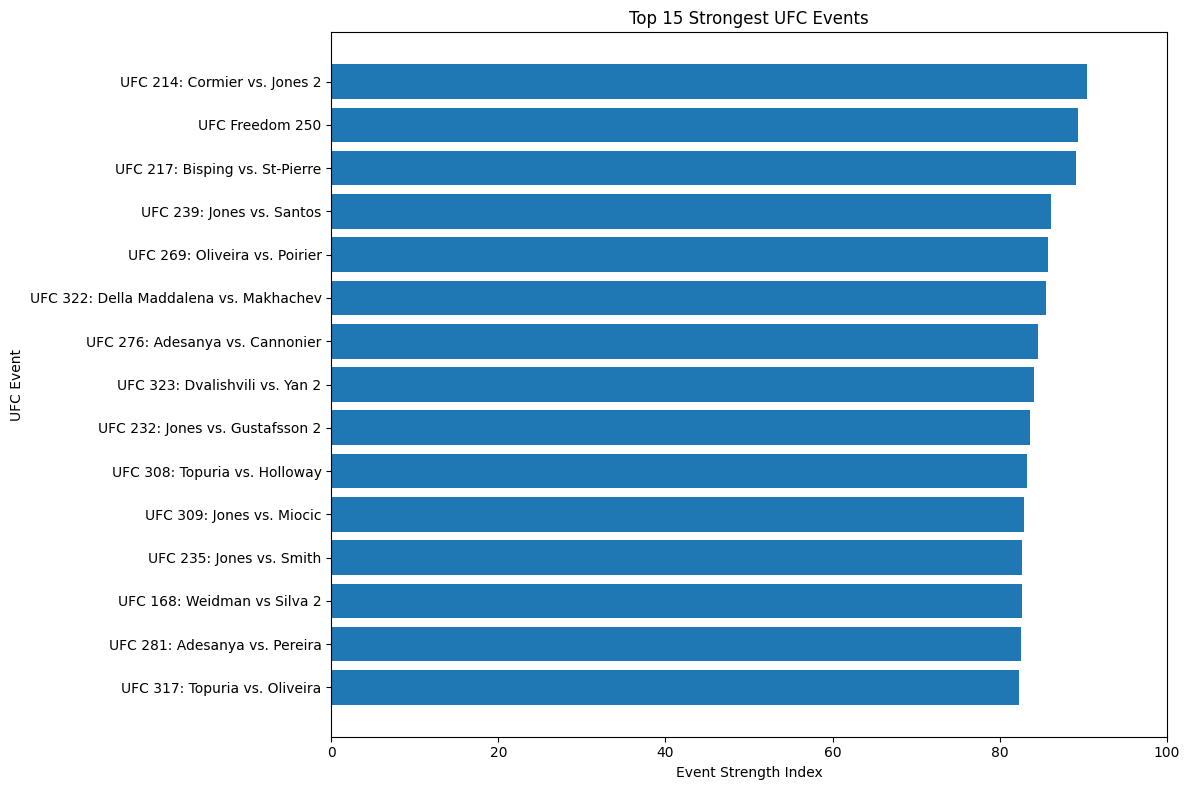

In [ ]:
import matplotlib.pyplot as plt

top_15 = (
    final_event_strength
    .sort_values("event_strength_index", ascending=False)
    .head(15)
    .sort_values("event_strength_index")
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_15["event_name"],
    top_15["event_strength_index"]
)

plt.xlabel("Event Strength Index")
plt.ylabel("UFC Event")

plt.title(
    "Top 15 Strongest UFC Events"
)

plt.xlim(0, 100)

plt.tight_layout()

plt.show()

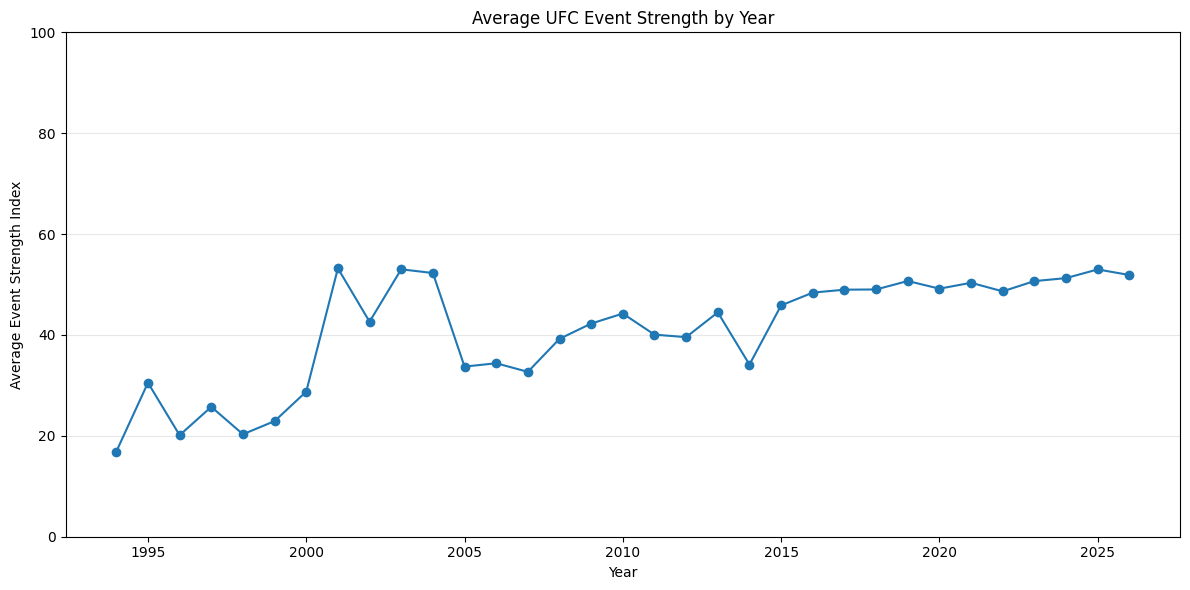

In [ ]:
yearly_strength = (
    final_event_strength
    .assign(
        year=final_event_strength["event_date"].dt.year
    )
    .groupby("year")["event_strength_index"]
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_strength.index,
    yearly_strength.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Event Strength Index")

plt.title(
    "Average UFC Event Strength by Year"
)

plt.ylim(0, 100)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

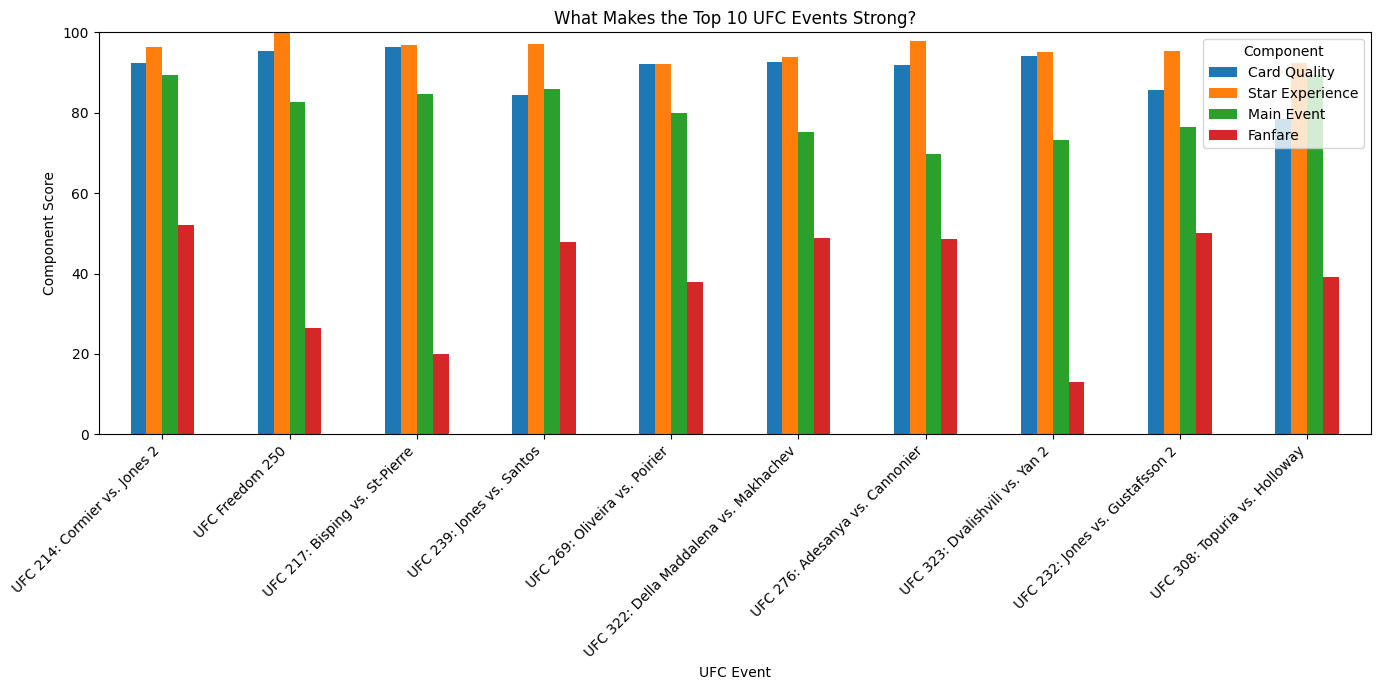

In [ ]:
top_10_components = (
    final_event_strength
    .sort_values("event_strength_index", ascending=False)
    .head(10)
    .set_index("event_name")
    [
        [
            "card_quality_score",
            "star_experience_score",
            "main_event_score",
            "fanfare_score"
        ]
    ]
)

top_10_components.columns = [
    "Card Quality",
    "Star Experience",
    "Main Event",
    "Fanfare"
]

top_10_components.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "What Makes the Top 10 UFC Events Strong?"
)

plt.xlabel("UFC Event")
plt.ylabel("Component Score")

plt.ylim(0, 100)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Component"
)

plt.tight_layout()

plt.show()

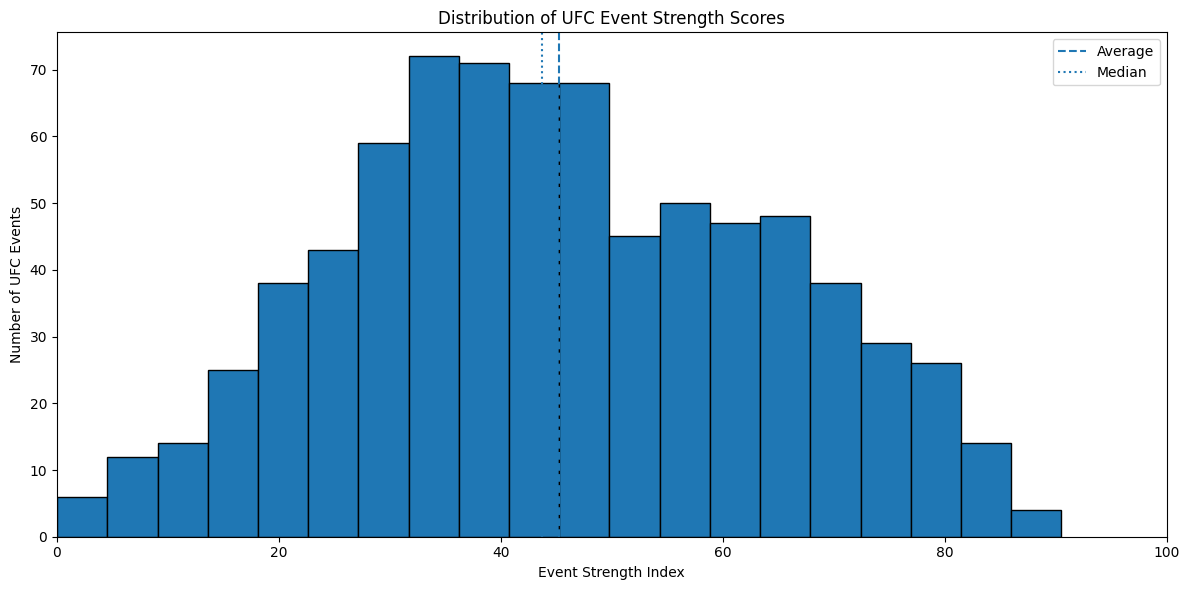

In [ ]:
plt.figure(figsize=(12, 6))

plt.hist(
    final_event_strength["event_strength_index"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    final_event_strength["event_strength_index"].mean(),
    linestyle="--",
    label="Average"
)

plt.axvline(
    final_event_strength["event_strength_index"].median(),
    linestyle=":",
    label="Median"
)

plt.title(
    "Distribution of UFC Event Strength Scores"
)

plt.xlabel("Event Strength Index")
plt.ylabel("Number of UFC Events")

plt.xlim(0, 100)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
best_by_year = (
    final_event_strength
    .assign(
        year=final_event_strength["event_date"].dt.year
    )
    .sort_values(
        "event_strength_index",
        ascending=False
    )
    .groupby("year")
    .first()
    .reset_index()
)

print("STRONGEST UFC EVENT BY YEAR")
print("=" * 90)

print(
    best_by_year[
        [
            "year",
            "event_name",
            "event_strength_index",
            "event_strength_rank"
        ]
    ]
    .round(2)
    .to_string(index=False)
)

STRONGEST UFC EVENT BY YEAR
 year                             event_name  event_strength_index  event_strength_rank
 1994         UFC 4: Revenge of the Warriors                 29.68                  607
 1995            UFC - Ultimate Ultimate '95                 44.03                  383
 1996            UFC - Ultimate Ultimate '96                 28.44                  625
 1997                   UFC - Ultimate Japan                 35.93                  513
 1998                  UFC - Ultimate Brazil                 31.06                  588
 1999       UFC 22: Only One Can be Champion                 33.20                  557
 2000           UFC 29: Defense of the Belts                 48.92                  312
 2001                   UFC 34: High Voltage                 63.72                  153
 2002                       UFC 40: Vendetta                 73.77                   65
 2003                     UFC 44: Undisputed                 66.33                  128
 200

In [ ]:
methodology = pd.DataFrame({
    "Component": [
        "Card Quality",
        "Star Experience",
        "Main Event Strength",
        "Fanfare"
    ],

    "Final Weight": [
        "40%",
        "25%",
        "30%",
        "5%"
    ],

    "What It Measures": [
        "Overall depth and quality of the full fight card",
        "Championship, main-event, and bonus experience across the card",
        "Strength and experience of the event's headlining fight",
        "Pre-event Google search-interest acceleration"
    ],

    "Key Inputs": [
        "Title fights, rankings, UFC experience, win %, win streaks, finish rate",
        "Previous title fights, previous main events, previous UFC bonuses",
        "UFC experience, record, streaks, title experience, rankings, bonuses",
        "Google Trends interest during the 7 days before the event"
    ]
})

print("UFC EVENT STRENGTH INDEX — MODEL METHODOLOGY")
print("=" * 120)
print()

print(
    methodology.to_string(
        index=False
    )
)

UFC EVENT STRENGTH INDEX — MODEL METHODOLOGY

          Component Final Weight                                               What It Measures                                                              Key Inputs
       Card Quality          40%               Overall depth and quality of the full fight card Title fights, rankings, UFC experience, win %, win streaks, finish rate
    Star Experience          25% Championship, main-event, and bonus experience across the card       Previous title fights, previous main events, previous UFC bonuses
Main Event Strength          30%        Strength and experience of the event's headlining fight    UFC experience, record, streaks, title experience, rankings, bonuses
            Fanfare           5%                  Pre-event Google search-interest acceleration               Google Trends interest during the 7 days before the event


In [ ]:
project_summary = pd.DataFrame({
    "Metric": [
        "UFC fights analyzed",
        "UFC events scored",
        "Historical fighter variables",
        "Google Trends events",
        "Fighter Google Topics",
        "Final model components",
        "Final score range",
        "Highest-rated event"
    ],

    "Result": [
        "8,736",
        "777",
        "Win streaks, UFC records, rankings, finishes, title fights, main events, bonuses",
        "505",
        "2,465",
        "4",
        "0–100",
        "UFC 214: Cormier vs. Jones 2 (90.50)"
    ]
})

print("UFC EVENT STRENGTH INDEX — PROJECT SUMMARY")
print("=" * 85)
print()

print(
    project_summary.to_string(
        index=False
    )
)

UFC EVENT STRENGTH INDEX — PROJECT SUMMARY

                      Metric                                                                           Result
         UFC fights analyzed                                                                            8,736
           UFC events scored                                                                              777
Historical fighter variables Win streaks, UFC records, rankings, finishes, title fights, main events, bonuses
        Google Trends events                                                                              505
       Fighter Google Topics                                                                            2,465
      Final model components                                                                                4
           Final score range                                                                            0–100
         Highest-rated event                                             UFC

In [ ]:
project_description = """
UFC Event Strength Index

Goal:
Build a data-driven model that measures how strong a UFC event was
based on the quality, experience, accomplishments, and pre-event
interest surrounding the fighters on the card.

Dataset:
- 8,736 UFC fights
- 777 UFC events
- Historical data from 1994 through 2026
- 2,465 fighters matched to Google Trends Topics
- 505 events with pre-event Google Trends data

Model:
Each UFC event receives a 0–100 Event Strength Index based on:

1. Card Quality — 40%
2. Star Experience — 25%
3. Main Event Strength — 30%
4. Fanfare — 5%

Historical fighter statistics are calculated entering each fight,
preventing future information from leaking into earlier events.

Key Result:
UFC 214: Cormier vs. Jones 2 ranks as the strongest event in the
dataset with an Event Strength Index of 90.50.
"""

print(project_description)


UFC Event Strength Index

Goal:
Build a data-driven model that measures how strong a UFC event was
based on the quality, experience, accomplishments, and pre-event
interest surrounding the fighters on the card.

Dataset:
- 8,736 UFC fights
- 777 UFC events
- Historical data from 1994 through 2026
- 2,465 fighters matched to Google Trends Topics
- 505 events with pre-event Google Trends data

Model:
Each UFC event receives a 0–100 Event Strength Index based on:

1. Card Quality — 40%
2. Star Experience — 25%
3. Main Event Strength — 30%
4. Fanfare — 5%

Historical fighter statistics are calculated entering each fight,
preventing future information from leaking into earlier events.

Key Result:
UFC 214: Cormier vs. Jones 2 ranks as the strongest event in the
dataset with an Event Strength Index of 90.50.



In [ ]:
import os

portfolio_folder = "/content/UFC_Event_Strength_Portfolio"

os.makedirs(
    portfolio_folder,
    exist_ok=True
)

os.makedirs(
    f"{portfolio_folder}/data",
    exist_ok=True
)

os.makedirs(
    f"{portfolio_folder}/visuals",
    exist_ok=True
)

os.makedirs(
    f"{portfolio_folder}/docs",
    exist_ok=True
)

print("PORTFOLIO FOLDER CREATED ✅🔥")
print("=" * 55)

for root, dirs, files in os.walk(portfolio_folder):
    level = root.replace(portfolio_folder, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

PORTFOLIO FOLDER CREATED ✅🔥
UFC_Event_Strength_Portfolio/
    data/
    docs/
    visuals/


In [ ]:
import shutil

source_file = (
    "/content/UFC_EVENT_STRENGTH_INDEX_FINAL.csv"
)

destination_file = (
    "/content/UFC_Event_Strength_Portfolio/"
    "data/UFC_EVENT_STRENGTH_INDEX_FINAL.csv"
)

shutil.copy(
    source_file,
    destination_file
)

print("FINAL DATASET ADDED TO PORTFOLIO ✅🔥")
print("=" * 60)

print("Saved to:")
print(destination_file)

print()
print(
    "File size:",
    round(
        os.path.getsize(destination_file) / 1024,
        2
    ),
    "KB"
)

print(
    "Exists:",
    os.path.exists(destination_file)
)

FINAL DATASET ADDED TO PORTFOLIO ✅🔥
Saved to:
/content/UFC_Event_Strength_Portfolio/data/UFC_EVENT_STRENGTH_INDEX_FINAL.csv

File size: 312.06 KB
Exists: True


In [ ]:
readme_start = """# UFC Event Strength Index

## Which UFC events were the strongest on paper?

The UFC Event Strength Index is a data analytics project that measures
the strength of UFC events using historical fighter performance,
rankings, experience, accomplishments, main-event strength, and
pre-event search interest.

The project analyzes 8,736 UFC fights across 777 events from
1994 through 2026.

Each event receives a score from 0 to 100 using four components:

- Card Quality — 40%
- Main Event Strength — 30%
- Star Experience — 25%
- Fanfare — 5%

All historical fighter statistics are calculated using only information
available before each fight, preventing future results from influencing
earlier UFC events.

## Key Result

UFC 214: Cormier vs. Jones 2 ranks #1 in the dataset with an
Event Strength Index of 90.50.
"""

readme_path = (
    "/content/UFC_Event_Strength_Portfolio/README.md"
)

with open(readme_path, "w") as file:
    file.write(readme_start)

print("README CREATED ✅🔥")
print("=" * 55)
print()
print(readme_start)

print("Saved to:")
print(readme_path)

README CREATED ✅🔥

# UFC Event Strength Index

## Which UFC events were the strongest on paper?

The UFC Event Strength Index is a data analytics project that measures
the strength of UFC events using historical fighter performance,
rankings, experience, accomplishments, main-event strength, and
pre-event search interest.

The project analyzes 8,736 UFC fights across 777 events from
1994 through 2026.

Each event receives a score from 0 to 100 using four components:

- Card Quality — 40%
- Main Event Strength — 30%
- Star Experience — 25%
- Fanfare — 5%

All historical fighter statistics are calculated using only information
available before each fight, preventing future results from influencing
earlier UFC events.

## Key Result

UFC 214: Cormier vs. Jones 2 ranks #1 in the dataset with an
Event Strength Index of 90.50.

Saved to:
/content/UFC_Event_Strength_Portfolio/README.md


In [ ]:
methodology_section = """

## Methodology

The Event Strength Index is built from four components.

### 1. Card Quality — 40%

Measures the overall strength and depth of the full event.

Inputs include:

- Number of title fights
- Historical UFC rankings
- UFC experience
- UFC win percentage
- Current UFC win streak
- Historical finishing rate

### 2. Main Event Strength — 30%

Measures the strength of the event's headlining matchup.

Inputs include:

- Combined UFC experience
- UFC win percentage
- Combined win streak
- Previous title fights
- Previous UFC main events
- Previous UFC bonuses
- Historical rankings

### 3. Star Experience — 25%

Measures the accomplishments and proven UFC experience across the card.

Inputs include:

- Previous UFC title fights
- Previous UFC main events
- Previous UFC performance and fight bonuses

### 4. Fanfare — 5%

Measures pre-event search-interest acceleration using Google Trends.

Search interest during the seven days before an event is compared with
the fighters' prior baseline interest. The metric is log-transformed to
reduce the effect of extreme spikes.

Because Google Trends data is not consistently available throughout UFC
history, missing fanfare data is not treated as a score of zero.

## Preventing Future Data Leakage

Every historical fighter statistic is calculated as it existed entering
the fight.

For example, a fighter's UFC record, win streak, title-fight experience,
main-event experience, and bonus history include only UFC fights that
occurred before the event being scored.

This prevents accomplishments earned later in a fighter's career from
artificially increasing the strength of earlier events.

## Scoring

Variables are converted to zero-preserving percentile scores.

A true value of zero remains zero, while positive values are ranked
relative to the other positive observations. Metrics that did not exist
during an earlier era, such as official UFC rankings, are treated as
unavailable rather than zero.

The final Event Strength Index uses:

- 40% Card Quality
- 30% Main Event Strength
- 25% Star Experience
- 5% Fanfare

When a component is historically unavailable, its weight is redistributed
across the available components rather than treating missing data as zero.
"""

with open(readme_path, "a") as file:
    file.write(methodology_section)

print("METHODOLOGY ADDED TO README ✅🔥")
print("=" * 60)

with open(readme_path, "r") as file:
    print(file.read())

METHODOLOGY ADDED TO README ✅🔥
# UFC Event Strength Index

## Which UFC events were the strongest on paper?

The UFC Event Strength Index is a data analytics project that measures
the strength of UFC events using historical fighter performance,
rankings, experience, accomplishments, main-event strength, and
pre-event search interest.

The project analyzes 8,736 UFC fights across 777 events from
1994 through 2026.

Each event receives a score from 0 to 100 using four components:

- Card Quality — 40%
- Main Event Strength — 30%
- Star Experience — 25%
- Fanfare — 5%

All historical fighter statistics are calculated using only information
available before each fight, preventing future results from influencing
earlier UFC events.

## Key Result

UFC 214: Cormier vs. Jones 2 ranks #1 in the dataset with an
Event Strength Index of 90.50.


## Methodology

The Event Strength Index is built from four components.

### 1. Card Quality — 40%

Measures the overall strength and depth of the full e

In [ ]:
top_10_readme = (
    final_event_strength
    .sort_values("event_strength_rank")
    .head(10)
    [
        [
            "event_strength_rank",
            "event_name",
            "event_date",
            "event_strength_index"
        ]
    ]
    .copy()
)

top_10_readme["event_date"] = (
    top_10_readme["event_date"]
    .dt.strftime("%Y-%m-%d")
)

top_10_readme["event_strength_index"] = (
    top_10_readme["event_strength_index"]
    .round(2)
)

results_section = """

## Top 10 Strongest UFC Events

| Rank | Event | Date | Event Strength Index |
|---:|---|---|---:|
"""

for _, row in top_10_readme.iterrows():
    results_section += (
        f"| {int(row['event_strength_rank'])} "
        f"| {row['event_name']} "
        f"| {row['event_date']} "
        f"| {row['event_strength_index']:.2f} |\n"
    )

with open(readme_path, "a") as file:
    file.write(results_section)

print("TOP 10 RESULTS ADDED ✅🔥")
print("=" * 70)
print(results_section)

TOP 10 RESULTS ADDED ✅🔥


## Top 10 Strongest UFC Events

| Rank | Event | Date | Event Strength Index |
|---:|---|---|---:|
| 1 | UFC 214: Cormier vs. Jones 2 | 2017-07-29 | 90.50 |
| 2 | UFC Freedom 250 | 2026-06-14 | 89.32 |
| 3 | UFC 217: Bisping vs. St-Pierre | 2017-11-04 | 89.12 |
| 4 | UFC 239: Jones vs. Santos | 2019-07-06 | 86.17 |
| 5 | UFC 269: Oliveira vs. Poirier | 2021-12-11 | 85.76 |
| 6 | UFC 322: Della Maddalena vs. Makhachev | 2025-11-15 | 85.54 |
| 7 | UFC 276: Adesanya vs. Cannonier | 2022-07-02 | 84.56 |
| 8 | UFC 323: Dvalishvili vs. Yan 2 | 2025-12-06 | 84.10 |
| 9 | UFC 232: Jones vs. Gustafsson 2 | 2018-12-29 | 83.59 |
| 10 | UFC 308: Topuria vs. Holloway | 2024-10-26 | 83.30 |



In [ ]:
findings_section = """

## Key Findings

- UFC 214: Cormier vs. Jones 2 ranks as the strongest event in the
  dataset with an Event Strength Index of 90.50.

- Among the 50 highest-rated events, Star Experience is the strongest
  component for 74% of events, while Card Quality is strongest for 24%
  and Main Event Strength for 2%.

- Numbered UFC events average a 56.74 Event Strength score compared
  with 38.16 for UFC Fight Nights. Event type itself is not included
  as an input to the model.

- Strong Fight Night cards can still score highly. The highest-rated
  Fight Night in the dataset reaches 68.70.

- Event year has only a modest relationship with Event Strength:
  Pearson correlation = 0.313 and Spearman correlation = 0.283.

- The model is highly stable across alternative component-weighting
  systems, with rank correlations of approximately 0.99 between the
  tested models.

## Limitations

- Official UFC rankings are only available beginning in 2013, so
  ranking information is treated as unavailable for earlier events.

- UFC bonus history begins later than the earliest UFC events.
  Pre-bonus-era events are not penalized for the absence of bonuses.

- The Google Trends component is available for 505 of the 777 events
  and is used as a proxy for pre-event fan interest rather than a
  direct measurement of social-media engagement.

- Google Trends data is based on U.S. search interest, which may
  underrepresent internationally popular fighters and events.

- Google Trends values are relative search-interest measurements,
  not absolute audience-size measurements.

- The component weights are modeling choices rather than objectively
  correct values. Alternative weighting systems were tested to measure
  ranking sensitivity.

- The index measures the strength of an event based primarily on the
  fighters and information available around the event. It is not a
  measurement of how entertaining the fights ultimately were.
"""

with open(readme_path, "a") as file:
    file.write(findings_section)

print("FINDINGS + LIMITATIONS ADDED ✅🔥")
print("=" * 65)
print(findings_section)

FINDINGS + LIMITATIONS ADDED ✅🔥


## Key Findings

- UFC 214: Cormier vs. Jones 2 ranks as the strongest event in the
  dataset with an Event Strength Index of 90.50.

- Among the 50 highest-rated events, Star Experience is the strongest
  component for 74% of events, while Card Quality is strongest for 24%
  and Main Event Strength for 2%.

- Numbered UFC events average a 56.74 Event Strength score compared
  with 38.16 for UFC Fight Nights. Event type itself is not included
  as an input to the model.

- Strong Fight Night cards can still score highly. The highest-rated
  Fight Night in the dataset reaches 68.70.

- Event year has only a modest relationship with Event Strength:
  Pearson correlation = 0.313 and Spearman correlation = 0.283.

- The model is highly stable across alternative component-weighting
  systems, with rank correlations of approximately 0.99 between the
  tested models.

## Limitations

- Official UFC rankings are only available beginning in 2013, so
  ranking i

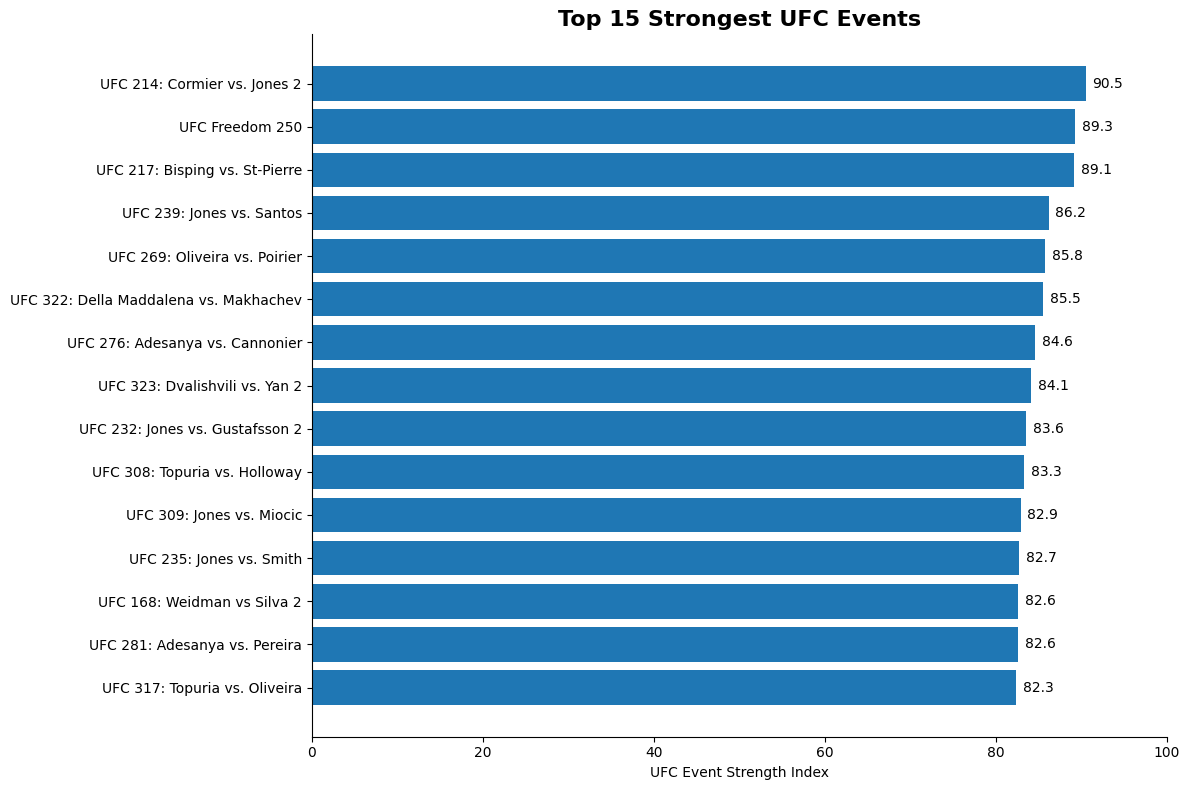


PORTFOLIO CHART SAVED ✅🔥
/content/UFC_Event_Strength_Portfolio/visuals/top_15_ufc_events.png


In [ ]:
top_15 = (
    final_event_strength
    .sort_values("event_strength_index", ascending=False)
    .head(15)
    .sort_values("event_strength_index")
)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    top_15["event_name"],
    top_15["event_strength_index"]
)

ax.set_title(
    "Top 15 Strongest UFC Events",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("UFC Event Strength Index")
ax.set_ylabel("")

ax.set_xlim(0, 100)

for bar, score in zip(
    bars,
    top_15["event_strength_index"]
):
    ax.text(
        score + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.1f}",
        va="center"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

chart_path = (
    "/content/UFC_Event_Strength_Portfolio/"
    "visuals/top_15_ufc_events.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("PORTFOLIO CHART SAVED ✅🔥")
print(chart_path)

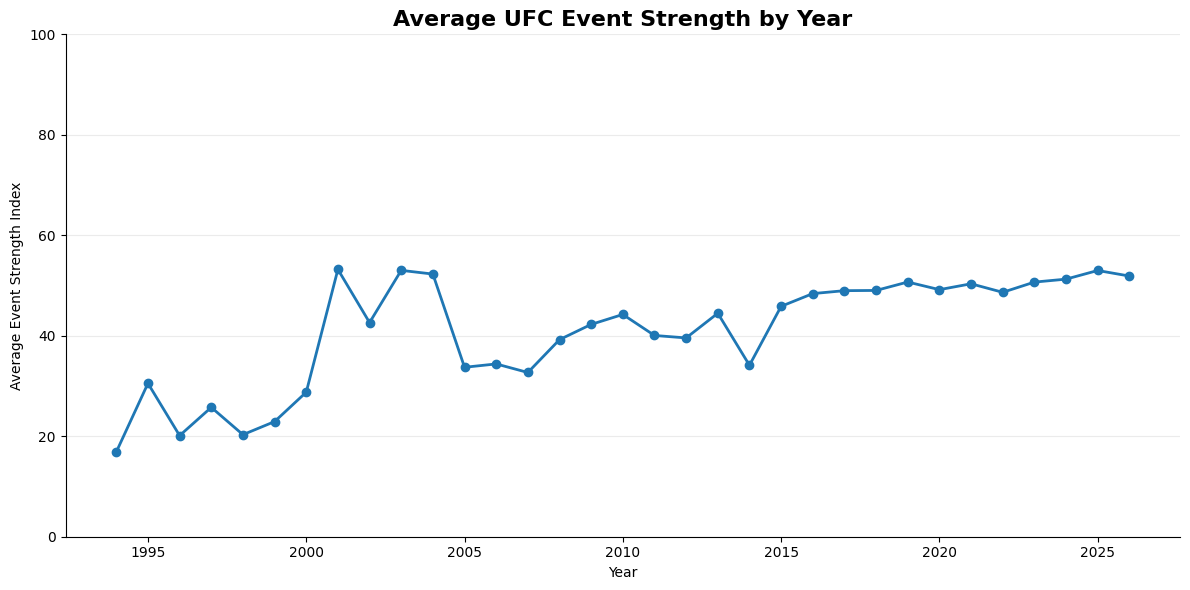


HISTORICAL TREND CHART SAVED ✅🔥
/content/UFC_Event_Strength_Portfolio/visuals/event_strength_by_year.png


In [ ]:
yearly_strength = (
    final_event_strength
    .assign(
        year=final_event_strength["event_date"].dt.year
    )
    .groupby("year")["event_strength_index"]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    yearly_strength.index,
    yearly_strength.values,
    marker="o",
    linewidth=2
)

ax.set_title(
    "Average UFC Event Strength by Year",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Year")
ax.set_ylabel("Average Event Strength Index")

ax.set_ylim(0, 100)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

trend_path = (
    "/content/UFC_Event_Strength_Portfolio/"
    "visuals/event_strength_by_year.png"
)

plt.savefig(
    trend_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("HISTORICAL TREND CHART SAVED ✅🔥")
print(trend_path)

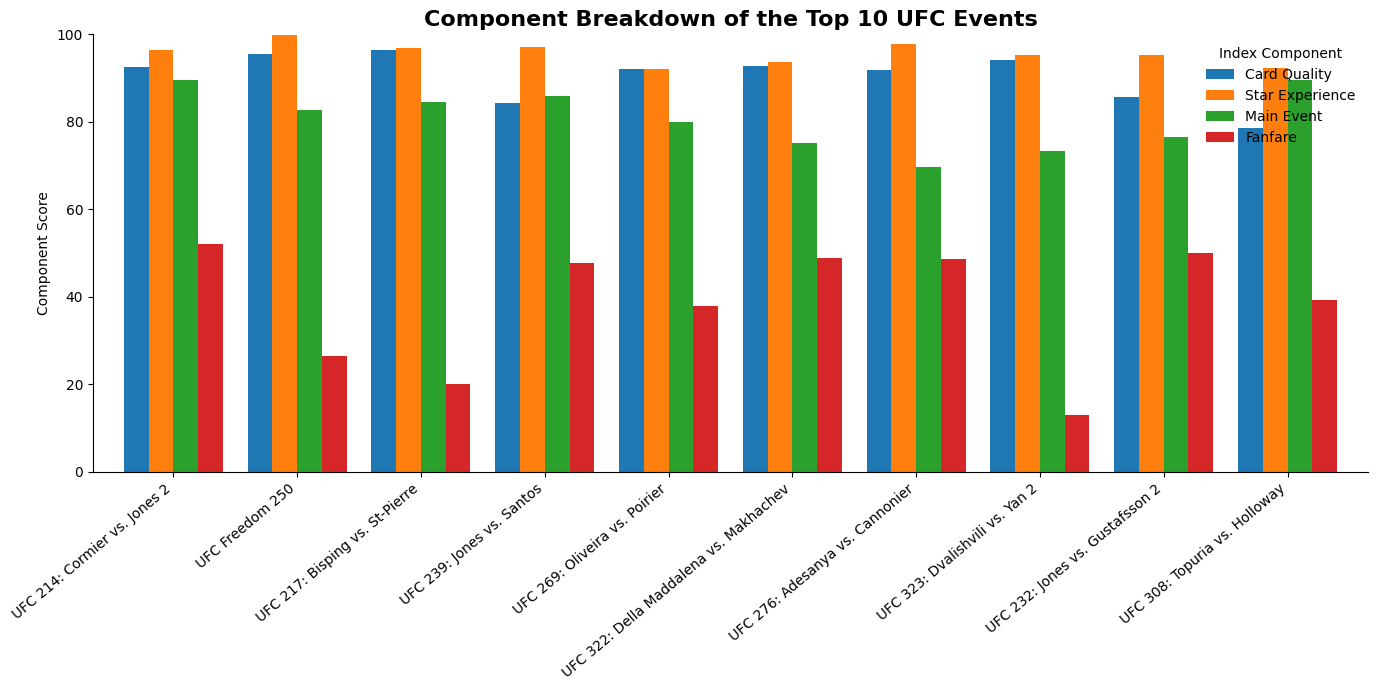


FINAL PORTFOLIO CHART SAVED ✅🔥
/content/UFC_Event_Strength_Portfolio/visuals/top_10_component_breakdown.png


In [ ]:
top_10 = (
    final_event_strength
    .sort_values("event_strength_index", ascending=False)
    .head(10)
    .copy()
)

component_chart = top_10.set_index("event_name")[
    [
        "card_quality_score",
        "star_experience_score",
        "main_event_score",
        "fanfare_score"
    ]
]

component_chart.columns = [
    "Card Quality",
    "Star Experience",
    "Main Event",
    "Fanfare"
]

ax = component_chart.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.8
)

ax.set_title(
    "Component Breakdown of the Top 10 UFC Events",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Component Score")
ax.set_ylim(0, 100)

plt.xticks(
    rotation=40,
    ha="right"
)

ax.legend(
    title="Index Component",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

component_path = (
    "/content/UFC_Event_Strength_Portfolio/"
    "visuals/top_10_component_breakdown.png"
)

plt.savefig(
    component_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("FINAL PORTFOLIO CHART SAVED ✅🔥")
print(component_path)

In [ ]:
visuals_section = """

## Visualizations

### Top 15 Strongest UFC Events

![Top 15 Strongest UFC Events](visuals/top_15_ufc_events.png)

### UFC Event Strength Over Time

![Average UFC Event Strength by Year](visuals/event_strength_by_year.png)

### Component Breakdown of the Top 10 Events

![Top 10 Component Breakdown](visuals/top_10_component_breakdown.png)

## Technologies Used

- Python
- pandas
- NumPy
- Matplotlib
- Google Colab
- Google Trends / pytrends
- Historical UFC fight, ranking, and bonus data

## Project Files

- `data/UFC_EVENT_STRENGTH_INDEX_FINAL.csv` — final event-level dataset
- `visuals/top_15_ufc_events.png` — Top 15 ranking visualization
- `visuals/event_strength_by_year.png` — historical trend visualization
- `visuals/top_10_component_breakdown.png` — component comparison visualization
- `README.md` — project methodology, results, findings, and limitations

"""

with open(readme_path, "a") as file:
    file.write(visuals_section)

print("README FINISHED ✅🔥")
print("=" * 60)

print("Visuals added: 3")
print("Technologies section added")
print("Project files section added")

print()
print("README location:")
print(readme_path)

README FINISHED ✅🔥
Visuals added: 3
Technologies section added
Project files section added

README location:
/content/UFC_Event_Strength_Portfolio/README.md


In [ ]:
import shutil
import os

portfolio_folder = (
    "/content/UFC_Event_Strength_Portfolio"
)

zip_base = (
    "/content/UFC_Event_Strength_Portfolio"
)

zip_path = shutil.make_archive(
    zip_base,
    "zip",
    portfolio_folder
)

print("PORTFOLIO PACKAGED ✅🔥")
print("=" * 60)

print("ZIP created:")
print(zip_path)

print()
print(
    "ZIP size:",
    round(
        os.path.getsize(zip_path) / (1024 * 1024),
        2
    ),
    "MB"
)

PORTFOLIO PACKAGED ✅🔥
ZIP created:
/content/UFC_Event_Strength_Portfolio.zip

ZIP size: 0.79 MB


In [ ]:
import zipfile

zip_path = "/content/UFC_Event_Strength_Portfolio.zip"

with zipfile.ZipFile(zip_path, "r") as zip_file:
    files_inside = zip_file.namelist()

print("FINAL ZIP VERIFICATION")
print("=" * 60)

for file in files_inside:
    print("✓", file)

print()
print("Total files:", len(files_inside))

FINAL ZIP VERIFICATION
✓ data/
✓ docs/
✓ visuals/
✓ README.md
✓ data/UFC_EVENT_STRENGTH_INDEX_FINAL.csv
✓ visuals/top_15_ufc_events.png
✓ visuals/event_strength_by_year.png
✓ visuals/top_10_component_breakdown.png

Total files: 8


In [2]:
print(
    ufc_fights[
        ["event_name", "date"]
    ]
    .drop_duplicates()
    .sort_values("date")
    .tail(10)
    .to_string(index=False)
)

                                 event_name       date
          UFC Fight Night: Burns vs. Malott 2026-04-18
        UFC Fight Night: Sterling vs. Zalal 2026-04-25
UFC Fight Night: Della Maddalena vs. Prates 2026-05-02
            UFC 328: Chimaev vs. Strickland 2026-05-09
           UFC Fight Night: Allen vs. Costa 2026-05-16
       UFC Fight Night: Song vs. Figueiredo 2026-05-30
       UFC Fight Night: Muhammad vs. Bonfim 2026-06-06
                            UFC Freedom 250 2026-06-14
        UFC Fight Night: Kape vs. Horiguchi 2026-06-20
         UFC Fight Night: Fiziev vs. Torres 2026-06-27


In [3]:
ufc_fights_pre_update = ufc_fights.copy()
event_master_pre_update = event_master.copy()
final_event_strength_pre_update = final_event_strength.copy()

print("PRE-UPDATE SAFETY COPY CREATED ✅🔥")
print("=" * 55)
print("Fights:", len(ufc_fights_pre_update))
print("Events:", len(event_master_pre_update))
print("Latest date:", ufc_fights_pre_update["date"].max())

PRE-UPDATE SAFETY COPY CREATED ✅🔥
Fights: 8736
Events: 777
Latest date: 2026-06-27 00:00:00


In [4]:
print("CURRENT DATASET COLUMNS:")
print("=" * 60)

for i, col in enumerate(ufc_fights.columns, 1):
    print(f"{i}. {col}")

print()
print("FIRST FIGHT URL:")
print(ufc_fights["fight_url"].dropna().iloc[0])

print()
print("LATEST FIGHT URL:")
print(ufc_fights["fight_url"].dropna().iloc[-1])

CURRENT DATASET COLUMNS:
1. fight_url
2. event_name
3. date
4. location
5. f1_name
6. f1_result
7. f2_name
8. f2_result
9. weight_class
10. method
11. round
12. time
13. time_format
14. referee
15. judging_details
16. f1_ufc_wins_before
17. f1_ufc_losses_before
18. f2_ufc_wins_before
19. f2_ufc_losses_before
20. f1_ufc_fights_before
21. f2_ufc_fights_before
22. f1_win_streak_before
23. f2_win_streak_before
24. is_title_fight
25. f1_previous_title_fights
26. f2_previous_title_fights
27. is_main_event
28. f1_ufc_win_pct_before
29. f2_ufc_win_pct_before
30. f1_last5_win_pct
31. f2_last5_win_pct
32. f1_finish_rate_before
33. f2_finish_rate_before
34. f1_ufc_finishes_before
35. f2_ufc_finishes_before
36. ranking_division
37. f1_rank_before
38. f2_rank_before
39. is_main_event_verified
40. f1_previous_main_events
41. f2_previous_main_events
42. f1_slug
43. f2_slug
44. matchup_slug_1
45. matchup_slug_2
46. FOTN
47. POTN
48. KOTN
49. SOTN
50. f1_previous_FOTN
51. f1_previous_POTN
52. f1_previo

In [5]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

url = "http://ufcstats.com/statistics/events/completed?page=all"

response = requests.get(
    url,
    headers={"User-Agent": "Mozilla/5.0"}
)

print("UFCSTATS CONNECTION TEST")
print("=" * 55)
print("Status code:", response.status_code)
print("Characters received:", len(response.text))

soup = BeautifulSoup(response.text, "html.parser")

event_rows = []

for row in soup.select("tr.b-statistics__table-row"):
    link = row.select_one("a.b-link")
    date_tag = row.select_one("span.b-statistics__date")

    if link and date_tag:
        event_rows.append({
            "event_name": link.get_text(strip=True),
            "date": date_tag.get_text(strip=True),
            "event_url": link.get("href")
        })

events_check = pd.DataFrame(event_rows)

events_check["date"] = pd.to_datetime(
    events_check["date"],
    errors="coerce"
)

new_events_check = (
    events_check[
        events_check["date"] > pd.Timestamp("2026-06-27")
    ]
    .sort_values("date")
)

print()
print("EVENTS AFTER JUNE 27, 2026:")
print("=" * 55)

print(
    new_events_check[
        ["date", "event_name"]
    ].to_string(index=False)
)

print()
print("Events found:", len(new_events_check))

UFCSTATS CONNECTION TEST
Status code: 200
Characters received: 2994


KeyError: 'date'

In [6]:
print("UFCSTATS RESPONSE CHECK")
print("=" * 60)

print("Status:", response.status_code)
print("Final URL:", response.url)
print()
print("First 2000 characters returned:")
print("=" * 60)
print(response.text[:2000])

UFCSTATS RESPONSE CHECK
Status: 200
Final URL: http://ufcstats.com/statistics/events/completed?page=all

First 2000 characters returned:
<!doctype html><html><head><meta charset="utf-8">
<title>Loading…</title><meta name="robots" content="noindex">
<style>body{font-family:sans-serif;color:#666;text-align:center;margin-top:25vh}</style>
</head><body>
<p>Checking your browser…</p>
<noscript>This site requires JavaScript.</noscript>
<script>
(function(){
var K=[0x428a2f98,0x71374491,0xb5c0fbcf,0xe9b5dba5,0x3956c25b,0x59f111f1,0x923f82a4,0xab1c5ed5,
0xd807aa98,0x12835b01,0x243185be,0x550c7dc3,0x72be5d74,0x80deb1fe,0x9bdc06a7,0xc19bf174,
0xe49b69c1,0xefbe4786,0x0fc19dc6,0x240ca1cc,0x2de92c6f,0x4a7484aa,0x5cb0a9dc,0x76f988da,
0x983e5152,0xa831c66d,0xb00327c8,0xbf597fc7,0xc6e00bf3,0xd5a79147,0x06ca6351,0x14292967,
0x27b70a85,0x2e1b2138,0x4d2c6dfc,0x53380d13,0x650a7354,0x766a0abb,0x81c2c92e,0x92722c85,
0xa2bfe8a1,0xa81a664b,0xc24b8b70,0xc76c51a3,0xd192e819,0xd6990624,0xf40e3585,0x106aa070,
0x1

In [7]:
import pandas as pd

mirror_url = (
    "https://raw.githubusercontent.com/"
    "haddad-github/UFC-Stats/master/"
    "ufc_fight_results.csv"
)

ufc_mirror = pd.read_csv(mirror_url)

print("UFCSTATS MIRROR LOADED ✅🔥")
print("=" * 60)

print("Rows:", len(ufc_mirror))
print("Columns:", len(ufc_mirror.columns))

print()
print("COLUMN NAMES:")
print(ufc_mirror.columns.tolist())

print()
print("LAST 5 ROWS:")
print(ufc_mirror.tail().to_string())

UFCSTATS MIRROR LOADED ✅🔥
Rows: 7505
Columns: 11

COLUMN NAMES:
['EVENT', 'BOUT', 'OUTCOME', 'WEIGHTCLASS', 'METHOD', 'ROUND', 'TIME', 'TIME FORMAT', 'REFEREE', 'DETAILS', 'URL']

LAST 5 ROWS:
                   EVENT                                 BOUT OUTCOME       WEIGHTCLASS       METHOD  ROUND   TIME    TIME FORMAT        REFEREE                                          DETAILS                                                 URL
7500  UFC 2: No Way Out   Orlando Wiet  vs. Robert Lucarelli      W/L  Open Weight Bout      KO/TKO       1   2:50  No Time Limit  John McCarthy                                toCorner Stoppage  http://ufcstats.com/fight-details/3b020d4914b44fc8
7501  UFC 2: No Way Out   Frank Hamaker  vs. Thaddeus Luster      W/L  Open Weight Bout  Submission       1   4:52  No Time Limit  John McCarthy                         Keylock From Half Guard   http://ufcstats.com/fight-details/d917c8c7461b9831
7502  UFC 2: No Way Out     Johnny Rhodes  vs. David Levicki      W/L

In [8]:
print("NEWEST EVENTS IN MIRROR")
print("=" * 60)

print(
    ufc_mirror[
        ["EVENT", "BOUT", "URL"]
    ]
    .head(30)
    .to_string(index=False)
)

NEWEST EVENTS IN MIRROR
                                 EVENT                                      BOUT                                                URL
 UFC Fight Night: Moreno vs. Royval 2        Brandon Moreno  vs. Brandon Royval  http://ufcstats.com/fight-details/74f5cbecac011abb
 UFC Fight Night: Moreno vs. Royval 2          Yair Rodriguez  vs. Brian Ortega  http://ufcstats.com/fight-details/3b05a4ced6dd74f5
 UFC Fight Night: Moreno vs. Royval 2     Daniel Zellhuber  vs. Francisco Prado  http://ufcstats.com/fight-details/ecbece0cbd60029e
 UFC Fight Night: Moreno vs. Royval 2           Yazmin Jauregui  vs. Sam Hughes  http://ufcstats.com/fight-details/6e4acb2aaa2cee56
 UFC Fight Night: Moreno vs. Royval 2           Manuel Torres  vs. Chris Duncan  http://ufcstats.com/fight-details/673a156925dfb31d
 UFC Fight Night: Moreno vs. Royval 2     Cristian Quinonez  vs. Raoni Barcelos  http://ufcstats.com/fight-details/063e7ce759c52f81
 UFC Fight Night: Moreno vs. Royval 2        Jesus A

In [9]:
import requests
import json

api_url = "https://ufcapi.aristotle.me/api/events?limit=20"

api_response = requests.get(
    api_url,
    timeout=30
)

print("CURRENT UFC API TEST")
print("=" * 60)

print("Status code:", api_response.status_code)
print("Characters received:", len(api_response.text))

print()
print("FIRST 1500 CHARACTERS:")
print("=" * 60)

print(api_response.text[:1500])

ConnectionError: HTTPSConnectionPool(host='ufcapi.aristotle.me', port=443): Max retries exceeded with url: /api/events?limit=20 (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x7ba13ab1a7b0>: Failed to establish a new connection: [Errno 111] Connection refused'))

In [10]:
import requests
from bs4 import BeautifulSoup

test_url = (
    "https://www.ufc.com/event/"
    "ufc-fight-night-july-18-2026"
)

ufc_test = requests.get(
    test_url,
    headers={
        "User-Agent": "Mozilla/5.0"
    },
    timeout=30
)

print("OFFICIAL UFC CONNECTION TEST")
print("=" * 60)

print("Status code:", ufc_test.status_code)
print("Characters received:", len(ufc_test.text))

print()
print("Contains Dricus Du Plessis:",
      "Dricus Du Plessis" in ufc_test.text)

print("Contains Kamaru Usman:",
      "Kamaru Usman" in ufc_test.text)

print("Contains Tommy McMillen:",
      "Tommy McMillen" in ufc_test.text)

OFFICIAL UFC CONNECTION TEST
Status code: 200
Characters received: 215487

Contains Dricus Du Plessis: True
Contains Kamaru Usman: True
Contains Tommy McMillen: True


In [11]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(ufc_test.text, "html.parser")

# Find every completed fight block on the page
fight_blocks = soup.select(".c-listing-fight")

print("FIGHT BLOCKS FOUND:", len(fight_blocks))
print("=" * 60)

# Inspect the first fight block
if fight_blocks:
    first_fight = fight_blocks[0]

    print("TEXT FROM FIRST FIGHT:")
    print("=" * 60)
    print(
        " ".join(
            first_fight.get_text(" ", strip=True).split()
        )
    )

    print()
    print("HTML PREVIEW:")
    print("=" * 60)
    print(str(first_fight)[:5000])

FIGHT BLOCKS FOUND: 12
TEXT FROM FIRST FIGHT:
#2 Middleweight Bout #9 Win #2 Middleweight Bout #9 #2 #9 Live now Fight of the Night Dricus Du Plessis vs Kamaru Usman Round 5 Time 5:00 Method Decision - Unanimous Loss #9 Dricus Du Plessis Middleweight Bout Kamaru Usman South Africa -235 odds +180 Nigeria Round 5 Time 5:00 Method Decision - Unanimous

HTML PREVIEW:
<div class="c-listing-fight" data-fmid="12919" data-status="">
<div class="c-listing-fight__content">
<button class="c-listing-fight__expand-button">
<span class="e-icon--xsmall expand-state-icon"><svg aria-hidden="true" class="e-icon__svg"><use xlink:href="/themes/custom/ufc/assets/svg/sprite-ui.svg#fullscreen" xmlns:xlink="http://www.w3.org/1999/xlink"></use></svg></span>
</button>
<div class="c-listing-fight__class c-listing-fight__class--mobile">
<div class="js-listing-fight__corner-rank c-listing-fight__corner-rank">
<span>#2</span>
</div>
<div class="c-listing-fight__class-text">Middleweight Bout</div>
<div class="js-lis

In [12]:
import pandas as pd

test_fights = []

for fight in fight_blocks:

    # Fighter names
    red = fight.select_one(
        ".c-listing-fight__corner-name--red"
    )
    blue = fight.select_one(
        ".c-listing-fight__corner-name--blue"
    )

    red_name = " ".join(red.stripped_strings) if red else None
    blue_name = " ".join(blue.stripped_strings) if blue else None

    # Results
    red_win = fight.select_one(
        ".c-listing-fight__corner--red .c-listing-fight__outcome--win"
    )
    blue_win = fight.select_one(
        ".c-listing-fight__corner--blue .c-listing-fight__outcome--win"
    )

    if red_win:
        red_result, blue_result = "W", "L"
    elif blue_win:
        red_result, blue_result = "L", "W"
    else:
        red_result, blue_result = None, None

    # Weight class
    wc = fight.select_one(
        ".c-listing-fight__class--desktop .c-listing-fight__class-text"
    )

    # Fight result details
    round_el = fight.select_one(".round")
    time_el = fight.select_one(".time")
    method_el = fight.select_one(".method")

    test_fights.append({
        "f1_name": red_name,
        "f1_result": red_result,
        "f2_name": blue_name,
        "f2_result": blue_result,
        "weight_class": wc.get_text(strip=True) if wc else None,
        "method": method_el.get_text(strip=True) if method_el else None,
        "round": round_el.get_text(strip=True) if round_el else None,
        "time": time_el.get_text(strip=True) if time_el else None
    })

test_event_df = pd.DataFrame(test_fights)

print("FIGHTS EXTRACTED:", len(test_event_df))
print("=" * 80)

print(test_event_df.to_string(index=False))

FIGHTS EXTRACTED: 12
              f1_name f1_result                f2_name f2_result             weight_class               method round time
    Dricus Du Plessis         W           Kamaru Usman         L        Middleweight Bout Decision - Unanimous     5 5:00
      Jared Cannonier         L Christian Leroy Duncan         W        Middleweight Bout Decision - Unanimous     3 5:00
         Chase Hooper         W          Mitch Ramirez         L         Lightweight Bout           Submission     1 2:15
        Tabatha Ricci         L           Fatima Kline         W Women's Strawweight Bout Decision - Unanimous     3 5:00
       Tommy McMillen         W         Alberto Montes         L       Featherweight Bout               KO/TKO     3 3:29
         Austin Bashi         L    Jose Miguel Delgado         W       Featherweight Bout Decision - Unanimous     3 5:00
Jean-Paul Lebosnoyani         W           Seokhyeon Ko         L        Welterweight Bout Decision - Unanimous     3 5:00
   

In [13]:
first_fight = fight_blocks[0]

print("EXTRA FIELD CHECK")
print("=" * 70)

# Show all CSS classes containing useful result/detail information
for tag in first_fight.find_all(True):
    classes = tag.get("class", [])

    if any(
        word in " ".join(classes).lower()
        for word in ["result", "referee", "detail", "judge", "round", "time", "method"]
    ):
        text = " ".join(tag.stripped_strings)

        if text:
            print(classes, "->", text[:300])

EXTRA FIELD CHECK
['c-listing-fight__details', 'c-listing-fight__details--with-results'] -> #2 Middleweight Bout #9 #2 #9 Live now Fight of the Night Dricus Du Plessis vs Kamaru Usman Round 5 Time 5:00 Method Decision - Unanimous
['js-listing-fight__results', 'c-listing-fight__results--desktop'] -> Round 5 Time 5:00 Method Decision - Unanimous
['c-listing-fight__result'] -> Round 5
['c-listing-fight__result-label'] -> Round
['c-listing-fight__result-text', 'round'] -> 5
['c-listing-fight__result'] -> Time 5:00
['c-listing-fight__result-label'] -> Time
['c-listing-fight__result-text', 'time'] -> 5:00
['c-listing-fight__result'] -> Method Decision - Unanimous
['c-listing-fight__result-label'] -> Method
['c-listing-fight__result-text', 'method'] -> Decision - Unanimous
['c-listing-fight__details-content', 'details-content'] -> Dricus Du Plessis Middleweight Bout Kamaru Usman
['details-content__header'] -> Dricus Du Plessis Middleweight Bout Kamaru Usman
['details-content__name', 'details-

In [14]:
print("EVENT INFORMATION CHECK")
print("=" * 70)

# Look for likely event title/date/location elements
selectors = [
    "h1",
    ".c-hero__headline",
    ".c-hero__headline-prefix",
    ".c-hero__headline-suffix",
    ".c-hero__date",
    ".c-hero__location",
    ".c-event-fight-card-broadcaster__date",
    ".c-event-fight-card-broadcaster__location"
]

for selector in selectors:
    elements = soup.select(selector)

    for element in elements[:5]:
        text = " ".join(element.stripped_strings)
        if text:
            print(f"{selector}: {text}")

EVENT INFORMATION CHECK
h1: UFC Fight Night
h1: UFC Fight Night
.c-hero__headline: Du Plessis vs Usman
.c-hero__headline-prefix: UFC Fight Night
.c-hero__headline-suffix: Sat, Jul 18 / 8:00 PM EDT


In [15]:
print("LOCATION SEARCH")

LOCATION SEARCH


In [16]:
print("UFC FIGHT IDS")
print("=" * 70)

for fight in fight_blocks:
    fight_id = fight.get("data-fmid")

    red = fight.select_one(".c-listing-fight__corner-name--red")
    blue = fight.select_one(".c-listing-fight__corner-name--blue")

    red_name = " ".join(red.stripped_strings) if red else None
    blue_name = " ".join(blue.stripped_strings) if blue else None

    print(f"{fight_id}: {red_name} vs {blue_name}")

UFC FIGHT IDS
12919: Dricus Du Plessis vs Kamaru Usman
12885: Jared Cannonier vs Christian Leroy Duncan
12874: Chase Hooper vs Mitch Ramirez
12924: Tabatha Ricci vs Fatima Kline
12922: Tommy McMillen vs Alberto Montes
12923: Austin Bashi vs Jose Miguel Delgado
12929: Jean-Paul Lebosnoyani vs Seokhyeon Ko
12925: Levi Rodrigues Jr. vs Felipe Franco
12960: Ezra Elliot vs Damien Anderson
12912: Alden Coria vs Stewart Nicoll
12952: RJ Harris vs Alvin Hines
12953: Anna Melisano vs Dione Barbosa


In [17]:
import numpy as np
import pandas as pd

test_event_complete = test_event_df.copy()

# Event information
test_event_complete.insert(
    0,
    "event_name",
    "UFC Fight Night: Du Plessis vs. Usman"
)

test_event_complete.insert(
    1,
    "date",
    pd.Timestamp("2026-07-18")
)

# Fields unavailable from the UFC page
test_event_complete.insert(2, "location", np.nan)
test_event_complete["time_format"] = np.nan
test_event_complete["referee"] = np.nan
test_event_complete["judging_details"] = np.nan

# Official UFC.com fight ID
test_event_complete["ufc_fmid"] = [
    fight.get("data-fmid")
    for fight in fight_blocks
]

print("COMPLETE TEST EVENT CREATED ✅🔥")
print("=" * 90)

print("Rows:", len(test_event_complete))
print("Unique fight IDs:", test_event_complete["ufc_fmid"].nunique())
print("Date:", test_event_complete["date"].iloc[0])
print()

print(test_event_complete.to_string(index=False))

COMPLETE TEST EVENT CREATED ✅🔥
Rows: 12
Unique fight IDs: 12
Date: 2026-07-18 00:00:00

                           event_name       date  location               f1_name f1_result                f2_name f2_result             weight_class               method round time  time_format  referee  judging_details ufc_fmid
UFC Fight Night: Du Plessis vs. Usman 2026-07-18       NaN     Dricus Du Plessis         W           Kamaru Usman         L        Middleweight Bout Decision - Unanimous     5 5:00          NaN      NaN              NaN    12919
UFC Fight Night: Du Plessis vs. Usman 2026-07-18       NaN       Jared Cannonier         L Christian Leroy Duncan         W        Middleweight Bout Decision - Unanimous     3 5:00          NaN      NaN              NaN    12885
UFC Fight Night: Du Plessis vs. Usman 2026-07-18       NaN          Chase Hooper         W          Mitch Ramirez         L         Lightweight Bout           Submission     1 2:15          NaN      NaN              NaN    12

In [18]:
import requests
from bs4 import BeautifulSoup

archive_url = "https://www.ufc.com/events"

archive_response = requests.get(
    archive_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

archive_soup = BeautifulSoup(
    archive_response.text,
    "html.parser"
)

print("UFC EVENT ARCHIVE TEST")
print("=" * 70)

print("Status code:", archive_response.status_code)
print("Characters received:", len(archive_response.text))

event_links = []

for a in archive_soup.select('a[href*="/event/"]'):
    href = a.get("href")
    text = " ".join(a.stripped_strings)

    if href:
        event_links.append((text, href))

print("Event links found:", len(event_links))

print()
print("FIRST 20 EVENT LINKS:")
print("=" * 70)

for text, href in event_links[:20]:
    print(text, "->", href)

UFC EVENT ARCHIVE TEST
Status code: 200
Characters received: 315284
Event links found: 72

FIRST 20 EVENT LINKS:
View Fight Card -> https://www.ufc.com/event/ufc-332
See these athletes in action at  UFC 332 -> /event/ufc-332
 -> /event/ufc-fight-night-september-26-2026
Rosas Jr. vs Barcelos -> /event/ufc-fight-night-september-26-2026
Sat, Sep 26 / 8:00 PM EDT / Main Card -> /event/ufc-fight-night-september-26-2026
Fight Card -> /event/ufc-fight-night-september-26-2026#1337
View Event Details -> /event/ufc-332
 -> /event/ufc-332
Silva vs Wang -> /event/ufc-332
Sat, Oct 3 / 8:00 PM EDT / Main Card -> /event/ufc-332
View Event Details -> /event/ufc-fight-night-october-10-2026
 -> /event/ufc-fight-night-october-10-2026
Allen vs Duncan -> /event/ufc-fight-night-october-10-2026
Sat, Oct 10 / 8:00 PM EDT / Main Card -> /event/ufc-fight-night-october-10-2026
Available -> https://www.ticketmaster.ca/ufc-fight-night-buckley-v-malott-edmonton-alberta-10-17-2026/event/110065078A1A5ECD
View Event D

In [19]:
from urllib.parse import urljoin

unique_event_urls = []

for text, href in event_links:

    if "/event/" not in href:
        continue

    full_url = urljoin(
        "https://www.ufc.com",
        href.split("#")[0]
    )

    if full_url not in unique_event_urls:
        unique_event_urls.append(full_url)

print("UNIQUE EVENT PAGES FOUND:", len(unique_event_urls))
print("=" * 80)

for i, url in enumerate(unique_event_urls, start=1):
    print(i, url)

UNIQUE EVENT PAGES FOUND: 19
1 https://www.ufc.com/event/ufc-332
2 https://www.ufc.com/event/ufc-fight-night-september-26-2026
3 https://www.ufc.com/event/ufc-fight-night-october-10-2026
4 https://www.ticketmaster.ca/ufc-fight-night-buckley-v-malott-edmonton-alberta-10-17-2026/event/110065078A1A5ECD
5 https://www.ufc.com/event/ufc-fight-night-october-17-2026
6 https://www.ticketmaster.ae/event/169109494
7 https://www.ufc.com/event/ufc-333
8 https://www.ufc.com/event/ufc-fight-night-october-31-2026
9 https://www.ufc.com/event/ufc-fight-night-november-07-2026
10 https://www.ticketmaster.com/event/3B00652EC2504689
11 https://www.ufc.com/event/ufc-334
12 https://www.ufc.com/event/cryptocom-ufc-331
13 https://www.ufc.com/event/ufc-fight-night-september-12-2026
14 https://www.ufc.com/event/ufc-fight-night-september-05-2026
15 https://www.ufc.com/event/ufc-fight-night-august-29-2026
16 https://www.ufc.com/event/road-to-ufc-season-5-semifinals
17 https://www.ufc.com/event/ufc-fight-night-augus

In [20]:
ufc_event_urls = [
    url for url in unique_event_urls
    if url.startswith("https://www.ufc.com/event/")
]

print("OFFICIAL UFC EVENT PAGES:", len(ufc_event_urls))
print("=" * 80)

for i, url in enumerate(ufc_event_urls, start=1):
    print(i, url)

OFFICIAL UFC EVENT PAGES: 16
1 https://www.ufc.com/event/ufc-332
2 https://www.ufc.com/event/ufc-fight-night-september-26-2026
3 https://www.ufc.com/event/ufc-fight-night-october-10-2026
4 https://www.ufc.com/event/ufc-fight-night-october-17-2026
5 https://www.ufc.com/event/ufc-333
6 https://www.ufc.com/event/ufc-fight-night-october-31-2026
7 https://www.ufc.com/event/ufc-fight-night-november-07-2026
8 https://www.ufc.com/event/ufc-334
9 https://www.ufc.com/event/cryptocom-ufc-331
10 https://www.ufc.com/event/ufc-fight-night-september-12-2026
11 https://www.ufc.com/event/ufc-fight-night-september-05-2026
12 https://www.ufc.com/event/ufc-fight-night-august-29-2026
13 https://www.ufc.com/event/road-to-ufc-season-5-semifinals
14 https://www.ufc.com/event/ufc-fight-night-august-22-2026
15 https://www.ufc.com/event/ufc-330
16 https://www.ufc.com/event/ufc-fight-night-august-08-2026


In [21]:
older_archive_url = "https://www.ufc.com/events?page=1"

older_response = requests.get(
    older_archive_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

older_soup = BeautifulSoup(
    older_response.text,
    "html.parser"
)

older_urls = []

for a in older_soup.select('a[href*="/event/"]'):
    href = a.get("href")

    if not href:
        continue

    full_url = urljoin(
        "https://www.ufc.com",
        href.split("#")[0]
    )

    if (
        full_url.startswith("https://www.ufc.com/event/")
        and full_url not in older_urls
    ):
        older_urls.append(full_url)

print("PAGE 1 UFC EVENT PAGES:", len(older_urls))
print("=" * 80)

for i, url in enumerate(older_urls, start=1):
    print(i, url)

PAGE 1 UFC EVENT PAGES: 11
1 https://www.ufc.com/event/ufc-332
2 https://www.ufc.com/event/ufc-fight-night-november-21-2026
3 https://www.ufc.com/event/ufc-335
4 https://www.ufc.com/event/ufc-fight-night-august-01-2026
5 https://www.ufc.com/event/ufc-fight-night-july-25-2026
6 https://www.ufc.com/event/ufc-fight-night-july-18-2026
7 https://www.ufc.com/event/ufc-329
8 https://www.ufc.com/event/ufc-fight-night-june-27-2026
9 https://www.ufc.com/event/ufc-fight-night-june-20-2026
10 https://www.ufc.com/event/ufc-freedom-250
11 https://www.ufc.com/event/ufc-fight-night-june-06-2026


In [22]:
update_event_urls = [
    "https://www.ufc.com/event/ufc-329",
    "https://www.ufc.com/event/ufc-fight-night-july-18-2026",
    "https://www.ufc.com/event/ufc-fight-night-july-25-2026",
    "https://www.ufc.com/event/ufc-fight-night-august-01-2026",
    "https://www.ufc.com/event/ufc-fight-night-august-08-2026",
    "https://www.ufc.com/event/ufc-330",
    "https://www.ufc.com/event/ufc-fight-night-august-22-2026",
    "https://www.ufc.com/event/road-to-ufc-season-5-semifinals",
    "https://www.ufc.com/event/ufc-fight-night-august-29-2026",
    "https://www.ufc.com/event/ufc-fight-night-september-05-2026",
    "https://www.ufc.com/event/ufc-fight-night-september-12-2026",
    "https://www.ufc.com/event/cryptocom-ufc-331",
    "https://www.ufc.com/event/ufc-fight-night-september-26-2026",
]

print("CANDIDATE NEW EVENTS:", len(update_event_urls))
print("=" * 80)

for i, url in enumerate(update_event_urls, 1):
    print(i, url)

CANDIDATE NEW EVENTS: 13
1 https://www.ufc.com/event/ufc-329
2 https://www.ufc.com/event/ufc-fight-night-july-18-2026
3 https://www.ufc.com/event/ufc-fight-night-july-25-2026
4 https://www.ufc.com/event/ufc-fight-night-august-01-2026
5 https://www.ufc.com/event/ufc-fight-night-august-08-2026
6 https://www.ufc.com/event/ufc-330
7 https://www.ufc.com/event/ufc-fight-night-august-22-2026
8 https://www.ufc.com/event/road-to-ufc-season-5-semifinals
9 https://www.ufc.com/event/ufc-fight-night-august-29-2026
10 https://www.ufc.com/event/ufc-fight-night-september-05-2026
11 https://www.ufc.com/event/ufc-fight-night-september-12-2026
12 https://www.ufc.com/event/cryptocom-ufc-331
13 https://www.ufc.com/event/ufc-fight-night-september-26-2026


In [23]:
import re
import time
import pandas as pd
import requests
from bs4 import BeautifulSoup

event_checks = []

for i, url in enumerate(update_event_urls, 1):

    response = requests.get(
        url,
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=30
    )

    soup_event = BeautifulSoup(response.text, "html.parser")

    # Event type / prefix
    prefix = soup_event.select_one(".c-hero__headline-prefix")
    prefix_text = " ".join(prefix.stripped_strings) if prefix else None

    # Headline
    headline = soup_event.select_one(".c-hero__headline")
    headline_text = " ".join(headline.stripped_strings) if headline else None

    # Date text
    suffix = soup_event.select_one(".c-hero__headline-suffix")
    suffix_text = " ".join(suffix.stripped_strings) if suffix else None

    # Completed fight blocks
    fights = soup_event.select(".c-listing-fight")

    completed = 0

    for fight in fights:
        has_result = (
            fight.select_one(".c-listing-fight__outcome--win") is not None
            or fight.select_one(".c-listing-fight__outcome--loss") is not None
        )

        if has_result:
            completed += 1

    event_checks.append({
        "url": url,
        "prefix": prefix_text,
        "headline": headline_text,
        "date_text": suffix_text,
        "fight_blocks": len(fights),
        "completed_fights": completed,
        "status": response.status_code
    })

    print(
        f"{i}/{len(update_event_urls)} checked — "
        f"{prefix_text}: {headline_text} — "
        f"{completed} completed fights"
    )

    time.sleep(0.5)

event_validation = pd.DataFrame(event_checks)

print()
print("EVENT VALIDATION COMPLETE ✅🔥")
print("=" * 110)

print(
    event_validation[
        [
            "prefix",
            "headline",
            "date_text",
            "fight_blocks",
            "completed_fights",
            "status"
        ]
    ].to_string(index=False)
)

print()
print("TOTAL COMPLETED FIGHTS:",
      event_validation["completed_fights"].sum())

1/13 checked — UFC 329: McGregor vs Holloway 2 — 14 completed fights
2/13 checked — UFC Fight Night: Du Plessis vs Usman — 12 completed fights
3/13 checked — UFC Fight Night: Ankalaev vs Guskov — 12 completed fights
4/13 checked — UFC Fight Night: Medic vs Rodriguez — 14 completed fights
5/13 checked — UFC Fight Night: Gamrot vs Salkilld — 12 completed fights
6/13 checked — UFC 330: Makhachev vs Machado Garry — 12 completed fights
7/13 checked — UFC Fight Night: Hernandez vs Rodrigues — 13 completed fights
8/13 checked — Road To UFC: Maheshate vs Flowers — 0 completed fights
9/13 checked — UFC Fight Night: Nurmagomedov vs Song — 13 completed fights
10/13 checked — UFC Fight Night: Hooker vs Parnasse — 14 completed fights
11/13 checked — Noche UFC: Silva vs Delgado — 13 completed fights
12/13 checked — Crypto.com UFC 331: Van vs Pantoja 2 — 12 completed fights
13/13 checked — UFC Fight Night: Rosas Jr. vs Barcelos — 0 completed fights

EVENT VALIDATION COMPLETE ✅🔥
            prefix    

In [24]:
# Remove Road to UFC from our update permanently
update_event_urls = [
    url for url in update_event_urls
    if "road-to-ufc" not in url.lower()
]

# Inspect the September 26 fight blocks
sep26_url = "https://www.ufc.com/event/ufc-fight-night-september-26-2026"

sep26_response = requests.get(
    sep26_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

sep26_soup = BeautifulSoup(
    sep26_response.text,
    "html.parser"
)

sep26_blocks = sep26_soup.select(".c-listing-fight")

print("ROAD TO UFC REMOVED ✅")
print("Remaining candidate events:", len(update_event_urls))

print()
print("SEPTEMBER 26 CARD")
print("=" * 80)
print("Fight blocks:", len(sep26_blocks))

for i, fight in enumerate(sep26_blocks, 1):
    text = " ".join(fight.stripped_strings)
    print(f"{i}. {text[:400]}")

ROAD TO UFC REMOVED ✅
Remaining candidate events: 12

SEPTEMBER 26 CARD
Fight blocks: 12
1. #12 Bantamweight Bout #13 #12 Bantamweight Bout #13 #12 #13 Live now Raul Rosas Jr. vs Raoni Barcelos Round Time Method #13 Raul Rosas Jr. Bantamweight Bout Raoni Barcelos Mexico -155 odds +122 Brazil Round Time Method
2. #4 Women's Bantamweight Bout #5 #4 Women's Bantamweight Bout #5 #4 #5 Live now Norma Dumont vs Ailin Perez Round Time Method #5 Norma Dumont Women's Bantamweight Bout Ailin Perez Brazil +130 odds -165 Argentina Round Time Method
3. Light Heavyweight Bout Light Heavyweight Bout Live now Luis Hernandez vs Sedriques Dumas Round Time Method Luis Hernandez Light Heavyweight Bout Sedriques Dumas United States -260 odds +195 United States Round Time Method
4. Bantamweight Bout Bantamweight Bout Live now Mahammadali Osmanli vs Ilimbek Akylbek Round Time Method Mahammadali Osmanli Bantamweight Bout Ilimbek Akylbek Azerbaijan -320 odds +235 Kyrgyzstan Round Time Method
5. Women's Strawwe

In [25]:
completed_update_urls = [
    url for url in update_event_urls
    if "september-26-2026" not in url.lower()
]

print("READY-TO-SCRAPE EVENTS:", len(completed_update_urls))
print("=" * 80)

for i, url in enumerate(completed_update_urls, 1):
    print(i, url)

print()
print("Expected completed fights: 141")

READY-TO-SCRAPE EVENTS: 11
1 https://www.ufc.com/event/ufc-329
2 https://www.ufc.com/event/ufc-fight-night-july-18-2026
3 https://www.ufc.com/event/ufc-fight-night-july-25-2026
4 https://www.ufc.com/event/ufc-fight-night-august-01-2026
5 https://www.ufc.com/event/ufc-fight-night-august-08-2026
6 https://www.ufc.com/event/ufc-330
7 https://www.ufc.com/event/ufc-fight-night-august-22-2026
8 https://www.ufc.com/event/ufc-fight-night-august-29-2026
9 https://www.ufc.com/event/ufc-fight-night-september-05-2026
10 https://www.ufc.com/event/ufc-fight-night-september-12-2026
11 https://www.ufc.com/event/cryptocom-ufc-331

Expected completed fights: 141


In [26]:
import requests
import pandas as pd
import numpy as np
import time
from bs4 import BeautifulSoup
from datetime import datetime

all_new_fights = []

for event_num, url in enumerate(completed_update_urls, 1):

    response = requests.get(
        url,
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=30
    )

    event_soup = BeautifulSoup(response.text, "html.parser")

    # Event name
    prefix = event_soup.select_one(".c-hero__headline-prefix")
    headline = event_soup.select_one(".c-hero__headline")

    prefix_text = " ".join(prefix.stripped_strings) if prefix else ""
    headline_text = " ".join(headline.stripped_strings) if headline else ""

    event_name = f"{prefix_text}: {headline_text}"

    # Event date
    suffix = event_soup.select_one(".c-hero__headline-suffix")
    date_text = " ".join(suffix.stripped_strings) if suffix else ""

    date_part = date_text.split("/")[0].strip()

    event_date = pd.to_datetime(
        f"{date_part} 2026",
        format="%a, %b %d %Y"
    )

    fight_blocks = event_soup.select(".c-listing-fight")

    event_count = 0

    for fight in fight_blocks:

        red = fight.select_one(".c-listing-fight__corner-name--red")
        blue = fight.select_one(".c-listing-fight__corner-name--blue")

        if red is None or blue is None:
            continue

        red_name = " ".join(red.stripped_strings)
        blue_name = " ".join(blue.stripped_strings)

        red_win = fight.select_one(
            ".c-listing-fight__corner--red .c-listing-fight__outcome--win"
        )

        blue_win = fight.select_one(
            ".c-listing-fight__corner--blue .c-listing-fight__outcome--win"
        )

        if red_win:
            red_result, blue_result = "W", "L"
        elif blue_win:
            red_result, blue_result = "L", "W"
        else:
            continue

        wc = fight.select_one(
            ".c-listing-fight__class--desktop .c-listing-fight__class-text"
        )

        round_el = fight.select_one(".round")
        time_el = fight.select_one(".time")
        method_el = fight.select_one(".method")

        all_new_fights.append({
            "event_name": event_name,
            "date": event_date,
            "location": np.nan,
            "f1_name": red_name,
            "f1_result": red_result,
            "f2_name": blue_name,
            "f2_result": blue_result,
            "weight_class": wc.get_text(strip=True) if wc else None,
            "method": method_el.get_text(strip=True) if method_el else None,
            "round": round_el.get_text(strip=True) if round_el else None,
            "time": time_el.get_text(strip=True) if time_el else None,
            "time_format": np.nan,
            "referee": np.nan,
            "judging_details": np.nan,
            "ufc_fmid": fight.get("data-fmid"),
            "source_url": url
        })

        event_count += 1

    print(
        f"{event_num}/{len(completed_update_urls)} — "
        f"{event_name} — {event_count} fights"
    )

    time.sleep(0.5)

new_fights = pd.DataFrame(all_new_fights)

print()
print("NEW FIGHT DATASET CREATED ✅🔥")
print("=" * 80)
print("Rows:", len(new_fights))
print("Events:", new_fights["event_name"].nunique())
print("Unique UFC fight IDs:", new_fights["ufc_fmid"].nunique())
print("Earliest date:", new_fights["date"].min())
print("Latest date:", new_fights["date"].max())

1/11 — UFC 329: McGregor vs Holloway 2 — 14 fights
2/11 — UFC Fight Night: Du Plessis vs Usman — 12 fights
3/11 — UFC Fight Night: Ankalaev vs Guskov — 12 fights
4/11 — UFC Fight Night: Medic vs Rodriguez — 14 fights
5/11 — UFC Fight Night: Gamrot vs Salkilld — 12 fights
6/11 — UFC 330: Makhachev vs Machado Garry — 12 fights
7/11 — UFC Fight Night: Hernandez vs Rodrigues — 13 fights
8/11 — UFC Fight Night: Nurmagomedov vs Song — 13 fights
9/11 — UFC Fight Night: Hooker vs Parnasse — 14 fights
10/11 — Noche UFC: Silva vs Delgado — 13 fights
11/11 — Crypto.com UFC 331: Van vs Pantoja 2 — 12 fights

NEW FIGHT DATASET CREATED ✅🔥
Rows: 141
Events: 11
Unique UFC fight IDs: 141
Earliest date: 2026-07-11 00:00:00
Latest date: 2026-09-19 00:00:00


In [27]:
print("NEW FIGHTS QUALITY AUDIT")
print("=" * 80)

important_cols = [
    "event_name",
    "date",
    "f1_name",
    "f1_result",
    "f2_name",
    "f2_result",
    "weight_class",
    "method",
    "round",
    "time",
    "ufc_fmid"
]

print("Rows:", len(new_fights))
print("Events:", new_fights["event_name"].nunique())
print("Duplicate UFC IDs:", new_fights["ufc_fmid"].duplicated().sum())

print()
print("MISSING VALUES:")
print(new_fights[important_cols].isna().sum())

print()
print("RESULT COMBINATIONS:")
print(
    new_fights[
        ["f1_result", "f2_result"]
    ].value_counts()
)

print()
print("FIGHTS BY EVENT:")
print(
    new_fights.groupby(
        ["date", "event_name"]
    ).size().to_string()
)

NEW FIGHTS QUALITY AUDIT
Rows: 141
Events: 11
Duplicate UFC IDs: 0

MISSING VALUES:
event_name      0
date            0
f1_name         0
f1_result       0
f2_name         0
f2_result       0
weight_class    0
method          0
round           0
time            0
ufc_fmid        0
dtype: int64

RESULT COMBINATIONS:
f1_result  f2_result
W          L            78
L          W            63
Name: count, dtype: int64

FIGHTS BY EVENT:
date        event_name                             
2026-07-11  UFC 329: McGregor vs Holloway 2            14
2026-07-18  UFC Fight Night: Du Plessis vs Usman       12
2026-07-25  UFC Fight Night: Ankalaev vs Guskov        12
2026-08-01  UFC Fight Night: Medic vs Rodriguez        14
2026-08-08  UFC Fight Night: Gamrot vs Salkilld        12
2026-08-15  UFC 330: Makhachev vs Machado Garry        12
2026-08-22  UFC Fight Night: Hernandez vs Rodrigues    13
2026-08-29  UFC Fight Night: Nurmagomedov vs Song      13
2026-09-05  UFC Fight Night: Hooker vs Parnasse 

In [28]:
# Create matchup keys that ignore which fighter is listed first
def matchup_key(name1, name2, date):
    fighters = sorted([
        str(name1).strip().lower(),
        str(name2).strip().lower()
    ])

    return (
        str(pd.Timestamp(date).date()),
        fighters[0],
        fighters[1]
    )

existing_keys = set(
    ufc_fights.apply(
        lambda row: matchup_key(
            row["f1_name"],
            row["f2_name"],
            row["date"]
        ),
        axis=1
    )
)

new_fights["matchup_date_key"] = new_fights.apply(
    lambda row: matchup_key(
        row["f1_name"],
        row["f2_name"],
        row["date"]
    ),
    axis=1
)

new_fights["already_in_master"] = (
    new_fights["matchup_date_key"].isin(existing_keys)
)

print("MASTER DATASET CROSS-CHECK")
print("=" * 80)

print("Existing master fights:", len(ufc_fights))
print("New fights checked:", len(new_fights))
print(
    "Already in master:",
    new_fights["already_in_master"].sum()
)
print(
    "Genuinely new:",
    (~new_fights["already_in_master"]).sum()
)

if new_fights["already_in_master"].any():
    print()
    print("MATCHES ALREADY PRESENT:")
    print(
        new_fights.loc[
            new_fights["already_in_master"],
            ["date", "event_name", "f1_name", "f2_name"]
        ].to_string(index=False)
    )
else:
    print()
    print("NO OVERLAP FOUND ✅🔥")

MASTER DATASET CROSS-CHECK
Existing master fights: 8736
New fights checked: 141
Already in master: 0
Genuinely new: 141

NO OVERLAP FOUND ✅🔥


In [29]:
print("NEW DATA — WEIGHT CLASS CHECK")
print("=" * 80)

weight_counts = (
    new_fights["weight_class"]
    .value_counts()
    .sort_index()
)

print(weight_counts.to_string())

print()
print("POSSIBLE TITLE FIGHTS:")
print("=" * 80)

title_check = new_fights[
    new_fights["weight_class"]
    .str.contains("title|championship", case=False, na=False)
]

if len(title_check) > 0:
    print(
        title_check[
            [
                "date",
                "event_name",
                "f1_name",
                "f2_name",
                "weight_class"
            ]
        ].to_string(index=False)
    )
else:
    print("No title wording found in weight_class.")

NEW DATA — WEIGHT CLASS CHECK
weight_class
Bantamweight Bout                 11
Catchweight Bout                   2
Featherweight Bout                20
Flyweight Bout                    10
Flyweight Title Bout               1
Heavyweight Bout                  15
Light Heavyweight Bout            12
Lightweight Bout                  22
Middleweight Bout                 16
Welterweight Bout                 13
Welterweight Title Bout            1
Women's Bantamweight Bout          2
Women's Flyweight Bout             7
Women's Strawweight Bout           8
Women's Strawweight Title Bout     1

POSSIBLE TITLE FIGHTS:
      date                           event_name         f1_name           f2_name                   weight_class
2026-08-15  UFC 330: Makhachev vs Machado Garry Islam Makhachev Ian Machado Garry        Welterweight Title Bout
2026-08-15  UFC 330: Makhachev vs Machado Garry  Mackenzie Dern Gillian Robertson Women's Strawweight Title Bout
2026-09-19 Crypto.com UFC 331: Van vs P

In [30]:
new_fights["weight_class_original"] = new_fights["weight_class"]

# UFCStats-style title fight naming
title_mask = (
    new_fights["weight_class"]
    .str.contains("Title Bout", case=False, na=False)
)

new_fights.loc[title_mask, "weight_class"] = (
    "UFC " + new_fights.loc[title_mask, "weight_class"]
)

print("WEIGHT CLASS STANDARDIZATION COMPLETE ✅🔥")
print("=" * 80)

print("Title fights standardized:", title_mask.sum())

print()
print(
    new_fights.loc[
        title_mask,
        [
            "date",
            "event_name",
            "f1_name",
            "f2_name",
            "weight_class_original",
            "weight_class"
        ]
    ].to_string(index=False)
)

WEIGHT CLASS STANDARDIZATION COMPLETE ✅🔥
Title fights standardized: 3

      date                           event_name         f1_name           f2_name          weight_class_original                       weight_class
2026-08-15  UFC 330: Makhachev vs Machado Garry Islam Makhachev Ian Machado Garry        Welterweight Title Bout        UFC Welterweight Title Bout
2026-08-15  UFC 330: Makhachev vs Machado Garry  Mackenzie Dern Gillian Robertson Women's Strawweight Title Bout UFC Women's Strawweight Title Bout
2026-09-19 Crypto.com UFC 331: Van vs Pantoja 2      Joshua Van Alexandre Pantoja           Flyweight Title Bout           UFC Flyweight Title Bout


In [31]:
print("FIGHT METHOD COMPATIBILITY CHECK")
print("=" * 80)

print("ORIGINAL UFCSTATS METHODS:")
print(
    ufc_fights["method"]
    .value_counts()
    .to_string()
)

print()
print("NEW UFC.COM METHODS:")
print(
    new_fights["method"]
    .value_counts()
    .to_string()
)

FIGHT METHOD COMPATIBILITY CHECK
ORIGINAL UFCSTATS METHODS:
method
Decision - Unanimous       3145
KO/TKO                     2753
Submission                 1694
Decision - Split            827
Decision - Majority         104
TKO - Doctor's Stoppage      96
Overturned                   59
Could Not Continue           33
DQ                           23
Other                         2

NEW UFC.COM METHODS:
method
KO/TKO                  63
Decision - Unanimous    46
Submission              27
Decision - Split         5


In [32]:
# All fighters who already exist in the historical dataset
historical_fighters = set(
    pd.concat([
        ufc_fights["f1_name"],
        ufc_fights["f2_name"]
    ])
    .dropna()
    .astype(str)
    .str.strip()
)

# All fighters appearing in the 141 new fights
new_fighter_names = sorted(
    set(new_fights["f1_name"]) |
    set(new_fights["f2_name"])
)

already_known = [
    fighter for fighter in new_fighter_names
    if fighter in historical_fighters
]

not_found = [
    fighter for fighter in new_fighter_names
    if fighter not in historical_fighters
]

print("FIGHTER NAME COMPATIBILITY CHECK")
print("=" * 80)

print("Unique fighters in new fights:", len(new_fighter_names))
print("Exact historical matches:", len(already_known))
print("Not found historically:", len(not_found))

print()
print("FIGHTERS NOT FOUND IN HISTORICAL DATA:")
print("=" * 80)

for fighter in not_found:
    print(fighter)

FIGHTER NAME COMPATIBILITY CHECK
Unique fighters in new fights: 276
Exact historical matches: 213
Not found historically: 63

FIGHTERS NOT FOUND IN HISTORICAL DATA:
Abdul Hussein
Abubakar Vagaev
Aleksandar Rakić
Alexander Poppeck
Anna Melisano
Anthony Wint
Benoît Saint Denis
Bilal Hasan
Borislav Nikolić
Cam Nelson
Carol Foro
Damian Rzepecki
Damien Anderson
Delphine Benouaich
Duško Todorović
Eduardo Chapolin
Ezra Elliot
Fabia Sintes
Farès Ziam
Francesco Nuzzi
Gable Steveson
Gigi Canuto
Hector Santiago
Jan Błachowicz
Jessie Rosas
Joel Álvarez
John Garza
Jose Miguel Delgado
José Montanha
Jovan Leka
Kauê Fernandes
Klaudia Syguła
Levi Rodrigues Jr.
Liu Ce
Lone’er Kavanagh
Lucas Fernando
Ludovít Klein
Magomed Tuchalov
Magomed Zaynukov
Marina Spasić
Mateusz Rębecki
Matthieu Duclos
Michael Aljarouj
Michael Oliveira
Michael Venom Page
Miloš Janičić
Muhammad Saidov
Namsrai Batbayar
Nilson Rojas
Nina Milošević
Noah Gugnon
Pavel Andrusca
RJ Harris
Richie Miranda
Ryan Kuse
Salahdine Parnasse
Sean K

In [33]:
from difflib import get_close_matches

print("POSSIBLE HISTORICAL NAME MATCHES")
print("=" * 100)

for fighter in not_found:

    matches = get_close_matches(
        fighter,
        historical_fighters,
        n=3,
        cutoff=0.60
    )

    print()
    print("NEW NAME:", fighter)

    if matches:
        for match in matches:
            print("   →", match)
    else:
        print("   → No close historical match")

POSSIBLE HISTORICAL NAME MATCHES

NEW NAME: Abdul Hussein
   → No close historical match

NEW NAME: Abubakar Vagaev
   → Abubakar Nurmagomedov

NEW NAME: Aleksandar Rakić
   → Aleksandar Rakic
   → Aleksandre Topuria
   → Aleksandra Albu

NEW NAME: Alexander Poppeck
   → Alexander Volkov
   → Alexander Munoz
   → Alexandre Pantoja

NEW NAME: Anna Melisano
   → Gunnar Nelson

NEW NAME: Anthony Wint
   → Anthony Smith
   → Anthony Hamilton
   → Anthony Ivy

NEW NAME: Benoît Saint Denis
   → Benoit Saint Denis
   → Bruno Santos
   → Ben Saunders

NEW NAME: Bilal Hasan
   → No close historical match

NEW NAME: Borislav Nikolić
   → No close historical match

NEW NAME: Cam Nelson
   → Shane Nelson
   → Roy Nelson
   → Gunnar Nelson

NEW NAME: Carol Foro
   → Caros Fodor
   → Caol Uno
   → Manon Fiorot

NEW NAME: Damian Rzepecki
   → Darian Weeks

NEW NAME: Damien Anderson
   → Dan Henderson
   → Megan Anderson
   → Damien Brown

NEW NAME: Delphine Benouaich
   → No close historical match

N

In [34]:
confirmed_name_map = {
    "Aleksandar Rakić": "Aleksandar Rakic",
    "Benoît Saint Denis": "Benoit Saint Denis",
    "Duško Todorović": "Dusko Todorovic",
    "Farès Ziam": "Fares Ziam",
    "Jan Błachowicz": "Jan Blachowicz",
    "Joel Álvarez": "Joel Alvarez",
    "Kauê Fernandes": "Kaue Fernandes",
    "Klaudia Syguła": "Klaudia Sygula",
    "Lone’er Kavanagh": "Lone'er Kavanagh",
    "Ludovít Klein": "Ludovit Klein",
    "Mateusz Rębecki": "Mateusz Rebecki",
    "Michael Venom Page": "Michael Page",
    "Uroš Medić": "Uros Medic",
    "Zachary Reese": "Zach Reese"
}

# Preserve UFC.com's original names
new_fights["f1_name_original"] = new_fights["f1_name"]
new_fights["f2_name_original"] = new_fights["f2_name"]

# Standardize only confirmed historical matches
new_fights["f1_name"] = new_fights["f1_name"].replace(confirmed_name_map)
new_fights["f2_name"] = new_fights["f2_name"].replace(confirmed_name_map)

# Re-check historical matches
new_fighter_names_clean = sorted(
    set(new_fights["f1_name"]) |
    set(new_fights["f2_name"])
)

remaining_not_found = [
    fighter for fighter in new_fighter_names_clean
    if fighter not in historical_fighters
]

print("CONFIRMED NAME STANDARDIZATION COMPLETE ✅🔥")
print("=" * 80)
print("Mappings applied:", len(confirmed_name_map))
print("Unique new-card fighters:", len(new_fighter_names_clean))
print("Now matched historically:",
      len(new_fighter_names_clean) - len(remaining_not_found))
print("Remaining without historical match:", len(remaining_not_found))

print()
print("REMAINING NAMES:")
print("=" * 80)

for fighter in remaining_not_found:
    print(fighter)

CONFIRMED NAME STANDARDIZATION COMPLETE ✅🔥
Mappings applied: 14
Unique new-card fighters: 276
Now matched historically: 227
Remaining without historical match: 49

REMAINING NAMES:
Abdul Hussein
Abubakar Vagaev
Alexander Poppeck
Anna Melisano
Anthony Wint
Bilal Hasan
Borislav Nikolić
Cam Nelson
Carol Foro
Damian Rzepecki
Damien Anderson
Delphine Benouaich
Eduardo Chapolin
Ezra Elliot
Fabia Sintes
Francesco Nuzzi
Gable Steveson
Gigi Canuto
Hector Santiago
Jessie Rosas
John Garza
Jose Miguel Delgado
José Montanha
Jovan Leka
Levi Rodrigues Jr.
Liu Ce
Lucas Fernando
Magomed Tuchalov
Magomed Zaynukov
Marina Spasić
Matthieu Duclos
Michael Aljarouj
Michael Oliveira
Miloš Janičić
Muhammad Saidov
Namsrai Batbayar
Nilson Rojas
Nina Milošević
Noah Gugnon
Pavel Andrusca
RJ Harris
Richie Miranda
Ryan Kuse
Salahdine Parnasse
Sean King III
Sofia Montenegro
Stan Dorsainvil
Terrance Chatman
Vlasto Čepo


In [35]:
new_fighter_appearances = pd.concat([
    new_fights[["date", "event_name", "f1_name"]]
        .rename(columns={"f1_name": "fighter"}),

    new_fights[["date", "event_name", "f2_name"]]
        .rename(columns={"f2_name": "fighter"})
]).sort_values(["fighter", "date"])

appearance_counts = (
    new_fighter_appearances["fighter"]
    .value_counts()
)

repeat_fighters = appearance_counts[
    appearance_counts > 1
].index

print("REPEAT FIGHTERS WITHIN JULY-SEPTEMBER UPDATE")
print("=" * 90)
print("Fighters appearing more than once:", len(repeat_fighters))

print()

if len(repeat_fighters) > 0:
    print(
        new_fighter_appearances[
            new_fighter_appearances["fighter"].isin(repeat_fighters)
        ].to_string(index=False)
    )
else:
    print("No fighter appears more than once.")

REPEAT FIGHTERS WITHIN JULY-SEPTEMBER UPDATE
Fighters appearing more than once: 6

      date                            event_name             fighter
2026-07-25   UFC Fight Night: Ankalaev vs Guskov           Axel Sola
2026-09-05   UFC Fight Night: Hooker vs Parnasse           Axel Sola
2026-07-11       UFC 329: McGregor vs Holloway 2      Gable Steveson
2026-09-19  Crypto.com UFC 331: Van vs Pantoja 2      Gable Steveson
2026-07-18  UFC Fight Night: Du Plessis vs Usman Jose Miguel Delgado
2026-09-12           Noche UFC: Silva vs Delgado Jose Miguel Delgado
2026-07-18  UFC Fight Night: Du Plessis vs Usman  Levi Rodrigues Jr.
2026-08-29 UFC Fight Night: Nurmagomedov vs Song  Levi Rodrigues Jr.
2026-07-11       UFC 329: McGregor vs Holloway 2         Ryan Gandra
2026-09-19  Crypto.com UFC 331: Van vs Pantoja 2         Ryan Gandra
2026-07-18  UFC Fight Night: Du Plessis vs Usman      Tommy McMillen
2026-09-12           Noche UFC: Silva vs Delgado      Tommy McMillen


In [36]:
unmatched_appearances = (
    new_fighter_appearances[
        new_fighter_appearances["fighter"].isin(remaining_not_found)
    ]
    .sort_values(["fighter", "date"])
)

unmatched_summary = (
    unmatched_appearances
    .groupby("fighter")
    .agg(
        appearances=("fighter", "size"),
        first_date=("date", "min"),
        last_date=("date", "max")
    )
    .sort_values(["appearances", "fighter"], ascending=[False, True])
)

print("49 UNMATCHED FIGHTERS — UPDATE APPEARANCE CHECK")
print("=" * 90)

print(unmatched_summary.to_string())

print()
print("Unmatched fighters:", len(unmatched_summary))
print(
    "Unmatched fighters appearing multiple times:",
    (unmatched_summary["appearances"] > 1).sum()
)

49 UNMATCHED FIGHTERS — UPDATE APPEARANCE CHECK
                     appearances first_date  last_date
fighter                                               
Gable Steveson                 2 2026-07-11 2026-09-19
Jose Miguel Delgado            2 2026-07-18 2026-09-12
Levi Rodrigues Jr.             2 2026-07-18 2026-08-29
Abdul Hussein                  1 2026-07-25 2026-07-25
Abubakar Vagaev                1 2026-07-25 2026-07-25
Alexander Poppeck              1 2026-08-01 2026-08-01
Anna Melisano                  1 2026-07-18 2026-07-18
Anthony Wint                   1 2026-08-22 2026-08-22
Bilal Hasan                    1 2026-08-29 2026-08-29
Borislav Nikolić               1 2026-08-01 2026-08-01
Cam Nelson                     1 2026-08-29 2026-08-29
Carol Foro                     1 2026-08-08 2026-08-08
Damian Rzepecki                1 2026-07-25 2026-07-25
Damien Anderson                1 2026-07-18 2026-07-18
Delphine Benouaich             1 2026-09-05 2026-09-05
Eduardo Chapolin 

In [37]:
import unicodedata
import re

def normalize_fighter_name(name):
    name = str(name)

    # Remove accents
    name = unicodedata.normalize("NFKD", name)
    name = "".join(
        char for char in name
        if not unicodedata.combining(char)
    )

    # Lowercase
    name = name.lower()

    # Normalize punctuation
    name = name.replace("’", "'")
    name = name.replace("‘", "'")

    # Remove punctuation/spaces
    name = re.sub(r"[^a-z0-9]", "", name)

    return name


# Map normalized historical names back to their actual names
historical_normalized = {}

for fighter in historical_fighters:
    key = normalize_fighter_name(fighter)
    historical_normalized.setdefault(key, []).append(fighter)


exact_normalized_matches = {}

for fighter in remaining_not_found:
    key = normalize_fighter_name(fighter)

    if key in historical_normalized:
        exact_normalized_matches[fighter] = historical_normalized[key]


print("NORMALIZED NAME CROSS-CHECK")
print("=" * 90)

print(
    "Additional exact matches after removing accents/punctuation:",
    len(exact_normalized_matches)
)

print()

if exact_normalized_matches:
    for new_name, old_names in exact_normalized_matches.items():
        print(f"{new_name}  →  {old_names}")
else:
    print("No additional normalized matches found.")

NORMALIZED NAME CROSS-CHECK
Additional exact matches after removing accents/punctuation: 0

No additional normalized matches found.


In [38]:
print("UNMATCHED FIGHTERS — HISTORICAL SURNAME CHECK")
print("=" * 100)

for fighter in remaining_not_found:

    normalized = unicodedata.normalize("NFKD", fighter)
    normalized = "".join(
        c for c in normalized
        if not unicodedata.combining(c)
    )

    surname = normalized.strip().split()[-1].lower()

    surname_matches = sorted([
        old_name
        for old_name in historical_fighters
        if normalize_fighter_name(old_name).endswith(
            normalize_fighter_name(surname)
        )
    ])

    print()
    print("NEW:", fighter)

    if surname_matches:
        for match in surname_matches[:10]:
            print("   →", match)
    else:
        print("   → No historical surname match")

UNMATCHED FIGHTERS — HISTORICAL SURNAME CHECK

NEW: Abdul Hussein
   → No historical surname match

NEW: Abubakar Vagaev
   → No historical surname match

NEW: Alexander Poppeck
   → No historical surname match

NEW: Anna Melisano
   → No historical surname match

NEW: Anthony Wint
   → No historical surname match

NEW: Bilal Hasan
   → No historical surname match

NEW: Borislav Nikolić
   → No historical surname match

NEW: Cam Nelson
   → Gunnar Nelson
   → Kyle Nelson
   → Roy Nelson
   → Shane Nelson

NEW: Carol Foro
   → No historical surname match

NEW: Damian Rzepecki
   → No historical surname match

NEW: Damien Anderson
   → Andy Anderson
   → Corey Anderson
   → Lowell Anderson
   → Megan Anderson

NEW: Delphine Benouaich
   → No historical surname match

NEW: Eduardo Chapolin
   → No historical surname match

NEW: Ezra Elliot
   → No historical surname match

NEW: Fabia Sintes
   → No historical surname match

NEW: Francesco Nuzzi
   → No historical surname match

NEW: Gable

In [39]:
print("ROUND / TIME COMPATIBILITY CHECK")
print("=" * 80)

print("ORIGINAL ROUND TYPE:")
print(ufc_fights["round"].dtype)

print()
print("NEW ROUND TYPE:")
print(new_fights["round"].dtype)

print()
print("ORIGINAL ROUND VALUES:")
print(
    ufc_fights["round"]
    .value_counts()
    .sort_index()
    .to_string()
)

print()
print("NEW ROUND VALUES:")
print(
    new_fights["round"]
    .value_counts()
    .sort_index()
    .to_string()
)

print()
print("ORIGINAL TIME EXAMPLES:")
print(ufc_fights["time"].dropna().astype(str).head(10).tolist())

print()
print("NEW TIME EXAMPLES:")
print(new_fights["time"].dropna().astype(str).head(10).tolist())

ROUND / TIME COMPATIBILITY CHECK
ORIGINAL ROUND TYPE:
int64

NEW ROUND TYPE:
object

ORIGINAL ROUND VALUES:
round
1    2454
2    1447
3    4447
4      51
5     337

NEW ROUND VALUES:
round
1    55
2    18
3    62
5     6

ORIGINAL TIME EXAMPLES:
['20S', '5M 8S', '2M 50S', '6M 41S', '9M 51S', '30S', '4M 52S', '12M 13S', '1M 29S', '1M 7S']

NEW TIME EXAMPLES:
['1:09', '0:52', '5:00', '3:40', '4:59', '1:01', '2:31', '2:47', '3:03', '5:00']


In [40]:
# Convert round from text to integer
new_fights["round"] = new_fights["round"].astype(int)


# Convert UFC.com time (M:SS) to historical UFCStats format
def convert_ufc_time(time_value):
    time_value = str(time_value).strip()

    if ":" not in time_value:
        return time_value

    minutes, seconds = time_value.split(":")

    minutes = int(minutes)
    seconds = int(seconds)

    if minutes == 0:
        return f"{seconds}S"

    return f"{minutes}M {seconds}S"


# Preserve original UFC.com time
new_fights["time_original"] = new_fights["time"]

# Standardize
new_fights["time"] = new_fights["time"].apply(convert_ufc_time)


print("ROUND/TIME STANDARDIZATION COMPLETE ✅🔥")
print("=" * 80)

print("Round type:", new_fights["round"].dtype)

print()
print("ROUND VALUES:")
print(new_fights["round"].value_counts().sort_index().to_string())

print()
print("TIME CONVERSION EXAMPLES:")
print(
    new_fights[
        ["time_original", "time"]
    ]
    .drop_duplicates()
    .head(20)
    .to_string(index=False)
)

ROUND/TIME STANDARDIZATION COMPLETE ✅🔥
Round type: int64

ROUND VALUES:
round
1    55
2    18
3    62
5     6

TIME CONVERSION EXAMPLES:
time_original   time
         1:09  1M 9S
         0:52    52S
         5:00  5M 0S
         3:40 3M 40S
         4:59 4M 59S
         1:01  1M 1S
         2:31 2M 31S
         2:47 2M 47S
         3:03  3M 3S
         4:44 4M 44S
         1:15 1M 15S
         2:19 2M 19S
         2:15 2M 15S
         3:29 3M 29S
         1:40 1M 40S
         4:04  4M 4S
         2:41 2M 41S
         4:21 4M 21S
         1:12 1M 12S
         1:32 1M 32S


In [41]:
print("ORIGINAL TIME_FORMAT CHECK")
print("=" * 80)

print("Missing values:",
      ufc_fights["time_format"].isna().sum())

print()
print("Unique values:")
print(
    ufc_fights["time_format"]
    .value_counts(dropna=False)
    .to_string()
)

print()
print("EXAMPLES:")
print(
    ufc_fights[
        ["weight_class", "round", "time", "time_format"]
    ]
    .head(20)
    .to_string(index=False)
)

ORIGINAL TIME_FORMAT CHECK
Missing values: 0

Unique values:
time_format
3 Rnd (5-5-5)           7701
5 Rnd (5-5-5-5-5)        777
1 Rnd + OT (12-3)         88
3 Rnd + OT (5-5-5-5)      43
No Time Limit             31
1 Rnd (20)                25
1 Rnd + 2OT (15-3-3)      20
2 Rnd (5-5)               14
1 Rnd (15)                12
1 Rnd (10)                 7
1 Rnd (12)                 6
1 Rnd + OT (30-5)          3
1 Rnd + OT (15-3)          2
1 Rnd (18)                 2
1 Rnd (30)                 1
1 Rnd + OT (27-3)          1
1 Rnd + OT (30-3)          1
1 Rnd + OT (31-5)          1
1 Rnd + 2OT (24-3-3)       1

EXAMPLES:
               weight_class  round    time   time_format
           Open Weight Bout      1     20S No Time Limit
           Open Weight Bout      1   5M 8S No Time Limit
           Open Weight Bout      1  2M 50S No Time Limit
           Open Weight Bout      1  6M 41S No Time Limit
           Open Weight Bout      1  9M 51S No Time Limit
           Open Weight 

In [42]:
print("NEW EVENT NAMES")
print("=" * 90)

new_event_names = (
    new_fights[
        ["date", "event_name"]
    ]
    .drop_duplicates()
    .sort_values("date")
)

print(new_event_names.to_string(index=False))

print()
print("LAST 15 HISTORICAL EVENT NAMES")
print("=" * 90)

old_event_names = (
    ufc_fights[
        ["date", "event_name"]
    ]
    .drop_duplicates()
    .sort_values("date")
    .tail(15)
)

print(old_event_names.to_string(index=False))

NEW EVENT NAMES
      date                              event_name
2026-07-11         UFC 329: McGregor vs Holloway 2
2026-07-18    UFC Fight Night: Du Plessis vs Usman
2026-07-25     UFC Fight Night: Ankalaev vs Guskov
2026-08-01     UFC Fight Night: Medic vs Rodriguez
2026-08-08     UFC Fight Night: Gamrot vs Salkilld
2026-08-15     UFC 330: Makhachev vs Machado Garry
2026-08-22 UFC Fight Night: Hernandez vs Rodrigues
2026-08-29   UFC Fight Night: Nurmagomedov vs Song
2026-09-05     UFC Fight Night: Hooker vs Parnasse
2026-09-12             Noche UFC: Silva vs Delgado
2026-09-19    Crypto.com UFC 331: Van vs Pantoja 2

LAST 15 HISTORICAL EVENT NAMES
      date                                  event_name
2026-03-14        UFC Fight Night: Emmett vs. Vallejos
2026-03-21          UFC Fight Night: Evloev vs. Murphy
2026-03-28         UFC Fight Night: Adesanya vs. Pyfer
2026-04-04         UFC Fight Night: Moicano vs. Duncan
2026-04-11               UFC 327: Prochazka vs. Ulberg
2026-04-18

In [43]:
# Preserve original UFC.com event names
new_fights["event_name_original"] = new_fights["event_name"]

# Match historical naming convention: "vs." instead of "vs"
new_fights["event_name"] = (
    new_fights["event_name"]
    .str.replace(r"\bvs\b", "vs.", regex=True)
)

print("EVENT NAME STANDARDIZATION COMPLETE ✅🔥")
print("=" * 90)

print(
    new_fights[
        ["date", "event_name"]
    ]
    .drop_duplicates()
    .sort_values("date")
    .to_string(index=False)
)

EVENT NAME STANDARDIZATION COMPLETE ✅🔥
      date                               event_name
2026-07-11         UFC 329: McGregor vs. Holloway 2
2026-07-18    UFC Fight Night: Du Plessis vs. Usman
2026-07-25     UFC Fight Night: Ankalaev vs. Guskov
2026-08-01     UFC Fight Night: Medic vs. Rodriguez
2026-08-08     UFC Fight Night: Gamrot vs. Salkilld
2026-08-15     UFC 330: Makhachev vs. Machado Garry
2026-08-22 UFC Fight Night: Hernandez vs. Rodrigues
2026-08-29   UFC Fight Night: Nurmagomedov vs. Song
2026-09-05     UFC Fight Night: Hooker vs. Parnasse
2026-09-12             Noche UFC: Silva vs. Delgado
2026-09-19    Crypto.com UFC 331: Van vs. Pantoja 2


In [44]:
raw_columns = [
    "fight_url",
    "event_name",
    "date",
    "location",
    "f1_name",
    "f1_result",
    "f2_name",
    "f2_result",
    "weight_class",
    "method",
    "round",
    "time",
    "time_format",
    "referee",
    "judging_details"
]

# Create staging copy
new_fights_raw = new_fights.copy()

# UFCStats fight URLs are unavailable for these new fights
new_fights_raw["fight_url"] = np.nan

# Keep exactly the original 15 raw columns
new_fights_raw = new_fights_raw[raw_columns].copy()

print("RAW STAGING TABLE CREATED ✅🔥")
print("=" * 80)

print("Rows:", len(new_fights_raw))
print("Columns:", len(new_fights_raw.columns))
print("Events:", new_fights_raw["event_name"].nunique())
print("Earliest date:", new_fights_raw["date"].min())
print("Latest date:", new_fights_raw["date"].max())

print()
print("COLUMNS:")
for i, col in enumerate(new_fights_raw.columns, 1):
    print(i, col)

print()
print("FIRST 5 ROWS:")
print(new_fights_raw.head().to_string(index=False))

RAW STAGING TABLE CREATED ✅🔥
Rows: 141
Columns: 15
Events: 11
Earliest date: 2026-07-11 00:00:00
Latest date: 2026-09-19 00:00:00

COLUMNS:
1 fight_url
2 event_name
3 date
4 location
5 f1_name
6 f1_result
7 f2_name
8 f2_result
9 weight_class
10 method
11 round
12 time
13 time_format
14 referee
15 judging_details

FIRST 5 ROWS:
 fight_url                       event_name       date  location            f1_name f1_result           f2_name f2_result      weight_class               method  round   time  time_format  referee  judging_details
       NaN UFC 329: McGregor vs. Holloway 2 2026-07-11       NaN     Conor McGregor         L      Max Holloway         W Welterweight Bout               KO/TKO      1  1M 9S          NaN      NaN              NaN
       NaN UFC 329: McGregor vs. Holloway 2 2026-07-11       NaN Benoit Saint Denis         L    Paddy Pimblett         W  Lightweight Bout           Submission      1    52S          NaN      NaN              NaN
       NaN UFC 329: McGregor 

In [45]:
new_fights_provenance = new_fights[
    [
        "ufc_fmid",
        "source_url",
        "date",
        "event_name",
        "f1_name",
        "f2_name"
    ]
].copy()

print("PROVENANCE TABLE CREATED ✅🔥")
print("=" * 80)

print("Rows:", len(new_fights_provenance))
print(
    "Unique UFC.com fight IDs:",
    new_fights_provenance["ufc_fmid"].nunique()
)
print(
    "Missing UFC.com fight IDs:",
    new_fights_provenance["ufc_fmid"].isna().sum()
)
print(
    "Missing source URLs:",
    new_fights_provenance["source_url"].isna().sum()
)

print()
print("FIRST 5:")
print(
    new_fights_provenance.head().to_string(index=False)
)

PROVENANCE TABLE CREATED ✅🔥
Rows: 141
Unique UFC.com fight IDs: 141
Missing UFC.com fight IDs: 0
Missing source URLs: 0

FIRST 5:
ufc_fmid                        source_url       date                       event_name            f1_name           f2_name
   12858 https://www.ufc.com/event/ufc-329 2026-07-11 UFC 329: McGregor vs. Holloway 2     Conor McGregor      Max Holloway
   12859 https://www.ufc.com/event/ufc-329 2026-07-11 UFC 329: McGregor vs. Holloway 2 Benoit Saint Denis    Paddy Pimblett
   12867 https://www.ufc.com/event/ufc-329 2026-07-11 UFC 329: McGregor vs. Holloway 2     Cory Sandhagen    Mario Bautista
   12862 https://www.ufc.com/event/ufc-329 2026-07-11 UFC 329: McGregor vs. Holloway 2     Brandon Royval  Lone'er Kavanagh
   12920 https://www.ufc.com/event/ufc-329 2026-07-11 UFC 329: McGregor vs. Holloway 2         King Green Terrance McKinney


In [46]:
# Take ONLY the original 15 raw columns from the historical dataset
historical_raw = ufc_fights[raw_columns].copy()

# Combine old + new
combined_raw = pd.concat(
    [
        historical_raw,
        new_fights_raw
    ],
    ignore_index=True
)

# Make sure dates are datetime
combined_raw["date"] = pd.to_datetime(combined_raw["date"])

# Sort chronologically
combined_raw = (
    combined_raw
    .sort_values(
        ["date", "event_name"],
        kind="stable"
    )
    .reset_index(drop=True)
)

print("COMBINED RAW HISTORY CREATED ✅🔥")
print("=" * 80)

print("Original fights:", len(historical_raw))
print("New fights:", len(new_fights_raw))
print("Combined fights:", len(combined_raw))

print()
print("Earliest date:", combined_raw["date"].min())
print("Latest date:", combined_raw["date"].max())

print()
print("Original columns:", len(historical_raw.columns))
print("Combined columns:", len(combined_raw.columns))

print()
print("LAST 15 FIGHTS:")
print(
    combined_raw[
        [
            "date",
            "event_name",
            "f1_name",
            "f1_result",
            "f2_name",
            "f2_result"
        ]
    ]
    .tail(15)
    .to_string(index=False)
)

COMBINED RAW HISTORY CREATED ✅🔥
Original fights: 8736
New fights: 141
Combined fights: 8877

Earliest date: 1994-03-11 00:00:00
Latest date: 2026-09-19 00:00:00

Original columns: 15
Combined columns: 15

LAST 15 FIGHTS:
      date                            event_name            f1_name f1_result           f2_name f2_result
2026-09-12          Noche UFC: Silva vs. Delgado        Rafa Garcia         L           Rongzhu         W
2026-09-12          Noche UFC: Silva vs. Delgado      Sean King III         W      Jessie Rosas         L
2026-09-12          Noche UFC: Silva vs. Delgado         JJ Aldrich         L      Regina Tarin         W
2026-09-19 Crypto.com UFC 331: Van vs. Pantoja 2         Joshua Van         W Alexandre Pantoja         L
2026-09-19 Crypto.com UFC 331: Van vs. Pantoja 2    Arman Tsarukyan         W    Mauricio Ruffy         L
2026-09-19 Crypto.com UFC 331: Van vs. Pantoja 2   Patricio Pitbull         W        Dooho Choi         L
2026-09-19 Crypto.com UFC 331: Van vs

In [47]:
# Working copy for rebuilt fight-level dataset
ufc_fights_updated = combined_raw.copy()

# Historical records entering each fight
fighter_records = {}

record_rows = []

for _, row in ufc_fights_updated.iterrows():

    f1 = row["f1_name"]
    f2 = row["f2_name"]

    # Record entering this fight
    f1_record = fighter_records.get(f1, {"wins": 0, "losses": 0, "fights": 0})
    f2_record = fighter_records.get(f2, {"wins": 0, "losses": 0, "fights": 0})

    record_rows.append({
        "f1_ufc_wins_before": f1_record["wins"],
        "f1_ufc_losses_before": f1_record["losses"],
        "f1_ufc_fights_before": f1_record["fights"],

        "f2_ufc_wins_before": f2_record["wins"],
        "f2_ufc_losses_before": f2_record["losses"],
        "f2_ufc_fights_before": f2_record["fights"]
    })

    # Update AFTER recording pre-fight stats
    for fighter, result in [
        (f1, row["f1_result"]),
        (f2, row["f2_result"])
    ]:

        if fighter not in fighter_records:
            fighter_records[fighter] = {
                "wins": 0,
                "losses": 0,
                "fights": 0
            }

        fighter_records[fighter]["fights"] += 1

        if result == "W":
            fighter_records[fighter]["wins"] += 1
        elif result == "L":
            fighter_records[fighter]["losses"] += 1


record_df = pd.DataFrame(record_rows)

for col in record_df.columns:
    ufc_fights_updated[col] = record_df[col].values


print("UFC RECORD / EXPERIENCE REBUILT ✅🔥")
print("=" * 80)

print("Rows:", len(ufc_fights_updated))

print()
print("NEW-EVENT SAMPLE:")
print(
    ufc_fights_updated[
        ufc_fights_updated["date"] >= "2026-07-01"
    ][
        [
            "date",
            "f1_name",
            "f1_ufc_wins_before",
            "f1_ufc_losses_before",
            "f1_ufc_fights_before",
            "f2_name",
            "f2_ufc_wins_before",
            "f2_ufc_losses_before",
            "f2_ufc_fights_before"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

UFC RECORD / EXPERIENCE REBUILT ✅🔥
Rows: 8877

NEW-EVENT SAMPLE:
      date            f1_name  f1_ufc_wins_before  f1_ufc_losses_before  f1_ufc_fights_before           f2_name  f2_ufc_wins_before  f2_ufc_losses_before  f2_ufc_fights_before
2026-07-11     Conor McGregor                  10                     4                    14      Max Holloway                  23                     9                    32
2026-07-11 Benoit Saint Denis                   9                     3                    12    Paddy Pimblett                   7                     1                     8
2026-07-11     Cory Sandhagen                  11                     5                    16    Mario Bautista                  11                     3                    14
2026-07-11     Brandon Royval                   7                     5                    12  Lone'er Kavanagh                   3                     1                     4
2026-07-11         King Green                  16      

In [48]:
repeat_fighter_check = []

for fighter in sorted(repeat_fighters):

    fights = ufc_fights_updated[
        (ufc_fights_updated["f1_name"] == fighter) |
        (ufc_fights_updated["f2_name"] == fighter)
    ].sort_values("date")

    for _, row in fights.tail(2).iterrows():

        if row["f1_name"] == fighter:
            wins = row["f1_ufc_wins_before"]
            losses = row["f1_ufc_losses_before"]
            total = row["f1_ufc_fights_before"]
            result = row["f1_result"]
        else:
            wins = row["f2_ufc_wins_before"]
            losses = row["f2_ufc_losses_before"]
            total = row["f2_ufc_fights_before"]
            result = row["f2_result"]

        repeat_fighter_check.append({
            "fighter": fighter,
            "date": row["date"],
            "event_name": row["event_name"],
            "wins_before": wins,
            "losses_before": losses,
            "fights_before": total,
            "result": result
        })

repeat_check_df = pd.DataFrame(repeat_fighter_check)

print("REPEAT FIGHTER CHRONOLOGY CHECK")
print("=" * 100)

print(
    repeat_check_df.to_string(index=False)
)

REPEAT FIGHTER CHRONOLOGY CHECK
            fighter       date                             event_name  wins_before  losses_before  fights_before result
          Axel Sola 2026-07-25   UFC Fight Night: Ankalaev vs. Guskov            1              1              2      W
          Axel Sola 2026-09-05   UFC Fight Night: Hooker vs. Parnasse            2              1              3      W
     Gable Steveson 2026-07-11       UFC 329: McGregor vs. Holloway 2            0              0              0      W
     Gable Steveson 2026-09-19  Crypto.com UFC 331: Van vs. Pantoja 2            1              0              1      L
Jose Miguel Delgado 2026-07-18  UFC Fight Night: Du Plessis vs. Usman            0              0              0      W
Jose Miguel Delgado 2026-09-12           Noche UFC: Silva vs. Delgado            1              0              1      L
 Levi Rodrigues Jr. 2026-07-18  UFC Fight Night: Du Plessis vs. Usman            0              0              0      L
 Levi Ro

In [49]:
# Track each fighter's active UFC win streak
fighter_win_streaks = {}

f1_streaks = []
f2_streaks = []

for _, row in ufc_fights_updated.iterrows():

    f1 = row["f1_name"]
    f2 = row["f2_name"]

    # Record streak entering the fight
    f1_streaks.append(
        fighter_win_streaks.get(f1, 0)
    )

    f2_streaks.append(
        fighter_win_streaks.get(f2, 0)
    )

    # Update streak AFTER the fight
    for fighter, result in [
        (f1, row["f1_result"]),
        (f2, row["f2_result"])
    ]:

        current_streak = fighter_win_streaks.get(fighter, 0)

        if result == "W":
            fighter_win_streaks[fighter] = current_streak + 1

        else:
            fighter_win_streaks[fighter] = 0


ufc_fights_updated["f1_win_streak_before"] = f1_streaks
ufc_fights_updated["f2_win_streak_before"] = f2_streaks


print("WIN STREAKS REBUILT ✅🔥")
print("=" * 80)

print("Rows:", len(ufc_fights_updated))

print()
print("REPEAT FIGHTER CHECK:")

for fighter in [
    "Gable Steveson",
    "Jose Miguel Delgado",
    "Levi Rodrigues Jr.",
    "Axel Sola",
    "Ryan Gandra",
    "Tommy McMillen"
]:

    fights = ufc_fights_updated[
        (ufc_fights_updated["f1_name"] == fighter) |
        (ufc_fights_updated["f2_name"] == fighter)
    ].sort_values("date").tail(2)

    print()
    print(fighter)

    for _, row in fights.iterrows():

        if row["f1_name"] == fighter:
            streak = row["f1_win_streak_before"]
            result = row["f1_result"]
        else:
            streak = row["f2_win_streak_before"]
            result = row["f2_result"]

        print(
            row["date"].date(),
            "| streak entering:", streak,
            "| result:", result
        )

WIN STREAKS REBUILT ✅🔥
Rows: 8877

REPEAT FIGHTER CHECK:

Gable Steveson
2026-07-11 | streak entering: 0 | result: W
2026-09-19 | streak entering: 1 | result: L

Jose Miguel Delgado
2026-07-18 | streak entering: 0 | result: W
2026-09-12 | streak entering: 1 | result: L

Levi Rodrigues Jr.
2026-07-18 | streak entering: 0 | result: L
2026-08-29 | streak entering: 0 | result: L

Axel Sola
2026-07-25 | streak entering: 0 | result: W
2026-09-05 | streak entering: 1 | result: W

Ryan Gandra
2026-07-11 | streak entering: 1 | result: W
2026-09-19 | streak entering: 2 | result: W

Tommy McMillen
2026-07-18 | streak entering: 1 | result: W
2026-09-12 | streak entering: 2 | result: W


In [50]:
# Identify divisional UFC title fights
ufc_fights_updated["is_title_fight"] = (
    ufc_fights_updated["weight_class"]
    .astype(str)
    .str.startswith("UFC ")
    &
    ufc_fights_updated["weight_class"]
    .astype(str)
    .str.contains("Title Bout", case=False, na=False)
    &
    ~ufc_fights_updated["weight_class"]
    .astype(str)
    .str.contains("Tournament", case=False, na=False)
)

# Track previous title fights entering each bout
fighter_title_fights = {}

f1_previous_titles = []
f2_previous_titles = []

for _, row in ufc_fights_updated.iterrows():

    f1 = row["f1_name"]
    f2 = row["f2_name"]

    f1_previous_titles.append(
        fighter_title_fights.get(f1, 0)
    )

    f2_previous_titles.append(
        fighter_title_fights.get(f2, 0)
    )

    # Only update AFTER the fight
    if row["is_title_fight"]:

        fighter_title_fights[f1] = (
            fighter_title_fights.get(f1, 0) + 1
        )

        fighter_title_fights[f2] = (
            fighter_title_fights.get(f2, 0) + 1
        )


ufc_fights_updated["f1_previous_title_fights"] = f1_previous_titles
ufc_fights_updated["f2_previous_title_fights"] = f2_previous_titles


print("TITLE FIGHT HISTORY REBUILT ✅🔥")
print("=" * 90)

print(
    "Total divisional title fights:",
    ufc_fights_updated["is_title_fight"].sum()
)

print()
print("NEW TITLE FIGHTS:")
print("=" * 90)

print(
    ufc_fights_updated[
        (ufc_fights_updated["date"] > "2026-06-27")
        &
        (ufc_fights_updated["is_title_fight"])
    ][
        [
            "date",
            "event_name",
            "f1_name",
            "f1_previous_title_fights",
            "f2_name",
            "f2_previous_title_fights",
            "weight_class"
        ]
    ].to_string(index=False)
)

TITLE FIGHT HISTORY REBUILT ✅🔥
Total divisional title fights: 392

NEW TITLE FIGHTS:
      date                            event_name         f1_name  f1_previous_title_fights           f2_name  f2_previous_title_fights                       weight_class
2026-08-15  UFC 330: Makhachev vs. Machado Garry Islam Makhachev                         6 Ian Machado Garry                         0        UFC Welterweight Title Bout
2026-08-15  UFC 330: Makhachev vs. Machado Garry  Mackenzie Dern                         1 Gillian Robertson                         0 UFC Women's Strawweight Title Bout
2026-09-19 Crypto.com UFC 331: Van vs. Pantoja 2      Joshua Van                         2 Alexandre Pantoja                         6           UFC Flyweight Title Bout


In [51]:
print("TITLE FIGHT COUNT INVESTIGATION")
print("=" * 90)

print(
    "Original ufc_fights title fights:",
    ufc_fights["is_title_fight"].sum()
)

print(
    "Rebuilt title fights through old cutoff:",
    ufc_fights_updated.loc[
        ufc_fights_updated["date"] <= "2026-06-27",
        "is_title_fight"
    ].sum()
)

print(
    "New title fights after old cutoff:",
    ufc_fights_updated.loc[
        ufc_fights_updated["date"] > "2026-06-27",
        "is_title_fight"
    ].sum()
)

print(
    "Total rebuilt title fights:",
    ufc_fights_updated["is_title_fight"].sum()
)

TITLE FIGHT COUNT INVESTIGATION
Original ufc_fights title fights: 389
Rebuilt title fights through old cutoff: 389
New title fights after old cutoff: 3
Total rebuilt title fights: 392


In [52]:
# UFC win percentage entering each fight
# Draws / NCs are excluded from the denominator

def calculate_win_pct(wins, losses):
    decided_fights = wins + losses

    if decided_fights == 0:
        return 0.0

    return wins / decided_fights


ufc_fights_updated["f1_ufc_win_pct_before"] = [
    calculate_win_pct(w, l)
    for w, l in zip(
        ufc_fights_updated["f1_ufc_wins_before"],
        ufc_fights_updated["f1_ufc_losses_before"]
    )
]

ufc_fights_updated["f2_ufc_win_pct_before"] = [
    calculate_win_pct(w, l)
    for w, l in zip(
        ufc_fights_updated["f2_ufc_wins_before"],
        ufc_fights_updated["f2_ufc_losses_before"]
    )
]


print("UFC WIN PERCENTAGES REBUILT ✅🔥")
print("=" * 90)

print(
    ufc_fights_updated[
        ufc_fights_updated["date"] >= "2026-07-01"
    ][
        [
            "date",
            "f1_name",
            "f1_ufc_wins_before",
            "f1_ufc_losses_before",
            "f1_ufc_win_pct_before",
            "f2_name",
            "f2_ufc_wins_before",
            "f2_ufc_losses_before",
            "f2_ufc_win_pct_before"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

UFC WIN PERCENTAGES REBUILT ✅🔥
      date            f1_name  f1_ufc_wins_before  f1_ufc_losses_before  f1_ufc_win_pct_before           f2_name  f2_ufc_wins_before  f2_ufc_losses_before  f2_ufc_win_pct_before
2026-07-11     Conor McGregor                  10                     4               0.714286      Max Holloway                  23                     9               0.718750
2026-07-11 Benoit Saint Denis                   9                     3               0.750000    Paddy Pimblett                   7                     1               0.875000
2026-07-11     Cory Sandhagen                  11                     5               0.687500    Mario Bautista                  11                     3               0.785714
2026-07-11     Brandon Royval                   7                     5               0.583333  Lone'er Kavanagh                   3                     1               0.750000
2026-07-11         King Green                  16                    12        

In [53]:
# Track each fighter's previous UFC results
fighter_history = {}

f1_last5 = []
f2_last5 = []

for _, row in ufc_fights_updated.iterrows():

    f1 = row["f1_name"]
    f2 = row["f2_name"]

    # Previous results entering this fight
    f1_history = fighter_history.get(f1, [])
    f2_history = fighter_history.get(f2, [])

    # Last 5 UFC fights
    f1_recent = f1_history[-5:]
    f2_recent = f2_history[-5:]

    # Win percentage over available last 5 fights
    f1_last5.append(
        sum(result == "W" for result in f1_recent) / len(f1_recent)
        if len(f1_recent) > 0 else 0.0
    )

    f2_last5.append(
        sum(result == "W" for result in f2_recent) / len(f2_recent)
        if len(f2_recent) > 0 else 0.0
    )

    # Add current result AFTER calculating pre-fight form
    fighter_history.setdefault(f1, []).append(row["f1_result"])
    fighter_history.setdefault(f2, []).append(row["f2_result"])


ufc_fights_updated["f1_last5_win_pct"] = f1_last5
ufc_fights_updated["f2_last5_win_pct"] = f2_last5


print("LAST-5 UFC FORM REBUILT ✅🔥")
print("=" * 90)

print(
    ufc_fights_updated[
        ufc_fights_updated["date"] >= "2026-07-01"
    ][
        [
            "date",
            "f1_name",
            "f1_last5_win_pct",
            "f2_name",
            "f2_last5_win_pct"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

LAST-5 UFC FORM REBUILT ✅🔥
      date            f1_name  f1_last5_win_pct           f2_name  f2_last5_win_pct
2026-07-11     Conor McGregor               0.4      Max Holloway              0.60
2026-07-11 Benoit Saint Denis               0.8    Paddy Pimblett              0.80
2026-07-11     Cory Sandhagen               0.6    Mario Bautista              0.80
2026-07-11     Brandon Royval               0.4  Lone'er Kavanagh              0.75
2026-07-11         King Green               0.6 Terrance McKinney              0.60
2026-07-11      Nikita Krylov               0.6  Robert Whittaker              0.40
2026-07-11     Gable Steveson               0.0    Elisha Ellison              0.00
2026-07-11     Cody Garbrandt               0.6      Adrian Yanez              0.20
2026-07-11         Luke Riley               1.0    Kai Kamaka III              0.40
2026-07-11       Tracy Cortez               0.6         Wang Cong              0.80


In [54]:
# Track each fighter's UFC wins and finishes
fighter_finish_history = {}

f1_finishes_before = []
f2_finishes_before = []

f1_finish_rates = []
f2_finish_rates = []

for _, row in ufc_fights_updated.iterrows():

    f1 = row["f1_name"]
    f2 = row["f2_name"]

    f1_stats = fighter_finish_history.get(
        f1, {"wins": 0, "finishes": 0}
    )

    f2_stats = fighter_finish_history.get(
        f2, {"wins": 0, "finishes": 0}
    )

    # Record raw finishes entering fight
    f1_finishes_before.append(f1_stats["finishes"])
    f2_finishes_before.append(f2_stats["finishes"])

    # Finish rate = finishes / UFC wins
    f1_finish_rates.append(
        f1_stats["finishes"] / f1_stats["wins"]
        if f1_stats["wins"] > 0 else 0.0
    )

    f2_finish_rates.append(
        f2_stats["finishes"] / f2_stats["wins"]
        if f2_stats["wins"] > 0 else 0.0
    )

    # Update AFTER current fight
    for fighter, result in [
        (f1, row["f1_result"]),
        (f2, row["f2_result"])
    ]:

        if fighter not in fighter_finish_history:
            fighter_finish_history[fighter] = {
                "wins": 0,
                "finishes": 0
            }

        if result == "W":

            fighter_finish_history[fighter]["wins"] += 1

            if row["method"] in ["KO/TKO", "Submission"]:
                fighter_finish_history[fighter]["finishes"] += 1


ufc_fights_updated["f1_ufc_finishes_before"] = f1_finishes_before
ufc_fights_updated["f2_ufc_finishes_before"] = f2_finishes_before

ufc_fights_updated["f1_finish_rate_before"] = f1_finish_rates
ufc_fights_updated["f2_finish_rate_before"] = f2_finish_rates


print("FINISH HISTORY REBUILT ✅🔥")
print("=" * 90)

print(
    ufc_fights_updated[
        ufc_fights_updated["date"] >= "2026-07-01"
    ][
        [
            "date",
            "f1_name",
            "f1_ufc_finishes_before",
            "f1_finish_rate_before",
            "f2_name",
            "f2_ufc_finishes_before",
            "f2_finish_rate_before"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

FINISH HISTORY REBUILT ✅🔥
      date            f1_name  f1_ufc_finishes_before  f1_finish_rate_before           f2_name  f2_ufc_finishes_before  f2_finish_rate_before
2026-07-11     Conor McGregor                       8               0.800000      Max Holloway                      12               0.521739
2026-07-11 Benoit Saint Denis                       9               1.000000    Paddy Pimblett                       5               0.714286
2026-07-11     Cory Sandhagen                       6               0.545455    Mario Bautista                       5               0.454545
2026-07-11     Brandon Royval                       4               0.571429  Lone'er Kavanagh                       0               0.000000
2026-07-11         King Green                       7               0.437500 Terrance McKinney                       8               1.000000
2026-07-11      Nikita Krylov                      10               0.833333  Robert Whittaker                       6    

In [55]:
# ============================================================
# STEP 58 — VERIFIED MAIN EVENTS + MAIN EVENT HISTORY
# ============================================================

# Start with False
ufc_fights_updated["is_main_event"] = False
ufc_fights_updated["is_main_event_verified"] = False

# ------------------------------------------------------------
# 1. Preserve verified historical main events
# ------------------------------------------------------------

old_main_event_lookup = ufc_fights[
    ufc_fights["is_main_event_verified"] == True
][
    ["date", "event_name", "f1_name", "f2_name"]
].copy()

old_main_event_keys = set(
    zip(
        old_main_event_lookup["date"],
        old_main_event_lookup["event_name"],
        old_main_event_lookup["f1_name"],
        old_main_event_lookup["f2_name"]
    )
)

for idx, row in ufc_fights_updated.iterrows():

    key = (
        row["date"],
        row["event_name"],
        row["f1_name"],
        row["f2_name"]
    )

    reverse_key = (
        row["date"],
        row["event_name"],
        row["f2_name"],
        row["f1_name"]
    )

    if key in old_main_event_keys or reverse_key in old_main_event_keys:
        ufc_fights_updated.at[idx, "is_main_event"] = True
        ufc_fights_updated.at[idx, "is_main_event_verified"] = True


# ------------------------------------------------------------
# 2. Verified new main-event fighter pairs
# ------------------------------------------------------------

new_main_events = {
    "UFC 329: McGregor vs. Holloway 2":
        ("Conor McGregor", "Max Holloway"),

    "UFC Fight Night: Du Plessis vs. Usman":
        ("Dricus Du Plessis", "Kamaru Usman"),

    "UFC Fight Night: Ankalaev vs. Guskov":
        ("Magomed Ankalaev", "Bogdan Guskov"),

    "UFC Fight Night: Medic vs. Rodriguez":
        ("Uros Medic", "Daniel Rodriguez"),

    "UFC Fight Night: Gamrot vs. Salkilld":
        ("Mateusz Gamrot", "Quillan Salkilld"),

    "UFC 330: Makhachev vs. Machado Garry":
        ("Islam Makhachev", "Ian Machado Garry"),

    "UFC Fight Night: Hernandez vs. Rodrigues":
        ("Anthony Hernandez", "Gregory Rodrigues"),

    "UFC Fight Night: Nurmagomedov vs. Song":
        ("Umar Nurmagomedov", "Song Yadong"),

    "UFC Fight Night: Hooker vs. Parnasse":
        ("Dan Hooker", "Salahdine Parnasse"),

    "Noche UFC: Silva vs. Delgado":
        ("Jean Silva", "Jose Miguel Delgado"),

    "Crypto.com UFC 331: Van vs. Pantoja 2":
        ("Joshua Van", "Alexandre Pantoja")
}


# ------------------------------------------------------------
# 3. Match new verified headliners to actual fights
# ------------------------------------------------------------

for event_name, fighters in new_main_events.items():

    fighter_a, fighter_b = fighters

    mask = (
        (ufc_fights_updated["event_name"] == event_name)
        &
        (
            (
                (ufc_fights_updated["f1_name"] == fighter_a) &
                (ufc_fights_updated["f2_name"] == fighter_b)
            )
            |
            (
                (ufc_fights_updated["f1_name"] == fighter_b) &
                (ufc_fights_updated["f2_name"] == fighter_a)
            )
        )
    )

    ufc_fights_updated.loc[
        mask,
        ["is_main_event", "is_main_event_verified"]
    ] = True


# ------------------------------------------------------------
# 4. Rebuild previous-main-event counts chronologically
# ------------------------------------------------------------

fighter_main_events = {}

f1_previous_main_events = []
f2_previous_main_events = []

for _, row in ufc_fights_updated.iterrows():

    f1 = row["f1_name"]
    f2 = row["f2_name"]

    f1_previous_main_events.append(
        fighter_main_events.get(f1, 0)
    )

    f2_previous_main_events.append(
        fighter_main_events.get(f2, 0)
    )

    # Update only AFTER current fight
    if row["is_main_event_verified"]:

        fighter_main_events[f1] = (
            fighter_main_events.get(f1, 0) + 1
        )

        fighter_main_events[f2] = (
            fighter_main_events.get(f2, 0) + 1
        )


ufc_fights_updated["f1_previous_main_events"] = (
    f1_previous_main_events
)

ufc_fights_updated["f2_previous_main_events"] = (
    f2_previous_main_events
)


# ------------------------------------------------------------
# 5. VALIDATION
# ------------------------------------------------------------

new_period = ufc_fights_updated[
    ufc_fights_updated["date"] > "2026-06-27"
]

new_verified = new_period[
    new_period["is_main_event_verified"]
]


print("MAIN EVENT HISTORY REBUILT ✅🔥")
print("=" * 100)

print(
    "Historical verified main events:",
    ufc_fights_updated.loc[
        ufc_fights_updated["date"] <= "2026-06-27",
        "is_main_event_verified"
    ].sum()
)

print(
    "New verified main events:",
    new_period["is_main_event_verified"].sum()
)

print(
    "Total verified main events:",
    ufc_fights_updated["is_main_event_verified"].sum()
)

print()
print("NEW VERIFIED MAIN EVENTS:")
print("=" * 100)

print(
    new_verified[
        [
            "date",
            "event_name",
            "f1_name",
            "f1_previous_main_events",
            "f2_name",
            "f2_previous_main_events"
        ]
    ]
    .sort_values("date")
    .to_string(index=False)
)

print()
print("EVENTS WITHOUT EXACTLY ONE VERIFIED MAIN EVENT:")
print("=" * 100)

new_event_check = (
    new_period
    .groupby("event_name")["is_main_event_verified"]
    .sum()
)

problems = new_event_check[new_event_check != 1]

if len(problems) == 0:
    print("NONE — all 11 new events have exactly one verified main event ✅")
else:
    print(problems)

MAIN EVENT HISTORY REBUILT ✅🔥
Historical verified main events: 774
New verified main events: 11
Total verified main events: 785

NEW VERIFIED MAIN EVENTS:
      date                               event_name           f1_name  f1_previous_main_events             f2_name  f2_previous_main_events
2026-07-11         UFC 329: McGregor vs. Holloway 2    Conor McGregor                       11        Max Holloway                       14
2026-07-18    UFC Fight Night: Du Plessis vs. Usman Dricus Du Plessis                        4        Kamaru Usman                       10
2026-07-25     UFC Fight Night: Ankalaev vs. Guskov  Magomed Ankalaev                        5       Bogdan Guskov                        0
2026-08-01     UFC Fight Night: Medic vs. Rodriguez        Uros Medic                        0    Daniel Rodriguez                        0
2026-08-08     UFC Fight Night: Gamrot vs. Salkilld    Mateusz Gamrot                        3    Quillan Salkilld                        0
2026-

In [56]:
import requests
from bs4 import BeautifulSoup

print("OFFICIAL UFC BONUS AUDIT 🔥")
print("=" * 100)

bonus_audit = []

for i, url in enumerate(completed_update_urls, 1):

    response = requests.get(
        url,
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=30
    )

    soup = BeautifulSoup(response.text, "html.parser")

    event_name = (
        new_fights.loc[
            new_fights["source_url"] == url,
            "event_name"
        ].iloc[0]
    )

    print()
    print(f"{i}/11 — {event_name}")
    print("-" * 100)

    fight_blocks = soup.select(".c-listing-fight")

    found = 0

    for block in fight_blocks:

        text = " ".join(block.stripped_strings)

        award_terms = [
            term for term in [
                "Fight of the Night",
                "Performance of the Night",
                "Knockout of the Night",
                "Submission of the Night"
            ]
            if term.lower() in text.lower()
        ]

        if award_terms:

            red = block.select_one(
                ".c-listing-fight__corner-name--red"
            )

            blue = block.select_one(
                ".c-listing-fight__corner-name--blue"
            )

            red_name = (
                " ".join(red.stripped_strings)
                if red else "UNKNOWN"
            )

            blue_name = (
                " ".join(blue.stripped_strings)
                if blue else "UNKNOWN"
            )

            print(
                red_name,
                "vs",
                blue_name,
                "→",
                ", ".join(award_terms)
            )

            bonus_audit.append({
                "event_name": event_name,
                "f1_name": red_name,
                "f2_name": blue_name,
                "awards": award_terms
            })

            found += 1

    if found == 0:
        print("No award labels detected")


print()
print("=" * 100)
print("BONUS-LABELED FIGHTS FOUND:", len(bonus_audit))

OFFICIAL UFC BONUS AUDIT 🔥

1/11 — UFC 329: McGregor vs. Holloway 2
----------------------------------------------------------------------------------------------------
Benoît Saint Denis vs Paddy Pimblett → Performance of the Night
Brandon Royval vs Lone’er Kavanagh → Fight of the Night
King Green vs Terrance McKinney → Performance of the Night

2/11 — UFC Fight Night: Du Plessis vs. Usman
----------------------------------------------------------------------------------------------------
Dricus Du Plessis vs Kamaru Usman → Fight of the Night
Tommy McMillen vs Alberto Montes → Performance of the Night
Levi Rodrigues Jr. vs Felipe Franco → Performance of the Night

3/11 — UFC Fight Night: Ankalaev vs. Guskov
----------------------------------------------------------------------------------------------------
Steve Erceg vs Ramazan Temirov → Performance of the Night
Rizvan Kuniev vs Tyrell Fortune → Fight of the Night
Valter Walker vs Thomas Petersen → Performance of the Night

4/11 — UF

In [57]:
# ============================================================
# STEP 60 — BONUSES + HISTORICAL BONUS EXPERIENCE
# ============================================================

# ------------------------------------------------------------
# 1. Preserve original historical bonus flags
# ------------------------------------------------------------

old_bonus_lookup = {}

for _, row in ufc_fights.iterrows():

    fighters = tuple(sorted([
        row["f1_name"],
        row["f2_name"]
    ]))

    key = (
        pd.Timestamp(row["date"]),
        fighters
    )

    old_bonus_lookup[key] = {
        "FOTN": bool(row["FOTN"]),
        "POTN": bool(row["POTN"]),
        "KOTN": bool(row["KOTN"]),
        "SOTN": bool(row["SOTN"])
    }


# Start all rebuilt bonus flags as False
for col in ["FOTN", "POTN", "KOTN", "SOTN"]:
    ufc_fights_updated[col] = False


# Restore historical bonuses
for idx, row in ufc_fights_updated.iterrows():

    if row["date"] <= pd.Timestamp("2026-06-27"):

        fighters = tuple(sorted([
            row["f1_name"],
            row["f2_name"]
        ]))

        key = (
            pd.Timestamp(row["date"]),
            fighters
        )

        if key in old_bonus_lookup:

            for col in ["FOTN", "POTN", "KOTN", "SOTN"]:
                ufc_fights_updated.at[idx, col] = (
                    old_bonus_lookup[key][col]
                )


# ------------------------------------------------------------
# 2. Normalize names for matching UFC.com bonus audit
# ------------------------------------------------------------

import unicodedata
import re

def normalize_bonus_name(name):

    name = str(name)

    # Remove accents
    name = unicodedata.normalize("NFKD", name)
    name = "".join(
        c for c in name
        if not unicodedata.combining(c)
    )

    # Standardize apostrophes
    name = (
        name
        .replace("’", "'")
        .replace("‘", "'")
    )

    # Keep letters/numbers only for matching
    name = re.sub(r"[^A-Za-z0-9]", "", name)

    return name.lower()


# ------------------------------------------------------------
# 3. Apply new UFC.com bonus labels
# ------------------------------------------------------------

bonus_matches = 0
bonus_unmatched = []

for bonus_row in bonus_audit:

    event_name = bonus_row["event_name"]

    red_norm = normalize_bonus_name(
        bonus_row["f1_name"]
    )

    blue_norm = normalize_bonus_name(
        bonus_row["f2_name"]
    )

    event_fights = ufc_fights_updated[
        ufc_fights_updated["event_name"] == event_name
    ]

    matched_idx = None

    for idx, fight in event_fights.iterrows():

        f1_norm = normalize_bonus_name(
            fight["f1_name"]
        )

        f2_norm = normalize_bonus_name(
            fight["f2_name"]
        )

        if {red_norm, blue_norm} == {f1_norm, f2_norm}:
            matched_idx = idx
            break

    if matched_idx is None:

        bonus_unmatched.append(
            (
                event_name,
                bonus_row["f1_name"],
                bonus_row["f2_name"]
            )
        )

        continue

    awards = bonus_row["awards"]

    if "Fight of the Night" in awards:
        ufc_fights_updated.at[
            matched_idx, "FOTN"
        ] = True

    if "Performance of the Night" in awards:
        ufc_fights_updated.at[
            matched_idx, "POTN"
        ] = True

    if "Knockout of the Night" in awards:
        ufc_fights_updated.at[
            matched_idx, "KOTN"
        ] = True

    if "Submission of the Night" in awards:
        ufc_fights_updated.at[
            matched_idx, "SOTN"
        ] = True

    bonus_matches += 1


# ------------------------------------------------------------
# 4. Rebuild historical bonus counts entering each fight
# ------------------------------------------------------------

fighter_bonuses = {}

bonus_types = [
    "FOTN",
    "POTN",
    "KOTN",
    "SOTN"
]

history_columns = {
    f"f1_previous_{bonus}": []
    for bonus in bonus_types
}

history_columns.update({
    f"f2_previous_{bonus}": []
    for bonus in bonus_types
})


for _, row in ufc_fights_updated.iterrows():

    f1 = row["f1_name"]
    f2 = row["f2_name"]

    if f1 not in fighter_bonuses:
        fighter_bonuses[f1] = {
            bonus: 0 for bonus in bonus_types
        }

    if f2 not in fighter_bonuses:
        fighter_bonuses[f2] = {
            bonus: 0 for bonus in bonus_types
        }

    # Record PRE-FIGHT bonus histories
    for bonus in bonus_types:

        history_columns[
            f"f1_previous_{bonus}"
        ].append(
            fighter_bonuses[f1][bonus]
        )

        history_columns[
            f"f2_previous_{bonus}"
        ].append(
            fighter_bonuses[f2][bonus]
        )


    # --------------------------------------------------------
    # Update AFTER fight
    # --------------------------------------------------------

    # Fight of the Night = BOTH fighters receive bonus
    if row["FOTN"]:

        fighter_bonuses[f1]["FOTN"] += 1
        fighter_bonuses[f2]["FOTN"] += 1


    # Individual awards = winning fighter receives bonus
    winner = None

    if row["f1_result"] == "W":
        winner = f1

    elif row["f2_result"] == "W":
        winner = f2


    if winner is not None:

        if row["POTN"]:
            fighter_bonuses[winner]["POTN"] += 1

        if row["KOTN"]:
            fighter_bonuses[winner]["KOTN"] += 1

        if row["SOTN"]:
            fighter_bonuses[winner]["SOTN"] += 1


# Add historical columns
for col, values in history_columns.items():
    ufc_fights_updated[col] = values


# ------------------------------------------------------------
# 5. Total previous bonuses
# ------------------------------------------------------------

ufc_fights_updated[
    "f1_previous_total_bonuses"
] = (
    ufc_fights_updated["f1_previous_FOTN"]
    + ufc_fights_updated["f1_previous_POTN"]
    + ufc_fights_updated["f1_previous_KOTN"]
    + ufc_fights_updated["f1_previous_SOTN"]
)

ufc_fights_updated[
    "f2_previous_total_bonuses"
] = (
    ufc_fights_updated["f2_previous_FOTN"]
    + ufc_fights_updated["f2_previous_POTN"]
    + ufc_fights_updated["f2_previous_KOTN"]
    + ufc_fights_updated["f2_previous_SOTN"]
)


# ------------------------------------------------------------
# 6. VALIDATION
# ------------------------------------------------------------

old_period = (
    ufc_fights_updated["date"]
    <= pd.Timestamp("2026-06-27")
)

new_period = (
    ufc_fights_updated["date"]
    > pd.Timestamp("2026-06-27")
)


print("BONUS HISTORY REBUILT ✅🔥")
print("=" * 100)

print("UFC.com bonus fights matched:", bonus_matches)
print("Unmatched bonus fights:", len(bonus_unmatched))

print()
print("HISTORICAL BONUS FLAGS — ORIGINAL VS REBUILT")
print("-" * 100)

for bonus in bonus_types:

    original = int(
        ufc_fights[bonus].sum()
    )

    rebuilt = int(
        ufc_fights_updated.loc[
            old_period,
            bonus
        ].sum()
    )

    print(
        f"{bonus}: original={original} | rebuilt={rebuilt}"
    )


print()
print("NEW BONUS FLAGS")
print("-" * 100)

for bonus in bonus_types:

    count = int(
        ufc_fights_updated.loc[
            new_period,
            bonus
        ].sum()
    )

    print(f"{bonus}: {count}")


print()
print("UNMATCHED:")
print("-" * 100)

if len(bonus_unmatched) == 0:
    print("NONE — all 36 UFC.com bonus fights matched ✅")
else:
    for item in bonus_unmatched:
        print(item)

BONUS HISTORY REBUILT ✅🔥
UFC.com bonus fights matched: 35
Unmatched bonus fights: 1

HISTORICAL BONUS FLAGS — ORIGINAL VS REBUILT
----------------------------------------------------------------------------------------------------
FOTN: original=592 | rebuilt=592
POTN: original=1301 | rebuilt=1301
KOTN: original=192 | rebuilt=192
SOTN: original=180 | rebuilt=180

NEW BONUS FLAGS
----------------------------------------------------------------------------------------------------
FOTN: 8
POTN: 27
KOTN: 0
SOTN: 0

UNMATCHED:
----------------------------------------------------------------------------------------------------
('UFC Fight Night: Medic vs. Rodriguez', 'Jan Błachowicz', 'Navajo Stirling')


In [58]:
# ============================================================
# STEP 61 — FIX JAN BLACHOWICZ BONUS MATCH
# ============================================================

jan_mask = (
    (ufc_fights_updated["event_name"] ==
     "UFC Fight Night: Medic vs. Rodriguez")
    &
    (
        (ufc_fights_updated["f1_name"] == "Jan Blachowicz")
        |
        (ufc_fights_updated["f2_name"] == "Jan Blachowicz")
    )
)

print("Jan fights matched:", jan_mask.sum())

# Official UFC.com page awarded this fight a POTN
ufc_fights_updated.loc[jan_mask, "POTN"] = True


# ============================================================
# REBUILD BONUS HISTORY AFTER FIX
# ============================================================

fighter_bonuses = {}

bonus_types = ["FOTN", "POTN", "KOTN", "SOTN"]

history_columns = {}

for bonus in bonus_types:
    history_columns[f"f1_previous_{bonus}"] = []
    history_columns[f"f2_previous_{bonus}"] = []


for _, row in ufc_fights_updated.iterrows():

    f1 = row["f1_name"]
    f2 = row["f2_name"]

    if f1 not in fighter_bonuses:
        fighter_bonuses[f1] = {
            bonus: 0 for bonus in bonus_types
        }

    if f2 not in fighter_bonuses:
        fighter_bonuses[f2] = {
            bonus: 0 for bonus in bonus_types
        }

    # Record entering-fight totals
    for bonus in bonus_types:

        history_columns[
            f"f1_previous_{bonus}"
        ].append(
            fighter_bonuses[f1][bonus]
        )

        history_columns[
            f"f2_previous_{bonus}"
        ].append(
            fighter_bonuses[f2][bonus]
        )

    # FOTN credits both fighters
    if row["FOTN"]:
        fighter_bonuses[f1]["FOTN"] += 1
        fighter_bonuses[f2]["FOTN"] += 1

    # Individual bonuses credit winner
    if row["f1_result"] == "W":
        winner = f1
    elif row["f2_result"] == "W":
        winner = f2
    else:
        winner = None

    if winner is not None:

        if row["POTN"]:
            fighter_bonuses[winner]["POTN"] += 1

        if row["KOTN"]:
            fighter_bonuses[winner]["KOTN"] += 1

        if row["SOTN"]:
            fighter_bonuses[winner]["SOTN"] += 1


for col, values in history_columns.items():
    ufc_fights_updated[col] = values


ufc_fights_updated["f1_previous_total_bonuses"] = (
    ufc_fights_updated["f1_previous_FOTN"]
    + ufc_fights_updated["f1_previous_POTN"]
    + ufc_fights_updated["f1_previous_KOTN"]
    + ufc_fights_updated["f1_previous_SOTN"]
)

ufc_fights_updated["f2_previous_total_bonuses"] = (
    ufc_fights_updated["f2_previous_FOTN"]
    + ufc_fights_updated["f2_previous_POTN"]
    + ufc_fights_updated["f2_previous_KOTN"]
    + ufc_fights_updated["f2_previous_SOTN"]
)


# ============================================================
# FINAL CHECK
# ============================================================

new_mask = (
    ufc_fights_updated["date"]
    > pd.Timestamp("2026-06-27")
)

print()
print("BONUS FIX COMPLETE ✅🔥")
print("=" * 80)

print(
    "New FOTN:",
    int(ufc_fights_updated.loc[new_mask, "FOTN"].sum())
)

print(
    "New POTN:",
    int(ufc_fights_updated.loc[new_mask, "POTN"].sum())
)

print(
    "New KOTN:",
    int(ufc_fights_updated.loc[new_mask, "KOTN"].sum())
)

print(
    "New SOTN:",
    int(ufc_fights_updated.loc[new_mask, "SOTN"].sum())
)

print()
print("Jan Blachowicz fight:")
print(
    ufc_fights_updated.loc[
        jan_mask,
        [
            "date",
            "f1_name",
            "f2_name",
            "FOTN",
            "POTN"
        ]
    ].to_string(index=False)
)

Jan fights matched: 1

BONUS FIX COMPLETE ✅🔥
New FOTN: 8
New POTN: 28
New KOTN: 0
New SOTN: 0

Jan Blachowicz fight:
      date        f1_name         f2_name  FOTN  POTN
2026-08-01 Jan Blachowicz Navajo Stirling False  True


In [59]:
# ============================================================
# STEP 62 — AUDIT UFC.COM EVENT-TIME RANKINGS
# ============================================================

import requests
from bs4 import BeautifulSoup
import re

ranking_audit = []

for i, url in enumerate(completed_update_urls, 1):

    response = requests.get(
        url,
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=30
    )

    soup = BeautifulSoup(response.text, "html.parser")

    event_name = (
        new_fights.loc[
            new_fights["source_url"] == url,
            "event_name"
        ].iloc[0]
    )

    fight_blocks = soup.select(".c-listing-fight")

    for block in fight_blocks:

        red = block.select_one(
            ".c-listing-fight__corner-name--red"
        )

        blue = block.select_one(
            ".c-listing-fight__corner-name--blue"
        )

        if red is None or blue is None:
            continue

        red_name = " ".join(red.stripped_strings)
        blue_name = " ".join(blue.stripped_strings)

        text = " ".join(block.stripped_strings)

        # Collect anything in the fight block that looks like #1, #12, etc.
        rank_numbers = re.findall(
            r"(?<!\w)#\s*(\d{1,2})(?!\d)",
            text
        )

        ranking_audit.append({
            "event_name": event_name,
            "red_name": red_name,
            "blue_name": blue_name,
            "rank_numbers_found": rank_numbers,
            "block_text": text
        })


ranking_audit_df = pd.DataFrame(ranking_audit)

print("UFC.COM RANKING AUDIT COMPLETE 🔥")
print("=" * 100)

print("Fight blocks checked:", len(ranking_audit_df))

print(
    "Blocks containing ranking numbers:",
    ranking_audit_df[
        ranking_audit_df["rank_numbers_found"].apply(len) > 0
    ].shape[0]
)

print()
print("FIGHTS WITH RANKING NUMBERS:")
print("=" * 100)

for _, row in ranking_audit_df[
    ranking_audit_df["rank_numbers_found"].apply(len) > 0
].iterrows():

    print()
    print(row["event_name"])
    print(
        row["red_name"],
        "vs",
        row["blue_name"],
        "→",
        row["rank_numbers_found"]
    )

    print(row["block_text"][:500])

UFC.COM RANKING AUDIT COMPLETE 🔥
Fight blocks checked: 141
Blocks containing ranking numbers: 40

FIGHTS WITH RANKING NUMBERS:

UFC 329: McGregor vs. Holloway 2
Benoît Saint Denis vs Paddy Pimblett → ['5', '6', '5', '6', '5', '6', '6']
#5 Lightweight Bout #6 Loss #5 Lightweight Bout #6 #5 #6 Live now Performance of the Night Benoît Saint Denis vs Paddy Pimblett Round 1 Time 0:52 Method Submission Win #6 Benoît Saint Denis Lightweight Bout Paddy Pimblett France -130 odds +110 England Round 1 Time 0:52 Method Submission

UFC 329: McGregor vs. Holloway 2
Cory Sandhagen vs Mario Bautista → ['4', '7', '4', '7', '4', '7', '7']
#4 Bantamweight Bout #7 Loss #4 Bantamweight Bout #7 #4 #7 Live now Cory Sandhagen vs Mario Bautista Round 3 Time 5:00 Method Decision - Unanimous Win #7 Cory Sandhagen Bantamweight Bout Mario Bautista United States -145 odds +120 United States Round 3 Time 5:00 Method Decision - Unanimous

UFC 329: McGregor vs. Holloway 2
Brandon Royval vs Lone’er Kavanagh → ['4', '6'

In [60]:
# ============================================================
# STEP 63 — EXTRACT UFC.COM EVENT-TIME RANKINGS BY CORNER
# ============================================================

import requests
from bs4 import BeautifulSoup
import re
import pandas as pd

ufc_rank_rows = []

def extract_corner_rank(corner):

    if corner is None:
        return None

    text = " ".join(corner.stripped_strings)

    # Champion = rank 0 in our existing methodology
    if re.search(r"(^|\s)C(\s|$)", text):
        return 0

    # Ranked contender
    match = re.search(r"#\s*(\d{1,2})", text)

    if match:
        return int(match.group(1))

    # Unranked
    return None


for i, url in enumerate(completed_update_urls, 1):

    response = requests.get(
        url,
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=30
    )

    soup = BeautifulSoup(response.text, "html.parser")

    event_name = (
        new_fights.loc[
            new_fights["source_url"] == url,
            "event_name"
        ].iloc[0]
    )

    fight_blocks = soup.select(".c-listing-fight")

    for block in fight_blocks:

        red_name_el = block.select_one(
            ".c-listing-fight__corner-name--red"
        )

        blue_name_el = block.select_one(
            ".c-listing-fight__corner-name--blue"
        )

        if red_name_el is None or blue_name_el is None:
            continue

        red_name = " ".join(red_name_el.stripped_strings)
        blue_name = " ".join(blue_name_el.stripped_strings)

        # Entire red/blue corner containers
        red_corner = block.select_one(
            ".c-listing-fight__corner--red"
        )

        blue_corner = block.select_one(
            ".c-listing-fight__corner--blue"
        )

        red_rank = extract_corner_rank(red_corner)
        blue_rank = extract_corner_rank(blue_corner)

        ufc_rank_rows.append({
            "event_name": event_name,
            "red_name": red_name,
            "red_rank": red_rank,
            "blue_name": blue_name,
            "blue_rank": blue_rank
        })


ufc_event_rankings = pd.DataFrame(ufc_rank_rows)


# ============================================================
# VALIDATION
# ============================================================

print("EVENT-TIME RANKINGS EXTRACTED ✅🔥")
print("=" * 100)

print("Fight rows:", len(ufc_event_rankings))

print(
    "Ranked fighter entries:",
    ufc_event_rankings["red_rank"].notna().sum()
    + ufc_event_rankings["blue_rank"].notna().sum()
)

print(
    "Champions detected:",
    (ufc_event_rankings["red_rank"] == 0).sum()
    + (ufc_event_rankings["blue_rank"] == 0).sum()
)

print()
print("RANKED FIGHTS:")
print("=" * 100)

ranked_fights = ufc_event_rankings[
    ufc_event_rankings["red_rank"].notna()
    |
    ufc_event_rankings["blue_rank"].notna()
]

print(
    ranked_fights[
        [
            "event_name",
            "red_name",
            "red_rank",
            "blue_name",
            "blue_rank"
        ]
    ].to_string(index=False)
)

EVENT-TIME RANKINGS EXTRACTED ✅🔥
Fight rows: 141
Ranked fighter entries: 24
Champions detected: 0

RANKED FIGHTS:
                              event_name            red_name red_rank              blue_name  blue_rank
        UFC 329: McGregor vs. Holloway 2  Benoît Saint Denis     None         Paddy Pimblett        6.0
        UFC 329: McGregor vs. Holloway 2      Cory Sandhagen     None         Mario Bautista        7.0
        UFC 329: McGregor vs. Holloway 2      Brandon Royval     None       Lone’er Kavanagh        6.0
        UFC 329: McGregor vs. Holloway 2        Tracy Cortez     None              Wang Cong       12.0
   UFC Fight Night: Du Plessis vs. Usman   Dricus Du Plessis     None           Kamaru Usman        9.0
   UFC Fight Night: Du Plessis vs. Usman     Jared Cannonier     None Christian Leroy Duncan       12.0
   UFC Fight Night: Du Plessis vs. Usman       Tabatha Ricci     None           Fatima Kline       11.0
    UFC Fight Night: Ankalaev vs. Guskov    Magomed An

In [61]:
# ============================================================
# STEP 64 — INSPECT UFC RANK HTML STRUCTURE
# ============================================================

test_url = "https://www.ufc.com/event/ufc-329"

response = requests.get(
    test_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

soup = BeautifulSoup(response.text, "html.parser")

# Find Benoit Saint Denis vs Paddy Pimblett
target_block = None

for block in soup.select(".c-listing-fight"):

    text = " ".join(block.stripped_strings)

    if (
        "Benoît Saint Denis" in text
        and "Paddy Pimblett" in text
    ):
        target_block = block
        break


print("TARGET FIGHT FOUND:", target_block is not None)
print("=" * 100)

if target_block:

    # Print every element containing #5, #6, or champion marker
    for tag in target_block.find_all(True):

        text = " ".join(tag.stripped_strings)

        if (
            text in ["#5", "#6", "5", "6", "C"]
            or re.fullmatch(r"#\s*\d{1,2}", text)
        ):

            print(
                "TAG:",
                tag.name,
                "| CLASS:",
                tag.get("class"),
                "| TEXT:",
                repr(text)
            )

TARGET FIGHT FOUND: True
TAG: div | CLASS: ['js-listing-fight__corner-rank', 'c-listing-fight__corner-rank'] | TEXT: '#5'
TAG: span | CLASS: None | TEXT: '#5'
TAG: div | CLASS: ['js-listing-fight__corner-rank', 'c-listing-fight__corner-rank'] | TEXT: '#6'
TAG: span | CLASS: None | TEXT: '#6'
TAG: div | CLASS: ['js-listing-fight__corner-rank', 'c-listing-fight__corner-rank'] | TEXT: '#5'
TAG: span | CLASS: None | TEXT: '#5'
TAG: div | CLASS: ['js-listing-fight__corner-rank', 'c-listing-fight__corner-rank'] | TEXT: '#6'
TAG: span | CLASS: None | TEXT: '#6'
TAG: div | CLASS: ['js-listing-fight__corner-rank', 'c-listing-fight__corner-rank'] | TEXT: '#5'
TAG: span | CLASS: None | TEXT: '#5'
TAG: div | CLASS: ['js-listing-fight__corner-rank', 'c-listing-fight__corner-rank'] | TEXT: '#6'
TAG: span | CLASS: None | TEXT: '#6'
TAG: div | CLASS: ['js-listing-fight__corner-rank', 'c-listing-fight__blue-corner-rank--mobile'] | TEXT: '#6'


In [62]:
# ============================================================
# STEP 65 — CORRECT UFC.COM EVENT-TIME RANK EXTRACTION
# ============================================================

import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

ranking_rows = []


def clean_rank(value):

    if value is None:
        return None

    value = value.strip()

    if value == "C":
        return 0

    match = re.search(r"#\s*(\d{1,2})", value)

    if match:
        return int(match.group(1))

    return None


for url in completed_update_urls:

    response = requests.get(
        url,
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=30
    )

    soup = BeautifulSoup(response.text, "html.parser")

    event_name = (
        new_fights.loc[
            new_fights["source_url"] == url,
            "event_name"
        ].iloc[0]
    )

    for block in soup.select(".c-listing-fight"):

        red_el = block.select_one(
            ".c-listing-fight__corner-name--red"
        )

        blue_el = block.select_one(
            ".c-listing-fight__corner-name--blue"
        )

        if red_el is None or blue_el is None:
            continue

        red_name = " ".join(red_el.stripped_strings)
        blue_name = " ".join(blue_el.stripped_strings)

        # ----------------------------------------------------
        # Extract ranking elements directly
        # ----------------------------------------------------

        rank_elements = block.select(
            ".c-listing-fight__corner-rank"
        )

        rank_values = []

        for element in rank_elements:

            text = " ".join(element.stripped_strings).strip()

            if (
                text == "C"
                or re.fullmatch(r"#\s*\d{1,2}", text)
            ):
                rank_values.append(text)

        # Remove repeated desktop/mobile copies while
        # preserving first appearance order
        unique_rank_values = []

        for value in rank_values:
            if value not in unique_rank_values:
                unique_rank_values.append(value)

        # ----------------------------------------------------
        # Determine red / blue rank
        #
        # UFC markup presents red ranking first and blue second.
        # If only one rank exists, use the dedicated mobile
        # blue-rank class to determine whether it belongs to blue.
        # ----------------------------------------------------

        red_rank = None
        blue_rank = None

        if len(unique_rank_values) >= 2:

            red_rank = clean_rank(
                unique_rank_values[0]
            )

            blue_rank = clean_rank(
                unique_rank_values[1]
            )

        elif len(unique_rank_values) == 1:

            value = unique_rank_values[0]

            blue_mobile = block.select_one(
                ".c-listing-fight__blue-corner-rank--mobile"
            )

            blue_mobile_text = (
                " ".join(blue_mobile.stripped_strings).strip()
                if blue_mobile else None
            )

            if blue_mobile_text == value:
                blue_rank = clean_rank(value)
            else:
                red_rank = clean_rank(value)


        ranking_rows.append({
            "event_name": event_name,
            "red_name": red_name,
            "red_rank": red_rank,
            "blue_name": blue_name,
            "blue_rank": blue_rank
        })


ufc_event_rankings = pd.DataFrame(ranking_rows)


# ============================================================
# VALIDATION
# ============================================================

ranked = ufc_event_rankings[
    ufc_event_rankings["red_rank"].notna()
    |
    ufc_event_rankings["blue_rank"].notna()
]


print("CORRECTED EVENT-TIME RANKINGS EXTRACTED ✅🔥")
print("=" * 100)

print("Fight rows:", len(ufc_event_rankings))

print(
    "Ranked fighter entries:",
    int(
        ufc_event_rankings["red_rank"].notna().sum()
        +
        ufc_event_rankings["blue_rank"].notna().sum()
    )
)

print(
    "Champions detected:",
    int(
        (ufc_event_rankings["red_rank"] == 0).sum()
        +
        (ufc_event_rankings["blue_rank"] == 0).sum()
    )
)

print()
print("RANKED FIGHTS:")
print("=" * 100)

print(
    ranked[
        [
            "event_name",
            "red_name",
            "red_rank",
            "blue_name",
            "blue_rank"
        ]
    ].to_string(index=False)
)

CORRECTED EVENT-TIME RANKINGS EXTRACTED ✅🔥
Fight rows: 141
Ranked fighter entries: 63
Champions detected: 3

RANKED FIGHTS:
                              event_name            red_name  red_rank              blue_name  blue_rank
        UFC 329: McGregor vs. Holloway 2  Benoît Saint Denis       5.0         Paddy Pimblett        6.0
        UFC 329: McGregor vs. Holloway 2      Cory Sandhagen       4.0         Mario Bautista        7.0
        UFC 329: McGregor vs. Holloway 2      Brandon Royval       4.0       Lone’er Kavanagh        6.0
        UFC 329: McGregor vs. Holloway 2       Nikita Krylov      12.0       Robert Whittaker        NaN
        UFC 329: McGregor vs. Holloway 2        Tracy Cortez       8.0              Wang Cong       12.0
        UFC 329: McGregor vs. Holloway 2      Farid Basharat      15.0             John Garza        NaN
   UFC Fight Night: Du Plessis vs. Usman   Dricus Du Plessis       2.0           Kamaru Usman        9.0
   UFC Fight Night: Du Plessis vs. U

In [63]:
# ============================================================
# STEP 66 — INTEGRATE HISTORICAL + NEW EVENT-TIME RANKINGS
# ============================================================

import numpy as np
import pandas as pd
import unicodedata
import re


# ------------------------------------------------------------
# 1. Restore historical ranking columns exactly
# ------------------------------------------------------------

ufc_fights_updated["ranking_division"] = np.nan
ufc_fights_updated["f1_rank_before"] = np.nan
ufc_fights_updated["f2_rank_before"] = np.nan


# Since first 8,736 rows are the historical fights in the same
# chronological order, restore their existing ranking data.
old_count = len(ufc_fights)

ufc_fights_updated.loc[
    :old_count - 1,
    "ranking_division"
] = ufc_fights["ranking_division"].values

ufc_fights_updated.loc[
    :old_count - 1,
    "f1_rank_before"
] = ufc_fights["f1_rank_before"].values

ufc_fights_updated.loc[
    :old_count - 1,
    "f2_rank_before"
] = ufc_fights["f2_rank_before"].values


# ------------------------------------------------------------
# 2. Ranking division from weight class
# ------------------------------------------------------------

def ranking_division_from_weight_class(weight_class):

    wc = str(weight_class)

    wc = (
        wc
        .replace("UFC ", "")
        .replace(" Title Bout", "")
        .replace(" Bout", "")
        .strip()
    )

    # Catchweight has no UFC divisional ranking
    if "Catchweight" in wc:
        return np.nan

    return wc


new_mask = (
    ufc_fights_updated["date"]
    > pd.Timestamp("2026-06-27")
)

ufc_fights_updated.loc[
    new_mask,
    "ranking_division"
] = (
    ufc_fights_updated.loc[
        new_mask,
        "weight_class"
    ].apply(ranking_division_from_weight_class)
)


# ------------------------------------------------------------
# 3. Normalize names only for matching
# ------------------------------------------------------------

def normalize_rank_name(name):

    name = str(name)

    name = unicodedata.normalize("NFKD", name)

    name = "".join(
        c for c in name
        if not unicodedata.combining(c)
    )

    name = (
        name
        .replace("’", "'")
        .replace("‘", "'")
    )

    name = re.sub(
        r"[^A-Za-z0-9]",
        "",
        name
    )

    return name.lower()


# ------------------------------------------------------------
# 4. Merge UFC.com ranks onto the 141 new fights
# ------------------------------------------------------------

rank_matches = 0
rank_unmatched = []

for _, rank_row in ufc_event_rankings.iterrows():

    event_name = rank_row["event_name"]

    red_norm = normalize_rank_name(
        rank_row["red_name"]
    )

    blue_norm = normalize_rank_name(
        rank_row["blue_name"]
    )

    candidates = ufc_fights_updated[
        (ufc_fights_updated["event_name"] == event_name)
        &
        new_mask
    ]

    matched_idx = None
    reversed_order = False

    for idx, fight in candidates.iterrows():

        f1_norm = normalize_rank_name(
            fight["f1_name"]
        )

        f2_norm = normalize_rank_name(
            fight["f2_name"]
        )

        if (
            red_norm == f1_norm
            and blue_norm == f2_norm
        ):
            matched_idx = idx
            reversed_order = False
            break

        if (
            red_norm == f2_norm
            and blue_norm == f1_norm
        ):
            matched_idx = idx
            reversed_order = True
            break


    if matched_idx is None:

        rank_unmatched.append(
            (
                event_name,
                rank_row["red_name"],
                rank_row["blue_name"]
            )
        )

        continue


    if not reversed_order:

        ufc_fights_updated.at[
            matched_idx,
            "f1_rank_before"
        ] = rank_row["red_rank"]

        ufc_fights_updated.at[
            matched_idx,
            "f2_rank_before"
        ] = rank_row["blue_rank"]

    else:

        ufc_fights_updated.at[
            matched_idx,
            "f1_rank_before"
        ] = rank_row["blue_rank"]

        ufc_fights_updated.at[
            matched_idx,
            "f2_rank_before"
        ] = rank_row["red_rank"]


    rank_matches += 1


# ------------------------------------------------------------
# 5. VALIDATE HISTORICAL DATA WAS PRESERVED
# ------------------------------------------------------------

historical_f1_same = (
    ufc_fights_updated.loc[
        :old_count - 1,
        "f1_rank_before"
    ]
    .reset_index(drop=True)
    .equals(
        ufc_fights["f1_rank_before"]
        .reset_index(drop=True)
    )
)

historical_f2_same = (
    ufc_fights_updated.loc[
        :old_count - 1,
        "f2_rank_before"
    ]
    .reset_index(drop=True)
    .equals(
        ufc_fights["f2_rank_before"]
        .reset_index(drop=True)
    )
)


# ------------------------------------------------------------
# 6. NEW RANKING SUMMARY
# ------------------------------------------------------------

new_ranked_entries = int(
    ufc_fights_updated.loc[
        new_mask,
        "f1_rank_before"
    ].notna().sum()
    +
    ufc_fights_updated.loc[
        new_mask,
        "f2_rank_before"
    ].notna().sum()
)

new_champions = int(
    (
        ufc_fights_updated.loc[
            new_mask,
            "f1_rank_before"
        ] == 0
    ).sum()
    +
    (
        ufc_fights_updated.loc[
            new_mask,
            "f2_rank_before"
        ] == 0
    ).sum()
)


print("RANKINGS INTEGRATED ✅🔥")
print("=" * 100)

print("New fights matched:", rank_matches)
print("Unmatched new fights:", len(rank_unmatched))

print()
print(
    "Historical F1 rankings preserved:",
    historical_f1_same
)

print(
    "Historical F2 rankings preserved:",
    historical_f2_same
)

print()
print(
    "New ranked fighter entries:",
    new_ranked_entries
)

print(
    "New champions (rank 0):",
    new_champions
)

print()
print("UNMATCHED FIGHTS:")
print("-" * 100)

if len(rank_unmatched) == 0:
    print("NONE — all 141 new fights matched ✅")
else:
    for item in rank_unmatched:
        print(item)

/tmp/ipykernel_3651/1289438233.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[None None None ... 'Middleweight' 'Featherweight' 'Lightweight']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ufc_fights_updated.loc[


RANKINGS INTEGRATED ✅🔥
New fights matched: 137
Unmatched new fights: 4

Historical F1 rankings preserved: True
Historical F2 rankings preserved: True

New ranked fighter entries: 59
New champions (rank 0): 3

UNMATCHED FIGHTS:
----------------------------------------------------------------------------------------------------
('UFC 329: McGregor vs. Holloway 2', 'Ryan Gandra', 'Zachary Reese')
('UFC Fight Night: Medic vs. Rodriguez', 'Jan Błachowicz', 'Navajo Stirling')
('UFC Fight Night: Hooker vs. Parnasse', 'Michael Venom Page', 'Nursulton Ruziboev')
('UFC Fight Night: Hooker vs. Parnasse', 'Nora Cornolle', 'Klaudia Syguła')


In [64]:
# ============================================================
# STEP 67 — PATCH 4 RANKING NAME MISMATCHES + VALIDATE
# ============================================================

import numpy as np


# ------------------------------------------------------------
# 1. Fix ranking_division dtype warning for future use
# ------------------------------------------------------------

ufc_fights_updated["ranking_division"] = (
    ufc_fights_updated["ranking_division"]
    .astype("object")
)


# ------------------------------------------------------------
# 2. UFC.com name -> standardized dataset name
# ------------------------------------------------------------

ranking_name_fixes = {
    "Zachary Reese": "Zach Reese",
    "Jan Błachowicz": "Jan Blachowicz",
    "Michael Venom Page": "Michael Page",
    "Klaudia Syguła": "Klaudia Sygula"
}


# ------------------------------------------------------------
# 3. Patch the four previously unmatched fights
# ------------------------------------------------------------

patched = 0
still_unmatched = []

for event_name, red_name, blue_name in rank_unmatched:

    red_fixed = ranking_name_fixes.get(
        red_name,
        red_name
    )

    blue_fixed = ranking_name_fixes.get(
        blue_name,
        blue_name
    )

    # Find original UFC.com ranking row
    rank_row = ufc_event_rankings[
        (ufc_event_rankings["event_name"] == event_name)
        &
        (ufc_event_rankings["red_name"] == red_name)
        &
        (ufc_event_rankings["blue_name"] == blue_name)
    ]

    if len(rank_row) != 1:
        still_unmatched.append(
            (event_name, red_name, blue_name)
        )
        continue

    rank_row = rank_row.iloc[0]

    # Find standardized fight row
    fight_match = ufc_fights_updated[
        new_mask
        &
        (ufc_fights_updated["event_name"] == event_name)
        &
        (
            (
                (ufc_fights_updated["f1_name"] == red_fixed)
                &
                (ufc_fights_updated["f2_name"] == blue_fixed)
            )
            |
            (
                (ufc_fights_updated["f1_name"] == blue_fixed)
                &
                (ufc_fights_updated["f2_name"] == red_fixed)
            )
        )
    ]

    if len(fight_match) != 1:
        still_unmatched.append(
            (event_name, red_name, blue_name)
        )
        continue

    idx = fight_match.index[0]

    # Assign rankings to correct fighter
    if (
        ufc_fights_updated.at[idx, "f1_name"]
        == red_fixed
    ):

        ufc_fights_updated.at[
            idx, "f1_rank_before"
        ] = rank_row["red_rank"]

        ufc_fights_updated.at[
            idx, "f2_rank_before"
        ] = rank_row["blue_rank"]

    else:

        ufc_fights_updated.at[
            idx, "f1_rank_before"
        ] = rank_row["blue_rank"]

        ufc_fights_updated.at[
            idx, "f2_rank_before"
        ] = rank_row["red_rank"]

    patched += 1


# ------------------------------------------------------------
# 4. FINAL VALIDATION
# ------------------------------------------------------------

new_ranked_entries = int(
    ufc_fights_updated.loc[
        new_mask,
        "f1_rank_before"
    ].notna().sum()
    +
    ufc_fights_updated.loc[
        new_mask,
        "f2_rank_before"
    ].notna().sum()
)

new_champions = int(
    (
        ufc_fights_updated.loc[
            new_mask,
            "f1_rank_before"
        ] == 0
    ).sum()
    +
    (
        ufc_fights_updated.loc[
            new_mask,
            "f2_rank_before"
        ] == 0
    ).sum()
)


historical_f1_same = (
    ufc_fights_updated.loc[
        :old_count - 1,
        "f1_rank_before"
    ]
    .reset_index(drop=True)
    .equals(
        ufc_fights["f1_rank_before"]
        .reset_index(drop=True)
    )
)

historical_f2_same = (
    ufc_fights_updated.loc[
        :old_count - 1,
        "f2_rank_before"
    ]
    .reset_index(drop=True)
    .equals(
        ufc_fights["f2_rank_before"]
        .reset_index(drop=True)
    )
)


print("RANKING PATCH COMPLETE ✅🔥")
print("=" * 100)

print("Previously unmatched:", len(rank_unmatched))
print("Successfully patched:", patched)
print("Still unmatched:", len(still_unmatched))

print()
print("New ranked fighter entries:", new_ranked_entries)
print("New champions (rank 0):", new_champions)

print()
print(
    "Historical F1 rankings preserved:",
    historical_f1_same
)

print(
    "Historical F2 rankings preserved:",
    historical_f2_same
)

print()

if still_unmatched:
    print("STILL UNMATCHED:")
    for x in still_unmatched:
        print(x)
else:
    print("ALL 141 NEW FIGHTS ACCOUNTED FOR ✅🔥")

RANKING PATCH COMPLETE ✅🔥
Previously unmatched: 4
Successfully patched: 4
Still unmatched: 0

New ranked fighter entries: 63
New champions (rank 0): 3

Historical F1 rankings preserved: True
Historical F2 rankings preserved: True

ALL 141 NEW FIGHTS ACCOUNTED FOR ✅🔥


In [65]:
# ============================================================
# STEP 68 — GOOGLE TRENDS UPDATE PRE-CHECK
# ============================================================

import pandas as pd
import numpy as np

print("GOOGLE TRENDS PRE-CHECK 🔥")
print("=" * 100)

# ------------------------------------------------------------
# 1. Existing Trends data
# ------------------------------------------------------------

print("Existing event_trends_results shape:",
      event_trends_results.shape)

print(
    "Existing Trends date range:",
    pd.to_datetime(event_trends_results["date"]).min(),
    "→",
    pd.to_datetime(event_trends_results["date"]).max()
)

print()
print("Existing fighter_topics shape:",
      fighter_topics.shape)

print("fighter_topics columns:",
      fighter_topics.columns.tolist())


# ------------------------------------------------------------
# 2. Test pytrends availability
# ------------------------------------------------------------

try:
    from pytrends.request import TrendReq
    print()
    print("pytrends available: YES ✅")
except Exception as e:
    print()
    print("pytrends available: NO ❌")
    print("Error:", e)


# ------------------------------------------------------------
# 3. Get the 11 new verified main events
# ------------------------------------------------------------

new_main_event_rows = (
    ufc_fights_updated[
        new_mask
        &
        ufc_fights_updated["is_main_event_verified"]
    ][
        [
            "date",
            "event_name",
            "f1_name",
            "f2_name"
        ]
    ]
    .sort_values("date")
    .reset_index(drop=True)
)

print()
print("NEW VERIFIED MAIN EVENTS:")
print("=" * 100)

print(
    new_main_event_rows.to_string(index=False)
)

print()
print(
    "New verified main-event count:",
    len(new_main_event_rows)
)


# ------------------------------------------------------------
# 4. Check which headliners already have Google Topics
# ------------------------------------------------------------

topic_fighter_col = None

for candidate in [
    "fighter",
    "fighter_name",
    "name"
]:
    if candidate in fighter_topics.columns:
        topic_fighter_col = candidate
        break

print()
print("Detected fighter name column:",
      topic_fighter_col)

if topic_fighter_col is not None:

    existing_topic_names = set(
        fighter_topics[topic_fighter_col]
        .dropna()
        .astype(str)
    )

    new_headliners = sorted(
        set(new_main_event_rows["f1_name"])
        |
        set(new_main_event_rows["f2_name"])
    )

    already_have = [
        x for x in new_headliners
        if x in existing_topic_names
    ]

    missing_topics = [
        x for x in new_headliners
        if x not in existing_topic_names
    ]

    print()
    print("Unique new headliners:",
          len(new_headliners))

    print("Already in fighter_topics:",
          len(already_have))

    print("Missing from fighter_topics:",
          len(missing_topics))

    print()
    print("MISSING HEADLINERS:")
    print("-" * 100)

    if missing_topics:
        for fighter in missing_topics:
            print(fighter)
    else:
        print("NONE ✅")

else:
    print()
    print(
        "Could not automatically identify "
        "fighter name column."
    )

GOOGLE TRENDS PRE-CHECK 🔥
Existing event_trends_results shape: (505, 17)


KeyError: 'date'

In [66]:
# ============================================================
# STEP 68B — INSPECT RESTORED GOOGLE TRENDS OBJECTS
# ============================================================

print("TRENDS OBJECT INSPECTION 🔥")
print("=" * 100)

print()
print("event_trends_results shape:")
print(event_trends_results.shape)

print()
print("event_trends_results columns:")
print(event_trends_results.columns.tolist())

print()
print("First 3 rows:")
print(event_trends_results.head(3).to_string(index=False))


print()
print("=" * 100)

print()
print("fighter_topics shape:")
print(fighter_topics.shape)

print()
print("fighter_topics columns:")
print(fighter_topics.columns.tolist())

print()
print("First 5 rows:")
print(fighter_topics.head(5).to_string(index=False))


print()
print("=" * 100)

try:
    from pytrends.request import TrendReq
    print("pytrends available: YES ✅")
except Exception as e:
    print("pytrends available: NO ❌")
    print("Error:", e)

TRENDS OBJECT INSPECTION 🔥

event_trends_results shape:
(505, 17)

event_trends_results columns:
['event_date', 'event_name', 'headliner_1', 'headliner_2', 'headliner_1_topic', 'headliner_2_topic', 'h1_baseline', 'h1_fight_week', 'h1_smoothed_hype', 'h1_log_hype', 'h2_baseline', 'h2_fight_week', 'h2_smoothed_hype', 'h2_log_hype', 'event_avg_baseline', 'event_avg_fight_week', 'event_avg_log_hype']

First 3 rows:
event_date                             event_name      headliner_1            headliner_2 headliner_1_topic headliner_2_topic  h1_baseline  h1_fight_week  h1_smoothed_hype  h1_log_hype  h2_baseline  h2_fight_week  h2_smoothed_hype  h2_log_hype  event_avg_baseline  event_avg_fight_week  event_avg_log_hype
2014-01-04     UFC Fight Night: Saffiedine vs Lim Tarec Saffiedine           Hyun Gyu Lim        /m/0bs3zzb        /m/0ll4t0b     0.000000      29.000000         30.000000     3.433987     1.477778      21.714286          9.167201     2.319167            0.738889             25.

In [67]:
# ============================================================
# STEP 69 — INSTALL PYTRENDS + AUDIT NEW HEADLINER TOPICS
# ============================================================

!pip -q install pytrends

import pandas as pd
import numpy as np
from pytrends.request import TrendReq

print("PYTRENDS INSTALLED ✅🔥")
print("=" * 100)


# ------------------------------------------------------------
# 1. Get our 11 new verified main events
# ------------------------------------------------------------

new_main_event_rows = (
    ufc_fights_updated[
        new_mask
        &
        ufc_fights_updated["is_main_event_verified"]
    ][
        [
            "date",
            "event_name",
            "f1_name",
            "f2_name"
        ]
    ]
    .sort_values("date")
    .reset_index(drop=True)
)

print()
print("NEW VERIFIED MAIN EVENTS:")
print("-" * 100)

print(
    new_main_event_rows.to_string(index=False)
)

print()
print(
    "New verified main-event count:",
    len(new_main_event_rows)
)


# ------------------------------------------------------------
# 2. Get all unique new headliners
# ------------------------------------------------------------

new_headliners = sorted(
    set(new_main_event_rows["f1_name"])
    |
    set(new_main_event_rows["f2_name"])
)

print()
print("Unique headliners:", len(new_headliners))


# ------------------------------------------------------------
# 3. Build topic lookup from our existing fighter_topics
# ------------------------------------------------------------

topic_lookup = (
    fighter_topics
    .dropna(subset=["topic_id"])
    .set_index("fighter")["topic_id"]
    .to_dict()
)


# ------------------------------------------------------------
# 4. Check which headliners already have topics
# ------------------------------------------------------------

already_have = []
missing_topics = []

for fighter in new_headliners:

    if fighter in topic_lookup:
        already_have.append(
            (fighter, topic_lookup[fighter])
        )
    else:
        missing_topics.append(fighter)


print()
print("Already have Google Topic:", len(already_have))
print("Missing Google Topic:", len(missing_topics))


print()
print("HEADLINERS WITH EXISTING TOPICS:")
print("-" * 100)

for fighter, topic in already_have:
    print(f"{fighter:<30} {topic}")


print()
print("MISSING HEADLINERS:")
print("-" * 100)

if missing_topics:
    for fighter in missing_topics:
        print(fighter)
else:
    print("NONE ✅")


# ------------------------------------------------------------
# 5. Check old Trends cutoff
# ------------------------------------------------------------

event_trends_results["event_date"] = pd.to_datetime(
    event_trends_results["event_date"]
)

print()
print("Existing Trends range:")
print(
    event_trends_results["event_date"].min(),
    "→",
    event_trends_results["event_date"].max()
)

print()
print("Existing Trends events:",
      len(event_trends_results))

PYTRENDS INSTALLED ✅🔥

NEW VERIFIED MAIN EVENTS:
----------------------------------------------------------------------------------------------------
      date                               event_name           f1_name             f2_name
2026-07-11         UFC 329: McGregor vs. Holloway 2    Conor McGregor        Max Holloway
2026-07-18    UFC Fight Night: Du Plessis vs. Usman Dricus Du Plessis        Kamaru Usman
2026-07-25     UFC Fight Night: Ankalaev vs. Guskov  Magomed Ankalaev       Bogdan Guskov
2026-08-01     UFC Fight Night: Medic vs. Rodriguez        Uros Medic    Daniel Rodriguez
2026-08-08     UFC Fight Night: Gamrot vs. Salkilld    Mateusz Gamrot    Quillan Salkilld
2026-08-15     UFC 330: Makhachev vs. Machado Garry   Islam Makhachev   Ian Machado Garry
2026-08-22 UFC Fight Night: Hernandez vs. Rodrigues Anthony Hernandez   Gregory Rodrigues
2026-08-29   UFC Fight Night: Nurmagomedov vs. Song Umar Nurmagomedov         Song Yadong
2026-09-05     UFC Fight Night: Hooker v

In [68]:
# ============================================================
# STEP 70 — FIND GOOGLE TOPICS FOR 2 MISSING HEADLINERS
# ============================================================

from pytrends.request import TrendReq
import pandas as pd
import time

pytrends = TrendReq(
    hl="en-US",
    tz=360,
    retries=2,
    backoff_factor=0.5
)

fighters_to_find = [
    "Jose Miguel Delgado",
    "Salahdine Parnasse"
]

topic_candidates = {}

print("GOOGLE TOPIC SEARCH 🔥")
print("=" * 100)

for fighter in fighters_to_find:

    print()
    print(fighter)
    print("-" * 100)

    try:

        suggestions = pytrends.suggestions(
            keyword=fighter
        )

        topic_candidates[fighter] = suggestions

        if len(suggestions) == 0:
            print("NO SUGGESTIONS FOUND")

        else:
            for i, item in enumerate(
                suggestions[:10],
                start=1
            ):

                print(
                    i,
                    "| TITLE:",
                    item.get("title"),
                    "| TYPE:",
                    item.get("type"),
                    "| MID:",
                    item.get("mid")
                )

    except Exception as e:

        topic_candidates[fighter] = []

        print(
            "ERROR:",
            type(e).__name__,
            str(e)
        )

    time.sleep(2)


print()
print("=" * 100)
print("TOPIC SEARCH COMPLETE")

GOOGLE TOPIC SEARCH 🔥

Jose Miguel Delgado
----------------------------------------------------------------------------------------------------
ERROR: TypeError Retry.__init__() got an unexpected keyword argument 'method_whitelist'

Salahdine Parnasse
----------------------------------------------------------------------------------------------------
ERROR: TypeError Retry.__init__() got an unexpected keyword argument 'method_whitelist'

TOPIC SEARCH COMPLETE


In [69]:
# ============================================================
# STEP 70B — RETRY GOOGLE TOPIC SEARCH
# ============================================================

from pytrends.request import TrendReq
import time

# Important:
# Don't use retries/backoff_factor because current urllib3
# is incompatible with that older pytrends retry code.
pytrends = TrendReq(
    hl="en-US",
    tz=360
)

fighters_to_find = [
    "Jose Miguel Delgado",
    "Salahdine Parnasse"
]

topic_candidates = {}

print("GOOGLE TOPIC SEARCH — RETRY 🔥")
print("=" * 100)

for fighter in fighters_to_find:

    print()
    print(fighter)
    print("-" * 100)

    try:

        suggestions = pytrends.suggestions(
            keyword=fighter
        )

        topic_candidates[fighter] = suggestions

        if len(suggestions) == 0:
            print("NO SUGGESTIONS FOUND")

        else:

            for i, item in enumerate(
                suggestions[:10],
                start=1
            ):

                print(
                    i,
                    "| TITLE:",
                    item.get("title"),
                    "| TYPE:",
                    item.get("type"),
                    "| MID:",
                    item.get("mid")
                )

    except Exception as e:

        topic_candidates[fighter] = []

        print(
            "ERROR:",
            type(e).__name__,
            str(e)
        )

    time.sleep(3)


print()
print("=" * 100)
print("TOPIC SEARCH COMPLETE")

GOOGLE TOPIC SEARCH — RETRY 🔥

Jose Miguel Delgado
----------------------------------------------------------------------------------------------------
1 | TITLE: José Miguel Serrano Delgado | TYPE: Author | MID: /g/113qtv82g
2 | TITLE: Jose Miguel Delgado | TYPE: Topic | MID: /g/11ynvk5dks
3 | TITLE: Jose Miguel Delgado | TYPE: Topic | MID: /g/11xzf3398t
4 | TITLE: Jose Miguel Delgado | TYPE: Topic | MID: /g/11x7gq620c
5 | TITLE: Jose Miguel Delgado | TYPE: Topic | MID: /g/11y00q2qw4

Salahdine Parnasse
----------------------------------------------------------------------------------------------------
1 | TITLE: Salahdine Parnasse | TYPE: French mixed martial artist | MID: /g/11g0kd0b7f
2 | TITLE: Salahdine Parnasse | TYPE: Topic | MID: /g/11zxrtmny4
3 | TITLE: Salahdine Parnasse | TYPE: Topic | MID: /g/11zxrw1jfr
4 | TITLE: SALAHDINE PARNASSE | TYPE: Topic | MID: /g/11vrrqqjct
5 | TITLE: Salahdine Parnasse | TYPE: Topic | MID: /g/11y53wwl29

TOPIC SEARCH COMPLETE


In [70]:
# ============================================================
# STEP 71 — CONFIRM PARNASSE + TEST DELGADO TOPIC CANDIDATES
# ============================================================

from pytrends.request import TrendReq
import pandas as pd
import time

pytrends = TrendReq(
    hl="en-US",
    tz=360
)

# Confirmed by Google description:
parnasse_topic = "/g/11g0kd0b7f"

delgado_candidates = [
    "/g/11ynvk5dks",
    "/g/11xzf3398t",
    "/g/11x7gq620c",
    "/g/11y00q2qw4"
]

# Use a broad period around Delgado's UFC activity.
# This is ONLY to identify the correct topic.
test_timeframe = "2025-01-01 2026-09-12"

delgado_topic_tests = []

print("TESTING JOSE MIGUEL DELGADO TOPICS 🔥")
print("=" * 100)

for topic in delgado_candidates:

    try:

        pytrends.build_payload(
            [topic],
            timeframe=test_timeframe,
            geo="US"
        )

        data = pytrends.interest_over_time()

        if data.empty:
            nonzero = 0
            total = 0
            maximum = 0
            recent_max = 0

        else:

            values = data[topic]

            nonzero = int((values > 0).sum())
            total = int(values.sum())
            maximum = int(values.max())

            recent = values[
                values.index >= pd.Timestamp("2026-06-01")
            ]

            recent_max = (
                int(recent.max())
                if len(recent) > 0
                else 0
            )

        delgado_topic_tests.append({
            "topic_id": topic,
            "nonzero_periods": nonzero,
            "total_interest": total,
            "max_interest": maximum,
            "recent_max": recent_max
        })

        print(
            topic,
            "| nonzero:",
            nonzero,
            "| total:",
            total,
            "| max:",
            maximum,
            "| recent max:",
            recent_max
        )

    except Exception as e:

        print(
            topic,
            "| ERROR:",
            type(e).__name__,
            str(e)
        )

    time.sleep(3)


delgado_topic_tests = pd.DataFrame(
    delgado_topic_tests
)

print()
print("=" * 100)
print("RESULT TABLE:")
print()

print(
    delgado_topic_tests.to_string(
        index=False
    )
)

print()
print(
    "Confirmed Parnasse topic:",
    parnasse_topic
)

TESTING JOSE MIGUEL DELGADO TOPICS 🔥
/g/11ynvk5dks | nonzero: 0 | total: 0 | max: 0 | recent max: 0
/g/11xzf3398t | nonzero: 0 | total: 0 | max: 0 | recent max: 0
/g/11x7gq620c | nonzero: 0 | total: 0 | max: 0 | recent max: 0
/g/11y00q2qw4 | nonzero: 0 | total: 0 | max: 0 | recent max: 0

RESULT TABLE:

     topic_id  nonzero_periods  total_interest  max_interest  recent_max
/g/11ynvk5dks                0               0             0           0
/g/11xzf3398t                0               0             0           0
/g/11x7gq620c                0               0             0           0
/g/11y00q2qw4                0               0             0           0

Confirmed Parnasse topic: /g/11g0kd0b7f


In [71]:
# ============================================================
# STEP 72 — GOOGLE TRENDS FOR ALL 11 NEW EVENTS
# ============================================================

from pytrends.request import TrendReq
import pandas as pd
import numpy as np
import time


# ------------------------------------------------------------
# 1. Add confirmed Parnasse topic
# ------------------------------------------------------------

parnasse_row = pd.DataFrame([{
    "fighter": "Salahdine Parnasse",
    "topic_id": "/g/11g0kd0b7f",
    "status": "found"
}])

fighter_topics = pd.concat(
    [
        fighter_topics[
            fighter_topics["fighter"] != "Salahdine Parnasse"
        ],
        parnasse_row
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 2. Delgado stays a documented search-term fallback
# ------------------------------------------------------------

delgado_row = pd.DataFrame([{
    "fighter": "Jose Miguel Delgado",
    "topic_id": np.nan,
    "status": "search_term_fallback"
}])

fighter_topics = pd.concat(
    [
        fighter_topics[
            fighter_topics["fighter"] != "Jose Miguel Delgado"
        ],
        delgado_row
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 3. Rebuild topic lookup
# ------------------------------------------------------------

topic_lookup = (
    fighter_topics
    .dropna(subset=["topic_id"])
    .set_index("fighter")["topic_id"]
    .to_dict()
)


def trends_keyword(fighter):

    if fighter == "Jose Miguel Delgado":
        return "Jose Miguel Delgado"

    return topic_lookup.get(
        fighter,
        fighter
    )


# ------------------------------------------------------------
# 4. Google Trends client
# ------------------------------------------------------------

pytrends = TrendReq(
    hl="en-US",
    tz=360
)


# ------------------------------------------------------------
# 5. Function to calculate one fighter's hype
# ------------------------------------------------------------

def get_fighter_hype(fighter, event_date):

    event_date = pd.Timestamp(event_date)

    keyword = trends_keyword(fighter)

    # Exact original windows:
    # baseline = event -97 through event -8
    # fight week = event -7 through event -1

    start_date = (
        event_date - pd.Timedelta(days=97)
    )

    end_date = (
        event_date - pd.Timedelta(days=1)
    )

    baseline_start = start_date
    baseline_end = (
        event_date - pd.Timedelta(days=8)
    )

    fight_week_start = (
        event_date - pd.Timedelta(days=7)
    )

    fight_week_end = (
        event_date - pd.Timedelta(days=1)
    )

    timeframe = (
        f"{start_date.strftime('%Y-%m-%d')} "
        f"{end_date.strftime('%Y-%m-%d')}"
    )

    pytrends.build_payload(
        [keyword],
        timeframe=timeframe,
        geo="US"
    )

    data = pytrends.interest_over_time()

    if data.empty or keyword not in data.columns:
        return {
            "keyword": keyword,
            "baseline": np.nan,
            "fight_week": np.nan,
            "smoothed_hype": np.nan,
            "log_hype": np.nan
        }

    values = data[keyword]

    baseline_values = values[
        (values.index >= baseline_start)
        &
        (values.index <= baseline_end)
    ]

    fight_week_values = values[
        (values.index >= fight_week_start)
        &
        (values.index <= fight_week_end)
    ]

    if (
        len(baseline_values) == 0
        or len(fight_week_values) == 0
    ):
        return {
            "keyword": keyword,
            "baseline": np.nan,
            "fight_week": np.nan,
            "smoothed_hype": np.nan,
            "log_hype": np.nan
        }

    baseline = float(
        baseline_values.mean()
    )

    fight_week = float(
        fight_week_values.mean()
    )

    smoothed_hype = (
        (fight_week + 1)
        /
        (baseline + 1)
    )

    log_hype = float(
        np.log1p(smoothed_hype)
    )

    return {
        "keyword": keyword,
        "baseline": baseline,
        "fight_week": fight_week,
        "smoothed_hype": smoothed_hype,
        "log_hype": log_hype
    }


# ------------------------------------------------------------
# 6. Calculate all 11 new events
# ------------------------------------------------------------

new_trends_rows = []

print("CALCULATING NEW EVENT FANFARE 🔥")
print("=" * 100)

for _, event in new_main_event_rows.iterrows():

    event_date = pd.Timestamp(
        event["date"]
    )

    event_name = event["event_name"]

    h1 = event["f1_name"]
    h2 = event["f2_name"]

    print()
    print(
        event_date.date(),
        "|",
        event_name
    )

    try:

        h1_result = get_fighter_hype(
            h1,
            event_date
        )

        time.sleep(3)

        h2_result = get_fighter_hype(
            h2,
            event_date
        )

        time.sleep(3)

        event_avg_baseline = np.nanmean([
            h1_result["baseline"],
            h2_result["baseline"]
        ])

        event_avg_fight_week = np.nanmean([
            h1_result["fight_week"],
            h2_result["fight_week"]
        ])

        event_avg_log_hype = np.nanmean([
            h1_result["log_hype"],
            h2_result["log_hype"]
        ])

        new_trends_rows.append({
            "event_date": event_date,
            "event_name": event_name,

            "headliner_1": h1,
            "headliner_2": h2,

            "headliner_1_topic":
                h1_result["keyword"],

            "headliner_2_topic":
                h2_result["keyword"],

            "h1_baseline":
                h1_result["baseline"],

            "h1_fight_week":
                h1_result["fight_week"],

            "h1_smoothed_hype":
                h1_result["smoothed_hype"],

            "h1_log_hype":
                h1_result["log_hype"],

            "h2_baseline":
                h2_result["baseline"],

            "h2_fight_week":
                h2_result["fight_week"],

            "h2_smoothed_hype":
                h2_result["smoothed_hype"],

            "h2_log_hype":
                h2_result["log_hype"],

            "event_avg_baseline":
                event_avg_baseline,

            "event_avg_fight_week":
                event_avg_fight_week,

            "event_avg_log_hype":
                event_avg_log_hype
        })

        print(
            f"  {h1}: "
            f"baseline={h1_result['baseline']:.2f} | "
            f"week={h1_result['fight_week']:.2f} | "
            f"log={h1_result['log_hype']:.3f}"
        )

        print(
            f"  {h2}: "
            f"baseline={h2_result['baseline']:.2f} | "
            f"week={h2_result['fight_week']:.2f} | "
            f"log={h2_result['log_hype']:.3f}"
        )

        print(
            f"  EVENT LOG HYPE: "
            f"{event_avg_log_hype:.3f}"
        )

    except Exception as e:

        print(
            "  ERROR:",
            type(e).__name__,
            str(e)
        )


# ------------------------------------------------------------
# 7. Create dataframe
# ------------------------------------------------------------

new_event_trends = pd.DataFrame(
    new_trends_rows
)


# ------------------------------------------------------------
# 8. Validation
# ------------------------------------------------------------

print()
print("=" * 100)
print("NEW TRENDS CALCULATION COMPLETE")
print()

print(
    "Successful events:",
    len(new_event_trends),
    "/ 11"
)

if len(new_event_trends) > 0:

    print(
        "Missing event hype scores:",
        new_event_trends[
            "event_avg_log_hype"
        ].isna().sum()
    )

    print()
    print(
        new_event_trends[
            [
                "event_date",
                "event_name",
                "headliner_1",
                "headliner_2",
                "event_avg_log_hype"
            ]
        ].to_string(index=False)
    )

CALCULATING NEW EVENT FANFARE 🔥

2026-07-11 | UFC 329: McGregor vs. Holloway 2
  Conor McGregor: baseline=5.44 | week=35.86 | log=1.905
  Max Holloway: baseline=3.97 | week=33.86 | log=2.082
  EVENT LOG HYPE: 1.993

2026-07-18 | UFC Fight Night: Du Plessis vs. Usman
  Dricus Du Plessis: baseline=10.13 | week=49.00 | log=1.703
  Kamaru Usman: baseline=7.02 | week=52.57 | log=2.038
  EVENT LOG HYPE: 1.871

2026-07-25 | UFC Fight Night: Ankalaev vs. Guskov
  Magomed Ankalaev: baseline=5.42 | week=49.86 | log=2.188
  Bogdan Guskov: baseline=0.78 | week=54.57 | log=3.474
  EVENT LOG HYPE: 2.831

2026-08-01 | UFC Fight Night: Medic vs. Rodriguez
  Uros Medic: baseline=0.24 | week=51.00 | log=3.756
  Daniel Rodriguez: baseline=4.66 | week=51.29 | log=2.327
  EVENT LOG HYPE: 3.041

2026-08-08 | UFC Fight Night: Gamrot vs. Salkilld
  Mateusz Gamrot: baseline=1.94 | week=52.14 | log=2.947
  Quillan Salkilld: baseline=4.09 | week=50.86 | log=2.415
  EVENT LOG HYPE: 2.681

2026-08-15 | UFC 330: Ma

In [72]:
# ============================================================
# STEP 73A — CHECK WHAT FANFARE DATA WE ALREADY HAVE
# ============================================================

print("FANFARE DATA AUDIT 🔥")
print("=" * 100)

objects_to_check = [
    "ufc_fights_updated",
    "event_master",
    "final_event_strength",
    "event_trends_results"
]

for obj_name in objects_to_check:

    if obj_name in globals():

        df = globals()[obj_name]

        print()
        print(obj_name, ":", df.shape)

        possible_fanfare_cols = [
            col for col in df.columns
            if any(word in col.lower() for word in [
                "gate",
                "attendance",
                "ppv",
                "buy",
                "view",
                "audience",
                "trends",
                "hype",
                "fanfare",
                "venue"
            ])
        ]

        print(
            "Possible fanfare columns:",
            possible_fanfare_cols
        )

print()
print("=" * 100)
print("AUDIT COMPLETE")

FANFARE DATA AUDIT 🔥

ufc_fights_updated : (8877, 55)
Possible fanfare columns: []

event_master : (777, 39)
Possible fanfare columns: ['event_avg_log_hype', 'trends_available']

final_event_strength : (777, 45)
Possible fanfare columns: ['event_avg_log_hype', 'trends_available', 'fanfare_score']

event_trends_results : (505, 17)
Possible fanfare columns: ['h1_smoothed_hype', 'h1_log_hype', 'h2_smoothed_hype', 'h2_log_hype', 'event_avg_log_hype']

AUDIT COMPLETE


In [73]:
# ============================================================
# STEP 73B — BUILD FANFARE EVENT BACKBONE
# ============================================================

fanfare_events = (
    ufc_fights_updated[
        ["date", "event_name"]
    ]
    .drop_duplicates()
    .sort_values(
        ["date", "event_name"]
    )
    .reset_index(drop=True)
)

fanfare_events["date"] = pd.to_datetime(
    fanfare_events["date"]
)


# ------------------------------------------------------------
# Basic event era
# ------------------------------------------------------------

def fanfare_era(date):

    year = date.year

    if year < 2001:
        return "1994-2000"

    elif year < 2011:
        return "2001-2010"

    elif year < 2014:
        return "2011-2013"

    elif year < 2019:
        return "2014-2018"

    else:
        return "2019-present"


fanfare_events["fanfare_era"] = (
    fanfare_events["date"]
    .apply(fanfare_era)
)


# ------------------------------------------------------------
# Add empty fields we'll eventually populate
# ------------------------------------------------------------

fanfare_events["attendance"] = np.nan
fanfare_events["gate_usd"] = np.nan

fanfare_events["ppv_buys"] = np.nan
fanfare_events["viewership"] = np.nan

fanfare_events["absolute_search_demand"] = np.nan

fanfare_events["search_hype_acceleration"] = np.nan


# ------------------------------------------------------------
# Merge existing Trends acceleration
# ------------------------------------------------------------

existing_trends = event_trends_results[
    [
        "event_date",
        "event_name",
        "event_avg_log_hype"
    ]
].copy()

existing_trends = existing_trends.rename(
    columns={
        "event_date": "date",
        "event_avg_log_hype":
            "search_hype_acceleration"
    }
)

existing_trends["date"] = pd.to_datetime(
    existing_trends["date"]
)


fanfare_events = fanfare_events.drop(
    columns=["search_hype_acceleration"]
).merge(
    existing_trends,
    on=["date", "event_name"],
    how="left"
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("FANFARE BACKBONE CREATED 🔥")
print("=" * 100)

print(
    "Total events:",
    len(fanfare_events)
)

print(
    "Earliest:",
    fanfare_events["date"].min()
)

print(
    "Latest:",
    fanfare_events["date"].max()
)

print(
    "Existing Trends events:",
    fanfare_events[
        "search_hype_acceleration"
    ].notna().sum()
)

print()
print("EVENTS BY ERA:")
print(
    fanfare_events[
        "fanfare_era"
    ].value_counts().sort_index()
)

print()
print("Newest 15 events:")
print(
    fanfare_events[
        [
            "date",
            "event_name",
            "search_hype_acceleration"
        ]
    ]
    .tail(15)
    .to_string(index=False)
)

FANFARE BACKBONE CREATED 🔥
Total events: 788
Earliest: 1994-03-11 00:00:00
Latest: 2026-09-19 00:00:00
Existing Trends events: 505

EVENTS BY ERA:
fanfare_era
1994-2000        32
2001-2010       131
2011-2013        91
2014-2018       206
2019-present    328
Name: count, dtype: int64

Newest 15 events:
      date                               event_name  search_hype_acceleration
2026-06-06     UFC Fight Night: Muhammad vs. Bonfim                  2.794026
2026-06-14                          UFC Freedom 250                  1.614573
2026-06-20      UFC Fight Night: Kape vs. Horiguchi                  2.864140
2026-06-27       UFC Fight Night: Fiziev vs. Torres                  3.133255
2026-07-11         UFC 329: McGregor vs. Holloway 2                       NaN
2026-07-18    UFC Fight Night: Du Plessis vs. Usman                       NaN
2026-07-25     UFC Fight Night: Ankalaev vs. Guskov                       NaN
2026-08-01     UFC Fight Night: Medic vs. Rodriguez                     

In [74]:
# ============================================================
# STEP 73C — DOWNLOAD HISTORICAL UFC ATTENDANCE DATA
# ============================================================

import pandas as pd
import numpy as np

url = "https://en.wikipedia.org/wiki/List_of_UFC_events"

tables = pd.read_html(url)

print("TABLES FOUND:", len(tables))
print("=" * 100)

# Find tables containing both Event and Attendance
attendance_candidates = []

for i, table in enumerate(tables):

    cols = [
        str(c).strip()
        for c in table.columns
    ]

    if (
        "Event" in cols
        and "Attendance" in cols
    ):
        attendance_candidates.append(i)

        print(
            "TABLE",
            i,
            "| rows:",
            len(table),
            "| columns:",
            cols
        )


print()
print("=" * 100)
print(
    "Candidate attendance tables:",
    attendance_candidates
)


# ------------------------------------------------------------
# Combine candidate tables
# ------------------------------------------------------------

attendance_parts = []

for i in attendance_candidates:

    temp = tables[i].copy()

    temp.columns = [
        str(c).strip()
        for c in temp.columns
    ]

    keep = [
        c for c in [
            "Event",
            "Date",
            "Attendance"
        ]
        if c in temp.columns
    ]

    temp = temp[keep]

    attendance_parts.append(temp)


ufc_attendance_raw = pd.concat(
    attendance_parts,
    ignore_index=True
)


print()
print("RAW ATTENDANCE ROWS:", len(ufc_attendance_raw))

print()
print(
    ufc_attendance_raw.head(10)
    .to_string(index=False)
)

print()
print("TAIL:")
print(
    ufc_attendance_raw.tail(10)
    .to_string(index=False)
)

HTTPError: HTTP Error 403: Forbidden

In [75]:
# ============================================================
# STEP 73C — UFC ATTENDANCE DATA (403 FIX)
# ============================================================

import pandas as pd
import numpy as np
import requests
from io import StringIO

url = "https://en.wikipedia.org/wiki/List_of_UFC_events"

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0 Safari/537.36"
    )
}

print("DOWNLOADING UFC EVENT TABLES 🔥")
print("=" * 100)

response = requests.get(
    url,
    headers=headers,
    timeout=30
)

print("HTTP status:", response.status_code)

response.raise_for_status()

tables = pd.read_html(
    StringIO(response.text)
)

print("Tables found:", len(tables))


# ------------------------------------------------------------
# Find attendance tables
# ------------------------------------------------------------

attendance_candidates = []

for i, table in enumerate(tables):

    cols = [
        str(c).strip()
        for c in table.columns
    ]

    if (
        "Event" in cols
        and "Attendance" in cols
    ):

        attendance_candidates.append(i)

        print(
            "TABLE",
            i,
            "| rows:",
            len(table),
            "| columns:",
            cols
        )


print()
print(
    "Candidate attendance tables:",
    attendance_candidates
)


# ------------------------------------------------------------
# Combine them
# ------------------------------------------------------------

attendance_parts = []

for i in attendance_candidates:

    temp = tables[i].copy()

    temp.columns = [
        str(c).strip()
        for c in temp.columns
    ]

    keep = [
        c for c in [
            "Event",
            "Date",
            "Attendance"
        ]
        if c in temp.columns
    ]

    attendance_parts.append(
        temp[keep]
    )


if attendance_parts:

    ufc_attendance_raw = pd.concat(
        attendance_parts,
        ignore_index=True
    )

    print()
    print("=" * 100)
    print("RAW ATTENDANCE ROWS:", len(ufc_attendance_raw))

    print()
    print("FIRST 10:")
    print(
        ufc_attendance_raw
        .head(10)
        .to_string(index=False)
    )

    print()
    print("LAST 10:")
    print(
        ufc_attendance_raw
        .tail(10)
        .to_string(index=False)
    )

else:

    print()
    print("NO ATTENDANCE TABLE FOUND")

DOWNLOADING UFC EVENT TABLES 🔥
HTTP status: 200


ValueError: invalid literal for int() with base 10: '2data-sort-value=""'

In [76]:
# ============================================================
# STEP 74 — HISTORICAL GATE DATA SOURCE + FRAMEWORK
# ============================================================

import pandas as pd
import numpy as np
import requests
import re
import time
from bs4 import BeautifulSoup
from io import StringIO


# ============================================================
# PART 1 — CREATE GATE MASTER FROM OUR 788 EVENTS
# ============================================================

gate_master = (
    fanfare_events[
        ["date", "event_name", "fanfare_era"]
    ]
    .copy()
    .sort_values(["date", "event_name"])
    .reset_index(drop=True)
)

gate_master["gate_usd_nominal"] = np.nan
gate_master["gate_source"] = np.nan
gate_master["gate_source_url"] = np.nan

print("GATE MASTER CREATED 🔥")
print("=" * 100)

print("Events:", len(gate_master))
print("Earliest:", gate_master["date"].min())
print("Latest:", gate_master["date"].max())


# ============================================================
# PART 2 — TEST TAPOLOGY EVENT-FIGURE PAGES
# ============================================================

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0 Safari/537.36"
    )
}

test_urls = [
    "https://www.tapology.com/search/mma-event-figures/live-gate",
    "https://www.tapology.com/search/mma-event-figures/ticket-revenue",
    "https://www.tapology.com/search/mma-event-figures"
]

tapology_test_results = []

print()
print("=" * 100)
print("TESTING TAPOLOGY GATE INDEXES")
print("=" * 100)

for url in test_urls:

    try:

        r = requests.get(
            url,
            headers=headers,
            timeout=30
        )

        text = r.text

        has_gate_phrase = (
            "Ticket Revenue" in text
            or "Live Gate" in text
            or "live gate" in text.lower()
        )

        tapology_test_results.append({
            "url": url,
            "status": r.status_code,
            "length": len(text),
            "gate_text_found": has_gate_phrase
        })

        print()
        print("URL:", url)
        print("HTTP:", r.status_code)
        print("HTML length:", len(text))
        print("Gate wording found:", has_gate_phrase)

    except Exception as e:

        tapology_test_results.append({
            "url": url,
            "status": "ERROR",
            "length": 0,
            "gate_text_found": False
        })

        print()
        print("URL:", url)
        print(
            "ERROR:",
            type(e).__name__,
            str(e)
        )

    time.sleep(2)


tapology_test_results = pd.DataFrame(
    tapology_test_results
)


# ============================================================
# PART 3 — TEST KNOWN INDIVIDUAL EVENT PAGE
# ============================================================

test_event_url = (
    "https://www.tapology.com/"
    "fightcenter/events/ufc-47-its-on"
)

print()
print("=" * 100)
print("TESTING INDIVIDUAL EVENT EXTRACTION")
print("=" * 100)

try:

    r = requests.get(
        test_event_url,
        headers=headers,
        timeout=30
    )

    print("HTTP:", r.status_code)

    soup = BeautifulSoup(
        r.text,
        "html.parser"
    )

    page_text = soup.get_text(
        " ",
        strip=True
    )

    gate_match = re.search(
        r"Ticket Revenue\s*"
        r"\(live gate\)\s*:\s*"
        r"\$([\d,]+(?:\.\d+)?)",
        page_text,
        flags=re.I
    )

    if gate_match:

        test_gate = float(
            gate_match.group(1)
            .replace(",", "")
        )

        print(
            "UFC 47 extracted gate:",
            f"${test_gate:,.0f}"
        )

    else:

        test_gate = np.nan

        # Show surrounding text to diagnose
        loc = page_text.lower().find(
            "ticket revenue"
        )

        if loc >= 0:
            print(
                page_text[
                    max(0, loc - 100):
                    loc + 300
                ]
            )
        else:
            print(
                "Ticket Revenue text "
                "not found on page."
            )

except Exception as e:

    test_gate = np.nan

    print(
        "ERROR:",
        type(e).__name__,
        str(e)
    )


# ============================================================
# PART 4 — OFFICIAL VALIDATION TARGETS
# ============================================================
#
# These are NOT being merged into the model yet.
# They are benchmarks we'll use to validate the eventual
# historical gate collection.
#
# ============================================================

gate_validation_targets = pd.DataFrame([
    {
        "event": "UFC 205",
        "date": "2016-11-12",
        "official_gate": 17740543
    },
    {
        "event": "UFC 229",
        "date": "2018-10-06",
        "official_gate": 17188894
    },
    {
        "event": "UFC 295",
        "date": "2023-11-11",
        "official_gate": 12432563
    },
    {
        "event": "UFC 300",
        "date": "2024-04-13",
        "official_gate": 16500000
    }
])

gate_validation_targets["date"] = pd.to_datetime(
    gate_validation_targets["date"]
)


print()
print("=" * 100)
print("OFFICIAL VALIDATION TARGETS")
print("=" * 100)

print(
    gate_validation_targets
    .to_string(index=False)
)


# ============================================================
# PART 5 — CHECK OUR DATASET CONTAINS THOSE EVENTS
# ============================================================

print()
print("=" * 100)
print("MATCHING VALIDATION EVENTS TO OUR DATASET")
print("=" * 100)

for _, row in gate_validation_targets.iterrows():

    matches = gate_master[
        gate_master["date"]
        == row["date"]
    ]

    print()
    print(
        row["event"],
        "| matches:",
        len(matches)
    )

    if len(matches):

        print(
            matches[
                ["date", "event_name"]
            ].to_string(index=False)
        )


# ============================================================
# FINAL SUMMARY
# ============================================================

print()
print("=" * 100)
print("STEP 74 COMPLETE 🔥")
print("=" * 100)

print()
print("Tapology index tests:")
print(
    tapology_test_results
    .to_string(index=False)
)

print()

if pd.notna(test_gate):

    print(
        "Individual-page extraction:",
        "SUCCESS"
    )

    print(
        "UFC 47 gate:",
        f"${test_gate:,.0f}"
    )

else:

    print(
        "Individual-page extraction:",
        "FAILED"
    )

GATE MASTER CREATED 🔥
Events: 788
Earliest: 1994-03-11 00:00:00
Latest: 2026-09-19 00:00:00

TESTING TAPOLOGY GATE INDEXES

URL: https://www.tapology.com/search/mma-event-figures/live-gate
HTTP: 403
HTML length: 5807
Gate wording found: False

URL: https://www.tapology.com/search/mma-event-figures/ticket-revenue
HTTP: 403
HTML length: 5822
Gate wording found: False

URL: https://www.tapology.com/search/mma-event-figures
HTTP: 403
HTML length: 5756
Gate wording found: False

TESTING INDIVIDUAL EVENT EXTRACTION
HTTP: 403
Ticket Revenue text not found on page.

OFFICIAL VALIDATION TARGETS
  event       date  official_gate
UFC 205 2016-11-12       17740543
UFC 229 2018-10-06       17188894
UFC 295 2023-11-11       12432563
UFC 300 2024-04-13       16500000

MATCHING VALIDATION EVENTS TO OUR DATASET

UFC 205 | matches: 1
      date                   event_name
2016-11-12 UFC 205: Alvarez vs McGregor

UFC 229 | matches: 1
      date                   event_name
2018-10-06 UFC 229: Khabib vs.

In [77]:
# ============================================================
# STEP 75 — UFC GATE DATABASE FRAMEWORK + VERIFIED ANCHORS
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# PART 1 — START FROM ALL 788 EVENTS
# ============================================================

gate_database = (
    fanfare_events[
        [
            "date",
            "event_name",
            "fanfare_era"
        ]
    ]
    .copy()
    .sort_values(
        ["date", "event_name"]
    )
    .reset_index(drop=True)
)

gate_database["date"] = pd.to_datetime(
    gate_database["date"]
)

gate_database["gate_usd_nominal"] = np.nan

gate_database["gate_source"] = pd.Series(
    [None] * len(gate_database),
    dtype="object"
)

gate_database["gate_source_quality"] = pd.Series(
    [None] * len(gate_database),
    dtype="object"
)

gate_database["gate_notes"] = pd.Series(
    [None] * len(gate_database),
    dtype="object"
)


# ============================================================
# PART 2 — VERIFIED GATE ANCHORS
#
# These give us trusted benchmarks and include UFC 329.
# We're using date as the primary key so naming differences
# do not cause a failed match.
# ============================================================

verified_gates = pd.DataFrame([

    # UFC 205
    {
        "date": "2016-11-12",
        "gate_usd_nominal": 17740543,
        "gate_source": "UFC",
        "gate_source_quality": "official",
        "gate_notes": "Official reported live gate"
    },

    # UFC 229
    {
        "date": "2018-10-06",
        "gate_usd_nominal": 17188894,
        "gate_source": "UFC",
        "gate_source_quality": "official",
        "gate_notes": "Official reported live gate"
    },

    # UFC 295
    {
        "date": "2023-11-11",
        "gate_usd_nominal": 12432563,
        "gate_source": "UFC",
        "gate_source_quality": "official",
        "gate_notes": "Official reported live gate"
    },

    # UFC 300
    {
        "date": "2024-04-13",
        "gate_usd_nominal": 16500000,
        "gate_source": "UFC",
        "gate_source_quality": "official",
        "gate_notes": "Official reported live gate"
    },

    # UFC 329
    {
        "date": "2026-07-11",
        "gate_usd_nominal": 26400000,
        "gate_source": "UFC post-event press conference",
        "gate_source_quality": "official",
        "gate_notes": "Dana White reported $26.4M; UFC record gate"
    }

])

verified_gates["date"] = pd.to_datetime(
    verified_gates["date"]
)


# ============================================================
# PART 3 — APPLY VERIFIED VALUES
# ============================================================

for _, row in verified_gates.iterrows():

    mask = (
        gate_database["date"]
        == row["date"]
    )

    if mask.sum() == 1:

        gate_database.loc[
            mask,
            "gate_usd_nominal"
        ] = row["gate_usd_nominal"]

        gate_database.loc[
            mask,
            "gate_source"
        ] = row["gate_source"]

        gate_database.loc[
            mask,
            "gate_source_quality"
        ] = row["gate_source_quality"]

        gate_database.loc[
            mask,
            "gate_notes"
        ] = row["gate_notes"]

    else:

        print(
            "WARNING:",
            row["date"],
            "matched",
            mask.sum(),
            "events"
        )


# ============================================================
# PART 4 — DATA AVAILABILITY FLAGS
# ============================================================

gate_database["gate_available"] = (
    gate_database[
        "gate_usd_nominal"
    ].notna()
)

gate_database["gate_missing"] = (
    ~gate_database[
        "gate_available"
    ]
)


# ============================================================
# PART 5 — NEW EVENT AUDIT
# ============================================================

new_event_start = pd.Timestamp(
    "2026-07-01"
)

new_gate_events = gate_database[
    gate_database["date"]
    >= new_event_start
].copy()


# ============================================================
# PART 6 — HARD INTEGRITY CHECKS
# ============================================================

total_events = len(
    gate_database
)

unique_events = (
    gate_database[
        ["date", "event_name"]
    ]
    .drop_duplicates()
    .shape[0]
)

duplicate_events = (
    gate_database
    .duplicated(
        ["date", "event_name"]
    )
    .sum()
)

new_events_count = len(
    new_gate_events
)


# ============================================================
# PART 7 — SOURCE QUALITY SUMMARY
# ============================================================

source_quality_summary = (
    gate_database[
        "gate_source_quality"
    ]
    .fillna("missing")
    .value_counts()
)


# ============================================================
# PART 8 — CURRENT TOP GATES
# ============================================================

current_top_gates = (
    gate_database[
        gate_database[
            "gate_available"
        ]
    ]
    .sort_values(
        "gate_usd_nominal",
        ascending=False
    )
    [
        [
            "date",
            "event_name",
            "gate_usd_nominal",
            "gate_source_quality"
        ]
    ]
)


# ============================================================
# PART 9 — OUTPUT
# ============================================================

print("UFC GATE DATABASE FRAMEWORK COMPLETE 🔥")
print("=" * 105)

print()
print("INTEGRITY CHECK")
print("-" * 105)

print(
    "Total UFC events:",
    total_events
)

print(
    "Unique event/date combinations:",
    unique_events
)

print(
    "Duplicate events:",
    duplicate_events
)

print(
    "Expected total:",
    788
)

print(
    "Events lost:",
    788 - total_events
)


print()
print("=" * 105)
print("CURRENT GATE COVERAGE")
print("-" * 105)

print(
    "Known gates:",
    gate_database[
        "gate_available"
    ].sum()
)

print(
    "Missing gates:",
    gate_database[
        "gate_missing"
    ].sum()
)


print()
print("SOURCE QUALITY:")
print(
    source_quality_summary
)


print()
print("=" * 105)
print("VERIFIED GATE ANCHORS")
print("-" * 105)

print(
    current_top_gates
    .to_string(
        index=False,
        formatters={
            "gate_usd_nominal":
                lambda x: f"${x:,.0f}"
        }
    )
)


print()
print("=" * 105)
print("ALL 11 NEW EVENTS")
print("-" * 105)

print(
    new_gate_events[
        [
            "date",
            "event_name",
            "gate_usd_nominal",
            "gate_available",
            "gate_source_quality"
        ]
    ]
    .to_string(
        index=False,
        formatters={
            "gate_usd_nominal":
                lambda x:
                "MISSING"
                if pd.isna(x)
                else f"${x:,.0f}"
        }
    )
)


print()
print("=" * 105)
print("NEW EVENT CHECK")
print("-" * 105)

print(
    "New events expected: 11"
)

print(
    "New events retained:",
    new_events_count
)

print(
    "New events lost:",
    11 - new_events_count
)


# ============================================================
# PART 10 — AUTOMATIC PASS / FAIL
# ============================================================

print()
print("=" * 105)

if (
    total_events == 788
    and unique_events == 788
    and duplicate_events == 0
    and new_events_count == 11
):

    print(
        "DATABASE INTEGRITY: PASS ✅🔥"
    )

else:

    print(
        "DATABASE INTEGRITY: CHECK REQUIRED ❌"
    )

UFC GATE DATABASE FRAMEWORK COMPLETE 🔥

INTEGRITY CHECK
---------------------------------------------------------------------------------------------------------
Total UFC events: 788
Unique event/date combinations: 788
Duplicate events: 0
Expected total: 788
Events lost: 0

CURRENT GATE COVERAGE
---------------------------------------------------------------------------------------------------------
Known gates: 5
Missing gates: 783

SOURCE QUALITY:
gate_source_quality
missing     783
official      5
Name: count, dtype: int64

VERIFIED GATE ANCHORS
---------------------------------------------------------------------------------------------------------
      date                       event_name gate_usd_nominal gate_source_quality
2026-07-11 UFC 329: McGregor vs. Holloway 2      $26,400,000            official
2016-11-12     UFC 205: Alvarez vs McGregor      $17,740,543            official
2018-10-06     UFC 229: Khabib vs. McGregor      $17,188,894            official
2024-04-13    

In [78]:
# ============================================================
# STEP 76 — PATCH VERIFIED 2026 GATES + PREP BULK GATE BUILD
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# PART 1 — PATCH MORE PRECISE / NEW OFFICIAL VALUES
# ============================================================

gate_patches = [
    {
        "date": pd.Timestamp("2026-07-11"),
        "gate": 26430566,
        "source": "Reported post-event UFC 329 gate",
        "quality": "official/reported",
        "notes": "UFC 329 record gate; precise reported figure"
    },

    {
        "date": pd.Timestamp("2026-08-15"),
        "gate": 7000000,
        "source": "UFC.com post-event Dana White comments",
        "quality": "official",
        "notes": "Dana White stated UFC 330 did a $7M gate"
    }
]


for patch in gate_patches:

    mask = (
        gate_database["date"]
        == patch["date"]
    )

    if mask.sum() == 1:

        gate_database.loc[
            mask,
            "gate_usd_nominal"
        ] = patch["gate"]

        gate_database.loc[
            mask,
            "gate_source"
        ] = patch["source"]

        gate_database.loc[
            mask,
            "gate_source_quality"
        ] = patch["quality"]

        gate_database.loc[
            mask,
            "gate_notes"
        ] = patch["notes"]

    else:

        print(
            "PATCH WARNING:",
            patch["date"],
            "matched",
            mask.sum(),
            "events"
        )


# ============================================================
# PART 2 — REFRESH AVAILABILITY FLAGS
# ============================================================

gate_database["gate_available"] = (
    gate_database[
        "gate_usd_nominal"
    ].notna()
)

gate_database["gate_missing"] = (
    ~gate_database["gate_available"]
)


# ============================================================
# PART 3 — CREATE A STABLE EVENT ID
#
# This becomes our matching key during bulk collection.
# We NEVER depend solely on exact event-name spelling.
# ============================================================

gate_database["gate_event_id"] = (
    gate_database["date"]
    .dt.strftime("%Y-%m-%d")
    + "__"
    + gate_database["event_name"]
      .astype(str)
      .str.lower()
      .str.replace(
          r"[^a-z0-9]+",
          "_",
          regex=True
      )
      .str.strip("_")
)


# ============================================================
# PART 4 — IDENTIFY EVENT TYPE
#
# This will later help us understand gate availability.
# Fight Nights / APEX cards often have fundamentally
# different gate situations from arena PPVs.
# ============================================================

def classify_gate_event(name):

    name_lower = str(name).lower()

    if "ufc fight night" in name_lower:
        return "Fight Night"

    if "noche ufc" in name_lower:
        return "Noche UFC"

    if "ufc on espn" in name_lower:
        return "UFC on ESPN"

    if "ufc on fox" in name_lower:
        return "UFC on FOX"

    if "ufc on fuel" in name_lower:
        return "UFC on Fuel"

    if "ufc on fx" in name_lower:
        return "UFC on FX"

    if "ultimate fighter" in name_lower:
        return "TUF Finale"

    if (
        name_lower.startswith("ufc ")
        and any(
            char.isdigit()
            for char in name_lower[:10]
        )
    ):
        return "Numbered UFC"

    # Handles Crypto.com UFC 331 etc.
    if (
        "ufc " in name_lower
        and any(
            char.isdigit()
            for char in name_lower
        )
    ):
        return "Numbered UFC"

    return "Other"


gate_database["gate_event_type"] = (
    gate_database[
        "event_name"
    ].apply(classify_gate_event)
)


# ============================================================
# PART 5 — CREATE SAFE GATE TRANSFORM
#
# DO NOT normalize yet.
# DO NOT turn NaN into zero.
#
# log1p will reduce the extreme skew between a $500k gate
# and a $26M gate when we eventually score it.
# ============================================================

gate_database["gate_log_nominal"] = np.where(
    gate_database["gate_available"],
    np.log1p(
        gate_database[
            "gate_usd_nominal"
        ]
    ),
    np.nan
)


# ============================================================
# PART 6 — NEW 11-EVENT AUDIT
# ============================================================

new_gate_audit = (
    gate_database[
        gate_database["date"]
        > pd.Timestamp("2026-06-27")
    ]
    [
        [
            "date",
            "event_name",
            "gate_event_type",
            "gate_usd_nominal",
            "gate_available",
            "gate_source_quality"
        ]
    ]
    .copy()
)


# ============================================================
# PART 7 — CURRENT KNOWN GATES
# ============================================================

known_gate_table = (
    gate_database[
        gate_database["gate_available"]
    ]
    [
        [
            "date",
            "event_name",
            "gate_event_type",
            "gate_usd_nominal",
            "gate_source_quality"
        ]
    ]
    .sort_values(
        "gate_usd_nominal",
        ascending=False
    )
)


# ============================================================
# PART 8 — COVERAGE BY EVENT TYPE
# ============================================================

coverage_by_type = (
    gate_database
    .groupby("gate_event_type")
    .agg(
        events=("event_name", "size"),
        known_gates=("gate_available", "sum")
    )
)

coverage_by_type[
    "coverage_pct"
] = (
    coverage_by_type[
        "known_gates"
    ]
    /
    coverage_by_type[
        "events"
    ]
    * 100
).round(1)


# ============================================================
# PART 9 — HARD INTEGRITY CHECK
# ============================================================

total_events = len(gate_database)

unique_events = (
    gate_database[
        ["date", "event_name"]
    ]
    .drop_duplicates()
    .shape[0]
)

new_events = len(
    new_gate_audit
)

missing_treated_as_zero = (
    gate_database.loc[
        gate_database["gate_missing"],
        "gate_usd_nominal"
    ]
    == 0
).sum()


# ============================================================
# OUTPUT
# ============================================================

print("STEP 76 COMPLETE — GATE SYSTEM READY 🔥")
print("=" * 110)

print()
print("DATABASE INTEGRITY")
print("-" * 110)

print("Total events:", total_events)
print("Unique events:", unique_events)
print("New events:", new_events)

print(
    "Missing gates incorrectly stored as $0:",
    missing_treated_as_zero
)


print()
print("=" * 110)
print("KNOWN VERIFIED GATES")
print("-" * 110)

print(
    known_gate_table.to_string(
        index=False,
        formatters={
            "gate_usd_nominal":
                lambda x: f"${x:,.0f}"
        }
    )
)


print()
print("=" * 110)
print("ALL 11 NEW EVENTS")
print("-" * 110)

print(
    new_gate_audit.to_string(
        index=False,
        formatters={
            "gate_usd_nominal":
                lambda x:
                "MISSING"
                if pd.isna(x)
                else f"${x:,.0f}"
        }
    )
)


print()
print("=" * 110)
print("CURRENT COVERAGE BY EVENT TYPE")
print("-" * 110)

print(
    coverage_by_type.to_string()
)


print()
print("=" * 110)

if (
    total_events == 788
    and unique_events == 788
    and new_events == 11
    and missing_treated_as_zero == 0
):

    print(
        "GATE FRAMEWORK: PASS ✅🔥"
    )

else:

    print(
        "GATE FRAMEWORK: CHECK REQUIRED ❌"
    )

STEP 76 COMPLETE — GATE SYSTEM READY 🔥

DATABASE INTEGRITY
--------------------------------------------------------------------------------------------------------------
Total events: 788
Unique events: 788
New events: 11
Missing gates incorrectly stored as $0: 0

KNOWN VERIFIED GATES
--------------------------------------------------------------------------------------------------------------
      date                           event_name gate_event_type gate_usd_nominal gate_source_quality
2026-07-11     UFC 329: McGregor vs. Holloway 2    Numbered UFC      $26,430,566   official/reported
2016-11-12         UFC 205: Alvarez vs McGregor    Numbered UFC      $17,740,543            official
2018-10-06         UFC 229: Khabib vs. McGregor    Numbered UFC      $17,188,894            official
2024-04-13            UFC 300: Pereira vs. Hill    Numbered UFC      $16,500,000            official
2023-11-11       UFC 295: Prochazka vs. Pereira    Numbered UFC      $12,432,563            offici

In [79]:
# ============================================================
# STEP 77 — BULK HISTORICAL UFC GATES + INFLATION ADJUSTMENT
# ============================================================

import pandas as pd
import numpy as np
import requests
import re
from bs4 import BeautifulSoup


# ============================================================
# PART 1 — SAFETY COPY
# ============================================================

gate_database_pre_bulk = gate_database.copy()


# ============================================================
# PART 2 — DOWNLOAD UFC RECORDS PAGE
#
# We are using this as ONE bulk source, not as unquestioned
# truth. Official/reported values already in gate_database
# will NEVER be overwritten by lower-quality values.
# ============================================================

url = "https://learnsth.icu/wiki/List_of_UFC_records"

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0 Safari/537.36"
    )
}

print("DOWNLOADING HISTORICAL UFC GATE DATA 🔥")
print("=" * 110)

response = requests.get(
    url,
    headers=headers,
    timeout=30
)

print("HTTP status:", response.status_code)

response.raise_for_status()

soup = BeautifulSoup(
    response.text,
    "html.parser"
)


# ============================================================
# PART 3 — FIND TABLES CONTAINING EVENT + GATE
# ============================================================

gate_tables = []

for i, table in enumerate(
    soup.find_all("table")
):

    try:

        df = pd.read_html(
            str(table)
        )[0]

        # Flatten columns
        if isinstance(
            df.columns,
            pd.MultiIndex
        ):

            df.columns = [
                str(c[-1]).strip()
                for c in df.columns
            ]

        else:

            df.columns = [
                str(c).strip()
                for c in df.columns
            ]

        column_names = [
            c.lower()
            for c in df.columns
        ]

        has_event = any(
            "event" == c
            or "event" in c
            for c in column_names
        )

        has_gate = any(
            "gate" in c
            for c in column_names
        )

        if has_event and has_gate:

            gate_tables.append(
                (i, df)
            )

            print(
                "Gate table found:",
                i,
                "| rows:",
                len(df),
                "| columns:",
                list(df.columns)
            )

    except Exception:
        continue


print()
print(
    "Gate tables discovered:",
    len(gate_tables)
)


# ============================================================
# PART 4 — EXTRACT EVENT / DATE / GATE RECORDS
# ============================================================

bulk_gate_rows = []


def money_to_float(value):

    if pd.isna(value):
        return np.nan

    text = str(value)

    # Remove citation markers etc.
    text = re.sub(
        r"\[[^\]]*\]",
        "",
        text
    )

    text = text.replace(",", "")

    match = re.search(
        r"\$?\s*([0-9]+(?:\.[0-9]+)?)",
        text
    )

    if not match:
        return np.nan

    number = float(
        match.group(1)
    )

    lower = text.lower()

    if "billion" in lower:
        number *= 1_000_000_000

    elif "million" in lower:
        number *= 1_000_000

    return number


for table_number, df in gate_tables:

    event_col = next(
        (
            c for c in df.columns
            if "event" in c.lower()
        ),
        None
    )

    date_col = next(
        (
            c for c in df.columns
            if c.lower() == "date"
            or "date" in c.lower()
        ),
        None
    )

    # Prefer raw Gate, NOT Inflation Adjusted
    gate_col = next(
        (
            c for c in df.columns
            if (
                "gate" in c.lower()
                and "inflation" not in c.lower()
                and "adjust" not in c.lower()
            )
        ),
        None
    )

    inflation_col = next(
        (
            c for c in df.columns
            if (
                "inflation" in c.lower()
                or "adjust" in c.lower()
            )
        ),
        None
    )

    if (
        event_col is None
        or gate_col is None
    ):
        continue

    for _, row in df.iterrows():

        event_text = str(
            row[event_col]
        ).strip()

        gate_value = money_to_float(
            row[gate_col]
        )

        if (
            not event_text
            or event_text.lower() == "nan"
            or pd.isna(gate_value)
        ):
            continue

        parsed_date = pd.NaT

        if date_col is not None:

            parsed_date = pd.to_datetime(
                row[date_col],
                errors="coerce"
            )

        inflation_value = np.nan

        if inflation_col is not None:

            inflation_value = money_to_float(
                row[inflation_col]
            )

        bulk_gate_rows.append({
            "source_event": event_text,
            "source_date": parsed_date,
            "gate_usd_nominal": gate_value,
            "gate_usd_adjusted_source":
                inflation_value,
            "source_table": table_number
        })


bulk_gates = pd.DataFrame(
    bulk_gate_rows
)


# ============================================================
# PART 5 — REMOVE DUPLICATES
# ============================================================

if len(bulk_gates):

    bulk_gates = (
        bulk_gates
        .drop_duplicates(
            subset=[
                "source_event",
                "source_date",
                "gate_usd_nominal"
            ]
        )
        .reset_index(drop=True)
    )


print()
print("=" * 110)

print(
    "Usable bulk gate records:",
    len(bulk_gates)
)


# ============================================================
# PART 6 — MATCH BULK RECORDS TO OUR 788 EVENTS
#
# Priority:
# 1. Exact event date
# 2. UFC number where available
#
# Existing official values NEVER get overwritten.
# ============================================================

def extract_ufc_number(name):

    text = str(name)

    match = re.search(
        r"\bUFC\s+(\d+)\b",
        text,
        flags=re.I
    )

    if match:
        return int(
            match.group(1)
        )

    return np.nan


gate_database[
    "ufc_number"
] = (
    gate_database[
        "event_name"
    ]
    .apply(extract_ufc_number)
)


if len(bulk_gates):

    bulk_gates[
        "ufc_number"
    ] = (
        bulk_gates[
            "source_event"
        ]
        .apply(extract_ufc_number)
    )


matched_bulk = 0
skipped_existing = 0
unmatched_bulk = []


for _, row in bulk_gates.iterrows():

    match_mask = pd.Series(
        False,
        index=gate_database.index
    )


    # --------------------------------------------------------
    # DATE MATCH — safest
    # --------------------------------------------------------

    if pd.notna(
        row["source_date"]
    ):

        date_matches = (
            gate_database["date"]
            == row["source_date"]
        )

        if date_matches.sum() == 1:

            match_mask = date_matches


    # --------------------------------------------------------
    # UFC NUMBER FALLBACK
    # --------------------------------------------------------

    if (
        match_mask.sum() == 0
        and pd.notna(
            row["ufc_number"]
        )
    ):

        number_matches = (
            gate_database[
                "ufc_number"
            ]
            == row["ufc_number"]
        )

        if number_matches.sum() == 1:

            match_mask = number_matches


    # --------------------------------------------------------
    # APPLY
    # --------------------------------------------------------

    if match_mask.sum() == 1:

        idx = gate_database[
            match_mask
        ].index[0]

        if pd.notna(
            gate_database.loc[
                idx,
                "gate_usd_nominal"
            ]
        ):

            skipped_existing += 1

        else:

            gate_database.loc[
                idx,
                "gate_usd_nominal"
            ] = row[
                "gate_usd_nominal"
            ]

            gate_database.loc[
                idx,
                "gate_source"
            ] = (
                "UFC records historical gate table"
            )

            gate_database.loc[
                idx,
                "gate_source_quality"
            ] = (
                "secondary/reported"
            )

            gate_database.loc[
                idx,
                "gate_notes"
            ] = (
                "Bulk historical gate record"
            )

            # Preserve source-provided inflation-adjusted
            # figure if the table has one.
            if (
                "gate_usd_adjusted_source"
                not in gate_database.columns
            ):

                gate_database[
                    "gate_usd_adjusted_source"
                ] = np.nan

            gate_database.loc[
                idx,
                "gate_usd_adjusted_source"
            ] = row[
                "gate_usd_adjusted_source"
            ]

            matched_bulk += 1

    else:

        unmatched_bulk.append(
            row["source_event"]
        )


# ============================================================
# PART 7 — MAKE SURE ADJUSTED COLUMN EXISTS
# ============================================================

if (
    "gate_usd_adjusted_source"
    not in gate_database.columns
):

    gate_database[
        "gate_usd_adjusted_source"
    ] = np.nan


# ============================================================
# PART 8 — PATCH OFFICIAL VALIDATION VALUES
#
# Higher-quality official UFC values win.
# ============================================================

official_validation_patches = [

    # UFC 281
    {
        "date": "2022-11-12",
        "gate": 11562807
    },

    # UFC 290
    {
        "date": "2023-07-08",
        "gate": 9750000
    },

    # UFC 295
    {
        "date": "2023-11-11",
        "gate": 12432563
    },

    # UFC 300
    {
        "date": "2024-04-13",
        "gate": 16500000
    },

    # UFC 329
    {
        "date": "2026-07-11",
        "gate": 26430566
    },

    # UFC 330
    {
        "date": "2026-08-15",
        "gate": 7000000
    }
]


for patch in official_validation_patches:

    patch_date = pd.Timestamp(
        patch["date"]
    )

    mask = (
        gate_database["date"]
        == patch_date
    )

    if mask.sum() == 1:

        gate_database.loc[
            mask,
            "gate_usd_nominal"
        ] = patch["gate"]

        gate_database.loc[
            mask,
            "gate_source_quality"
        ] = "official"

        gate_database.loc[
            mask,
            "gate_source"
        ] = "UFC official reporting"


# ============================================================
# PART 9 — REFRESH AVAILABILITY
# ============================================================

gate_database[
    "gate_available"
] = (
    gate_database[
        "gate_usd_nominal"
    ].notna()
)

gate_database[
    "gate_missing"
] = (
    ~gate_database[
        "gate_available"
    ]
)


# ============================================================
# PART 10 — INFLATION-ADJUSTED GATE
#
# First use a source-provided adjusted value if available.
#
# We are NOT fabricating CPI values here. Events without a
# reliable adjusted figure stay NaN until the CPI step.
# ============================================================

gate_database[
    "gate_usd_2026"
] = (
    gate_database[
        "gate_usd_adjusted_source"
    ]
)


# 2026 events need no historical adjustment.
mask_2026 = (
    gate_database["date"].dt.year
    == 2026
) & (
    gate_database[
        "gate_available"
    ]
)

gate_database.loc[
    mask_2026,
    "gate_usd_2026"
] = (
    gate_database.loc[
        mask_2026,
        "gate_usd_nominal"
    ]
)


# ============================================================
# PART 11 — LOG TRANSFORMS
# ============================================================

gate_database[
    "gate_log_nominal"
] = np.where(
    gate_database[
        "gate_available"
    ],
    np.log1p(
        gate_database[
            "gate_usd_nominal"
        ]
    ),
    np.nan
)

gate_database[
    "gate_log_2026"
] = np.where(
    gate_database[
        "gate_usd_2026"
    ].notna(),
    np.log1p(
        gate_database[
            "gate_usd_2026"
        ]
    ),
    np.nan
)


# ============================================================
# PART 12 — COVERAGE BY ERA
# ============================================================

coverage_by_era = (
    gate_database
    .groupby(
        "fanfare_era"
    )
    .agg(
        events=(
            "event_name",
            "size"
        ),
        gates_known=(
            "gate_available",
            "sum"
        )
    )
)

coverage_by_era[
    "coverage_pct"
] = (
    coverage_by_era[
        "gates_known"
    ]
    /
    coverage_by_era[
        "events"
    ]
    * 100
).round(1)


# ============================================================
# PART 13 — COVERAGE BY EVENT TYPE
# ============================================================

coverage_by_type = (
    gate_database
    .groupby(
        "gate_event_type"
    )
    .agg(
        events=(
            "event_name",
            "size"
        ),
        gates_known=(
            "gate_available",
            "sum"
        )
    )
)

coverage_by_type[
    "coverage_pct"
] = (
    coverage_by_type[
        "gates_known"
    ]
    /
    coverage_by_type[
        "events"
    ]
    * 100
).round(1)


# ============================================================
# PART 14 — TOP NOMINAL GATES
# ============================================================

top_nominal_gates = (
    gate_database[
        gate_database[
            "gate_available"
        ]
    ]
    .sort_values(
        "gate_usd_nominal",
        ascending=False
    )
    [
        [
            "date",
            "event_name",
            "gate_usd_nominal",
            "gate_source_quality"
        ]
    ]
    .head(25)
)


# ============================================================
# PART 15 — ALL 11 NEW EVENTS
# ============================================================

new_gate_audit = (
    gate_database[
        gate_database["date"]
        > pd.Timestamp(
            "2026-06-27"
        )
    ]
    [
        [
            "date",
            "event_name",
            "gate_usd_nominal",
            "gate_available",
            "gate_source_quality"
        ]
    ]
)


# ============================================================
# PART 16 — INTEGRITY CHECKS
# ============================================================

total_events = len(
    gate_database
)

unique_events = (
    gate_database[
        ["date", "event_name"]
    ]
    .drop_duplicates()
    .shape[0]
)

duplicate_events = (
    gate_database
    .duplicated(
        ["date", "event_name"]
    )
    .sum()
)

new_events = len(
    new_gate_audit
)


# ============================================================
# OUTPUT
# ============================================================

print()
print("=" * 110)
print("STEP 77 — BULK GATE BUILD COMPLETE 🔥")
print("=" * 110)

print()
print("BULK COLLECTION")
print("-" * 110)

print(
    "Bulk source records:",
    len(bulk_gates)
)

print(
    "New gates matched:",
    matched_bulk
)

print(
    "Existing higher-quality gates preserved:",
    skipped_existing
)

print(
    "Bulk records unmatched:",
    len(unmatched_bulk)
)


print()
print("=" * 110)
print("TOTAL COVERAGE")
print("-" * 110)

print(
    "Total events:",
    total_events
)

print(
    "Events with known gate:",
    int(
        gate_database[
            "gate_available"
        ].sum()
    )
)

print(
    "Events with missing gate:",
    int(
        gate_database[
            "gate_missing"
        ].sum()
    )
)

print(
    "Gate coverage:",
    round(
        gate_database[
            "gate_available"
        ].mean()
        * 100,
        1
    ),
    "%"
)


print()
print("=" * 110)
print("COVERAGE BY ERA")
print("-" * 110)

print(
    coverage_by_era.to_string()
)


print()
print("=" * 110)
print("COVERAGE BY EVENT TYPE")
print("-" * 110)

print(
    coverage_by_type.to_string()
)


print()
print("=" * 110)
print("TOP 25 NOMINAL UFC GATES")
print("-" * 110)

print(
    top_nominal_gates
    .to_string(
        index=False,
        formatters={
            "gate_usd_nominal":
                lambda x:
                f"${x:,.0f}"
        }
    )
)


print()
print("=" * 110)
print("ALL 11 NEW EVENTS")
print("-" * 110)

print(
    new_gate_audit
    .to_string(
        index=False,
        formatters={
            "gate_usd_nominal":
                lambda x:
                "MISSING"
                if pd.isna(x)
                else f"${x:,.0f}"
        }
    )
)


print()
print("=" * 110)
print("INTEGRITY")
print("-" * 110)

print(
    "Total events:",
    total_events
)

print(
    "Unique events:",
    unique_events
)

print(
    "Duplicates:",
    duplicate_events
)

print(
    "New events retained:",
    new_events
)


print()
print("=" * 110)

if (
    total_events == 788
    and unique_events == 788
    and duplicate_events == 0
    and new_events == 11
):

    print(
        "BULK GATE DATABASE: PASS ✅🔥"
    )

else:

    print(
        "BULK GATE DATABASE: CHECK REQUIRED ❌"
    )

DOWNLOADING HISTORICAL UFC GATE DATA 🔥
HTTP status: 429


HTTPError: 429 Client Error: Too Many Requests for url: https://learnsth.icu/wiki/List_of_UFC_records

In [80]:
# ============================================================
# STEP 78 — COMMON-SCALE SEARCH DEMAND PROOF OF CONCEPT
# ============================================================

import pandas as pd
import numpy as np
import time
from pytrends.request import TrendReq


# ============================================================
# PART 1 — CONNECT TO GOOGLE TRENDS
# ============================================================

pytrends = TrendReq(
    hl="en-US",
    tz=300,
    retries=2,
    backoff_factor=0.5
)


# ============================================================
# PART 2 — HELPER TO GET STORED GOOGLE TOPIC
# ============================================================

def get_topic(fighter):

    match = fighter_topics[
        fighter_topics["fighter"]
        .str.lower()
        == fighter.lower()
    ]

    if len(match) == 0:
        return None

    topic = match.iloc[0]["topic_id"]

    if pd.isna(topic):
        return None

    return topic


# ============================================================
# PART 3 — TEST FIGHTERS
#
# Deliberately includes:
# - enormous mainstream stars
# - major UFC stars
# - solid recognizable fighters
# - lower-profile fighters
#
# This lets us sanity-check the common scale.
# ============================================================

test_fighters = [
    "Conor McGregor",
    "Jon Jones",
    "Khabib Nurmagomedov",
    "Israel Adesanya",
    "Max Holloway",
    "Sean O'Malley",
    "Islam Makhachev",
    "Uros Medic"
]


fighter_test_topics = {}

for fighter in test_fighters:

    topic = get_topic(fighter)

    fighter_test_topics[
        fighter
    ] = topic


print("TOPIC CHECK")
print("=" * 90)

for fighter, topic in fighter_test_topics.items():

    print(
        f"{fighter:25s}",
        "→",
        topic
    )


# ============================================================
# PART 4 — REMOVE ANY MISSING TOPICS
# ============================================================

valid_test = {
    fighter: topic
    for fighter, topic
    in fighter_test_topics.items()
    if topic is not None
}


print()
print(
    "Valid fighters:",
    len(valid_test),
    "/",
    len(test_fighters)
)


# ============================================================
# PART 5 — RUN OVERLAPPING COMPARISON GROUPS
#
# Google Trends comparisons have request-size limits.
#
# CONOR is our common anchor.
#
# Because Conor appears in every group, every other fighter
# can be expressed relative to Conor.
#
# THIS is fundamentally different from our old independent
# requests.
# ============================================================

anchor_fighter = "Conor McGregor"

anchor_topic = valid_test[
    anchor_fighter
]


other_fighters = [
    fighter
    for fighter in valid_test
    if fighter != anchor_fighter
]


comparison_results = []


# 4 other fighters + Conor = 5 topics/request
group_size = 4


for start in range(
    0,
    len(other_fighters),
    group_size
):

    group_fighters = (
        [anchor_fighter]
        +
        other_fighters[
            start:start + group_size
        ]
    )

    group_topics = [
        valid_test[f]
        for f in group_fighters
    ]


    print()
    print("=" * 90)

    print(
        "COMPARING:",
        " | ".join(group_fighters)
    )


    try:

        pytrends.build_payload(
            group_topics,
            timeframe="2025-01-01 2026-09-20",
            geo="US"
        )

        trends = (
            pytrends
            .interest_over_time()
        )


        if trends.empty:

            print(
                "No Trends data returned."
            )

            continue


        if "isPartial" in trends.columns:

            trends = trends.drop(
                columns=["isPartial"]
            )


        # -----------------------------------------------
        # Average search interest over entire timeframe
        # -----------------------------------------------

        averages = trends.mean()


        anchor_average = averages[
            anchor_topic
        ]


        for fighter, topic in zip(
            group_fighters,
            group_topics
        ):

            fighter_average = averages[
                topic
            ]


            if anchor_average > 0:

                relative_to_conor = (
                    fighter_average
                    /
                    anchor_average
                )

            else:

                relative_to_conor = np.nan


            comparison_results.append({

                "fighter":
                    fighter,

                "topic_id":
                    topic,

                "mean_interest":
                    fighter_average,

                "conor_mean":
                    anchor_average,

                "relative_to_conor":
                    relative_to_conor

            })


        print(
            pd.DataFrame({
                "fighter":
                    group_fighters,

                "mean_interest":
                    [
                        averages[t]
                        for t in group_topics
                    ]
            })
            .sort_values(
                "mean_interest",
                ascending=False
            )
            .to_string(
                index=False
            )
        )


    except Exception as e:

        print(
            "ERROR:",
            type(e).__name__,
            str(e)
        )


    time.sleep(3)


# ============================================================
# PART 6 — COMBINE RESULTS
# ============================================================

search_demand_test = pd.DataFrame(
    comparison_results
)


# Conor appears once per comparison group.
# Collapse duplicate Conor rows.
search_demand_test = (
    search_demand_test
    .groupby(
        ["fighter", "topic_id"],
        as_index=False
    )
    .agg(
        mean_interest=(
            "mean_interest",
            "mean"
        ),

        conor_mean=(
            "conor_mean",
            "mean"
        ),

        relative_to_conor=(
            "relative_to_conor",
            "mean"
        )
    )
)


# ============================================================
# PART 7 — CREATE EASY-TO-READ INDEX
#
# Conor = 100
#
# Someone with half Conor's calibrated demand = 50.
# Someone with 10% = 10.
#
# This is NOT yet the final fanfare score.
# ============================================================

search_demand_test[
    "search_demand_index"
] = (
    search_demand_test[
        "relative_to_conor"
    ]
    * 100
)


search_demand_test = (
    search_demand_test
    .sort_values(
        "search_demand_index",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# PART 8 — OUTPUT
# ============================================================

print()
print("=" * 90)
print(
    "COMMON-SCALE SEARCH DEMAND TEST 🔥"
)
print("=" * 90)

print(
    search_demand_test[
        [
            "fighter",
            "mean_interest",
            "relative_to_conor",
            "search_demand_index"
        ]
    ]
    .to_string(
        index=False,
        formatters={

            "relative_to_conor":
                lambda x:
                f"{x:.4f}",

            "search_demand_index":
                lambda x:
                f"{x:.2f}"
        }
    )
)


print()
print("=" * 90)

if len(search_demand_test) >= 5:

    print(
        "COMMON-SCALE TEST: COMPLETE ✅🔥"
    )

else:

    print(
        "COMMON-SCALE TEST: INCOMPLETE — CHECK OUTPUT"
    )

TOPIC CHECK
Conor McGregor            → /m/0rfgxy2
Jon Jones                 → /m/04gj_7y
Khabib Nurmagomedov       → /m/0h7lbkd
Israel Adesanya           → /g/11c1s_3n7q
Max Holloway              → /m/0h_d_h5
Sean O'Malley             → /g/11h9y2kfj1
Islam Makhachev           → /m/01274x53
Uros Medic                → /g/11p162tzjt

Valid fighters: 8 / 8

COMPARING: Conor McGregor | Jon Jones | Khabib Nurmagomedov | Israel Adesanya | Max Holloway
ERROR: TypeError Retry.__init__() got an unexpected keyword argument 'method_whitelist'

COMPARING: Conor McGregor | Sean O'Malley | Islam Makhachev | Uros Medic
ERROR: TypeError Retry.__init__() got an unexpected keyword argument 'method_whitelist'


KeyError: 'fighter'

In [81]:
# ============================================================
# STEP 78B — FIX PYTRENDS + COMMON-SCALE SEARCH DEMAND TEST
# ============================================================

import pandas as pd
import numpy as np
import time

# ------------------------------------------------------------
# PART 1 — FIX COLAB / PYTRENDS COMPATIBILITY
# ------------------------------------------------------------

# Important:
# retries=0 avoids the outdated urllib3 "method_whitelist"
# code path that caused Step 78 to fail.

from pytrends.request import TrendReq

pytrends = TrendReq(
    hl="en-US",
    tz=300,
    timeout=(10, 30),
    retries=0,
    backoff_factor=0
)

print("PYTRENDS CONNECTION OBJECT CREATED ✅")


# ------------------------------------------------------------
# PART 2 — GET TOPIC IDs FROM OUR EXISTING TOPIC DATABASE
# ------------------------------------------------------------

def get_topic(fighter):

    match = fighter_topics[
        fighter_topics["fighter"]
        .astype(str)
        .str.lower()
        == fighter.lower()
    ]

    if len(match) == 0:
        return None

    topic = match.iloc[0]["topic_id"]

    if pd.isna(topic):
        return None

    return str(topic)


test_fighters = [
    "Conor McGregor",
    "Jon Jones",
    "Khabib Nurmagomedov",
    "Israel Adesanya",
    "Max Holloway",
    "Sean O'Malley",
    "Islam Makhachev",
    "Uros Medic"
]

fighter_test_topics = {
    fighter: get_topic(fighter)
    for fighter in test_fighters
}


print()
print("=" * 100)
print("TOPIC CHECK")
print("=" * 100)

for fighter, topic in fighter_test_topics.items():
    print(f"{fighter:25s} → {topic}")


valid_test = {
    fighter: topic
    for fighter, topic in fighter_test_topics.items()
    if topic is not None
}

print()
print(
    "Valid fighters:",
    len(valid_test),
    "/",
    len(test_fighters)
)


# ------------------------------------------------------------
# PART 3 — COMMON ANCHOR SETUP
# ------------------------------------------------------------

anchor_fighter = "Conor McGregor"
anchor_topic = valid_test[anchor_fighter]

other_fighters = [
    fighter
    for fighter in valid_test
    if fighter != anchor_fighter
]

comparison_results = []

# Conor + up to 4 others = Google's 5-item comparison limit
group_size = 4


# ------------------------------------------------------------
# PART 4 — RUN OVERLAPPING GOOGLE TRENDS REQUESTS
# ------------------------------------------------------------

for start in range(
    0,
    len(other_fighters),
    group_size
):

    group_fighters = (
        [anchor_fighter]
        + other_fighters[start:start + group_size]
    )

    group_topics = [
        valid_test[fighter]
        for fighter in group_fighters
    ]

    print()
    print("=" * 100)
    print(
        "COMPARING:",
        " | ".join(group_fighters)
    )
    print("=" * 100)

    try:

        pytrends.build_payload(
            kw_list=group_topics,
            cat=0,
            timeframe="2025-01-01 2026-09-20",
            geo="US",
            gprop=""
        )

        trends = pytrends.interest_over_time()

        if trends.empty:

            print("❌ Google returned an empty table.")
            continue

        if "isPartial" in trends.columns:
            trends = trends.drop(
                columns=["isPartial"]
            )

        print(
            "Rows returned:",
            len(trends)
        )

        averages = trends.mean()

        anchor_average = float(
            averages[anchor_topic]
        )

        print(
            "Conor mean interest:",
            round(anchor_average, 3)
        )

        print()
        print("GROUP RESULTS:")

        group_output = []

        for fighter, topic in zip(
            group_fighters,
            group_topics
        ):

            fighter_average = float(
                averages[topic]
            )

            if anchor_average > 0:

                relative_to_conor = (
                    fighter_average
                    / anchor_average
                )

            else:

                relative_to_conor = np.nan

            comparison_results.append({
                "fighter": fighter,
                "topic_id": topic,
                "mean_interest": fighter_average,
                "conor_mean": anchor_average,
                "relative_to_conor": relative_to_conor
            })

            group_output.append({
                "fighter": fighter,
                "mean_interest": fighter_average,
                "relative_to_conor": relative_to_conor
            })

        group_output = (
            pd.DataFrame(group_output)
            .sort_values(
                "mean_interest",
                ascending=False
            )
        )

        print(
            group_output.to_string(
                index=False,
                formatters={
                    "mean_interest":
                        lambda x: f"{x:.3f}",
                    "relative_to_conor":
                        lambda x: f"{x:.4f}"
                }
            )
        )

    except Exception as e:

        print()
        print("❌ REQUEST FAILED")
        print("Error type:", type(e).__name__)
        print("Error:", str(e))

    # Small pause so we don't hammer Trends.
    time.sleep(5)


# ------------------------------------------------------------
# PART 5 — SAFE RESULT BUILD
#
# This prevents the second error you got.
# If Google fails, the cell reports that instead of crashing.
# ------------------------------------------------------------

print()
print("=" * 100)
print("BUILDING FINAL TEST TABLE")
print("=" * 100)

if len(comparison_results) == 0:

    search_demand_test = pd.DataFrame(
        columns=[
            "fighter",
            "topic_id",
            "mean_interest",
            "conor_mean",
            "relative_to_conor",
            "search_demand_index"
        ]
    )

    print()
    print("❌ NO COMPARISON DATA WAS RETURNED.")
    print()
    print(
        "The pytrends compatibility crash is fixed, "
        "but Google Trends itself did not return usable data."
    )

else:

    search_demand_test = pd.DataFrame(
        comparison_results
    )

    # Conor appears in both groups.
    # Collapse his duplicate observations.
    search_demand_test = (
        search_demand_test
        .groupby(
            ["fighter", "topic_id"],
            as_index=False
        )
        .agg(
            mean_interest=(
                "mean_interest",
                "mean"
            ),
            conor_mean=(
                "conor_mean",
                "mean"
            ),
            relative_to_conor=(
                "relative_to_conor",
                "mean"
            )
        )
    )

    # Conor = 100
    search_demand_test[
        "search_demand_index"
    ] = (
        search_demand_test[
            "relative_to_conor"
        ]
        * 100
    )

    search_demand_test = (
        search_demand_test
        .sort_values(
            "search_demand_index",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print()
    print(
        search_demand_test[
            [
                "fighter",
                "mean_interest",
                "relative_to_conor",
                "search_demand_index"
            ]
        ]
        .to_string(
            index=False,
            formatters={
                "mean_interest":
                    lambda x: f"{x:.3f}",
                "relative_to_conor":
                    lambda x: f"{x:.4f}",
                "search_demand_index":
                    lambda x: f"{x:.2f}"
            }
        )
    )


# ------------------------------------------------------------
# PART 6 — AUTOMATIC VALIDATION
# ------------------------------------------------------------

print()
print("=" * 100)

returned_fighters = (
    search_demand_test["fighter"].nunique()
    if len(search_demand_test)
    else 0
)

print(
    "Fighters requested:",
    len(valid_test)
)

print(
    "Fighters successfully calibrated:",
    returned_fighters
)

if returned_fighters == len(valid_test):

    print()
    print(
        "COMMON-SCALE SEARCH TEST: PASS ✅🔥"
    )

elif returned_fighters > 0:

    print()
    print(
        "COMMON-SCALE SEARCH TEST: PARTIAL ⚠️"
    )

else:

    print()
    print(
        "COMMON-SCALE SEARCH TEST: FAILED ❌"
    )

PYTRENDS CONNECTION OBJECT CREATED ✅

TOPIC CHECK
Conor McGregor            → /m/0rfgxy2
Jon Jones                 → /m/04gj_7y
Khabib Nurmagomedov       → /m/0h7lbkd
Israel Adesanya           → /g/11c1s_3n7q
Max Holloway              → /m/0h_d_h5
Sean O'Malley             → /g/11h9y2kfj1
Islam Makhachev           → /m/01274x53
Uros Medic                → /g/11p162tzjt

Valid fighters: 8 / 8

COMPARING: Conor McGregor | Jon Jones | Khabib Nurmagomedov | Israel Adesanya | Max Holloway
Rows returned: 91
Conor mean interest: 3.626

GROUP RESULTS:
            fighter mean_interest relative_to_conor
     Conor McGregor         3.626            1.0000
       Max Holloway         1.319            0.3636
          Jon Jones         1.231            0.3394
Khabib Nurmagomedov         0.802            0.2212
    Israel Adesanya         0.209            0.0576

COMPARING: Conor McGregor | Sean O'Malley | Islam Makhachev | Uros Medic
Rows returned: 91
Conor mean interest: 3.626

GROUP RESULTS:
   

In [82]:
# ============================================================
# STEP 79 — BUILD + TEST MULTI-ANCHOR GOOGLE TRENDS LADDER
# ============================================================

import pandas as pd
import numpy as np
import time
from pytrends.request import TrendReq


# ============================================================
# PART 1 — FRESH PYTRENDS CONNECTION
# ============================================================

pytrends = TrendReq(
    hl="en-US",
    tz=300,
    timeout=(10, 30),
    retries=0,
    backoff_factor=0
)

print("PYTRENDS READY ✅")


# ============================================================
# PART 2 — DEFINE ANCHOR CANDIDATES
#
# We want anchors at several popularity levels.
#
# Conor = top anchor.
#
# Max / Islam = strong middle anchors from Step 78B.
#
# Israel = lower-middle.
#
# Uros = deliberately low anchor.
#
# This lets smaller fighters be compared against someone
# closer to their own search volume instead of directly
# against Conor.
# ============================================================

anchor_candidates = [
    "Conor McGregor",
    "Max Holloway",
    "Islam Makhachev",
    "Israel Adesanya",
    "Uros Medic"
]


def get_topic(fighter):

    match = fighter_topics[
        fighter_topics["fighter"]
        .astype(str)
        .str.lower()
        == fighter.lower()
    ]

    if len(match) == 0:
        return None

    topic = match.iloc[0]["topic_id"]

    if pd.isna(topic):
        return None

    return str(topic)


anchor_topics = {
    fighter: get_topic(fighter)
    for fighter in anchor_candidates
}


print()
print("=" * 100)
print("ANCHOR TOPICS")
print("=" * 100)

for fighter, topic in anchor_topics.items():

    print(
        f"{fighter:25s} → {topic}"
    )


missing_anchors = [
    fighter
    for fighter, topic
    in anchor_topics.items()
    if topic is None
]


if missing_anchors:

    print()
    print(
        "WARNING — missing anchors:",
        missing_anchors
    )


# ============================================================
# PART 3 — TEST THE ENTIRE ANCHOR LADDER TOGETHER
#
# Exactly 5 topics, so Google allows them in one comparison.
#
# This gives us direct conversion ratios between every level.
# ============================================================

valid_anchor_names = [
    fighter
    for fighter in anchor_candidates
    if anchor_topics[fighter] is not None
]

valid_anchor_topics = [
    anchor_topics[fighter]
    for fighter in valid_anchor_names
]


print()
print("=" * 100)
print("RUNNING ANCHOR LADDER TEST")
print("=" * 100)

print(
    " | ".join(valid_anchor_names)
)


anchor_ladder_raw = None
anchor_ladder = pd.DataFrame()


try:

    pytrends.build_payload(
        kw_list=valid_anchor_topics,
        cat=0,
        timeframe="2025-01-01 2026-09-20",
        geo="US",
        gprop=""
    )

    anchor_ladder_raw = (
        pytrends
        .interest_over_time()
    )

    if (
        anchor_ladder_raw is not None
        and not anchor_ladder_raw.empty
    ):

        if (
            "isPartial"
            in anchor_ladder_raw.columns
        ):

            anchor_ladder_raw = (
                anchor_ladder_raw
                .drop(
                    columns=["isPartial"]
                )
            )


        anchor_means = (
            anchor_ladder_raw.mean()
        )


        conor_topic = anchor_topics[
            "Conor McGregor"
        ]

        conor_mean = float(
            anchor_means[
                conor_topic
            ]
        )


        ladder_rows = []


        for fighter in valid_anchor_names:

            topic = anchor_topics[
                fighter
            ]

            mean_interest = float(
                anchor_means[
                    topic
                ]
            )


            relative_to_conor = (
                mean_interest
                / conor_mean
                if conor_mean > 0
                else np.nan
            )


            ladder_rows.append({

                "fighter":
                    fighter,

                "topic_id":
                    topic,

                "mean_interest":
                    mean_interest,

                "relative_to_conor":
                    relative_to_conor,

                "conor_scale":
                    relative_to_conor * 100
            })


        anchor_ladder = (
            pd.DataFrame(
                ladder_rows
            )
            .sort_values(
                "conor_scale",
                ascending=False
            )
            .reset_index(drop=True)
        )


        print()
        print(
            anchor_ladder[
                [
                    "fighter",
                    "mean_interest",
                    "relative_to_conor",
                    "conor_scale"
                ]
            ]
            .to_string(
                index=False,
                formatters={

                    "mean_interest":
                        lambda x:
                        f"{x:.3f}",

                    "relative_to_conor":
                        lambda x:
                        f"{x:.5f}",

                    "conor_scale":
                        lambda x:
                        f"{x:.2f}"
                }
            )
        )


    else:

        print(
            "❌ Google returned no anchor data."
        )


except Exception as e:

    print(
        "❌ ANCHOR REQUEST FAILED"
    )

    print(
        type(e).__name__,
        str(e)
    )


# ============================================================
# PART 4 — CREATE ANCHOR CONVERSION DICTIONARY
#
# Example:
#
# If Islam = 20 on the Conor scale,
# and another fighter = 50% of Islam in a comparison,
# that fighter becomes:
#
# 20 × 0.50 = 10 on the Conor scale.
# ============================================================

if len(anchor_ladder):

    anchor_scale = dict(
        zip(
            anchor_ladder["fighter"],
            anchor_ladder["conor_scale"]
        )
    )

else:

    anchor_scale = {}


# ============================================================
# PART 5 — SELECT TEST FIGHTERS AT DIFFERENT LEVELS
#
# These are NOT permanent anchors.
#
# They simply test whether lower anchors recover useful
# resolution that would be lost against Conor.
# ============================================================

resolution_test_fighters = [

    # Recognizable
    "Charles Oliveira",
    "Dustin Poirier",
    "Justin Gaethje",

    # Mid-level
    "Mateusz Gamrot",
    "Gregory Rodrigues",

    # Lower-volume
    "Quillan Salkilld",
    "Jose Miguel Delgado"
]


resolution_topics = {
    fighter: get_topic(fighter)
    for fighter in resolution_test_fighters
}


print()
print("=" * 100)
print("RESOLUTION TEST TOPICS")
print("=" * 100)

for fighter, topic in resolution_topics.items():

    print(
        f"{fighter:25s} → {topic}"
    )


# ============================================================
# PART 6 — CHOOSE ANCHOR BASED ON EXPECTED RESOLUTION
#
# For this TEST:
#
# recognizable fighters → Max
# mid-level fighters     → Israel
# low-volume fighters    → Uros
#
# Later, bulk calibration will assign anchors systematically.
# ============================================================

test_anchor_assignment = {

    "Charles Oliveira":
        "Max Holloway",

    "Dustin Poirier":
        "Max Holloway",

    "Justin Gaethje":
        "Max Holloway",

    "Mateusz Gamrot":
        "Israel Adesanya",

    "Gregory Rodrigues":
        "Israel Adesanya",

    "Quillan Salkilld":
        "Uros Medic",

    "Jose Miguel Delgado":
        "Uros Medic"
}


# ============================================================
# PART 7 — GROUP TEST FIGHTERS BY ANCHOR
# ============================================================

anchor_groups = {}


for fighter, anchor in (
    test_anchor_assignment.items()
):

    topic = resolution_topics.get(
        fighter
    )

    if topic is None:
        continue

    if anchor not in anchor_scale:
        continue

    anchor_groups.setdefault(
        anchor,
        []
    ).append(
        fighter
    )


# ============================================================
# PART 8 — RUN ANCHOR COMPARISONS
# ============================================================

calibration_test_rows = []


for anchor, fighters in anchor_groups.items():

    anchor_topic = anchor_topics[
        anchor
    ]

    anchor_conor_scale = (
        anchor_scale[
            anchor
        ]
    )


    # Maximum 4 fighters + anchor
    for start in range(
        0,
        len(fighters),
        4
    ):

        batch = fighters[
            start:start + 4
        ]


        names = (
            [anchor]
            + batch
        )


        topics = (
            [anchor_topic]
            + [
                resolution_topics[f]
                for f in batch
            ]
        )


        print()
        print("=" * 100)

        print(
            "CALIBRATING:",
            " | ".join(names)
        )


        try:

            pytrends.build_payload(
                kw_list=topics,
                cat=0,
                timeframe="2025-01-01 2026-09-20",
                geo="US",
                gprop=""
            )


            df = (
                pytrends
                .interest_over_time()
            )


            if df.empty:

                print(
                    "❌ Empty Trends result."
                )

                continue


            if "isPartial" in df.columns:

                df = df.drop(
                    columns=["isPartial"]
                )


            means = df.mean()


            anchor_mean = float(
                means[
                    anchor_topic
                ]
            )


            print(
                "Anchor:",
                anchor
            )

            print(
                "Anchor mean:",
                round(
                    anchor_mean,
                    3
                )
            )

            print(
                "Anchor Conor-scale:",
                round(
                    anchor_conor_scale,
                    3
                )
            )


            for fighter in batch:

                topic = resolution_topics[
                    fighter
                ]


                fighter_mean = float(
                    means[
                        topic
                    ]
                )


                relative_to_anchor = (
                    fighter_mean
                    / anchor_mean
                    if anchor_mean > 0
                    else np.nan
                )


                calibrated_scale = (
                    relative_to_anchor
                    * anchor_conor_scale
                )


                calibration_test_rows.append({

                    "fighter":
                        fighter,

                    "anchor":
                        anchor,

                    "fighter_mean":
                        fighter_mean,

                    "anchor_mean":
                        anchor_mean,

                    "relative_to_anchor":
                        relative_to_anchor,

                    "calibrated_search_demand":
                        calibrated_scale
                })


                print(
                    f"{fighter:25s}",
                    "mean=",
                    f"{fighter_mean:.3f}",
                    "| relative=",
                    f"{relative_to_anchor:.4f}",
                    "| calibrated=",
                    f"{calibrated_scale:.3f}"
                )


        except Exception as e:

            print(
                "❌ REQUEST FAILED:",
                type(e).__name__,
                str(e)
            )


        # Give Google breathing room.
        time.sleep(5)


# ============================================================
# PART 9 — BUILD TEST RESULTS
# ============================================================

calibration_resolution_test = (
    pd.DataFrame(
        calibration_test_rows
    )
)


if len(
    calibration_resolution_test
):

    calibration_resolution_test = (
        calibration_resolution_test
        .sort_values(
            "calibrated_search_demand",
            ascending=False
        )
        .reset_index(drop=True)
    )


# ============================================================
# PART 10 — OUTPUT
# ============================================================

print()
print("=" * 100)
print(
    "MULTI-ANCHOR CALIBRATION RESULTS 🔥"
)
print("=" * 100)


if len(
    calibration_resolution_test
):

    print(
        calibration_resolution_test[
            [
                "fighter",
                "anchor",
                "fighter_mean",
                "relative_to_anchor",
                "calibrated_search_demand"
            ]
        ]
        .to_string(
            index=False,
            formatters={

                "fighter_mean":
                    lambda x:
                    f"{x:.3f}",

                "relative_to_anchor":
                    lambda x:
                    f"{x:.4f}",

                "calibrated_search_demand":
                    lambda x:
                    f"{x:.3f}"
            }
        )
    )

else:

    print(
        "No calibration results returned."
    )


# ============================================================
# PART 11 — VALIDATION
# ============================================================

print()
print("=" * 100)

expected_with_topics = sum(
    topic is not None
    for topic
    in resolution_topics.values()
)

returned = (
    calibration_resolution_test[
        "fighter"
    ].nunique()
    if len(
        calibration_resolution_test
    )
    else 0
)


print(
    "Resolution-test fighters with topics:",
    expected_with_topics
)

print(
    "Successfully calibrated:",
    returned
)


nonzero = (
    (
        calibration_resolution_test[
            "calibrated_search_demand"
        ] > 0
    ).sum()
    if len(
        calibration_resolution_test
    )
    else 0
)


print(
    "Non-zero calibrated results:",
    nonzero
)


print()

if (
    returned == expected_with_topics
    and returned > 0
    and nonzero == returned
):

    print(
        "MULTI-ANCHOR TEST: PASS ✅🔥"
    )

elif returned > 0:

    print(
        "MULTI-ANCHOR TEST: PARTIAL ⚠️"
    )

else:

    print(
        "MULTI-ANCHOR TEST: FAILED ❌"
    )

PYTRENDS READY ✅

ANCHOR TOPICS
Conor McGregor            → /m/0rfgxy2
Max Holloway              → /m/0h_d_h5
Islam Makhachev           → /m/01274x53
Israel Adesanya           → /g/11c1s_3n7q
Uros Medic                → /g/11p162tzjt

RUNNING ANCHOR LADDER TEST
Conor McGregor | Max Holloway | Islam Makhachev | Israel Adesanya | Uros Medic

        fighter mean_interest relative_to_conor conor_scale
 Conor McGregor         3.626           1.00000      100.00
   Max Holloway         1.319           0.36364       36.36
Islam Makhachev         0.725           0.20000       20.00
Israel Adesanya         0.209           0.05758        5.76
     Uros Medic         0.022           0.00606        0.61

RESOLUTION TEST TOPICS
Charles Oliveira          → /m/0bwhnrq
Dustin Poirier            → /m/0fpgq9l
Justin Gaethje            → /m/0vxcsnv
Mateusz Gamrot            → /g/11b76gk021
Gregory Rodrigues         → /g/11f0yrmf66
Quillan Salkilld          → /g/11nnv5t_kp
Jose Miguel Delgado       → Non

In [83]:
# ============================================================
# STEP 80 — PRODUCTION CALIBRATED SEARCH DEMAND
# ============================================================

import pandas as pd
import numpy as np
import time
import os
from pytrends.request import TrendReq


# ============================================================
# SETTINGS
# ============================================================

TIMEFRAME = "2025-01-01 2026-09-20"
GEO = "US"

CHECKPOINT_FILE = (
    "/content/"
    "ufc_calibrated_search_demand_checkpoint.csv"
)

REQUEST_PAUSE = 5


# ============================================================
# PART 1 — PYTRENDS CONNECTION
# ============================================================

pytrends = TrendReq(
    hl="en-US",
    tz=300,
    timeout=(10, 30),
    retries=0,
    backoff_factor=0
)


# ============================================================
# PART 2 — LOCK OUR VALIDATED ANCHOR LADDER
#
# These values come directly from Step 79.
# Conor = 100 common scale.
# ============================================================

ANCHORS = {

    "Conor McGregor": {
        "topic": "/m/0rfgxy2",
        "scale": 100.000
    },

    "Max Holloway": {
        "topic": "/m/0h_d_h5",
        "scale": 36.364
    },

    "Islam Makhachev": {
        "topic": "/m/01274x53",
        "scale": 20.000
    },

    "Israel Adesanya": {
        "topic": "/g/11c1s_3n7q",
        "scale": 5.758
    },

    "Uros Medic": {
        "topic": "/g/11p162tzjt",
        "scale": 0.606
    }
}


# ============================================================
# PART 3 — BUILD VERIFIED MAIN-EVENT HEADLINER POOL
#
# We only need the fighters who actually headline events.
# ============================================================

main_event_fights = (
    ufc_fights_updated[
        ufc_fights_updated[
            "is_main_event_verified"
        ]
    ]
    [
        [
            "date",
            "event_name",
            "f1_name",
            "f2_name"
        ]
    ]
    .copy()
)


# Absolute Trends production begins in 2014 because our
# historical Google Trends event system begins there.
main_event_fights = (
    main_event_fights[
        main_event_fights["date"]
        >= pd.Timestamp("2014-01-01")
    ]
    .copy()
)


headliner_names = sorted(
    set(
        main_event_fights[
            "f1_name"
        ].dropna()
    )
    |
    set(
        main_event_fights[
            "f2_name"
        ].dropna()
    )
)


print(
    "Verified 2014+ main-event fights:",
    len(main_event_fights)
)

print(
    "Unique 2014+ headliners:",
    len(headliner_names)
)


# ============================================================
# PART 4 — ATTACH GOOGLE TOPICS
# ============================================================

def get_topic(fighter):

    match = fighter_topics[
        fighter_topics["fighter"]
        .astype(str)
        .str.lower()
        == str(fighter).lower()
    ]

    if len(match) == 0:
        return None

    topic = match.iloc[0]["topic_id"]

    if pd.isna(topic):
        return None

    return str(topic)


headliner_topics = pd.DataFrame({
    "fighter": headliner_names
})


headliner_topics["topic_id"] = (
    headliner_topics[
        "fighter"
    ].apply(get_topic)
)


# Patch the one new verified topic we found during
# the September update.
headliner_topics.loc[
    headliner_topics["fighter"]
    == "Salahdine Parnasse",
    "topic_id"
] = "/g/11g0kd0b7f"


headliner_topics[
    "topic_available"
] = (
    headliner_topics[
        "topic_id"
    ].notna()
)


print()
print(
    "Headliners with topics:",
    int(
        headliner_topics[
            "topic_available"
        ].sum()
    )
)

print(
    "Headliners without topics:",
    int(
        (~headliner_topics[
            "topic_available"
        ]).sum()
    )
)


# ============================================================
# PART 5 — START / RESTORE CHECKPOINT
# ============================================================

checkpoint_columns = [
    "fighter",
    "topic_id",
    "anchor",
    "anchor_scale",
    "fighter_mean",
    "anchor_mean",
    "relative_to_anchor",
    "calibrated_search_demand",
    "status"
]


if os.path.exists(
    CHECKPOINT_FILE
):

    calibrated_fighters = pd.read_csv(
        CHECKPOINT_FILE
    )

    print()
    print(
        "CHECKPOINT RESTORED:",
        len(calibrated_fighters),
        "rows"
    )

else:

    calibrated_fighters = pd.DataFrame(
        columns=checkpoint_columns
    )

    print()
    print(
        "Starting new calibration checkpoint."
    )


# ============================================================
# PART 6 — INSERT OUR KNOWN ANCHORS DIRECTLY
# ============================================================

for fighter, info in ANCHORS.items():

    topic = info["topic"]
    scale = info["scale"]

    existing = (
        calibrated_fighters[
            "fighter"
        ]
        .astype(str)
        .eq(fighter)
        .any()
    )

    if not existing:

        new_row = pd.DataFrame([{
            "fighter": fighter,
            "topic_id": topic,
            "anchor": fighter,
            "anchor_scale": scale,
            "fighter_mean": np.nan,
            "anchor_mean": np.nan,
            "relative_to_anchor": 1.0,
            "calibrated_search_demand": scale,
            "status": "anchor"
        }])

        calibrated_fighters = pd.concat(
            [
                calibrated_fighters,
                new_row
            ],
            ignore_index=True
        )


calibrated_fighters.to_csv(
    CHECKPOINT_FILE,
    index=False
)


# ============================================================
# PART 7 — DETERMINE WHICH FIGHTERS STILL NEED CALIBRATION
# ============================================================

already_done = set(
    calibrated_fighters[
        calibrated_fighters[
            "status"
        ].isin(
            ["success", "anchor"]
        )
    ]["fighter"]
)


production_pool = (
    headliner_topics[
        headliner_topics[
            "topic_available"
        ]
    ]
    .copy()
)


production_pool = (
    production_pool[
        ~production_pool[
            "fighter"
        ].isin(already_done)
    ]
    .reset_index(drop=True)
)


print()
print("=" * 100)

print(
    "Production fighters still needing calibration:",
    len(production_pool)
)


# ============================================================
# PART 8 — REQUEST HELPER
#
# Compare up to four fighters against one anchor.
# ============================================================

def run_anchor_batch(
    anchor_name,
    batch_df
):

    anchor_topic = (
        ANCHORS[
            anchor_name
        ]["topic"]
    )

    anchor_scale = (
        ANCHORS[
            anchor_name
        ]["scale"]
    )

    fighters = (
        batch_df[
            "fighter"
        ].tolist()
    )

    topics = (
        [anchor_topic]
        +
        batch_df[
            "topic_id"
        ].tolist()
    )


    pytrends.build_payload(
        kw_list=topics,
        cat=0,
        timeframe=TIMEFRAME,
        geo=GEO,
        gprop=""
    )


    df = (
        pytrends
        .interest_over_time()
    )


    if df.empty:
        return []


    if "isPartial" in df.columns:

        df = df.drop(
            columns=["isPartial"]
        )


    means = df.mean()

    anchor_mean = float(
        means[
            anchor_topic
        ]
    )


    results = []


    for fighter, topic in zip(
        fighters,
        batch_df[
            "topic_id"
        ]
    ):

        fighter_mean = float(
            means[
                topic
            ]
        )


        relative = (
            fighter_mean
            / anchor_mean
            if anchor_mean > 0
            else np.nan
        )


        calibrated = (
            relative
            * anchor_scale
            if pd.notna(relative)
            else np.nan
        )


        results.append({
            "fighter":
                fighter,

            "topic_id":
                topic,

            "anchor":
                anchor_name,

            "anchor_scale":
                anchor_scale,

            "fighter_mean":
                fighter_mean,

            "anchor_mean":
                anchor_mean,

            "relative_to_anchor":
                relative,

            "calibrated_search_demand":
                calibrated,

            "status":
                "success"
        })


    return results


# ============================================================
# PART 9 — FIRST PASS
#
# Use Israel as the middle anchor.
#
# This is deliberate:
# - strong enough for recognizable fighters
# - small enough to preserve far more resolution than Conor
#
# Extremely small values will later be recalibrated using
# Uros.
# Extremely large values will later be recalibrated using
# Max.
# ============================================================

middle_anchor = "Israel Adesanya"

first_pass_results = []


print()
print("=" * 100)
print(
    "FIRST PASS — ISRAEL ADESANYA ANCHOR"
)
print("=" * 100)


for start in range(
    0,
    len(production_pool),
    4
):

    batch = (
        production_pool
        .iloc[
            start:start + 4
        ]
        .copy()
    )


    print()
    print(
        f"Batch {start + 1}-"
        f"{min(start + 4, len(production_pool))}"
        f" / {len(production_pool)}"
    )

    print(
        " | ".join(
            batch[
                "fighter"
            ].tolist()
        )
    )


    try:

        results = run_anchor_batch(
            middle_anchor,
            batch
        )


        if not results:

            print(
                "⚠️ Empty Google Trends result."
            )

        else:

            first_pass_results.extend(
                results
            )


            for result in results:

                print(
                    f"{result['fighter']:25s}",
                    "→",
                    f"{result['calibrated_search_demand']:.3f}"
                )


            # -----------------------------------------------
            # CHECKPOINT IMMEDIATELY
            # -----------------------------------------------

            calibrated_fighters = (
                pd.concat(
                    [
                        calibrated_fighters,
                        pd.DataFrame(
                            results
                        )
                    ],
                    ignore_index=True
                )
            )


            # Keep latest result per fighter
            calibrated_fighters = (
                calibrated_fighters
                .drop_duplicates(
                    subset=["fighter"],
                    keep="last"
                )
            )


            calibrated_fighters.to_csv(
                CHECKPOINT_FILE,
                index=False
            )


    except Exception as e:

        print(
            "❌ REQUEST FAILED:",
            type(e).__name__,
            str(e)
        )

        print()
        print(
            "Checkpoint is safe."
        )

        print(
            "If Google starts rate-limiting, "
            "we can resume later."
        )


    time.sleep(
        REQUEST_PAUSE
    )


# ============================================================
# PART 10 — IDENTIFY RESULTS NEEDING BETTER RESOLUTION
#
# Very small values:
# compare against Uros.
#
# Very large values:
# compare against Max.
#
# Middle values:
# Israel result is already appropriate.
# ============================================================

current_success = (
    calibrated_fighters[
        calibrated_fighters[
            "status"
        ] == "success"
    ]
    .copy()
)


low_resolution = (
    current_success[
        current_success[
            "calibrated_search_demand"
        ] < 1.5
    ]
    .copy()
)


high_resolution = (
    current_success[
        current_success[
            "calibrated_search_demand"
        ] > 15
    ]
    .copy()
)


print()
print("=" * 100)
print("RESOLUTION AUDIT")
print("=" * 100)

print(
    "Low-demand fighters to refine with Uros:",
    len(low_resolution)
)

print(
    "High-demand fighters to refine with Max:",
    len(high_resolution)
)


# ============================================================
# PART 11 — REFINEMENT FUNCTION
# ============================================================

def refine_group(
    fighters_df,
    anchor_name
):

    global calibrated_fighters

    if len(fighters_df) == 0:
        return


    topic_lookup = dict(
        zip(
            production_pool[
                "fighter"
            ],
            production_pool[
                "topic_id"
            ]
        )
    )


    refine_rows = []


    for fighter in (
        fighters_df[
            "fighter"
        ]
        .drop_duplicates()
    ):

        if fighter in ANCHORS:
            continue

        topic = topic_lookup.get(
            fighter
        )

        if topic is None:
            continue

        refine_rows.append({
            "fighter":
                fighter,

            "topic_id":
                topic
        })


    refine_df = pd.DataFrame(
        refine_rows
    )


    if len(refine_df) == 0:
        return


    print()
    print("=" * 100)

    print(
        "REFINING WITH:",
        anchor_name
    )

    print("=" * 100)


    for start in range(
        0,
        len(refine_df),
        4
    ):

        batch = (
            refine_df
            .iloc[
                start:start + 4
            ]
            .copy()
        )


        print()
        print(
            " | ".join(
                batch[
                    "fighter"
                ]
            )
        )


        try:

            results = run_anchor_batch(
                anchor_name,
                batch
            )


            for result in results:

                print(
                    f"{result['fighter']:25s}",
                    "→",
                    f"{result['calibrated_search_demand']:.3f}"
                )


            if results:

                calibrated_fighters = (
                    pd.concat(
                        [
                            calibrated_fighters,
                            pd.DataFrame(
                                results
                            )
                        ],
                        ignore_index=True
                    )
                )


                calibrated_fighters = (
                    calibrated_fighters
                    .drop_duplicates(
                        subset=[
                            "fighter"
                        ],
                        keep="last"
                    )
                )


                calibrated_fighters.to_csv(
                    CHECKPOINT_FILE,
                    index=False
                )


        except Exception as e:

            print(
                "❌ REFINEMENT FAILED:",
                type(e).__name__,
                str(e)
            )


        time.sleep(
            REQUEST_PAUSE
        )


# ============================================================
# PART 12 — RUN REFINEMENTS
# ============================================================

refine_group(
    low_resolution,
    "Uros Medic"
)


refine_group(
    high_resolution,
    "Max Holloway"
)


# ============================================================
# PART 13 — FINAL CLEAN PRODUCTION TABLE
# ============================================================

calibrated_fighters = (
    calibrated_fighters
    .drop_duplicates(
        subset=["fighter"],
        keep="last"
    )
    .sort_values(
        "calibrated_search_demand",
        ascending=False,
        na_position="last"
    )
    .reset_index(drop=True)
)


calibrated_fighters.to_csv(
    CHECKPOINT_FILE,
    index=False
)


# ============================================================
# PART 14 — COVERAGE
# ============================================================

headliner_search_demand = (
    headliner_topics
    .merge(
        calibrated_fighters[
            [
                "fighter",
                "calibrated_search_demand",
                "anchor",
                "status"
            ]
        ],
        on="fighter",
        how="left"
    )
)


headliner_search_demand[
    "calibrated_available"
] = (
    headliner_search_demand[
        "calibrated_search_demand"
    ].notna()
)


total_headliners = len(
    headliner_search_demand
)

topics_available = int(
    headliner_search_demand[
        "topic_available"
    ].sum()
)

calibrated_available = int(
    headliner_search_demand[
        "calibrated_available"
    ].sum()
)


# ============================================================
# PART 15 — OUTPUT
# ============================================================

print()
print("=" * 100)
print(
    "STEP 80 PRODUCTION CALIBRATION COMPLETE 🔥"
)
print("=" * 100)

print(
    "Total unique 2014+ headliners:",
    total_headliners
)

print(
    "Headliners with Google Topics:",
    topics_available
)

print(
    "Headliners successfully calibrated:",
    calibrated_available
)

print(
    "Topic coverage:",
    f"{topics_available / total_headliners * 100:.2f}%"
)

print(
    "Calibration coverage:",
    f"{calibrated_available / total_headliners * 100:.2f}%"
)


print()
print("=" * 100)
print("TOP 30 CALIBRATED HEADLINERS")
print("=" * 100)

print(
    headliner_search_demand[
        headliner_search_demand[
            "calibrated_available"
        ]
    ]
    .sort_values(
        "calibrated_search_demand",
        ascending=False
    )
    [
        [
            "fighter",
            "calibrated_search_demand",
            "anchor"
        ]
    ]
    .head(30)
    .to_string(
        index=False,
        formatters={
            "calibrated_search_demand":
                lambda x: f"{x:.3f}"
        }
    )
)


print()
print("=" * 100)
print("UNCALIBRATED HEADLINERS")
print("=" * 100)

uncalibrated = (
    headliner_search_demand[
        ~headliner_search_demand[
            "calibrated_available"
        ]
    ]
    [
        [
            "fighter",
            "topic_id",
            "topic_available"
        ]
    ]
)


print(
    uncalibrated.to_string(
        index=False
    )
    if len(uncalibrated)
    else
    "NONE 🔥"
)


print()
print("=" * 100)

print(
    "Checkpoint saved to:"
)

print(
    CHECKPOINT_FILE
)

Verified 2014+ main-event fights: 532
Unique 2014+ headliners: 343

Headliners with topics: 338
Headliners without topics: 5

Starting new calibration checkpoint.

Production fighters still needing calibration: 333

FIRST PASS — ISRAEL ADESANYA ANCHOR

Batch 1-4 / 333
Al Iaquinta | Aleksandar Rakic | Aleksei Oleinik | Alex Caceres


/tmp/ipykernel_3651/3503116984.py:287: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  calibrated_fighters = pd.concat(


Al Iaquinta               → 0.000
Aleksandar Rakic          → 0.147
Aleksei Oleinik           → 0.007
Alex Caceres              → 0.022

Batch 5-8 / 333
Alex Oliveira | Alex Pereira | Alex Perez | Alexa Grasso
Alex Oliveira             → 0.000
Alex Pereira              → 11.821
Alex Perez                → 0.112
Alexa Grasso              → 0.930

Batch 9-12 / 333
Alexander Gustafsson | Alexander Volkanovski | Alexander Volkov | Alexandre Pantoja
Alexander Gustafsson      → 0.206
Alexander Volkanovski     → 5.310
Alexander Volkov          → 1.085
Alexandre Pantoja         → 2.081

Batch 13-16 / 333
Ali Bagautinov | Alistair Overeem | Aljamain Sterling | Amanda Lemos
Ali Bagautinov            → 0.000
Alistair Overeem          → 0.660
Aljamain Sterling         → 0.829
Amanda Lemos              → 0.198

Batch 17-20 / 333
Amanda Nunes | Amanda Ribas | Amir Albazi | Anderson Silva
Amanda Nunes              → 1.863
Amanda Ribas              → 0.169
Amir Albazi               → 0.095
Anderson Si

In [84]:
# ============================================================
# STEP 81 — SAFE RESUME OF PRODUCTION SEARCH CALIBRATION
# ============================================================

import pandas as pd
import numpy as np
import os
import time

from pytrends.request import TrendReq
from pytrends.exceptions import TooManyRequestsError


# ============================================================
# SETTINGS
# ============================================================

TIMEFRAME = "2025-01-01 2026-09-20"
GEO = "US"

CHECKPOINT_FILE = (
    "/content/"
    "ufc_calibrated_search_demand_checkpoint.csv"
)

# More conservative than Step 80
REQUEST_PAUSE = 12


# ============================================================
# PART 1 — LOAD CHECKPOINT
# ============================================================

if not os.path.exists(CHECKPOINT_FILE):

    raise FileNotFoundError(
        "Checkpoint file not found. "
        "Do NOT continue until the Step 80 checkpoint exists."
    )


calibrated_fighters = pd.read_csv(
    CHECKPOINT_FILE
)


print("=" * 105)
print("CHECKPOINT RESTORED 🔥")
print("=" * 105)

print(
    "Rows:",
    len(calibrated_fighters)
)


# ============================================================
# PART 2 — ANCHORS
# ============================================================

ANCHORS = {

    "Conor McGregor": {
        "topic": "/m/0rfgxy2",
        "scale": 100.000
    },

    "Max Holloway": {
        "topic": "/m/0h_d_h5",
        "scale": 36.364
    },

    "Islam Makhachev": {
        "topic": "/m/01274x53",
        "scale": 20.000
    },

    "Israel Adesanya": {
        "topic": "/g/11c1s_3n7q",
        "scale": 5.758
    },

    "Uros Medic": {
        "topic": "/g/11p162tzjt",
        "scale": 0.606
    }
}


# ============================================================
# PART 3 — REBUILD HEADLINER POOL
# ============================================================

main_event_fights = (
    ufc_fights_updated[
        (
            ufc_fights_updated[
                "is_main_event_verified"
            ]
        )
        &
        (
            ufc_fights_updated["date"]
            >= pd.Timestamp("2014-01-01")
        )
    ]
    [
        [
            "date",
            "event_name",
            "f1_name",
            "f2_name"
        ]
    ]
    .copy()
)


headliner_names = sorted(
    set(
        main_event_fights[
            "f1_name"
        ].dropna()
    )
    |
    set(
        main_event_fights[
            "f2_name"
        ].dropna()
    )
)


def get_topic(fighter):

    match = fighter_topics[
        fighter_topics[
            "fighter"
        ]
        .astype(str)
        .str.lower()
        ==
        str(fighter).lower()
    ]

    if len(match) == 0:
        return None

    topic = match.iloc[0][
        "topic_id"
    ]

    if pd.isna(topic):
        return None

    return str(topic)


headliner_topics = pd.DataFrame({
    "fighter": headliner_names
})


headliner_topics[
    "topic_id"
] = (
    headliner_topics[
        "fighter"
    ].apply(get_topic)
)


# Verified new topic
headliner_topics.loc[
    headliner_topics["fighter"]
    == "Salahdine Parnasse",
    "topic_id"
] = "/g/11g0kd0b7f"


headliner_topics[
    "topic_available"
] = (
    headliner_topics[
        "topic_id"
    ].notna()
)


# ============================================================
# PART 4 — FIND ONLY THE MISSING FIGHTERS
# ============================================================

completed = set(
    calibrated_fighters.loc[
        calibrated_fighters[
            "calibrated_search_demand"
        ].notna(),
        "fighter"
    ]
)


missing_pool = (
    headliner_topics[
        (
            headliner_topics[
                "topic_available"
            ]
        )
        &
        (
            ~headliner_topics[
                "fighter"
            ].isin(completed)
        )
    ]
    .copy()
    .reset_index(drop=True)
)


print()
print(
    "Total 2014+ headliners:",
    len(headliner_topics)
)

print(
    "Already calibrated:",
    len(
        set(headliner_topics["fighter"])
        & completed
    )
)

print(
    "Still needing calibration:",
    len(missing_pool)
)

print(
    "Missing because no topic:",
    int(
        (~headliner_topics[
            "topic_available"
        ]).sum()
    )
)


# ============================================================
# PART 5 — CONNECTION
# ============================================================

pytrends = TrendReq(
    hl="en-US",
    tz=300,
    timeout=(10, 30),
    retries=0,
    backoff_factor=0
)


# ============================================================
# PART 6 — REQUEST FUNCTION
#
# Use Israel for first pass.
# We'll refine low/high values AFTER coverage is complete.
# ============================================================

ANCHOR_NAME = "Israel Adesanya"

anchor_topic = (
    ANCHORS[
        ANCHOR_NAME
    ]["topic"]
)

anchor_scale = (
    ANCHORS[
        ANCHOR_NAME
    ]["scale"]
)


def calibrate_batch(batch):

    topics = (
        [anchor_topic]
        +
        batch[
            "topic_id"
        ].tolist()
    )

    pytrends.build_payload(
        kw_list=topics,
        cat=0,
        timeframe=TIMEFRAME,
        geo=GEO,
        gprop=""
    )

    df = (
        pytrends
        .interest_over_time()
    )

    if df.empty:
        return []

    if "isPartial" in df.columns:

        df = df.drop(
            columns=["isPartial"]
        )

    means = df.mean()

    anchor_mean = float(
        means[
            anchor_topic
        ]
    )

    output = []

    for _, row in batch.iterrows():

        fighter = row[
            "fighter"
        ]

        topic = row[
            "topic_id"
        ]

        fighter_mean = float(
            means[
                topic
            ]
        )

        relative = (
            fighter_mean
            / anchor_mean
            if anchor_mean > 0
            else np.nan
        )

        calibrated = (
            relative
            * anchor_scale
            if pd.notna(relative)
            else np.nan
        )

        output.append({

            "fighter":
                fighter,

            "topic_id":
                topic,

            "anchor":
                ANCHOR_NAME,

            "anchor_scale":
                anchor_scale,

            "fighter_mean":
                fighter_mean,

            "anchor_mean":
                anchor_mean,

            "relative_to_anchor":
                relative,

            "calibrated_search_demand":
                calibrated,

            "status":
                "success"
        })

    return output


# ============================================================
# PART 7 — RESUME
#
# CRITICAL DIFFERENCE:
# STOP immediately on a 429.
# ============================================================

rate_limited = False
successful_this_run = 0


print()
print("=" * 105)
print("RESUMING MISSING FIGHTERS")
print("=" * 105)


for start in range(
    0,
    len(missing_pool),
    4
):

    batch = (
        missing_pool
        .iloc[
            start:start + 4
        ]
        .copy()
    )


    print()
    print(
        f"Resume batch "
        f"{start + 1}-"
        f"{min(start + 4, len(missing_pool))}"
        f" / {len(missing_pool)}"
    )

    print(
        " | ".join(
            batch[
                "fighter"
            ].tolist()
        )
    )


    try:

        results = calibrate_batch(
            batch
        )


        if not results:

            print(
                "⚠️ Empty Trends result."
            )

        else:

            for result in results:

                print(
                    f"{result['fighter']:25s}",
                    "→",
                    f"{result['calibrated_search_demand']:.3f}"
                )


            calibrated_fighters = (
                pd.concat(
                    [
                        calibrated_fighters,
                        pd.DataFrame(
                            results
                        )
                    ],
                    ignore_index=True
                )
            )


            calibrated_fighters = (
                calibrated_fighters
                .drop_duplicates(
                    subset=["fighter"],
                    keep="last"
                )
            )


            # SAVE AFTER EVERY BATCH
            calibrated_fighters.to_csv(
                CHECKPOINT_FILE,
                index=False
            )


            successful_this_run += (
                len(results)
            )


    except TooManyRequestsError:

        print()
        print(
            "🛑 GOOGLE RATE LIMIT HIT — STOPPING SAFELY."
        )

        print(
            "No completed results were lost."
        )

        rate_limited = True

        break


    except Exception as e:

        print()
        print(
            "⚠️ OTHER REQUEST ERROR"
        )

        print(
            type(e).__name__,
            str(e)
        )

        print(
            "Skipping this batch and continuing."
        )


    time.sleep(
        REQUEST_PAUSE
    )


# ============================================================
# PART 8 — RELOAD SAVED CHECKPOINT
# ============================================================

calibrated_fighters = pd.read_csv(
    CHECKPOINT_FILE
)


completed = set(
    calibrated_fighters.loc[
        calibrated_fighters[
            "calibrated_search_demand"
        ].notna(),
        "fighter"
    ]
)


headliner_search_demand = (
    headliner_topics
    .merge(
        calibrated_fighters[
            [
                "fighter",
                "calibrated_search_demand",
                "anchor",
                "status"
            ]
        ],
        on="fighter",
        how="left"
    )
)


headliner_search_demand[
    "calibrated_available"
] = (
    headliner_search_demand[
        "calibrated_search_demand"
    ].notna()
)


# ============================================================
# PART 9 — COVERAGE AUDIT
# ============================================================

total = len(
    headliner_search_demand
)

with_topics = int(
    headliner_search_demand[
        "topic_available"
    ].sum()
)

calibrated = int(
    headliner_search_demand[
        "calibrated_available"
    ].sum()
)

remaining_with_topics = int(
    (
        headliner_search_demand[
            "topic_available"
        ]
        &
        ~headliner_search_demand[
            "calibrated_available"
        ]
    ).sum()
)


print()
print("=" * 105)
print("STEP 81 RESUME RESULTS 🔥")
print("=" * 105)

print(
    "Successful fighters added this run:",
    successful_this_run
)

print(
    "Total headliners:",
    total
)

print(
    "Headliners with topics:",
    with_topics
)

print(
    "Headliners calibrated:",
    calibrated
)

print(
    "Still missing despite having topic:",
    remaining_with_topics
)

print(
    "No-topic headliners:",
    total - with_topics
)

print(
    "Calibration coverage:",
    f"{calibrated / total * 100:.2f}%"
)

print(
    "Coverage among topic-available fighters:",
    f"{calibrated / with_topics * 100:.2f}%"
)


print()
print(
    "Rate limited during this run:",
    rate_limited
)


# ============================================================
# PART 10 — SHOW NEXT MISSING FIGHTERS
# ============================================================

still_missing = (
    headliner_search_demand[
        (
            headliner_search_demand[
                "topic_available"
            ]
        )
        &
        (
            ~headliner_search_demand[
                "calibrated_available"
            ]
        )
    ]
    [
        [
            "fighter",
            "topic_id"
        ]
    ]
)


print()
print("=" * 105)
print("NEXT MISSING TOPIC-AVAILABLE FIGHTERS")
print("=" * 105)

if len(still_missing):

    print(
        still_missing
        .head(40)
        .to_string(
            index=False
        )
    )

else:

    print(
        "NONE — ALL TOPIC-AVAILABLE HEADLINERS CALIBRATED 🔥"
    )


print()
print("=" * 105)

if remaining_with_topics == 0:

    print(
        "FIRST-PASS CALIBRATION COVERAGE: COMPLETE ✅🔥"
    )

elif rate_limited:

    print(
        "CHECKPOINT SAFE — WAIT AND RUN STEP 81 AGAIN LATER."
    )

else:

    print(
        "PARTIAL — RUN STEP 81 AGAIN TO FINISH REMAINING FIGHTERS."
    )

CHECKPOINT RESTORED 🔥
Rows: 213

Total 2014+ headliners: 343
Already calibrated: 213
Still needing calibration: 125
Missing because no topic: 5

RESUMING MISSING FIGHTERS

Resume batch 1-4 / 125
Chad Mendes | Chan Sung Jung | Charles Oliveira | Chris Cariaso

🛑 GOOGLE RATE LIMIT HIT — STOPPING SAFELY.
No completed results were lost.

STEP 81 RESUME RESULTS 🔥
Successful fighters added this run: 0
Total headliners: 343
Headliners with topics: 338
Headliners calibrated: 213
Still missing despite having topic: 125
No-topic headliners: 5
Calibration coverage: 62.10%
Coverage among topic-available fighters: 63.02%

Rate limited during this run: True

NEXT MISSING TOPIC-AVAILABLE FIGHTERS
               fighter      topic_id
           Chad Mendes    /m/06w2m3s
        Chan Sung Jung    /m/05p5sc3
      Charles Oliveira    /m/0bwhnrq
         Chris Cariaso    /m/0c00sl7
          Chris Curtis /g/11cnsb71by
         Chris Daukaus /g/11k76r9gs_
       Chris Gutierrez /g/11fnctzkbd
         Chri

In [85]:
# ============================================================
# STEP 82 — FINAL FIGHT-DATA STRUCTURE CLEANUP
# ============================================================

import pandas as pd
import numpy as np
import re
import unicodedata


print("=" * 105)
print("STEP 82 — UPDATED FIGHT DATA CLEANUP 🔥")
print("=" * 105)


# ============================================================
# PART 1 — SAFETY COPY
# ============================================================

ufc_fights_before_step82 = (
    ufc_fights_updated.copy()
)

print(
    "Starting fights:",
    len(ufc_fights_updated)
)

print(
    "Starting columns:",
    len(ufc_fights_updated.columns)
)


# ============================================================
# PART 2 — STANDARDIZE UFC 331 EVENT NAME
#
# UFC 331 currently came from UFC.com as:
#
# Crypto.com UFC 331: Van vs. Pantoja 2
#
# For our historical event naming/classification system,
# standardize it to:
#
# UFC 331: Van vs. Pantoja 2
#
# We preserve the UFC.com wording separately.
# ============================================================

if "event_name_original" not in ufc_fights_updated.columns:

    ufc_fights_updated[
        "event_name_original"
    ] = ufc_fights_updated[
        "event_name"
    ]


ufc_fights_updated.loc[
    ufc_fights_updated[
        "event_name"
    ].eq(
        "Crypto.com UFC 331: Van vs. Pantoja 2"
    ),
    "event_name"
] = (
    "UFC 331: Van vs. Pantoja 2"
)


# ============================================================
# PART 3 — SLUG FUNCTION
#
# Rebuild the four fields that existed in the original
# 59-column project.
# ============================================================

def make_fighter_slug(name):

    if pd.isna(name):
        return np.nan

    text = str(name).strip()

    # Convert accented characters where possible
    text = unicodedata.normalize(
        "NFKD",
        text
    )

    text = "".join(
        char
        for char in text
        if not unicodedata.combining(char)
    )

    text = text.lower()

    # Apostrophes should disappear
    text = (
        text
        .replace("’", "")
        .replace("'", "")
    )

    # Anything else non-alphanumeric becomes hyphen
    text = re.sub(
        r"[^a-z0-9]+",
        "-",
        text
    )

    text = text.strip("-")

    return text


# ============================================================
# PART 4 — RECREATE FIGHTER SLUGS
# ============================================================

ufc_fights_updated[
    "f1_slug"
] = (
    ufc_fights_updated[
        "f1_name"
    ].apply(
        make_fighter_slug
    )
)


ufc_fights_updated[
    "f2_slug"
] = (
    ufc_fights_updated[
        "f2_name"
    ].apply(
        make_fighter_slug
    )
)


# ============================================================
# PART 5 — RECREATE MATCHUP SLUGS
#
# matchup_slug_1 = f1-vs-f2
# matchup_slug_2 = f2-vs-f1
#
# Both orientations are useful when matching external data.
# ============================================================

ufc_fights_updated[
    "matchup_slug_1"
] = (
    ufc_fights_updated[
        "f1_slug"
    ].astype(str)
    +
    "-vs-"
    +
    ufc_fights_updated[
        "f2_slug"
    ].astype(str)
)


ufc_fights_updated[
    "matchup_slug_2"
] = (
    ufc_fights_updated[
        "f2_slug"
    ].astype(str)
    +
    "-vs-"
    +
    ufc_fights_updated[
        "f1_slug"
    ].astype(str)
)


# ============================================================
# PART 6 — VALIDATE UFC 331
# ============================================================

ufc331 = (
    ufc_fights_updated[
        ufc_fights_updated[
            "date"
        ].eq(
            pd.Timestamp(
                "2026-09-19"
            )
        )
    ]
)


print()
print("=" * 105)
print("UFC 331 CHECK")
print("=" * 105)

print(
    "Rows:",
    len(ufc331)
)

print(
    "Event names:",
    ufc331[
        "event_name"
    ].unique()
)


# ============================================================
# PART 7 — VALIDATE SLUGS
# ============================================================

slug_columns = [
    "f1_slug",
    "f2_slug",
    "matchup_slug_1",
    "matchup_slug_2"
]


print()
print("=" * 105)
print("SLUG VALIDATION")
print("=" * 105)


for col in slug_columns:

    print(
        f"{col:20s}",
        "missing:",
        int(
            ufc_fights_updated[
                col
            ].isna().sum()
        )
    )


print()
print("NEW-FIGHT SLUG EXAMPLES:")

print(
    ufc_fights_updated[
        ufc_fights_updated[
            "date"
        ]
        >= pd.Timestamp(
            "2026-07-11"
        )
    ]
    [
        [
            "f1_name",
            "f2_name",
            "f1_slug",
            "f2_slug",
            "matchup_slug_1"
        ]
    ]
    .head(10)
    .to_string(
        index=False
    )
)


# ============================================================
# PART 8 — CORE DATA INTEGRITY
# ============================================================

print()
print("=" * 105)
print("CORE INTEGRITY")
print("=" * 105)


total_fights = len(
    ufc_fights_updated
)

total_events = (
    ufc_fights_updated[
        [
            "date",
            "event_name"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


new_fights_count = (
    ufc_fights_updated[
        ufc_fights_updated[
            "date"
        ]
        > pd.Timestamp(
            "2026-06-27"
        )
    ]
    .shape[0]
)


new_events_count = (
    ufc_fights_updated[
        ufc_fights_updated[
            "date"
        ]
        > pd.Timestamp(
            "2026-06-27"
        )
    ]
    [
        [
            "date",
            "event_name"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


print(
    "Total fights:",
    total_fights
)

print(
    "Expected fights:",
    8877
)

print(
    "Total events:",
    total_events
)

print(
    "Expected events:",
    788
)

print(
    "New fights:",
    new_fights_count
)

print(
    "Expected new fights:",
    141
)

print(
    "New events:",
    new_events_count
)

print(
    "Expected new events:",
    11
)


# ============================================================
# PART 9 — IMPORTANT DERIVED VARIABLE CHECKS
# ============================================================

print()
print("=" * 105)
print("DERIVED VARIABLE CHECK")
print("=" * 105)


checks = {

    "Title fights":
        int(
            ufc_fights_updated[
                "is_title_fight"
            ].sum()
        ),

    "Verified main events":
        int(
            ufc_fights_updated[
                "is_main_event_verified"
            ].sum()
        ),

    "FOTN":
        int(
            ufc_fights_updated[
                "FOTN"
            ].sum()
        ),

    "POTN":
        int(
            ufc_fights_updated[
                "POTN"
            ].sum()
        ),

    "KOTN":
        int(
            ufc_fights_updated[
                "KOTN"
            ].sum()
        ),

    "SOTN":
        int(
            ufc_fights_updated[
                "SOTN"
            ].sum()
        )
}


for key, value in checks.items():

    print(
        f"{key:25s}",
        value
    )


# ============================================================
# PART 10 — RANKING CHECK
# ============================================================

new_period = (
    ufc_fights_updated[
        ufc_fights_updated[
            "date"
        ]
        > pd.Timestamp(
            "2026-06-27"
        )
    ]
)


new_ranked_entries = (
    new_period[
        "f1_rank_before"
    ].notna().sum()
    +
    new_period[
        "f2_rank_before"
    ].notna().sum()
)


new_champions = (
    new_period[
        "f1_rank_before"
    ].eq(0).sum()
    +
    new_period[
        "f2_rank_before"
    ].eq(0).sum()
)


print()
print("=" * 105)
print("NEW RANKING CHECK")
print("=" * 105)

print(
    "Ranked fighter entries:",
    int(
        new_ranked_entries
    )
)

print(
    "Expected:",
    63
)

print(
    "Champions:",
    int(
        new_champions
    )
)

print(
    "Expected:",
    3
)


# ============================================================
# PART 11 — FINAL PASS / FAIL
# ============================================================

integrity_pass = (

    total_fights == 8877

    and

    total_events == 788

    and

    new_fights_count == 141

    and

    new_events_count == 11

    and

    int(new_ranked_entries) == 63

    and

    int(new_champions) == 3

    and

    checks[
        "Title fights"
    ] == 392

    and

    checks[
        "Verified main events"
    ] == 785
)


print()
print("=" * 105)

if integrity_pass:

    print(
        "STEP 82 DATA INTEGRITY: PASS ✅🔥"
    )

else:

    print(
        "STEP 82 DATA INTEGRITY: CHECK REQUIRED ⚠️"
    )


print("=" * 105)

STEP 82 — UPDATED FIGHT DATA CLEANUP 🔥
Starting fights: 8877
Starting columns: 55

UFC 331 CHECK
Rows: 12
Event names: ['UFC 331: Van vs. Pantoja 2']

SLUG VALIDATION
f1_slug              missing: 0
f2_slug              missing: 0
matchup_slug_1       missing: 0
matchup_slug_2       missing: 0

NEW-FIGHT SLUG EXAMPLES:
           f1_name           f2_name            f1_slug           f2_slug                       matchup_slug_1
    Conor McGregor      Max Holloway     conor-mcgregor      max-holloway       conor-mcgregor-vs-max-holloway
Benoit Saint Denis    Paddy Pimblett benoit-saint-denis    paddy-pimblett benoit-saint-denis-vs-paddy-pimblett
    Cory Sandhagen    Mario Bautista     cory-sandhagen    mario-bautista     cory-sandhagen-vs-mario-bautista
    Brandon Royval  Lone'er Kavanagh     brandon-royval   loneer-kavanagh    brandon-royval-vs-loneer-kavanagh
        King Green Terrance McKinney         king-green terrance-mckinney      king-green-vs-terrance-mckinney
     Nikita K

In [86]:
# ============================================================
# STEP 83 — REBUILD 788-EVENT MASTER
# ============================================================

import pandas as pd
import numpy as np


print("=" * 105)
print("STEP 83 — REBUILD UPDATED EVENT MASTER 🔥")
print("=" * 105)


# ============================================================
# PART 1 — EVENT BASE
# ============================================================

event_master_updated = (
    ufc_fights_updated[
        [
            "date",
            "event_name"
        ]
    ]
    .drop_duplicates()
    .rename(
        columns={
            "date": "event_date"
        }
    )
    .sort_values(
        [
            "event_date",
            "event_name"
        ]
    )
    .reset_index(drop=True)
)


print(
    "Base events:",
    len(event_master_updated)
)


# ============================================================
# PART 2 — HELPER
#
# Convert fighter-side columns into one long fighter table.
# This makes event-level averages/totals much cleaner.
# ============================================================

f1_event_fighters = pd.DataFrame({

    "event_date":
        ufc_fights_updated["date"],

    "event_name":
        ufc_fights_updated["event_name"],

    "fighter":
        ufc_fights_updated["f1_name"],

    "ufc_fights_before":
        ufc_fights_updated["f1_ufc_fights_before"],

    "ufc_win_pct_before":
        ufc_fights_updated["f1_ufc_win_pct_before"],

    "win_streak_before":
        ufc_fights_updated["f1_win_streak_before"],

    "last5_win_pct":
        ufc_fights_updated["f1_last5_win_pct"],

    "finish_rate_before":
        ufc_fights_updated["f1_finish_rate_before"],

    "ufc_finishes_before":
        ufc_fights_updated["f1_ufc_finishes_before"],

    "previous_title_fights":
        ufc_fights_updated["f1_previous_title_fights"],

    "previous_main_events":
        ufc_fights_updated["f1_previous_main_events"],

    "previous_bonuses":
        ufc_fights_updated["f1_previous_total_bonuses"],

    "rank_before":
        ufc_fights_updated["f1_rank_before"]
})


f2_event_fighters = pd.DataFrame({

    "event_date":
        ufc_fights_updated["date"],

    "event_name":
        ufc_fights_updated["event_name"],

    "fighter":
        ufc_fights_updated["f2_name"],

    "ufc_fights_before":
        ufc_fights_updated["f2_ufc_fights_before"],

    "ufc_win_pct_before":
        ufc_fights_updated["f2_ufc_win_pct_before"],

    "win_streak_before":
        ufc_fights_updated["f2_win_streak_before"],

    "last5_win_pct":
        ufc_fights_updated["f2_last5_win_pct"],

    "finish_rate_before":
        ufc_fights_updated["f2_finish_rate_before"],

    "ufc_finishes_before":
        ufc_fights_updated["f2_ufc_finishes_before"],

    "previous_title_fights":
        ufc_fights_updated["f2_previous_title_fights"],

    "previous_main_events":
        ufc_fights_updated["f2_previous_main_events"],

    "previous_bonuses":
        ufc_fights_updated["f2_previous_total_bonuses"],

    "rank_before":
        ufc_fights_updated["f2_rank_before"]
})


event_fighters_long = pd.concat(
    [
        f1_event_fighters,
        f2_event_fighters
    ],
    ignore_index=True
)


# ============================================================
# PART 3 — BASIC CARD COUNTS
# ============================================================

basic_card = (
    ufc_fights_updated
    .groupby(
        [
            "date",
            "event_name"
        ],
        as_index=False
    )
    .agg(

        total_fights=(
            "event_name",
            "size"
        ),

        title_fights=(
            "is_title_fight",
            "sum"
        )
    )
    .rename(
        columns={
            "date": "event_date"
        }
    )
)


event_master_updated = (
    event_master_updated
    .merge(
        basic_card,
        on=[
            "event_date",
            "event_name"
        ],
        how="left"
    )
)


# ============================================================
# PART 4 — RANKED FIGHTERS + RANKED MATCHUPS
# ============================================================

rank_temp = (
    ufc_fights_updated[
        [
            "date",
            "event_name",
            "f1_rank_before",
            "f2_rank_before"
        ]
    ]
    .copy()
)


rank_temp[
    "ranked_fighters"
] = (
    rank_temp[
        "f1_rank_before"
    ].notna().astype(int)
    +
    rank_temp[
        "f2_rank_before"
    ].notna().astype(int)
)


rank_temp[
    "ranked_matchups"
] = (
    rank_temp[
        "f1_rank_before"
    ].notna()
    &
    rank_temp[
        "f2_rank_before"
    ].notna()
).astype(int)


ranking_card = (
    rank_temp
    .groupby(
        [
            "date",
            "event_name"
        ],
        as_index=False
    )
    .agg(

        ranked_fighters=(
            "ranked_fighters",
            "sum"
        ),

        ranked_matchups=(
            "ranked_matchups",
            "sum"
        )
    )
    .rename(
        columns={
            "date": "event_date"
        }
    )
)


event_master_updated = (
    event_master_updated
    .merge(
        ranking_card,
        on=[
            "event_date",
            "event_name"
        ],
        how="left"
    )
)


# ============================================================
# PART 5 — CARD-WIDE FIGHTER EXPERIENCE / FORM
# ============================================================

fighter_event_stats = (
    event_fighters_long
    .groupby(
        [
            "event_date",
            "event_name"
        ],
        as_index=False
    )
    .agg(

        avg_ufc_experience=(
            "ufc_fights_before",
            "mean"
        ),

        total_prior_ufc_fights=(
            "ufc_fights_before",
            "sum"
        ),

        avg_ufc_win_pct=(
            "ufc_win_pct_before",
            "mean"
        ),

        avg_win_streak=(
            "win_streak_before",
            "mean"
        ),

        avg_last5_win_pct=(
            "last5_win_pct",
            "mean"
        ),

        avg_finish_rate=(
            "finish_rate_before",
            "mean"
        ),

        total_prior_ufc_finishes=(
            "ufc_finishes_before",
            "sum"
        ),

        avg_previous_title_fights=(
            "previous_title_fights",
            "mean"
        ),

        total_previous_title_fights=(
            "previous_title_fights",
            "sum"
        ),

        avg_previous_main_events=(
            "previous_main_events",
            "mean"
        ),

        total_previous_main_events=(
            "previous_main_events",
            "sum"
        ),

        avg_previous_bonuses=(
            "previous_bonuses",
            "mean"
        ),

        total_previous_bonuses=(
            "previous_bonuses",
            "sum"
        )
    )
)


event_master_updated = (
    event_master_updated
    .merge(
        fighter_event_stats,
        on=[
            "event_date",
            "event_name"
        ],
        how="left"
    )
)


# ============================================================
# PART 6 — VERIFIED MAIN EVENT ROWS
# ============================================================

main_events = (
    ufc_fights_updated[
        ufc_fights_updated[
            "is_main_event_verified"
        ]
    ]
    .copy()
)


main_events[
    "main_event_combined_ufc_fights"
] = (
    main_events[
        "f1_ufc_fights_before"
    ]
    +
    main_events[
        "f2_ufc_fights_before"
    ]
)


main_events[
    "main_event_avg_win_pct"
] = (
    main_events[
        [
            "f1_ufc_win_pct_before",
            "f2_ufc_win_pct_before"
        ]
    ]
    .mean(axis=1)
)


main_events[
    "main_event_combined_win_streak"
] = (
    main_events[
        "f1_win_streak_before"
    ]
    +
    main_events[
        "f2_win_streak_before"
    ]
)


main_events[
    "main_event_combined_title_fights"
] = (
    main_events[
        "f1_previous_title_fights"
    ]
    +
    main_events[
        "f2_previous_title_fights"
    ]
)


main_events[
    "main_event_combined_previous_main_events"
] = (
    main_events[
        "f1_previous_main_events"
    ]
    +
    main_events[
        "f2_previous_main_events"
    ]
)


main_events[
    "main_event_combined_bonuses"
] = (
    main_events[
        "f1_previous_total_bonuses"
    ]
    +
    main_events[
        "f2_previous_total_bonuses"
    ]
)


main_events[
    "main_event_f1_rank"
] = (
    main_events[
        "f1_rank_before"
    ]
)


main_events[
    "main_event_f2_rank"
] = (
    main_events[
        "f2_rank_before"
    ]
)


main_events[
    "main_event_ranked_fighters"
] = (
    main_events[
        "f1_rank_before"
    ].notna().astype(int)
    +
    main_events[
        "f2_rank_before"
    ].notna().astype(int)
)


main_event_event_level = (
    main_events[
        [
            "date",
            "event_name",
            "main_event_combined_ufc_fights",
            "main_event_avg_win_pct",
            "main_event_combined_win_streak",
            "main_event_combined_title_fights",
            "main_event_combined_previous_main_events",
            "main_event_combined_bonuses",
            "main_event_f1_rank",
            "main_event_f2_rank",
            "main_event_ranked_fighters"
        ]
    ]
    .rename(
        columns={
            "date": "event_date"
        }
    )
)


event_master_updated = (
    event_master_updated
    .merge(
        main_event_event_level,
        on=[
            "event_date",
            "event_name"
        ],
        how="left"
    )
)


# ============================================================
# PART 7 — RANKING POINT FUNCTION
# ============================================================

def rank_points(rank):

    if pd.isna(rank):
        return 0

    rank = float(rank)

    if rank == 0:
        return 16

    if 1 <= rank <= 15:
        return 16 - rank

    return 0


event_fighters_long[
    "ranking_points"
] = (
    event_fighters_long[
        "rank_before"
    ].apply(
        rank_points
    )
)


ranking_points_event = (
    event_fighters_long
    .groupby(
        [
            "event_date",
            "event_name"
        ],
        as_index=False
    )
    .agg(

        total_ranking_points=(
            "ranking_points",
            "sum"
        ),

        avg_ranking_points=(
            "ranking_points",
            "mean"
        )
    )
)


event_master_updated = (
    event_master_updated
    .merge(
        ranking_points_event,
        on=[
            "event_date",
            "event_name"
        ],
        how="left"
    )
)


event_master_updated[
    "main_event_f1_rank_points"
] = (
    event_master_updated[
        "main_event_f1_rank"
    ].apply(
        rank_points
    )
)


event_master_updated[
    "main_event_f2_rank_points"
] = (
    event_master_updated[
        "main_event_f2_rank"
    ].apply(
        rank_points
    )
)


event_master_updated[
    "main_event_ranking_points"
] = (
    event_master_updated[
        "main_event_f1_rank_points"
    ]
    +
    event_master_updated[
        "main_event_f2_rank_points"
    ]
)


# ============================================================
# PART 8 — AVAILABILITY FLAGS
# ============================================================

event_master_updated[
    "rankings_available"
] = (
    event_master_updated[
        "event_date"
    ]
    >= pd.Timestamp(
        "2013-02-04"
    )
)


event_master_updated[
    "bonus_history_available"
] = (
    event_master_updated[
        "event_date"
    ]
    >= pd.Timestamp(
        "2006-01-16"
    )
)


# Trends flag will be updated after we finish the new
# fanfare/search system.
event_master_updated[
    "trends_available"
] = False


# ============================================================
# PART 9 — SORT + VALIDATE
# ============================================================

event_master_updated = (
    event_master_updated
    .sort_values(
        [
            "event_date",
            "event_name"
        ]
    )
    .reset_index(drop=True)
)


duplicate_events = (
    event_master_updated
    .duplicated(
        subset=[
            "event_date",
            "event_name"
        ]
    )
    .sum()
)


verified_event_count = (
    event_master_updated[
        "main_event_combined_ufc_fights"
    ].notna().sum()
)


unverified_events = (
    event_master_updated[
        event_master_updated[
            "main_event_combined_ufc_fights"
        ].isna()
    ]
    [
        [
            "event_date",
            "event_name"
        ]
    ]
)


# ============================================================
# PART 10 — NEW EVENTS AUDIT
# ============================================================

new_event_audit = (
    event_master_updated[
        event_master_updated[
            "event_date"
        ]
        > pd.Timestamp(
            "2026-06-27"
        )
    ]
    [
        [
            "event_date",
            "event_name",
            "total_fights",
            "title_fights",
            "ranked_fighters",
            "ranked_matchups",
            "avg_ufc_experience",
            "avg_previous_title_fights",
            "avg_previous_main_events",
            "main_event_combined_ufc_fights",
            "main_event_combined_bonuses",
            "total_ranking_points",
            "main_event_ranking_points"
        ]
    ]
)


# ============================================================
# PART 11 — OUTPUT
# ============================================================

print()
print("=" * 105)
print("EVENT MASTER VALIDATION")
print("=" * 105)

print(
    "Total events:",
    len(event_master_updated)
)

print(
    "Expected:",
    788
)

print(
    "Unique event/date combinations:",
    event_master_updated[
        [
            "event_date",
            "event_name"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

print(
    "Duplicate events:",
    int(
        duplicate_events
    )
)

print(
    "Verified main-event events:",
    int(
        verified_event_count
    )
)

print(
    "Expected verified:",
    785
)

print(
    "Unverified events:",
    len(unverified_events)
)


print()
print("UNVERIFIED EVENTS:")

print(
    unverified_events
    .to_string(
        index=False
    )
)


print()
print("=" * 105)
print("NEW 11 EVENTS")
print("=" * 105)

print(
    new_event_audit
    .to_string(
        index=False
    )
)


# ============================================================
# PART 12 — HISTORICAL PRESERVATION CHECK
#
# Compare shared numerical fields against our original
# pre-update event_master.
# ============================================================

shared_columns = [
    col
    for col in event_master_pre_update.columns
    if col in event_master_updated.columns
    and col not in [
        "event_date",
        "event_name",
        "trends_available"
    ]
]


old_compare = (
    event_master_pre_update.copy()
)


# Handle old date-column naming safely.
if (
    "date" in old_compare.columns
    and
    "event_date" not in old_compare.columns
):

    old_compare = old_compare.rename(
        columns={
            "date": "event_date"
        }
    )


comparison = (
    old_compare[
        [
            "event_date",
            "event_name"
        ]
        +
        shared_columns
    ]
    .merge(
        event_master_updated[
            [
                "event_date",
                "event_name"
            ]
            +
            shared_columns
        ],
        on=[
            "event_date",
            "event_name"
        ],
        how="inner",
        suffixes=(
            "_old",
            "_new"
        )
    )
)


historical_mismatches = {}


for col in shared_columns:

    old_col = (
        comparison[
            col + "_old"
        ]
    )

    new_col = (
        comparison[
            col + "_new"
        ]
    )


    if (
        pd.api.types
        .is_numeric_dtype(old_col)
        and
        pd.api.types
        .is_numeric_dtype(new_col)
    ):

        equal = np.isclose(
            pd.to_numeric(
                old_col,
                errors="coerce"
            ),
            pd.to_numeric(
                new_col,
                errors="coerce"
            ),
            equal_nan=True
        )

    else:

        equal = (
            old_col.fillna(
                "__NA__"
            ).astype(str)
            ==
            new_col.fillna(
                "__NA__"
            ).astype(str)
        )


    mismatch_count = int(
        (~equal).sum()
    )


    if mismatch_count > 0:

        historical_mismatches[
            col
        ] = mismatch_count


print()
print("=" * 105)
print("HISTORICAL PRESERVATION")
print("=" * 105)

print(
    "Old events matched:",
    comparison[
        [
            "event_date",
            "event_name"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

print(
    "Expected old events:",
    777
)

print(
    "Columns with historical mismatches:",
    len(
        historical_mismatches
    )
)


if historical_mismatches:

    print(
        historical_mismatches
    )

else:

    print(
        "Historical event metrics preserved exactly ✅"
    )


# ============================================================
# PART 13 — FINAL PASS / FAIL
# ============================================================

event_master_pass = (

    len(
        event_master_updated
    ) == 788

    and

    duplicate_events == 0

    and

    verified_event_count == 785

    and

    len(
        unverified_events
    ) == 3

    and

    comparison[
        [
            "event_date",
            "event_name"
        ]
    ]
    .drop_duplicates()
    .shape[0] == 777

    and

    len(
        historical_mismatches
    ) == 0
)


print()
print("=" * 105)

if event_master_pass:

    print(
        "STEP 83 EVENT MASTER: PASS ✅🔥"
    )

else:

    print(
        "STEP 83 EVENT MASTER: CHECK REQUIRED ⚠️"
    )

print("=" * 105)

STEP 83 — REBUILD UPDATED EVENT MASTER 🔥
Base events: 788

EVENT MASTER VALIDATION
Total events: 788
Expected: 788
Unique event/date combinations: 788
Duplicate events: 0
Verified main-event events: 785
Expected verified: 785
Unverified events: 3

UNVERIFIED EVENTS:
event_date                              event_name
2000-03-10                   UFC 24: First Defense
2025-05-31 UFC Fight Night: Blanchfield vs. Barber
2025-08-22                   UFC - Road to UFC 4.6

NEW 11 EVENTS
event_date                               event_name  total_fights  title_fights  ranked_fighters  ranked_matchups  avg_ufc_experience  avg_previous_title_fights  avg_previous_main_events  main_event_combined_ufc_fights  main_event_combined_bonuses  total_ranking_points  main_event_ranking_points
2026-07-11         UFC 329: McGregor vs. Holloway 2            14             0               10                4           10.428571                   0.857143                  1.928571                            46.

In [87]:
# ============================================================
# STEP 84 — DIAGNOSE HISTORICAL PRESERVATION MISMATCHES
# ============================================================

import pandas as pd
import numpy as np


print("=" * 110)
print("STEP 84 — HISTORICAL MISMATCH DIAGNOSTIC")
print("=" * 110)


# ============================================================
# PART 1 — CREATE MATCH KEYS
# ============================================================

old = ufc_fights.copy()
new = ufc_fights_updated[
    ufc_fights_updated["date"] <= pd.Timestamp("2026-06-27")
].copy()


def build_fight_key(df):

    return (
        pd.to_datetime(df["date"])
        .dt.strftime("%Y-%m-%d")
        + "||"
        + df["event_name"].astype(str)
        + "||"
        + df["f1_name"].astype(str)
        + "||"
        + df["f2_name"].astype(str)
    )


old["_fight_key"] = build_fight_key(old)
new["_fight_key"] = build_fight_key(new)


print()
print("Original historical fights:", len(old))
print("Rebuilt historical fights:", len(new))

print(
    "Original unique keys:",
    old["_fight_key"].nunique()
)

print(
    "Rebuilt unique keys:",
    new["_fight_key"].nunique()
)


old_keys = set(old["_fight_key"])
new_keys = set(new["_fight_key"])

print(
    "Old fights missing from rebuilt:",
    len(old_keys - new_keys)
)

print(
    "Unexpected rebuilt historical fights:",
    len(new_keys - old_keys)
)


# ============================================================
# PART 2 — COMPARE ALL IMPORTANT DERIVED COLUMNS
# ============================================================

derived_columns = [

    "f1_ufc_wins_before",
    "f1_ufc_losses_before",
    "f2_ufc_wins_before",
    "f2_ufc_losses_before",

    "f1_ufc_fights_before",
    "f2_ufc_fights_before",

    "f1_win_streak_before",
    "f2_win_streak_before",

    "is_title_fight",

    "f1_previous_title_fights",
    "f2_previous_title_fights",

    "is_main_event",
    "is_main_event_verified",

    "f1_ufc_win_pct_before",
    "f2_ufc_win_pct_before",

    "f1_last5_win_pct",
    "f2_last5_win_pct",

    "f1_finish_rate_before",
    "f2_finish_rate_before",

    "f1_ufc_finishes_before",
    "f2_ufc_finishes_before",

    "f1_rank_before",
    "f2_rank_before",

    "f1_previous_main_events",
    "f2_previous_main_events",

    "FOTN",
    "POTN",
    "KOTN",
    "SOTN",

    "f1_previous_FOTN",
    "f1_previous_POTN",
    "f1_previous_KOTN",
    "f1_previous_SOTN",

    "f2_previous_FOTN",
    "f2_previous_POTN",
    "f2_previous_KOTN",
    "f2_previous_SOTN",

    "f1_previous_total_bonuses",
    "f2_previous_total_bonuses"
]


derived_columns = [
    col
    for col in derived_columns
    if col in old.columns
    and col in new.columns
]


compare = (
    old[
        ["_fight_key", "date", "event_name", "f1_name", "f2_name"]
        + derived_columns
    ]
    .merge(
        new[
            ["_fight_key"]
            + derived_columns
        ],
        on="_fight_key",
        how="inner",
        suffixes=("_old", "_new")
    )
)


print()
print("=" * 110)
print("FIGHT-LEVEL COLUMN MISMATCH COUNTS")
print("=" * 110)


fight_mismatch_counts = {}


for col in derived_columns:

    a = compare[col + "_old"]
    b = compare[col + "_new"]


    # Numeric / boolean safe comparison
    try:

        a_num = pd.to_numeric(
            a,
            errors="coerce"
        )

        b_num = pd.to_numeric(
            b,
            errors="coerce"
        )


        equal = np.isclose(
            a_num,
            b_num,
            equal_nan=True
        )

    except:

        equal = (
            a.fillna("__NA__").astype(str)
            ==
            b.fillna("__NA__").astype(str)
        )


    mismatch_count = int(
        (~equal).sum()
    )


    fight_mismatch_counts[col] = (
        mismatch_count
    )


    print(
        f"{col:35s}",
        mismatch_count
    )


# ============================================================
# PART 3 — FOCUS ON FINISH HISTORY
# ============================================================

print()
print("=" * 110)
print("FINISH-HISTORY DIAGNOSTIC")
print("=" * 110)


finish_cols = [

    "f1_ufc_finishes_before",
    "f2_ufc_finishes_before",

    "f1_finish_rate_before",
    "f2_finish_rate_before"
]


for col in finish_cols:

    if col not in derived_columns:
        continue

    a = pd.to_numeric(
        compare[col + "_old"],
        errors="coerce"
    )

    b = pd.to_numeric(
        compare[col + "_new"],
        errors="coerce"
    )


    mismatch = ~np.isclose(
        a,
        b,
        equal_nan=True
    )


    print()
    print(
        col,
        "mismatching fights:",
        int(mismatch.sum())
    )


    if mismatch.sum() > 0:

        sample = compare.loc[
            mismatch,
            [
                "date",
                "event_name",
                "f1_name",
                "f2_name",
                col + "_old",
                col + "_new"
            ]
        ].head(12)


        print(
            sample.to_string(
                index=False
            )
        )


# ============================================================
# PART 4 — CHECK METHOD CLASSIFICATION
#
# We want to see every historical method label because
# finish-history differences may be caused by how finishes
# were classified during the rebuild.
# ============================================================

print()
print("=" * 110)
print("HISTORICAL METHOD LABELS")
print("=" * 110)


method_counts = (
    old["method"]
    .fillna("MISSING")
    .value_counts()
)


print(
    method_counts.to_string()
)


# ============================================================
# PART 5 — IDENTIFY POSSIBLE FINISH LABELS
# ============================================================

print()
print("=" * 110)
print("METHODS CONTAINING KO / SUBMISSION / TKO")
print("=" * 110)


possible_finish_methods = (
    old.loc[
        old["method"]
        .astype(str)
        .str.contains(
            "KO|TKO|SUB",
            case=False,
            na=False
        ),
        "method"
    ]
    .value_counts()
)


print(
    possible_finish_methods.to_string()
)


# ============================================================
# PART 6 — EVENT-LEVEL SMALL MISMATCH DETAILS
# ============================================================

print()
print("=" * 110)
print("EVENT-LEVEL MISMATCH DETAILS")
print("=" * 110)


for col, count in historical_mismatches.items():

    print()
    print("-" * 110)

    print(
        col,
        "→",
        count,
        "events"
    )


    old_col = comparison[
        col + "_old"
    ]

    new_col = comparison[
        col + "_new"
    ]


    if (
        pd.api.types.is_numeric_dtype(old_col)
        and
        pd.api.types.is_numeric_dtype(new_col)
    ):

        unequal = ~np.isclose(
            pd.to_numeric(
                old_col,
                errors="coerce"
            ),
            pd.to_numeric(
                new_col,
                errors="coerce"
            ),
            equal_nan=True
        )

    else:

        unequal = (
            old_col.fillna("__NA__").astype(str)
            !=
            new_col.fillna("__NA__").astype(str)
        )


    details = comparison.loc[
        unequal,
        [
            "event_date",
            "event_name",
            col + "_old",
            col + "_new"
        ]
    ]


    print(
        details
        .head(15)
        .to_string(
            index=False
        )
    )


# ============================================================
# PART 7 — SUMMARY
# ============================================================

print()
print("=" * 110)
print("DIAGNOSTIC SUMMARY")
print("=" * 110)


nonzero_fight_mismatches = {
    col: count
    for col, count
    in fight_mismatch_counts.items()
    if count > 0
}


print(
    "Fight-level derived columns with mismatches:",
    len(nonzero_fight_mismatches)
)


print()

print(
    nonzero_fight_mismatches
)


print()
print(
    "NO DATA WAS CHANGED BY STEP 84 ✅"
)

STEP 84 — HISTORICAL MISMATCH DIAGNOSTIC

Original historical fights: 8736
Rebuilt historical fights: 8736
Original unique keys: 8735
Rebuilt unique keys: 8735
Old fights missing from rebuilt: 0
Unexpected rebuilt historical fights: 0

FIGHT-LEVEL COLUMN MISMATCH COUNTS
f1_ufc_wins_before                  17
f1_ufc_losses_before                10
f2_ufc_wins_before                  10
f2_ufc_losses_before                0
f1_ufc_fights_before                27
f2_ufc_fights_before                12
f1_win_streak_before                24
f2_win_streak_before                17
is_title_fight                      0
f1_previous_title_fights            0
f2_previous_title_fights            0
is_main_event                       1270
is_main_event_verified              0
f1_ufc_win_pct_before               21
f2_ufc_win_pct_before               7
f1_last5_win_pct                    19
f2_last5_win_pct                    8
f1_finish_rate_before               496
f2_finish_rate_before          

In [88]:
# ============================================================
# STEP 85 — RESTORE VALIDATED HISTORICAL DERIVED DATA
# ============================================================

import pandas as pd
import numpy as np


print("=" * 110)
print("STEP 85 — RESTORE HISTORICAL BACKBONE 🔥")
print("=" * 110)


# ============================================================
# PART 1 — SAFETY COPY
# ============================================================

ufc_fights_before_step85 = (
    ufc_fights_updated.copy()
)


CUTOFF = pd.Timestamp("2026-06-27")


# ============================================================
# PART 2 — IDENTIFY HISTORICAL VS NEW ROWS
# ============================================================

historical_mask = (
    ufc_fights_updated["date"] <= CUTOFF
)

new_mask = (
    ufc_fights_updated["date"] > CUTOFF
)


print(
    "Historical rows:",
    int(historical_mask.sum())
)

print(
    "Expected:",
    8736
)

print(
    "New rows:",
    int(new_mask.sum())
)

print(
    "Expected:",
    141
)


# ============================================================
# PART 3 — CREATE A STABLE HISTORICAL ROW ID
#
# We cannot rely only on fighter/date keys because the
# diagnostic found one duplicate fight key.
#
# cumcount gives duplicate keys an occurrence number.
# ============================================================

def add_restore_key(df):

    x = df.copy()

    x["_restore_base"] = (
        pd.to_datetime(x["date"])
        .dt.strftime("%Y-%m-%d")
        + "||"
        + x["event_name"].astype(str)
        + "||"
        + x["f1_name"].astype(str)
        + "||"
        + x["f2_name"].astype(str)
    )

    x["_restore_occurrence"] = (
        x.groupby(
            "_restore_base",
            sort=False
        )
        .cumcount()
    )

    x["_restore_key"] = (
        x["_restore_base"]
        + "||"
        + x["_restore_occurrence"].astype(str)
    )

    return x


original_history = add_restore_key(
    ufc_fights.copy()
)


rebuilt_history = add_restore_key(
    ufc_fights_updated.loc[
        historical_mask
    ].copy()
)


# ============================================================
# PART 4 — VALIDATE EXACT ROW MATCHING BEFORE TOUCHING DATA
# ============================================================

old_keys = set(
    original_history["_restore_key"]
)

rebuilt_keys = set(
    rebuilt_history["_restore_key"]
)


print()
print("=" * 110)
print("ROW-MATCH VALIDATION")
print("=" * 110)

print(
    "Original restore keys:",
    len(old_keys)
)

print(
    "Rebuilt restore keys:",
    len(rebuilt_keys)
)

print(
    "Missing old keys:",
    len(old_keys - rebuilt_keys)
)

print(
    "Unexpected rebuilt keys:",
    len(rebuilt_keys - old_keys)
)


if (
    len(old_keys - rebuilt_keys) != 0
    or
    len(rebuilt_keys - old_keys) != 0
):

    raise ValueError(
        "Historical row matching failed. "
        "Nothing should be restored until this is resolved."
    )


# ============================================================
# PART 5 — DEFINE HISTORICAL DERIVED COLUMNS TO PRESERVE
#
# Every original derived column (16–59) is authoritative
# for historical rows.
#
# Raw columns remain from our updated combined dataset.
# ============================================================

raw_columns = [
    "fight_url",
    "event_name",
    "date",
    "location",
    "f1_name",
    "f1_result",
    "f2_name",
    "f2_result",
    "weight_class",
    "method",
    "round",
    "time",
    "time_format",
    "referee",
    "judging_details"
]


historical_derived_columns = [
    col
    for col in ufc_fights.columns
    if col not in raw_columns
]


print()
print(
    "Historical derived columns to restore:",
    len(historical_derived_columns)
)


# ============================================================
# PART 6 — BUILD AUTHORITATIVE HISTORICAL LOOKUP
# ============================================================

history_lookup = (
    original_history[
        ["_restore_key"]
        +
        historical_derived_columns
    ]
    .copy()
)


restored_history = (
    rebuilt_history
    .drop(
        columns=[
            col
            for col in historical_derived_columns
            if col in rebuilt_history.columns
        ]
    )
    .merge(
        history_lookup,
        on="_restore_key",
        how="left",
        validate="one_to_one"
    )
)


# ============================================================
# PART 7 — REMOVE TEMPORARY KEYS
# ============================================================

temp_cols = [
    "_restore_base",
    "_restore_occurrence",
    "_restore_key"
]


restored_history = (
    restored_history
    .drop(
        columns=temp_cols,
        errors="ignore"
    )
)


# ============================================================
# PART 8 — KEEP NEW 141 ROWS EXACTLY AS CURRENTLY CALCULATED
# ============================================================

new_history = (
    ufc_fights_updated.loc[
        new_mask
    ]
    .copy()
)


# ============================================================
# PART 9 — ALIGN COLUMN SET
#
# event_name_original is update provenance and may not exist
# in the old historical dataset. Keep it.
# ============================================================

all_columns = list(
    dict.fromkeys(
        list(restored_history.columns)
        +
        list(new_history.columns)
    )
)


restored_history = (
    restored_history.reindex(
        columns=all_columns
    )
)


new_history = (
    new_history.reindex(
        columns=all_columns
    )
)


# ============================================================
# PART 10 — RECOMBINE
# ============================================================

ufc_fights_updated = (
    pd.concat(
        [
            restored_history,
            new_history
        ],
        ignore_index=True
    )
    .sort_values(
        [
            "date",
            "event_name"
        ],
        kind="stable"
    )
    .reset_index(drop=True)
)


# ============================================================
# PART 11 — REAPPLY UFC 331 STANDARDIZED NAME
#
# Historical rows are untouched.
# ============================================================

ufc_fights_updated.loc[
    (
        ufc_fights_updated["date"]
        == pd.Timestamp("2026-09-19")
    )
    &
    (
        ufc_fights_updated["event_name"]
        .astype(str)
        .str.contains(
            "UFC 331",
            na=False
        )
    ),
    "event_name"
] = "UFC 331: Van vs. Pantoja 2"


# ============================================================
# PART 12 — HISTORICAL EXACT-PRESERVATION AUDIT
# ============================================================

audit_history = add_restore_key(
    ufc_fights_updated[
        ufc_fights_updated["date"]
        <= CUTOFF
    ].copy()
)


audit_compare = (
    original_history[
        ["_restore_key"]
        +
        historical_derived_columns
    ]
    .merge(
        audit_history[
            ["_restore_key"]
            +
            historical_derived_columns
        ],
        on="_restore_key",
        how="inner",
        suffixes=(
            "_old",
            "_updated"
        ),
        validate="one_to_one"
    )
)


column_mismatches = {}


for col in historical_derived_columns:

    old_col = audit_compare[
        col + "_old"
    ]

    new_col = audit_compare[
        col + "_updated"
    ]


    if (
        pd.api.types.is_numeric_dtype(old_col)
        and
        pd.api.types.is_numeric_dtype(new_col)
    ):

        equal = np.isclose(
            pd.to_numeric(
                old_col,
                errors="coerce"
            ),
            pd.to_numeric(
                new_col,
                errors="coerce"
            ),
            equal_nan=True
        )

    else:

        equal = (
            old_col.fillna(
                "__NA__"
            ).astype(str)
            ==
            new_col.fillna(
                "__NA__"
            ).astype(str)
        )


    mismatch_count = int(
        (~equal).sum()
    )


    if mismatch_count > 0:

        column_mismatches[
            col
        ] = mismatch_count


# ============================================================
# PART 13 — NEW DATA PRESERVATION AUDIT
# ============================================================

new_check = (
    ufc_fights_updated[
        ufc_fights_updated["date"]
        > CUTOFF
    ]
)


new_ranked_entries = int(
    new_check["f1_rank_before"].notna().sum()
    +
    new_check["f2_rank_before"].notna().sum()
)


new_champions = int(
    new_check["f1_rank_before"].eq(0).sum()
    +
    new_check["f2_rank_before"].eq(0).sum()
)


# ============================================================
# PART 14 — OUTPUT
# ============================================================

print()
print("=" * 110)
print("RESTORATION RESULTS")
print("=" * 110)

print(
    "Total fights:",
    len(ufc_fights_updated)
)

print(
    "Expected:",
    8877
)

print(
    "Historical fights:",
    (
        ufc_fights_updated["date"]
        <= CUTOFF
    ).sum()
)

print(
    "New fights:",
    (
        ufc_fights_updated["date"]
        > CUTOFF
    ).sum()
)


print()
print(
    "Historical derived columns checked:",
    len(historical_derived_columns)
)

print(
    "Columns with historical mismatches:",
    len(column_mismatches)
)

if column_mismatches:

    print(
        column_mismatches
    )

else:

    print(
        "ALL HISTORICAL DERIVED VALUES PRESERVED EXACTLY ✅"
    )


print()
print(
    "New ranked fighter entries:",
    new_ranked_entries,
    "| expected 63"
)

print(
    "New champions:",
    new_champions,
    "| expected 3"
)

print(
    "New title fights:",
    int(
        new_check[
            "is_title_fight"
        ].sum()
    ),
    "| expected 3"
)

print(
    "New verified main events:",
    int(
        new_check[
            "is_main_event_verified"
        ].sum()
    ),
    "| expected 11"
)


# ============================================================
# PART 15 — FINAL PASS / FAIL
# ============================================================

step85_pass = (

    len(ufc_fights_updated) == 8877

    and

    (
        ufc_fights_updated["date"]
        <= CUTOFF
    ).sum() == 8736

    and

    (
        ufc_fights_updated["date"]
        > CUTOFF
    ).sum() == 141

    and

    len(column_mismatches) == 0

    and

    new_ranked_entries == 63

    and

    new_champions == 3

    and

    int(
        new_check[
            "is_title_fight"
        ].sum()
    ) == 3

    and

    int(
        new_check[
            "is_main_event_verified"
        ].sum()
    ) == 11
)


print()
print("=" * 110)

if step85_pass:

    print(
        "STEP 85 HISTORICAL RESTORATION: PASS ✅🔥"
    )

else:

    print(
        "STEP 85 HISTORICAL RESTORATION: CHECK REQUIRED ⚠️"
    )

print("=" * 110)

STEP 85 — RESTORE HISTORICAL BACKBONE 🔥
Historical rows: 8736
Expected: 8736
New rows: 141
Expected: 141

ROW-MATCH VALIDATION
Original restore keys: 8736
Rebuilt restore keys: 8736
Missing old keys: 0
Unexpected rebuilt keys: 0

Historical derived columns to restore: 44

RESTORATION RESULTS
Total fights: 8877
Expected: 8877
Historical fights: 8736
New fights: 141

Historical derived columns checked: 44
Columns with historical mismatches: 0
ALL HISTORICAL DERIVED VALUES PRESERVED EXACTLY ✅

New ranked fighter entries: 63 | expected 63
New champions: 3 | expected 3
New title fights: 3 | expected 3
New verified main events: 11 | expected 11

STEP 85 HISTORICAL RESTORATION: PASS ✅🔥


In [89]:
# ============================================================
# STEP 86 — REBUILD EVENT MASTER AFTER HISTORICAL RESTORATION
# ============================================================

import pandas as pd
import numpy as np


print("=" * 110)
print("STEP 86 — AUTHORITATIVE 788-EVENT MASTER 🔥")
print("=" * 110)


# ============================================================
# PART 1 — EVENT BASE
# ============================================================

event_master_updated = (
    ufc_fights_updated[
        ["date", "event_name"]
    ]
    .drop_duplicates()
    .rename(columns={"date": "event_date"})
    .sort_values(
        ["event_date", "event_name"]
    )
    .reset_index(drop=True)
)


# ============================================================
# PART 2 — BUILD LONG FIGHTER TABLE
# ============================================================

def fighter_side(prefix):

    return pd.DataFrame({

        "event_date":
            ufc_fights_updated["date"],

        "event_name":
            ufc_fights_updated["event_name"],

        "fighter":
            ufc_fights_updated[f"{prefix}_name"],

        "ufc_fights_before":
            ufc_fights_updated[
                f"{prefix}_ufc_fights_before"
            ],

        "ufc_win_pct_before":
            ufc_fights_updated[
                f"{prefix}_ufc_win_pct_before"
            ],

        "win_streak_before":
            ufc_fights_updated[
                f"{prefix}_win_streak_before"
            ],

        "last5_win_pct":
            ufc_fights_updated[
                f"{prefix}_last5_win_pct"
            ],

        "finish_rate_before":
            ufc_fights_updated[
                f"{prefix}_finish_rate_before"
            ],

        "ufc_finishes_before":
            ufc_fights_updated[
                f"{prefix}_ufc_finishes_before"
            ],

        "previous_title_fights":
            ufc_fights_updated[
                f"{prefix}_previous_title_fights"
            ],

        "previous_main_events":
            ufc_fights_updated[
                f"{prefix}_previous_main_events"
            ],

        "previous_bonuses":
            ufc_fights_updated[
                f"{prefix}_previous_total_bonuses"
            ],

        "rank_before":
            ufc_fights_updated[
                f"{prefix}_rank_before"
            ]
    })


event_fighters_long = pd.concat(
    [
        fighter_side("f1"),
        fighter_side("f2")
    ],
    ignore_index=True
)


# ============================================================
# PART 3 — BASIC CARD COUNTS
# ============================================================

basic = (
    ufc_fights_updated
    .groupby(
        ["date", "event_name"],
        as_index=False
    )
    .agg(
        total_fights=("event_name", "size"),
        title_fights=("is_title_fight", "sum")
    )
    .rename(columns={"date": "event_date"})
)


event_master_updated = (
    event_master_updated.merge(
        basic,
        on=["event_date", "event_name"],
        how="left",
        validate="one_to_one"
    )
)


# ============================================================
# PART 4 — RANKED FIGHTERS / MATCHUPS
# ============================================================

rank_temp = ufc_fights_updated[
    [
        "date",
        "event_name",
        "f1_rank_before",
        "f2_rank_before"
    ]
].copy()


rank_temp["ranked_fighters"] = (
    rank_temp["f1_rank_before"]
    .notna()
    .astype(int)
    +
    rank_temp["f2_rank_before"]
    .notna()
    .astype(int)
)


rank_temp["ranked_matchups"] = (
    rank_temp["f1_rank_before"].notna()
    &
    rank_temp["f2_rank_before"].notna()
).astype(int)


rank_card = (
    rank_temp
    .groupby(
        ["date", "event_name"],
        as_index=False
    )
    .agg(
        ranked_fighters=(
            "ranked_fighters",
            "sum"
        ),
        ranked_matchups=(
            "ranked_matchups",
            "sum"
        )
    )
    .rename(columns={"date": "event_date"})
)


event_master_updated = (
    event_master_updated.merge(
        rank_card,
        on=["event_date", "event_name"],
        how="left",
        validate="one_to_one"
    )
)


# ============================================================
# PART 5 — CARD-WIDE FIGHTER METRICS
# ============================================================

card_metrics = (
    event_fighters_long
    .groupby(
        ["event_date", "event_name"],
        as_index=False
    )
    .agg(

        avg_ufc_experience=(
            "ufc_fights_before",
            "mean"
        ),

        total_prior_ufc_fights=(
            "ufc_fights_before",
            "sum"
        ),

        avg_ufc_win_pct=(
            "ufc_win_pct_before",
            "mean"
        ),

        avg_win_streak=(
            "win_streak_before",
            "mean"
        ),

        avg_last5_win_pct=(
            "last5_win_pct",
            "mean"
        ),

        avg_finish_rate=(
            "finish_rate_before",
            "mean"
        ),

        total_prior_ufc_finishes=(
            "ufc_finishes_before",
            "sum"
        ),

        avg_previous_title_fights=(
            "previous_title_fights",
            "mean"
        ),

        total_previous_title_fights=(
            "previous_title_fights",
            "sum"
        ),

        avg_previous_main_events=(
            "previous_main_events",
            "mean"
        ),

        total_previous_main_events=(
            "previous_main_events",
            "sum"
        ),

        avg_previous_bonuses=(
            "previous_bonuses",
            "mean"
        ),

        total_previous_bonuses=(
            "previous_bonuses",
            "sum"
        )
    )
)


event_master_updated = (
    event_master_updated.merge(
        card_metrics,
        on=["event_date", "event_name"],
        how="left",
        validate="one_to_one"
    )
)


# ============================================================
# PART 6 — VERIFIED MAIN EVENTS
# ============================================================

main = (
    ufc_fights_updated[
        ufc_fights_updated[
            "is_main_event_verified"
        ].fillna(False)
    ]
    .copy()
)


main["main_event_combined_ufc_fights"] = (
    main["f1_ufc_fights_before"]
    +
    main["f2_ufc_fights_before"]
)


main["main_event_avg_win_pct"] = (
    main[
        [
            "f1_ufc_win_pct_before",
            "f2_ufc_win_pct_before"
        ]
    ]
    .mean(axis=1)
)


main["main_event_combined_win_streak"] = (
    main["f1_win_streak_before"]
    +
    main["f2_win_streak_before"]
)


main["main_event_combined_title_fights"] = (
    main["f1_previous_title_fights"]
    +
    main["f2_previous_title_fights"]
)


main[
    "main_event_combined_previous_main_events"
] = (
    main["f1_previous_main_events"]
    +
    main["f2_previous_main_events"]
)


main["main_event_combined_bonuses"] = (
    main["f1_previous_total_bonuses"]
    +
    main["f2_previous_total_bonuses"]
)


main["main_event_f1_rank"] = (
    main["f1_rank_before"]
)

main["main_event_f2_rank"] = (
    main["f2_rank_before"]
)


main["main_event_ranked_fighters"] = (
    main["f1_rank_before"]
    .notna()
    .astype(int)
    +
    main["f2_rank_before"]
    .notna()
    .astype(int)
)


main_event_metrics = (
    main[
        [
            "date",
            "event_name",
            "main_event_combined_ufc_fights",
            "main_event_avg_win_pct",
            "main_event_combined_win_streak",
            "main_event_combined_title_fights",
            "main_event_combined_previous_main_events",
            "main_event_combined_bonuses",
            "main_event_f1_rank",
            "main_event_f2_rank",
            "main_event_ranked_fighters"
        ]
    ]
    .rename(columns={"date": "event_date"})
)


# There should be only one verified main event per event.
duplicate_main = (
    main_event_metrics
    .duplicated(
        subset=[
            "event_date",
            "event_name"
        ]
    )
    .sum()
)


if duplicate_main:
    raise ValueError(
        f"Found {duplicate_main} duplicate verified "
        "main-event rows."
    )


event_master_updated = (
    event_master_updated.merge(
        main_event_metrics,
        on=["event_date", "event_name"],
        how="left",
        validate="one_to_one"
    )
)


# ============================================================
# PART 7 — RANKING POINTS
# ============================================================

def rank_points(rank):

    if pd.isna(rank):
        return 0

    rank = float(rank)

    if rank == 0:
        return 16

    if 1 <= rank <= 15:
        return 16 - rank

    return 0


event_fighters_long["ranking_points"] = (
    event_fighters_long[
        "rank_before"
    ].apply(rank_points)
)


ranking_points = (
    event_fighters_long
    .groupby(
        ["event_date", "event_name"],
        as_index=False
    )
    .agg(
        total_ranking_points=(
            "ranking_points",
            "sum"
        ),
        avg_ranking_points=(
            "ranking_points",
            "mean"
        )
    )
)


event_master_updated = (
    event_master_updated.merge(
        ranking_points,
        on=["event_date", "event_name"],
        how="left",
        validate="one_to_one"
    )
)


event_master_updated[
    "main_event_f1_rank_points"
] = (
    event_master_updated[
        "main_event_f1_rank"
    ].apply(rank_points)
)


event_master_updated[
    "main_event_f2_rank_points"
] = (
    event_master_updated[
        "main_event_f2_rank"
    ].apply(rank_points)
)


event_master_updated[
    "main_event_ranking_points"
] = (
    event_master_updated[
        "main_event_f1_rank_points"
    ]
    +
    event_master_updated[
        "main_event_f2_rank_points"
    ]
)


# ============================================================
# PART 8 — AVAILABILITY FLAGS
# ============================================================

event_master_updated[
    "rankings_available"
] = (
    event_master_updated["event_date"]
    >= pd.Timestamp("2013-02-04")
)


event_master_updated[
    "bonus_history_available"
] = (
    event_master_updated["event_date"]
    >= pd.Timestamp("2006-01-16")
)


# Search/fanfare availability will be attached later.
event_master_updated[
    "trends_available"
] = False


# ============================================================
# PART 9 — SORT
# ============================================================

event_master_updated = (
    event_master_updated
    .sort_values(
        ["event_date", "event_name"]
    )
    .reset_index(drop=True)
)


# ============================================================
# PART 10 — HISTORICAL EVENT-MASTER COMPARISON
# ============================================================

old_master = (
    event_master_pre_update.copy()
)


if (
    "date" in old_master.columns
    and
    "event_date" not in old_master.columns
):

    old_master = old_master.rename(
        columns={"date": "event_date"}
    )


shared_columns = [
    col
    for col in old_master.columns
    if (
        col in event_master_updated.columns
        and col not in [
            "event_date",
            "event_name",
            "trends_available"
        ]
    )
]


historical_comparison = (
    old_master[
        ["event_date", "event_name"]
        + shared_columns
    ]
    .merge(
        event_master_updated[
            ["event_date", "event_name"]
            + shared_columns
        ],
        on=["event_date", "event_name"],
        how="inner",
        suffixes=("_old", "_new"),
        validate="one_to_one"
    )
)


historical_mismatches_86 = {}


for col in shared_columns:

    old_col = (
        historical_comparison[
            col + "_old"
        ]
    )

    new_col = (
        historical_comparison[
            col + "_new"
        ]
    )


    if (
        pd.api.types.is_numeric_dtype(old_col)
        and
        pd.api.types.is_numeric_dtype(new_col)
    ):

        equal = np.isclose(
            pd.to_numeric(
                old_col,
                errors="coerce"
            ),
            pd.to_numeric(
                new_col,
                errors="coerce"
            ),
            equal_nan=True
        )

    else:

        equal = (
            old_col.fillna("__NA__")
            .astype(str)
            ==
            new_col.fillna("__NA__")
            .astype(str)
        )


    mismatches = int(
        (~equal).sum()
    )


    if mismatches:

        historical_mismatches_86[
            col
        ] = mismatches


# ============================================================
# PART 11 — GLOBAL VALIDATION
# ============================================================

total_events = len(
    event_master_updated
)


unique_events = (
    event_master_updated[
        ["event_date", "event_name"]
    ]
    .drop_duplicates()
    .shape[0]
)


verified_events = int(
    event_master_updated[
        "main_event_combined_ufc_fights"
    ]
    .notna()
    .sum()
)


unverified = (
    event_master_updated[
        event_master_updated[
            "main_event_combined_ufc_fights"
        ].isna()
    ]
    [
        ["event_date", "event_name"]
    ]
)


new_events = (
    event_master_updated[
        event_master_updated[
            "event_date"
        ] > pd.Timestamp("2026-06-27")
    ]
)


# ============================================================
# PART 12 — OUTPUT
# ============================================================

print()
print("=" * 110)
print("GLOBAL EVENT-MASTER VALIDATION")
print("=" * 110)

print(
    "Total events:",
    total_events,
    "| expected 788"
)

print(
    "Unique events:",
    unique_events,
    "| expected 788"
)

print(
    "Verified main-event events:",
    verified_events,
    "| expected 785"
)

print(
    "Unverified events:",
    len(unverified),
    "| expected 3"
)

print(
    "New events:",
    len(new_events),
    "| expected 11"
)


print()
print("UNVERIFIED EVENTS:")

print(
    unverified.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("HISTORICAL EVENT-MASTER PRESERVATION")
print("=" * 110)

print(
    "Historical events matched:",
    len(historical_comparison),
    "| expected 777"
)

print(
    "Shared historical columns checked:",
    len(shared_columns)
)

print(
    "Columns with mismatches:",
    len(historical_mismatches_86)
)


if historical_mismatches_86:

    print(
        historical_mismatches_86
    )

else:

    print(
        "ALL HISTORICAL EVENT METRICS PRESERVED EXACTLY ✅"
    )


print()
print("=" * 110)
print("NEW EVENT QUICK CHECK")
print("=" * 110)

print(
    new_events[
        [
            "event_date",
            "event_name",
            "total_fights",
            "title_fights",
            "ranked_fighters",
            "ranked_matchups",
            "total_ranking_points",
            "main_event_ranking_points"
        ]
    ]
    .to_string(index=False)
)


# ============================================================
# PART 13 — PASS / FAIL
# ============================================================

step86_pass = (

    total_events == 788

    and

    unique_events == 788

    and

    verified_events == 785

    and

    len(unverified) == 3

    and

    len(new_events) == 11

    and

    len(historical_comparison) == 777

    and

    len(historical_mismatches_86) == 0
)


print()
print("=" * 110)

if step86_pass:

    print(
        "STEP 86 AUTHORITATIVE EVENT MASTER: PASS ✅🔥"
    )

else:

    print(
        "STEP 86 AUTHORITATIVE EVENT MASTER: CHECK REQUIRED ⚠️"
    )

print("=" * 110)

STEP 86 — AUTHORITATIVE 788-EVENT MASTER 🔥

GLOBAL EVENT-MASTER VALIDATION
Total events: 788 | expected 788
Unique events: 788 | expected 788
Verified main-event events: 785 | expected 785
Unverified events: 3 | expected 3
New events: 11 | expected 11

UNVERIFIED EVENTS:
event_date                              event_name
2000-03-10                   UFC 24: First Defense
2025-05-31 UFC Fight Night: Blanchfield vs. Barber
2025-08-22                   UFC - Road to UFC 4.6

HISTORICAL EVENT-MASTER PRESERVATION
Historical events matched: 777 | expected 777
Shared historical columns checked: 33
Columns with mismatches: 0
ALL HISTORICAL EVENT METRICS PRESERVED EXACTLY ✅

NEW EVENT QUICK CHECK
event_date                               event_name  total_fights  title_fights  ranked_fighters  ranked_matchups  total_ranking_points  main_event_ranking_points
2026-07-11         UFC 329: McGregor vs. Holloway 2            14             0               10                4                  81.0     

In [90]:
# ============================================================
# STEP 87 — PRODUCTION GATE / COMMERCIAL DEMAND BACKBONE
# ============================================================

import pandas as pd
import numpy as np


print("=" * 110)
print("STEP 87 — GATE / COMMERCIAL DEMAND BACKBONE 🔥")
print("=" * 110)


# ============================================================
# PART 1 — SAFETY COPY
# ============================================================

gate_database_before_step87 = (
    gate_database.copy()
)


# ============================================================
# PART 2 — STANDARDIZE DATE + UFC 331 NAME
# ============================================================

# Handle either possible date-column name safely.
if (
    "date" in gate_database.columns
    and
    "event_date" not in gate_database.columns
):

    gate_database = (
        gate_database.rename(
            columns={
                "date": "event_date"
            }
        )
    )


gate_database[
    "event_date"
] = pd.to_datetime(
    gate_database[
        "event_date"
    ]
)


gate_database.loc[
    (
        gate_database[
            "event_date"
        ]
        == pd.Timestamp("2026-09-19")
    )
    &
    (
        gate_database[
            "event_name"
        ].astype(str)
        .str.contains(
            "UFC 331",
            na=False
        )
    ),
    "event_name"
] = "UFC 331: Van vs. Pantoja 2"


# ============================================================
# PART 3 — ALIGN GATE DATABASE TO AUTHORITATIVE EVENT MASTER
#
# event_master_updated is now our authoritative 788-event list.
# ============================================================

gate_columns_to_keep = [
    col
    for col in gate_database.columns
    if col not in [
        "gate_event_id",
        "gate_event_type",
        "gate_log_nominal",
        "gate_available",
        "gate_missing",
        "gate_log_score",
        "gate_era_score",
        "gate_commercial_score"
    ]
]


gate_source = (
    gate_database[
        gate_columns_to_keep
    ]
    .copy()
)


# Make sure there is exactly one source row per event.
gate_source_duplicates = (
    gate_source
    .duplicated(
        subset=[
            "event_date",
            "event_name"
        ]
    )
    .sum()
)


if gate_source_duplicates:

    raise ValueError(
        f"Gate source contains "
        f"{gate_source_duplicates} duplicate events."
    )


gate_database = (
    event_master_updated[
        [
            "event_date",
            "event_name"
        ]
    ]
    .merge(
        gate_source,
        on=[
            "event_date",
            "event_name"
        ],
        how="left",
        validate="one_to_one"
    )
)


# ============================================================
# PART 4 — REBUILD EVENT ID
# ============================================================

gate_database[
    "gate_event_id"
] = (
    gate_database[
        "event_date"
    ]
    .dt.strftime("%Y-%m-%d")
    +
    "||"
    +
    gate_database[
        "event_name"
    ].astype(str)
)


# ============================================================
# PART 5 — EVENT-TYPE CLASSIFIER
# ============================================================

def classify_gate_event(name):

    name = str(name)

    if (
        name.startswith("UFC Fight Night:")
        or
        name.startswith("UFC Fight Night ")
    ):
        return "Fight Night"

    if name.startswith("Noche UFC"):
        return "Noche UFC"

    if name.startswith("UFC on FOX"):
        return "UFC on FOX"

    if name.startswith("UFC on FX"):
        return "UFC on FX"

    if name.startswith("UFC on Fuel"):
        return "UFC on Fuel"

    if (
        "Ultimate Fighter" in name
        or
        "TUF" in name
    ):
        return "TUF Finale"

    # Numbered UFC:
    # UFC 1, UFC 100, UFC 331, etc.
    import re

    if re.match(
        r"^UFC\s+\d+",
        name
    ):
        return "Numbered UFC"

    return "Other"


gate_database[
    "gate_event_type"
] = (
    gate_database[
        "event_name"
    ].apply(
        classify_gate_event
    )
)


# ============================================================
# PART 6 — CLEAN GATE VALUES
#
# Missing stays NaN.
# Zero is NOT a legitimate substitute for missing.
# ============================================================

gate_database[
    "gate_usd"
] = pd.to_numeric(
    gate_database[
        "gate_usd"
    ],
    errors="coerce"
)


# Any accidental zero should become missing.
gate_database.loc[
    gate_database[
        "gate_usd"
    ] <= 0,
    "gate_usd"
] = np.nan


gate_database[
    "gate_available"
] = (
    gate_database[
        "gate_usd"
    ].notna()
)


gate_database[
    "gate_missing"
] = (
    ~gate_database[
        "gate_available"
    ]
)


# ============================================================
# PART 7 — LOG GATE
#
# Natural log compresses extreme dollar values while
# preserving ordering.
# ============================================================

gate_database[
    "gate_log_nominal"
] = np.where(
    gate_database[
        "gate_available"
    ],
    np.log1p(
        gate_database[
            "gate_usd"
        ]
    ),
    np.nan
)


# ============================================================
# PART 8 — DEFINE BROAD GATE ERAS
#
# These are NOT being used to force scores yet.
# They prepare us for era normalization once coverage improves.
# ============================================================

def gate_era(date):

    year = pd.Timestamp(
        date
    ).year

    if year <= 2000:
        return "1994-2000"

    if year <= 2010:
        return "2001-2010"

    if year <= 2013:
        return "2011-2013"

    if year <= 2018:
        return "2014-2018"

    return "2019-present"


gate_database[
    "gate_era"
] = (
    gate_database[
        "event_date"
    ].apply(
        gate_era
    )
)


# ============================================================
# PART 9 — COVERAGE BY ERA
# ============================================================

gate_era_coverage = (
    gate_database
    .groupby(
        "gate_era",
        as_index=False
    )
    .agg(

        events=(
            "event_name",
            "size"
        ),

        gates_available=(
            "gate_available",
            "sum"
        )
    )
)


gate_era_coverage[
    "coverage_pct"
] = (
    gate_era_coverage[
        "gates_available"
    ]
    /
    gate_era_coverage[
        "events"
    ]
    * 100
)


# ============================================================
# PART 10 — RAW LOG-GATE PERCENTILE
#
# IMPORTANT:
# This exists for diagnostics.
#
# We are NOT yet treating a percentile among only six known
# gates as our final production gate score.
# ============================================================

def zero_preserving_percentile(series):

    result = pd.Series(
        np.nan,
        index=series.index,
        dtype=float
    )

    valid = series.notna()

    if valid.sum() > 0:

        result.loc[
            valid
        ] = (
            series.loc[
                valid
            ]
            .rank(
                pct=True,
                method="average"
            )
            * 100
        )

    return result


gate_database[
    "gate_log_percentile_observed"
] = (
    zero_preserving_percentile(
        gate_database[
            "gate_log_nominal"
        ]
    )
)


# ============================================================
# PART 11 — ERA-ADJUSTED GATE
#
# Only calculate within an era if we have AT LEAST 10
# verified gates in that era.
#
# With our current six-gate database, this should mostly/all
# remain NaN. That is intentional.
# ============================================================

MIN_GATES_PER_ERA = 10


gate_database[
    "gate_era_percentile"
] = np.nan


for era, group in (
    gate_database.groupby(
        "gate_era"
    )
):

    valid = group[
        "gate_log_nominal"
    ].notna()

    n_valid = int(
        valid.sum()
    )


    if n_valid >= MIN_GATES_PER_ERA:

        idx = group.loc[
            valid
        ].index


        gate_database.loc[
            idx,
            "gate_era_percentile"
        ] = (
            group.loc[
                valid,
                "gate_log_nominal"
            ]
            .rank(
                pct=True,
                method="average"
            )
            * 100
        )


# ============================================================
# PART 12 — PRODUCTION GATE SIGNAL
#
# For now:
#
# gate_commercial_signal = log nominal gate
#
# This is the actual information we know.
#
# Later, once gate coverage is sufficient, we can combine:
# - inflation-adjusted gate
# - era percentile
# - event-type context
#
# without rebuilding the database.
# ============================================================

gate_database[
    "gate_commercial_signal"
] = (
    gate_database[
        "gate_log_nominal"
    ]
)


# ============================================================
# PART 13 — KNOWN GATE TABLE
# ============================================================

known_gates = (
    gate_database[
        gate_database[
            "gate_available"
        ]
    ]
    [
        [
            "event_date",
            "event_name",
            "gate_event_type",
            "gate_era",
            "gate_usd",
            "gate_log_nominal",
            "gate_log_percentile_observed",
            "gate_era_percentile"
        ]
    ]
    .sort_values(
        "gate_usd",
        ascending=False
    )
)


# ============================================================
# PART 14 — VALIDATE KNOWN ANCHORS
# ============================================================

expected_known = {

    (
        pd.Timestamp("2016-11-12"),
        "UFC 205: Alvarez vs McGregor"
    ):
        17740543,

    (
        pd.Timestamp("2018-10-06"),
        "UFC 229: Khabib vs. McGregor"
    ):
        17188894,

    (
        pd.Timestamp("2023-11-11"),
        "UFC 295: Prochazka vs. Pereira"
    ):
        12432563,

    (
        pd.Timestamp("2024-04-13"),
        "UFC 300: Pereira vs. Hill"
    ):
        16500000,

    (
        pd.Timestamp("2026-07-11"),
        "UFC 329: McGregor vs. Holloway 2"
    ):
        26430566,

    (
        pd.Timestamp("2026-08-15"),
        "UFC 330: Makhachev vs. Machado Garry"
    ):
        7000000
}


anchor_results = []


for (
    event_date,
    expected_name
), expected_gate in expected_known.items():

    match = gate_database[
        (
            gate_database[
                "event_date"
            ] == event_date
        )
        &
        (
            gate_database[
                "event_name"
            ] == expected_name
        )
    ]


    if len(match) == 1:

        actual_gate = (
            match.iloc[0][
                "gate_usd"
            ]
        )

        gate_match = (
            pd.notna(actual_gate)
            and
            np.isclose(
                actual_gate,
                expected_gate
            )
        )

    else:

        actual_gate = np.nan
        gate_match = False


    anchor_results.append({

        "event_date":
            event_date,

        "event_name":
            expected_name,

        "expected_gate":
            expected_gate,

        "actual_gate":
            actual_gate,

        "match":
            gate_match
    })


anchor_audit = pd.DataFrame(
    anchor_results
)


# ============================================================
# PART 15 — NEW 11 EVENT COVERAGE
# ============================================================

new_gate_audit = (
    gate_database[
        gate_database[
            "event_date"
        ]
        > pd.Timestamp(
            "2026-06-27"
        )
    ]
    [
        [
            "event_date",
            "event_name",
            "gate_event_type",
            "gate_usd",
            "gate_available"
        ]
    ]
)


# ============================================================
# PART 16 — GLOBAL VALIDATION
# ============================================================

total_events = len(
    gate_database
)


unique_events = (
    gate_database[
        [
            "event_date",
            "event_name"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


known_count = int(
    gate_database[
        "gate_available"
    ].sum()
)


zero_count = int(
    gate_database[
        "gate_usd"
    ].eq(0)
    .sum()
)


missing_count = int(
    gate_database[
        "gate_missing"
    ].sum()
)


anchor_pass = bool(
    anchor_audit[
        "match"
    ].all()
)


# ============================================================
# PART 17 — OUTPUT
# ============================================================

print()
print("=" * 110)
print("GATE DATABASE VALIDATION")
print("=" * 110)

print(
    "Total events:",
    total_events,
    "| expected 788"
)

print(
    "Unique events:",
    unique_events,
    "| expected 788"
)

print(
    "Known verified gates:",
    known_count
)

print(
    "Missing gates:",
    missing_count
)

print(
    "Gate values incorrectly stored as $0:",
    zero_count
)


print()
print("=" * 110)
print("KNOWN VERIFIED GATES")
print("=" * 110)

if len(known_gates):

    display_known = (
        known_gates.copy()
    )

    display_known[
        "gate_usd"
    ] = (
        display_known[
            "gate_usd"
        ]
        .map(
            lambda x:
            f"${x:,.0f}"
        )
    )

    display_known[
        "gate_log_nominal"
    ] = (
        display_known[
            "gate_log_nominal"
        ]
        .map(
            lambda x:
            f"{x:.4f}"
        )
    )

    display_known[
        "gate_log_percentile_observed"
    ] = (
        display_known[
            "gate_log_percentile_observed"
        ]
        .map(
            lambda x:
            f"{x:.2f}"
        )
    )

    print(
        display_known.to_string(
            index=False
        )
    )


print()
print("=" * 110)
print("GATE COVERAGE BY ERA")
print("=" * 110)

print(
    gate_era_coverage.to_string(
        index=False,
        formatters={
            "coverage_pct":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


print()
print("=" * 110)
print("ANCHOR AUDIT")
print("=" * 110)

print(
    anchor_audit.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("NEW 11 EVENTS — GATE COVERAGE")
print("=" * 110)

print(
    new_gate_audit.to_string(
        index=False
    )
)


# ============================================================
# PART 18 — PASS / FAIL
# ============================================================

step87_pass = (

    total_events == 788

    and

    unique_events == 788

    and

    known_count == 6

    and

    missing_count == 782

    and

    zero_count == 0

    and

    anchor_pass

    and

    len(
        new_gate_audit
    ) == 11
)


print()
print("=" * 110)

if step87_pass:

    print(
        "STEP 87 GATE BACKBONE: PASS ✅🔥"
    )

else:

    print(
        "STEP 87 GATE BACKBONE: CHECK REQUIRED ⚠️"
    )

print("=" * 110)

STEP 87 — GATE / COMMERCIAL DEMAND BACKBONE 🔥


KeyError: 'gate_usd'

In [91]:
print("=" * 100)
print("GATE OBJECT DIAGNOSTIC")
print("=" * 100)

print("\ngate_database shape:")
print(gate_database.shape)

print("\ngate_database columns:")
for i, col in enumerate(gate_database.columns, 1):
    print(i, repr(col))

print("\nPossible gate-related columns:")
print([
    col
    for col in gate_database.columns
    if "gate" in str(col).lower()
])

print("\n--- ORIGINAL PRE-STEP-87 COPY ---")

print("\ngate_database_before_step87 shape:")
print(gate_database_before_step87.shape)

print("\ngate_database_before_step87 columns:")
for i, col in enumerate(
    gate_database_before_step87.columns,
    1
):
    print(i, repr(col))

print("\nPossible original gate-related columns:")
print([
    col
    for col in gate_database_before_step87.columns
    if "gate" in str(col).lower()
])

print("\nFirst 10 rows of original gate data:")
print(
    gate_database_before_step87
    .head(10)
    .to_string()
)

GATE OBJECT DIAGNOSTIC

gate_database shape:
(788, 9)

gate_database columns:
1 'event_date'
2 'event_name'
3 'fanfare_era'
4 'gate_usd_nominal'
5 'gate_source'
6 'gate_source_quality'
7 'gate_notes'
8 'gate_event_id'
9 'gate_event_type'

Possible gate-related columns:
['gate_usd_nominal', 'gate_source', 'gate_source_quality', 'gate_notes', 'gate_event_id', 'gate_event_type']

--- ORIGINAL PRE-STEP-87 COPY ---

gate_database_before_step87 shape:
(788, 12)

gate_database_before_step87 columns:
1 'date'
2 'event_name'
3 'fanfare_era'
4 'gate_usd_nominal'
5 'gate_source'
6 'gate_source_quality'
7 'gate_notes'
8 'gate_available'
9 'gate_missing'
10 'gate_event_id'
11 'gate_event_type'
12 'gate_log_nominal'

Possible original gate-related columns:
['gate_usd_nominal', 'gate_source', 'gate_source_quality', 'gate_notes', 'gate_available', 'gate_missing', 'gate_event_id', 'gate_event_type', 'gate_log_nominal']

First 10 rows of original gate data:
        date                      event_name f

In [92]:
# ============================================================
# STEP 87B — CORRECTED PRODUCTION GATE BACKBONE
# ============================================================

import pandas as pd
import numpy as np
import re


print("=" * 110)
print("STEP 87B — CORRECTED GATE / COMMERCIAL DEMAND BACKBONE 🔥")
print("=" * 110)


# ============================================================
# PART 1 — RESTORE CLEAN PRE-STEP-87 COPY
# ============================================================

gate_database = (
    gate_database_before_step87.copy()
)


# Standardize date column name.
if (
    "date" in gate_database.columns
    and
    "event_date" not in gate_database.columns
):

    gate_database = gate_database.rename(
        columns={
            "date": "event_date"
        }
    )


gate_database["event_date"] = pd.to_datetime(
    gate_database["event_date"]
)


# ============================================================
# PART 2 — STANDARDIZE UFC 331 NAME
# ============================================================

gate_database.loc[
    (
        gate_database["event_date"]
        == pd.Timestamp("2026-09-19")
    )
    &
    (
        gate_database["event_name"]
        .astype(str)
        .str.contains(
            "UFC 331",
            na=False
        )
    ),
    "event_name"
] = "UFC 331: Van vs. Pantoja 2"


# ============================================================
# PART 3 — ALIGN TO AUTHORITATIVE 788-EVENT MASTER
#
# Preserve gate/provenance information from the original
# gate database while using event_master_updated as the
# authoritative event list.
# ============================================================

gate_payload_columns = [

    "event_date",
    "event_name",

    "fanfare_era",

    "gate_usd_nominal",

    "gate_source",
    "gate_source_quality",
    "gate_notes"
]


gate_payload = (
    gate_database[
        gate_payload_columns
    ]
    .copy()
)


gate_duplicates = int(
    gate_payload
    .duplicated(
        subset=[
            "event_date",
            "event_name"
        ]
    )
    .sum()
)


if gate_duplicates != 0:

    raise ValueError(
        f"Found {gate_duplicates} duplicate "
        "events in gate source."
    )


gate_database = (
    event_master_updated[
        [
            "event_date",
            "event_name"
        ]
    ]
    .merge(
        gate_payload,
        on=[
            "event_date",
            "event_name"
        ],
        how="left",
        validate="one_to_one"
    )
)


# ============================================================
# PART 4 — CLEAN NOMINAL GATE
#
# Missing gate stays NaN.
# Never turn missing into $0.
# ============================================================

gate_database[
    "gate_usd_nominal"
] = pd.to_numeric(
    gate_database[
        "gate_usd_nominal"
    ],
    errors="coerce"
)


gate_database.loc[
    gate_database[
        "gate_usd_nominal"
    ] <= 0,
    "gate_usd_nominal"
] = np.nan


gate_database[
    "gate_available"
] = (
    gate_database[
        "gate_usd_nominal"
    ].notna()
)


gate_database[
    "gate_missing"
] = (
    ~gate_database[
        "gate_available"
    ]
)


# ============================================================
# PART 5 — EVENT ID
# ============================================================

def simple_slug(text):

    text = str(text).lower()

    text = re.sub(
        r"[^a-z0-9]+",
        "_",
        text
    )

    return text.strip("_")


gate_database[
    "gate_event_id"
] = (
    gate_database[
        "event_date"
    ]
    .dt.strftime("%Y-%m-%d")
    +
    "__"
    +
    gate_database[
        "event_name"
    ].apply(simple_slug)
)


# ============================================================
# PART 6 — EVENT TYPE
# ============================================================

def classify_gate_event(name):

    name = str(name)


    if name.startswith(
        "UFC Fight Night"
    ):
        return "Fight Night"


    if name.startswith(
        "Noche UFC"
    ):
        return "Noche UFC"


    if name.startswith(
        "UFC on FOX"
    ):
        return "UFC on FOX"


    if name.startswith(
        "UFC on FX"
    ):
        return "UFC on FX"


    if (
        name.startswith(
            "UFC on Fuel"
        )
        or
        name.startswith(
            "UFC on FUEL"
        )
    ):
        return "UFC on Fuel"


    if (
        "Ultimate Fighter" in name
        or
        "TUF" in name
    ):
        return "TUF Finale"


    if re.match(
        r"^UFC\s+\d+",
        name
    ):
        return "Numbered UFC"


    return "Other"


gate_database[
    "gate_event_type"
] = (
    gate_database[
        "event_name"
    ].apply(
        classify_gate_event
    )
)


# ============================================================
# PART 7 — FANFARE ERA
#
# Preserve existing fanfare_era when available.
# Fill only if missing.
# ============================================================

def assign_fanfare_era(date):

    year = pd.Timestamp(
        date
    ).year

    if year <= 2000:
        return "1994-2000"

    if year <= 2010:
        return "2001-2010"

    if year <= 2013:
        return "2011-2013"

    if year <= 2018:
        return "2014-2018"

    return "2019-present"


missing_era = (
    gate_database[
        "fanfare_era"
    ].isna()
)


gate_database.loc[
    missing_era,
    "fanfare_era"
] = (
    gate_database.loc[
        missing_era,
        "event_date"
    ].apply(
        assign_fanfare_era
    )
)


# ============================================================
# PART 8 — LOG GATE
#
# Compresses the extreme dollar scale while retaining
# ordering and meaningful differences.
# ============================================================

gate_database[
    "gate_log_nominal"
] = np.where(

    gate_database[
        "gate_available"
    ],

    np.log1p(
        gate_database[
            "gate_usd_nominal"
        ]
    ),

    np.nan
)


# ============================================================
# PART 9 — OBSERVED-GATE PERCENTILE
#
# DIAGNOSTIC ONLY.
#
# With only six known gates, this is NOT our final historical
# gate score.
# ============================================================

gate_database[
    "gate_observed_percentile"
] = np.nan


known_mask = (
    gate_database[
        "gate_available"
    ]
)


gate_database.loc[
    known_mask,
    "gate_observed_percentile"
] = (

    gate_database.loc[
        known_mask,
        "gate_log_nominal"
    ]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


# ============================================================
# PART 10 — ERA COVERAGE
# ============================================================

gate_era_coverage = (
    gate_database
    .groupby(
        "fanfare_era",
        as_index=False
    )
    .agg(

        total_events=(
            "event_name",
            "size"
        ),

        known_gates=(
            "gate_available",
            "sum"
        )
    )
)


gate_era_coverage[
    "coverage_pct"
] = (
    gate_era_coverage[
        "known_gates"
    ]
    /
    gate_era_coverage[
        "total_events"
    ]
    * 100
)


# ============================================================
# PART 11 — ERA PERCENTILE
#
# Do NOT estimate this until an era has enough observations.
# ============================================================

MIN_GATES_PER_ERA = 10


gate_database[
    "gate_era_percentile"
] = np.nan


for era, group in gate_database.groupby(
    "fanfare_era"
):

    valid = (
        group[
            "gate_available"
        ]
    )

    n = int(
        valid.sum()
    )


    if n >= MIN_GATES_PER_ERA:

        idx = (
            group.loc[
                valid
            ].index
        )


        gate_database.loc[
            idx,
            "gate_era_percentile"
        ] = (

            group.loc[
                valid,
                "gate_log_nominal"
            ]
            .rank(
                pct=True,
                method="average"
            )
            * 100
        )


# ============================================================
# PART 12 — PRODUCTION COMMERCIAL SIGNAL
#
# At current coverage, the defensible gate signal is simply
# the transformed verified gate itself.
#
# Missing remains missing.
# ============================================================

gate_database[
    "gate_commercial_signal"
] = (
    gate_database[
        "gate_log_nominal"
    ]
)


# ============================================================
# PART 13 — KNOWN GATES
# ============================================================

known_gates = (
    gate_database[
        gate_database[
            "gate_available"
        ]
    ]
    [
        [
            "event_date",
            "event_name",
            "gate_event_type",
            "fanfare_era",
            "gate_usd_nominal",
            "gate_log_nominal",
            "gate_observed_percentile",
            "gate_source",
            "gate_source_quality"
        ]
    ]
    .sort_values(
        "gate_usd_nominal",
        ascending=False
    )
)


# ============================================================
# PART 14 — VALIDATE THE SIX VALUES
#
# Match by date + UFC number where possible rather than
# assuming every historical event-name punctuation convention.
# ============================================================

expected_gates = {

    pd.Timestamp(
        "2016-11-12"
    ): 17740543,

    pd.Timestamp(
        "2018-10-06"
    ): 17188894,

    pd.Timestamp(
        "2023-11-11"
    ): 12432563,

    pd.Timestamp(
        "2024-04-13"
    ): 16500000,

    pd.Timestamp(
        "2026-07-11"
    ): 26430566,

    pd.Timestamp(
        "2026-08-15"
    ): 7000000
}


anchor_rows = []


for event_date, expected_gate in (
    expected_gates.items()
):

    matches = (
        gate_database[
            (
                gate_database[
                    "event_date"
                ] == event_date
            )
            &
            (
                gate_database[
                    "gate_available"
                ]
            )
        ]
    )


    if len(matches) == 1:

        row = matches.iloc[0]

        actual_gate = float(
            row[
                "gate_usd_nominal"
            ]
        )

        event_name = (
            row[
                "event_name"
            ]
        )

        matches_expected = bool(
            np.isclose(
                actual_gate,
                expected_gate
            )
        )

    else:

        actual_gate = np.nan
        event_name = None
        matches_expected = False


    anchor_rows.append({

        "event_date":
            event_date,

        "event_name":
            event_name,

        "expected_gate":
            expected_gate,

        "actual_gate":
            actual_gate,

        "match":
            matches_expected
    })


gate_anchor_audit = pd.DataFrame(
    anchor_rows
)


# ============================================================
# PART 15 — NEW 11 EVENTS
# ============================================================

new_gate_audit = (
    gate_database[
        gate_database[
            "event_date"
        ]
        > pd.Timestamp(
            "2026-06-27"
        )
    ]
    [
        [
            "event_date",
            "event_name",
            "gate_event_type",
            "gate_usd_nominal",
            "gate_available"
        ]
    ]
)


# ============================================================
# PART 16 — VALIDATION NUMBERS
# ============================================================

total_events = len(
    gate_database
)


unique_events = (
    gate_database[
        [
            "event_date",
            "event_name"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


known_count = int(
    gate_database[
        "gate_available"
    ].sum()
)


missing_count = int(
    gate_database[
        "gate_missing"
    ].sum()
)


zero_count = int(
    gate_database[
        "gate_usd_nominal"
    ]
    .eq(0)
    .sum()
)


anchor_pass = bool(
    gate_anchor_audit[
        "match"
    ].all()
)


# ============================================================
# PART 17 — OUTPUT
# ============================================================

print()
print("=" * 110)
print("GATE DATABASE VALIDATION")
print("=" * 110)

print(
    "Total events:",
    total_events,
    "| expected 788"
)

print(
    "Unique events:",
    unique_events,
    "| expected 788"
)

print(
    "Known verified gates:",
    known_count,
    "| expected 6"
)

print(
    "Missing gates:",
    missing_count,
    "| expected 782"
)

print(
    "Fake $0 gates:",
    zero_count,
    "| expected 0"
)


print()
print("=" * 110)
print("KNOWN VERIFIED GATES")
print("=" * 110)


known_display = (
    known_gates.copy()
)


known_display[
    "gate_usd_nominal"
] = (
    known_display[
        "gate_usd_nominal"
    ].map(
        lambda x:
        f"${x:,.0f}"
    )
)


known_display[
    "gate_log_nominal"
] = (
    known_display[
        "gate_log_nominal"
    ].map(
        lambda x:
        f"{x:.4f}"
    )
)


known_display[
    "gate_observed_percentile"
] = (
    known_display[
        "gate_observed_percentile"
    ].map(
        lambda x:
        f"{x:.2f}"
    )
)


print(
    known_display.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("GATE COVERAGE BY ERA")
print("=" * 110)

print(
    gate_era_coverage.to_string(
        index=False,
        formatters={
            "coverage_pct":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


print()
print("=" * 110)
print("ANCHOR AUDIT")
print("=" * 110)

print(
    gate_anchor_audit.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("NEW 11 EVENTS")
print("=" * 110)

print(
    new_gate_audit.to_string(
        index=False
    )
)


# ============================================================
# PART 18 — FINAL PASS / FAIL
# ============================================================

step87b_pass = (

    total_events == 788

    and

    unique_events == 788

    and

    known_count == 6

    and

    missing_count == 782

    and

    zero_count == 0

    and

    anchor_pass

    and

    len(
        new_gate_audit
    ) == 11
)


print()
print("=" * 110)

if step87b_pass:

    print(
        "STEP 87B GATE BACKBONE: PASS ✅🔥"
    )

else:

    print(
        "STEP 87B GATE BACKBONE: CHECK REQUIRED ⚠️"
    )

print("=" * 110)

STEP 87B — CORRECTED GATE / COMMERCIAL DEMAND BACKBONE 🔥

GATE DATABASE VALIDATION
Total events: 788 | expected 788
Unique events: 788 | expected 788
Known verified gates: 6 | expected 6
Missing gates: 782 | expected 782
Fake $0 gates: 0 | expected 0

KNOWN VERIFIED GATES
event_date                           event_name gate_event_type  fanfare_era gate_usd_nominal gate_log_nominal gate_observed_percentile                            gate_source gate_source_quality
2026-07-11     UFC 329: McGregor vs. Holloway 2    Numbered UFC 2019-present      $26,430,566          17.0900                   100.00       Reported post-event UFC 329 gate   official/reported
2016-11-12         UFC 205: Alvarez vs McGregor    Numbered UFC    2014-2018      $17,740,543          16.6914                    83.33                                    UFC            official
2018-10-06         UFC 229: Khabib vs. McGregor    Numbered UFC    2014-2018      $17,188,894          16.6598                    66.67       

In [93]:
# ============================================================
# STEP 88A — FIND GOOGLE'S UFC TOPIC
# ============================================================

from pytrends.request import TrendReq
import pandas as pd

print("=" * 100)
print("STEP 88A — UFC COMMON-ANCHOR TOPIC TEST 🔥")
print("=" * 100)

pytrends = TrendReq(
    hl="en-US",
    tz=300,
    timeout=(10, 30),
    retries=0,
    backoff_factor=0
)

try:

    ufc_suggestions = pytrends.suggestions(
        keyword="UFC"
    )

    print("\nGoogle Trends suggestions for 'UFC':\n")

    if len(ufc_suggestions) == 0:

        print("No suggestions returned ⚠️")

    else:

        suggestions_df = pd.DataFrame(
            ufc_suggestions
        )

        print(
            suggestions_df.to_string(
                index=False
            )
        )

    print(
        "\nIMPORTANT: We are NOT selecting a topic automatically."
    )

    print(
        "We will verify Google's returned title/type/topic ID first."
    )

except Exception as e:

    print("\nGoogle request failed:")
    print(type(e).__name__, str(e))

    if "429" in str(e):
        print(
            "\nGoogle is still rate-limiting us. "
            "Do NOT keep retrying."
        )

STEP 88A — UFC COMMON-ANCHOR TOPIC TEST 🔥

Google request failed:
TooManyRequestsError The request failed: Google returned a response with code 429

Google is still rate-limiting us. Do NOT keep retrying.


In [94]:
# ============================================================
# STEP 88B — APPEND NEW SEARCH-HYPE ACCELERATION RESULTS
# ============================================================

import pandas as pd
import numpy as np


print("=" * 110)
print("STEP 88B — UPDATE SEARCH HYPE ACCELERATION 🔥")
print("=" * 110)


# ============================================================
# PART 1 — SAFETY COPIES
# ============================================================

event_trends_results_before_step88b = (
    event_trends_results.copy()
)

new_event_trends_before_step88b = (
    new_event_trends.copy()
)


# ============================================================
# PART 2 — STANDARDIZE DATES
# ============================================================

event_trends_results[
    "event_date"
] = pd.to_datetime(
    event_trends_results[
        "event_date"
    ]
)


new_event_trends[
    "event_date"
] = pd.to_datetime(
    new_event_trends[
        "event_date"
    ]
)


# ============================================================
# PART 3 — STANDARDIZE UFC 331 NAME
# ============================================================

new_event_trends.loc[
    (
        new_event_trends[
            "event_date"
        ]
        == pd.Timestamp("2026-09-19")
    )
    &
    (
        new_event_trends[
            "event_name"
        ]
        .astype(str)
        .str.contains(
            "UFC 331",
            na=False
        )
    ),
    "event_name"
] = "UFC 331: Van vs. Pantoja 2"


# ============================================================
# PART 4 — PRE-APPEND VALIDATION
# ============================================================

print()
print("Historical Trends rows:", len(event_trends_results))
print("Expected historical rows: 505")

print(
    "New Trends rows:",
    len(new_event_trends)
)
print("Expected new rows: 11")


old_duplicates = int(
    event_trends_results
    .duplicated(
        subset=[
            "event_date",
            "event_name"
        ]
    )
    .sum()
)


new_duplicates = int(
    new_event_trends
    .duplicated(
        subset=[
            "event_date",
            "event_name"
        ]
    )
    .sum()
)


overlap = (
    event_trends_results[
        [
            "event_date",
            "event_name"
        ]
    ]
    .merge(
        new_event_trends[
            [
                "event_date",
                "event_name"
            ]
        ],
        on=[
            "event_date",
            "event_name"
        ],
        how="inner"
    )
)


print(
    "Historical duplicate events:",
    old_duplicates
)

print(
    "New duplicate events:",
    new_duplicates
)

print(
    "Old/new event overlap:",
    len(overlap)
)


# ============================================================
# PART 5 — REQUIRE IDENTICAL COLUMN STRUCTURE
# ============================================================

old_columns = list(
    event_trends_results.columns
)

new_columns = list(
    new_event_trends.columns
)


missing_from_new = [
    col
    for col in old_columns
    if col not in new_columns
]


extra_in_new = [
    col
    for col in new_columns
    if col not in old_columns
]


print()
print(
    "Columns missing from new Trends:",
    missing_from_new
)

print(
    "Extra columns in new Trends:",
    extra_in_new
)


if missing_from_new or extra_in_new:

    raise ValueError(
        "Old and new Trends schemas do not match. "
        "Stop before appending."
    )


# Put new data in identical column order.
new_event_trends = (
    new_event_trends[
        old_columns
    ]
    .copy()
)


# ============================================================
# PART 6 — APPEND
# ============================================================

event_trends_results = (
    pd.concat(
        [
            event_trends_results,
            new_event_trends
        ],
        ignore_index=True
    )
    .sort_values(
        [
            "event_date",
            "event_name"
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# PART 7 — VALIDATE FINAL DATASET
# ============================================================

total_rows = len(
    event_trends_results
)


unique_events = (
    event_trends_results[
        [
            "event_date",
            "event_name"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


final_duplicates = int(
    event_trends_results
    .duplicated(
        subset=[
            "event_date",
            "event_name"
        ]
    )
    .sum()
)


missing_acceleration = int(
    event_trends_results[
        "event_avg_log_hype"
    ]
    .isna()
    .sum()
)


# ============================================================
# PART 8 — VALIDATE THE 11 NEW VALUES
# ============================================================

expected_new_acceleration = {

    pd.Timestamp("2026-07-11"):
        1.993343,

    pd.Timestamp("2026-07-18"):
        1.870728,

    pd.Timestamp("2026-07-25"):
        2.830986,

    pd.Timestamp("2026-08-01"):
        3.041498,

    pd.Timestamp("2026-08-08"):
        2.681017,

    pd.Timestamp("2026-08-15"):
        1.731465,

    pd.Timestamp("2026-08-22"):
        3.072657,

    pd.Timestamp("2026-08-29"):
        1.650320,

    pd.Timestamp("2026-09-05"):
        2.379491,

    pd.Timestamp("2026-09-12"):
        1.705329,

    pd.Timestamp("2026-09-19"):
        1.749946
}


new_validation_rows = []


for event_date, expected in (
    expected_new_acceleration.items()
):

    match = (
        event_trends_results[
            event_trends_results[
                "event_date"
            ] == event_date
        ]
    )


    # All these dates contain one of our update events.
    # Match only rows after old cutoff.
    match = match[
        match[
            "event_date"
        ] > pd.Timestamp(
            "2026-06-27"
        )
    ]


    if len(match) == 1:

        row = match.iloc[0]

        actual = float(
            row[
                "event_avg_log_hype"
            ]
        )

        event_name = (
            row[
                "event_name"
            ]
        )

        value_match = bool(
            np.isclose(
                actual,
                expected,
                atol=1e-5
            )
        )

    else:

        event_name = None
        actual = np.nan
        value_match = False


    new_validation_rows.append({

        "event_date":
            event_date,

        "event_name":
            event_name,

        "expected_acceleration":
            expected,

        "actual_acceleration":
            actual,

        "match":
            value_match
    })


acceleration_audit = pd.DataFrame(
    new_validation_rows
)


# ============================================================
# PART 9 — ATTACH ACCELERATION TO THE 788-EVENT MASTER
# ============================================================

acceleration_for_merge = (
    event_trends_results[
        [
            "event_date",
            "event_name",
            "event_avg_baseline",
            "event_avg_fight_week",
            "event_avg_log_hype"
        ]
    ]
    .copy()
)


event_master_updated = (
    event_master_updated
    .drop(
        columns=[
            "event_avg_baseline",
            "event_avg_fight_week",
            "event_avg_log_hype"
        ],
        errors="ignore"
    )
    .merge(
        acceleration_for_merge,
        on=[
            "event_date",
            "event_name"
        ],
        how="left",
        validate="one_to_one"
    )
)


event_master_updated[
    "trends_available"
] = (
    event_master_updated[
        "event_avg_log_hype"
    ].notna()
)


# ============================================================
# PART 10 — EVENT MASTER COVERAGE
# ============================================================

events_with_trends = int(
    event_master_updated[
        "trends_available"
    ].sum()
)


events_without_trends = int(
    (
        ~event_master_updated[
            "trends_available"
        ]
    ).sum()
)


new_master_trends = (
    event_master_updated[
        event_master_updated[
            "event_date"
        ]
        > pd.Timestamp(
            "2026-06-27"
        )
    ]
    [
        [
            "event_date",
            "event_name",
            "event_avg_log_hype",
            "trends_available"
        ]
    ]
)


# ============================================================
# PART 11 — OUTPUT
# ============================================================

print()
print("=" * 110)
print("UPDATED TRENDS DATABASE")
print("=" * 110)

print(
    "Total Trends events:",
    total_rows,
    "| expected 516"
)

print(
    "Unique Trends events:",
    unique_events,
    "| expected 516"
)

print(
    "Duplicate Trends events:",
    final_duplicates,
    "| expected 0"
)

print(
    "Missing acceleration values:",
    missing_acceleration
)


print()
print("=" * 110)
print("NEW 11 ACCELERATION AUDIT")
print("=" * 110)

print(
    acceleration_audit.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("788-EVENT MASTER — TRENDS COVERAGE")
print("=" * 110)

print(
    "Events with Search Hype Acceleration:",
    events_with_trends,
    "| expected 516"
)

print(
    "Events without Search Hype Acceleration:",
    events_without_trends,
    "| expected 272"
)


print()
print("NEW 11 EVENTS:")

print(
    new_master_trends.to_string(
        index=False
    )
)


# ============================================================
# PART 12 — FINAL PASS / FAIL
# ============================================================

step88b_pass = (

    total_rows == 516

    and

    unique_events == 516

    and

    final_duplicates == 0

    and

    acceleration_audit[
        "match"
    ].all()

    and

    events_with_trends == 516

    and

    events_without_trends == 272

    and

    len(
        new_master_trends
    ) == 11

    and

    new_master_trends[
        "trends_available"
    ].all()
)


print()
print("=" * 110)

if step88b_pass:

    print(
        "STEP 88B SEARCH HYPE UPDATE: PASS ✅🔥"
    )

else:

    print(
        "STEP 88B SEARCH HYPE UPDATE: CHECK REQUIRED ⚠️"
    )

print("=" * 110)

STEP 88B — UPDATE SEARCH HYPE ACCELERATION 🔥

Historical Trends rows: 505
Expected historical rows: 505
New Trends rows: 11
Expected new rows: 11
Historical duplicate events: 0
New duplicate events: 0
Old/new event overlap: 0

Columns missing from new Trends: []
Extra columns in new Trends: []

UPDATED TRENDS DATABASE
Total Trends events: 516 | expected 516
Unique Trends events: 516 | expected 516
Duplicate Trends events: 0 | expected 0
Missing acceleration values: 0

NEW 11 ACCELERATION AUDIT
event_date                               event_name  expected_acceleration  actual_acceleration  match
2026-07-11         UFC 329: McGregor vs. Holloway 2               1.993343             1.993343   True
2026-07-18    UFC Fight Night: Du Plessis vs. Usman               1.870728             1.870728   True
2026-07-25     UFC Fight Night: Ankalaev vs. Guskov               2.830986             2.830986   True
2026-08-01     UFC Fight Night: Medic vs. Rodriguez               3.041498             3.

In [95]:
# ============================================================
# STEP 89 — FANFARE SIGNAL MASTER
# ============================================================

import pandas as pd
import numpy as np


print("=" * 110)
print("STEP 89 — FANFARE SIGNAL MASTER 🔥")
print("=" * 110)


# ============================================================
# PART 1 — START FROM AUTHORITATIVE 788 EVENTS
# ============================================================

fanfare_master = (
    event_master_updated[
        [
            "event_date",
            "event_name"
        ]
    ]
    .copy()
)


# ============================================================
# PART 2 — FANFARE ERA
# ============================================================

def assign_fanfare_era(date):

    year = pd.Timestamp(date).year

    if year <= 2000:
        return "1994-2000"

    if year <= 2010:
        return "2001-2010"

    if year <= 2013:
        return "2011-2013"

    if year <= 2018:
        return "2014-2018"

    return "2019-present"


fanfare_master[
    "fanfare_era"
] = (
    fanfare_master[
        "event_date"
    ].apply(
        assign_fanfare_era
    )
)


# ============================================================
# PART 3 — SEARCH HYPE ACCELERATION
#
# This is our existing event-time Google Trends metric.
#
# IMPORTANT:
# It measures RELATIVE acceleration from baseline to fight
# week. It is NOT absolute popularity.
# ============================================================

search_acceleration = (
    event_trends_results[
        [
            "event_date",
            "event_name",
            "event_avg_log_hype"
        ]
    ]
    .rename(
        columns={
            "event_avg_log_hype":
                "search_hype_acceleration"
        }
    )
    .copy()
)


fanfare_master = (
    fanfare_master
    .merge(
        search_acceleration,
        on=[
            "event_date",
            "event_name"
        ],
        how="left",
        validate="one_to_one"
    )
)


fanfare_master[
    "search_acceleration_available"
] = (
    fanfare_master[
        "search_hype_acceleration"
    ].notna()
)


# ============================================================
# PART 4 — VERIFIED GATE / COMMERCIAL DEMAND
# ============================================================

gate_merge = (
    gate_database[
        [
            "event_date",
            "event_name",
            "gate_usd_nominal",
            "gate_log_nominal",
            "gate_source",
            "gate_source_quality"
        ]
    ]
    .copy()
)


fanfare_master = (
    fanfare_master
    .merge(
        gate_merge,
        on=[
            "event_date",
            "event_name"
        ],
        how="left",
        validate="one_to_one"
    )
)


fanfare_master[
    "gate_available"
] = (
    fanfare_master[
        "gate_usd_nominal"
    ].notna()
)


# ============================================================
# PART 5 — ABSOLUTE SEARCH DEMAND PLACEHOLDER
#
# DO NOT populate this with the fixed 2025-26 fighter
# calibration.
#
# We need event-time/common-anchor calibration first.
# ============================================================

fanfare_master[
    "absolute_search_demand"
] = np.nan


fanfare_master[
    "absolute_search_available"
] = False


# ============================================================
# PART 6 — HISTORICAL DRAWING POWER PLACEHOLDER
#
# Future idea:
#
# Entering each event, measure what commercial/search drawing
# evidence the two headliners had already demonstrated.
#
# Must use ONLY information available BEFORE that event.
# ============================================================

fanfare_master[
    "historical_drawing_power"
] = np.nan


fanfare_master[
    "historical_drawing_power_available"
] = False


# ============================================================
# PART 7 — OPTIONAL PPV / VIEWERSHIP PLACEHOLDERS
#
# These are intentionally separate because PPV and television
# viewership are not directly interchangeable.
# ============================================================

fanfare_master[
    "ppv_buys"
] = np.nan


fanfare_master[
    "ppv_available"
] = False


fanfare_master[
    "viewership"
] = np.nan


fanfare_master[
    "viewership_available"
] = False


# ============================================================
# PART 8 — COUNT CURRENT SIGNAL AVAILABILITY
# ============================================================

availability_columns = [

    "search_acceleration_available",
    "gate_available",
    "absolute_search_available",
    "historical_drawing_power_available",
    "ppv_available",
    "viewership_available"
]


fanfare_master[
    "fanfare_signals_available"
] = (
    fanfare_master[
        availability_columns
    ]
    .sum(
        axis=1
    )
)


# ============================================================
# PART 9 — CURRENT EVIDENCE CLASSIFICATION
#
# This is NOT a score.
# It simply tells us how much fanfare evidence we currently
# possess for each event.
# ============================================================

def evidence_status(row):

    search = bool(
        row[
            "search_acceleration_available"
        ]
    )

    gate = bool(
        row[
            "gate_available"
        ]
    )


    if search and gate:
        return "Search + Gate"

    if search:
        return "Search Only"

    if gate:
        return "Gate Only"

    return "No Current Signal"


fanfare_master[
    "current_fanfare_evidence"
] = (
    fanfare_master.apply(
        evidence_status,
        axis=1
    )
)


# ============================================================
# PART 10 — COVERAGE SUMMARY
# ============================================================

coverage_summary = pd.DataFrame({

    "signal": [
        "Search Hype Acceleration",
        "Verified Gate",
        "Absolute Search Demand",
        "Historical Drawing Power",
        "PPV Buys",
        "Viewership"
    ],

    "events_available": [

        int(
            fanfare_master[
                "search_acceleration_available"
            ].sum()
        ),

        int(
            fanfare_master[
                "gate_available"
            ].sum()
        ),

        int(
            fanfare_master[
                "absolute_search_available"
            ].sum()
        ),

        int(
            fanfare_master[
                "historical_drawing_power_available"
            ].sum()
        ),

        int(
            fanfare_master[
                "ppv_available"
            ].sum()
        ),

        int(
            fanfare_master[
                "viewership_available"
            ].sum()
        )
    ]
})


coverage_summary[
    "coverage_pct"
] = (
    coverage_summary[
        "events_available"
    ]
    / len(fanfare_master)
    * 100
)


# ============================================================
# PART 11 — COVERAGE BY ERA
# ============================================================

era_coverage = (
    fanfare_master
    .groupby(
        "fanfare_era",
        as_index=False
    )
    .agg(

        events=(
            "event_name",
            "size"
        ),

        search_events=(
            "search_acceleration_available",
            "sum"
        ),

        gate_events=(
            "gate_available",
            "sum"
        )
    )
)


era_coverage[
    "search_pct"
] = (
    era_coverage[
        "search_events"
    ]
    /
    era_coverage[
        "events"
    ]
    * 100
)


era_coverage[
    "gate_pct"
] = (
    era_coverage[
        "gate_events"
    ]
    /
    era_coverage[
        "events"
    ]
    * 100
)


# ============================================================
# PART 12 — EVIDENCE DISTRIBUTION
# ============================================================

evidence_distribution = (
    fanfare_master[
        "current_fanfare_evidence"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "evidence_type"
    )
    .reset_index(
        name="events"
    )
)


evidence_distribution[
    "pct"
] = (
    evidence_distribution[
        "events"
    ]
    / len(fanfare_master)
    * 100
)


# ============================================================
# PART 13 — NEW 11 EVENTS
# ============================================================

new_fanfare_check = (
    fanfare_master[
        fanfare_master[
            "event_date"
        ]
        > pd.Timestamp(
            "2026-06-27"
        )
    ]
    [
        [
            "event_date",
            "event_name",
            "search_hype_acceleration",
            "search_acceleration_available",
            "gate_usd_nominal",
            "gate_available",
            "fanfare_signals_available",
            "current_fanfare_evidence"
        ]
    ]
)


# ============================================================
# PART 14 — IMPORTANT CARD CHECKS
# ============================================================

important_cards = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        .str.contains(
            (
                "UFC 205|"
                "UFC 229|"
                "UFC 300|"
                "UFC 329|"
                "UFC 330"
            ),
            regex=True,
            na=False
        )
    ]
    [
        [
            "event_date",
            "event_name",
            "search_hype_acceleration",
            "gate_usd_nominal",
            "current_fanfare_evidence"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 15 — GLOBAL VALIDATION
# ============================================================

total_events = len(
    fanfare_master
)


unique_events = (
    fanfare_master[
        [
            "event_date",
            "event_name"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


search_count = int(
    fanfare_master[
        "search_acceleration_available"
    ].sum()
)


gate_count = int(
    fanfare_master[
        "gate_available"
    ].sum()
)


fake_zero_gates = int(
    fanfare_master[
        "gate_usd_nominal"
    ]
    .eq(0)
    .sum()
)


new_count = len(
    new_fanfare_check
)


new_search_count = int(
    new_fanfare_check[
        "search_acceleration_available"
    ].sum()
)


new_gate_count = int(
    new_fanfare_check[
        "gate_available"
    ].sum()
)


# ============================================================
# PART 16 — OUTPUT
# ============================================================

print()
print("=" * 110)
print("GLOBAL VALIDATION")
print("=" * 110)

print(
    "Total events:",
    total_events,
    "| expected 788"
)

print(
    "Unique events:",
    unique_events,
    "| expected 788"
)

print(
    "Search acceleration available:",
    search_count,
    "| expected 516"
)

print(
    "Verified gates available:",
    gate_count,
    "| expected 6"
)

print(
    "Fake $0 gates:",
    fake_zero_gates,
    "| expected 0"
)


print()
print("=" * 110)
print("SIGNAL COVERAGE")
print("=" * 110)

print(
    coverage_summary.to_string(
        index=False,
        formatters={
            "coverage_pct":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


print()
print("=" * 110)
print("COVERAGE BY ERA")
print("=" * 110)

print(
    era_coverage.to_string(
        index=False,
        formatters={
            "search_pct":
                lambda x:
                f"{x:.2f}%",

            "gate_pct":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


print()
print("=" * 110)
print("CURRENT EVIDENCE DISTRIBUTION")
print("=" * 110)

print(
    evidence_distribution.to_string(
        index=False,
        formatters={
            "pct":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


print()
print("=" * 110)
print("NEW 11 EVENTS")
print("=" * 110)

print(
    new_fanfare_check.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("IMPORTANT CARD CHECK")
print("=" * 110)

print(
    important_cards.to_string(
        index=False
    )
)


# ============================================================
# PART 17 — PASS / FAIL
# ============================================================

step89_pass = (

    total_events == 788

    and

    unique_events == 788

    and

    search_count == 516

    and

    gate_count == 6

    and

    fake_zero_gates == 0

    and

    new_count == 11

    and

    new_search_count == 11

    and

    new_gate_count == 2
)


print()
print("=" * 110)

if step89_pass:

    print(
        "STEP 89 FANFARE SIGNAL MASTER: PASS ✅🔥"
    )

else:

    print(
        "STEP 89 FANFARE SIGNAL MASTER: CHECK REQUIRED ⚠️"
    )

print("=" * 110)

STEP 89 — FANFARE SIGNAL MASTER 🔥

GLOBAL VALIDATION
Total events: 788 | expected 788
Unique events: 788 | expected 788
Search acceleration available: 516 | expected 516
Verified gates available: 6 | expected 6
Fake $0 gates: 0 | expected 0

SIGNAL COVERAGE
                  signal  events_available coverage_pct
Search Hype Acceleration               516       65.48%
           Verified Gate                 6        0.76%
  Absolute Search Demand                 0        0.00%
Historical Drawing Power                 0        0.00%
                PPV Buys                 0        0.00%
              Viewership                 0        0.00%

COVERAGE BY ERA
 fanfare_era  events  search_events  gate_events search_pct gate_pct
   1994-2000      32              0            0      0.00%    0.00%
   2001-2010     131              0            0      0.00%    0.00%
   2011-2013      91              0            0      0.00%    0.00%
   2014-2018     206            201            2     97.5

In [96]:
# ============================================================
# STEP 90 — HISTORICAL DRAWING POWER BACKBONE
# ============================================================

import pandas as pd
import numpy as np


print("=" * 110)
print("STEP 90 — HISTORICAL DRAWING POWER BACKBONE 🔥")
print("=" * 110)


# ============================================================
# PART 1 — GET VERIFIED MAIN-EVENT HEADLINERS
# ============================================================

main_event_fights = (
    ufc_fights_updated[
        ufc_fights_updated[
            "is_main_event_verified"
        ] == True
    ]
    [
        [
            "date",
            "event_name",
            "f1_name",
            "f2_name"
        ]
    ]
    .copy()
)


main_event_fights[
    "date"
] = pd.to_datetime(
    main_event_fights[
        "date"
    ]
)


main_event_fights = (
    main_event_fights.rename(
        columns={
            "date":
                "event_date",

            "f1_name":
                "headliner_1",

            "f2_name":
                "headliner_2"
        }
    )
)


# ============================================================
# PART 2 — VALIDATE MAIN EVENTS
# ============================================================

main_event_duplicates = int(
    main_event_fights
    .duplicated(
        subset=[
            "event_date",
            "event_name"
        ]
    )
    .sum()
)


if main_event_duplicates:

    raise ValueError(
        f"Found {main_event_duplicates} duplicate "
        "verified main events."
    )


print(
    "Verified main events:",
    len(main_event_fights),
    "| expected 785"
)

print(
    "Duplicate verified main events:",
    main_event_duplicates,
    "| expected 0"
)


# ============================================================
# PART 3 — ATTACH CURRENT EVENT FANFARE SIGNALS
# ============================================================

history_source = (
    main_event_fights
    .merge(
        fanfare_master[
            [
                "event_date",
                "event_name",
                "search_hype_acceleration",
                "gate_usd_nominal"
            ]
        ],
        on=[
            "event_date",
            "event_name"
        ],
        how="left",
        validate="one_to_one"
    )
    .sort_values(
        [
            "event_date",
            "event_name"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# PART 4 — LONG HEADLINER HISTORY TABLE
#
# Each main event becomes two fighter-event rows.
# ============================================================

h1 = (
    history_source[
        [
            "event_date",
            "event_name",
            "headliner_1",
            "search_hype_acceleration",
            "gate_usd_nominal"
        ]
    ]
    .rename(
        columns={
            "headliner_1":
                "fighter"
        }
    )
)


h1[
    "headliner_side"
] = "f1"


h2 = (
    history_source[
        [
            "event_date",
            "event_name",
            "headliner_2",
            "search_hype_acceleration",
            "gate_usd_nominal"
        ]
    ]
    .rename(
        columns={
            "headliner_2":
                "fighter"
        }
    )
)


h2[
    "headliner_side"
] = "f2"


headliner_history = (
    pd.concat(
        [
            h1,
            h2
        ],
        ignore_index=True
    )
    .sort_values(
        [
            "event_date",
            "event_name",
            "headliner_side"
        ],
        kind="stable"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# PART 5 — PRIOR-EVENT HISTORY ENGINE
#
# IMPORTANT:
# Current event is added AFTER prior statistics are recorded.
#
# Therefore there is no future leakage and no current-event
# leakage.
# ============================================================

history_records = {}


output_rows = []


for row in (
    headliner_history
    .itertuples(
        index=False
    )
):

    fighter = row.fighter


    if fighter not in history_records:

        history_records[
            fighter
        ] = {

            "search_values": [],
            "gate_values": [],
            "evidence_events": 0
        }


    hist = history_records[
        fighter
    ]


    prior_search = (
        hist[
            "search_values"
        ]
    )


    prior_gates = (
        hist[
            "gate_values"
        ]
    )


    # ------------------------------------------
    # PRIOR SEARCH HISTORY
    # ------------------------------------------

    prior_search_events = len(
        prior_search
    )


    if prior_search_events:

        prior_avg_search = float(
            np.mean(
                prior_search
            )
        )

        prior_best_search = float(
            np.max(
                prior_search
            )
        )

    else:

        prior_avg_search = np.nan
        prior_best_search = np.nan


    # ------------------------------------------
    # PRIOR GATE HISTORY
    # ------------------------------------------

    prior_gate_events = len(
        prior_gates
    )


    if prior_gate_events:

        prior_avg_gate = float(
            np.mean(
                prior_gates
            )
        )

        prior_best_gate = float(
            np.max(
                prior_gates
            )
        )

        prior_total_gate = float(
            np.sum(
                prior_gates
            )
        )

    else:

        prior_avg_gate = np.nan
        prior_best_gate = np.nan
        prior_total_gate = np.nan


    # ------------------------------------------
    # SAVE PRIOR VALUES FOR THIS EVENT
    # ------------------------------------------

    output_rows.append({

        "event_date":
            row.event_date,

        "event_name":
            row.event_name,

        "fighter":
            fighter,

        "headliner_side":
            row.headliner_side,

        "prior_search_events":
            prior_search_events,

        "prior_avg_search_acceleration":
            prior_avg_search,

        "prior_best_search_acceleration":
            prior_best_search,

        "prior_gate_events":
            prior_gate_events,

        "prior_avg_gate_usd":
            prior_avg_gate,

        "prior_best_gate_usd":
            prior_best_gate,

        "prior_total_known_gate_usd":
            prior_total_gate,

        "prior_fanfare_evidence_events":
            hist[
                "evidence_events"
            ]
    })


    # ------------------------------------------
    # NOW ADD CURRENT EVENT TO FUTURE HISTORY
    # ------------------------------------------

    current_has_evidence = False


    if pd.notna(
        row.search_hype_acceleration
    ):

        hist[
            "search_values"
        ].append(
            float(
                row.search_hype_acceleration
            )
        )

        current_has_evidence = True


    if pd.notna(
        row.gate_usd_nominal
    ):

        hist[
            "gate_values"
        ].append(
            float(
                row.gate_usd_nominal
            )
        )

        current_has_evidence = True


    if current_has_evidence:

        hist[
            "evidence_events"
        ] += 1


historical_drawing_long = pd.DataFrame(
    output_rows
)


# ============================================================
# PART 6 — SPLIT BACK INTO HEADLINER 1 / HEADLINER 2
# ============================================================

drawing_f1 = (
    historical_drawing_long[
        historical_drawing_long[
            "headliner_side"
        ] == "f1"
    ]
    .drop(
        columns=[
            "headliner_side"
        ]
    )
    .rename(
        columns={

            "fighter":
                "headliner_1",

            "prior_search_events":
                "h1_prior_search_events",

            "prior_avg_search_acceleration":
                "h1_prior_avg_search_acceleration",

            "prior_best_search_acceleration":
                "h1_prior_best_search_acceleration",

            "prior_gate_events":
                "h1_prior_gate_events",

            "prior_avg_gate_usd":
                "h1_prior_avg_gate_usd",

            "prior_best_gate_usd":
                "h1_prior_best_gate_usd",

            "prior_total_known_gate_usd":
                "h1_prior_total_known_gate_usd",

            "prior_fanfare_evidence_events":
                "h1_prior_fanfare_evidence_events"
        }
    )
)


drawing_f2 = (
    historical_drawing_long[
        historical_drawing_long[
            "headliner_side"
        ] == "f2"
    ]
    .drop(
        columns=[
            "headliner_side"
        ]
    )
    .rename(
        columns={

            "fighter":
                "headliner_2",

            "prior_search_events":
                "h2_prior_search_events",

            "prior_avg_search_acceleration":
                "h2_prior_avg_search_acceleration",

            "prior_best_search_acceleration":
                "h2_prior_best_search_acceleration",

            "prior_gate_events":
                "h2_prior_gate_events",

            "prior_avg_gate_usd":
                "h2_prior_avg_gate_usd",

            "prior_best_gate_usd":
                "h2_prior_best_gate_usd",

            "prior_total_known_gate_usd":
                "h2_prior_total_known_gate_usd",

            "prior_fanfare_evidence_events":
                "h2_prior_fanfare_evidence_events"
        }
    )
)


# ============================================================
# PART 7 — EVENT-LEVEL HISTORICAL DRAWING TABLE
# ============================================================

historical_drawing_events = (
    main_event_fights
    .merge(
        drawing_f1,
        on=[
            "event_date",
            "event_name",
            "headliner_1"
        ],
        how="left",
        validate="one_to_one"
    )
    .merge(
        drawing_f2,
        on=[
            "event_date",
            "event_name",
            "headliner_2"
        ],
        how="left",
        validate="one_to_one"
    )
)


# ============================================================
# PART 8 — EVENT-LEVEL PRIOR SEARCH HISTORY
#
# Average both fighters where available.
# ============================================================

historical_drawing_events[
    "headliner_prior_avg_search"
] = (
    historical_drawing_events[
        [
            "h1_prior_avg_search_acceleration",
            "h2_prior_avg_search_acceleration"
        ]
    ]
    .mean(
        axis=1,
        skipna=True
    )
)


historical_drawing_events[
    "headliner_prior_best_search"
] = (
    historical_drawing_events[
        [
            "h1_prior_best_search_acceleration",
            "h2_prior_best_search_acceleration"
        ]
    ]
    .max(
        axis=1,
        skipna=True
    )
)


historical_drawing_events[
    "combined_prior_search_events"
] = (

    historical_drawing_events[
        "h1_prior_search_events"
    ].fillna(0)

    +

    historical_drawing_events[
        "h2_prior_search_events"
    ].fillna(0)
)


# ============================================================
# PART 9 — EVENT-LEVEL PRIOR COMMERCIAL HISTORY
# ============================================================

historical_drawing_events[
    "headliner_prior_best_gate"
] = (
    historical_drawing_events[
        [
            "h1_prior_best_gate_usd",
            "h2_prior_best_gate_usd"
        ]
    ]
    .max(
        axis=1,
        skipna=True
    )
)


historical_drawing_events[
    "combined_prior_gate_events"
] = (

    historical_drawing_events[
        "h1_prior_gate_events"
    ].fillna(0)

    +

    historical_drawing_events[
        "h2_prior_gate_events"
    ].fillna(0)
)


historical_drawing_events[
    "combined_prior_known_gate_usd"
] = (

    historical_drawing_events[
        "h1_prior_total_known_gate_usd"
    ].fillna(0)

    +

    historical_drawing_events[
        "h2_prior_total_known_gate_usd"
    ].fillna(0)
)


# ============================================================
# PART 10 — HISTORY AVAILABILITY
# ============================================================

historical_drawing_events[
    "prior_search_history_available"
] = (
    historical_drawing_events[
        "combined_prior_search_events"
    ] > 0
)


historical_drawing_events[
    "prior_gate_history_available"
] = (
    historical_drawing_events[
        "combined_prior_gate_events"
    ] > 0
)


historical_drawing_events[
    "historical_drawing_history_available"
] = (

    historical_drawing_events[
        "prior_search_history_available"
    ]

    |

    historical_drawing_events[
        "prior_gate_history_available"
    ]
)


# ============================================================
# PART 11 — IMPORTANT:
#
# We are NOT yet turning this into one Drawing Power score.
#
# Search acceleration history and gate history measure
# different things, and gate coverage is still extremely sparse.
# ============================================================


# ============================================================
# PART 12 — COVERAGE
# ============================================================

total_verified_main_events = len(
    historical_drawing_events
)


search_history_count = int(
    historical_drawing_events[
        "prior_search_history_available"
    ].sum()
)


gate_history_count = int(
    historical_drawing_events[
        "prior_gate_history_available"
    ].sum()
)


any_history_count = int(
    historical_drawing_events[
        "historical_drawing_history_available"
    ].sum()
)


# ============================================================
# PART 13 — CHECK IMPORTANT MCGREGOR EVENTS
# ============================================================

mcgregor_history_check = (
    historical_drawing_events[
        (
            historical_drawing_events[
                "headliner_1"
            ] == "Conor McGregor"
        )
        |
        (
            historical_drawing_events[
                "headliner_2"
            ] == "Conor McGregor"
        )
    ]
    [
        [
            "event_date",
            "event_name",
            "headliner_1",
            "headliner_2",
            "combined_prior_search_events",
            "headliner_prior_avg_search",
            "headliner_prior_best_search",
            "combined_prior_gate_events",
            "headliner_prior_best_gate",
            "combined_prior_known_gate_usd"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 14 — NEW 11 CHECK
# ============================================================

new_drawing_check = (
    historical_drawing_events[
        historical_drawing_events[
            "event_date"
        ]
        > pd.Timestamp(
            "2026-06-27"
        )
    ]
    [
        [
            "event_date",
            "event_name",
            "headliner_1",
            "headliner_2",
            "combined_prior_search_events",
            "headliner_prior_avg_search",
            "headliner_prior_best_search",
            "combined_prior_gate_events",
            "headliner_prior_best_gate",
            "historical_drawing_history_available"
        ]
    ]
)


# ============================================================
# PART 15 — NO CURRENT-EVENT LEAKAGE TEST
#
# A fighter's first-ever fanfare-evidence appearance must have
# zero prior evidence from that same appearance.
# ============================================================

leakage_failures = 0


for fighter, group in (
    historical_drawing_long
    .sort_values(
        "event_date"
    )
    .groupby(
        "fighter"
    )
):

    first = group.iloc[0]

    if (
        first[
            "prior_search_events"
        ] != 0
        or
        first[
            "prior_gate_events"
        ] != 0
    ):

        leakage_failures += 1


# ============================================================
# PART 16 — OUTPUT
# ============================================================

print()
print("=" * 110)
print("HISTORICAL DRAWING POWER COVERAGE")
print("=" * 110)

print(
    "Verified main events:",
    total_verified_main_events,
    "| expected 785"
)

print(
    "Events with prior search history:",
    search_history_count
)

print(
    "Events with prior gate history:",
    gate_history_count
)

print(
    "Events with any prior fanfare history:",
    any_history_count
)

print(
    "First-appearance leakage failures:",
    leakage_failures,
    "| expected 0"
)


print()
print("=" * 110)
print("MCGREGOR HISTORY CHECK")
print("=" * 110)

print(
    mcgregor_history_check.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("NEW 11 EVENTS")
print("=" * 110)

print(
    new_drawing_check.to_string(
        index=False
    )
)


# ============================================================
# PART 17 — PASS / FAIL
# ============================================================

step90_pass = (

    total_verified_main_events == 785

    and

    main_event_duplicates == 0

    and

    leakage_failures == 0

    and

    len(
        new_drawing_check
    ) == 11
)


print()
print("=" * 110)

if step90_pass:

    print(
        "STEP 90 HISTORICAL DRAWING BACKBONE: PASS ✅🔥"
    )

else:

    print(
        "STEP 90 HISTORICAL DRAWING BACKBONE: CHECK REQUIRED ⚠️"
    )

print("=" * 110)

STEP 90 — HISTORICAL DRAWING POWER BACKBONE 🔥
Verified main events: 785 | expected 785
Duplicate verified main events: 0 | expected 0

HISTORICAL DRAWING POWER COVERAGE
Verified main events: 785 | expected 785
Events with prior search history: 459
Events with prior gate history: 15
Events with any prior fanfare history: 459
First-appearance leakage failures: 0 | expected 0

MCGREGOR HISTORY CHECK
event_date                           event_name         headliner_1    headliner_2  combined_prior_search_events  headliner_prior_avg_search  headliner_prior_best_search  combined_prior_gate_events  headliner_prior_best_gate  combined_prior_known_gate_usd
2014-07-19 UFC Fight Night: McGregor vs Brandao      Conor McGregor  Diego Brandao                             0                         NaN                          NaN                           0                        NaN                            0.0
2015-01-18   UFC Fight Night: McGregor vs Siver      Conor McGregor   Dennis Siver      

In [97]:
# ============================================================
# STEP 91 — REBUILD NON-FANFARE EVENT STRENGTH COMPONENTS
# ============================================================

import pandas as pd
import numpy as np


print("=" * 110)
print("STEP 91 — REBUILD NON-FANFARE EVENT STRENGTH COMPONENTS 🔥")
print("=" * 110)


# ============================================================
# PART 1 — START FROM AUTHORITATIVE EVENT MASTER
# ============================================================

normalized_updated = (
    event_master_updated.copy()
)


# ============================================================
# PART 2 — ORIGINAL NORMALIZATION FUNCTION
#
# Preserve zero as zero.
# Rank only positive values.
# Missing remains missing.
# ============================================================

def zero_preserving_percentile(series):

    result = pd.Series(
        index=series.index,
        dtype=float
    )

    result[
        series.isna()
    ] = np.nan

    result[
        series == 0
    ] = 0

    positive = (
        series > 0
    )

    if positive.sum() > 0:

        result.loc[
            positive
        ] = (
            series.loc[
                positive
            ]
            .rank(
                pct=True,
                method="average"
            )
            * 100
        )

    return result


# ============================================================
# PART 3 — VARIABLES USED BY THE ORIGINAL MODEL
# ============================================================

card_quality_variables = [

    "title_fights",
    "total_ranking_points",
    "avg_ufc_experience",
    "avg_ufc_win_pct",
    "avg_win_streak",
    "avg_finish_rate"
]


star_experience_variables = [

    "avg_previous_title_fights",
    "avg_previous_main_events",
    "avg_previous_bonuses"
]


main_event_variables = [

    "main_event_combined_ufc_fights",
    "main_event_avg_win_pct",
    "main_event_combined_win_streak",
    "main_event_combined_title_fights",
    "main_event_combined_previous_main_events",
    "main_event_combined_bonuses",
    "main_event_ranking_points"
]


all_model_variables = (

    card_quality_variables
    +

    star_experience_variables
    +

    main_event_variables
)


# ============================================================
# PART 4 — VERIFY ALL REQUIRED VARIABLES EXIST
# ============================================================

missing_variables = [

    col
    for col in all_model_variables
    if col not in normalized_updated.columns
]


print(
    "Required model variables:",
    len(all_model_variables)
)

print(
    "Missing required variables:",
    missing_variables
)


if missing_variables:

    raise ValueError(
        "Required Event Strength variables are missing. "
        "Stop before normalization."
    )


# ============================================================
# PART 5 — NORMALIZE EACH VARIABLE
# ============================================================

score_columns = []


for variable in all_model_variables:

    score_col = (
        variable
        +
        "_score"
    )

    normalized_updated[
        score_col
    ] = (
        zero_preserving_percentile(
            normalized_updated[
                variable
            ]
        )
    )

    score_columns.append(
        score_col
    )


# ============================================================
# PART 6 — MASK RANKING SCORES BEFORE RANKINGS EXIST
#
# Rankings begin 2013-02-04.
#
# Do NOT treat pre-ranking events as zero-quality.
# ============================================================

ranking_score_columns = [

    "total_ranking_points_score",
    "main_event_ranking_points_score"
]


for col in ranking_score_columns:

    normalized_updated.loc[
        ~normalized_updated[
            "rankings_available"
        ],
        col
    ] = np.nan


# ============================================================
# PART 7 — MASK BONUS-HISTORY SCORES BEFORE BONUS HISTORY EXISTS
#
# Bonus history begins 2006-01-16.
# ============================================================

bonus_score_columns = [

    "avg_previous_bonuses_score",
    "main_event_combined_bonuses_score"
]


for col in bonus_score_columns:

    normalized_updated.loc[
        ~normalized_updated[
            "bonus_history_available"
        ],
        col
    ] = np.nan


# ============================================================
# PART 8 — MASK MAIN-EVENT COMPONENT FOR UNVERIFIED EVENTS
#
# We have exactly three unverified main events.
# ============================================================

main_event_score_columns = [

    variable + "_score"
    for variable in main_event_variables
]


unverified_mask = (

    normalized_updated[
        "main_event_combined_ufc_fights"
    ].isna()
)


# ============================================================
# PART 9 — COMPONENT FUNCTION
#
# Mean only the metrics that are actually available.
# Missing historical systems are dynamically omitted.
# ============================================================

def component_mean(
    dataframe,
    columns
):

    return (
        dataframe[
            columns
        ]
        .mean(
            axis=1,
            skipna=True
        )
    )


# ============================================================
# PART 10 — CARD QUALITY
# ============================================================

card_quality_score_columns = [

    variable + "_score"
    for variable in card_quality_variables
]


normalized_updated[
    "card_quality_score"
] = (
    component_mean(
        normalized_updated,
        card_quality_score_columns
    )
)


# ============================================================
# PART 11 — STAR EXPERIENCE
# ============================================================

star_experience_score_columns = [

    variable + "_score"
    for variable in star_experience_variables
]


normalized_updated[
    "star_experience_score"
] = (
    component_mean(
        normalized_updated,
        star_experience_score_columns
    )
)


# ============================================================
# PART 12 — MAIN EVENT STRENGTH
# ============================================================

normalized_updated[
    "main_event_score"
] = (
    component_mean(
        normalized_updated,
        main_event_score_columns
    )
)


normalized_updated.loc[
    unverified_mask,
    "main_event_score"
] = np.nan


# ============================================================
# PART 13 — HISTORICAL PRESERVATION AUDIT
#
# IMPORTANT:
# Adding 11 new events changes percentile ranks slightly.
#
# Therefore raw historical event metrics MUST remain exact,
# which Step 86 proved.
#
# But normalized percentile scores are EXPECTED to move
# slightly because the comparison population is now 788
# instead of 777.
#
# Here we quantify that movement instead of incorrectly
# requiring exact equality.
# ============================================================

old_norm = (
    normalized.copy()
)


if "event_date" not in old_norm.columns:

    if "date" in old_norm.columns:

        old_norm = (
            old_norm.rename(
                columns={
                    "date":
                        "event_date"
                }
            )
        )


old_norm[
    "event_date"
] = pd.to_datetime(
    old_norm[
        "event_date"
    ]
)


shared_score_columns = [

    col
    for col in score_columns
    if col in old_norm.columns
]


historical_score_audit = []


if (
    "event_name" in old_norm.columns
    and
    "event_date" in old_norm.columns
):

    old_compare = (
        old_norm[
            [
                "event_date",
                "event_name"
            ]
            +
            shared_score_columns
        ]
        .copy()
    )


    new_compare = (
        normalized_updated[
            normalized_updated[
                "event_date"
            ]
            <= pd.Timestamp(
                "2026-06-27"
            )
        ]
        [
            [
                "event_date",
                "event_name"
            ]
            +
            shared_score_columns
        ]
        .copy()
    )


    score_compare = (
        old_compare
        .merge(
            new_compare,
            on=[
                "event_date",
                "event_name"
            ],
            how="inner",
            suffixes=(
                "_old",
                "_new"
            ),
            validate="one_to_one"
        )
    )


    for col in shared_score_columns:

        old_values = (
            score_compare[
                col + "_old"
            ]
        )

        new_values = (
            score_compare[
                col + "_new"
            ]
        )


        valid = (
            old_values.notna()
            &
            new_values.notna()
        )


        if valid.sum() > 0:

            differences = (
                new_values[
                    valid
                ]
                -
                old_values[
                    valid
                ]
            ).abs()


            mean_change = float(
                differences.mean()
            )

            max_change = float(
                differences.max()
            )

        else:

            mean_change = np.nan
            max_change = np.nan


        historical_score_audit.append({

            "score":
                col,

            "historical_events_compared":
                int(
                    valid.sum()
                ),

            "mean_absolute_change":
                mean_change,

            "max_absolute_change":
                max_change
        })


historical_score_audit = pd.DataFrame(
    historical_score_audit
)


# ============================================================
# PART 14 — COMPONENT VALIDATION
# ============================================================

total_events = len(
    normalized_updated
)


card_missing = int(
    normalized_updated[
        "card_quality_score"
    ]
    .isna()
    .sum()
)


star_missing = int(
    normalized_updated[
        "star_experience_score"
    ]
    .isna()
    .sum()
)


main_missing = int(
    normalized_updated[
        "main_event_score"
    ]
    .isna()
    .sum()
)


component_ranges = pd.DataFrame({

    "component": [

        "Card Quality",
        "Star Experience",
        "Main Event Strength"
    ],

    "minimum": [

        normalized_updated[
            "card_quality_score"
        ].min(),

        normalized_updated[
            "star_experience_score"
        ].min(),

        normalized_updated[
            "main_event_score"
        ].min()
    ],

    "maximum": [

        normalized_updated[
            "card_quality_score"
        ].max(),

        normalized_updated[
            "star_experience_score"
        ].max(),

        normalized_updated[
            "main_event_score"
        ].max()
    ],

    "missing": [

        card_missing,
        star_missing,
        main_missing
    ]
})


# ============================================================
# PART 15 — NEW 11 COMPONENT SCORES
# ============================================================

new_component_check = (
    normalized_updated[
        normalized_updated[
            "event_date"
        ]
        > pd.Timestamp(
            "2026-06-27"
        )
    ]
    [
        [
            "event_date",
            "event_name",
            "card_quality_score",
            "star_experience_score",
            "main_event_score"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 16 — TOP 15 OF EACH COMPONENT
#
# Diagnostic only — NOT final Event Strength.
# ============================================================

top_card_quality = (
    normalized_updated[
        [
            "event_date",
            "event_name",
            "card_quality_score"
        ]
    ]
    .sort_values(
        "card_quality_score",
        ascending=False
    )
    .head(15)
)


top_star_experience = (
    normalized_updated[
        [
            "event_date",
            "event_name",
            "star_experience_score"
        ]
    ]
    .sort_values(
        "star_experience_score",
        ascending=False
    )
    .head(15)
)


top_main_events = (
    normalized_updated[
        [
            "event_date",
            "event_name",
            "main_event_score"
        ]
    ]
    .sort_values(
        "main_event_score",
        ascending=False
    )
    .head(15)
)


# ============================================================
# PART 17 — OUTPUT
# ============================================================

print()
print("=" * 110)
print("COMPONENT VALIDATION")
print("=" * 110)

print(
    "Total events:",
    total_events,
    "| expected 788"
)

print(
    component_ranges.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("HISTORICAL PERCENTILE MOVEMENT")
print("=" * 110)

print(
    "Adding the 11 new events changes percentile ranks slightly."
)

print(
    "This table measures that expected movement:"
)

if len(
    historical_score_audit
):

    print(
        historical_score_audit.to_string(
            index=False
        )
    )

else:

    print(
        "No comparable historical score columns found."
    )


print()
print("=" * 110)
print("NEW 11 COMPONENT SCORES")
print("=" * 110)

print(
    new_component_check.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("TOP 15 — CARD QUALITY")
print("=" * 110)

print(
    top_card_quality.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("TOP 15 — STAR EXPERIENCE")
print("=" * 110)

print(
    top_star_experience.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("TOP 15 — MAIN EVENT STRENGTH")
print("=" * 110)

print(
    top_main_events.to_string(
        index=False
    )
)


# ============================================================
# PART 18 — PASS / FAIL
# ============================================================

step91_pass = (

    total_events == 788

    and

    len(
        missing_variables
    ) == 0

    and

    card_missing == 0

    and

    star_missing == 0

    and

    main_missing == 3

    and

    len(
        new_component_check
    ) == 11

    and

    new_component_check[
        "card_quality_score"
    ].notna().all()

    and

    new_component_check[
        "star_experience_score"
    ].notna().all()

    and

    new_component_check[
        "main_event_score"
    ].notna().all()
)


print()
print("=" * 110)

if step91_pass:

    print(
        "STEP 91 NON-FANFARE COMPONENTS: PASS ✅🔥"
    )

else:

    print(
        "STEP 91 NON-FANFARE COMPONENTS: CHECK REQUIRED ⚠️"
    )

print("=" * 110)

STEP 91 — REBUILD NON-FANFARE EVENT STRENGTH COMPONENTS 🔥
Required model variables: 16
Missing required variables: []


AttributeError: 'str' object has no attribute 'copy'

In [98]:
# ============================================================
# STEP 91B — FINISH NON-FANFARE COMPONENT VALIDATION
# ============================================================

import pandas as pd
import numpy as np


print("=" * 110)
print("STEP 91B — COMPLETE NON-FANFARE COMPONENT VALIDATION 🔥")
print("=" * 110)


# ============================================================
# PART 1 — CONFIRM STEP 91 CALCULATIONS SURVIVED
# ============================================================

required_step91_columns = [
    "card_quality_score",
    "star_experience_score",
    "main_event_score"
]

missing_step91_columns = [
    col
    for col in required_step91_columns
    if col not in normalized_updated.columns
]


print(
    "Missing Step 91 component columns:",
    missing_step91_columns
)


if missing_step91_columns:

    raise ValueError(
        "Step 91 stopped before component calculation. "
        "Do not continue."
    )


# ============================================================
# PART 2 — USE OLD FINAL DATASET FOR HISTORICAL COMPARISON
#
# We do NOT use the broken variable `normalized`.
# ============================================================

old_final = (
    final_event_strength_pre_update.copy()
)


# Standardize date column.
if (
    "event_date" not in old_final.columns
    and
    "date" in old_final.columns
):

    old_final = old_final.rename(
        columns={
            "date": "event_date"
        }
    )


old_final[
    "event_date"
] = pd.to_datetime(
    old_final[
        "event_date"
    ]
)


# ============================================================
# PART 3 — HISTORICAL COMPONENT MOVEMENT
#
# Percentile-based scores can move slightly because the
# comparison population increased from 777 to 788.
# ============================================================

component_columns = [
    "card_quality_score",
    "star_experience_score",
    "main_event_score"
]


historical_component_audit = []


old_compare = (
    old_final[
        [
            "event_date",
            "event_name"
        ]
        +
        component_columns
    ]
    .copy()
)


new_compare = (
    normalized_updated[
        normalized_updated[
            "event_date"
        ]
        <= pd.Timestamp("2026-06-27")
    ]
    [
        [
            "event_date",
            "event_name"
        ]
        +
        component_columns
    ]
    .copy()
)


component_compare = (
    old_compare
    .merge(
        new_compare,
        on=[
            "event_date",
            "event_name"
        ],
        how="inner",
        suffixes=(
            "_old",
            "_new"
        ),
        validate="one_to_one"
    )
)


for col in component_columns:

    old_values = (
        component_compare[
            col + "_old"
        ]
    )

    new_values = (
        component_compare[
            col + "_new"
        ]
    )


    both_missing = (
        old_values.isna()
        &
        new_values.isna()
    )


    both_present = (
        old_values.notna()
        &
        new_values.notna()
    )


    if both_present.sum() > 0:

        differences = (
            new_values[
                both_present
            ]
            -
            old_values[
                both_present
            ]
        ).abs()


        mean_change = float(
            differences.mean()
        )


        max_change = float(
            differences.max()
        )

    else:

        mean_change = np.nan
        max_change = np.nan


    missing_pattern_mismatches = int(
        (
            old_values.isna()
            !=
            new_values.isna()
        ).sum()
    )


    historical_component_audit.append({

        "component":
            col,

        "events_compared":
            int(
                both_present.sum()
            ),

        "both_missing":
            int(
                both_missing.sum()
            ),

        "missing_pattern_mismatches":
            missing_pattern_mismatches,

        "mean_absolute_change":
            mean_change,

        "max_absolute_change":
            max_change
    })


historical_component_audit = pd.DataFrame(
    historical_component_audit
)


# ============================================================
# PART 4 — VALIDATE COMPONENT COVERAGE
# ============================================================

total_events = len(
    normalized_updated
)


unique_events = (
    normalized_updated[
        [
            "event_date",
            "event_name"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


card_missing = int(
    normalized_updated[
        "card_quality_score"
    ]
    .isna()
    .sum()
)


star_missing = int(
    normalized_updated[
        "star_experience_score"
    ]
    .isna()
    .sum()
)


main_missing = int(
    normalized_updated[
        "main_event_score"
    ]
    .isna()
    .sum()
)


# ============================================================
# PART 5 — IDENTIFY MISSING MAIN EVENTS
# ============================================================

missing_main_events = (
    normalized_updated[
        normalized_updated[
            "main_event_score"
        ].isna()
    ]
    [
        [
            "event_date",
            "event_name"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 6 — NEW 11 COMPONENT SCORES
# ============================================================

new_component_check = (
    normalized_updated[
        normalized_updated[
            "event_date"
        ]
        > pd.Timestamp("2026-06-27")
    ]
    [
        [
            "event_date",
            "event_name",
            "card_quality_score",
            "star_experience_score",
            "main_event_score"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 7 — COMPONENT RANGES
# ============================================================

component_ranges = pd.DataFrame({

    "component": [
        "Card Quality",
        "Star Experience",
        "Main Event Strength"
    ],

    "minimum": [
        normalized_updated[
            "card_quality_score"
        ].min(),

        normalized_updated[
            "star_experience_score"
        ].min(),

        normalized_updated[
            "main_event_score"
        ].min()
    ],

    "maximum": [
        normalized_updated[
            "card_quality_score"
        ].max(),

        normalized_updated[
            "star_experience_score"
        ].max(),

        normalized_updated[
            "main_event_score"
        ].max()
    ],

    "missing": [
        card_missing,
        star_missing,
        main_missing
    ]
})


# ============================================================
# PART 8 — TOP 15 DIAGNOSTICS
# ============================================================

top_card_quality = (
    normalized_updated[
        [
            "event_date",
            "event_name",
            "card_quality_score"
        ]
    ]
    .sort_values(
        "card_quality_score",
        ascending=False
    )
    .head(15)
)


top_star_experience = (
    normalized_updated[
        [
            "event_date",
            "event_name",
            "star_experience_score"
        ]
    ]
    .sort_values(
        "star_experience_score",
        ascending=False
    )
    .head(15)
)


top_main_events = (
    normalized_updated[
        [
            "event_date",
            "event_name",
            "main_event_score"
        ]
    ]
    .sort_values(
        "main_event_score",
        ascending=False
    )
    .head(15)
)


# ============================================================
# PART 9 — OUTPUT
# ============================================================

print()
print("=" * 110)
print("COMPONENT VALIDATION")
print("=" * 110)

print(
    "Total events:",
    total_events,
    "| expected 788"
)

print(
    "Unique events:",
    unique_events,
    "| expected 788"
)

print()

print(
    component_ranges.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("MISSING MAIN-EVENT SCORES")
print("=" * 110)

print(
    missing_main_events.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("HISTORICAL COMPONENT MOVEMENT")
print("=" * 110)

print(
    "Historical raw metrics were already preserved exactly in Step 86."
)

print(
    "Small score movement here is expected because percentile ranks now use 788 events."
)

print()

print(
    historical_component_audit.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("NEW 11 COMPONENT SCORES")
print("=" * 110)

print(
    new_component_check.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("TOP 15 — CARD QUALITY")
print("=" * 110)

print(
    top_card_quality.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("TOP 15 — STAR EXPERIENCE")
print("=" * 110)

print(
    top_star_experience.to_string(
        index=False
    )
)


print()
print("=" * 110)
print("TOP 15 — MAIN EVENT STRENGTH")
print("=" * 110)

print(
    top_main_events.to_string(
        index=False
    )
)


# ============================================================
# PART 10 — FINAL PASS / FAIL
# ============================================================

expected_unverified = {
    (
        pd.Timestamp("2000-03-10"),
        "UFC 24: First Defense"
    ),

    (
        pd.Timestamp("2025-05-31"),
        "UFC Fight Night: Blanchfield vs. Barber"
    ),

    (
        pd.Timestamp("2025-08-22"),
        "UFC - Road to UFC 4.6"
    )
}


actual_unverified = set(
    zip(
        missing_main_events[
            "event_date"
        ],

        missing_main_events[
            "event_name"
        ]
    )
)


historical_missing_patterns_ok = bool(
    (
        historical_component_audit[
            "missing_pattern_mismatches"
        ] == 0
    ).all()
)


step91b_pass = (

    total_events == 788

    and

    unique_events == 788

    and

    card_missing == 0

    and

    star_missing == 0

    and

    main_missing == 3

    and

    actual_unverified == expected_unverified

    and

    historical_missing_patterns_ok

    and

    len(
        new_component_check
    ) == 11

    and

    new_component_check[
        "card_quality_score"
    ].notna().all()

    and

    new_component_check[
        "star_experience_score"
    ].notna().all()

    and

    new_component_check[
        "main_event_score"
    ].notna().all()
)


print()
print("=" * 110)

if step91b_pass:

    print(
        "STEP 91B NON-FANFARE COMPONENTS: PASS ✅🔥"
    )

else:

    print(
        "STEP 91B NON-FANFARE COMPONENTS: CHECK REQUIRED ⚠️"
    )

print("=" * 110)

STEP 91B — COMPLETE NON-FANFARE COMPONENT VALIDATION 🔥
Missing Step 91 component columns: []

COMPONENT VALIDATION
Total events: 788 | expected 788
Unique events: 788 | expected 788

          component  minimum   maximum  missing
       Card Quality 0.025381 96.357795        0
    Star Experience 0.000000 99.902391        0
Main Event Strength 0.000000 89.405306        3

MISSING MAIN-EVENT SCORES
event_date                              event_name
2000-03-10                   UFC 24: First Defense
2025-05-31 UFC Fight Night: Blanchfield vs. Barber
2025-08-22                   UFC - Road to UFC 4.6

HISTORICAL COMPONENT MOVEMENT
Historical raw metrics were already preserved exactly in Step 86.
Small score movement here is expected because percentile ranks now use 788 events.

            component  events_compared  both_missing  missing_pattern_mismatches  mean_absolute_change  max_absolute_change
   card_quality_score              777             0                           0         

In [99]:
FINAL_WEIGHTS = {
    "card_quality_score": 0.37,
    "star_experience_score": 0.23,
    "main_event_score": 0.28,
    "fanfare_score": 0.12
}

In [100]:
# ============================================================
# STEP 92 — LOCK FINAL EVENT STRENGTH WEIGHTS
# ============================================================

FINAL_WEIGHTS = {
    "card_quality_score": 0.37,
    "star_experience_score": 0.23,
    "main_event_score": 0.28,
    "fanfare_score": 0.12
}

print("=" * 90)
print("STEP 92 — FINAL MODEL WEIGHTS 🔥")
print("=" * 90)

for component, weight in FINAL_WEIGHTS.items():
    print(f"{component:<30} {weight:>6.1%}")

total_weight = sum(FINAL_WEIGHTS.values())

print()
print(f"Total weight: {total_weight:.1%}")

assert abs(total_weight - 1.0) < 1e-12

print()
print("STEP 92 FINAL WEIGHTS: PASS ✅🔥")

STEP 92 — FINAL MODEL WEIGHTS 🔥
card_quality_score              37.0%
star_experience_score           23.0%
main_event_score                28.0%
fanfare_score                   12.0%

Total weight: 100.0%

STEP 92 FINAL WEIGHTS: PASS ✅🔥


In [101]:
# ============================================================
# STEP 93 — FANFARE SCORING FOUNDATION
# ============================================================

import pandas as pd
import numpy as np


print("=" * 115)
print("STEP 93 — FANFARE SCORING FOUNDATION 🔥")
print("=" * 115)


# ============================================================
# PART 1 — SAFETY COPIES
# ============================================================

fanfare_master_pre_step93 = fanfare_master.copy()

historical_drawing_events_pre_step93 = (
    historical_drawing_events.copy()
)


# ============================================================
# PART 2 — ZERO-PRESERVING PERCENTILE FUNCTION
# ============================================================

def fanfare_percentile(series):

    result = pd.Series(
        np.nan,
        index=series.index,
        dtype=float
    )

    valid = series.notna()

    zero = valid & (series == 0)

    positive = valid & (series > 0)

    result.loc[zero] = 0.0

    if positive.sum() > 0:

        result.loc[positive] = (
            series.loc[positive]
            .rank(
                pct=True,
                method="average"
            )
            * 100
        )

    return result


# ============================================================
# PART 3 — SEARCH HYPE ACCELERATION SCORE
#
# IMPORTANT:
#
# This is NOT absolute popularity.
#
# It measures how much search interest accelerated relative
# to the fighter's/event's prior baseline.
#
# Therefore:
#   - useful for "buzz"
#   - useful for sudden breakout interest
#   - NOT sufficient by itself for overall Fanfare
# ============================================================

fanfare_master[
    "search_acceleration_score"
] = fanfare_percentile(
    fanfare_master[
        "search_hype_acceleration"
    ]
)


# Events without Trends data remain missing.
fanfare_master.loc[
    ~fanfare_master[
        "search_acceleration_available"
    ],
    "search_acceleration_score"
] = np.nan


# ============================================================
# PART 4 — VERIFIED GATE SIGNAL
#
# Gate is one of our strongest commercial-demand signals.
#
# We use log(gate) because:
#   $26M vs $7M should matter,
# but raw dollars should not overwhelm the model.
#
# Missing gate stays NaN.
# ============================================================

fanfare_master[
    "gate_log_signal"
] = np.where(
    fanfare_master[
        "gate_usd_nominal"
    ].notna(),

    np.log1p(
        fanfare_master[
            "gate_usd_nominal"
        ]
    ),

    np.nan
)


# ============================================================
# PART 5 — GATE DIAGNOSTIC PERCENTILE
#
# WARNING:
#
# Only six gates are currently verified.
#
# This score is useful for inspection but is NOT yet a
# production-quality historical percentile.
# ============================================================

fanfare_master[
    "gate_diagnostic_score"
] = fanfare_percentile(
    fanfare_master[
        "gate_log_signal"
    ]
)


# ============================================================
# PART 6 — PREPARE HISTORICAL DRAWING SIGNALS
#
# We are deliberately NOT treating prior search acceleration
# as absolute drawing power.
#
# Instead, we preserve several separate pieces of evidence.
# ============================================================

drawing_merge_columns = [

    "event_date",
    "event_name",

    "combined_prior_search_events",
    "headliner_prior_avg_search",
    "headliner_prior_best_search",

    "combined_prior_gate_events",
    "headliner_prior_best_gate",
    "combined_prior_known_gate_usd",

    "prior_search_history_available",
    "prior_gate_history_available",
    "historical_drawing_history_available"
]


drawing_for_merge = (
    historical_drawing_events[
        drawing_merge_columns
    ]
    .copy()
)


# ============================================================
# PART 7 — ATTACH DRAWING HISTORY TO ALL 788 EVENTS
#
# The three unverified-main-event cards will naturally have
# no drawing-history row.
# ============================================================

columns_to_remove_before_merge = [

    col
    for col in drawing_merge_columns
    if (
        col not in [
            "event_date",
            "event_name"
        ]
        and
        col in fanfare_master.columns
    )
]


fanfare_master = (
    fanfare_master
    .drop(
        columns=columns_to_remove_before_merge,
        errors="ignore"
    )
    .merge(
        drawing_for_merge,
        on=[
            "event_date",
            "event_name"
        ],
        how="left",
        validate="one_to_one"
    )
)


# ============================================================
# PART 8 — CLEAN AVAILABILITY FLAGS
#
# Missing row ≠ False unless we know why it's missing.
#
# For the three unverified main events, drawing-history
# availability is unknown/not applicable.
# ============================================================

verified_event_keys = set(
    zip(
        historical_drawing_events[
            "event_date"
        ],
        historical_drawing_events[
            "event_name"
        ]
    )
)


fanfare_master[
    "main_event_verified_for_drawing"
] = [

    (
        row.event_date,
        row.event_name
    )
    in verified_event_keys

    for row in fanfare_master[
        [
            "event_date",
            "event_name"
        ]
    ].itertuples(
        index=False
    )
]


# ============================================================
# PART 9 — HISTORICAL GATE SIGNAL
#
# A fighter/event can only receive this signal if the
# headliners had a verified prior gate BEFORE the event.
#
# Missing is NOT zero.
# ============================================================

fanfare_master[
    "historical_gate_log_signal"
] = np.where(

    fanfare_master[
        "prior_gate_history_available"
    ] == True,

    np.log1p(
        fanfare_master[
            "headliner_prior_best_gate"
        ]
    ),

    np.nan
)


fanfare_master[
    "historical_gate_diagnostic_score"
] = (
    fanfare_percentile(
        fanfare_master[
            "historical_gate_log_signal"
        ]
    )
)


# ============================================================
# PART 10 — PRIOR SEARCH HISTORY SIGNALS
#
# These remain CONTEXT signals.
#
# We normalize them so we can inspect them, but they will
# NOT automatically become Historical Drawing Power.
# ============================================================

fanfare_master[
    "prior_avg_search_acceleration_score"
] = (
    fanfare_percentile(
        fanfare_master[
            "headliner_prior_avg_search"
        ]
    )
)


fanfare_master[
    "prior_best_search_acceleration_score"
] = (
    fanfare_percentile(
        fanfare_master[
            "headliner_prior_best_search"
        ]
    )
)


# ============================================================
# PART 11 — EXPERIENCE OF FANFARE EVIDENCE
#
# Number of prior main events for which we possess search
# fanfare evidence.
#
# This does NOT say the fighter was popular.
#
# It only describes the amount of historical fanfare evidence
# available for those headliners.
# ============================================================

fanfare_master[
    "prior_search_evidence_depth"
] = (
    fanfare_master[
        "combined_prior_search_events"
    ]
)


# Do not convert missing unverified-main-event cases to zero.
fanfare_master.loc[
    ~fanfare_master[
        "main_event_verified_for_drawing"
    ],
    "prior_search_evidence_depth"
] = np.nan


# ============================================================
# PART 12 — ABSOLUTE SEARCH PLACEHOLDER
#
# Still intentionally missing.
#
# DO NOT insert the fixed 2025–2026 calibration here.
# We need EVENT-TIME common-scale search demand.
# ============================================================

if (
    "absolute_search_demand"
    not in fanfare_master.columns
):

    fanfare_master[
        "absolute_search_demand"
    ] = np.nan


if (
    "absolute_search_available"
    not in fanfare_master.columns
):

    fanfare_master[
        "absolute_search_available"
    ] = False


# ============================================================
# PART 13 — PRODUCTION FANFARE SIGNAL STATUS
#
# For now:
#
# Search acceleration = production-capable buzz signal
# Gate                = high-quality but sparse signal
# Historical gate     = high-quality but sparse prior signal
# Absolute search     = waiting
#
# Prior acceleration history remains diagnostic/contextual.
# ============================================================

fanfare_master[
    "production_search_signal_available"
] = (
    fanfare_master[
        "search_acceleration_score"
    ].notna()
)


fanfare_master[
    "production_gate_signal_available"
] = (
    fanfare_master[
        "gate_log_signal"
    ].notna()
)


fanfare_master[
    "production_historical_gate_available"
] = (
    fanfare_master[
        "historical_gate_log_signal"
    ].notna()
)


fanfare_master[
    "production_absolute_search_available"
] = (
    fanfare_master[
        "absolute_search_demand"
    ].notna()
)


production_availability_columns = [

    "production_search_signal_available",
    "production_gate_signal_available",
    "production_historical_gate_available",
    "production_absolute_search_available"
]


fanfare_master[
    "production_fanfare_signals_available"
] = (
    fanfare_master[
        production_availability_columns
    ]
    .sum(
        axis=1
    )
)


# ============================================================
# PART 14 — COVERAGE SUMMARY
# ============================================================

production_coverage = pd.DataFrame({

    "signal": [

        "Search Hype Acceleration",
        "Current Verified Gate",
        "Prior Verified Gate",
        "Absolute Event-Time Search"
    ],

    "available_events": [

        int(
            fanfare_master[
                "production_search_signal_available"
            ].sum()
        ),

        int(
            fanfare_master[
                "production_gate_signal_available"
            ].sum()
        ),

        int(
            fanfare_master[
                "production_historical_gate_available"
            ].sum()
        ),

        int(
            fanfare_master[
                "production_absolute_search_available"
            ].sum()
        )
    ]
})


production_coverage[
    "coverage_pct"
] = (
    production_coverage[
        "available_events"
    ]
    /
    len(
        fanfare_master
    )
    * 100
)


# ============================================================
# PART 15 — NUMBER OF SIGNALS AVAILABLE PER EVENT
# ============================================================

signal_count_distribution = (
    fanfare_master[
        "production_fanfare_signals_available"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "signals_available"
    )
    .reset_index(
        name="events"
    )
)


signal_count_distribution[
    "pct"
] = (
    signal_count_distribution[
        "events"
    ]
    /
    len(
        fanfare_master
    )
    * 100
)


# ============================================================
# PART 16 — IMPORTANT CARD AUDIT
# ============================================================

important_pattern = (
    "UFC 189|"
    "UFC 194|"
    "UFC 196|"
    "UFC 202|"
    "UFC 205|"
    "UFC 229|"
    "UFC 246|"
    "UFC 257|"
    "UFC 264|"
    "UFC 300|"
    "UFC 329|"
    "UFC 330"
)


important_fanfare_audit = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        .str.contains(
            important_pattern,
            regex=True,
            na=False
        )
    ]
    [
        [
            "event_date",
            "event_name",

            "search_hype_acceleration",
            "search_acceleration_score",

            "gate_usd_nominal",
            "gate_diagnostic_score",

            "combined_prior_search_events",
            "headliner_prior_avg_search",
            "prior_avg_search_acceleration_score",

            "combined_prior_gate_events",
            "headliner_prior_best_gate",
            "historical_gate_diagnostic_score",

            "production_fanfare_signals_available"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 17 — NEW 11 AUDIT
# ============================================================

new_fanfare_audit = (
    fanfare_master[
        fanfare_master[
            "event_date"
        ]
        > pd.Timestamp(
            "2026-06-27"
        )
    ]
    [
        [
            "event_date",
            "event_name",

            "search_hype_acceleration",
            "search_acceleration_score",

            "gate_usd_nominal",
            "gate_diagnostic_score",

            "combined_prior_search_events",

            "combined_prior_gate_events",
            "headliner_prior_best_gate",

            "production_fanfare_signals_available"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 18 — SANITY TESTS
# ============================================================

total_events = len(
    fanfare_master
)


unique_events = (
    fanfare_master[
        [
            "event_date",
            "event_name"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


search_available = int(
    fanfare_master[
        "production_search_signal_available"
    ].sum()
)


current_gate_available = int(
    fanfare_master[
        "production_gate_signal_available"
    ].sum()
)


historical_gate_available = int(
    fanfare_master[
        "production_historical_gate_available"
    ].sum()
)


absolute_search_available = int(
    fanfare_master[
        "production_absolute_search_available"
    ].sum()
)


fake_current_gate_zeros = int(
    fanfare_master[
        "gate_usd_nominal"
    ]
    .eq(0)
    .sum()
)


fake_historical_gate_zeros = int(
    fanfare_master[
        "historical_gate_log_signal"
    ]
    .eq(0)
    .sum()
)


# ============================================================
# PART 19 — UFC 329 SPECIFIC CHECK
# ============================================================

ufc329_check = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        ==
        "UFC 329: McGregor vs. Holloway 2"
    ]
)


if len(
    ufc329_check
) == 1:

    ufc329 = ufc329_check.iloc[0]

    ufc329_current_gate_ok = bool(
        np.isclose(
            ufc329[
                "gate_usd_nominal"
            ],
            26430566.0
        )
    )

    ufc329_prior_gate_ok = bool(
        np.isclose(
            ufc329[
                "headliner_prior_best_gate"
            ],
            17740543.0
        )
    )

else:

    ufc329_current_gate_ok = False
    ufc329_prior_gate_ok = False


# ============================================================
# PART 20 — OUTPUT
# ============================================================

print()
print("=" * 115)
print("GLOBAL VALIDATION")
print("=" * 115)

print(
    "Total events:",
    total_events,
    "| expected 788"
)

print(
    "Unique events:",
    unique_events,
    "| expected 788"
)

print(
    "Search signals:",
    search_available,
    "| expected 516"
)

print(
    "Current verified gates:",
    current_gate_available,
    "| expected 6"
)

print(
    "Prior verified-gate history:",
    historical_gate_available,
    "| expected 15"
)

print(
    "Absolute event-time search:",
    absolute_search_available,
    "| expected 0 for now"
)

print(
    "Fake current gate zeros:",
    fake_current_gate_zeros,
    "| expected 0"
)

print(
    "Fake historical gate zeros:",
    fake_historical_gate_zeros,
    "| expected 0"
)


print()
print("=" * 115)
print("PRODUCTION SIGNAL COVERAGE")
print("=" * 115)

print(
    production_coverage.to_string(
        index=False,
        formatters={
            "coverage_pct":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


print()
print("=" * 115)
print("SIGNALS AVAILABLE PER EVENT")
print("=" * 115)

print(
    signal_count_distribution.to_string(
        index=False,
        formatters={
            "pct":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


print()
print("=" * 115)
print("IMPORTANT FANFARE AUDIT")
print("=" * 115)

print(
    important_fanfare_audit.to_string(
        index=False
    )
)


print()
print("=" * 115)
print("NEW 11 EVENTS")
print("=" * 115)

print(
    new_fanfare_audit.to_string(
        index=False
    )
)


# ============================================================
# PART 21 — PASS / FAIL
# ============================================================

step93_pass = (

    total_events == 788

    and

    unique_events == 788

    and

    search_available == 516

    and

    current_gate_available == 6

    and

    historical_gate_available == 15

    and

    absolute_search_available == 0

    and

    fake_current_gate_zeros == 0

    and

    fake_historical_gate_zeros == 0

    and

    ufc329_current_gate_ok

    and

    ufc329_prior_gate_ok

    and

    len(
        new_fanfare_audit
    ) == 11
)


print()
print("=" * 115)

if step93_pass:

    print(
        "STEP 93 FANFARE SCORING FOUNDATION: PASS ✅🔥"
    )

else:

    print(
        "STEP 93 FANFARE SCORING FOUNDATION: CHECK REQUIRED ⚠️"
    )

print("=" * 115)

STEP 93 — FANFARE SCORING FOUNDATION 🔥

GLOBAL VALIDATION
Total events: 788 | expected 788
Unique events: 788 | expected 788
Search signals: 516 | expected 516
Current verified gates: 6 | expected 6
Prior verified-gate history: 15 | expected 15
Absolute event-time search: 0 | expected 0 for now
Fake current gate zeros: 0 | expected 0
Fake historical gate zeros: 0 | expected 0

PRODUCTION SIGNAL COVERAGE
                    signal  available_events coverage_pct
  Search Hype Acceleration               516       65.48%
     Current Verified Gate                 6        0.76%
       Prior Verified Gate                15        1.90%
Absolute Event-Time Search                 0        0.00%

SIGNALS AVAILABLE PER EVENT
 signals_available  events    pct
                 0     272 34.52%
                 1     498 63.20%
                 2      15  1.90%
                 3       3  0.38%

IMPORTANT FANFARE AUDIT
event_date                           event_name  search_hype_acceleration  sear

In [102]:
# ============================================================
# STEP 94 — PRODUCTION FANFARE ENGINE ARCHITECTURE
# ============================================================

import pandas as pd
import numpy as np


print("=" * 118)
print("STEP 94 — PRODUCTION FANFARE ENGINE ARCHITECTURE 🔥")
print("=" * 118)


# ============================================================
# PART 1 — SAFETY COPY
# ============================================================

fanfare_master_pre_step94 = (
    fanfare_master.copy()
)


# ============================================================
# PART 2 — DEFINE FANFARE CONCEPTUAL WEIGHTS
#
# IMPORTANT:
#
# These are INTERNAL FANFARE weights.
#
# They are separate from the FINAL Event Strength weights:
#
#   Card Quality       37%
#   Star Experience    23%
#   Main Event         28%
#   Fanfare            12%
#
#
# FANFARE itself will eventually consist of:
#
#   Absolute Search Demand       35%
#   Current Commercial Demand    35%
#   Historical Drawing Power     20%
#   Search Hype Acceleration     10%
#
#
# Why only 10% acceleration?
#
# Because Step 93 proved that acceleration can heavily favor
# low-baseline fighters.
# ============================================================

FANFARE_WEIGHTS = {

    "absolute_search_score":
        0.35,

    "commercial_demand_score":
        0.35,

    "historical_drawing_score":
        0.20,

    "search_acceleration_score":
        0.10
}


fanfare_weight_total = sum(
    FANFARE_WEIGHTS.values()
)


print()
print("Target internal Fanfare weights:")

for key, value in (
    FANFARE_WEIGHTS.items()
):

    print(
        f"{key:<35} {value:>6.1%}"
    )


print()
print(
    "Internal Fanfare total:",
    f"{fanfare_weight_total:.1%}"
)


if not np.isclose(
    fanfare_weight_total,
    1.0
):

    raise ValueError(
        "Fanfare weights do not total 100%."
    )


# ============================================================
# PART 3 — ABSOLUTE SEARCH SCORE
#
# Still intentionally missing.
#
# We create the production column now so that later the
# event-time common-anchor data can drop directly into it.
# ============================================================

fanfare_master[
    "absolute_search_score"
] = np.nan


# ============================================================
# PART 4 — COMMERCIAL DEMAND
#
# Current verified gate is excellent evidence when available.
#
# But only six events currently have verified gate data.
#
# Therefore:
#
#   Known gate -> usable commercial evidence.
#   Missing gate -> NaN, NOT 0.
#
# For now we retain the six-event diagnostic percentile.
# It is explicitly PROVISIONAL until gate coverage improves.
# ============================================================

fanfare_master[
    "commercial_demand_score"
] = (
    fanfare_master[
        "gate_diagnostic_score"
    ]
)


fanfare_master[
    "commercial_demand_available"
] = (
    fanfare_master[
        "gate_usd_nominal"
    ].notna()
)


# ============================================================
# PART 5 — HISTORICAL DRAWING POWER
#
# IMPORTANT:
#
# We currently have two types of historical information:
#
# A) prior search acceleration
# B) prior verified gate
#
# Prior acceleration does NOT equal popularity.
#
# Therefore we DO NOT average prior acceleration into drawing
# power.
#
# For production purposes right now:
#
# Historical Drawing Power exists ONLY where prior verified
# commercial evidence exists.
#
# Later:
#   prior absolute search
#   prior PPV
#   prior viewership
# can expand this signal.
# ============================================================

fanfare_master[
    "historical_drawing_score"
] = (
    fanfare_master[
        "historical_gate_diagnostic_score"
    ]
)


fanfare_master[
    "historical_drawing_available"
] = (
    fanfare_master[
        "historical_gate_log_signal"
    ].notna()
)


# ============================================================
# PART 6 — SEARCH ACCELERATION
#
# Already calculated correctly in Step 93.
# ============================================================

fanfare_master[
    "search_acceleration_available_final"
] = (
    fanfare_master[
        "search_acceleration_score"
    ].notna()
)


# ============================================================
# PART 7 — AVAILABILITY MATRIX
# ============================================================

fanfare_master[
    "absolute_search_available_final"
] = (
    fanfare_master[
        "absolute_search_score"
    ].notna()
)


fanfare_master[
    "commercial_demand_available_final"
] = (
    fanfare_master[
        "commercial_demand_score"
    ].notna()
)


fanfare_master[
    "historical_drawing_available_final"
] = (
    fanfare_master[
        "historical_drawing_score"
    ].notna()
)


final_signal_columns = [

    "absolute_search_available_final",
    "commercial_demand_available_final",
    "historical_drawing_available_final",
    "search_acceleration_available_final"
]


fanfare_master[
    "final_fanfare_signals_available"
] = (
    fanfare_master[
        final_signal_columns
    ]
    .sum(
        axis=1
    )
)


# ============================================================
# PART 8 — CURRENT FANFARE READINESS
#
# We separate:
#
# READY FOR PROVISIONAL INSPECTION
# from
# READY FOR FINAL MODEL
#
#
# Final model should ideally have Absolute Search.
#
# Until then, NO event is marked fully final-ready.
# ============================================================

fanfare_master[
    "provisional_fanfare_ready"
] = (

    fanfare_master[
        "search_acceleration_available_final"
    ]

    &

    (
        fanfare_master[
            "commercial_demand_available_final"
        ]

        |

        fanfare_master[
            "historical_drawing_available_final"
        ]
    )
)


fanfare_master[
    "final_fanfare_ready"
] = (

    fanfare_master[
        "absolute_search_available_final"
    ]

    &

    fanfare_master[
        "search_acceleration_available_final"
    ]
)


# ============================================================
# PART 9 — DYNAMIC WEIGHT FUNCTION
#
# This is the SAME PRINCIPLE as our final Event Strength model:
#
# Missing data is omitted and remaining weights are
# redistributed.
#
# HOWEVER:
#
# This function is only used for a PROVISIONAL diagnostic
# score right now.
# ============================================================

def weighted_score_with_missing(
    row,
    weights
):

    available = {

        col: weight

        for col, weight
        in weights.items()

        if pd.notna(
            row[col]
        )
    }


    if not available:

        return np.nan


    total_available_weight = sum(
        available.values()
    )


    return sum(

        row[col] * weight

        for col, weight
        in available.items()

    ) / total_available_weight


# ============================================================
# PART 10 — PROVISIONAL FANFARE SCORE
#
# DO NOT use this in final Event Strength yet.
#
# This is purely for inspecting behavior of the architecture.
# ============================================================

fanfare_master[
    "provisional_fanfare_score"
] = (
    fanfare_master.apply(

        lambda row:
        weighted_score_with_missing(
            row,
            FANFARE_WEIGHTS
        ),

        axis=1
    )
)


# ============================================================
# PART 11 — PROVISIONAL SCORE QUALITY CLASS
#
# This tells us what actually produced the score.
# ============================================================

def provisional_quality(row):

    absolute_search = bool(
        row[
            "absolute_search_available_final"
        ]
    )

    commercial = bool(
        row[
            "commercial_demand_available_final"
        ]
    )

    historical = bool(
        row[
            "historical_drawing_available_final"
        ]
    )

    acceleration = bool(
        row[
            "search_acceleration_available_final"
        ]
    )


    if (
        absolute_search
        and
        commercial
        and
        historical
        and
        acceleration
    ):
        return "Complete"


    if (
        commercial
        and
        historical
        and
        acceleration
    ):
        return (
            "Strong Provisional "
            "(No Absolute Search)"
        )


    if (
        commercial
        and
        acceleration
    ):
        return (
            "Commercial + Acceleration"
        )


    if (
        historical
        and
        acceleration
    ):
        return (
            "Historical + Acceleration"
        )


    if acceleration:
        return (
            "Acceleration Only"
        )


    if commercial:
        return (
            "Commercial Only"
        )


    if historical:
        return (
            "Historical Only"
        )


    return "No Fanfare Evidence"


fanfare_master[
    "provisional_fanfare_quality"
] = (
    fanfare_master.apply(
        provisional_quality,
        axis=1
    )
)


# ============================================================
# PART 12 — CRITICAL SAFETY RULE
#
# Acceleration-only scores must NOT be interpreted as final
# Fanfare.
#
# This is the exact mistake we're correcting.
# ============================================================

fanfare_master[
    "acceleration_only"
] = (

    fanfare_master[
        "search_acceleration_available_final"
    ]

    &

    ~fanfare_master[
        "commercial_demand_available_final"
    ]

    &

    ~fanfare_master[
        "historical_drawing_available_final"
    ]

    &

    ~fanfare_master[
        "absolute_search_available_final"
    ]
)


# ============================================================
# PART 13 — COVERAGE SUMMARY
# ============================================================

readiness_summary = pd.DataFrame({

    "metric": [

        "Absolute Search",
        "Commercial Demand",
        "Historical Drawing",
        "Search Acceleration",
        "Provisional Ready",
        "Final Ready",
        "Acceleration Only"
    ],

    "events": [

        int(
            fanfare_master[
                "absolute_search_available_final"
            ].sum()
        ),

        int(
            fanfare_master[
                "commercial_demand_available_final"
            ].sum()
        ),

        int(
            fanfare_master[
                "historical_drawing_available_final"
            ].sum()
        ),

        int(
            fanfare_master[
                "search_acceleration_available_final"
            ].sum()
        ),

        int(
            fanfare_master[
                "provisional_fanfare_ready"
            ].sum()
        ),

        int(
            fanfare_master[
                "final_fanfare_ready"
            ].sum()
        ),

        int(
            fanfare_master[
                "acceleration_only"
            ].sum()
        )
    ]
})


readiness_summary[
    "pct"
] = (
    readiness_summary[
        "events"
    ]
    /
    len(
        fanfare_master
    )
    * 100
)


# ============================================================
# PART 14 — QUALITY DISTRIBUTION
# ============================================================

quality_distribution = (
    fanfare_master[
        "provisional_fanfare_quality"
    ]
    .value_counts()
    .rename_axis(
        "quality"
    )
    .reset_index(
        name="events"
    )
)


quality_distribution[
    "pct"
] = (
    quality_distribution[
        "events"
    ]
    /
    len(
        fanfare_master
    )
    * 100
)


# ============================================================
# PART 15 — IMPORTANT EVENT AUDIT
# ============================================================

important_pattern = (
    "UFC 189|"
    "UFC 194|"
    "UFC 196|"
    "UFC 202|"
    "UFC 205|"
    "UFC 229|"
    "UFC 246|"
    "UFC 257|"
    "UFC 264|"
    "UFC 300|"
    "UFC 329|"
    "UFC 330"
)


important_architecture_audit = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        .str.contains(
            important_pattern,
            regex=True,
            na=False
        )
    ]
    [
        [
            "event_date",
            "event_name",

            "absolute_search_score",

            "commercial_demand_score",
            "historical_drawing_score",
            "search_acceleration_score",

            "final_fanfare_signals_available",

            "provisional_fanfare_score",
            "provisional_fanfare_quality",

            "provisional_fanfare_ready",
            "final_fanfare_ready"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 16 — NEW 11
# ============================================================

new_architecture_audit = (
    fanfare_master[
        fanfare_master[
            "event_date"
        ]
        > pd.Timestamp(
            "2026-06-27"
        )
    ]
    [
        [
            "event_date",
            "event_name",

            "commercial_demand_score",
            "historical_drawing_score",
            "search_acceleration_score",

            "final_fanfare_signals_available",

            "provisional_fanfare_score",
            "provisional_fanfare_quality",

            "provisional_fanfare_ready"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 17 — UFC 329 vs LOW-BASELINE SPIKES
#
# This is one of the most important diagnostics.
# ============================================================

comparison_names = [

    "UFC 329: McGregor vs. Holloway 2",

    "UFC Fight Night: Medic vs. Rodriguez",

    "UFC Fight Night: Hernandez vs. Rodrigues",

    "UFC 330: Makhachev vs. Machado Garry"
]


problem_case_comparison = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        .isin(
            comparison_names
        )
    ]
    [
        [
            "event_name",

            "search_acceleration_score",
            "commercial_demand_score",
            "historical_drawing_score",

            "provisional_fanfare_score",
            "provisional_fanfare_quality"
        ]
    ]
)


# ============================================================
# PART 18 — TOP PROVISIONAL SCORES
#
# DIAGNOSTIC ONLY.
#
# This ranking is NOT our final Fanfare ranking.
# ============================================================

top_provisional = (
    fanfare_master[
        [
            "event_date",
            "event_name",

            "provisional_fanfare_score",
            "provisional_fanfare_quality",

            "commercial_demand_score",
            "historical_drawing_score",
            "search_acceleration_score"
        ]
    ]
    .sort_values(
        "provisional_fanfare_score",
        ascending=False
    )
    .head(25)
)


# ============================================================
# PART 19 — VALIDATION COUNTS
# ============================================================

total_events = len(
    fanfare_master
)


absolute_count = int(
    fanfare_master[
        "absolute_search_available_final"
    ].sum()
)


commercial_count = int(
    fanfare_master[
        "commercial_demand_available_final"
    ].sum()
)


historical_count = int(
    fanfare_master[
        "historical_drawing_available_final"
    ].sum()
)


acceleration_count = int(
    fanfare_master[
        "search_acceleration_available_final"
    ].sum()
)


final_ready_count = int(
    fanfare_master[
        "final_fanfare_ready"
    ].sum()
)


# ============================================================
# PART 20 — OUTPUT
# ============================================================

print()
print("=" * 118)
print("FANFARE READINESS")
print("=" * 118)

print(
    readiness_summary.to_string(
        index=False,
        formatters={
            "pct":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


print()
print("=" * 118)
print("PROVISIONAL QUALITY DISTRIBUTION")
print("=" * 118)

print(
    quality_distribution.to_string(
        index=False,
        formatters={
            "pct":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


print()
print("=" * 118)
print("IMPORTANT EVENT ARCHITECTURE AUDIT")
print("=" * 118)

print(
    important_architecture_audit.to_string(
        index=False
    )
)


print()
print("=" * 118)
print("NEW 11")
print("=" * 118)

print(
    new_architecture_audit.to_string(
        index=False
    )
)


print()
print("=" * 118)
print("UFC 329 vs LOW-BASELINE SEARCH SPIKES")
print("=" * 118)

print(
    problem_case_comparison.to_string(
        index=False
    )
)


print()
print("=" * 118)
print("TOP 25 PROVISIONAL FANFARE — DIAGNOSTIC ONLY")
print("=" * 118)

print(
    top_provisional.to_string(
        index=False
    )
)


# ============================================================
# PART 21 — PASS / FAIL
# ============================================================

step94_pass = (

    total_events == 788

    and

    np.isclose(
        fanfare_weight_total,
        1.0
    )

    and

    absolute_count == 0

    and

    commercial_count == 6

    and

    historical_count == 15

    and

    acceleration_count == 516

    and

    final_ready_count == 0

    and

    len(
        new_architecture_audit
    ) == 11
)


print()
print("=" * 118)

if step94_pass:

    print(
        "STEP 94 FANFARE ENGINE ARCHITECTURE: PASS ✅🔥"
    )

else:

    print(
        "STEP 94 FANFARE ENGINE ARCHITECTURE: CHECK REQUIRED ⚠️"
    )

print("=" * 118)

STEP 94 — PRODUCTION FANFARE ENGINE ARCHITECTURE 🔥

Target internal Fanfare weights:
absolute_search_score                35.0%
commercial_demand_score              35.0%
historical_drawing_score             20.0%
search_acceleration_score            10.0%

Internal Fanfare total: 100.0%

FANFARE READINESS
             metric  events    pct
    Absolute Search       0  0.00%
  Commercial Demand       6  0.76%
 Historical Drawing      15  1.90%
Search Acceleration     516 65.48%
  Provisional Ready      18  2.28%
        Final Ready       0  0.00%
  Acceleration Only     498 63.20%

PROVISIONAL QUALITY DISTRIBUTION
                                quality  events    pct
                      Acceleration Only     498 63.20%
                    No Fanfare Evidence     272 34.52%
              Historical + Acceleration      12  1.52%
              Commercial + Acceleration       3  0.38%
Strong Provisional (No Absolute Search)       3  0.38%

IMPORTANT EVENT ARCHITECTURE AUDIT
event_date  

In [103]:
# ============================================================
# STEP 95 — EVENT-TIME ABSOLUTE SEARCH: UFC ANCHOR RECOVERY
# ============================================================

from pytrends.request import TrendReq
import pandas as pd
import numpy as np
import time


print("=" * 115)
print("STEP 95 — EVENT-TIME ABSOLUTE SEARCH ANCHOR TEST 🔥")
print("=" * 115)


# ============================================================
# PART 1 — WHY WE ARE DOING THIS
# ============================================================

print()
print(
    "Goal:"
)

print(
    "Find Google's official UFC Topic so every event-time "
    "search request can share a common reference point."
)

print()

print(
    "This is what should eventually let us distinguish:"
)

print(
    "  • huge absolute search demand"
)

print(
    "from"
)

print(
    "  • a huge percentage spike from a tiny baseline"
)

print()

print(
    "ONLY ONE Google request will be attempted in this step."
)


# ============================================================
# PART 2 — CREATE FRESH PYTRENDS CONNECTION
# ============================================================

pytrends_anchor_test = TrendReq(
    hl="en-US",
    tz=300,
    timeout=(10, 30),
    retries=0,
    backoff_factor=0
)


# ============================================================
# PART 3 — ONE REQUEST ONLY
# ============================================================

ufc_anchor_request_success = False

ufc_anchor_rate_limited = False

ufc_anchor_suggestions = pd.DataFrame()


try:

    raw_suggestions = (
        pytrends_anchor_test.suggestions(
            keyword="UFC"
        )
    )


    ufc_anchor_suggestions = (
        pd.DataFrame(
            raw_suggestions
        )
    )


    ufc_anchor_request_success = True


except Exception as e:

    error_type = (
        type(e).__name__
    )

    error_message = str(e)


    print()
    print("=" * 115)
    print("GOOGLE RESPONSE")
    print("=" * 115)

    print(
        "Error type:",
        error_type
    )

    print(
        "Error message:",
        error_message
    )


    if (
        "429" in error_message
        or
        "TooManyRequests" in error_type
    ):

        ufc_anchor_rate_limited = True

        print()
        print(
            "Google is STILL rate-limiting us."
        )

        print(
            "DO NOT rerun this cell."
        )

        print(
            "We will continue the model without making "
            "more Google requests right now."
        )


# ============================================================
# PART 4 — IF GOOGLE RESPONDED, INSPECT SUGGESTIONS
# ============================================================

if ufc_anchor_request_success:

    print()
    print("=" * 115)
    print("GOOGLE UFC SUGGESTIONS")
    print("=" * 115)


    if len(
        ufc_anchor_suggestions
    ) == 0:

        print(
            "Google responded, but returned no suggestions."
        )


    else:

        print(
            ufc_anchor_suggestions.to_string(
                index=False
            )
        )


# ============================================================
# PART 5 — IDENTIFY LIKELY UFC CANDIDATES
#
# IMPORTANT:
#
# We do NOT automatically approve one.
#
# We only identify candidates whose returned title/type
# appears relevant.
# ============================================================

if (
    ufc_anchor_request_success
    and
    len(
        ufc_anchor_suggestions
    ) > 0
):

    candidate_mask = pd.Series(
        False,
        index=ufc_anchor_suggestions.index
    )


    if (
        "title"
        in ufc_anchor_suggestions.columns
    ):

        candidate_mask = (
            candidate_mask
            |
            ufc_anchor_suggestions[
                "title"
            ]
            .astype(str)
            .str.contains(
                (
                    "UFC|"
                    "Ultimate Fighting Championship"
                ),
                case=False,
                regex=True,
                na=False
            )
        )


    if (
        "type"
        in ufc_anchor_suggestions.columns
    ):

        candidate_mask = (
            candidate_mask
            |
            ufc_anchor_suggestions[
                "type"
            ]
            .astype(str)
            .str.contains(
                (
                    "sports|"
                    "organization|"
                    "league|"
                    "promotion"
                ),
                case=False,
                regex=True,
                na=False
            )
        )


    likely_ufc_candidates = (
        ufc_anchor_suggestions[
            candidate_mask
        ]
        .copy()
    )


    print()
    print("=" * 115)
    print("LIKELY UFC TOPIC CANDIDATES")
    print("=" * 115)


    if len(
        likely_ufc_candidates
    ):

        print(
            likely_ufc_candidates.to_string(
                index=False
            )
        )

    else:

        print(
            "No candidate was automatically identified."
        )


else:

    likely_ufc_candidates = (
        pd.DataFrame()
    )


# ============================================================
# PART 6 — ABSOLUTELY NO AUTOMATIC TOPIC SELECTION
#
# We need to inspect:
#
#   title
#   type
#   mid/topic ID
#
# before using the anchor.
# ============================================================

ufc_anchor_topic_verified = False

ufc_anchor_topic_id = None


# ============================================================
# PART 7 — STATUS
# ============================================================

print()
print("=" * 115)
print("STEP 95 STATUS")
print("=" * 115)


if ufc_anchor_rate_limited:

    print(
        "STATUS: RATE LIMITED ⚠️"
    )

    print(
        "No data changed."
    )

    print(
        "No additional Google requests should be made yet."
    )


elif (
    ufc_anchor_request_success
    and
    len(
        ufc_anchor_suggestions
    ) > 0
):

    print(
        "STATUS: GOOGLE RESPONDED ✅🔥"
    )

    print(
        "Suggestions returned:",
        len(
            ufc_anchor_suggestions
        )
    )

    print(
        "Likely UFC candidates:",
        len(
            likely_ufc_candidates
        )
    )

    print()
    print(
        "STOP HERE."
    )

    print(
        "Do NOT run an interest-over-time request yet."
    )

    print(
        "We will verify the correct UFC topic first."
    )


elif ufc_anchor_request_success:

    print(
        "STATUS: GOOGLE RESPONDED BUT NO SUGGESTIONS ⚠️"
    )


else:

    print(
        "STATUS: REQUEST FAILED ⚠️"
    )


print()
print("=" * 115)
print("STEP 95 COMPLETE")
print("=" * 115)

STEP 95 — EVENT-TIME ABSOLUTE SEARCH ANCHOR TEST 🔥

Goal:
Find Google's official UFC Topic so every event-time search request can share a common reference point.

This is what should eventually let us distinguish:
  • huge absolute search demand
from
  • a huge percentage spike from a tiny baseline

ONLY ONE Google request will be attempted in this step.

GOOGLE RESPONSE
Error type: TooManyRequestsError
Error message: The request failed: Google returned a response with code 429

Google is STILL rate-limiting us.
DO NOT rerun this cell.
We will continue the model without making more Google requests right now.

STEP 95 STATUS
STATUS: RATE LIMITED ⚠️
No data changed.
No additional Google requests should be made yet.

STEP 95 COMPLETE


In [104]:
# ============================================================
# STEP 96 — FANFARE FALLBACK + EVIDENCE QUALITY FRAMEWORK
# ============================================================

import pandas as pd
import numpy as np


print("=" * 120)
print("STEP 96 — FANFARE FALLBACK + EVIDENCE QUALITY FRAMEWORK 🔥")
print("=" * 120)


# ============================================================
# PART 1 — SAFETY COPY
# ============================================================

fanfare_master_pre_step96 = fanfare_master.copy()


# ============================================================
# PART 2 — DEFINE EVIDENCE TYPES
#
# We distinguish:
#
# 1. Absolute Search
#    Best missing piece.
#
# 2. Commercial Demand
#    Current verified gate.
#
# 3. Historical Drawing
#    Prior verified commercial performance.
#
# 4. Search Acceleration
#    Fight-week spike relative to baseline.
#
# These are NOT interchangeable.
# ============================================================

evidence_columns = {

    "absolute_search":
        "absolute_search_score",

    "commercial_demand":
        "commercial_demand_score",

    "historical_drawing":
        "historical_drawing_score",

    "search_acceleration":
        "search_acceleration_score"
}


# ============================================================
# PART 3 — EVIDENCE QUALITY POINTS
#
# These points measure CONFIDENCE / INFORMATION QUALITY.
#
# They do NOT directly increase Fanfare.
#
# This is extremely important.
#
# A card does not become more hyped merely because we have
# more data about it.
# ============================================================

EVIDENCE_QUALITY_POINTS = {

    "absolute_search":
        40,

    "commercial_demand":
        30,

    "historical_drawing":
        20,

    "search_acceleration":
        10
}


# ============================================================
# PART 4 — CALCULATE EVIDENCE QUALITY
# ============================================================

fanfare_master[
    "fanfare_evidence_quality"
] = 0.0


for evidence_name, score_column in (
    evidence_columns.items()
):

    available = (
        fanfare_master[
            score_column
        ].notna()
    )

    fanfare_master.loc[
        available,
        "fanfare_evidence_quality"
    ] += (
        EVIDENCE_QUALITY_POINTS[
            evidence_name
        ]
    )


# ============================================================
# PART 5 — EVIDENCE COUNT
# ============================================================

fanfare_master[
    "fanfare_evidence_count"
] = sum(

    fanfare_master[
        column
    ].notna().astype(int)

    for column
    in evidence_columns.values()
)


# ============================================================
# PART 6 — EVIDENCE LABEL
# ============================================================

def fanfare_evidence_label(row):

    absolute_search = pd.notna(
        row[
            "absolute_search_score"
        ]
    )

    commercial = pd.notna(
        row[
            "commercial_demand_score"
        ]
    )

    historical = pd.notna(
        row[
            "historical_drawing_score"
        ]
    )

    acceleration = pd.notna(
        row[
            "search_acceleration_score"
        ]
    )


    labels = []


    if absolute_search:
        labels.append(
            "Absolute Search"
        )


    if commercial:
        labels.append(
            "Commercial"
        )


    if historical:
        labels.append(
            "Historical Drawing"
        )


    if acceleration:
        labels.append(
            "Acceleration"
        )


    if not labels:

        return "No Evidence"


    return " + ".join(
        labels
    )


fanfare_master[
    "fanfare_evidence_label"
] = (
    fanfare_master.apply(
        fanfare_evidence_label,
        axis=1
    )
)


# ============================================================
# PART 7 — ERA CLASSIFICATION
#
# This helps us distinguish events where Trends evidence is
# structurally unavailable from events where it is merely
# missing.
# ============================================================

def classify_fanfare_era(date):

    date = pd.Timestamp(
        date
    )


    if date < pd.Timestamp(
        "2014-01-01"
    ):

        return "Pre-Trends Era"


    return "Trends Era"


fanfare_master[
    "fanfare_data_era"
] = (
    fanfare_master[
        "event_date"
    ].apply(
        classify_fanfare_era
    )
)


# ============================================================
# PART 8 — SEARCH STATUS
# ============================================================

def search_data_status(row):

    if pd.notna(
        row[
            "absolute_search_score"
        ]
    ):

        return (
            "Absolute Search Available"
        )


    if pd.notna(
        row[
            "search_acceleration_score"
        ]
    ):

        return (
            "Acceleration Available"
        )


    if (
        row[
            "fanfare_data_era"
        ]
        ==
        "Pre-Trends Era"
    ):

        return (
            "Structurally Unavailable"
        )


    return (
        "Missing Trends-Era Search"
    )


fanfare_master[
    "search_data_status"
] = (
    fanfare_master.apply(
        search_data_status,
        axis=1
    )
)


# ============================================================
# PART 9 — SAFE FALLBACK SCORE
#
# IMPORTANT:
#
# This is NOT final Fanfare.
#
# We calculate the best evidence-based estimate currently
# possible, but preserve its quality separately.
#
# We DO NOT:
#
# - turn missing signals into zero
# - give fake popularity to pre-2014 cards
# - treat evidence quality as hype
# - treat acceleration as absolute popularity
# ============================================================

def current_fanfare_estimate(row):

    values = []
    weights = []


    # Absolute Search
    if pd.notna(
        row[
            "absolute_search_score"
        ]
    ):

        values.append(
            row[
                "absolute_search_score"
            ]
        )

        weights.append(
            FANFARE_WEIGHTS[
                "absolute_search_score"
            ]
        )


    # Current Commercial Demand
    if pd.notna(
        row[
            "commercial_demand_score"
        ]
    ):

        values.append(
            row[
                "commercial_demand_score"
            ]
        )

        weights.append(
            FANFARE_WEIGHTS[
                "commercial_demand_score"
            ]
        )


    # Historical Drawing
    if pd.notna(
        row[
            "historical_drawing_score"
        ]
    ):

        values.append(
            row[
                "historical_drawing_score"
            ]
        )

        weights.append(
            FANFARE_WEIGHTS[
                "historical_drawing_score"
            ]
        )


    # Search Acceleration
    if pd.notna(
        row[
            "search_acceleration_score"
        ]
    ):

        values.append(
            row[
                "search_acceleration_score"
            ]
        )

        weights.append(
            FANFARE_WEIGHTS[
                "search_acceleration_score"
            ]
        )


    if not values:

        return np.nan


    weights = np.array(
        weights,
        dtype=float
    )


    values = np.array(
        values,
        dtype=float
    )


    return np.average(
        values,
        weights=weights
    )


fanfare_master[
    "current_fanfare_estimate"
] = (
    fanfare_master.apply(
        current_fanfare_estimate,
        axis=1
    )
)


# ============================================================
# PART 10 — SAFE-USAGE FLAG
#
# We DO NOT consider acceleration-only events safe for final
# Fanfare interpretation.
#
# At least one stronger signal must exist.
# ============================================================

fanfare_master[
    "stronger_fanfare_signal_available"
] = (

    fanfare_master[
        "absolute_search_score"
    ].notna()

    |

    fanfare_master[
        "commercial_demand_score"
    ].notna()

    |

    fanfare_master[
        "historical_drawing_score"
    ].notna()
)


fanfare_master[
    "safe_for_final_fanfare"
] = (

    fanfare_master[
        "current_fanfare_estimate"
    ].notna()

    &

    fanfare_master[
        "stronger_fanfare_signal_available"
    ]
)


# ============================================================
# PART 11 — FANFARE COVERAGE CLASS
# ============================================================

def coverage_class(row):

    quality = (
        row[
            "fanfare_evidence_quality"
        ]
    )


    if quality == 0:

        return "None"


    if quality <= 10:

        return "Very Low"


    if quality <= 30:

        return "Low"


    if quality <= 60:

        return "Moderate"


    if quality < 100:

        return "High"


    return "Complete"


fanfare_master[
    "fanfare_coverage_class"
] = (
    fanfare_master.apply(
        coverage_class,
        axis=1
    )
)


# ============================================================
# PART 12 — DISTRIBUTIONS
# ============================================================

era_summary = (
    fanfare_master
    .groupby(
        "fanfare_data_era",
        dropna=False
    )
    .agg(

        events=(
            "event_name",
            "size"
        ),

        any_fanfare_evidence=(
            "current_fanfare_estimate",
            lambda x:
            x.notna().sum()
        ),

        safe_for_final=(
            "safe_for_final_fanfare",
            "sum"
        )
    )
    .reset_index()
)


search_status_summary = (
    fanfare_master[
        "search_data_status"
    ]
    .value_counts()
    .rename_axis(
        "search_status"
    )
    .reset_index(
        name="events"
    )
)


coverage_summary = (
    fanfare_master[
        "fanfare_coverage_class"
    ]
    .value_counts()
    .rename_axis(
        "coverage_class"
    )
    .reset_index(
        name="events"
    )
)


evidence_label_summary = (
    fanfare_master[
        "fanfare_evidence_label"
    ]
    .value_counts()
    .rename_axis(
        "evidence"
    )
    .reset_index(
        name="events"
    )
)


# ============================================================
# PART 13 — IMPORTANT CARD AUDIT
# ============================================================

important_pattern = (
    "UFC 189|"
    "UFC 194|"
    "UFC 196|"
    "UFC 202|"
    "UFC 205|"
    "UFC 229|"
    "UFC 246|"
    "UFC 257|"
    "UFC 264|"
    "UFC 300|"
    "UFC 329|"
    "UFC 330"
)


important_step96 = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        .str.contains(
            important_pattern,
            regex=True,
            na=False
        )
    ]
    [
        [
            "event_date",
            "event_name",

            "search_acceleration_score",
            "commercial_demand_score",
            "historical_drawing_score",

            "current_fanfare_estimate",

            "fanfare_evidence_quality",
            "fanfare_evidence_count",
            "fanfare_evidence_label",
            "fanfare_coverage_class",

            "safe_for_final_fanfare"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 14 — NEW 11 AUDIT
# ============================================================

new_step96 = (
    fanfare_master[
        fanfare_master[
            "event_date"
        ]
        > pd.Timestamp(
            "2026-06-27"
        )
    ]
    [
        [
            "event_date",
            "event_name",

            "search_acceleration_score",
            "commercial_demand_score",
            "historical_drawing_score",

            "current_fanfare_estimate",

            "fanfare_evidence_quality",
            "fanfare_coverage_class",

            "safe_for_final_fanfare"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 15 — SPECIFIC UFC 329 CHECK
# ============================================================

ufc329 = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        ==
        "UFC 329: McGregor vs. Holloway 2"
    ]
)


if len(
    ufc329
) == 1:

    ufc329 = (
        ufc329.iloc[0]
    )

    ufc329_quality = (
        ufc329[
            "fanfare_evidence_quality"
        ]
    )

    ufc329_safe = bool(
        ufc329[
            "safe_for_final_fanfare"
        ]
    )

else:

    ufc329_quality = np.nan
    ufc329_safe = False


# ============================================================
# PART 16 — VALIDATION
# ============================================================

total_events = len(
    fanfare_master
)


unique_events = (
    fanfare_master[
        [
            "event_date",
            "event_name"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


acceleration_only_count = int(
    (
        fanfare_master[
            "fanfare_evidence_label"
        ]
        ==
        "Acceleration"
    )
    .sum()
)


no_evidence_count = int(
    (
        fanfare_master[
            "fanfare_evidence_label"
        ]
        ==
        "No Evidence"
    )
    .sum()
)


safe_count = int(
    fanfare_master[
        "safe_for_final_fanfare"
    ].sum()
)


# ============================================================
# PART 17 — OUTPUT
# ============================================================

print()
print("=" * 120)
print("ERA SUMMARY")
print("=" * 120)

print(
    era_summary.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("SEARCH STATUS")
print("=" * 120)

print(
    search_status_summary.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("COVERAGE QUALITY")
print("=" * 120)

print(
    coverage_summary.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("EVIDENCE COMBINATIONS")
print("=" * 120)

print(
    evidence_label_summary.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("IMPORTANT CARD AUDIT")
print("=" * 120)

print(
    important_step96.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("NEW 11")
print("=" * 120)

print(
    new_step96.to_string(
        index=False
    )
)


# ============================================================
# PART 18 — PASS / FAIL
# ============================================================

step96_pass = (

    total_events == 788

    and

    unique_events == 788

    and

    acceleration_only_count == 498

    and

    no_evidence_count == 272

    and

    np.isclose(
        ufc329_quality,
        60
    )

    and

    ufc329_safe

    and

    fanfare_master[
        "fanfare_evidence_quality"
    ].between(
        0,
        100
    ).all()
)


print()
print("=" * 120)

print(
    "Total events:",
    total_events
)

print(
    "Acceleration-only:",
    acceleration_only_count
)

print(
    "No evidence:",
    no_evidence_count
)

print(
    "Currently safe for stronger Fanfare interpretation:",
    safe_count
)

print(
    "UFC 329 evidence quality:",
    ufc329_quality
)


print()

if step96_pass:

    print(
        "STEP 96 FANFARE FALLBACK FRAMEWORK: PASS ✅🔥"
    )

else:

    print(
        "STEP 96 FANFARE FALLBACK FRAMEWORK: CHECK REQUIRED ⚠️"
    )

print("=" * 120)

STEP 96 — FANFARE FALLBACK + EVIDENCE QUALITY FRAMEWORK 🔥

ERA SUMMARY
fanfare_data_era  events  any_fanfare_evidence  safe_for_final
  Pre-Trends Era     254                     0               0
      Trends Era     534                   516              18

SEARCH STATUS
            search_status  events
   Acceleration Available     516
 Structurally Unavailable     254
Missing Trends-Era Search      18

COVERAGE QUALITY
coverage_class  events
      Very Low     498
          None     272
           Low      12
      Moderate       6

EVIDENCE COMBINATIONS
                                      evidence  events
                                  Acceleration     498
                                   No Evidence     272
             Historical Drawing + Acceleration      12
                     Commercial + Acceleration       3
Commercial + Historical Drawing + Acceleration       3

IMPORTANT CARD AUDIT
event_date                           event_name  search_acceleration_score  comme

In [105]:
# ============================================================
# STEP 97 — PPV / AUDIENCE / COMMERCIAL DATA INFRASTRUCTURE
# ============================================================

import pandas as pd
import numpy as np


print("=" * 120)
print("STEP 97 — PPV / AUDIENCE INFRASTRUCTURE 🔥")
print("=" * 120)


# ============================================================
# PART 1 — SAFETY COPIES
# ============================================================

fanfare_master_pre_step97 = fanfare_master.copy()


# ============================================================
# PART 2 — CREATE AUTHORITATIVE AUDIENCE DATABASE SHELL
#
# IMPORTANT:
#
# We DO NOT mix:
#
#   PPV buys
#   television viewers
#   streaming viewers
#   global viewers
#
# into one raw number.
#
# Each observation keeps its original metric type.
# ============================================================

audience_database = (
    fanfare_master[
        [
            "event_date",
            "event_name"
        ]
    ]
    .copy()
)


# ============================================================
# PART 3 — DEFINE EVENT ERA
# ============================================================

def audience_era(date):

    date = pd.Timestamp(date)

    if date < pd.Timestamp(
        "2001-01-01"
    ):
        return "Early UFC"

    elif date < pd.Timestamp(
        "2014-01-01"
    ):
        return "Traditional PPV Era"

    elif date < pd.Timestamp(
        "2019-04-01"
    ):
        return "Late Traditional PPV Era"

    else:
        return "ESPN+ / Streaming Era"


audience_database[
    "audience_era"
] = (
    audience_database[
        "event_date"
    ].apply(
        audience_era
    )
)


# ============================================================
# PART 4 — RAW AUDIENCE FIELDS
#
# These remain NaN until VERIFIED data is added.
# ============================================================

audience_database[
    "ppv_buys"
] = np.nan


audience_database[
    "tv_viewers"
] = np.nan


audience_database[
    "streaming_viewers"
] = np.nan


audience_database[
    "global_viewers"
] = np.nan


# ============================================================
# PART 5 — METADATA / PROVENANCE
#
# Every audience observation must eventually record:
#
# metric type
# source
# source quality
# notes
#
# This prevents us from losing track of what a number means.
# ============================================================

audience_database[
    "audience_metric_type"
] = pd.NA


audience_database[
    "audience_source"
] = pd.NA


audience_database[
    "audience_source_quality"
] = pd.NA


audience_database[
    "audience_notes"
] = pd.NA


# ============================================================
# PART 6 — PPV ERA ELIGIBILITY
#
# This does NOT mean we possess PPV data.
#
# It simply tells us whether traditional PPV buys are a
# historically appropriate metric for the event.
# ============================================================

audience_database[
    "traditional_ppv_era"
] = (

    audience_database[
        "event_date"
    ]
    <
    pd.Timestamp(
        "2019-04-01"
    )
)


# ============================================================
# PART 7 — ESPN+ ERA
#
# Post-transition events are separated because their audience
# reporting is not consistently comparable to traditional
# cable/satellite PPV buy figures.
# ============================================================

audience_database[
    "espn_plus_era"
] = (

    audience_database[
        "event_date"
    ]
    >=
    pd.Timestamp(
        "2019-04-01"
    )
)


# ============================================================
# PART 8 — AVAILABILITY FLAGS
# ============================================================

audience_database[
    "ppv_available"
] = (
    audience_database[
        "ppv_buys"
    ].notna()
)


audience_database[
    "tv_available"
] = (
    audience_database[
        "tv_viewers"
    ].notna()
)


audience_database[
    "streaming_available"
] = (
    audience_database[
        "streaming_viewers"
    ].notna()
)


audience_database[
    "global_viewers_available"
] = (
    audience_database[
        "global_viewers"
    ].notna()
)


# ============================================================
# PART 9 — ANY AUDIENCE DATA
# ============================================================

audience_database[
    "audience_data_available"
] = (

    audience_database[
        [
            "ppv_available",
            "tv_available",
            "streaming_available",
            "global_viewers_available"
        ]
    ]
    .any(
        axis=1
    )
)


# ============================================================
# PART 10 — COMPARABILITY CLASS
#
# Right now everything is missing.
#
# Eventually:
#
# Traditional PPV buys:
#   comparable WITHIN traditional PPV context
#
# ESPN+ PPV estimates:
#   separate comparison class
#
# TV / streaming / global viewers:
#   separate classes
#
# We will NEVER rank 1M PPV buys directly against
# 1M television viewers as though they are equivalent.
# ============================================================

audience_database[
    "audience_comparison_class"
] = pd.NA


# ============================================================
# PART 11 — PRODUCTION AUDIENCE SCORE PLACEHOLDER
#
# This will eventually hold a normalized score AFTER
# metric-specific normalization.
#
# Missing remains NaN.
# ============================================================

audience_database[
    "audience_demand_score"
] = np.nan


# ============================================================
# PART 12 — HISTORICAL DRAWING PLACEHOLDER
#
# Later we can use prior verified PPV/audience performance
# to strengthen Historical Drawing Power.
#
# Again:
#
# STRICTLY PRIOR EVENTS ONLY.
# ============================================================

audience_database[
    "prior_audience_drawing_score"
] = np.nan


# ============================================================
# PART 13 — CHECK FOR FAKE ZEROS
# ============================================================

raw_audience_columns = [

    "ppv_buys",
    "tv_viewers",
    "streaming_viewers",
    "global_viewers"
]


fake_zero_counts = {

    column:
    int(
        audience_database[
            column
        ]
        .eq(0)
        .sum()
    )

    for column
    in raw_audience_columns
}


# ============================================================
# PART 14 — ERA SUMMARY
# ============================================================

era_summary = (
    audience_database
    .groupby(
        "audience_era",
        dropna=False
    )
    .agg(

        events=(
            "event_name",
            "size"
        ),

        audience_data_available=(
            "audience_data_available",
            "sum"
        )
    )
    .reset_index()
)


# ============================================================
# PART 15 — FANFARE MASTER PLACEHOLDERS
#
# Attach clean placeholders to fanfare_master.
#
# These columns will receive real values once we populate
# verified audience observations.
# ============================================================

for column in [

    "audience_demand_score",
    "prior_audience_drawing_score"

]:

    if column in fanfare_master.columns:

        fanfare_master = (
            fanfare_master.drop(
                columns=[
                    column
                ]
            )
        )


fanfare_master = (
    fanfare_master.merge(

        audience_database[
            [
                "event_date",
                "event_name",
                "audience_demand_score",
                "prior_audience_drawing_score"
            ]
        ],

        on=[
            "event_date",
            "event_name"
        ],

        how="left",

        validate="one_to_one"
    )
)


# ============================================================
# PART 16 — UPDATED FANFARE ROADMAP
#
# We are NOT changing our 12% final Fanfare weight.
#
# These are signal families INSIDE Fanfare.
# ============================================================

fanfare_signal_roadmap = pd.DataFrame({

    "signal_family": [

        "Absolute Search Demand",
        "Current Commercial Demand",
        "Historical Drawing Power",
        "Search Hype Acceleration",
        "Audience / PPV Demand"
    ],

    "current_status": [

        "Blocked by Google 429",
        "6 verified gates",
        "15 prior-gate histories",
        "516 events",
        "Infrastructure ready"
    ],

    "missing_means_zero": [

        False,
        False,
        False,
        False,
        False
    ],

    "production_ready": [

        False,
        True,
        True,
        True,
        False
    ]
})


# ============================================================
# PART 17 — VALIDATION
# ============================================================

total_events = len(
    audience_database
)


unique_events = (
    audience_database[
        [
            "event_date",
            "event_name"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


initial_audience_observations = int(
    audience_database[
        "audience_data_available"
    ].sum()
)


all_fake_zeros = sum(
    fake_zero_counts.values()
)


fan_master_events = len(
    fanfare_master
)


# ============================================================
# PART 18 — IMPORTANT EVENTS CHECK
# ============================================================

important_names = [

    "UFC 100: Lesnar vs Mir 2",
    "UFC 189: Mendes vs McGregor",
    "UFC 194: Aldo vs McGregor",
    "UFC 196: McGregor vs Diaz",
    "UFC 202: Diaz vs. McGregor 2",
    "UFC 205: Alvarez vs McGregor",
    "UFC 229: Khabib vs. McGregor",
    "UFC 300: Pereira vs. Hill",
    "UFC 329: McGregor vs. Holloway 2"
]


important_audience_shell = (
    audience_database[
        audience_database[
            "event_name"
        ]
        .isin(
            important_names
        )
    ]
    [
        [
            "event_date",
            "event_name",
            "audience_era",
            "traditional_ppv_era",
            "espn_plus_era",
            "ppv_buys",
            "audience_data_available"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 19 — OUTPUT
# ============================================================

print()
print("=" * 120)
print("AUDIENCE DATABASE")
print("=" * 120)

print(
    "Events:",
    total_events
)

print(
    "Unique events:",
    unique_events
)

print(
    "Initial audience observations:",
    initial_audience_observations
)


print()
print("=" * 120)
print("AUDIENCE ERA SUMMARY")
print("=" * 120)

print(
    era_summary.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("FAKE ZERO CHECK")
print("=" * 120)

for column, count in (
    fake_zero_counts.items()
):

    print(
        f"{column:<25}",
        count
    )


print()
print("=" * 120)
print("IMPORTANT EVENT SHELL")
print("=" * 120)

print(
    important_audience_shell.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("UPDATED FANFARE ROADMAP")
print("=" * 120)

print(
    fanfare_signal_roadmap.to_string(
        index=False
    )
)


# ============================================================
# PART 20 — PASS / FAIL
# ============================================================

step97_pass = (

    total_events == 788

    and

    unique_events == 788

    and

    fan_master_events == 788

    and

    initial_audience_observations == 0

    and

    all_fake_zeros == 0

    and

    fanfare_master[
        "audience_demand_score"
    ].isna().all()

    and

    fanfare_master[
        "prior_audience_drawing_score"
    ].isna().all()
)


print()
print("=" * 120)

if step97_pass:

    print(
        "STEP 97 PPV / AUDIENCE INFRASTRUCTURE: PASS ✅🔥"
    )

else:

    print(
        "STEP 97 PPV / AUDIENCE INFRASTRUCTURE: CHECK REQUIRED ⚠️"
    )

print("=" * 120)

STEP 97 — PPV / AUDIENCE INFRASTRUCTURE 🔥

AUDIENCE DATABASE
Events: 788
Unique events: 788
Initial audience observations: 0

AUDIENCE ERA SUMMARY
            audience_era  events  audience_data_available
   ESPN+ / Streaming Era     318                        0
               Early UFC      32                        0
Late Traditional PPV Era     216                        0
     Traditional PPV Era     222                        0

FAKE ZERO CHECK
ppv_buys                  0
tv_viewers                0
streaming_viewers         0
global_viewers            0

IMPORTANT EVENT SHELL
event_date                       event_name             audience_era  traditional_ppv_era  espn_plus_era  ppv_buys  audience_data_available
2015-07-11      UFC 189: Mendes vs McGregor Late Traditional PPV Era                 True          False       NaN                    False
2015-12-12        UFC 194: Aldo vs McGregor Late Traditional PPV Era                 True          False       NaN                 

In [106]:
# ============================================================
# STEP 98 — POPULATE HIGH-CONFIDENCE REPORTED PPV DATA
# ============================================================

import pandas as pd
import numpy as np


print("=" * 120)
print("STEP 98 — VERIFIED / REPORTED PPV AUDIENCE DATA 🔥")
print("=" * 120)


# ============================================================
# PART 1 — SAFETY COPY
# ============================================================

audience_database_pre_step98 = audience_database.copy()
fanfare_master_pre_step98 = fanfare_master.copy()


# ============================================================
# PART 2 — HIGH-CONFIDENCE REPORTED PPV OBSERVATIONS
#
# IMPORTANT:
#
# These are reported industry PPV estimates, not necessarily
# official UFC disclosures.
#
# We are deliberately starting with a conservative set of
# major events rather than importing a low-quality bulk list.
#
# Post-2019 ESPN+ observations are kept in a SEPARATE
# comparison class from traditional PPV.
# ============================================================

reported_ppv_data = [

    # --------------------------------------------------------
    # TRADITIONAL PPV ERA
    # --------------------------------------------------------

    {
        "event_date": "2009-07-11",
        "event_search": "UFC 100",
        "ppv_buys": 1600000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    {
        "event_date": "2010-07-03",
        "event_search": "UFC 116",
        "ppv_buys": 1160000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    {
        "event_date": "2015-07-11",
        "event_search": "UFC 189",
        "ppv_buys": 825000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Reported historical PPV estimate"
    },

    {
        "event_date": "2015-11-15",
        "event_search": "UFC 193",
        "ppv_buys": 1100000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    {
        "event_date": "2015-12-12",
        "event_search": "UFC 194",
        "ppv_buys": 1200000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    {
        "event_date": "2016-03-05",
        "event_search": "UFC 196",
        "ppv_buys": 1317000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Reported historical PPV estimate"
    },

    {
        "event_date": "2016-07-09",
        "event_search": "UFC 200",
        "ppv_buys": 1200000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    {
        "event_date": "2016-08-20",
        "event_search": "UFC 202",
        "ppv_buys": 1650000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    {
        "event_date": "2016-11-12",
        "event_search": "UFC 205",
        "ppv_buys": 1300000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    {
        "event_date": "2016-12-30",
        "event_search": "UFC 207",
        "ppv_buys": 1100000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    {
        "event_date": "2018-10-06",
        "event_search": "UFC 229",
        "ppv_buys": 2400000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    # --------------------------------------------------------
    # ESPN+ ERA — SEPARATE COMPARISON CLASS
    # --------------------------------------------------------

    {
        "event_date": "2020-01-18",
        "event_search": "UFC 246",
        "ppv_buys": 1350000,
        "comparison_class": "ESPN+ Reported PPV",
        "source_quality": "Medium",
        "notes": "Reported ESPN+ era estimate; not directly pooled with traditional PPV"
    },

    {
        "event_date": "2020-07-11",
        "event_search": "UFC 251",
        "ppv_buys": 1300000,
        "comparison_class": "ESPN+ Reported PPV",
        "source_quality": "Medium",
        "notes": "Reported ESPN+ era estimate; not directly pooled with traditional PPV"
    },

    {
        "event_date": "2021-01-23",
        "event_search": "UFC 257",
        "ppv_buys": 1600000,
        "comparison_class": "ESPN+ Reported PPV",
        "source_quality": "Medium",
        "notes": "Reported ESPN+ era estimate; not directly pooled with traditional PPV"
    },

    {
        "event_date": "2021-07-10",
        "event_search": "UFC 264",
        "ppv_buys": 1800000,
        "comparison_class": "ESPN+ Reported PPV",
        "source_quality": "Medium",
        "notes": "Reported ESPN+ era estimate; not directly pooled with traditional PPV"
    }
]


reported_ppv = pd.DataFrame(
    reported_ppv_data
)


reported_ppv[
    "event_date"
] = pd.to_datetime(
    reported_ppv[
        "event_date"
    ]
)


# ============================================================
# PART 3 — MATCH OBSERVATIONS TO OUR AUTHORITATIVE EVENTS
#
# We match BOTH:
#
# date
# and event-name prefix
#
# so we don't silently attach data to the wrong event.
# ============================================================

match_results = []


for row in (
    reported_ppv.itertuples(
        index=False
    )
):

    candidates = (
        audience_database[
            audience_database[
                "event_date"
            ]
            ==
            row.event_date
        ]
    )


    candidates = (
        candidates[
            candidates[
                "event_name"
            ]
            .str.contains(
                row.event_search,
                case=False,
                regex=False,
                na=False
            )
        ]
    )


    if len(candidates) == 1:

        idx = candidates.index[0]


        audience_database.loc[
            idx,
            "ppv_buys"
        ] = row.ppv_buys


        audience_database.loc[
            idx,
            "audience_metric_type"
        ] = "PPV Buys"


        audience_database.loc[
            idx,
            "audience_source"
        ] = (
            "Reported historical PPV sources"
        )


        audience_database.loc[
            idx,
            "audience_source_quality"
        ] = row.source_quality


        audience_database.loc[
            idx,
            "audience_notes"
        ] = row.notes


        audience_database.loc[
            idx,
            "audience_comparison_class"
        ] = row.comparison_class


        match_results.append({

            "event_date":
                row.event_date,

            "event_search":
                row.event_search,

            "matched_event":
                audience_database.loc[
                    idx,
                    "event_name"
                ],

            "ppv_buys":
                row.ppv_buys,

            "status":
                "MATCHED"
        })


    else:

        match_results.append({

            "event_date":
                row.event_date,

            "event_search":
                row.event_search,

            "matched_event":
                None,

            "ppv_buys":
                row.ppv_buys,

            "status":
                f"MATCH COUNT = {len(candidates)}"
        })


ppv_match_audit = pd.DataFrame(
    match_results
)


# ============================================================
# PART 4 — REFRESH AVAILABILITY FLAGS
# ============================================================

audience_database[
    "ppv_available"
] = (
    audience_database[
        "ppv_buys"
    ].notna()
)


audience_database[
    "tv_available"
] = (
    audience_database[
        "tv_viewers"
    ].notna()
)


audience_database[
    "streaming_available"
] = (
    audience_database[
        "streaming_viewers"
    ].notna()
)


audience_database[
    "global_viewers_available"
] = (
    audience_database[
        "global_viewers"
    ].notna()
)


audience_database[
    "audience_data_available"
] = (

    audience_database[
        [
            "ppv_available",
            "tv_available",
            "streaming_available",
            "global_viewers_available"
        ]
    ]
    .any(
        axis=1
    )
)


# ============================================================
# PART 5 — NORMALIZE PPV WITHIN COMPARISON CLASS
#
# CRITICAL:
#
# Traditional PPV and ESPN+ reported PPV are NOT pooled.
#
# Each class receives its own percentile.
# ============================================================

audience_database[
    "ppv_log"
] = np.where(

    audience_database[
        "ppv_buys"
    ].notna(),

    np.log1p(
        audience_database[
            "ppv_buys"
        ]
    ),

    np.nan
)


audience_database[
    "ppv_class_percentile"
] = np.nan


for comparison_class in (

    audience_database[
        "audience_comparison_class"
    ]
    .dropna()
    .unique()

):

    mask = (

        audience_database[
            "audience_comparison_class"
        ]
        ==
        comparison_class
    )


    valid = (

        mask

        &

        audience_database[
            "ppv_log"
        ].notna()
    )


    if valid.sum() > 0:

        audience_database.loc[
            valid,
            "ppv_class_percentile"
        ] = (

            audience_database.loc[
                valid,
                "ppv_log"
            ]
            .rank(
                pct=True,
                method="average"
            )
            * 100
        )


# ============================================================
# PART 6 — CURRENT AUDIENCE DEMAND SCORE
#
# For now this is simply the within-class PPV percentile.
#
# Later, if TV / streaming / global audience data is added,
# those metric classes can be normalized separately.
# ============================================================

audience_database[
    "audience_demand_score"
] = (
    audience_database[
        "ppv_class_percentile"
    ]
)


# ============================================================
# PART 7 — BUILD PRIOR AUDIENCE DRAWING POWER
#
# STRICT NO-LEAKAGE RULE:
#
# The current event's PPV cannot affect its own historical
# drawing score.
#
# We record prior information FIRST.
# Then update headliner history AFTER the event.
#
# We use verified main-event headliners from our fight table.
# ============================================================

verified_main_events = (
    ufc_fights_updated[
        ufc_fights_updated[
            "is_main_event_verified"
        ]
        ==
        True
    ]
    [
        [
            "date",
            "event_name",
            "f1_name",
            "f2_name"
        ]
    ]
    .copy()
)


verified_main_events = (
    verified_main_events
    .rename(
        columns={
            "date":
                "event_date",
            "f1_name":
                "headliner_1",
            "f2_name":
                "headliner_2"
        }
    )
)


verified_main_events[
    "event_date"
] = pd.to_datetime(
    verified_main_events[
        "event_date"
    ]
)


verified_main_events = (
    verified_main_events
    .drop_duplicates(
        [
            "event_date",
            "event_name"
        ]
    )
    .sort_values(
        [
            "event_date",
            "event_name"
        ],
        kind="stable"
    )
    .reset_index(
        drop=True
    )
)


# Map current audience score onto event.
audience_score_lookup = {

    (
        row.event_date,
        row.event_name
    ):
    row.audience_demand_score

    for row in (
        audience_database[
            [
                "event_date",
                "event_name",
                "audience_demand_score"
            ]
        ]
        .itertuples(
            index=False
        )
    )
}


fighter_audience_history = {}

prior_audience_rows = []


for row in (
    verified_main_events.itertuples(
        index=False
    )
):

    fighters = [
        row.headliner_1,
        row.headliner_2
    ]


    prior_scores = []


    for fighter in fighters:

        fighter_history = (
            fighter_audience_history.get(
                fighter,
                []
            )
        )


        prior_scores.extend(
            fighter_history
        )


    if len(prior_scores) > 0:

        prior_best = max(
            prior_scores
        )

        prior_average = float(
            np.mean(
                prior_scores
            )
        )

        prior_count = len(
            prior_scores
        )

    else:

        prior_best = np.nan
        prior_average = np.nan
        prior_count = 0


    prior_audience_rows.append({

        "event_date":
            row.event_date,

        "event_name":
            row.event_name,

        "prior_audience_events":
            prior_count,

        "prior_best_audience_score":
            prior_best,

        "prior_avg_audience_score":
            prior_average
    })


    # --------------------------------------------------------
    # ONLY NOW add current event to fighter histories.
    # --------------------------------------------------------

    current_score = (
        audience_score_lookup.get(
            (
                row.event_date,
                row.event_name
            ),
            np.nan
        )
    )


    if pd.notna(
        current_score
    ):

        for fighter in fighters:

            fighter_audience_history.setdefault(
                fighter,
                []
            )

            fighter_audience_history[
                fighter
            ].append(
                current_score
            )


prior_audience_history = pd.DataFrame(
    prior_audience_rows
)


# ============================================================
# PART 8 — MERGE PRIOR DRAWING BACK INTO AUDIENCE DATABASE
# ============================================================

audience_database = (
    audience_database
    .drop(
        columns=[
            "prior_audience_drawing_score"
        ],
        errors="ignore"
    )
    .merge(

        prior_audience_history,

        on=[
            "event_date",
            "event_name"
        ],

        how="left",

        validate="one_to_one"
    )
)


audience_database[
    "prior_audience_drawing_score"
] = (
    audience_database[
        "prior_best_audience_score"
    ]
)


# ============================================================
# PART 9 — UPDATE FANFARE MASTER
# ============================================================

fanfare_master = (
    fanfare_master
    .drop(
        columns=[
            "audience_demand_score",
            "prior_audience_drawing_score"
        ],
        errors="ignore"
    )
    .merge(

        audience_database[
            [
                "event_date",
                "event_name",
                "audience_demand_score",
                "prior_audience_drawing_score",
                "ppv_buys",
                "audience_comparison_class",
                "audience_source_quality"
            ]
        ],

        on=[
            "event_date",
            "event_name"
        ],

        how="left",

        validate="one_to_one"
    )
)


# ============================================================
# PART 10 — AUDIENCE COVERAGE
# ============================================================

ppv_count = int(
    audience_database[
        "ppv_available"
    ].sum()
)


traditional_count = int(
    (
        audience_database[
            "audience_comparison_class"
        ]
        ==
        "Traditional PPV"
    )
    .sum()
)


espn_count = int(
    (
        audience_database[
            "audience_comparison_class"
        ]
        ==
        "ESPN+ Reported PPV"
    )
    .sum()
)


prior_audience_count = int(
    audience_database[
        "prior_audience_drawing_score"
    ].notna().sum()
)


# ============================================================
# PART 11 — PPV TABLE
# ============================================================

ppv_audit = (
    audience_database[
        audience_database[
            "ppv_available"
        ]
    ]
    [
        [
            "event_date",
            "event_name",
            "ppv_buys",
            "audience_comparison_class",
            "audience_source_quality",
            "ppv_class_percentile"
        ]
    ]
    .sort_values(
        [
            "audience_comparison_class",
            "ppv_buys"
        ],
        ascending=[
            True,
            False
        ]
    )
)


# ============================================================
# PART 12 — IMPORTANT DRAWING-POWER CHECK
# ============================================================

important_pattern = (
    "UFC 189|"
    "UFC 194|"
    "UFC 196|"
    "UFC 202|"
    "UFC 205|"
    "UFC 229|"
    "UFC 246|"
    "UFC 257|"
    "UFC 264|"
    "UFC 329"
)


drawing_audit = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        .str.contains(
            important_pattern,
            regex=True,
            na=False
        )
    ]
    [
        [
            "event_date",
            "event_name",
            "ppv_buys",
            "audience_demand_score",
            "prior_audience_drawing_score",
            "audience_comparison_class"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 13 — NO-LEAKAGE CHECK
#
# UFC 189 is McGregor's first PPV observation in this
# conservative seed set.
#
# Its own audience score must NOT appear as prior audience
# drawing for UFC 189 itself.
# ============================================================

ufc189 = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        ==
        "UFC 189: Mendes vs McGregor"
    ]
)


if len(
    ufc189
) == 1:

    ufc189_prior_ok = pd.isna(
        ufc189.iloc[0][
            "prior_audience_drawing_score"
        ]
    )

else:

    ufc189_prior_ok = False


# UFC 194 should inherit prior McGregor audience history
# from UFC 189.
ufc194 = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        ==
        "UFC 194: Aldo vs McGregor"
    ]
)


if len(
    ufc194
) == 1:

    ufc194_prior_exists = pd.notna(
        ufc194.iloc[0][
            "prior_audience_drawing_score"
        ]
    )

else:

    ufc194_prior_exists = False


# UFC 329 should have substantial prior audience history
# through McGregor.
ufc329 = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        ==
        "UFC 329: McGregor vs. Holloway 2"
    ]
)


if len(
    ufc329
) == 1:

    ufc329_prior_audience = (
        ufc329.iloc[0][
            "prior_audience_drawing_score"
        ]
    )

else:

    ufc329_prior_audience = np.nan


# ============================================================
# PART 14 — OUTPUT
# ============================================================

print()
print("=" * 120)
print("PPV MATCH AUDIT")
print("=" * 120)

print(
    ppv_match_audit.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("PPV COVERAGE")
print("=" * 120)

print(
    "PPV observations:",
    ppv_count
)

print(
    "Traditional PPV:",
    traditional_count
)

print(
    "ESPN+ reported PPV:",
    espn_count
)

print(
    "Events with prior audience drawing evidence:",
    prior_audience_count
)


print()
print("=" * 120)
print("NORMALIZED PPV OBSERVATIONS")
print("=" * 120)

print(
    ppv_audit.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("HISTORICAL AUDIENCE DRAWING AUDIT")
print("=" * 120)

print(
    drawing_audit.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("NO-LEAKAGE CHECK")
print("=" * 120)

print(
    "UFC 189 prior audience correctly missing:",
    ufc189_prior_ok
)

print(
    "UFC 194 has prior McGregor audience evidence:",
    ufc194_prior_exists
)

print(
    "UFC 329 prior audience drawing score:",
    ufc329_prior_audience
)


# ============================================================
# PART 15 — PASS / FAIL
# ============================================================

all_matched = (
    ppv_match_audit[
        "status"
    ]
    .eq(
        "MATCHED"
    )
    .all()
)


step98_pass = (

    len(
        audience_database
    )
    ==
    788

    and

    len(
        fanfare_master
    )
    ==
    788

    and

    ppv_count
    ==
    len(
        reported_ppv
    )

    and

    traditional_count
    ==
    11

    and

    espn_count
    ==
    4

    and

    all_matched

    and

    ufc189_prior_ok

    and

    ufc194_prior_exists

    and

    pd.notna(
        ufc329_prior_audience
    )
)


print()
print("=" * 120)

if step98_pass:

    print(
        "STEP 98 PPV / AUDIENCE POPULATION: PASS ✅🔥"
    )

else:

    print(
        "STEP 98 PPV / AUDIENCE POPULATION: CHECK REQUIRED ⚠️"
    )

print("=" * 120)

STEP 98 — VERIFIED / REPORTED PPV AUDIENCE DATA 🔥


KeyError: "['ppv_buys'] not in index"

In [107]:
# ============================================================
# STEP 98 — POPULATE HIGH-CONFIDENCE REPORTED PPV DATA
# ============================================================

import pandas as pd
import numpy as np


print("=" * 120)
print("STEP 98 — VERIFIED / REPORTED PPV AUDIENCE DATA 🔥")
print("=" * 120)


# ============================================================
# PART 1 — SAFETY COPY
# ============================================================

audience_database_pre_step98 = audience_database.copy()
fanfare_master_pre_step98 = fanfare_master.copy()


# ============================================================
# PART 2 — HIGH-CONFIDENCE REPORTED PPV OBSERVATIONS
#
# IMPORTANT:
#
# These are reported industry PPV estimates, not necessarily
# official UFC disclosures.
#
# We are deliberately starting with a conservative set of
# major events rather than importing a low-quality bulk list.
#
# Post-2019 ESPN+ observations are kept in a SEPARATE
# comparison class from traditional PPV.
# ============================================================

reported_ppv_data = [

    # --------------------------------------------------------
    # TRADITIONAL PPV ERA
    # --------------------------------------------------------

    {
        "event_date": "2009-07-11",
        "event_search": "UFC 100",
        "ppv_buys": 1600000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    {
        "event_date": "2010-07-03",
        "event_search": "UFC 116",
        "ppv_buys": 1160000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    {
        "event_date": "2015-07-11",
        "event_search": "UFC 189",
        "ppv_buys": 825000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Reported historical PPV estimate"
    },

    {
        "event_date": "2015-11-15",
        "event_search": "UFC 193",
        "ppv_buys": 1100000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    {
        "event_date": "2015-12-12",
        "event_search": "UFC 194",
        "ppv_buys": 1200000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    {
        "event_date": "2016-03-05",
        "event_search": "UFC 196",
        "ppv_buys": 1317000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Reported historical PPV estimate"
    },

    {
        "event_date": "2016-07-09",
        "event_search": "UFC 200",
        "ppv_buys": 1200000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    {
        "event_date": "2016-08-20",
        "event_search": "UFC 202",
        "ppv_buys": 1650000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    {
        "event_date": "2016-11-12",
        "event_search": "UFC 205",
        "ppv_buys": 1300000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    {
        "event_date": "2016-12-30",
        "event_search": "UFC 207",
        "ppv_buys": 1100000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    {
        "event_date": "2018-10-06",
        "event_search": "UFC 229",
        "ppv_buys": 2400000,
        "comparison_class": "Traditional PPV",
        "source_quality": "High",
        "notes": "Widely reported historical PPV estimate"
    },

    # --------------------------------------------------------
    # ESPN+ ERA — SEPARATE COMPARISON CLASS
    # --------------------------------------------------------

    {
        "event_date": "2020-01-18",
        "event_search": "UFC 246",
        "ppv_buys": 1350000,
        "comparison_class": "ESPN+ Reported PPV",
        "source_quality": "Medium",
        "notes": "Reported ESPN+ era estimate; not directly pooled with traditional PPV"
    },

    {
        "event_date": "2020-07-11",
        "event_search": "UFC 251",
        "ppv_buys": 1300000,
        "comparison_class": "ESPN+ Reported PPV",
        "source_quality": "Medium",
        "notes": "Reported ESPN+ era estimate; not directly pooled with traditional PPV"
    },

    {
        "event_date": "2021-01-23",
        "event_search": "UFC 257",
        "ppv_buys": 1600000,
        "comparison_class": "ESPN+ Reported PPV",
        "source_quality": "Medium",
        "notes": "Reported ESPN+ era estimate; not directly pooled with traditional PPV"
    },

    {
        "event_date": "2021-07-10",
        "event_search": "UFC 264",
        "ppv_buys": 1800000,
        "comparison_class": "ESPN+ Reported PPV",
        "source_quality": "Medium",
        "notes": "Reported ESPN+ era estimate; not directly pooled with traditional PPV"
    }
]


reported_ppv = pd.DataFrame(
    reported_ppv_data
)


reported_ppv[
    "event_date"
] = pd.to_datetime(
    reported_ppv[
        "event_date"
    ]
)


# ============================================================
# PART 3 — MATCH OBSERVATIONS TO OUR AUTHORITATIVE EVENTS
#
# We match BOTH:
#
# date
# and event-name prefix
#
# so we don't silently attach data to the wrong event.
# ============================================================

match_results = []


for row in (
    reported_ppv.itertuples(
        index=False
    )
):

    candidates = (
        audience_database[
            audience_database[
                "event_date"
            ]
            ==
            row.event_date
        ]
    )


    candidates = (
        candidates[
            candidates[
                "event_name"
            ]
            .str.contains(
                row.event_search,
                case=False,
                regex=False,
                na=False
            )
        ]
    )


    if len(candidates) == 1:

        idx = candidates.index[0]


        audience_database.loc[
            idx,
            "ppv_buys"
        ] = row.ppv_buys


        audience_database.loc[
            idx,
            "audience_metric_type"
        ] = "PPV Buys"


        audience_database.loc[
            idx,
            "audience_source"
        ] = (
            "Reported historical PPV sources"
        )


        audience_database.loc[
            idx,
            "audience_source_quality"
        ] = row.source_quality


        audience_database.loc[
            idx,
            "audience_notes"
        ] = row.notes


        audience_database.loc[
            idx,
            "audience_comparison_class"
        ] = row.comparison_class


        match_results.append({

            "event_date":
                row.event_date,

            "event_search":
                row.event_search,

            "matched_event":
                audience_database.loc[
                    idx,
                    "event_name"
                ],

            "ppv_buys":
                row.ppv_buys,

            "status":
                "MATCHED"
        })


    else:

        match_results.append({

            "event_date":
                row.event_date,

            "event_search":
                row.event_search,

            "matched_event":
                None,

            "ppv_buys":
                row.ppv_buys,

            "status":
                f"MATCH COUNT = {len(candidates)}"
        })


ppv_match_audit = pd.DataFrame(
    match_results
)


# ============================================================
# PART 4 — REFRESH AVAILABILITY FLAGS
# ============================================================

audience_database[
    "ppv_available"
] = (
    audience_database[
        "ppv_buys"
    ].notna()
)


audience_database[
    "tv_available"
] = (
    audience_database[
        "tv_viewers"
    ].notna()
)


audience_database[
    "streaming_available"
] = (
    audience_database[
        "streaming_viewers"
    ].notna()
)


audience_database[
    "global_viewers_available"
] = (
    audience_database[
        "global_viewers"
    ].notna()
)


audience_database[
    "audience_data_available"
] = (

    audience_database[
        [
            "ppv_available",
            "tv_available",
            "streaming_available",
            "global_viewers_available"
        ]
    ]
    .any(
        axis=1
    )
)


# ============================================================
# PART 5 — NORMALIZE PPV WITHIN COMPARISON CLASS
#
# CRITICAL:
#
# Traditional PPV and ESPN+ reported PPV are NOT pooled.
#
# Each class receives its own percentile.
# ============================================================

audience_database[
    "ppv_log"
] = np.where(

    audience_database[
        "ppv_buys"
    ].notna(),

    np.log1p(
        audience_database[
            "ppv_buys"
        ]
    ),

    np.nan
)


audience_database[
    "ppv_class_percentile"
] = np.nan


for comparison_class in (

    audience_database[
        "audience_comparison_class"
    ]
    .dropna()
    .unique()

):

    mask = (

        audience_database[
            "audience_comparison_class"
        ]
        ==
        comparison_class
    )


    valid = (

        mask

        &

        audience_database[
            "ppv_log"
        ].notna()
    )


    if valid.sum() > 0:

        audience_database.loc[
            valid,
            "ppv_class_percentile"
        ] = (

            audience_database.loc[
                valid,
                "ppv_log"
            ]
            .rank(
                pct=True,
                method="average"
            )
            * 100
        )


# ============================================================
# PART 6 — CURRENT AUDIENCE DEMAND SCORE
#
# For now this is simply the within-class PPV percentile.
#
# Later, if TV / streaming / global audience data is added,
# those metric classes can be normalized separately.
# ============================================================

audience_database[
    "audience_demand_score"
] = (
    audience_database[
        "ppv_class_percentile"
    ]
)


# ============================================================
# PART 7 — BUILD PRIOR AUDIENCE DRAWING POWER
#
# STRICT NO-LEAKAGE RULE:
#
# The current event's PPV cannot affect its own historical
# drawing score.
#
# We record prior information FIRST.
# Then update headliner history AFTER the event.
#
# We use verified main-event headliners from our fight table.
# ============================================================

verified_main_events = (
    ufc_fights_updated[
        ufc_fights_updated[
            "is_main_event_verified"
        ]
        ==
        True
    ]
    [
        [
            "date",
            "event_name",
            "f1_name",
            "f2_name"
        ]
    ]
    .copy()
)


verified_main_events = (
    verified_main_events
    .rename(
        columns={
            "date":
                "event_date",
            "f1_name":
                "headliner_1",
            "f2_name":
                "headliner_2"
        }
    )
)


verified_main_events[
    "event_date"
] = pd.to_datetime(
    verified_main_events[
        "event_date"
    ]
)


verified_main_events = (
    verified_main_events
    .drop_duplicates(
        [
            "event_date",
            "event_name"
        ]
    )
    .sort_values(
        [
            "event_date",
            "event_name"
        ],
        kind="stable"
    )
    .reset_index(
        drop=True
    )
)


# Map current audience score onto event.
audience_score_lookup = {

    (
        row.event_date,
        row.event_name
    ):
    row.audience_demand_score

    for row in (
        audience_database[
            [
                "event_date",
                "event_name",
                "audience_demand_score"
            ]
        ]
        .itertuples(
            index=False
        )
    )
}


fighter_audience_history = {}

prior_audience_rows = []


for row in (
    verified_main_events.itertuples(
        index=False
    )
):

    fighters = [
        row.headliner_1,
        row.headliner_2
    ]


    prior_scores = []


    for fighter in fighters:

        fighter_history = (
            fighter_audience_history.get(
                fighter,
                []
            )
        )


        prior_scores.extend(
            fighter_history
        )


    if len(prior_scores) > 0:

        prior_best = max(
            prior_scores
        )

        prior_average = float(
            np.mean(
                prior_scores
            )
        )

        prior_count = len(
            prior_scores
        )

    else:

        prior_best = np.nan
        prior_average = np.nan
        prior_count = 0


    prior_audience_rows.append({

        "event_date":
            row.event_date,

        "event_name":
            row.event_name,

        "prior_audience_events":
            prior_count,

        "prior_best_audience_score":
            prior_best,

        "prior_avg_audience_score":
            prior_average
    })


    # --------------------------------------------------------
    # ONLY NOW add current event to fighter histories.
    # --------------------------------------------------------

    current_score = (
        audience_score_lookup.get(
            (
                row.event_date,
                row.event_name
            ),
            np.nan
        )
    )


    if pd.notna(
        current_score
    ):

        for fighter in fighters:

            fighter_audience_history.setdefault(
                fighter,
                []
            )

            fighter_audience_history[
                fighter
            ].append(
                current_score
            )


prior_audience_history = pd.DataFrame(
    prior_audience_rows
)


# ============================================================
# PART 8 — MERGE PRIOR DRAWING BACK INTO AUDIENCE DATABASE
# ============================================================

audience_database = (
    audience_database
    .drop(
        columns=[
            "prior_audience_drawing_score"
        ],
        errors="ignore"
    )
    .merge(

        prior_audience_history,

        on=[
            "event_date",
            "event_name"
        ],

        how="left",

        validate="one_to_one"
    )
)


audience_database[
    "prior_audience_drawing_score"
] = (
    audience_database[
        "prior_best_audience_score"
    ]
)


# ============================================================
# PART 9 — UPDATE FANFARE MASTER
# ============================================================

fanfare_master = (
    fanfare_master
    .drop(
        columns=[
            "audience_demand_score",
            "prior_audience_drawing_score"
        ],
        errors="ignore"
    )
    .merge(

        audience_database[
            [
                "event_date",
                "event_name",
                "audience_demand_score",
                "prior_audience_drawing_score",
                "ppv_buys",
                "audience_comparison_class",
                "audience_source_quality"
            ]
        ],

        on=[
            "event_date",
            "event_name"
        ],

        how="left",

        validate="one_to_one"
    )
)


# ============================================================
# PART 10 — AUDIENCE COVERAGE
# ============================================================

ppv_count = int(
    audience_database[
        "ppv_available"
    ].sum()
)


traditional_count = int(
    (
        audience_database[
            "audience_comparison_class"
        ]
        ==
        "Traditional PPV"
    )
    .sum()
)


espn_count = int(
    (
        audience_database[
            "audience_comparison_class"
        ]
        ==
        "ESPN+ Reported PPV"
    )
    .sum()
)


prior_audience_count = int(
    audience_database[
        "prior_audience_drawing_score"
    ].notna().sum()
)


# ============================================================
# PART 11 — PPV TABLE
# ============================================================

ppv_audit = (
    audience_database[
        audience_database[
            "ppv_available"
        ]
    ]
    [
        [
            "event_date",
            "event_name",
            "ppv_buys",
            "audience_comparison_class",
            "audience_source_quality",
            "ppv_class_percentile"
        ]
    ]
    .sort_values(
        [
            "audience_comparison_class",
            "ppv_buys"
        ],
        ascending=[
            True,
            False
        ]
    )
)


# ============================================================
# PART 12 — IMPORTANT DRAWING-POWER CHECK
# ============================================================

important_pattern = (
    "UFC 189|"
    "UFC 194|"
    "UFC 196|"
    "UFC 202|"
    "UFC 205|"
    "UFC 229|"
    "UFC 246|"
    "UFC 257|"
    "UFC 264|"
    "UFC 329"
)


drawing_audit = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        .str.contains(
            important_pattern,
            regex=True,
            na=False
        )
    ]
    [
        [
            "event_date",
            "event_name",
            "ppv_buys",
            "audience_demand_score",
            "prior_audience_drawing_score",
            "audience_comparison_class"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 13 — NO-LEAKAGE CHECK
#
# UFC 189 is McGregor's first PPV observation in this
# conservative seed set.
#
# Its own audience score must NOT appear as prior audience
# drawing for UFC 189 itself.
# ============================================================

ufc189 = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        ==
        "UFC 189: Mendes vs McGregor"
    ]
)


if len(
    ufc189
) == 1:

    ufc189_prior_ok = pd.isna(
        ufc189.iloc[0][
            "prior_audience_drawing_score"
        ]
    )

else:

    ufc189_prior_ok = False


# UFC 194 should inherit prior McGregor audience history
# from UFC 189.
ufc194 = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        ==
        "UFC 194: Aldo vs McGregor"
    ]
)


if len(
    ufc194
) == 1:

    ufc194_prior_exists = pd.notna(
        ufc194.iloc[0][
            "prior_audience_drawing_score"
        ]
    )

else:

    ufc194_prior_exists = False


# UFC 329 should have substantial prior audience history
# through McGregor.
ufc329 = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        ==
        "UFC 329: McGregor vs. Holloway 2"
    ]
)


if len(
    ufc329
) == 1:

    ufc329_prior_audience = (
        ufc329.iloc[0][
            "prior_audience_drawing_score"
        ]
    )

else:

    ufc329_prior_audience = np.nan


# ============================================================
# PART 14 — OUTPUT
# ============================================================

print()
print("=" * 120)
print("PPV MATCH AUDIT")
print("=" * 120)

print(
    ppv_match_audit.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("PPV COVERAGE")
print("=" * 120)

print(
    "PPV observations:",
    ppv_count
)

print(
    "Traditional PPV:",
    traditional_count
)

print(
    "ESPN+ reported PPV:",
    espn_count
)

print(
    "Events with prior audience drawing evidence:",
    prior_audience_count
)


print()
print("=" * 120)
print("NORMALIZED PPV OBSERVATIONS")
print("=" * 120)

print(
    ppv_audit.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("HISTORICAL AUDIENCE DRAWING AUDIT")
print("=" * 120)

print(
    drawing_audit.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("NO-LEAKAGE CHECK")
print("=" * 120)

print(
    "UFC 189 prior audience correctly missing:",
    ufc189_prior_ok
)

print(
    "UFC 194 has prior McGregor audience evidence:",
    ufc194_prior_exists
)

print(
    "UFC 329 prior audience drawing score:",
    ufc329_prior_audience
)


# ============================================================
# PART 15 — PASS / FAIL
# ============================================================

all_matched = (
    ppv_match_audit[
        "status"
    ]
    .eq(
        "MATCHED"
    )
    .all()
)


step98_pass = (

    len(
        audience_database
    )
    ==
    788

    and

    len(
        fanfare_master
    )
    ==
    788

    and

    ppv_count
    ==
    len(
        reported_ppv
    )

    and

    traditional_count
    ==
    11

    and

    espn_count
    ==
    4

    and

    all_matched

    and

    ufc189_prior_ok

    and

    ufc194_prior_exists

    and

    pd.notna(
        ufc329_prior_audience
    )
)


print()
print("=" * 120)

if step98_pass:

    print(
        "STEP 98 PPV / AUDIENCE POPULATION: PASS ✅🔥"
    )

else:

    print(
        "STEP 98 PPV / AUDIENCE POPULATION: CHECK REQUIRED ⚠️"
    )

print("=" * 120)

STEP 98 — VERIFIED / REPORTED PPV AUDIENCE DATA 🔥


KeyError: 'prior_best_audience_score'

In [108]:
# ============================================================
# STEP 98B — REPAIR PRIOR AUDIENCE MERGE + FINISH STEP 98
# ============================================================

import pandas as pd
import numpy as np

print("=" * 120)
print("STEP 98B — REPAIR + COMPLETE PPV / AUDIENCE POPULATION 🔥")
print("=" * 120)


# ============================================================
# PART 1 — REMOVE PARTIAL-MERGE COLUMNS
# ============================================================

partial_columns = [
    "prior_audience_events",
    "prior_best_audience_score",
    "prior_avg_audience_score",
    "prior_audience_events_x",
    "prior_audience_events_y",
    "prior_best_audience_score_x",
    "prior_best_audience_score_y",
    "prior_avg_audience_score_x",
    "prior_avg_audience_score_y",
    "prior_audience_drawing_score"
]

audience_database = audience_database.drop(
    columns=[
        c for c in partial_columns
        if c in audience_database.columns
    ],
    errors="ignore"
)


# ============================================================
# PART 2 — VERIFY PRIOR HISTORY TABLE
# ============================================================

required_history_cols = [
    "event_date",
    "event_name",
    "prior_audience_events",
    "prior_best_audience_score",
    "prior_avg_audience_score"
]

missing_history_cols = [
    c for c in required_history_cols
    if c not in prior_audience_history.columns
]

if missing_history_cols:
    raise ValueError(
        f"Missing prior_audience_history columns: {missing_history_cols}"
    )


# ============================================================
# PART 3 — CLEAN MERGE
# ============================================================

audience_database = audience_database.merge(
    prior_audience_history[
        required_history_cols
    ],
    on=[
        "event_date",
        "event_name"
    ],
    how="left",
    validate="one_to_one"
)


audience_database[
    "prior_audience_drawing_score"
] = audience_database[
    "prior_best_audience_score"
]


# ============================================================
# PART 4 — CLEAN FANFARE MASTER BEFORE MERGE
# ============================================================

columns_to_remove = [
    "audience_demand_score",
    "prior_audience_drawing_score",
    "ppv_buys",
    "audience_comparison_class",
    "audience_source_quality"
]

fanfare_master = fanfare_master.drop(
    columns=[
        c for c in columns_to_remove
        if c in fanfare_master.columns
    ],
    errors="ignore"
)


# ============================================================
# PART 5 — MERGE AUDIENCE DATA INTO FANFARE MASTER
# ============================================================

fanfare_master = fanfare_master.merge(
    audience_database[
        [
            "event_date",
            "event_name",
            "audience_demand_score",
            "prior_audience_drawing_score",
            "ppv_buys",
            "audience_comparison_class",
            "audience_source_quality"
        ]
    ],
    on=[
        "event_date",
        "event_name"
    ],
    how="left",
    validate="one_to_one"
)


# ============================================================
# PART 6 — COVERAGE COUNTS
# ============================================================

ppv_count = int(
    audience_database[
        "ppv_available"
    ].sum()
)

traditional_count = int(
    (
        audience_database[
            "audience_comparison_class"
        ]
        ==
        "Traditional PPV"
    ).sum()
)

espn_count = int(
    (
        audience_database[
            "audience_comparison_class"
        ]
        ==
        "ESPN+ Reported PPV"
    ).sum()
)

prior_audience_count = int(
    audience_database[
        "prior_audience_drawing_score"
    ].notna().sum()
)


# ============================================================
# PART 7 — MATCH AUDIT
# ============================================================

all_matched = (
    ppv_match_audit[
        "status"
    ]
    .eq("MATCHED")
    .all()
)


# ============================================================
# PART 8 — PPV AUDIT TABLE
# ============================================================

ppv_audit = (
    audience_database[
        audience_database[
            "ppv_available"
        ]
    ]
    [
        [
            "event_date",
            "event_name",
            "ppv_buys",
            "audience_comparison_class",
            "audience_source_quality",
            "ppv_class_percentile"
        ]
    ]
    .sort_values(
        [
            "audience_comparison_class",
            "ppv_buys"
        ],
        ascending=[
            True,
            False
        ]
    )
)


# ============================================================
# PART 9 — IMPORTANT CARD AUDIT
# ============================================================

important_pattern = (
    "UFC 189|"
    "UFC 194|"
    "UFC 196|"
    "UFC 202|"
    "UFC 205|"
    "UFC 229|"
    "UFC 246|"
    "UFC 257|"
    "UFC 264|"
    "UFC 329"
)

drawing_audit = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ].str.contains(
            important_pattern,
            regex=True,
            na=False
        )
    ]
    [
        [
            "event_date",
            "event_name",
            "ppv_buys",
            "audience_demand_score",
            "prior_audience_drawing_score",
            "audience_comparison_class"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 10 — NO-LEAKAGE VALIDATION
# ============================================================

ufc189 = fanfare_master[
    fanfare_master[
        "event_name"
    ]
    ==
    "UFC 189: Mendes vs McGregor"
]

ufc189_prior_ok = (
    len(ufc189) == 1
    and
    pd.isna(
        ufc189.iloc[0][
            "prior_audience_drawing_score"
        ]
    )
)


ufc194 = fanfare_master[
    fanfare_master[
        "event_name"
    ]
    ==
    "UFC 194: Aldo vs McGregor"
]

ufc194_prior_exists = (
    len(ufc194) == 1
    and
    pd.notna(
        ufc194.iloc[0][
            "prior_audience_drawing_score"
        ]
    )
)


ufc329 = fanfare_master[
    fanfare_master[
        "event_name"
    ]
    ==
    "UFC 329: McGregor vs. Holloway 2"
]

if len(ufc329) == 1:
    ufc329_prior_audience = (
        ufc329.iloc[0][
            "prior_audience_drawing_score"
        ]
    )
else:
    ufc329_prior_audience = np.nan


# ============================================================
# PART 11 — OUTPUT
# ============================================================

print()
print("=" * 120)
print("PPV MATCH AUDIT")
print("=" * 120)

print(
    ppv_match_audit.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("PPV COVERAGE")
print("=" * 120)

print("PPV observations:", ppv_count)
print("Traditional PPV:", traditional_count)
print("ESPN+ reported PPV:", espn_count)
print(
    "Events with prior audience drawing evidence:",
    prior_audience_count
)


print()
print("=" * 120)
print("NORMALIZED PPV OBSERVATIONS")
print("=" * 120)

print(
    ppv_audit.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("HISTORICAL AUDIENCE DRAWING AUDIT")
print("=" * 120)

print(
    drawing_audit.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("NO-LEAKAGE CHECK")
print("=" * 120)

print(
    "UFC 189 prior audience correctly missing:",
    ufc189_prior_ok
)

print(
    "UFC 194 has prior McGregor audience evidence:",
    ufc194_prior_exists
)

print(
    "UFC 329 prior audience drawing score:",
    ufc329_prior_audience
)


# ============================================================
# PART 12 — FINAL VALIDATION
# ============================================================

step98b_pass = (
    len(audience_database) == 788
    and
    len(fanfare_master) == 788
    and
    ppv_count == 15
    and
    traditional_count == 11
    and
    espn_count == 4
    and
    all_matched
    and
    ufc189_prior_ok
    and
    ufc194_prior_exists
    and
    pd.notna(ufc329_prior_audience)
)


print()
print("=" * 120)

if step98b_pass:
    print(
        "STEP 98B PPV / AUDIENCE POPULATION: PASS ✅🔥"
    )
else:
    print(
        "STEP 98B PPV / AUDIENCE POPULATION: CHECK REQUIRED ⚠️"
    )

print("=" * 120)

STEP 98B — REPAIR + COMPLETE PPV / AUDIENCE POPULATION 🔥

PPV MATCH AUDIT
event_date event_search                   matched_event  ppv_buys          status
2009-07-11      UFC 100                         UFC 100   1600000         MATCHED
2010-07-03      UFC 116       UFC 116: Lesnar vs Carwin   1160000         MATCHED
2015-07-11      UFC 189     UFC 189: Mendes vs McGregor    825000         MATCHED
2015-11-15      UFC 193                            None   1100000 MATCH COUNT = 0
2015-12-12      UFC 194       UFC 194: Aldo vs McGregor   1200000         MATCHED
2016-03-05      UFC 196       UFC 196: McGregor vs Diaz   1317000         MATCHED
2016-07-09      UFC 200          UFC 200: Tate vs Nunes   1200000         MATCHED
2016-08-20      UFC 202    UFC 202: Diaz vs. McGregor 2   1650000         MATCHED
2016-11-12      UFC 205    UFC 205: Alvarez vs McGregor   1300000         MATCHED
2016-12-30      UFC 207       UFC 207: Nunes vs. Rousey   1100000         MATCHED
2018-10-06      UFC 229 

In [109]:
# ============================================================
# STEP 98C — FIX UFC 193 DATE MATCH + FINALIZE PPV DATA
# ============================================================

import pandas as pd
import numpy as np

print("=" * 120)
print("STEP 98C — UFC 193 MATCH REPAIR 🔥")
print("=" * 120)


# ------------------------------------------------------------
# 1. FIND UFC 193 IN OUR AUTHORITATIVE DATABASE
# ------------------------------------------------------------

ufc193_candidates = audience_database[
    audience_database[
        "event_name"
    ].str.contains(
        "UFC 193",
        case=False,
        regex=False,
        na=False
    )
].copy()


print()
print("UFC 193 candidates in our database:")
print(
    ufc193_candidates[
        [
            "event_date",
            "event_name"
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 2. REQUIRE EXACTLY ONE UFC 193 EVENT
# ------------------------------------------------------------

if len(ufc193_candidates) != 1:

    raise ValueError(
        f"Expected exactly 1 UFC 193 event, found {len(ufc193_candidates)}"
    )


ufc193_idx = ufc193_candidates.index[0]

ufc193_date = audience_database.loc[
    ufc193_idx,
    "event_date"
]

ufc193_name = audience_database.loc[
    ufc193_idx,
    "event_name"
]


# ------------------------------------------------------------
# 3. PATCH THE PPV OBSERVATION
# ------------------------------------------------------------

audience_database.loc[
    ufc193_idx,
    "ppv_buys"
] = 1100000

audience_database.loc[
    ufc193_idx,
    "audience_metric_type"
] = "PPV Buys"

audience_database.loc[
    ufc193_idx,
    "audience_source"
] = "Reported historical PPV sources"

audience_database.loc[
    ufc193_idx,
    "audience_source_quality"
] = "High"

audience_database.loc[
    ufc193_idx,
    "audience_notes"
] = (
    "Widely reported historical PPV estimate; "
    "matched using authoritative dataset event date"
)

audience_database.loc[
    ufc193_idx,
    "audience_comparison_class"
] = "Traditional PPV"


# ------------------------------------------------------------
# 4. REFRESH AVAILABILITY
# ------------------------------------------------------------

audience_database[
    "ppv_available"
] = audience_database[
    "ppv_buys"
].notna()

audience_database[
    "audience_data_available"
] = (
    audience_database[
        [
            "ppv_available",
            "tv_available",
            "streaming_available",
            "global_viewers_available"
        ]
    ]
    .any(axis=1)
)


# ------------------------------------------------------------
# 5. RECALCULATE PPV NORMALIZATION
#
# Traditional and ESPN+ remain SEPARATE.
# ------------------------------------------------------------

audience_database[
    "ppv_log"
] = np.where(
    audience_database[
        "ppv_buys"
    ].notna(),

    np.log1p(
        audience_database[
            "ppv_buys"
        ]
    ),

    np.nan
)


audience_database[
    "ppv_class_percentile"
] = np.nan


for comparison_class in (
    audience_database[
        "audience_comparison_class"
    ]
    .dropna()
    .unique()
):

    valid = (
        (
            audience_database[
                "audience_comparison_class"
            ]
            ==
            comparison_class
        )
        &
        audience_database[
            "ppv_log"
        ].notna()
    )

    audience_database.loc[
        valid,
        "ppv_class_percentile"
    ] = (
        audience_database.loc[
            valid,
            "ppv_log"
        ]
        .rank(
            pct=True,
            method="average"
        )
        * 100
    )


audience_database[
    "audience_demand_score"
] = audience_database[
    "ppv_class_percentile"
]


# ------------------------------------------------------------
# 6. REBUILD PRIOR AUDIENCE HISTORY
#
# This is necessary because adding UFC 193 changes the
# historical drawing evidence available AFTER UFC 193.
# ------------------------------------------------------------

audience_score_lookup = {
    (
        row.event_date,
        row.event_name
    ):
    row.audience_demand_score

    for row in audience_database[
        [
            "event_date",
            "event_name",
            "audience_demand_score"
        ]
    ].itertuples(index=False)
}


fighter_audience_history = {}
prior_audience_rows = []


for row in verified_main_events.itertuples(
    index=False
):

    fighters = [
        row.headliner_1,
        row.headliner_2
    ]

    prior_scores = []

    for fighter in fighters:

        prior_scores.extend(
            fighter_audience_history.get(
                fighter,
                []
            )
        )


    if prior_scores:

        prior_best = max(
            prior_scores
        )

        prior_average = float(
            np.mean(
                prior_scores
            )
        )

        prior_count = len(
            prior_scores
        )

    else:

        prior_best = np.nan
        prior_average = np.nan
        prior_count = 0


    prior_audience_rows.append(
        {
            "event_date":
                row.event_date,

            "event_name":
                row.event_name,

            "prior_audience_events":
                prior_count,

            "prior_best_audience_score":
                prior_best,

            "prior_avg_audience_score":
                prior_average
        }
    )


    # Add CURRENT event only AFTER recording prior history.
    current_score = audience_score_lookup.get(
        (
            row.event_date,
            row.event_name
        ),
        np.nan
    )


    if pd.notna(current_score):

        for fighter in fighters:

            fighter_audience_history.setdefault(
                fighter,
                []
            )

            fighter_audience_history[
                fighter
            ].append(
                current_score
            )


prior_audience_history = pd.DataFrame(
    prior_audience_rows
)


# ------------------------------------------------------------
# 7. REPLACE OLD PRIOR-HISTORY COLUMNS
# ------------------------------------------------------------

history_cols = [
    "prior_audience_events",
    "prior_best_audience_score",
    "prior_avg_audience_score",
    "prior_audience_drawing_score"
]

audience_database = audience_database.drop(
    columns=[
        c for c in history_cols
        if c in audience_database.columns
    ],
    errors="ignore"
)


audience_database = audience_database.merge(
    prior_audience_history,
    on=[
        "event_date",
        "event_name"
    ],
    how="left",
    validate="one_to_one"
)


audience_database[
    "prior_audience_drawing_score"
] = audience_database[
    "prior_best_audience_score"
]


# ------------------------------------------------------------
# 8. REFRESH FANFARE MASTER
# ------------------------------------------------------------

refresh_cols = [
    "audience_demand_score",
    "prior_audience_drawing_score",
    "ppv_buys",
    "audience_comparison_class",
    "audience_source_quality"
]

fanfare_master = fanfare_master.drop(
    columns=[
        c for c in refresh_cols
        if c in fanfare_master.columns
    ],
    errors="ignore"
)


fanfare_master = fanfare_master.merge(
    audience_database[
        [
            "event_date",
            "event_name",
            "audience_demand_score",
            "prior_audience_drawing_score",
            "ppv_buys",
            "audience_comparison_class",
            "audience_source_quality"
        ]
    ],
    on=[
        "event_date",
        "event_name"
    ],
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 9. VALIDATION
# ------------------------------------------------------------

ppv_count = int(
    audience_database[
        "ppv_available"
    ].sum()
)

traditional_count = int(
    (
        audience_database[
            "audience_comparison_class"
        ]
        ==
        "Traditional PPV"
    ).sum()
)

espn_count = int(
    (
        audience_database[
            "audience_comparison_class"
        ]
        ==
        "ESPN+ Reported PPV"
    ).sum()
)

prior_count = int(
    audience_database[
        "prior_audience_drawing_score"
    ].notna().sum()
)


ufc329 = fanfare_master[
    fanfare_master[
        "event_name"
    ]
    ==
    "UFC 329: McGregor vs. Holloway 2"
]

ufc329_prior = (
    ufc329.iloc[0][
        "prior_audience_drawing_score"
    ]
    if len(ufc329) == 1
    else np.nan
)


# ------------------------------------------------------------
# 10. OUTPUT
# ------------------------------------------------------------

print()
print("=" * 120)
print("REPAIRED UFC 193")
print("=" * 120)

print(
    "Dataset date:",
    ufc193_date
)

print(
    "Event:",
    ufc193_name
)

print(
    "PPV buys:",
    int(
        audience_database.loc[
            ufc193_idx,
            "ppv_buys"
        ]
    )
)


print()
print("=" * 120)
print("FINAL PPV COVERAGE")
print("=" * 120)

print(
    "PPV observations:",
    ppv_count
)

print(
    "Traditional PPV:",
    traditional_count
)

print(
    "ESPN+ reported PPV:",
    espn_count
)

print(
    "Events with prior audience drawing evidence:",
    prior_count
)

print(
    "UFC 329 prior audience drawing score:",
    ufc329_prior
)


print()
print("=" * 120)
print("ALL PPV OBSERVATIONS")
print("=" * 120)

print(
    audience_database[
        audience_database[
            "ppv_available"
        ]
    ][
        [
            "event_date",
            "event_name",
            "ppv_buys",
            "audience_comparison_class",
            "ppv_class_percentile"
        ]
    ]
    .sort_values(
        "event_date"
    )
    .to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 11. PASS / FAIL
# ------------------------------------------------------------

step98c_pass = (
    len(audience_database) == 788
    and
    len(fanfare_master) == 788
    and
    ppv_count == 15
    and
    traditional_count == 11
    and
    espn_count == 4
    and
    pd.notna(ufc329_prior)
)


print()
print("=" * 120)

if step98c_pass:

    print(
        "STEP 98C PPV / AUDIENCE POPULATION: PASS ✅🔥"
    )

else:

    print(
        "STEP 98C PPV / AUDIENCE POPULATION: CHECK REQUIRED ⚠️"
    )

print("=" * 120)

STEP 98C — UFC 193 MATCH REPAIR 🔥

UFC 193 candidates in our database:
event_date              event_name
2015-11-14 UFC 193: Rousey vs Holm

REPAIRED UFC 193
Dataset date: 2015-11-14 00:00:00
Event: UFC 193: Rousey vs Holm
PPV buys: 1100000

FINAL PPV COVERAGE
PPV observations: 15
Traditional PPV: 11
ESPN+ reported PPV: 4
Events with prior audience drawing evidence: 53
UFC 329 prior audience drawing score: 100.0

ALL PPV OBSERVATIONS
event_date                      event_name  ppv_buys audience_comparison_class  ppv_class_percentile
2009-07-11                         UFC 100 1600000.0           Traditional PPV             81.818182
2010-07-03       UFC 116: Lesnar vs Carwin 1160000.0           Traditional PPV             36.363636
2015-07-11     UFC 189: Mendes vs McGregor  825000.0           Traditional PPV              9.090909
2015-11-14         UFC 193: Rousey vs Holm 1100000.0           Traditional PPV             22.727273
2015-12-12       UFC 194: Aldo vs McGregor 1200000.0    

In [110]:
# ============================================================
# STEP 99 — UPGRADED PRODUCTION FANFARE SCORE
# ============================================================

import pandas as pd
import numpy as np

print("=" * 120)
print("STEP 99 — UPGRADED FANFARE SCORE 🔥")
print("=" * 120)


# ============================================================
# PART 1 — SAFETY COPY
# ============================================================

fanfare_master_pre_step99 = fanfare_master.copy()


# ============================================================
# PART 2 — FINAL FANFARE SIGNAL WEIGHTS
#
# Absolute Search remains our best missing signal.
#
# Commercial/Audience combines CURRENT:
#   gate + PPV/audience
#
# Historical Drawing combines PRIOR:
#   gate history + audience history
#
# Search Acceleration remains useful but deliberately small.
# ============================================================

FANFARE_FINAL_WEIGHTS = {
    "absolute_search_score": 0.35,
    "commercial_audience_score": 0.30,
    "historical_drawing_power_score": 0.25,
    "search_acceleration_score": 0.10
}

assert np.isclose(
    sum(FANFARE_FINAL_WEIGHTS.values()),
    1.0
)


# ============================================================
# PART 3 — CURRENT COMMERCIAL / AUDIENCE DEMAND
#
# If both gate and audience exist:
# average them.
#
# If only one exists:
# use the one real signal.
#
# Missing NEVER becomes zero.
# ============================================================

current_demand_cols = [
    "commercial_demand_score",
    "audience_demand_score"
]


fanfare_master[
    "commercial_audience_score"
] = (
    fanfare_master[
        current_demand_cols
    ]
    .mean(
        axis=1,
        skipna=True
    )
)


fanfare_master.loc[
    fanfare_master[
        current_demand_cols
    ]
    .isna()
    .all(axis=1),

    "commercial_audience_score"
] = np.nan


# ============================================================
# PART 4 — HISTORICAL DRAWING POWER
#
# Combine:
#
# prior verified-gate drawing
# prior PPV/audience drawing
#
# Again, missing is not zero.
# ============================================================

historical_cols = [
    "historical_drawing_score",
    "prior_audience_drawing_score"
]


fanfare_master[
    "historical_drawing_power_score"
] = (
    fanfare_master[
        historical_cols
    ]
    .mean(
        axis=1,
        skipna=True
    )
)


fanfare_master.loc[
    fanfare_master[
        historical_cols
    ]
    .isna()
    .all(axis=1),

    "historical_drawing_power_score"
] = np.nan


# ============================================================
# PART 5 — ABSOLUTE SEARCH
#
# Still unavailable.
#
# We preserve the column so the architecture is ready when
# Google eventually becomes available.
# ============================================================

if "absolute_search_score" not in fanfare_master.columns:

    fanfare_master[
        "absolute_search_score"
    ] = np.nan


# ============================================================
# PART 6 — DYNAMIC FANFARE SCORING FUNCTION
# ============================================================

def calculate_fanfare_score(row):

    weighted_sum = 0.0
    available_weight = 0.0


    for column, weight in (
        FANFARE_FINAL_WEIGHTS.items()
    ):

        value = row[column]

        if pd.notna(value):

            weighted_sum += (
                value * weight
            )

            available_weight += weight


    if available_weight == 0:

        return np.nan


    return (
        weighted_sum
        /
        available_weight
    )


fanfare_master[
    "fanfare_score"
] = (
    fanfare_master.apply(
        calculate_fanfare_score,
        axis=1
    )
)


# ============================================================
# PART 7 — AVAILABLE WEIGHT
#
# This tells us HOW MUCH of the intended Fanfare architecture
# is actually observed for each event.
# ============================================================

def available_fanfare_weight(row):

    total = 0.0

    for column, weight in (
        FANFARE_FINAL_WEIGHTS.items()
    ):

        if pd.notna(
            row[column]
        ):

            total += weight

    return total


fanfare_master[
    "fanfare_available_weight"
] = (
    fanfare_master.apply(
        available_fanfare_weight,
        axis=1
    )
)


# ============================================================
# PART 8 — FANFARE CONFIDENCE
#
# This is metadata.
#
# It does NOT alter the score.
# ============================================================

def fanfare_confidence(row):

    weight = row[
        "fanfare_available_weight"
    ]

    if weight == 0:
        return "None"

    if (
        pd.notna(
            row[
                "absolute_search_score"
            ]
        )
    ):
        return "High"

    if (
        pd.notna(
            row[
                "commercial_audience_score"
            ]
        )
        and
        pd.notna(
            row[
                "historical_drawing_power_score"
            ]
        )
    ):
        return "Moderate"

    if (
        pd.notna(
            row[
                "commercial_audience_score"
            ]
        )
        or
        pd.notna(
            row[
                "historical_drawing_power_score"
            ]
        )
    ):
        return "Low"

    return "Very Low"


fanfare_master[
    "fanfare_confidence"
] = (
    fanfare_master.apply(
        fanfare_confidence,
        axis=1
    )
)


# ============================================================
# PART 9 — ACCELERATION-ONLY FLAG
# ============================================================

fanfare_master[
    "fanfare_acceleration_only"
] = (

    fanfare_master[
        "search_acceleration_score"
    ].notna()

    &

    fanfare_master[
        "absolute_search_score"
    ].isna()

    &

    fanfare_master[
        "commercial_audience_score"
    ].isna()

    &

    fanfare_master[
        "historical_drawing_power_score"
    ].isna()
)


# ============================================================
# PART 10 — NO-EVIDENCE FLAG
# ============================================================

fanfare_master[
    "fanfare_no_evidence"
] = (

    fanfare_master[
        [
            "absolute_search_score",
            "commercial_audience_score",
            "historical_drawing_power_score",
            "search_acceleration_score"
        ]
    ]
    .isna()
    .all(axis=1)
)


# ============================================================
# PART 11 — IMPORTANT EVENT AUDIT
# ============================================================

important_pattern = (
    "UFC 100|"
    "UFC 189|"
    "UFC 193|"
    "UFC 194|"
    "UFC 196|"
    "UFC 200|"
    "UFC 202|"
    "UFC 205|"
    "UFC 207|"
    "UFC 229|"
    "UFC 246|"
    "UFC 257|"
    "UFC 264|"
    "UFC 300|"
    "UFC 329|"
    "UFC 330"
)


important_fanfare = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        .str.contains(
            important_pattern,
            regex=True,
            na=False
        )
    ]
    [
        [
            "event_date",
            "event_name",

            "search_acceleration_score",

            "commercial_demand_score",
            "audience_demand_score",
            "commercial_audience_score",

            "historical_drawing_score",
            "prior_audience_drawing_score",
            "historical_drawing_power_score",

            "fanfare_score",
            "fanfare_available_weight",
            "fanfare_confidence"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 12 — NEW 11 AUDIT
# ============================================================

new_fanfare = (
    fanfare_master[
        fanfare_master[
            "event_date"
        ]
        >
        pd.Timestamp(
            "2026-06-27"
        )
    ]
    [
        [
            "event_date",
            "event_name",

            "search_acceleration_score",
            "commercial_audience_score",
            "historical_drawing_power_score",

            "fanfare_score",
            "fanfare_available_weight",
            "fanfare_confidence",
            "fanfare_acceleration_only"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 13 — TOP FANFARE
#
# IMPORTANT:
#
# We print TWO lists:
#
# 1. all scored events
# 2. events with stronger evidence than acceleration alone
#
# This prevents acceleration-only cards from misleading us.
# ============================================================

top_all_fanfare = (
    fanfare_master[
        fanfare_master[
            "fanfare_score"
        ].notna()
    ]
    [
        [
            "event_date",
            "event_name",
            "fanfare_score",
            "fanfare_confidence",
            "fanfare_available_weight"
        ]
    ]
    .sort_values(
        "fanfare_score",
        ascending=False
    )
    .head(20)
)


top_supported_fanfare = (
    fanfare_master[
        (
            fanfare_master[
                "fanfare_score"
            ].notna()
        )
        &
        (
            ~fanfare_master[
                "fanfare_acceleration_only"
            ]
        )
    ]
    [
        [
            "event_date",
            "event_name",
            "fanfare_score",
            "fanfare_confidence",
            "fanfare_available_weight"
        ]
    ]
    .sort_values(
        "fanfare_score",
        ascending=False
    )
    .head(20)
)


# ============================================================
# PART 14 — COVERAGE
# ============================================================

total_events = len(
    fanfare_master
)

scored_events = int(
    fanfare_master[
        "fanfare_score"
    ].notna().sum()
)

no_evidence_events = int(
    fanfare_master[
        "fanfare_no_evidence"
    ].sum()
)

acceleration_only_events = int(
    fanfare_master[
        "fanfare_acceleration_only"
    ].sum()
)

stronger_evidence_events = int(
    (
        fanfare_master[
            "fanfare_score"
        ].notna()
        &
        ~fanfare_master[
            "fanfare_acceleration_only"
        ]
    ).sum()
)


confidence_summary = (
    fanfare_master[
        "fanfare_confidence"
    ]
    .value_counts()
    .rename_axis(
        "confidence"
    )
    .reset_index(
        name="events"
    )
)


# ============================================================
# PART 15 — UFC 329 CHECK
# ============================================================

ufc329 = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        ==
        "UFC 329: McGregor vs. Holloway 2"
    ]
)


if len(ufc329) == 1:

    ufc329_score = float(
        ufc329.iloc[0][
            "fanfare_score"
        ]
    )

    ufc329_historical = float(
        ufc329.iloc[0][
            "historical_drawing_power_score"
        ]
    )

    ufc329_current = float(
        ufc329.iloc[0][
            "commercial_audience_score"
        ]
    )

else:

    ufc329_score = np.nan
    ufc329_historical = np.nan
    ufc329_current = np.nan


# ============================================================
# PART 16 — OUTPUT
# ============================================================

print()
print("=" * 120)
print("FANFARE ARCHITECTURE")
print("=" * 120)

for key, value in (
    FANFARE_FINAL_WEIGHTS.items()
):

    print(
        f"{key:<40}",
        f"{value * 100:.1f}%"
    )


print()
print("=" * 120)
print("COVERAGE")
print("=" * 120)

print(
    "Total events:",
    total_events
)

print(
    "Events with a Fanfare score:",
    scored_events
)

print(
    "No Fanfare evidence:",
    no_evidence_events
)

print(
    "Acceleration-only:",
    acceleration_only_events
)

print(
    "Events with stronger evidence:",
    stronger_evidence_events
)


print()
print(
    confidence_summary.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("IMPORTANT EVENT AUDIT")
print("=" * 120)

print(
    important_fanfare.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("NEW 11")
print("=" * 120)

print(
    new_fanfare.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("TOP 20 — ALL CURRENT FANFARE SCORES")
print("=" * 120)

print(
    top_all_fanfare.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("TOP 20 — STRONGER-EVIDENCE FANFARE")
print("=" * 120)

print(
    top_supported_fanfare.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("UFC 329 CHECK")
print("=" * 120)

print(
    "Current commercial/audience score:",
    ufc329_current
)

print(
    "Historical drawing power:",
    ufc329_historical
)

print(
    "Final current Fanfare score:",
    ufc329_score
)


# ============================================================
# PART 17 — VALIDATION
# ============================================================

step99_pass = (

    total_events == 788

    and

    scored_events + no_evidence_events
    ==
    788

    and

    fanfare_master[
        "fanfare_score"
    ]
    .dropna()
    .between(
        0,
        100
    )
    .all()

    and

    np.isclose(
        sum(
            FANFARE_FINAL_WEIGHTS.values()
        ),
        1.0
    )

    and

    pd.notna(
        ufc329_score
    )

    and

    pd.notna(
        ufc329_historical
    )

    and

    pd.notna(
        ufc329_current
    )
)


print()
print("=" * 120)

if step99_pass:

    print(
        "STEP 99 UPGRADED FANFARE ENGINE: PASS ✅🔥"
    )

else:

    print(
        "STEP 99 UPGRADED FANFARE ENGINE: CHECK REQUIRED ⚠️"
    )

print("=" * 120)

STEP 99 — UPGRADED FANFARE SCORE 🔥

FANFARE ARCHITECTURE
absolute_search_score                    35.0%
commercial_audience_score                30.0%
historical_drawing_power_score           25.0%
search_acceleration_score                10.0%

COVERAGE
Total events: 788
Events with a Fanfare score: 523
No Fanfare evidence: 265
Acceleration-only: 456
Events with stronger evidence: 67

confidence  events
  Very Low     456
      None     265
       Low      55
  Moderate      12

IMPORTANT EVENT AUDIT
event_date                           event_name  search_acceleration_score  commercial_demand_score  audience_demand_score  commercial_audience_score  historical_drawing_score  prior_audience_drawing_score  historical_drawing_power_score  fanfare_score  fanfare_available_weight fanfare_confidence
2009-07-11                              UFC 100                        NaN                      NaN              81.818182                  81.818182                       NaN                    

In [111]:
# ============================================================
# STEP 100 — CORRECTED PRODUCTION FANFARE SCORING
# ============================================================

import pandas as pd
import numpy as np

print("=" * 120)
print("STEP 100 — CORRECTED MISSING-SIGNAL FANFARE SCORING 🔥")
print("=" * 120)


# ============================================================
# PART 1 — SAFETY COPY
# ============================================================

fanfare_master_pre_step100 = fanfare_master.copy()


# ============================================================
# PART 2 — LOCK FANFARE ARCHITECTURE
#
# Intended full-information weights:
#
# Absolute Search          35%
# Commercial / Audience    30%
# Historical Drawing      25%
# Search Acceleration      10%
#
# KEY RULE:
#
# Search Acceleration NEVER receives redistributed weight.
#
# It always contributes:
#
#     acceleration_score * 0.10
#
# The other 90% can be redistributed among available
# SUBSTANTIVE demand signals.
# ============================================================

SUBSTANTIVE_FANFARE_WEIGHTS = {
    "absolute_search_score": 0.35,
    "commercial_audience_score": 0.30,
    "historical_drawing_power_score": 0.25
}

ACCELERATION_WEIGHT = 0.10

assert np.isclose(
    sum(SUBSTANTIVE_FANFARE_WEIGHTS.values())
    + ACCELERATION_WEIGHT,
    1.0
)


# ============================================================
# PART 3 — CORRECTED SCORING FUNCTION
#
# CASE A:
# At least one substantive signal exists.
#
# The substantive signals share the available 90-point
# substantive portion according to their intended relative
# weights.
#
# Search acceleration independently contributes up to 10 pts.
#
#
# CASE B:
# Only acceleration exists.
#
# Acceleration contributes up to 10 points.
# Missing substantive evidence contributes NOTHING.
#
#
# CASE C:
# No evidence exists.
#
# Fanfare remains NaN.
# ============================================================

def corrected_fanfare_score(row):

    substantive_values = []
    substantive_weights = []


    for column, weight in (
        SUBSTANTIVE_FANFARE_WEIGHTS.items()
    ):

        value = row[column]

        if pd.notna(value):

            substantive_values.append(
                float(value)
            )

            substantive_weights.append(
                float(weight)
            )


    acceleration = row[
        "search_acceleration_score"
    ]


    # --------------------------------------------------------
    # NO EVIDENCE AT ALL
    # --------------------------------------------------------

    if (
        len(substantive_values) == 0
        and
        pd.isna(acceleration)
    ):

        return np.nan


    score = 0.0


    # --------------------------------------------------------
    # SUBSTANTIVE DEMAND PORTION
    #
    # Available substantive signals are normalized against
    # each other, then occupy the intended 90% substantive
    # portion of Fanfare.
    # --------------------------------------------------------

    if substantive_values:

        substantive_values = np.array(
            substantive_values,
            dtype=float
        )

        substantive_weights = np.array(
            substantive_weights,
            dtype=float
        )


        substantive_average = np.average(
            substantive_values,
            weights=substantive_weights
        )


        score += (
            substantive_average
            * 0.90
        )


    # --------------------------------------------------------
    # SEARCH ACCELERATION PORTION
    #
    # NEVER redistributed.
    # Maximum contribution = 10 points.
    # --------------------------------------------------------

    if pd.notna(acceleration):

        score += (
            float(acceleration)
            * ACCELERATION_WEIGHT
        )


    return score


fanfare_master[
    "fanfare_score_corrected"
] = fanfare_master.apply(
    corrected_fanfare_score,
    axis=1
)


# ============================================================
# PART 4 — BREAK OUT CONTRIBUTIONS FOR TRANSPARENCY
# ============================================================

def substantive_component(row):

    values = []
    weights = []


    for column, weight in (
        SUBSTANTIVE_FANFARE_WEIGHTS.items()
    ):

        if pd.notna(row[column]):

            values.append(
                float(row[column])
            )

            weights.append(
                float(weight)
            )


    if not values:

        return np.nan


    return (
        np.average(
            np.array(values),
            weights=np.array(weights)
        )
        * 0.90
    )


fanfare_master[
    "fanfare_substantive_contribution"
] = fanfare_master.apply(
    substantive_component,
    axis=1
)


fanfare_master[
    "fanfare_acceleration_contribution"
] = np.where(
    fanfare_master[
        "search_acceleration_score"
    ].notna(),

    fanfare_master[
        "search_acceleration_score"
    ]
    * ACCELERATION_WEIGHT,

    0.0
)


# ============================================================
# PART 5 — PRODUCTION SCORE
#
# Replace Step 99's provisional score with corrected score.
# ============================================================

fanfare_master[
    "fanfare_score_step99"
] = fanfare_master[
    "fanfare_score"
]


fanfare_master[
    "fanfare_score"
] = fanfare_master[
    "fanfare_score_corrected"
]


# ============================================================
# PART 6 — SCORE STATUS
# ============================================================

def corrected_status(row):

    substantive_available = any(
        pd.notna(
            row[column]
        )
        for column in
        SUBSTANTIVE_FANFARE_WEIGHTS
    )

    acceleration_available = pd.notna(
        row[
            "search_acceleration_score"
        ]
    )


    if (
        substantive_available
        and
        acceleration_available
    ):

        return "Substantive + Acceleration"


    if substantive_available:

        return "Substantive Only"


    if acceleration_available:

        return "Acceleration Only"


    return "No Evidence"


fanfare_master[
    "fanfare_score_status"
] = fanfare_master.apply(
    corrected_status,
    axis=1
)


# ============================================================
# PART 7 — ACCELERATION-ONLY VALIDATION
#
# Every acceleration-only card MUST now score <= 10.
# ============================================================

acceleration_only_mask = (
    fanfare_master[
        "fanfare_score_status"
    ]
    ==
    "Acceleration Only"
)


acceleration_only_max = (
    fanfare_master.loc[
        acceleration_only_mask,
        "fanfare_score"
    ].max()
)


# ============================================================
# PART 8 — IMPORTANT CARD AUDIT
# ============================================================

important_pattern = (
    "UFC 100|"
    "UFC 189|"
    "UFC 193|"
    "UFC 194|"
    "UFC 196|"
    "UFC 200|"
    "UFC 202|"
    "UFC 205|"
    "UFC 207|"
    "UFC 229|"
    "UFC 246|"
    "UFC 257|"
    "UFC 264|"
    "UFC 300|"
    "UFC 329|"
    "UFC 330"
)


important_step100 = (
    fanfare_master[
        fanfare_master[
            "event_name"
        ]
        .str.contains(
            important_pattern,
            regex=True,
            na=False
        )
    ]
    [
        [
            "event_date",
            "event_name",

            "commercial_audience_score",
            "historical_drawing_power_score",
            "search_acceleration_score",

            "fanfare_substantive_contribution",
            "fanfare_acceleration_contribution",

            "fanfare_score_step99",
            "fanfare_score",

            "fanfare_score_status",
            "fanfare_confidence"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 9 — NEW 11
# ============================================================

new_step100 = (
    fanfare_master[
        fanfare_master[
            "event_date"
        ]
        >
        pd.Timestamp(
            "2026-06-27"
        )
    ]
    [
        [
            "event_date",
            "event_name",

            "commercial_audience_score",
            "historical_drawing_power_score",
            "search_acceleration_score",

            "fanfare_score_step99",
            "fanfare_score",

            "fanfare_score_status"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 10 — TOP 25 CORRECTED FANFARE
# ============================================================

top_corrected = (
    fanfare_master[
        fanfare_master[
            "fanfare_score"
        ].notna()
    ]
    [
        [
            "event_date",
            "event_name",
            "fanfare_score",
            "fanfare_score_status",
            "fanfare_confidence"
        ]
    ]
    .sort_values(
        "fanfare_score",
        ascending=False
    )
    .head(25)
)


# ============================================================
# PART 11 — TOP 25 WITH SUBSTANTIVE EVIDENCE
# ============================================================

top_substantive = (
    fanfare_master[
        fanfare_master[
            "fanfare_score_status"
        ]
        .isin(
            [
                "Substantive + Acceleration",
                "Substantive Only"
            ]
        )
    ]
    [
        [
            "event_date",
            "event_name",
            "fanfare_score",
            "fanfare_score_status",
            "fanfare_confidence"
        ]
    ]
    .sort_values(
        "fanfare_score",
        ascending=False
    )
    .head(25)
)


# ============================================================
# PART 12 — STATUS COUNTS
# ============================================================

status_summary = (
    fanfare_master[
        "fanfare_score_status"
    ]
    .value_counts()
    .rename_axis(
        "status"
    )
    .reset_index(
        name="events"
    )
)


# ============================================================
# PART 13 — SCORE DISTRIBUTION
# ============================================================

scored = fanfare_master[
    "fanfare_score"
].dropna()


distribution = {
    "count": int(
        scored.count()
    ),

    "min": float(
        scored.min()
    ),

    "median": float(
        scored.median()
    ),

    "mean": float(
        scored.mean()
    ),

    "max": float(
        scored.max()
    )
}


# ============================================================
# PART 14 — SPECIFIC CHECKS
# ============================================================

def get_event_score(name):

    rows = fanfare_master[
        fanfare_master[
            "event_name"
        ]
        ==
        name
    ]

    if len(rows) == 1:

        return float(
            rows.iloc[0][
                "fanfare_score"
            ]
        )

    return np.nan


ufc229_score = get_event_score(
    "UFC 229: Khabib vs. McGregor"
)

ufc264_score = get_event_score(
    "UFC 264: Poirier vs. McGregor 3"
)

ufc329_score = get_event_score(
    "UFC 329: McGregor vs. Holloway 2"
)


# ============================================================
# PART 15 — OUTPUT
# ============================================================

print()
print("=" * 120)
print("CORRECTED SCORING RULE")
print("=" * 120)

print(
    "Substantive demand portion: 90%"
)

print(
    "Search acceleration portion: 10%"
)

print(
    "Acceleration-only maximum:",
    acceleration_only_max
)


print()
print("=" * 120)
print("STATUS SUMMARY")
print("=" * 120)

print(
    status_summary.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("SCORE DISTRIBUTION")
print("=" * 120)

for key, value in distribution.items():

    print(
        f"{key:<10}",
        value
    )


print()
print("=" * 120)
print("IMPORTANT CARD AUDIT")
print("=" * 120)

print(
    important_step100.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("NEW 11")
print("=" * 120)

print(
    new_step100.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("TOP 25 — CORRECTED FANFARE")
print("=" * 120)

print(
    top_corrected.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("TOP 25 — SUBSTANTIVE-EVIDENCE FANFARE")
print("=" * 120)

print(
    top_substantive.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("KEY CARD SCORES")
print("=" * 120)

print(
    "UFC 229:",
    ufc229_score
)

print(
    "UFC 264:",
    ufc264_score
)

print(
    "UFC 329:",
    ufc329_score
)


# ============================================================
# PART 16 — VALIDATION
# ============================================================

step100_pass = (

    len(
        fanfare_master
    )
    ==
    788

    and

    fanfare_master[
        "fanfare_score"
    ]
    .dropna()
    .between(
        0,
        100
    )
    .all()

    and

    acceleration_only_max
    <=
    10.000001

    and

    fanfare_master.loc[
        acceleration_only_mask,
        "fanfare_score"
    ]
    .between(
        0,
        10.000001
    )
    .all()

    and

    pd.notna(
        ufc229_score
    )

    and

    pd.notna(
        ufc264_score
    )

    and

    pd.notna(
        ufc329_score
    )
)


print()
print("=" * 120)

if step100_pass:

    print(
        "STEP 100 CORRECTED FANFARE SCORING: PASS ✅🔥"
    )

else:

    print(
        "STEP 100 CORRECTED FANFARE SCORING: CHECK REQUIRED ⚠️"
    )

print("=" * 120)

STEP 100 — CORRECTED MISSING-SIGNAL FANFARE SCORING 🔥

CORRECTED SCORING RULE
Substantive demand portion: 90%
Search acceleration portion: 10%
Acceleration-only maximum: 10.0

STATUS SUMMARY
                    status  events
         Acceleration Only     456
               No Evidence     265
Substantive + Acceleration      60
          Substantive Only       7

SCORE DISTRIBUTION
count      523
min        0.019379844961240313
median     6.0271317829457365
mean       10.905970007742996
max        95.11627906976744

IMPORTANT CARD AUDIT
event_date                           event_name  commercial_audience_score  historical_drawing_power_score  search_acceleration_score  fanfare_substantive_contribution  fanfare_acceleration_contribution  fanfare_score_step99  fanfare_score       fanfare_score_status fanfare_confidence
2009-07-11                              UFC 100                  81.818182                             NaN                        NaN                         73.636364   

In [112]:
# ============================================================
# STEP 101 — FINAL UFC EVENT STRENGTH INDEX
# ============================================================

import pandas as pd
import numpy as np

print("=" * 120)
print("STEP 101 — FINAL UFC EVENT STRENGTH INDEX 🔥🔥🔥")
print("=" * 120)


# ============================================================
# PART 1 — LOCK FINAL MODEL WEIGHTS
# ============================================================

FINAL_WEIGHTS = {
    "card_quality_score": 0.37,
    "star_experience_score": 0.23,
    "main_event_score": 0.28,
    "fanfare_score": 0.12
}

assert np.isclose(
    sum(FINAL_WEIGHTS.values()),
    1.0
)


# ============================================================
# PART 2 — START FROM AUTHORITATIVE NORMALIZED EVENT TABLE
# ============================================================

final_event_strength_updated = (
    normalized_updated.copy()
)


# ============================================================
# PART 3 — MERGE CORRECTED FANFARE
# ============================================================

fanfare_merge = (
    fanfare_master[
        [
            "event_date",
            "event_name",
            "fanfare_score",
            "fanfare_confidence",
            "fanfare_score_status",
            "fanfare_available_weight",
            "commercial_audience_score",
            "historical_drawing_power_score",
            "search_acceleration_score"
        ]
    ]
    .copy()
)


final_event_strength_updated = (
    final_event_strength_updated
    .drop(
        columns=[
            "fanfare_score",
            "fanfare_confidence",
            "fanfare_score_status",
            "fanfare_available_weight",
            "commercial_audience_score",
            "historical_drawing_power_score",
            "search_acceleration_score"
        ],
        errors="ignore"
    )
    .merge(
        fanfare_merge,
        on=[
            "event_date",
            "event_name"
        ],
        how="left",
        validate="one_to_one"
    )
)


# ============================================================
# PART 4 — DYNAMIC FINAL SCORING
#
# Missing does NOT mean zero.
#
# If Fanfare is unavailable:
# remaining component weights redistribute proportionally.
#
# If Main Event is unavailable:
# remaining components redistribute proportionally.
#
# This preserves all 788 events.
# ============================================================

def calculate_final_event_strength(row):

    weighted_sum = 0.0
    available_weight = 0.0


    for column, weight in (
        FINAL_WEIGHTS.items()
    ):

        value = row[column]

        if pd.notna(value):

            weighted_sum += (
                float(value)
                * weight
            )

            available_weight += weight


    if available_weight == 0:

        return np.nan


    return (
        weighted_sum
        /
        available_weight
    )


final_event_strength_updated[
    "event_strength_score"
] = (
    final_event_strength_updated.apply(
        calculate_final_event_strength,
        axis=1
    )
)


# ============================================================
# PART 5 — AVAILABLE FINAL MODEL WEIGHT
# ============================================================

def final_available_weight(row):

    total = 0.0

    for column, weight in (
        FINAL_WEIGHTS.items()
    ):

        if pd.notna(row[column]):

            total += weight

    return total


final_event_strength_updated[
    "final_model_available_weight"
] = (
    final_event_strength_updated.apply(
        final_available_weight,
        axis=1
    )
)


# ============================================================
# PART 6 — COMPONENT CONTRIBUTIONS
#
# Raw intended contributions BEFORE dynamic redistribution.
# Useful for transparency/debugging.
# ============================================================

for column, weight in (
    FINAL_WEIGHTS.items()
):

    contribution_name = (
        column.replace(
            "_score",
            "_weighted_contribution"
        )
    )

    final_event_strength_updated[
        contribution_name
    ] = (
        final_event_strength_updated[
            column
        ]
        * weight
    )


# ============================================================
# PART 7 — FINAL SCORE RANK
# ============================================================

final_event_strength_updated[
    "event_strength_rank"
] = (
    final_event_strength_updated[
        "event_strength_score"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(
        "Int64"
    )
)


# ============================================================
# PART 8 — PERCENTILE
# ============================================================

final_event_strength_updated[
    "event_strength_percentile"
] = (
    final_event_strength_updated[
        "event_strength_score"
    ]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


# ============================================================
# PART 9 — DATA QUALITY LABEL
#
# This does NOT alter the score.
# ============================================================

def final_data_quality(row):

    available = row[
        "final_model_available_weight"
    ]

    fanfare_conf = row[
        "fanfare_confidence"
    ]


    if (
        np.isclose(
            available,
            1.0
        )
        and
        fanfare_conf
        in [
            "High",
            "Moderate"
        ]
    ):

        return "Strong"


    if (
        available
        >=
        0.88
    ):

        return "Standard"


    return "Limited"


final_event_strength_updated[
    "final_data_quality"
] = (
    final_event_strength_updated.apply(
        final_data_quality,
        axis=1
    )
)


# ============================================================
# PART 10 — VALIDATION
# ============================================================

total_events = len(
    final_event_strength_updated
)


unique_events = (
    final_event_strength_updated[
        [
            "event_date",
            "event_name"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


missing_final_scores = int(
    final_event_strength_updated[
        "event_strength_score"
    ]
    .isna()
    .sum()
)


score_min = float(
    final_event_strength_updated[
        "event_strength_score"
    ].min()
)


score_max = float(
    final_event_strength_updated[
        "event_strength_score"
    ].max()
)


fanfare_missing = int(
    final_event_strength_updated[
        "fanfare_score"
    ]
    .isna()
    .sum()
)


main_event_missing = int(
    final_event_strength_updated[
        "main_event_score"
    ]
    .isna()
    .sum()
)


# ============================================================
# PART 11 — TOP 30 ALL-TIME
# ============================================================

top_30 = (
    final_event_strength_updated[
        [
            "event_strength_rank",
            "event_date",
            "event_name",

            "event_strength_score",

            "card_quality_score",
            "star_experience_score",
            "main_event_score",
            "fanfare_score",

            "fanfare_confidence",
            "final_data_quality"
        ]
    ]
    .sort_values(
        [
            "event_strength_score",
            "event_date"
        ],
        ascending=[
            False,
            True
        ]
    )
    .head(30)
)


# ============================================================
# PART 12 — NEW 11
# ============================================================

new_final = (
    final_event_strength_updated[
        final_event_strength_updated[
            "event_date"
        ]
        >
        pd.Timestamp(
            "2026-06-27"
        )
    ]
    [
        [
            "event_strength_rank",
            "event_date",
            "event_name",

            "event_strength_score",

            "card_quality_score",
            "star_experience_score",
            "main_event_score",
            "fanfare_score",

            "final_data_quality"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 13 — FAMOUS CARD AUDIT
# ============================================================

famous_pattern = (
    "UFC 100|"
    "UFC 189|"
    "UFC 194|"
    "UFC 196|"
    "UFC 200|"
    "UFC 202|"
    "UFC 205|"
    "UFC 229|"
    "UFC 246|"
    "UFC 257|"
    "UFC 264|"
    "UFC 300|"
    "UFC 329|"
    "UFC 330"
)


famous_audit = (
    final_event_strength_updated[
        final_event_strength_updated[
            "event_name"
        ]
        .str.contains(
            famous_pattern,
            regex=True,
            na=False
        )
    ]
    [
        [
            "event_strength_rank",
            "event_date",
            "event_name",

            "event_strength_score",

            "card_quality_score",
            "star_experience_score",
            "main_event_score",
            "fanfare_score",

            "fanfare_confidence",
            "final_data_quality"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 14 — DATA QUALITY SUMMARY
# ============================================================

quality_summary = (
    final_event_strength_updated[
        "final_data_quality"
    ]
    .value_counts()
    .rename_axis(
        "quality"
    )
    .reset_index(
        name="events"
    )
)


available_weight_summary = (
    final_event_strength_updated[
        "final_model_available_weight"
    ]
    .round(2)
    .value_counts()
    .sort_index(
        ascending=False
    )
    .rename_axis(
        "available_weight"
    )
    .reset_index(
        name="events"
    )
)


# ============================================================
# PART 15 — OUTPUT
# ============================================================

print()
print("=" * 120)
print("FINAL MODEL WEIGHTS")
print("=" * 120)

for key, value in (
    FINAL_WEIGHTS.items()
):

    print(
        f"{key:<35}",
        f"{value * 100:.1f}%"
    )


print()
print("=" * 120)
print("VALIDATION")
print("=" * 120)

print(
    "Total events:",
    total_events
)

print(
    "Unique events:",
    unique_events
)

print(
    "Missing final scores:",
    missing_final_scores
)

print(
    "Missing Fanfare:",
    fanfare_missing
)

print(
    "Missing Main Event:",
    main_event_missing
)

print(
    "Final score range:",
    score_min,
    "to",
    score_max
)


print()
print("=" * 120)
print("DATA QUALITY")
print("=" * 120)

print(
    quality_summary.to_string(
        index=False
    )
)


print()
print(
    available_weight_summary.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("TOP 30 UFC EVENTS — FINAL EVENT STRENGTH INDEX")
print("=" * 120)

print(
    top_30.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("NEW 11 — FINAL SCORES")
print("=" * 120)

print(
    new_final.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("FAMOUS CARD AUDIT")
print("=" * 120)

print(
    famous_audit.to_string(
        index=False
    )
)


# ============================================================
# PART 16 — PASS / FAIL
# ============================================================

step101_pass = (

    total_events == 788

    and

    unique_events == 788

    and

    missing_final_scores == 0

    and

    fanfare_missing == 265

    and

    main_event_missing == 3

    and

    score_min >= 0

    and

    score_max <= 100

    and

    np.isclose(
        sum(
            FINAL_WEIGHTS.values()
        ),
        1.0
    )
)


print()
print("=" * 120)

if step101_pass:

    print(
        "STEP 101 FINAL EVENT STRENGTH INDEX: PASS ✅🔥🔥🔥"
    )

else:

    print(
        "STEP 101 FINAL EVENT STRENGTH INDEX: CHECK REQUIRED ⚠️"
    )

print("=" * 120)

STEP 101 — FINAL UFC EVENT STRENGTH INDEX 🔥🔥🔥

FINAL MODEL WEIGHTS
card_quality_score                  37.0%
star_experience_score               23.0%
main_event_score                    28.0%
fanfare_score                       12.0%

VALIDATION
Total events: 788
Unique events: 788
Missing final scores: 0
Missing Fanfare: 265
Missing Main Event: 3
Final score range: 0.015651438240270727 to 88.8776973870032

DATA QUALITY
 quality  events
Standard     773
  Strong      12
 Limited       3

 available_weight  events
             1.00     523
             0.88     262
             0.60       3

TOP 30 UFC EVENTS — FINAL EVENT STRENGTH INDEX
 event_strength_rank event_date                             event_name  event_strength_score  card_quality_score  star_experience_score  main_event_score  fanfare_score fanfare_confidence final_data_quality
                   1 2021-12-11          UFC 269: Oliveira vs. Poirier             88.877697           92.166716              92.023474         79.

In [113]:
# ============================================================
# STEP 102 — FINAL AUDIT + EXPORT + BACKUP
# ============================================================

import pandas as pd
import numpy as np
import pickle
import os
import json
from datetime import datetime

print("=" * 120)
print("STEP 102 — FINAL AUDIT + EXPORT + BACKUP 🔥🔥🔥")
print("=" * 120)


# ============================================================
# PART 1 — LOCK PROJECT CONSTANTS
# ============================================================

EXPECTED_EVENTS = 788
EXPECTED_FIGHTS = 8877

PROJECT_VERSION = "2026-09-19"

FINAL_WEIGHTS = {
    "card_quality_score": 0.37,
    "star_experience_score": 0.23,
    "main_event_score": 0.28,
    "fanfare_score": 0.12
}

assert np.isclose(
    sum(FINAL_WEIGHTS.values()),
    1.0
)


# ============================================================
# PART 2 — SAFETY COPIES
# ============================================================

final_export = final_event_strength_updated.copy()
fight_export = ufc_fights_updated.copy()
event_master_export = event_master_updated.copy()
fanfare_export = fanfare_master.copy()
audience_export = audience_database.copy()


# ============================================================
# PART 3 — BASIC INTEGRITY AUDIT
# ============================================================

audit_results = {}


audit_results["fight_rows"] = len(
    fight_export
)

audit_results["event_rows"] = len(
    final_export
)

audit_results["unique_events"] = (
    final_export[
        [
            "event_date",
            "event_name"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

audit_results["duplicate_events"] = (
    len(final_export)
    -
    audit_results["unique_events"]
)

audit_results["missing_final_scores"] = int(
    final_export[
        "event_strength_score"
    ]
    .isna()
    .sum()
)

audit_results["missing_card_quality"] = int(
    final_export[
        "card_quality_score"
    ]
    .isna()
    .sum()
)

audit_results["missing_star_experience"] = int(
    final_export[
        "star_experience_score"
    ]
    .isna()
    .sum()
)

audit_results["missing_main_event"] = int(
    final_export[
        "main_event_score"
    ]
    .isna()
    .sum()
)

audit_results["missing_fanfare"] = int(
    final_export[
        "fanfare_score"
    ]
    .isna()
    .sum()
)

audit_results["score_min"] = float(
    final_export[
        "event_strength_score"
    ]
    .min()
)

audit_results["score_max"] = float(
    final_export[
        "event_strength_score"
    ]
    .max()
)

audit_results["earliest_event"] = str(
    pd.to_datetime(
        final_export[
            "event_date"
        ]
    ).min().date()
)

audit_results["latest_event"] = str(
    pd.to_datetime(
        final_export[
            "event_date"
        ]
    ).max().date()
)


# ============================================================
# PART 4 — VERIFY NEW UPDATE WINDOW
# ============================================================

new_events = (
    final_export[
        pd.to_datetime(
            final_export[
                "event_date"
            ]
        )
        >
        pd.Timestamp(
            "2026-06-27"
        )
    ]
    .copy()
)


audit_results[
    "new_events_since_old_cutoff"
] = len(
    new_events
)


new_fights = (
    fight_export[
        pd.to_datetime(
            fight_export[
                "date"
            ]
        )
        >
        pd.Timestamp(
            "2026-06-27"
        )
    ]
    .copy()
)


audit_results[
    "new_fights_since_old_cutoff"
] = len(
    new_fights
)


# ============================================================
# PART 5 — VERIFY THREE INTENTIONALLY UNVERIFIED MAIN EVENTS
# ============================================================

unverified_main_events = (
    final_export[
        final_export[
            "main_event_score"
        ]
        .isna()
    ]
    [
        [
            "event_date",
            "event_name"
        ]
    ]
    .sort_values(
        "event_date"
    )
)


# ============================================================
# PART 6 — FINAL RANK VALIDATION
# ============================================================

rank_nonmissing = (
    final_export[
        "event_strength_rank"
    ]
    .notna()
    .all()
)


rank_min = int(
    final_export[
        "event_strength_rank"
    ]
    .min()
)


rank_max = int(
    final_export[
        "event_strength_rank"
    ]
    .max()
)


rank_unique = (
    final_export[
        "event_strength_rank"
    ]
    .nunique()
)


# ============================================================
# PART 7 — BUILD CLEAN PUBLIC EVENT EXPORT
#
# This is the main CSV someone can actually use.
# ============================================================

public_columns = [
    "event_strength_rank",
    "event_date",
    "event_name",
    "event_strength_score",
    "event_strength_percentile",

    "card_quality_score",
    "star_experience_score",
    "main_event_score",
    "fanfare_score",

    "final_model_available_weight",
    "final_data_quality",

    "fanfare_confidence",
    "fanfare_score_status",

    "commercial_audience_score",
    "historical_drawing_power_score",
    "search_acceleration_score"
]


missing_public_columns = [
    column
    for column in public_columns
    if column not in final_export.columns
]


if missing_public_columns:

    raise ValueError(
        "Missing public export columns: "
        + str(
            missing_public_columns
        )
    )


ufc_event_strength_index = (
    final_export[
        public_columns
    ]
    .copy()
    .sort_values(
        [
            "event_strength_rank",
            "event_date"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# PART 8 — BUILD METHODOLOGY / QUALITY EXPORT
# ============================================================

methodology_rows = [
    {
        "section": "Model",
        "item": "Card Quality Weight",
        "value": "37%"
    },
    {
        "section": "Model",
        "item": "Star Experience Weight",
        "value": "23%"
    },
    {
        "section": "Model",
        "item": "Main Event Strength Weight",
        "value": "28%"
    },
    {
        "section": "Model",
        "item": "Fanfare Weight",
        "value": "12%"
    },

    {
        "section": "Fanfare",
        "item": "Absolute Search Intended Weight",
        "value": "35% of Fanfare; currently unavailable due Google rate limiting"
    },
    {
        "section": "Fanfare",
        "item": "Commercial / Audience Intended Weight",
        "value": "30% of Fanfare"
    },
    {
        "section": "Fanfare",
        "item": "Historical Drawing Intended Weight",
        "value": "25% of Fanfare"
    },
    {
        "section": "Fanfare",
        "item": "Search Acceleration Weight",
        "value": "10% of Fanfare; never redistributed"
    },

    {
        "section": "Missing Data",
        "item": "Missing Fanfare",
        "value": "NaN, never zero; overall model redistributes available component weights"
    },
    {
        "section": "Missing Data",
        "item": "Missing Main Event",
        "value": "NaN for intentionally unverified events; overall model redistributes available weights"
    },

    {
        "section": "Leakage",
        "item": "Fighter Historical Statistics",
        "value": "Calculated entering the event using only prior UFC fights"
    },
    {
        "section": "Leakage",
        "item": "Historical Audience Drawing",
        "value": "Current event added only after prior drawing score is recorded"
    },

    {
        "section": "Coverage",
        "item": "Events",
        "value": str(
            len(
                final_export
            )
        )
    },
    {
        "section": "Coverage",
        "item": "Fights",
        "value": str(
            len(
                fight_export
            )
        )
    },
    {
        "section": "Coverage",
        "item": "Latest Included Event Date",
        "value": audit_results[
            "latest_event"
        ]
    },

    {
        "section": "Limitation",
        "item": "Search Hype Acceleration",
        "value": "Measures relative pre-event search acceleration, not absolute popularity"
    },
    {
        "section": "Limitation",
        "item": "Gate Coverage",
        "value": "Sparse verified observations; missing gate never treated as zero"
    },
    {
        "section": "Limitation",
        "item": "PPV Coverage",
        "value": "Conservative reported observations; comparison classes separated by distribution era"
    },
    {
        "section": "Limitation",
        "item": "September 26 2026",
        "value": "Not included in this validated build; latest included event is September 19 2026"
    }
]


methodology_export = pd.DataFrame(
    methodology_rows
)


# ============================================================
# PART 9 — BUILD PROJECT METADATA
# ============================================================

project_metadata = {
    "project_name":
        "UFC Event Strength Index",

    "project_version":
        PROJECT_VERSION,

    "events":
        int(
            len(
                final_export
            )
        ),

    "fights":
        int(
            len(
                fight_export
            )
        ),

    "earliest_event":
        audit_results[
            "earliest_event"
        ],

    "latest_event":
        audit_results[
            "latest_event"
        ],

    "final_weights":
        FINAL_WEIGHTS,

    "fanfare_missing_events":
        int(
            audit_results[
                "missing_fanfare"
            ]
        ),

    "main_event_missing_events":
        int(
            audit_results[
                "missing_main_event"
            ]
        ),

    "notes": [
        "All historical fighter statistics use only information available before the event.",
        "Missing evidence is not treated as zero.",
        "Search acceleration is capped at its intended Fanfare contribution.",
        "September 26 2026 is not included in this build."
    ]
}


# ============================================================
# PART 10 — OUTPUT PATHS
# ============================================================

MAIN_CSV = (
    "/content/"
    "UFC_EVENT_STRENGTH_INDEX_2026-09-19.csv"
)

FULL_EVENT_CSV = (
    "/content/"
    "UFC_EVENT_STRENGTH_FULL_EVENT_DATA_2026-09-19.csv"
)

FIGHT_CSV = (
    "/content/"
    "UFC_FIGHT_LEVEL_DATA_2026-09-19.csv"
)

FANFARE_CSV = (
    "/content/"
    "UFC_FANFARE_DATA_2026-09-19.csv"
)

AUDIENCE_CSV = (
    "/content/"
    "UFC_AUDIENCE_DATA_2026-09-19.csv"
)

METHODOLOGY_CSV = (
    "/content/"
    "UFC_EVENT_STRENGTH_METHODOLOGY_2026-09-19.csv"
)

METADATA_JSON = (
    "/content/"
    "UFC_EVENT_STRENGTH_METADATA_2026-09-19.json"
)

BACKUP_PKL = (
    "/content/"
    "UFC_EVENT_STRENGTH_PROJECT_BACKUP_2026-09-19.pkl"
)


# ============================================================
# PART 11 — SAVE CSV FILES
# ============================================================

ufc_event_strength_index.to_csv(
    MAIN_CSV,
    index=False
)

final_export.to_csv(
    FULL_EVENT_CSV,
    index=False
)

fight_export.to_csv(
    FIGHT_CSV,
    index=False
)

fanfare_export.to_csv(
    FANFARE_CSV,
    index=False
)

audience_export.to_csv(
    AUDIENCE_CSV,
    index=False
)

methodology_export.to_csv(
    METHODOLOGY_CSV,
    index=False
)


# ============================================================
# PART 12 — SAVE METADATA JSON
# ============================================================

with open(
    METADATA_JSON,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        project_metadata,
        file,
        indent=2
    )


# ============================================================
# PART 13 — SAVE FULL PYTHON BACKUP
#
# This is what lets us restore the project later without
# rebuilding everything.
# ============================================================

project_backup = {
    "project_version":
        PROJECT_VERSION,

    "ufc_fights_updated":
        ufc_fights_updated,

    "event_master_updated":
        event_master_updated,

    "normalized_updated":
        normalized_updated,

    "fanfare_master":
        fanfare_master,

    "audience_database":
        audience_database,

    "final_event_strength_updated":
        final_event_strength_updated,

    "event_trends_results":
        event_trends_results,

    "fighter_topics":
        fighter_topics,

    "gate_database":
        gate_database,

    "historical_drawing_events":
        historical_drawing_events,

    "prior_audience_history":
        prior_audience_history,

    "FINAL_WEIGHTS":
        FINAL_WEIGHTS,

    "FANFARE_FINAL_WEIGHTS":
        FANFARE_FINAL_WEIGHTS,

    "SUBSTANTIVE_FANFARE_WEIGHTS":
        SUBSTANTIVE_FANFARE_WEIGHTS,

    "ACCELERATION_WEIGHT":
        ACCELERATION_WEIGHT,

    "project_metadata":
        project_metadata
}


with open(
    BACKUP_PKL,
    "wb"
) as file:

    pickle.dump(
        project_backup,
        file,
        protocol=pickle.HIGHEST_PROTOCOL
    )


# ============================================================
# PART 14 — VERIFY FILES ACTUALLY EXIST
# ============================================================

export_paths = [
    MAIN_CSV,
    FULL_EVENT_CSV,
    FIGHT_CSV,
    FANFARE_CSV,
    AUDIENCE_CSV,
    METHODOLOGY_CSV,
    METADATA_JSON,
    BACKUP_PKL
]


file_audit = []


for path in export_paths:

    exists = os.path.exists(
        path
    )

    size_bytes = (
        os.path.getsize(
            path
        )
        if exists
        else 0
    )


    file_audit.append(
        {
            "file":
                os.path.basename(
                    path
                ),

            "exists":
                exists,

            "size_bytes":
                size_bytes
        }
    )


file_audit = pd.DataFrame(
    file_audit
)


all_files_exist = bool(
    file_audit[
        "exists"
    ]
    .all()
)


all_files_nonempty = bool(
    (
        file_audit[
            "size_bytes"
        ]
        >
        0
    )
    .all()
)


# ============================================================
# PART 15 — TOP 20 FINAL CHECK
# ============================================================

top20_final = (
    ufc_event_strength_index
    .head(
        20
    )
    [
        [
            "event_strength_rank",
            "event_date",
            "event_name",
            "event_strength_score",
            "fanfare_score",
            "final_data_quality"
        ]
    ]
)


# ============================================================
# PART 16 — FINAL PASS / FAIL
# ============================================================

step102_pass = (

    audit_results[
        "fight_rows"
    ]
    ==
    EXPECTED_FIGHTS

    and

    audit_results[
        "event_rows"
    ]
    ==
    EXPECTED_EVENTS

    and

    audit_results[
        "unique_events"
    ]
    ==
    EXPECTED_EVENTS

    and

    audit_results[
        "duplicate_events"
    ]
    ==
    0

    and

    audit_results[
        "missing_final_scores"
    ]
    ==
    0

    and

    audit_results[
        "missing_card_quality"
    ]
    ==
    0

    and

    audit_results[
        "missing_star_experience"
    ]
    ==
    0

    and

    audit_results[
        "missing_main_event"
    ]
    ==
    3

    and

    audit_results[
        "missing_fanfare"
    ]
    ==
    265

    and

    audit_results[
        "new_events_since_old_cutoff"
    ]
    ==
    11

    and

    audit_results[
        "new_fights_since_old_cutoff"
    ]
    ==
    141

    and

    audit_results[
        "latest_event"
    ]
    ==
    "2026-09-19"

    and

    rank_nonmissing

    and

    rank_min
    ==
    1

    and

    rank_max
    ==
    EXPECTED_EVENTS

    and

    rank_unique
    ==
    EXPECTED_EVENTS

    and

    audit_results[
        "score_min"
    ]
    >=
    0

    and

    audit_results[
        "score_max"
    ]
    <=
    100

    and

    all_files_exist

    and

    all_files_nonempty
)


# ============================================================
# PART 17 — OUTPUT
# ============================================================

print()
print("=" * 120)
print("FINAL PROJECT AUDIT")
print("=" * 120)

for key, value in (
    audit_results.items()
):

    print(
        f"{key:<35}",
        value
    )


print()
print("=" * 120)
print("INTENTIONALLY UNVERIFIED MAIN EVENTS")
print("=" * 120)

print(
    unverified_main_events.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("RANK AUDIT")
print("=" * 120)

print(
    "Ranks non-missing:",
    rank_nonmissing
)

print(
    "Rank range:",
    rank_min,
    "to",
    rank_max
)

print(
    "Unique ranks:",
    rank_unique
)


print()
print("=" * 120)
print("EXPORTED FILES")
print("=" * 120)

print(
    file_audit.to_string(
        index=False
    )
)


print()
print("=" * 120)
print("TOP 20 FINAL CHECK")
print("=" * 120)

print(
    top20_final.to_string(
        index=False
    )
)


print()
print("=" * 120)

if step102_pass:

    print(
        "STEP 102 FINAL AUDIT + EXPORT: PASS ✅🔥🔥🔥"
    )

    print()
    print(
        "THE 788-EVENT UFC EVENT STRENGTH INDEX "
        "IS VALIDATED AND SAVED."
    )

else:

    print(
        "STEP 102 FINAL AUDIT + EXPORT: "
        "CHECK REQUIRED ⚠️"
    )

    print()
    print(
        "DO NOT DOWNLOAD / REPLACE THE OLD BACKUP YET."
    )

print("=" * 120)

STEP 102 — FINAL AUDIT + EXPORT + BACKUP 🔥🔥🔥

FINAL PROJECT AUDIT
fight_rows                          8877
event_rows                          788
unique_events                       788
duplicate_events                    0
missing_final_scores                0
missing_card_quality                0
missing_star_experience             0
missing_main_event                  3
missing_fanfare                     265
score_min                           0.015651438240270727
score_max                           88.8776973870032
earliest_event                      1994-03-11
latest_event                        2026-09-19
new_events_since_old_cutoff         11
new_fights_since_old_cutoff         141

INTENTIONALLY UNVERIFIED MAIN EVENTS
event_date                              event_name
2000-03-10                   UFC 24: First Defense
2025-05-31 UFC Fight Night: Blanchfield vs. Barber
2025-08-22                   UFC - Road to UFC 4.6

RANK AUDIT
Ranks non-missing: True
Rank range: 1 to 788
U